# ABSA V14


## Fase 1 — Mengatur Dataset dan Konfigurasi Awal


In [ ]:
import os,sys,json,hashlib,shutil
from pathlib import Path
# V14.1 SETTINGS — external dataset is selected explicitly; no silent folder guessing.
DATASET_V14_PATH=os.environ.get('ABSA_V14_DATASET','')
RELATIONS_V14_PATH=os.environ.get('ABSA_V14_RELATIONS','')
CONTRACT_OVERRIDE={}
NEUTRAL_POLICY='factual_is_no_opinion'
REQUIRE_V14_DATASET=os.environ.get('ABSA_REQUIRE_V14_DATASET','1')=='1'
V14_AUDIT_MODE=os.environ.get('ABSA_V14_AUDIT_MODE','quarantine')       # audit | quarantine | strict
V14_PLACE_POLICY=os.environ.get('ABSA_V14_PLACE_POLICY','warn')        # warn | hard | ignore
V14_NEAR_DUPLICATE_THRESHOLD=float(os.environ.get('ABSA_V14_NEAR_THRESHOLD','0.985'))
# Validation-only is the fail-safe default; training requires explicit ABSA_V14_AUTO_START=1 or the UI action.
AUTO_START_TRAINING=os.environ.get('ABSA_V14_AUTO_START','0')=='1'
LEGACY_BUNDLE_DIRS=[]
# The V14 bundle already contains audited V10/V11/V13 material. Legacy routes remain available but are off by default.
USE_LEGACY_BUNDLES=os.environ.get('ABSA_V14_USE_LEGACY_BUNDLES','0')=='1'
V13_CHECKPOINT_ROOT=os.environ.get('ABSA_V13_CHECKPOINT_ROOT','')
V14_STAGE=os.environ.get('ABSA_V14_STAGE','context_hardened')
V14_SEED=int(os.environ.get('ABSA_V14_SEED','42'))
EXPORT_TRAINED_MODEL=os.environ.get('ABSA_V14_EXPORT_MODEL','0')=='1'
INSTALL_DEPENDENCIES=os.environ.get('ABSA_V14_INSTALL_DEPS','1')=='1'
if V14_STAGE not in {'relation_repair','context_hardened'}:raise ValueError('Invalid V14_STAGE')
if NEUTRAL_POLICY!='factual_is_no_opinion':raise ValueError('V14.1 canonical bundle requires factual_is_no_opinion')
if V14_AUDIT_MODE not in {'audit','quarantine','strict'}:raise ValueError('Invalid V14_AUDIT_MODE')
if V14_PLACE_POLICY not in {'warn','hard','ignore'}:raise ValueError('Invalid V14_PLACE_POLICY')
V14_RUNTIME_ROOT=Path.cwd()/'v14_embedded_runtime';(V14_RUNTIME_ROOT/'absa_v14').mkdir(parents=True,exist_ok=True)
sys.path.insert(0,str(V14_RUNTIME_ROOT))
for _loaded_name in list(sys.modules):
    if _loaded_name=='absa_v14' or _loaded_name.startswith('absa_v14.'):del sys.modules[_loaded_name]
V14_DATASET_PREFLIGHT_PASS=False
V14_P0_AUDIT_PASS=False
V14_TRAINING_REQUESTED=False
V14_TRAINING_AUTHORIZED=False


## Fase 2 — Menyiapkan Runtime Tertanam


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/__init__.py
"""V14.1 external-dataset ABSA training and inference support."""
__version__ = '14.1.0-external-dataset'


Overwriting v14_embedded_runtime/absa_v14/__init__.py


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/data.py
"""V14.1 dataset contract, upload-safe bundle loader, and split audit.

Raw text is immutable. Dataset trust is read from fields, never from filenames.
A structural PASS is not a production-readiness claim.
"""
from __future__ import annotations
import csv, hashlib, json, math, re, unicodedata, zipfile
from collections import Counter, defaultdict
from pathlib import Path, PurePosixPath

class ContractError(ValueError):
    pass

SENTIMENTS = {'positive', 'negative', 'neutral'}
GOLD_STATUSES = {'approved', 'human_approved', 'adjudicated', 'human_gold', 'gold'}
PROTECTED = {'validation', 'test', 'unseen_test', 'diagnostic', 'human_review_queue'}
TRAIN_ROLES = {'fit', 'inner_tune', 'calibration'}


def strict_bool(value, field):
    if isinstance(value, bool): return value
    if value in (0, 1) and isinstance(value, int): return bool(value)
    if isinstance(value, str) and value.strip().lower() in {'true','false','0','1'}:
        return value.strip().lower() in {'true','1'}
    raise ContractError(f'{field}: expected explicit boolean, received {value!r}')


def raw_exact_key(text):
    """Hard exact key: NFKC + whitespace collapse, with punctuation/case retained."""
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', str(text))).strip()


def normalized_soft_key(text):
    """Language-aware soft audit key; never the identity for exact deduplication."""
    value=unicodedata.normalize('NFKC',str(text)).casefold()
    value=re.sub(r'[^\w\s-]', ' ', value, flags=re.UNICODE)
    value=re.sub(r'\s+', ' ', value).strip()
    soft_map={
        'gk':'tidak','ga':'tidak','gak':'tidak','nggak':'tidak','ngga':'tidak','tdk':'tidak',
        'bgt':'banget','bngt':'banget','tp':'tapi','tpi':'tapi','pdhl':'padahal',
        'udh':'sudah','sdh':'sudah','blm':'belum','krn':'karena','dgn':'dengan',
        'nunggu':'menunggu','mnt':'menit','mins':'menit','luv':'love','gud':'good','gr8':'great',
    }
    value=' '.join(soft_map.get(token,token) for token in value.split())
    value=re.sub(r'\b([\w-]+)\s+(nya|ku|mu)\b',r'\1\2',value)
    value=re.sub(r'([a-z])\1{2,}',r'\1\1',value)
    return value


def norm_key(text):
    """Compatibility alias; now conservative enough for grouping/debug output."""
    return raw_exact_key(text)


def sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''):h.update(chunk)
    return h.hexdigest()


def safe_extract(source,destination,max_bytes=12_000_000_000,max_files=50_000):
    destination=Path(destination).resolve();destination.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(source) as z:
        infos=z.infolist()
        if len(infos)>max_files:raise ContractError('ZIP exceeds configured member limit')
        if sum(i.file_size for i in infos)>max_bytes:raise ContractError('ZIP exceeds configured uncompressed size limit')
        for info in infos:
            name=PurePosixPath(info.filename.replace('\\','/'));mode=info.external_attr>>16
            if name.is_absolute() or '..' in name.parts or ':' in str(name) or mode&0o170000==0o120000:
                raise ContractError(f'Unsafe ZIP member: {info.filename}')
            target=(destination/str(name)).resolve()
            if not target.is_relative_to(destination):raise ContractError('ZIP path escaped destination')
        z.extractall(destination)
    return destination


def read_rows(path):
    path=Path(path);suffix=path.suffix.lower()
    if suffix=='.jsonl':return [json.loads(x) for x in path.read_text(encoding='utf-8-sig').splitlines() if x.strip()]
    if suffix=='.json':
        obj=json.loads(path.read_text(encoding='utf-8-sig'))
        if isinstance(obj,list):return obj
        if isinstance(obj,dict) and isinstance(obj.get('records'),list):return obj['records']
        raise ContractError(f'{path.name}: JSON must be a list or contain records[]')
    if suffix=='.csv':
        with path.open(encoding='utf-8-sig',newline='') as f:rows=list(csv.DictReader(f))
        for row in rows:
            for key in ('annotations','phenomena','provenance','tasks','mentions','buckets'):
                if row.get(key):row[key]=json.loads(row[key])
        return rows
    raise ContractError(f'Unsupported dataset file: {path.name}')


def pick(row,names,default=None):
    for name in names:
        if name in row and row[name] not in (None,''):return row[name]
    return default


def _int_or_none(value,field,rid):
    if value in (None,''):return None
    try:
        if float(value)!=int(float(value)):raise ValueError()
        return int(float(value))
    except (TypeError,ValueError):raise ContractError(f'{rid}: {field} must be an integer or null')


def _annotation_signature(record):
    values=[(a.get('aspect_start'),a.get('aspect_end'),a.get('opinion_start'),a.get('opinion_end'),a.get('sentiment'),a.get('aspect_category')) for a in record.get('annotations',[])]
    return tuple(sorted(values,key=repr))


def canonical_record(row,neutral_policy,field_map=None):
    row=dict(row)
    for canonical,source in (field_map or {}).items():
        if source in row:row[canonical]=row[source]
    rid=pick(row,['id','record_id','review_id']);text=pick(row,['text','review_text_raw','raw_text'])
    if rid is None or not isinstance(text,str) or not text.strip():raise ContractError('Every record needs stable id and immutable nonempty raw text')
    rid=str(rid);split=pick(row,['split','official_split'])
    split={'dev':'validation','valid':'validation','val':'validation','frozen_diagnostic':'diagnostic'}.get(split,split)
    if split not in {'train'}|PROTECTED:raise ContractError(f'{rid}: unknown split {split!r}')
    source=pick(row,['source_dataset','source']);source_bundle=str(row.get('source_bundle','legacy'))
    source_human_status=str(row.get('human_status','')).lower()
    quality=str(pick(row,['annotation_status','quality_tier'],source_human_status or 'unlabeled_pending_human')).lower()
    if not source:raise ContractError(f'{rid}: source_dataset required')
    synthetic=strict_bool(row.get('is_synthetic',row.get('synthetic','synthetic' in quality or 'synthetic' in str(source).lower())),'is_synthetic')
    human=strict_bool(row.get('human_approved',False),'human_approved') or source_human_status in GOLD_STATUSES
    if human and (synthetic or 'silver' in quality or 'translated' in quality):raise ContractError(f'{rid}: synthetic/SILVER/translated record cannot be natural human GOLD')
    complete=strict_bool(row.get('annotation_complete',False),'annotation_complete')
    family=pick(row,['family_id','template_family_id','template_family','parent_review_id'])
    if synthetic and not family:raise ContractError(f'{rid}: synthetic record requires family/template/parent id')
    weight=float(row.get('sample_weight',1.0 if human else .25))
    if not math.isfinite(weight) or weight<=0:raise ContractError(f'{rid}: sample_weight must be finite and positive')
    raw_anns=row.get('annotations',row.get('triplets',[]))
    if isinstance(raw_anns,str):raw_anns=json.loads(raw_anns)
    if not isinstance(raw_anns,list):raise ContractError(f'{rid}: annotations must be a list')
    clean=[];mentions=list(row.get('mentions',[]));seen={};unsupported=False
    for original in raw_anns:
        a=dict(original)
        for kind in ('aspect','opinion'):
            s=_int_or_none(a.get(kind+'_start'),kind+'_start',rid);e=_int_or_none(a.get(kind+'_end'),kind+'_end',rid)
            if (s is None)!=(e is None):raise ContractError(f'{rid}: partial {kind} offsets')
            if s is None:
                a[kind+'_start']=a[kind+'_end']=None
                if a.get(kind+'_term') in ('',):a[kind+'_term']=None
                continue
            if not 0<=s<e<=len(text):raise ContractError(f'{rid}: invalid {kind} offsets {(s,e)}')
            term=a.get(kind+'_term')
            if term is not None and str(term)!=text[s:e]:raise ContractError(f'{rid}: exact {kind} term/offset mismatch; raw text was not changed')
            a.update({kind+'_start':s,kind+'_end':e,kind+'_term':text[s:e]})
        factual=(a.get('mention_type')=='factual_no_opinion' or a.get('annotation_type') in {'factual','no_opinion'} or strict_bool(a.get('factual',False),'factual'))
        sent=a.get('sentiment');sent=None if sent is None else {'pos':'positive','neg':'negative','neu':'neutral'}.get(str(sent).lower(),str(sent).lower())
        if factual:
            mention={**a,'annotation_type':'factual','mention_type':'factual_no_opinion','sentiment':None,'relation':None}
            mentions.append(mention)
            if neutral_policy=='factual_is_neutral':
                # Retained only for backward experiments; V14 release uses no-opinion.
                a={**a,'sentiment':'neutral','relation':False,'mention_type':'factual_no_opinion'}
            else:continue
        if sent in {'conflict','mixed','unknown','abstain','no_opinion','none',''}:
            if sent not in {None,'','none'}:mentions.append({**a,'sentiment_original':sent,'annotation_type':'unsupported'});unsupported=True;continue
            sent=None
        if sent not in SENTIMENTS:raise ContractError(f'{rid}: invalid sentiment {sent!r}')
        a['sentiment']=sent
        a['aspect_category']=pick(a,['issue_category','taxonomy_label','aspect_category','category'])
        a['entity_category']=a.get('entity_category')
        a['implicit']=strict_bool(a.get('implicit',a.get('aspect_start') is None),'implicit')
        rel=a.get('relation')
        if rel is None and a.get('relation_label') is not None:rel=int(a['relation_label'])==1
        if rel is None and a.get('relation_type') is not None:rel=str(a['relation_type']).lower()=='related'
        a['relation']=True if rel is None else strict_bool(rel,'relation')
        sig=tuple(a.get(k) for k in ('aspect_start','aspect_end','opinion_start','opinion_end'))
        if sig in seen and seen[sig]!=sent:raise ContractError(f'{rid}: contradictory sentiment for same exact pair')
        if sig in seen and seen[sig]==sent:continue
        seen[sig]=sent;clean.append(a)
    raw_tasks=row.get('tasks')
    if raw_tasks is None:
        raw_tasks=[]
        if any(a.get('sentiment') in SENTIMENTS for a in clean):raw_tasks.append('sentiment')
        if any(a.get('aspect_start') is not None for a in clean):raw_tasks.append('aspect')
        if any(a.get('opinion_start') is not None for a in clean):raw_tasks.append('opinion')
        if any(a.get('relation') is True and a.get('aspect_start') is not None and a.get('opinion_start') is not None for a in clean):raw_tasks.append('relation')
        if any(a.get('aspect_category') for a in clean):raw_tasks.append('taxonomy')
    if isinstance(raw_tasks,str):raw_tasks=json.loads(raw_tasks)
    allowed={'sentiment','aspect','opinion','relation','taxonomy','dapt'}
    if not isinstance(raw_tasks,list) or set(raw_tasks)-allowed:raise ContractError(f'{rid}: invalid task eligibility')
    return {**row,'id':rid,'text':text,'raw_text':text,'split':split,'source_dataset':str(source),'source_bundle':source_bundle,
            'source_record_id':str(row.get('source_record_id',rid)),'annotation_status':quality,'human_approved':bool(human),
            'human_status':'human_approved' if human else source_human_status or 'not_human_gold','is_synthetic':bool(synthetic),
            'annotation_complete':bool(complete and not unsupported),'source_annotation_complete':bool(complete),'family_id':family,
            'tasks':raw_tasks,'annotations':clean,'mentions':mentions,'language':row.get('language','unknown'),'domain':row.get('domain','unknown'),
            'sample_weight':weight,'neutral_policy':neutral_policy,'raw_exact_key':raw_exact_key(text),'normalized_soft_key':normalized_soft_key(text),
            'provenance':row.get('provenance',[{'source_bundle':source_bundle,'source_dataset':str(source),'source_record_id':str(row.get('source_record_id',rid))}])}


def read_record_table(path,field_map=None):
    rows=read_rows(path)
    for row in rows:
        for canonical,source in (field_map or {}).items():
            if source in row:row[canonical]=row[source]
    if not rows or any('annotations' in r or 'triplets' in r for r in rows):return rows
    if not any('aspect_start' in r for r in rows):return rows
    ann_keys={'aspect_start','aspect_end','aspect_term','opinion_start','opinion_end','opinion_term','sentiment','taxonomy_label','aspect_category','entity_category','issue_category','implicit','factual','mention_type','relation','relation_label','relation_type'}
    meta_keys=set(rows[0])-ann_keys;grouped={}
    for row in rows:
        rid=str(pick(row,['id','record_id','review_id']))
        if rid not in grouped:grouped[rid]={k:row.get(k) for k in meta_keys};grouped[rid]['annotations']=[]
        grouped[rid]['annotations'].append({k:row.get(k) for k in ann_keys if k in row})
    return list(grouped.values())


def _resolve_inside(base,name):
    p=(base/name).resolve()
    if not p.is_relative_to(base) or not p.is_file():raise ContractError(f'Missing/unsafe manifest path {name}')
    return p


def _verify_checksum_file(root):
    files=list(root.rglob('checksums.sha256'))
    if len(files)!=1:raise ContractError('Expected exactly one checksums.sha256 in canonical V14 bundle')
    checksum_file=files[0];base=checksum_file.parent.resolve();checked=[]
    for line in checksum_file.read_text(encoding='utf-8').splitlines():
        if not line.strip():continue
        expected_hash, name=line.split(maxsplit=1);name=name.lstrip('* ')
        if not re.fullmatch(r'[0-9a-fA-F]{64}',expected_hash):raise ContractError(f'Invalid checksum row: {line[:80]}')
        p=_resolve_inside(base,name)
        if sha256(p)!=expected_hash.lower():raise ContractError(f'Checksum mismatch: {name}')
        checked.append(name)
    if not checked:raise ContractError('checksums.sha256 is empty')
    return checksum_file,checked


def _find_manifest(root):
    candidates=[]
    for name in ('manifest_v14.json','dataset_manifest_v14.json','MANIFEST.json'):
        for p in root.rglob(name):
            try:m=json.loads(p.read_text(encoding='utf-8-sig'))
            except Exception:continue
            version=str(m.get('dataset_version',m.get('bundle_version',m.get('version','')))).lower()
            if version.startswith(('v14','14')):candidates.append((p,m))
    unique={p.resolve():(p,m) for p,m in candidates}
    if len(unique)!=1:raise ContractError(f'Expected exactly one V14 manifest, found {len(unique)}')
    return next(iter(unique.values()))


def _load_canonical_v14(manifest_path,manifest,override):
    base=manifest_path.parent.resolve();checksum_file,checked=_verify_checksum_file(base)
    # Manifest hashes are independently checked when present.
    for name,expected in manifest.get('output_file_hashes',{}).items():
        p=_resolve_inside(base,name)
        if sha256(p)!=expected:raise ContractError(f'Manifest checksum mismatch: {name}')
    record_patterns=[
        'data/core/train.jsonl','data/core/validation.jsonl','data/core/test.jsonl','data/core/unseen_test.jsonl',
        'data/auxiliary/silver_train.jsonl','data/auxiliary/synthetic_train.jsonl','data/auxiliary/ai_repaired_pending_human.jsonl',
        'data/diagnostic/frozen_synthetic_diagnostic.jsonl','data/human_review/target_human_review_queue.jsonl']
    record_files=[base/x for x in record_patterns if (base/x).is_file()]
    if not record_files:raise ContractError('Canonical V14 bundle contains no supported record files')
    policy=(override or {}).get('neutral_policy','factual_is_no_opinion')
    if policy!='factual_is_no_opinion':raise ContractError('Canonical V14 release requires neutral_policy=factual_is_no_opinion')
    records=[]
    for p in record_files:records.extend(canonical_record(r,policy,(override or {}).get('record_field_map')) for r in read_record_table(p))
    for r in records:r['relation_table_authoritative']=True
    ids=[r['id'] for r in records]
    if len(ids)!=len(set(ids)):raise ContractError('Record IDs must be unique across canonical record files')
    relation_paths=[base/f'data/relation/relation_{x}.csv' for x in ('train','validation','test')]+[base/'data/diagnostic/relation_frozen_diagnostic.csv']
    rels=[];byid={r['id']:r for r in records};seen={}
    labels={'0':0,'1':1,'not_related':0,'related':1,'hard_negative':0,'false':0,'true':1}
    for p in relation_paths:
        if not p.is_file():continue
        for rel in read_rows(p):
            rid=str(pick(rel,['record_id','review_id','id']))
            if rid not in byid:raise ContractError(f'Orphan relation row: {rid}')
            value=str(pick(rel,['relation_label','label'])).lower()
            if value not in labels:raise ContractError(f'Ambiguous relation label {value!r}')
            item=dict(rel);item['record_id']=rid;item['label']=labels[value]
            for kind in ('aspect','opinion'):
                s=_int_or_none(item.get(kind+'_start'),kind+'_start',rid);e=_int_or_none(item.get(kind+'_end'),kind+'_end',rid)
                if s is None or e is None or not 0<=s<e<=len(byid[rid]['text']):raise ContractError(f'{rid}: invalid relation {kind} offsets')
                item[kind+'_start'],item[kind+'_end']=s,e
                term=item.get(kind+'_term')
                if term and term!=byid[rid]['text'][s:e]:raise ContractError(f'{rid}: relation {kind} term mismatch')
            sig=(rid,)+tuple(item[k] for k in ('aspect_start','aspect_end','opinion_start','opinion_end'))
            if sig in seen and seen[sig]!=item['label']:raise ContractError(f'Contradictory explicit relation labels: {sig}')
            if sig in seen:continue
            seen[sig]=item['label'];item['sample_weight']=float(item.get('sample_weight',byid[rid]['sample_weight']));rels.append(item)
    meta={**manifest,'resolved_neutral_policy':policy,'record_count':len(records),'relation_count':len(rels),
          'manifest_sha256':sha256(manifest_path),'checksum_file':str(checksum_file),'checksums_verified':len(checked),
          'record_files':[str(p.relative_to(base)) for p in record_files],
          'relation_files':[str(p.relative_to(base)) for p in relation_paths if p.is_file()],
          'dataset_root':str(base),'adapter':'canonical_v14_production_bundle'}
    return records,rels,meta


def _load_legacy_v14(manifest_path,manifest,override):
    cfg={**manifest,**(override or {})};base=manifest_path.parent.resolve()
    version=str(cfg.get('dataset_version',cfg.get('version',''))).lower()
    if not version.startswith(('v14','14')):raise ContractError('Manifest must declare dataset_version V14')
    policy=cfg.get('neutral_policy')
    if policy not in {'factual_is_no_opinion','factual_is_neutral'}:raise ContractError('Manifest neutral_policy is required')
    records_path=cfg.get('records_path')
    if not records_path:raise ContractError('Manifest/override requires records_path')
    checksums=cfg.get('checksums',{})
    if not isinstance(checksums,dict):raise ContractError('checksums must map relative path to SHA256')
    declared=[records_path]+([cfg['relations_path']] if cfg.get('relations_path') else [])
    if strict_bool(cfg.get('require_checksums',True),'require_checksums') and any(x not in checksums for x in declared):raise ContractError('Every consumed data file requires SHA256')
    for name,expected in checksums.items():
        if sha256(_resolve_inside(base,name))!=expected:raise ContractError(f'Checksum mismatch: {name}')
    records=[canonical_record(r,policy,cfg.get('record_field_map')) for r in read_record_table(_resolve_inside(base,records_path),cfg.get('record_field_map'))]
    ids=[r['id'] for r in records]
    if len(ids)!=len(set(ids)):raise ContractError('Record IDs must be unique')
    rels=[];byid={r['id']:r for r in records};seen={};labels={'0':0,'1':1,'not_related':0,'related':1,'hard_negative':0}
    if cfg.get('relations_path'):
        for rel in read_rows(_resolve_inside(base,cfg['relations_path'])):
            item=dict(rel);rid=str(pick(item,['record_id','review_id','id']))
            if rid not in byid:raise ContractError(f'Orphan relation row: {rid}')
            value=str(pick(item,['relation_label','label'])).lower()
            if value not in labels:raise ContractError(f'Ambiguous relation label {value!r}')
            item['record_id']=rid;item['label']=labels[value]
            for kind in ('aspect','opinion'):
                s=_int_or_none(item.get(kind+'_start'),kind+'_start',rid);e=_int_or_none(item.get(kind+'_end'),kind+'_end',rid)
                if s is None or e is None or not 0<=s<e<=len(byid[rid]['text']):raise ContractError('Invalid explicit relation offsets')
                item[kind+'_start'],item[kind+'_end']=s,e
            sig=(rid,)+tuple(item[k] for k in ('aspect_start','aspect_end','opinion_start','opinion_end'))
            if sig in seen and seen[sig]!=item['label']:raise ContractError('Contradictory explicit relation labels')
            seen[sig]=item['label']
            if not item['label'] and not (byid[rid]['is_synthetic'] or byid[rid]['human_approved']):raise ContractError('Unreviewed real negatives are forbidden')
            rels.append(item)
    return records,rels,{**manifest,'resolved_neutral_policy':policy,'record_count':len(records),'relation_count':len(rels),'manifest_sha256':sha256(manifest_path),'dataset_root':str(base),'adapter':'legacy_v14_contract'}


def load_bundle(path,destination=None,contract_override=None):
    path=Path(path).expanduser()
    if not path.exists():raise ContractError(f'Dataset path does not exist: {path}')
    from .v15_compat import detect_v15_contract,load_v15_bundle_as_v14
    if detect_v15_contract(path):
        target=destination or path.with_suffix('')
        return load_v15_bundle_as_v14(path,target)
    root=safe_extract(path,destination or path.with_suffix('')) if path.is_file() else path
    manifest_path,manifest=_find_manifest(root)
    if manifest_path.name=='MANIFEST.json' and (manifest_path.parent/'data').is_dir():
        return _load_canonical_v14(manifest_path,manifest,contract_override or {})
    return _load_legacy_v14(manifest_path,manifest,contract_override or {})

def group_keys(record,place_policy='warn'):
    keys=[('raw_exact',raw_exact_key(record['text'])),('record_id',str(record.get('id',record.get('record_id'))))]
    for field in ('family_id','parent_review_id','translation_parent_id','template_family_id','template_key','group_id'):
        value=record.get(field)
        if value not in (None,'','nan','None'):keys.append((field,str(value)))
    if place_policy=='hard' and record.get('place_id') not in (None,'','nan','None'):keys.append(('place_id',str(record['place_id'])))
    return keys


def _label_conflicts(records):
    output=[]
    bytext=defaultdict(list)
    for r in records:bytext[raw_exact_key(r['text'])].append(r)
    for key,items in bytext.items():
        sigs=defaultdict(list)
        for r in items:sigs[_annotation_signature(r)].append(r['id'])
        if len(sigs)>1:
            output.append({'raw_exact_sha256':hashlib.sha256(key.encode()).hexdigest(),'record_ids':sorted(r['id'] for r in items),
                           'signatures':[{'record_ids':sorted(v),'signature':repr(k)} for k,v in sigs.items()]})
    return output


def _near_pairs(train,protected,threshold):
    if not train or not protected or threshold is None:return []
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.neighbors import NearestNeighbors
    corpus=[normalized_soft_key(r['text']) for r in protected]+[normalized_soft_key(r['text']) for r in train]
    try:matrix=TfidfVectorizer(analyzer='char_wb',ngram_range=(3,5),min_df=1).fit_transform(corpus)
    except ValueError:return []
    n=len(protected);nn=NearestNeighbors(metric='cosine',algorithm='brute',n_jobs=-1).fit(matrix[:n]);out=[]
    for lo in range(0,len(train),256):
        distances,indices=nn.radius_neighbors(matrix[n+lo:n+lo+256],radius=1-float(threshold),return_distance=True)
        for i,(ds,js) in enumerate(zip(distances,indices)):
            for d,j in zip(ds,js):
                if 1-float(d)>=threshold:out.append({'train_id':train[lo+i]['id'],'protected_id':protected[int(j)]['id'],'similarity':float(1-d)})
    return out


def audit_partitions(records,seed=42,tune_fraction=.10,calibration_fraction=.10,mode='quarantine',place_policy='warn',near_threshold=.985):
    if mode not in {'audit','quarantine','strict'}:raise ContractError(f'Unknown audit mode {mode}')
    if place_policy not in {'warn','hard','ignore'}:raise ContractError(f'Unknown place policy {place_policy}')
    allowed_roles={'fit','inner_tune','calibration','validation','test','diagnostic','unseen_test','human_review_queue','ai_low_confidence','train_excluded_leakage','quarantine','no_opinion'}
    def declared_role(r):
        if not r.get('role_authoritative'):return None
        role=str(r.get('role',''))
        if role not in allowed_roles:raise ContractError(f"{r.get('id')}: invalid authoritative role {role!r}")
        return role
    def is_train_side(r):return declared_role(r) in {'fit','inner_tune'} if declared_role(r) else r['split']=='train'
    def is_protected(r):return not is_train_side(r)
    def role_label(r):return declared_role(r) or r['split']
    byid={}
    for r in records:
        rid=str(r['id'])
        if rid in byid:raise ContractError(f'Duplicate canonical id before audit: {rid}')
        byid[rid]=r
    parent={rid:rid for rid in byid}
    def find(x):
        while parent[x]!=x:parent[x]=parent[parent[x]];x=parent[x]
        return x
    def union(a,b):
        a,b=find(a),find(b)
        if a!=b:parent[max(a,b)]=min(a,b)
    owners={}
    for r in records:
        rid=str(r['id'])
        for key in group_keys(r,place_policy):
            if key in owners:union(rid,owners[key])
            else:owners[key]=rid
    components=defaultdict(list)
    for r in records:components[find(str(r['id']))].append(r)
    roles={};hard=[];warnings=[];excluded={}
    for gid,items in components.items():
        train=[r for r in items if is_train_side(r)];protected=[r for r in items if is_protected(r)];splits=sorted({role_label(r) for r in items})
        if train and protected:
            event={'kind':'train_protected_hard_group','group_id':gid,'splits':splits,'train_ids':sorted(r['id'] for r in train),'protected_ids':sorted(r['id'] for r in protected)};hard.append(event)
            if mode in {'quarantine','strict'}:
                for r in train:excluded[r['id']]={'reason':'hard_train_protected_group','event':event}
        if len({role_label(r) for r in protected})>1:warnings.append({'kind':'protected_protected_overlap','group_id':gid,'splits':splits,'record_ids':sorted(r['id'] for r in protected)})
        for r in protected:roles[r['id']]=role_label(r)
    place_events=[]
    if place_policy=='warn':
        places=defaultdict(list)
        for r in records:
            if r.get('place_id') not in (None,'','nan','None'):places[str(r['place_id'])].append(r)
        for place,items in places.items():
            if any(is_train_side(r) for r in items) and any(is_protected(r) for r in items):
                place_events.append({'kind':'declared_place_overlap_warning','place_id':place,'record_ids':sorted(r['id'] for r in items),'text_count':len({raw_exact_key(r['text']) for r in items})})
    label_conflicts=_label_conflicts(records)
    conflicting_ids={rid for event in label_conflicts for rid in event['record_ids']}
    for rid in conflicting_ids:
        if is_train_side(byid[rid]) and mode in {'quarantine','strict'}:excluded[rid]={'reason':'cross_source_label_conflict'}
    protected=[r for r in records if is_protected(r)]
    train=[r for r in records if is_train_side(r) and r['id'] not in excluded]
    soft=[];protected_soft=defaultdict(list)
    for r in protected:protected_soft[normalized_soft_key(r['text'])].append(r['id'])
    for r in train:
        key=normalized_soft_key(r['text'])
        if key in protected_soft and key!=raw_exact_key(r['text']).casefold():
            event={'kind':'normalized_soft_duplicate','train_id':r['id'],'protected_ids':sorted(protected_soft[key])};soft.append(event)
            if mode in {'quarantine','strict'}:excluded[r['id']]={'reason':'soft_normalized_overlap','event':event}
    train=[r for r in records if is_train_side(r) and r['id'] not in excluded]
    near=_near_pairs(train,protected,near_threshold)
    for event in near:
        soft.append({'kind':'near_duplicate',**event})
        if mode in {'quarantine','strict'}:excluded[event['train_id']]={'reason':'soft_near_duplicate','event':event}
    if mode=='strict' and (hard or soft or label_conflicts):raise ContractError(f'Train/protected leakage or label conflict: hard={len(hard)}, soft={len(soft)}, labels={len(label_conflicts)}')
    # Preserve native V15 roles exactly. Only legacy V14 train components are hashed.
    for gid,items in components.items():
        active=[r for r in items if is_train_side(r) and r['id'] not in excluded]
        legacy=[r for r in active if not declared_role(r)]
        for r in active:
            if declared_role(r):roles[r['id']]=declared_role(r)
        if legacy:
            u=int(hashlib.sha256(f'{seed}|{gid}'.encode()).hexdigest()[:12],16)/16**12
            role='inner_tune' if u<tune_fraction else ('calibration' if u<tune_fraction+calibration_fraction else 'fit')
            for r in legacy:roles[r['id']]=role
    for rid in excluded:roles[rid]='train_excluded_leakage'
    return {'mode':mode,'place_policy':place_policy,'roles':roles,'hard_conflicts':hard,'soft_conflicts':soft,
            'evaluation_warnings':warnings+place_events,'label_conflicts':label_conflicts,
            'train_excluded':[{'record_id':rid,**data} for rid,data in sorted(excluded.items())],
            'counts':dict(Counter(roles.values())),'passed_for_training':not any(roles.get(r['id'])=='train' for r in records),
            'near_duplicate_threshold':near_threshold,'authoritative_role_count':sum(bool(r.get('role_authoritative')) for r in records),
            'key_policy':{'hard_exact':'NFKC + whitespace collapse, punctuation/case retained','soft':'NFKC + casefold + conservative punctuation spacing','near':'char_wb 3-5 TF-IDF cosine'}}

def partitions(records,seed=42,tune_fraction=.10,calibration_fraction=.10,mode='strict',place_policy='hard',near_threshold=None):
    """Compatibility wrapper. V14.1 notebook calls audit_partitions explicitly."""
    return audit_partitions(records,seed,tune_fraction,calibration_fraction,mode,place_policy,near_threshold)['roles']


def deduplicate_fit_records(records):
    grouped=defaultdict(list)
    for r in records:grouped[raw_exact_key(r['text'])].append(r)
    kept=[];aliases=[];conflicts=[]
    for key,items in grouped.items():
        signatures=defaultdict(list)
        for r in items:signatures[_annotation_signature(r)].append(r)
        if len(signatures)>1:
            conflicts.append({'raw_exact_sha256':hashlib.sha256(key.encode()).hexdigest(),'record_ids':sorted(r['id'] for r in items),'reason':'different_annotation_signatures'})
            continue
        ordered=sorted(items,key=lambda r:(not r.get('human_approved',False),r.get('is_synthetic',False),-float(r.get('sample_weight',0)),r['source_dataset'],r['id']))
        winner=dict(ordered[0]);winner['dedup_provenance']=[]
        for r in ordered:
            winner['dedup_provenance'].extend(r.get('provenance',[]))
        winner['dedup_provenance']=list({json.dumps(x,sort_keys=True,ensure_ascii=False):x for x in winner['dedup_provenance']}.values())
        kept.append(winner)
        for r in ordered[1:]:aliases.append({'kept_id':winner['id'],'alias_id':r['id'],'source_dataset':r['source_dataset'],'raw_exact_sha256':hashlib.sha256(key.encode()).hexdigest()})
    return kept,aliases,conflicts


def leakage_report(train,protected,near_threshold=.985,place_policy='warn'):
    exact=[];keys={}
    for r in protected:
        for key in group_keys(r,'hard' if place_policy=='hard' else 'ignore'):keys.setdefault(key,[]).append(r['id'])
    for r in train:
        for key in group_keys(r,'hard' if place_policy=='hard' else 'ignore'):
            if key in keys:exact.append({'train_id':r['id'],'protected_ids':keys[key],'kind':key[0]})
    soft=[];ps=defaultdict(list)
    for r in protected:ps[normalized_soft_key(r['text'])].append(r['id'])
    for r in train:
        if normalized_soft_key(r['text']) in ps and raw_exact_key(r['text']) not in {raw_exact_key(x['text']) for x in protected}:
            soft.append({'train_id':r['id'],'protected_ids':ps[normalized_soft_key(r['text'])],'kind':'normalized_soft'})
    near=_near_pairs(train,protected,near_threshold)
    return {'exact_or_group':exact,'soft_duplicates':soft,'near_duplicates':near,'passed':not exact and not soft and not near,'place_policy':place_policy}


def safe_relation_pairs(records,explicit_relations=(),max_neg_per_positive=2):
    explicit=defaultdict(list)
    for x in explicit_relations:explicit[str(x['record_id'])].append(x)
    out=[]
    for r in records:
        if 'relation' not in r.get('tasks',['relation']):continue
        pos={tuple(a[k] for k in ('aspect_start','aspect_end','opinion_start','opinion_end')) for a in r['annotations'] if a.get('aspect_start') is not None and a.get('opinion_start') is not None and a.get('relation',True) is not False and a.get('supervision_eligible',True) is not False}
        authoritative=bool(r.get('relation_table_authoritative',False))
        labels={} if authoritative else {p:1 for p in pos}
        sources={} if authoritative else {p:'canonical_positive' for p in pos}
        weights={} if authoritative else {p:r.get('sample_weight',.25) for p in pos}
        metadata={}
        for e in explicit[str(r['id'])]:
            p=tuple(int(e[k]) for k in ('aspect_start','aspect_end','opinion_start','opinion_end'));label=int(e['label'])
            trusted_v15=bool(authoritative and r.get('role_authoritative') and e.get('v15_native'))
            if label==0 and not (r.get('is_synthetic') or r.get('human_approved') or trusted_v15):raise ContractError('Negative SILVER relations require an authoritative native relation table')
            if p in labels and labels[p]!=label:raise ContractError(f'{r["id"]}: relation table contradicts annotations')
            labels[p]=label;sources[p]=e.get('source','explicit_relation_table');weights[p]=float(e.get('sample_weight',r.get('sample_weight',.25)))
            metadata[p]={k:e.get(k) for k in ('pair_id','relation_type','negative_type','hard_negative','joint_label','sentiment','taxonomy_entity_id','taxonomy_issue_id','role','training_eligible','source_contract')}
        human=r.get('human_approved',False) and not r.get('is_synthetic',False)
        if human and r.get('annotation_complete') is True and not authoritative:
            aspects=sorted({p[:2] for p in pos});opinions=sorted({p[2:] for p in pos})
            negatives=[a+o for a in aspects for o in opinions if a+o not in pos]
            negatives.sort(key=lambda p:(min(abs(p[0]-p[3]),abs(p[2]-p[1])),p))
            if r['split']=='train':negatives=negatives[:max_neg_per_positive*max(1,len(pos))]
            for p in negatives:labels.setdefault(p,0);sources.setdefault(p,'derived_human_complete');weights.setdefault(p,r.get('sample_weight',1.0))
        for p,label in sorted(labels.items()):
            out.append({'raw_text':r['text'],'spans':p,'label':label,'split':r['split'],'record_id':r['id'],'place_id':r.get('place_id'),
                        'family_id':r.get('family_id'),'source_dataset':r['source_dataset'],'relation_source':sources[p],
                        'human_gold':bool(human and r.get('annotation_complete')),'sample_weight':weights[p],**metadata.get(p,{})})
    return out

def example_raw_text(item):
    raw=item.get('raw_text') or item.get('review_text_raw')
    if raw is not None:return str(raw)
    raw=str(item.get('marked_context') or item.get('text') or '')
    if '[CTX]' in raw:raw=raw.split('[CTX]',1)[1]
    return re.sub(r'\[/?(?:ASP|OPN|DOC|CTX)\]','',raw).strip()


def ensure_example_identity(item):
    out=dict(item);raw=example_raw_text(out)
    if out.get('record_id') in (None,''):
        if not raw:raise ContractError('Auxiliary example needs stable ID or review text')
        digest=hashlib.sha256(raw_exact_key(raw).encode()).hexdigest();out['record_id']='aux::'+digest;out['group_id']=out.get('group_id') or 'text::'+digest
    return out


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/v15_compat.py
"""Read-only V15.1 bundle validation, routing, and exposure reporting."""
from __future__ import annotations

import csv
import hashlib
import json
import math
import re
import shutil
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path, PurePosixPath
from typing import Any, Iterable


class ContractError(ValueError):
    pass


EXPECTED_ZIP_SHA256 = "753c11cc04b73b9ffa6483df28d18595dd88885a9270d5cebf5f8710e154a38f"
EXPECTED = {
    "reviews": 5475,
    "annotations": 10828,
    "relations": 12860,
    "related": 10207,
    "hard_negative": 2653,
    "sentiments": {"positive": 7196, "negative": 2398, "neutral": 1081},
    "roles": {
        "fit": 2500, "inner_tune": 124, "calibration": 94,
        "validation": 453, "test": 329, "diagnostic": 188,
        "ai_low_confidence": 894, "train_excluded_leakage": 8,
        "quarantine": 448, "no_opinion": 437,
    },
    # Authoritative decision for this notebook: actual IDs in taxonomy_v15_1.json.
    "taxonomy_entities_total": 66,
    "taxonomy_issues_total": 80,
    "semantic_issues": 7324,
    "semantic_severity": {"info": 4810, "warning": 2119, "error": 395},
    "canonical_entities": 22,
    "canonical_issues": 32,
    "legacy_entities": 44,
    "legacy_issues": 48,
}
ALLOWED_ROLES = set(EXPECTED["roles"])
TRAIN_ROLE = "fit"
TUNE_ROLE = "inner_tune"
CALIBRATION_ROLE = "calibration"
PROTECTED_ROLES = {
    "validation", "test", "diagnostic", "ai_low_confidence",
    "train_excluded_leakage", "quarantine", "no_opinion",
}
TASKS = (
    "dapt", "aspect", "opinion", "sentiment", "relation",
    "taxonomy_entity", "taxonomy_issue",
)


def sha256_file(path: str | Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def strict_bool(value: Any, field: str) -> bool:
    if isinstance(value, bool):
        return value
    if isinstance(value, int) and value in (0, 1):
        return bool(value)
    if isinstance(value, str) and value.strip().lower() in {"true", "false", "0", "1"}:
        return value.strip().lower() in {"true", "1"}
    raise ContractError(f"{field}: expected explicit boolean, received {value!r}")


def _safe_extract(zip_path: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            pure = PurePosixPath(member.filename)
            if pure.is_absolute() or ".." in pure.parts:
                raise ContractError(f"Unsafe ZIP member: {member.filename}")
            target = (destination / Path(*pure.parts)).resolve()
            if destination != target and destination not in target.parents:
                raise ContractError(f"ZIP member escapes target: {member.filename}")
        archive.extractall(destination)


def _read_csv(path: Path) -> list[dict[str, str]]:
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def _verify_checksums(root: Path) -> dict[str, Any]:
    checksum_file = root / "checksums.sha256"
    if not checksum_file.is_file():
        raise ContractError("checksums.sha256 is missing")
    checked = 0
    for raw in checksum_file.read_text(encoding="utf-8").splitlines():
        if not raw.strip():
            continue
        expected, name = raw.split(maxsplit=1)
        rel = name.strip().lstrip("*").removeprefix("./")
        path = (root / rel).resolve()
        resolved_root = root.resolve()
        if path != resolved_root and resolved_root not in path.parents:
            raise ContractError(f"Checksum member escapes dataset root: {rel}")
        if not path.is_file():
            raise ContractError(f"Checksum member missing: {rel}")
        actual = sha256_file(path)
        if actual != expected:
            raise ContractError(f"Checksum mismatch: {rel}")
        checked += 1
    return {"passed": True, "files_checked": checked}


def _find_root(extracted: Path) -> Path:
    candidates = sorted(extracted.rglob("manifest_v15_1.json"))
    if len(candidates) != 1:
        raise ContractError(f"Expected exactly one manifest_v15_1.json, found {len(candidates)}")
    return candidates[0].parent


def _float(value: Any, field: str) -> float:
    try:
        out = float(value)
    except (TypeError, ValueError) as exc:
        raise ContractError(f"{field}: invalid float {value!r}") from exc
    if not math.isfinite(out):
        raise ContractError(f"{field}: non-finite weight")
    return out


def _probability(value: Any, field: str) -> float:
    out = _float(value, field)
    if not 0.0 <= out <= 1.0:
        raise ContractError(f"{field}: probability must be within [0, 1], received {out}")
    return out


def _int(value: Any, field: str) -> int:
    try:
        return int(value)
    except (TypeError, ValueError) as exc:
        raise ContractError(f"{field}: invalid integer {value!r}") from exc


def _taxonomy_sets(taxonomy: dict[str, Any]) -> tuple[list[str], list[str], dict[str, str]]:
    entities = list(taxonomy.get("all_taxonomy_entity_ids", []))
    issues = list(taxonomy.get("all_taxonomy_issue_ids", []))
    if len(entities) != len(set(entities)) or len(issues) != len(set(issues)):
        raise ContractError("Taxonomy contains duplicate IDs")
    issue_to_entity: dict[str, str] = {}
    for rows in taxonomy.get("canonical_issues", {}).values():
        for row in rows:
            issue_to_entity[row["id"]] = row["entity_id"]
    # Legacy compatibility is learned directly from annotation pairs.
    return entities, issues, issue_to_entity


@dataclass
class V15Bundle:
    zip_path: Path
    root: Path
    manifest: dict[str, Any]
    schema: dict[str, Any]
    taxonomy: dict[str, Any]
    reviews: list[dict[str, Any]]
    annotations: list[dict[str, Any]]
    relations: list[dict[str, Any]]
    semantic_issues: list[dict[str, Any]]
    report: dict[str, Any]

    @property
    def fingerprint(self) -> str:
        return self.report["zip_sha256"]


def validate_bundle(zip_path: str | Path, work_dir: str | Path, *, expected_zip_sha256: str = EXPECTED_ZIP_SHA256) -> V15Bundle:
    """Fresh-extract and validate without mutating the source ZIP."""
    zip_path = Path(zip_path).expanduser().resolve()
    if not zip_path.is_file():
        raise ContractError(f"Dataset ZIP not found: {zip_path}")
    zip_sha = sha256_file(zip_path)
    if expected_zip_sha256 and zip_sha != expected_zip_sha256:
        raise ContractError(f"ZIP SHA-256 mismatch: expected {expected_zip_sha256}, got {zip_sha}")
    extraction = Path(work_dir).expanduser().resolve() / f"dataset_{zip_sha[:12]}"
    if extraction.exists():
        shutil.rmtree(extraction)
    extraction.mkdir(parents=True)
    _safe_extract(zip_path, extraction)
    root = _find_root(extraction)
    checksum_report = _verify_checksums(root)
    manifest = json.loads((root / "manifest_v15_1.json").read_text(encoding="utf-8"))
    schema = json.loads((root / "schema_v15_1.json").read_text(encoding="utf-8"))
    taxonomy = json.loads((root / "taxonomy_v15_1.json").read_text(encoding="utf-8"))
    reviews = _read_csv(root / "v15_1_all_reviews.csv")
    annotations = _read_csv(root / "v15_1_all_annotations.csv")
    relations = _read_csv(root / "v15_1_relations.csv")
    semantic_issues = _read_csv(root / "semantic_issues.csv")

    if manifest.get("dataset_status") != "v15_1_ai_validated_production_candidate":
        raise ContractError("Unexpected dataset_status")
    counts = manifest.get("record_counts", {})
    for key, expected in (("final_reviews", EXPECTED["reviews"]), ("final_annotations", EXPECTED["annotations"]), ("relations", EXPECTED["relations"])):
        if counts.get(key) != expected:
            raise ContractError(f"Manifest {key}: expected {expected}, got {counts.get(key)}")
    if (len(reviews), len(annotations), len(relations)) != (EXPECTED["reviews"], EXPECTED["annotations"], EXPECTED["relations"]):
        raise ContractError("CSV row counts do not match the manifest contract")

    role_counts = Counter(row.get("role") for row in reviews)
    if dict(role_counts) != EXPECTED["roles"]:
        raise ContractError(f"Role counts mismatch: {dict(role_counts)}")
    if set(role_counts) - ALLOWED_ROLES:
        raise ContractError(f"Unknown roles: {sorted(set(role_counts) - ALLOWED_ROLES)}")
    sentiment_counts = Counter(row.get("sentiment") for row in annotations if row.get("sentiment"))
    if dict(sentiment_counts) != EXPECTED["sentiments"]:
        raise ContractError(f"Sentiment counts mismatch: {dict(sentiment_counts)}")

    review_by_id = {row["record_id"]: row for row in reviews}
    if len(review_by_id) != len(reviews):
        raise ContractError("Duplicate review record_id")
    annotation_by_id = {row["triplet_id"]: row for row in annotations}
    if len(annotation_by_id) != len(annotations):
        raise ContractError("Duplicate annotation triplet_id")
    semantic_counts = Counter(str(row.get("severity", "")).lower() for row in semantic_issues)
    if len(semantic_issues) != EXPECTED["semantic_issues"] or dict(semantic_counts) != EXPECTED["semantic_severity"]:
        raise ContractError(f"Semantic issue contract mismatch: rows={len(semantic_issues)}, severity={dict(semantic_counts)}")
    required_semantic = {"severity", "check_id", "review_id", "annotation_id", "field", "evidence", "critic_version"}
    for issue in semantic_issues:
        if required_semantic - set(issue):
            raise ContractError(f"semantic_issues.csv missing columns: {sorted(required_semantic - set(issue))}")
        severity = str(issue.get("severity", "")).lower()
        if severity not in {"info", "warning", "error"}:
            raise ContractError(f"Invalid semantic severity: {severity!r}")
        annotation = annotation_by_id.get(issue.get("annotation_id"))
        if annotation is None or annotation.get("record_id") != issue.get("review_id"):
            raise ContractError(f"Orphan/mismatched semantic issue: {issue.get('annotation_id')}")
    entity_ids, issue_ids, canonical_issue_to_entity = _taxonomy_sets(taxonomy)
    if len(entity_ids) != EXPECTED["taxonomy_entities_total"] or len(issue_ids) != EXPECTED["taxonomy_issues_total"]:
        raise ContractError(f"Taxonomy cardinality mismatch: entities={len(entity_ids)}, issues={len(issue_ids)}")
    if len(taxonomy.get("canonical_entities", [])) != EXPECTED["canonical_entities"]:
        raise ContractError("Canonical entity cardinality mismatch")
    canonical_issue_count = sum(len(v) for v in taxonomy.get("canonical_issues", {}).values())
    if canonical_issue_count != EXPECTED["canonical_issues"]:
        raise ContractError("Canonical issue cardinality mismatch")

    invalid_aspect = invalid_opinion = unknown_taxonomy = orphan = 0
    for row in annotations:
        rid = row["record_id"]
        review = review_by_id.get(rid)
        if review is None:
            orphan += 1
            continue
        text = review["text"]
        for kind in ("aspect", "opinion"):
            term = row.get(f"{kind}_term", "")
            start = row.get(f"{kind}_start", "")
            end = row.get(f"{kind}_end", "")
            if not term and start == "" and end == "":
                continue
            s, e = _int(start, f"{rid}.{kind}_start"), _int(end, f"{rid}.{kind}_end")
            if s < 0 or e <= s or e > len(text) or text[s:e] != term:
                if kind == "aspect": invalid_aspect += 1
                else: invalid_opinion += 1
        entity, issue = row.get("taxonomy_entity_id"), row.get("taxonomy_issue_id")
        if entity not in entity_ids or issue not in issue_ids:
            unknown_taxonomy += 1
        expected_entity = canonical_issue_to_entity.get(issue)
        if expected_entity and expected_entity != entity:
            raise ContractError(f"Canonical hierarchy mismatch: {issue} -> {entity}")
        _float(row.get("sample_weight", 1.0), f"{rid}.sample_weight")
        for field in ("annotation_confidence", "aspect_confidence", "opinion_confidence", "relation_confidence",
                      "sentiment_confidence", "taxonomy_confidence", "overall_annotation_confidence"):
            _probability(row.get(field, 0), f"{rid}.{field}")
    if any((invalid_aspect, invalid_opinion, unknown_taxonomy, orphan)):
        raise ContractError({"invalid_aspect": invalid_aspect, "invalid_opinion": invalid_opinion, "unknown_taxonomy": unknown_taxonomy, "orphan": orphan})

    relation_counts = Counter(_int(row["relation_label"], "relation_label") for row in relations)
    hard_negative = sum(strict_bool(row["hard_negative"], "hard_negative") for row in relations)
    if relation_counts != Counter({1: EXPECTED["related"], 0: EXPECTED["hard_negative"]}) or hard_negative != EXPECTED["hard_negative"]:
        raise ContractError(f"Relation distribution mismatch: {dict(relation_counts)}, hard_negative={hard_negative}")
    for row in relations:
        if row["record_id"] not in review_by_id:
            raise ContractError(f"Orphan relation: {row['pair_id']}")
        _float(row.get("sample_weight", 1.0), f"{row['pair_id']}.sample_weight")

    gates = manifest.get("production_candidate_gates", {})
    for key in ("invalid_aspect_offsets", "invalid_opinion_offsets", "unknown_taxonomy_ids", "orphan_relation", "contradictory_duplicate_labels", "exact_leakage", "family_leakage", "near_duplicate_leakage"):
        if gates.get(key) != 0:
            raise ContractError(f"Manifest gate {key} is not zero")
    report = {
        "status": "PASS", "zip_sha256": zip_sha,
        "checksums": checksum_report, "zip_members": sum(1 for _ in zipfile.ZipFile(zip_path).infolist()),
        "reviews": len(reviews), "annotations": len(annotations), "relations": len(relations),
        "roles": dict(role_counts), "sentiments": dict(sentiment_counts),
        "relation_labels": {str(k): v for k, v in relation_counts.items()},
        "taxonomy": {
            "entities_total": len(entity_ids), "issues_total": len(issue_ids),
            "canonical_entities": len(taxonomy.get("canonical_entities", [])),
            "canonical_issues": canonical_issue_count,
            "legacy_entities": len(taxonomy.get("legacy_entity_ids", [])),
            "legacy_issues": len(taxonomy.get("legacy_issue_ids", [])),
            "contract_decision": "actual_dataset_ids_authoritative",
        },
        "source_immutable": True,
        "human_gold_status": "not_available",
        "semantic_issues": {"rows": len(semantic_issues), "severity": dict(semantic_counts)},
    }
    return V15Bundle(zip_path, root, manifest, schema, taxonomy, reviews, annotations, relations, semantic_issues, report)


def route_bundle(bundle: V15Bundle) -> dict[str, Any]:
    review_by_id = {row["record_id"]: row for row in bundle.reviews}
    reviews_by_role = {role: [] for role in ALLOWED_ROLES}
    for row in bundle.reviews:
        reviews_by_role[row["role"]].append(row)
    annotations_by_role = {role: [] for role in ALLOWED_ROLES}
    for row in bundle.annotations:
        routed = dict(row)
        routed["effective_sample_weight"] = review_by_id[row["record_id"]].get("training_sample_weight", row.get("sample_weight", 1.0))
        annotations_by_role[row["role"]].append(routed)
    relations_by_role = {role: [] for role in ALLOWED_ROLES}
    for row in bundle.relations:
        routed = dict(row); routed["effective_sample_weight"] = row.get("sample_weight", 1.0)
        relations_by_role[row["role"]].append(routed)
    train_ids = {r["record_id"] for r in reviews_by_role[TRAIN_ROLE]}
    leaked = [r["record_id"] for role in PROTECTED_ROLES for r in reviews_by_role[role] if r["record_id"] in train_ids]
    if leaked:
        raise ContractError(f"Protected roles routed to train: {leaked[:10]}")
    return {
        "reviews": reviews_by_role,
        "annotations": annotations_by_role,
        "relations": relations_by_role,
        "train_role": TRAIN_ROLE,
        "tune_role": TUNE_ROLE,
        "calibration_role": CALIBRATION_ROLE,
        "protected_roles": sorted(PROTECTED_ROLES),
    }


def _domain_group(value: str) -> str:
    value = str(value or "unknown").lower()
    if value in {"wifi_internet", "telecom", "telecommunication"}:
        return "wifi_internet"
    return value


def source_exposure(bundle: V15Bundle, routes: dict[str, Any]) -> list[dict[str, Any]]:
    """Actual row exposure by task/domain/role; no inferred promotion of roles."""
    counts: Counter[tuple[str, str, str]] = Counter()
    # DAPT is deliberately train-side only. Other review roles must never be
    # reported as DAPT exposure because that would conceal leakage.
    for row in routes["reviews"]["fit"]:
        counts[("dapt", _domain_group(row["domain"]), "fit")] += 1
    for role, rows in routes["annotations"].items():
        for row in rows:
            domain = _domain_group(row["domain"])
            if row.get("aspect_start") != "": counts[("aspect", domain, role)] += 1
            if row.get("opinion_start") != "": counts[("opinion", domain, role)] += 1
            if row.get("sentiment") in EXPECTED["sentiments"]: counts[("sentiment", domain, role)] += 1
            if row.get("taxonomy_entity_id"): counts[("taxonomy_entity", domain, role)] += 1
            if row.get("taxonomy_issue_id"): counts[("taxonomy_issue", domain, role)] += 1
    review_by_id = {r["record_id"]: r for r in bundle.reviews}
    for role, rows in routes["relations"].items():
        for row in rows:
            counts[("relation", _domain_group(review_by_id[row["record_id"]]["domain"]), role)] += 1
    return [
        {"task": task, "domain": domain, "role": role, "count": count}
        for (task, domain, role), count in sorted(counts.items())
    ]


def assert_target_exposure(rows: Iterable[dict[str, Any]]) -> None:
    lookup = {(r["task"], r["domain"], r["role"]): int(r["count"]) for r in rows}
    for domain in ("wifi_internet", "insurance"):
        for task in TASKS:
            roles = ("fit",) if task == "dapt" else ("fit", "inner_tune", "calibration", "validation", "test")
            for role in roles:
                if lookup.get((task, domain, role), 0) <= 0:
                    raise ContractError(f"Missing exposure: task={task}, domain={domain}, role={role}")


def save_exposure(rows: list[dict[str, Any]], report_dir: str | Path) -> None:
    report_dir = Path(report_dir); report_dir.mkdir(parents=True, exist_ok=True)
    (report_dir / "v15_source_exposure.json").write_text(json.dumps(rows, indent=2), encoding="utf-8")
    with (report_dir / "v15_source_exposure.csv").open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["task", "domain", "role", "count"])
        writer.writeheader(); writer.writerows(rows)


# ---------------------------------------------------------------------------
# V14 native compatibility adapter (V15-P0-001 .. V15-P0-007)
# ---------------------------------------------------------------------------
import ast

V15_MAX_ZIP_FILES = 50_000
V15_MAX_UNCOMPRESSED_BYTES = 12_000_000_000
V15_SUPERVISED_GRADIENT_ROLES = {"fit"}
V15_PROTECTED_ROLES = {
    "calibration", "validation", "test", "diagnostic", "ai_low_confidence",
    "train_excluded_leakage", "quarantine", "no_opinion",
}


def _safe_extract(zip_path: Path, destination: Path) -> None:
    """Zip-slip, file-count and decompressed-size bounded extraction."""
    destination = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        members = archive.infolist()
        if len(members) > V15_MAX_ZIP_FILES:
            raise ContractError(f"ZIP has too many members: {len(members)}")
        total = sum(max(0, int(member.file_size)) for member in members)
        if total > V15_MAX_UNCOMPRESSED_BYTES:
            raise ContractError(f"ZIP uncompressed size exceeds limit: {total}")
        for member in members:
            pure = PurePosixPath(member.filename)
            if pure.is_absolute() or ".." in pure.parts:
                raise ContractError(f"Unsafe ZIP member: {member.filename}")
            target = (destination / Path(*pure.parts)).resolve()
            if destination != target and destination not in target.parents:
                raise ContractError(f"ZIP member escapes target: {member.filename}")
        archive.extractall(destination)


def detect_v15_contract(path: str | Path) -> bool:
    """Return True only for one unambiguous native V15.1 manifest."""
    path = Path(path).expanduser()
    if path.is_file() and path.suffix.lower() == ".zip":
        with zipfile.ZipFile(path) as archive:
            names = [PurePosixPath(n).name for n in archive.namelist()]
        v15 = names.count("manifest_v15_1.json")
        v14 = sum(name in {"manifest_v14.json", "MANIFEST.json"} for name in names)
    elif path.is_dir():
        v15 = len(list(path.rglob("manifest_v15_1.json")))
        v14 = len(list(path.rglob("manifest_v14.json"))) + len(list(path.rglob("MANIFEST.json")))
    else:
        return False
    if v15 and v14:
        raise ContractError("Ambiguous bundle: both V14 and V15 authoritative manifests exist")
    if v15 > 1:
        raise ContractError(f"Ambiguous bundle: {v15} V15 manifests exist")
    return v15 == 1


def parse_structured_list(value: Any, field: str) -> list[Any]:
    """Parse JSON, with a safe legacy Python-list fallback; never use eval()."""
    if value in (None, ""):
        return []
    parsed = value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(value)
            except (ValueError, SyntaxError) as exc:
                raise ContractError(f"{field}: malformed structured list") from exc
    if not isinstance(parsed, list):
        raise ContractError(f"{field}: expected list, received {type(parsed).__name__}")
    return parsed


def _role_to_split(role: str) -> str:
    if role in {"fit", "inner_tune"}:
        return "train"
    return role


def _effective_gradient_weight(row: dict[str, Any], *, quarantined: bool = False) -> float:
    role = row.get("role", "")
    eligible = strict_bool(row.get("training_eligible", False), "training_eligible")
    try:
        weight = float(row.get("training_sample_weight", 0.0) or 0.0)
    except (TypeError, ValueError) as exc:
        raise ContractError(f"{row.get('record_id')}.training_sample_weight invalid") from exc
    if not math.isfinite(weight) or weight < 0:
        raise ContractError(f"{row.get('record_id')}.training_sample_weight must be finite and non-negative")
    band = str(row.get("confidence_band", "")).lower()
    status = str(row.get("annotation_status", "")).lower()
    if quarantined or not eligible or role not in V15_SUPERVISED_GRADIENT_ROLES:
        return 0.0
    if band == "high":
        weight = min(weight, 0.75)
    elif band == "medium":
        weight = min(weight, 0.40)
    elif band == "low" or status in {"ai_silver_low_confidence", "ai_unresolvable", "ai_no_opinion"}:
        return 0.0
    return weight


def _validate_relation_rows(rows: list[dict[str, Any]], review_by_id: dict[str, dict[str, Any]]) -> None:
    seen: dict[tuple[Any, ...], int] = {}
    for row in rows:
        rid = row.get("record_id")
        review = review_by_id.get(rid)
        if review is None:
            raise ContractError(f"Orphan relation: {row.get('pair_id')}")
        spans = tuple(_int(row[k], f"{row.get('pair_id')}.{k}") for k in (
            "aspect_start", "aspect_end", "opinion_start", "opinion_end",
        ))
        a0, a1, o0, o1 = spans
        raw = review["text"]
        if not (0 <= a0 < a1 <= len(raw) and 0 <= o0 < o1 <= len(raw)):
            raise ContractError(f"Invalid relation offsets: {row.get('pair_id')}")
        if row.get("aspect_term") and raw[a0:a1] != row["aspect_term"]:
            raise ContractError(f"Relation aspect mismatch: {row.get('pair_id')}")
        if row.get("opinion_term") and raw[o0:o1] != row["opinion_term"]:
            raise ContractError(f"Relation opinion mismatch: {row.get('pair_id')}")
        label = _int(row.get("relation_label"), "relation_label")
        if label not in {0, 1}:
            raise ContractError(f"Invalid relation label: {label}")
        signature = (rid, *spans)
        if signature in seen and seen[signature] != label:
            raise ContractError(f"Contradictory duplicate relation: {signature}")
        seen[signature] = label


def _taxonomy_mapping(root: Path, taxonomy: dict[str, Any]) -> list[dict[str, str]]:
    path = root / "taxonomy_mapping_v14_to_v15_1.csv"
    if not path.is_file():
        raise ContractError("taxonomy_mapping_v14_to_v15_1.csv is missing")
    rows = _read_csv(path)
    valid = set(taxonomy.get("all_taxonomy_entity_ids", [])) | set(taxonomy.get("all_taxonomy_issue_ids", []))
    invalid = sorted({r.get("v15_1_taxonomy_id") for r in rows if r.get("v15_1_taxonomy_id") not in valid})
    if invalid:
        raise ContractError(f"Taxonomy mapping contains unknown IDs: {invalid[:10]}")
    return rows


_ANNOTATION_INT_FIELDS = {"aspect_start", "aspect_end", "opinion_start", "opinion_end", "relation_label"}
_ANNOTATION_FLOAT_FIELDS = {"annotation_confidence"}
_ANNOTATION_BOOL_FIELDS = {"explicit_aspect", "explicit_opinion", "implicit", "negated", "contrast", "needs_human_review", "relation_eligible"}
_SEMANTIC_TASKS = {"relation": ("relation",), "sentiment": ("sentiment",), "taxonomy": ("taxonomy_entity", "taxonomy_issue"),
                   "aspect": ("aspect",), "opinion": ("opinion",)}
SEMANTIC_WARNING_WEIGHT_CAP = 0.25


def _canonical_annotation_payload(row: dict[str, Any], fields: set[str]) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for key in fields:
        value = row.get(key)
        if value in (None, ""):
            out[key] = None
        elif key in _ANNOTATION_INT_FIELDS:
            out[key] = _int(value, key)
        elif key in _ANNOTATION_FLOAT_FIELDS:
            out[key] = _probability(value, key)
        elif key in _ANNOTATION_BOOL_FIELDS:
            out[key] = strict_bool(value, key)
        elif key == "factual_evidence":
            if isinstance(value, str):
                try:
                    value = json.loads(value)
                except json.JSONDecodeError:
                    pass
            out[key] = value
        else:
            out[key] = str(value)
    return out


def _assert_annotations_json_matches(rid: str, embedded: list[dict[str, Any]], table: list[dict[str, Any]]) -> None:
    """Reconcile every field actually embedded in reviews.csv, not only counts."""
    table_by_id = {row.get("triplet_id"): row for row in table}
    embedded_by_id = {row.get("triplet_id"): row for row in embedded}
    if None in table_by_id or None in embedded_by_id or len(table_by_id) != len(table) or len(embedded_by_id) != len(embedded):
        raise ContractError(f"{rid}: duplicate/missing triplet_id during annotations_json reconciliation")
    if set(table_by_id) != set(embedded_by_id):
        raise ContractError(f"{rid}: annotations_json/table triplet IDs mismatch")
    for triplet_id, embedded_row in embedded_by_id.items():
        fields = set(embedded_row)
        if _canonical_annotation_payload(embedded_row, fields) != _canonical_annotation_payload(table_by_id[triplet_id], fields):
            raise ContractError(f"{rid}/{triplet_id}: annotations_json/table content mismatch")


def _semantic_policy(base_weight: float, issues: list[dict[str, Any]]) -> dict[str, Any]:
    severities = {str(issue.get("severity", "")).lower() for issue in issues}
    error = "error" in severities
    warning = "warning" in severities
    task_weights = {task: float(base_weight) for task in ("aspect", "opinion", "relation", "sentiment", "taxonomy_entity", "taxonomy_issue")}
    if error:
        task_weights = {task: 0.0 for task in task_weights}
        disposition = "excluded_pending_human"
    else:
        if warning:
            for issue in issues:
                if str(issue.get("severity", "")).lower() != "warning":
                    continue
                for task in _SEMANTIC_TASKS.get(str(issue.get("field", "")).lower(), ()):
                    task_weights[task] = min(task_weights[task], SEMANTIC_WARNING_WEIGHT_CAP)
        disposition = "needs_human_review" if warning else "accepted_automated_check"
    rows = [{key: issue.get(key) for key in ("severity", "check_id", "field", "observed", "evidence", "suggestion", "critic_version")} for issue in issues]
    return {"effective_sample_weight": 0.0 if error else float(base_weight), "task_sample_weights": task_weights,
            "supervision_eligible": not error and base_weight > 0, "needs_human_review": bool(error or warning),
            "semantic_disposition": disposition, "semantic_max_severity": "error" if error else ("warning" if warning else ("info" if issues else "none")),
            "semantic_issues": rows}


def _split_fingerprint(rows: list[dict[str, Any]]) -> str:
    payload = "\n".join(
        "|".join(str(row.get(k, "")) for k in (
            "record_id", "role", "original_split", "reserved_split",
            "place_id", "group_id", "family_id",
        ))
        for row in sorted(rows, key=lambda r: r["record_id"])
    )
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _annotation_for_v14(row: dict[str, Any], effective_weight: float, semantic_rows: list[dict[str, Any]] | None = None) -> dict[str, Any]:
    sentiment = row.get("sentiment") or None
    relation_label = _int(row["relation_label"], "relation_label") if row.get("relation_label") != "" else None
    policy = _semantic_policy(effective_weight, list(semantic_rows or []))
    source_needs_review = strict_bool(row.get("needs_human_review", False), "needs_human_review")
    return {
        "triplet_id": row.get("triplet_id"),
        "aspect_term": row.get("aspect_term") or None,
        "aspect_start": _int(row["aspect_start"], "aspect_start") if row.get("aspect_start") != "" else None,
        "aspect_end": _int(row["aspect_end"], "aspect_end") if row.get("aspect_end") != "" else None,
        "opinion_term": row.get("opinion_term") or None,
        "opinion_start": _int(row["opinion_start"], "opinion_start") if row.get("opinion_start") != "" else None,
        "opinion_end": _int(row["opinion_end"], "opinion_end") if row.get("opinion_end") != "" else None,
        "relation": relation_label == 1 if relation_label is not None else None,
        "relation_label": relation_label,
        "sentiment": sentiment,
        "entity_category": row.get("entity_category"), "issue_category": row.get("issue_category"),
        "aspect_category": row.get("taxonomy_label") or row.get("issue_category"), "taxonomy_label": row.get("taxonomy_label"),
        "taxonomy_entity_id": row.get("taxonomy_entity_id"), "taxonomy_issue_id": row.get("taxonomy_issue_id"),
        "original_entity_category": row.get("original_entity_category"), "original_issue_category": row.get("original_issue_category"),
        "taxonomy_method": row.get("taxonomy_method"), "annotation_status": row.get("annotation_status"),
        "confidence_band": row.get("confidence_band"),
        "annotation_confidence": _probability(row.get("annotation_confidence", 0), "annotation_confidence"),
        "aspect_confidence": _probability(row.get("aspect_confidence", 0), "aspect_confidence"),
        "opinion_confidence": _probability(row.get("opinion_confidence", 0), "opinion_confidence"),
        "relation_confidence": _probability(row.get("relation_confidence", 0), "relation_confidence"),
        "sentiment_confidence": _probability(row.get("sentiment_confidence", 0), "sentiment_confidence"),
        "taxonomy_confidence": _probability(row.get("taxonomy_confidence", 0), "taxonomy_confidence"),
        "overall_annotation_confidence": _probability(row.get("overall_annotation_confidence", 0), "overall_annotation_confidence"),
        "sample_weight": policy["effective_sample_weight"], "effective_sample_weight": policy["effective_sample_weight"],
        "task_sample_weights": policy["task_sample_weights"], "supervision_eligible": policy["supervision_eligible"],
        "needs_human_review": bool(source_needs_review or policy["needs_human_review"]),
        "semantic_disposition": policy["semantic_disposition"], "semantic_max_severity": policy["semantic_max_severity"],
        "semantic_issues": policy["semantic_issues"],
        "negated": strict_bool(row.get("negated", False), "negated"), "contrast": strict_bool(row.get("contrast", False), "contrast"),
        "implicit": strict_bool(row.get("implicit", False), "implicit"), "mention_type": row.get("mention_type"),
        "source_annotation_id": row.get("source_annotation_id") or None, "evaluation_provenance": row.get("evaluation_provenance"),
        "role": row.get("role"),
    }


def load_v15_bundle_as_v14(
    zip_path: str | Path,
    work_dir: str | Path,
    *,
    expected_zip_sha256: str = EXPECTED_ZIP_SHA256,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]], dict[str, Any]]:
    """Load native V15.1 and expose a lossless V14-compatible record contract."""
    bundle = validate_bundle(zip_path, work_dir, expected_zip_sha256=expected_zip_sha256)
    if bundle.manifest.get("bundle_version") != "V15.1":
        raise ContractError(f"Unexpected bundle_version: {bundle.manifest.get('bundle_version')}")
    if bundle.schema.get("schema_version") != "v15.1":
        raise ContractError(f"Unexpected schema_version: {bundle.schema.get('schema_version')}")
    mapping_rows = _taxonomy_mapping(bundle.root, bundle.taxonomy)
    review_by_id = {row["record_id"]: row for row in bundle.reviews}
    _validate_relation_rows(bundle.relations, review_by_id)

    semantic_by_annotation: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for issue in bundle.semantic_issues:
        semantic_by_annotation[str(issue["annotation_id"])].append(issue)

    annotations_by_id: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for annotation in bundle.annotations:
        review = review_by_id[annotation["record_id"]]
        if annotation.get("role") != review.get("role"):
            raise ContractError(f"Role mismatch: {annotation.get('triplet_id')}")
        annotations_by_id[annotation["record_id"]].append(annotation)

    records: list[dict[str, Any]] = []
    effective_weight_by_id: dict[str, float] = {}
    parse_quarantine: list[dict[str, str]] = []
    for review in bundle.reviews:
        rid = review["record_id"]
        reasons: list[str] = []
        structured: dict[str, list[Any]] = {}
        for field in ("source_difficulty_tags", "buckets"):
            try:
                structured[field] = parse_structured_list(review.get(field), f"{rid}.{field}")
                if not all(isinstance(item, str) for item in structured[field]):
                    raise ContractError(f"{rid}.{field}: all items must be strings")
            except ContractError as exc:
                structured[field] = []
                reasons.append(str(exc))
        try:
            embedded_annotations = parse_structured_list(review.get("annotations_json"), f"{rid}.annotations_json")
            if not all(isinstance(item, dict) for item in embedded_annotations):
                raise ContractError(f"{rid}.annotations_json: all items must be objects")
        except ContractError as exc:
            embedded_annotations = []
            reasons.append(str(exc))
        table_annotations = annotations_by_id[rid]
        expected_count = _int(review.get("annotation_count", 0), f"{rid}.annotation_count")
        if expected_count != len(table_annotations):
            raise ContractError(f"{rid}: annotation_count/table mismatch")
        if not reasons and len(embedded_annotations) != len(table_annotations):
            raise ContractError(f"{rid}: annotations_json/table mismatch")
        if not reasons:
            _assert_annotations_json_matches(rid, embedded_annotations, table_annotations)

        authoritative_role = review.get("role")
        if authoritative_role not in ALLOWED_ROLES:
            raise ContractError(f"{rid}: unsupported role {authoritative_role}")
        effective_weight = _effective_gradient_weight(review, quarantined=bool(reasons))
        effective_weight_by_id[rid] = effective_weight
        role = "quarantine" if reasons else authoritative_role
        if reasons:
            parse_quarantine.append({"record_id": rid, "reason": " | ".join(reasons)})
        annotations = [_annotation_for_v14(row, effective_weight, semantic_by_annotation.get(str(row.get("triplet_id")), [])) for row in table_annotations]
        records.append({
            "id": rid, "record_id": rid, "text": review["text"], "raw_text": review["text"],
            "language": review.get("language") or "unknown", "domain": review.get("domain") or "unknown",
            "split": _role_to_split(role), "role": role, "role_authoritative": True,
            "source_split": review.get("split"), "original_split": review.get("original_split"),
            "reserved_split": review.get("reserved_split"), "source_dataset": review.get("source_dataset") or "V15.1",
            "source_record_id": review.get("source_record_id") or rid, "source_bundle": review.get("source_bundle") or "V15.1",
            "place_id": review.get("place_id") or None, "group_id": review.get("group_id") or None,
            "family_id": review.get("family_id") or None, "translation_parent_id": review.get("translation_parent_id") or None,
            "translation_family_id": review.get("translation_family_id") or None,
            "template_family_id": review.get("template_family_id") or None,
            "parent_record_id": review.get("parent_record_id") or None,
            "human_status": review.get("human_status") or "not_human_gold", "human_approved": False,
            "is_synthetic": strict_bool(review.get("synthetic", False), "synthetic"),
            "annotation_complete": strict_bool(review.get("annotation_complete", False), "annotation_complete"),
            "annotation_status": review.get("annotation_status"), "confidence_band": review.get("confidence_band"),
            "training_eligible": strict_bool(review.get("training_eligible", False), "training_eligible") and not reasons,
            "training_sample_weight": _float(review.get("training_sample_weight", 0), "training_sample_weight"),
            "effective_supervised_weight": effective_weight, "sample_weight": effective_weight,
            "safety_decision": review.get("safety_decision"), "evaluation_provenance": review.get("evaluation_provenance"),
            "source_difficulty_tags": structured["source_difficulty_tags"], "buckets": structured["buckets"],
            "annotations": annotations, "mentions": [],
            "tasks": ["aspect", "opinion", "sentiment", "relation", "taxonomy_entity", "taxonomy_issue"] if annotations else [],
            "relation_table_authoritative": True, "taxonomy_version": bundle.taxonomy.get("taxonomy_version"),
            "structured_parse_quarantine_reasons": reasons,
            "provenance": [{
                "source_bundle": review.get("source_bundle") or "V15.1",
                "source_dataset": review.get("source_dataset") or "V15.1",
                "source_record_id": review.get("source_record_id") or rid,
                "role": role,
            }],
        })

    canonical_by_id = {row["id"]: row for row in records}
    semantic_policy_by_span: dict[tuple[Any, ...], list[dict[str, Any]]] = defaultdict(list)
    for record in records:
        for annotation in record.get("annotations", []):
            if annotation.get("aspect_start") is None or annotation.get("opinion_start") is None:
                continue
            signature = (record["id"], annotation["aspect_start"], annotation["aspect_end"], annotation["opinion_start"], annotation["opinion_end"])
            semantic_policy_by_span[signature].append(annotation)
    relations: list[dict[str, Any]] = []
    for row in bundle.relations:
        rid = row["record_id"]
        record = canonical_by_id[rid]
        if row.get("role") != review_by_id[rid].get("role"):
            raise ContractError(f"Relation role mismatch: {row.get('pair_id')}")
        base_weight = min(_float(row.get("sample_weight", 0), "relation.sample_weight"), effective_weight_by_id[rid])
        signature = (rid, _int(row["aspect_start"], "aspect_start"), _int(row["aspect_end"], "aspect_end"),
                     _int(row["opinion_start"], "opinion_start"), _int(row["opinion_end"], "opinion_end"))
        matched_annotations = semantic_policy_by_span.get(signature, [])
        semantic_caps = [min(float(a.get("task_sample_weights", {}).get("relation", base_weight)),
                             float(a.get("task_sample_weights", {}).get("sentiment", base_weight))) for a in matched_annotations]
        weight = min([base_weight, *semantic_caps]) if semantic_caps else base_weight
        semantic_error = any(a.get("semantic_max_severity") == "error" for a in matched_annotations)
        relations.append({
            "pair_id": row.get("pair_id"), "record_id": rid,
            "aspect_start": _int(row["aspect_start"], "aspect_start"),
            "aspect_end": _int(row["aspect_end"], "aspect_end"),
            "opinion_start": _int(row["opinion_start"], "opinion_start"),
            "opinion_end": _int(row["opinion_end"], "opinion_end"),
            "aspect_term": row.get("aspect_term"), "opinion_term": row.get("opinion_term"),
            "label": _int(row["relation_label"], "relation_label"),
            "relation_label": _int(row["relation_label"], "relation_label"),
            "relation_type": row.get("relation_type"), "negative_type": row.get("negative_type") or None,
            "hard_negative": strict_bool(row.get("hard_negative", False), "hard_negative"),
            "joint_label": row.get("joint_label"), "sentiment": row.get("sentiment") or None,
            "taxonomy_entity_id": row.get("taxonomy_entity_id") or None,
            "taxonomy_issue_id": row.get("taxonomy_issue_id") or None,
            "role": record["role"], "split": record["split"], "sample_weight": weight, "effective_sample_weight": weight,
            "training_eligible": bool(weight > 0), "semantic_error_excluded": semantic_error,
            "source": row.get("source") or "v15_explicit_relation_table",
            "source_contract": "v15.1", "v15_native": True,
        })

    exposure = source_exposure(bundle, route_bundle(bundle))
    assert_target_exposure(exposure)
    role_counts = dict(Counter(row["role"] for row in records))
    annotation_count = sum(len(row["annotations"]) for row in records)
    if role_counts != EXPECTED["roles"] or annotation_count != EXPECTED["annotations"]:
        raise ContractError("V15-to-V14 reconciliation failed")
    meta = {
        **bundle.manifest,
        "adapter": "native_v15_1_to_v14",
        "bundle_version": bundle.manifest["bundle_version"],
        "schema_version": bundle.schema["schema_version"],
        "taxonomy_version": bundle.taxonomy.get("taxonomy_version"),
        "taxonomy": bundle.taxonomy,
        "dataset_root": str(bundle.root),
        "record_count": len(records), "annotation_count": annotation_count, "relation_count": len(relations),
        "role_counts": role_counts,
        "dataset_fingerprint": bundle.fingerprint,
        "split_fingerprint": _split_fingerprint(bundle.reviews),
        "manifest_sha256": sha256_file(bundle.root / "manifest_v15_1.json"),
        "checksums_verified": bundle.report["checksums"]["files_checked"],
        "record_files": ["v15_1_all_reviews.csv", "v15_1_all_annotations.csv"],
        "relation_files": ["v15_1_relations.csv"],
        "taxonomy_mapping_rows": len(mapping_rows),
        "structured_parse_quarantine": parse_quarantine,
        "semantic_quality": {
            "issue_rows": len(bundle.semantic_issues),
            "severity_counts": dict(Counter(str(x.get("severity", "")).lower() for x in bundle.semantic_issues)),
            "error_annotations": sum(a.get("semantic_max_severity") == "error" for r in records for a in r.get("annotations", [])),
            "error_annotations_fit": sum(a.get("semantic_max_severity") == "error" and r.get("role") == "fit" for r in records for a in r.get("annotations", [])),
            "zero_gradient_error_annotations": sum(a.get("semantic_max_severity") == "error" and float(a.get("effective_sample_weight", 1)) == 0 for r in records for a in r.get("annotations", [])),
            "warning_weight_cap": SEMANTIC_WARNING_WEIGHT_CAP,
            "disposition_counts": dict(Counter(a.get("semantic_disposition") for r in records for a in r.get("annotations", []))),
            "adjudication_claimed": False,
        },
        "source_exposure": exposure,
        "production_claim_allowed": False,
        "promotion_status": "candidate_unpromoted",
        "human_gold_count": int(bundle.manifest.get("human_gold_count", 0)),
    }
    return records, relations, meta


def run_native_v15_loader_regression(zip_path: str | Path, work_dir: str | Path) -> dict[str, Any]:
    """Mandatory P0 regression against the real immutable V15.1 ZIP."""
    records, relations, meta = load_v15_bundle_as_v14(zip_path, work_dir)
    assert len(records) == EXPECTED["reviews"]
    assert sum(len(r["annotations"]) for r in records) == EXPECTED["annotations"]
    assert len(relations) == EXPECTED["relations"]
    assert Counter(r["relation_label"] for r in relations) == Counter({1: EXPECTED["related"], 0: EXPECTED["hard_negative"]})
    assert Counter(r["role"] for r in records) == Counter(EXPECTED["roles"])
    assert all(r["effective_supervised_weight"] == 0 for r in records if r["role"] in V15_PROTECTED_ROLES)
    assert all(r["effective_supervised_weight"] == 0 for r in records if not r["training_eligible"])
    assert all(r["effective_supervised_weight"] <= 0.75 for r in records if r["confidence_band"] == "high")
    assert all(r["effective_supervised_weight"] <= 0.40 for r in records if r["confidence_band"] == "medium")
    assert not meta["structured_parse_quarantine"]
    semantic = meta["semantic_quality"]
    assert semantic["error_annotations"] == 394 and semantic["error_annotations_fit"] == 248
    assert semantic["zero_gradient_error_annotations"] == semantic["error_annotations"]
    assert all(float(a.get("effective_sample_weight", 1)) == 0 for r in records for a in r.get("annotations", []) if a.get("semantic_max_severity") == "error")
    assert all(float(x.get("effective_sample_weight", 1)) == 0 for x in relations if x.get("semantic_error_excluded"))

    # Safe legacy list parsing and malicious/malformed rejection.
    assert parse_structured_list('["a", "b"]', "json") == ["a", "b"]
    assert parse_structured_list("['a', 'b']", "literal") == ["a", "b"]
    malformed_rejected = False
    try:
        parse_structured_list("__import__('os').system('unsafe')", "malformed")
    except ContractError:
        malformed_rejected = True
    assert malformed_rejected

    # Checksum tamper detection without mutating the source dataset.
    tamper_root = Path(work_dir) / "checksum_tamper_fixture"
    if tamper_root.exists():
        shutil.rmtree(tamper_root)
    tamper_root.mkdir(parents=True)
    payload = tamper_root / "payload.txt"
    payload.write_text("original", encoding="utf-8")
    (tamper_root / "checksums.sha256").write_text(f"{sha256_file(payload)}  payload.txt\n", encoding="utf-8")
    payload.write_text("tampered", encoding="utf-8")
    checksum_tamper_rejected = False
    try:
        _verify_checksums(tamper_root)
    except ContractError:
        checksum_tamper_rejected = True
    assert checksum_tamper_rejected

    # Orphan and contradictory relation rejection.
    review_by_id = {r["record_id"]: {"text": r["text"]} for r in records[:1]}
    base = dict(relations[0])
    orphan_rejected = contradictory_rejected = False
    try:
        _validate_relation_rows([{**base, "record_id": "missing"}], review_by_id)
    except ContractError:
        orphan_rejected = True
    try:
        _validate_relation_rows([base, {**base, "relation_label": 1 - int(base["relation_label"])}], {base["record_id"]: {"text": records[0]["text"]}})
    except ContractError:
        contradictory_rejected = True
    assert orphan_rejected and contradictory_rejected

    return {
        "status": "PASS",
        "adapter": meta["adapter"],
        "dataset_fingerprint": meta["dataset_fingerprint"],
        "split_fingerprint": meta["split_fingerprint"],
        "records": len(records), "annotations": meta["annotation_count"], "relations": len(relations),
        "related": sum(r["relation_label"] == 1 for r in relations),
        "not_related": sum(r["relation_label"] == 0 for r in relations),
        "roles": dict(Counter(r["role"] for r in records)),
        "taxonomy_version": meta["taxonomy_version"],
        "taxonomy_mapping_rows": meta["taxonomy_mapping_rows"],
        "checksum_tamper_rejected": checksum_tamper_rejected,
        "malformed_structured_field_rejected": malformed_rejected,
        "orphan_relation_rejected": orphan_rejected,
        "contradictory_relation_rejected": contradictory_rejected,
        "protected_gradient_weight_zero": True,
        "promotion_status": "candidate_unpromoted",
    }


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/v15_enhancements.py
"""Additive V15.1 architecture helpers for the strengthened V14 runtime.

The legacy V14 heads remain available as baselines.  This module supplies the
V15-required sentence-aware candidate route, four-class joint pair head,
hierarchical-taxonomy gates, multilingual metadata, and strict output checks.
All character offsets are global offsets into immutable raw input.
"""
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace
from typing import Any, Iterable

JOINT_LABELS = ["no_relation", "related_positive", "related_negative", "related_neutral"]
SENTIMENT_LABELS = ["positive", "negative", "neutral"]
NEGATION_RE = re.compile(r"(?i)(?<!\w)(?:tidak|tak|bukan|belum|kurang|ga|gak|nggak|ngga|not|never|hardly|isn['’]?t|wasn['’]?t|don['’]?t)(?!\w)")
CONTRAST_RE = re.compile(r"(?i)(?<!\w)(?:tapi|tetapi|namun|melainkan|sedangkan|but|however|although|whereas|yet)(?!\w)")
CONTINUATION_RE = re.compile(r"(?i)(?<!\w)(?:ini|itu|tersebut|mereka|dia|it|this|that|they|which|service|layanan)(?!\w)")
SENTENCE_BREAK_RE = re.compile(r"(?:\r?\n+|(?<=[.!?。！？])(?:[\"'”’)]*)\s+)")
CLAUSE_BREAK_RE = re.compile(r"[,;:—]|(?i:(?<!\w)(?:tapi|tetapi|namun|melainkan|but|however|although|whereas|yet)(?!\w))")
ID_WORDS = {
    "ada", "adalah", "agak", "akan", "aku", "anda", "atau", "banget", "bagus", "bahwa", "baik", "banyak", "baru", "belum",
    "bisa", "boleh", "buruk", "cukup", "dalam", "dan", "dari", "datang", "dengan", "dia", "di", "ini", "itu", "jadi", "jika",
    "juga", "kami", "karena", "ke", "kembali", "kurang", "lama", "lambat", "lebih", "makan", "masih", "mereka", "murah", "namun",
    "nggak", "gak", "ga", "pakai", "paling", "pelayanan", "pengalaman", "ramah", "saja", "sangat", "saya", "sedangkan", "sejak",
    "sekali", "sementara", "semua", "sudah", "tak", "tapi", "telah", "tempat", "terlalu", "tersebut", "tetapi", "tidak", "untuk",
    "yang", "mahal", "harga", "klaim", "asuransi", "polis", "premi", "jaringan", "koneksi", "menurut", "terasa", "petugas", "layanan",
    "nunggu", "udah", "dah", "aja", "kok", "sih", "nih", "nya", "gue", "gw", "lo", "lu",
}
EN_WORDS = {
    "a", "about", "after", "again", "all", "also", "an", "and", "another", "are", "around", "as", "at", "bad", "because", "before",
    "both", "but", "can", "clean", "could", "days", "did", "different", "disappointing", "do", "does", "during", "every", "for", "friendly",
    "from", "good", "great", "had", "has", "have", "helped", "helpful", "however", "i", "in", "insurance", "is", "it", "its", "just",
    "may", "minutes", "months", "my", "never", "nice", "not", "of", "on", "only", "or", "our", "overall", "price", "processing", "really",
    "return", "same", "seemed", "service", "she", "should", "slow", "staff", "that", "the", "their", "there", "these", "they", "this", "those",
    "to", "too", "took", "very", "was", "we", "were", "what", "when", "whereas", "which", "while", "will", "with", "would", "yet", "you",
    "your", "claim", "agent", "connection", "wifi", "internet", "router", "worth", "quite", "slightly", "hardly", "tbh", "honestly", "basically",
}
ID_STRONG_RE = re.compile(r"(?i)(?:^|[^a-z])(?:nggak|banget|menurutku|pelayanannya|harganya|jaringannya|koneksinya|klaimnya|polisnya|preminya|udah|nunggu|aja|kok|sih|nih|gue|gw|lu|lo)(?:$|[^a-z])")
EN_STRONG_RE = re.compile(r"(?i)(?:\b(?:i'm|i've|i'd|i'll|don't|doesn't|didn't|isn't|wasn't|weren't|can't|couldn't|wouldn't|shouldn't|won't|it's|that's|there's)\b|\b(?:tbh|honestly|basically|overall|however|whereas)\b)")
ID_AFFIX_RE = re.compile(r"(?i)^(?:meng|meny|men|mem|ber|ter|peng|peny|pem)[a-z]{3,}|^[a-z]{4,}(?:nya|kan|lah)$")
EN_SUFFIX_RE = re.compile(r"(?i)^[a-z]{4,}(?:ing|tion|ness|ment|ously|able|ible)$")


@dataclass(frozen=True)
class DocumentWindow:
    window_id: int
    start: int
    end: int
    sentence_start: int
    sentence_end: int
    token_count: int

    def as_dict(self) -> dict[str, int]:
        return {"window_id": self.window_id, "window_start_char": self.start,
                "window_end_char": self.end, "sentence_start": self.sentence_start,
                "sentence_end": self.sentence_end, "token_count": self.token_count,
                "local_to_global_offset": self.start}


def _trimmed_span(text: str, start: int, end: int) -> tuple[int, int]:
    while start < end and text[start].isspace(): start += 1
    while end > start and text[end - 1].isspace(): end -= 1
    return start, end


def sentence_spans(text: str) -> list[tuple[int, int]]:
    """Lossless multilingual sentence/paragraph segmentation in raw offsets."""
    if not isinstance(text, str): raise TypeError("text must be str")
    spans = []; cursor = 0
    for match in SENTENCE_BREAK_RE.finditer(text):
        end = match.end() if "\n" not in match.group(0) and "\r" not in match.group(0) else match.start()
        start, stop = _trimmed_span(text, cursor, end)
        if start < stop: spans.append((start, stop))
        cursor = match.end()
    start, stop = _trimmed_span(text, cursor, len(text))
    if start < stop: spans.append((start, stop))
    return spans or ([(0, len(text))] if text else [])


def _token_offsets(tokenizer: Any, text: str) -> list[tuple[int, int]]:
    encoded = tokenizer(text, add_special_tokens=False, truncation=False, return_offsets_mapping=True)
    offsets = encoded.get("offset_mapping")
    if offsets is None: raise ValueError("Fast tokenizer with offset_mapping is required")
    return [(int(a), int(b)) for a, b in offsets if int(b) > int(a)]


def sentence_aware_windows(text: str, tokenizer: Any, max_tokens: int = 448,
                           overlap_sentences: int = 2, long_sentence_overlap_tokens: int = 48) -> list[dict[str, int]]:
    """Build 384–512-style subword windows without losing global raw offsets."""
    if max_tokens < 32: raise ValueError("max_tokens must be >= 32")
    if overlap_sentences < 0: raise ValueError("overlap_sentences must be >= 0")
    sentences = sentence_spans(text)
    expanded = []
    for sentence_index, (start, end) in enumerate(sentences):
        offsets = _token_offsets(tokenizer, text[start:end])
        if len(offsets) <= max_tokens:
            expanded.append((start, end, sentence_index, sentence_index + 1, len(offsets)))
            continue
        step = max(1, max_tokens - long_sentence_overlap_tokens)
        for left in range(0, len(offsets), step):
            chunk = offsets[left:left + max_tokens]
            if not chunk: break
            expanded.append((start + chunk[0][0], start + chunk[-1][1], sentence_index, sentence_index + 1, len(chunk)))
            if left + max_tokens >= len(offsets): break
    windows = []; i = 0
    while i < len(expanded):
        start, end, sentence_start, sentence_end, _ = expanded[i]
        j = i
        best_end = end; best_tokens = len(_token_offsets(tokenizer, text[start:end]))
        while j + 1 < len(expanded):
            candidate_end = expanded[j + 1][1]
            count = len(_token_offsets(tokenizer, text[start:candidate_end]))
            if count > max_tokens: break
            j += 1; best_end = candidate_end; best_tokens = count; sentence_end = expanded[j][3]
        windows.append(DocumentWindow(len(windows), start, best_end, sentence_start, sentence_end, best_tokens).as_dict())
        if j == len(expanded) - 1: break
        target_sentence = max(expanded[i][2] + 1, sentence_end - overlap_sentences)
        next_i = next((k for k in range(i + 1, j + 2) if expanded[k][2] >= target_sentence), j + 1)
        i = max(i + 1, next_i)
    for row in windows:
        if not (0 <= row["window_start_char"] < row["window_end_char"] <= len(text)):
            raise AssertionError("window is outside raw text")
    return windows


def _span_sentence_index(span: dict[str, Any], sentences: list[tuple[int, int]]) -> int | None:
    start, end = int(span["start"]), int(span["end"])
    for i, (left, right) in enumerate(sentences):
        if left <= start and end <= right: return i
    return None


def _clause_index(text: str, position: int) -> int:
    return sum(1 for match in CLAUSE_BREAK_RE.finditer(text) if match.end() <= position)


def generate_local_candidate_pairs(text: str, aspects: list[dict[str, Any]], opinions: list[dict[str, Any]],
                                   windows: list[dict[str, int]], budget_per_window: int = 128,
                                   allow_adjacent_sentence: bool = True) -> tuple[list[dict[str, Any]], dict[str, Any]]:
    """Prioritize local evidence and disclose considered/selected/skipped counts per window."""
    if budget_per_window < 1: raise ValueError("budget_per_window must be positive")
    sentences = sentence_spans(text); accepted = {}; skipped = Counter(); considered = 0; window_reports = []
    for window in windows:
        window_id = int(window["window_id"]); left, right = window["window_start_char"], window["window_end_char"]
        local_aspects = [x for x in aspects if left <= int(x["start"]) and int(x["end"]) <= right]
        local_opinions = [x for x in opinions if left <= int(x["start"]) and int(x["end"]) <= right]
        ranked = []; local_skipped = Counter(); local_considered = 0
        for aspect in local_aspects:
            ai = _span_sentence_index(aspect, sentences)
            for opinion in local_opinions:
                oi = _span_sentence_index(opinion, sentences); considered += 1; local_considered += 1
                same_clause = _clause_index(text, int(aspect["start"])) == _clause_index(text, int(opinion["start"]))
                same_sentence = ai is not None and ai == oi
                adjacent = ai is not None and oi is not None and abs(ai - oi) == 1
                hull_left = min(int(aspect["start"]), int(opinion["start"])); hull_right = max(int(aspect["end"]), int(opinion["end"]))
                continuation = bool(CONTINUATION_RE.search(text[hull_left:hull_right]))
                if not same_sentence and not (allow_adjacent_sentence and adjacent and continuation):
                    skipped["nonlocal_without_continuation"] += 1; local_skipped["nonlocal_without_continuation"] += 1; continue
                priority = (0 if same_clause else 1 if same_sentence else 2,
                            abs(int(aspect["start"]) - int(opinion["start"])), int(aspect["start"]), int(opinion["start"]))
                ranked.append((priority, aspect, opinion, same_clause, same_sentence, adjacent, continuation))
        ranked.sort(key=lambda x: x[0]); selected = 0
        for rank, item in enumerate(ranked):
            if rank >= budget_per_window:
                skipped["window_candidate_budget"] += 1; local_skipped["window_candidate_budget"] += 1; continue
            _, aspect, opinion, same_clause, same_sentence, adjacent, continuation = item; selected += 1
            key = (int(aspect["start"]), int(aspect["end"]), int(opinion["start"]), int(opinion["end"]))
            candidate = {"aspect": aspect, "opinion": opinion, "window_ids": [window_id],
                         "same_clause": same_clause, "same_sentence": same_sentence,
                         "adjacent_sentence": adjacent, "continuation_evidence": continuation}
            if key in accepted: accepted[key]["window_ids"].append(window_id)
            else: accepted[key] = candidate
        window_reports.append({"window_id": window_id, "window_start_char": left, "window_end_char": right,
                               "aspects": len(local_aspects), "opinions": len(local_opinions),
                               "considered": local_considered, "selected_for_scoring": selected,
                               "scored": 0, "skipped": dict(local_skipped)})
    report = {"considered": considered, "emitted": len(accepted), "scored": 0, "skipped": dict(skipped),
              "partial": bool(skipped.get("window_candidate_budget")), "window_count": len(windows),
              "per_window": window_reports}
    return list(accepted.values()), report


def merge_cross_window_predictions(rows: list[dict[str, Any]]) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    """Deduplicate exact global tuples and surface contradictory overlap predictions."""
    grouped = defaultdict(list)
    for row in rows:
        key = tuple(row.get(k) for k in ("aspect_start", "aspect_end", "opinion_start", "opinion_end"))
        grouped[key].append(dict(row))
    merged = []; conflicts = []
    for key, items in grouped.items():
        signatures = {(x.get("sentiment"), x.get("entity_id"), x.get("issue_id")) for x in items}
        best = max(items, key=lambda x: float(x.get("overall_confidence", 0.0)))
        best["source_window_ids"] = sorted({wid for x in items for wid in x.get("source_window_ids", [])})
        if len(signatures) > 1:
            event = {"type": "cross_window_conflict", "tuple_offsets": key, "alternatives": sorted(map(str, signatures))}
            conflicts.append(event); best["needs_human_review"] = True
            best.setdefault("review_reasons", []).append("cross_window_conflict")
        merged.append(best)
    return sorted(merged, key=lambda x: tuple(-1 if v is None else v for v in (x.get("aspect_start"), x.get("opinion_start")))), conflicts


def detect_language_metadata(text: str, declared_language: str | None = None) -> dict[str, Any]:
    """Short-text-friendly lexical/morphology ensemble; metadata only, never an encoder hard-route."""
    if not isinstance(text, str): raise TypeError("language detector text must be str")
    tokens = re.findall(r"[A-Za-zÀ-ÿ]+(?:['’][A-Za-z]+)?", text.casefold())
    id_terms = [token for token in tokens if token in ID_WORDS]
    en_terms = [token for token in tokens if token in EN_WORDS]
    id_affixes = [token for token in tokens if ID_AFFIX_RE.match(token)]
    en_suffixes = [token for token in tokens if EN_SUFFIX_RE.match(token)]
    id_strong = len(ID_STRONG_RE.findall(text)); en_strong = len(EN_STRONG_RE.findall(text))
    id_score = len(id_terms) + 0.6 * len(id_affixes) + 1.5 * id_strong
    en_score = len(en_terms) + 0.5 * len(en_suffixes) + 1.5 * en_strong
    id_present = id_score >= 1.0; en_present = en_score >= 1.0
    if id_present and en_present:
        language = "id-en"
    elif en_present:
        language = "en"
    elif id_present:
        language = "id"
    else:
        language = "unknown"
    total = id_score + en_score
    if language == "id-en": confidence = min(1.0, 2.0 * min(id_score, en_score) / max(total, 1e-9))
    elif language == "unknown": confidence = 0.0
    else: confidence = max(id_score, en_score) / max(total, 1e-9)
    declared = str(declared_language or "").lower() or None
    return {"language": language, "confidence": float(confidence), "id_evidence": float(id_score), "en_evidence": float(en_score),
            "evidence": {"id_terms": id_terms[:12], "en_terms": en_terms[:12], "id_affix_terms": id_affixes[:8],
                         "en_suffix_terms": en_suffixes[:8], "id_strong_hits": id_strong, "en_strong_hits": en_strong},
            "declared_language": declared, "agrees_with_declared": None if declared is None else language == declared,
            "method": "lexical_morphology_ensemble_metadata_only", "hard_routes_encoder": False}


def pair_features(text: str, aspect: dict[str, Any], opinion: dict[str, Any], language: str | None = None) -> list[float]:
    sentences = sentence_spans(text); ai = _span_sentence_index(aspect, sentences); oi = _span_sentence_index(opinion, sentences)
    left = min(int(aspect["start"]), int(opinion["start"])); right = max(int(aspect["end"]), int(opinion["end"]))
    hull = text[left:right]; lang = language or detect_language_metadata(hull)["language"]
    distance = abs(int(aspect["start"]) - int(opinion["start"])) / max(1, len(text))
    return [min(1.0, distance), float(ai == oi and ai is not None),
            float(_clause_index(text, int(aspect["start"])) == _clause_index(text, int(opinion["start"]))),
            float(bool(NEGATION_RE.search(hull))), float(bool(CONTRAST_RE.search(hull))),
            float(bool(CONTINUATION_RE.search(hull))), float(lang in {"id", "id-en"}), float(lang in {"en", "id-en"})]



def encode_taxonomy_input(tokenizer: Any, text: str, aspect_start: int, aspect_end: int,
                          opinion_start: int, opinion_end: int, domain: str,
                          entity: str | None = None, max_length: int = 384) -> dict[str, list[int]]:
    """Authoritative domain/entity-conditioned taxonomy input encoding."""
    from .pair import encode_marked, mark_pair
    if not domain: raise ValueError("taxonomy domain must be non-empty")
    marked = mark_pair(text, aspect_start, aspect_end, opinion_start, opinion_end)
    condition = "domain=" + str(domain)
    if entity is not None:
        if not entity: raise ValueError("taxonomy entity condition must be non-empty")
        condition += " entity=" + str(entity)
    return encode_marked(tokenizer, marked, max_length, target=condition)


def taxonomy_encoding_signature(encoded: dict[str, Any]) -> dict[str, list[int]]:
    return {key: list(map(int, value)) for key, value in encoded.items() if key in {"input_ids", "attention_mask", "token_type_ids"}}


def canonical_joint_label(row: dict[str, Any]) -> str:
    supplied = str(row.get("joint_label") or "").strip().lower()
    supplied = supplied.replace("::", "_")
    aliases = {"not_related": "no_relation", "unrelated": "no_relation", "related": ""}
    supplied = aliases.get(supplied, supplied)
    relation = int(row.get("relation_label", row.get("label", 1)))
    if relation == 0: expected = "no_relation"
    else:
        sentiment = str(row.get("sentiment") or "").strip().lower()
        if sentiment not in SENTIMENT_LABELS: raise ValueError("Related pair requires positive/negative/neutral sentiment")
        expected = "related_" + sentiment
    if supplied and supplied != expected: raise ValueError(f"joint_label contradiction: {supplied!r} != {expected!r}")
    return expected


def build_joint_rows(relations: Iterable[dict[str, Any]], review_by_id: dict[str, dict[str, Any]]) -> list[dict[str, Any]]:
    rows = []
    for relation in relations:
        rid = str(relation["record_id"]); review = review_by_id.get(rid)
        if review is None: raise ValueError(f"Unknown record_id {rid}")
        aspect = {"start": int(relation["aspect_start"]), "end": int(relation["aspect_end"])}
        opinion = {"start": int(relation["opinion_start"]), "end": int(relation["opinion_end"])}
        label = canonical_joint_label(relation)
        weight = float(relation.get("effective_sample_weight", relation.get("sample_weight", 1.0)))
        features = pair_features(review["text"], aspect, opinion, review.get("language"))
        rows.append({**relation, "text": review["text"], "language": review.get("language", "unknown"), "domain": review.get("domain", "unknown"),
                     "confidence_band": review.get("confidence_band"), "annotation_status": review.get("annotation_status"),
                     "joint_label": label, "joint_label_id": JOINT_LABELS.index(label),
                     "sentiment_label_id": SENTIMENT_LABELS.index(label.removeprefix("related_")) if label != "no_relation" else -100,
                     "pair_features": features, "effective_sample_weight": weight})
    per_review = Counter(row["record_id"] for row in rows)
    for row in rows:
        if row.get("language") == "id-en" or not bool(row["pair_features"][1]): stage = 5
        elif len(row["text"].split()) >= 100: stage = 4
        elif row["joint_label"] == "no_relation" or bool(row["pair_features"][3]) or bool(row["pair_features"][4]): stage = 3
        elif per_review[row["record_id"]] > 1: stage = 2
        else: stage = 1
        row["curriculum_stage"] = stage
    return rows


def negative_curriculum_report(rows: Iterable[dict[str, Any]]) -> dict[str, Any]:
    rows = list(rows); negatives = [x for x in rows if canonical_joint_label(x) == "no_relation"]
    counts = Counter(str(x.get("negative_type") or "easy_unrelated") for x in negatives)
    return {"total": len(rows), "negative_total": len(negatives), "negative_type_counts": dict(sorted(counts.items())),
            "has_hard_negative": any(bool(x.get("hard_negative")) for x in negatives),
            "joint_label_counts": dict(Counter(canonical_joint_label(x) for x in rows)),
            "curriculum_stage_counts": dict(sorted(Counter(int(x.get("curriculum_stage", 1)) for x in rows).items()))}


def taxonomy_support_gate(annotations: Iterable[dict[str, Any]], entity_ids: Iterable[str], issue_ids: Iterable[str],
                          minimum_fit_support: int = 20) -> dict[str, Any]:
    eligible = [x for x in annotations if float(x.get("effective_sample_weight", x.get("sample_weight", 1.0))) > 0]
    entity_counts = Counter(str(x.get("taxonomy_entity_id")) for x in eligible if x.get("taxonomy_entity_id"))
    issue_counts = Counter(str(x.get("taxonomy_issue_id")) for x in eligible if x.get("taxonomy_issue_id"))
    low_entities = sorted(x for x in entity_ids if entity_counts[x] < minimum_fit_support)
    low_issues = sorted(x for x in issue_ids if issue_counts[x] < minimum_fit_support)
    return {"minimum_fit_support": minimum_fit_support, "entity_counts": dict(entity_counts), "issue_counts": dict(issue_counts),
            "diagnostic_only_entities": low_entities, "diagnostic_only_issues": low_issues,
            "production_entity_ids": sorted(set(entity_ids) - set(low_entities)),
            "production_issue_ids": sorted(set(issue_ids) - set(low_issues)),
            "passed": not low_entities and not low_issues}


OUTPUT_SCHEMA_VERSION = "absa-response-v15.1"
REQUIRED_OUTPUT_FIELDS = {"output_type", "schema_version", "model_version", "taxonomy_version", "review_id", "review_language", "span_language",
                          "domain", "aspect_term", "aspect_start", "aspect_end", "opinion_term", "opinion_start", "opinion_end",
                          "relation", "sentiment", "entity_id", "issue_id", "taxonomy", "aspect_confidence", "opinion_confidence",
                          "relation_confidence", "sentiment_confidence", "taxonomy_confidence", "overall_confidence",
                          "confidence_is_calibrated", "needs_human_review", "review_reasons"}
COMMON_RESPONSE_FIELDS = {"output_type", "schema_version", "model_version", "review_id", "needs_human_review", "review_reasons"}


def _require_nonempty(row: dict[str, Any], fields: Iterable[str]) -> None:
    empty = [field for field in fields if row.get(field) in (None, "")]
    if empty: raise ValueError(f"Empty required V15 output fields: {sorted(empty)}")


def _validate_probability(value: Any, field: str) -> None:
    if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(float(value)) or not 0.0 <= float(value) <= 1.0:
        raise ValueError(f"{field} must be a finite probability within [0, 1]")


def validate_output_contract(row: dict[str, Any], raw_text: str) -> None:
    missing = sorted(REQUIRED_OUTPUT_FIELDS - set(row))
    if missing: raise ValueError(f"Missing V15 output fields: {missing}")
    if row.get("output_type") != "triplet": raise ValueError("validate_output_contract accepts triplet rows only")
    if row.get("schema_version") != OUTPUT_SCHEMA_VERSION: raise ValueError("Unsupported output schema_version")
    _require_nonempty(row, ("review_id", "model_version", "taxonomy_version", "review_language", "span_language", "domain", "entity_id", "issue_id", "taxonomy"))
    for prefix in ("aspect", "opinion"):
        start, end = row[f"{prefix}_start"], row[f"{prefix}_end"]
        if isinstance(start, bool) or isinstance(end, bool) or not isinstance(start, int) or not isinstance(end, int) or not 0 <= start < end <= len(raw_text):
            raise ValueError(f"Invalid {prefix} raw offsets")
        if raw_text[start:end] != row[f"{prefix}_term"]: raise ValueError(f"{prefix} term/raw offset mismatch")
    if row["relation"] != "related" or row["sentiment"] not in SENTIMENT_LABELS: raise ValueError("Invalid related tuple label")
    if row["taxonomy"] != f'{row["entity_id"]}#{row["issue_id"]}': raise ValueError("Hierarchical taxonomy mismatch")
    for field in ("aspect_confidence", "opinion_confidence", "relation_confidence", "sentiment_confidence", "taxonomy_confidence", "overall_confidence"):
        _validate_probability(row[field], field)
    if not isinstance(row["confidence_is_calibrated"], bool) or not isinstance(row["needs_human_review"], bool):
        raise TypeError("confidence/review flags must be booleans")
    if not isinstance(row["review_reasons"], list) or not all(isinstance(x, str) and x for x in row["review_reasons"]):
        raise TypeError("review_reasons must be a list of nonempty strings")


def validate_response_row(row: dict[str, Any], raw_text: str = "") -> None:
    """Validate every public response type before it leaves the engine."""
    missing = sorted(COMMON_RESPONSE_FIELDS - set(row))
    if missing: raise ValueError(f"Missing common response fields: {missing}")
    if row.get("schema_version") != OUTPUT_SCHEMA_VERSION: raise ValueError("Unsupported output schema_version")
    _require_nonempty(row, ("review_id", "model_version"))
    if not isinstance(row.get("needs_human_review"), bool) or not isinstance(row.get("review_reasons"), list):
        raise TypeError("Invalid review routing fields")
    output_type = row.get("output_type")
    if output_type == "triplet":
        validate_output_contract(row, raw_text)
    elif output_type == "aspect_only":
        start, end = row.get("aspect_start"), row.get("aspect_end")
        if isinstance(start, bool) or isinstance(end, bool) or not isinstance(start, int) or not isinstance(end, int) or not 0 <= start < end <= len(raw_text):
            raise ValueError("Invalid aspect_only raw offsets")
        if raw_text[start:end] != row.get("aspect_term"): raise ValueError("aspect_only term/raw offset mismatch")
        if row.get("opinion_term") is not None or row.get("opinion_start") is not None or row.get("opinion_end") is not None:
            raise ValueError("aspect_only rows cannot fabricate opinion evidence")
    elif output_type not in {"review", "error"}:
        raise ValueError(f"Unsupported output_type: {output_type!r}")



try:
    import torch
    from torch import nn
except ImportError:  # Pure preprocessing remains importable in lightweight audit environments.
    torch = None; nn = None


if nn is not None:
    class JointRelationSentimentModel(nn.Module):
        """Marker-pooled 4-class pair head plus auxiliary sentiment consistency head."""
        def __init__(self, encoder, marker_ids: list[int], feature_size: int = 8, dropout: float = 0.1):
            super().__init__(); self.encoder = encoder; self.config = encoder.config
            self.marker_ids = [int(x) for x in marker_ids]; self.feature_size = int(feature_size); self.dropout_rate = float(dropout)
            hidden = encoder.config.hidden_size; width = hidden * 5 + 2 + feature_size
            self.project = nn.Sequential(nn.Dropout(dropout), nn.Linear(width, hidden), nn.GELU(), nn.Dropout(dropout))
            self.joint_classifier = nn.Linear(hidden, len(JOINT_LABELS)); self.sentiment_classifier = nn.Linear(hidden, len(SENTIMENT_LABELS))

        @classmethod
        def from_encoder(cls, name: str, tokenizer: Any):
            from transformers import AutoModel
            from .pair import MARKERS
            encoder = AutoModel.from_pretrained(name); encoder.resize_token_embeddings(len(tokenizer))
            return cls(encoder, [tokenizer.convert_tokens_to_ids(x) for x in MARKERS])

        def gradient_checkpointing_enable(self): self.encoder.gradient_checkpointing_enable()

        def _pool(self, hidden, ids, open_id, close_id):
            open_mask, close_mask = ids.eq(open_id), ids.eq(close_id)
            if not torch.all(open_mask.sum(1) == 1) or not torch.all(close_mask.sum(1) == 1): raise ValueError("Missing/duplicate pair marker")
            lo, hi = open_mask.long().argmax(1), close_mask.long().argmax(1)
            if not torch.all(hi > lo + 1): raise ValueError("Empty/inverted marked span")
            positions = torch.arange(ids.shape[1], device=ids.device)[None, :]
            mask = (positions > lo[:, None]) & (positions < hi[:, None])
            return (hidden * mask[:, :, None]).sum(1) / mask.sum(1, keepdim=True).clamp_min(1), lo, hi

        def forward(self, input_ids, attention_mask=None, pair_features=None, labels=None, sentiment_labels=None,
                    sample_weights=None, class_weights=None, sentiment_class_weights=None,
                    consistency_weight: float = 0.2, auxiliary_weight: float = 0.35, **kwargs):
            hidden = self.encoder(input_ids=input_ids, attention_mask=attention_mask, **kwargs).last_hidden_state
            aspect, al, _ = self._pool(hidden, input_ids, *self.marker_ids[:2]); opinion, ol, _ = self._pool(hidden, input_ids, *self.marker_ids[2:])
            denom = attention_mask.sum(1).clamp_min(1) if attention_mask is not None else input_ids.new_full((len(input_ids),), input_ids.shape[1])
            distance = torch.stack(((ol - al) / denom, torch.abs(ol - al) / denom), -1).to(hidden.dtype)
            if pair_features is None: pair_features = hidden.new_zeros((hidden.shape[0], self.feature_size))
            representation = torch.cat((hidden[:, 0], aspect, opinion, aspect * opinion, torch.abs(aspect - opinion), distance, pair_features.to(hidden.dtype)), -1)
            shared = self.project(representation); joint_logits = self.joint_classifier(shared); sentiment_logits = self.sentiment_classifier(shared)
            loss = None
            if labels is not None:
                per_item = torch.nn.functional.cross_entropy(joint_logits, labels, weight=class_weights, reduction="none")
                weights = sample_weights.to(per_item.dtype) if sample_weights is not None else torch.ones_like(per_item)
                loss = (per_item * weights).sum() / weights.sum().clamp_min(1e-8)
                if sentiment_labels is not None:
                    related = sentiment_labels.ge(0)
                    if related.any():
                        related_weights = weights[related]
                        aux_items = torch.nn.functional.cross_entropy(
                            sentiment_logits[related], sentiment_labels[related], weight=sentiment_class_weights, reduction="none")
                        aux = (aux_items * related_weights).sum() / related_weights.sum().clamp_min(1e-8)
                        joint_log = joint_logits[related, 1:].log_softmax(-1); aux_log = sentiment_logits[related].log_softmax(-1)
                        joint_prob = joint_log.exp(); aux_prob = aux_log.exp()
                        consistency_items = 0.5 * (
                            torch.nn.functional.kl_div(joint_log, aux_prob, reduction="none").sum(-1) +
                            torch.nn.functional.kl_div(aux_log, joint_prob, reduction="none").sum(-1))
                        consistency = (consistency_items * related_weights).sum() / related_weights.sum().clamp_min(1e-8)
                        loss = loss + float(auxiliary_weight) * aux + float(consistency_weight) * consistency
            return SimpleNamespace(loss=loss, logits=joint_logits, joint_logits=joint_logits, sentiment_logits=sentiment_logits)

        def save_pretrained(self, path: str | Path, **kwargs):
            from safetensors.torch import save_file
            path = Path(path); path.mkdir(parents=True, exist_ok=True); self.config.save_pretrained(path / "encoder_config")
            config = {"model_type": "v15_joint_relation_sentiment", "marker_ids": self.marker_ids, "feature_size": self.feature_size,
                      "dropout": self.dropout_rate, "joint_labels": JOINT_LABELS, "sentiment_labels": SENTIMENT_LABELS}
            (path / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
            save_file({k: v.detach().cpu().contiguous() for k, v in self.state_dict().items()}, str(path / "model.safetensors"))

        @classmethod
        def from_pretrained(cls, path: str | Path, device: str = "cpu"):
            from transformers import AutoConfig, AutoModel
            from safetensors.torch import load_file
            path = Path(path); config = json.loads((path / "config.json").read_text(encoding="utf-8"))
            if config.get("joint_labels") != JOINT_LABELS: raise ValueError("Joint label-map mismatch")
            encoder = AutoModel.from_config(AutoConfig.from_pretrained(path / "encoder_config", local_files_only=True))
            model = cls(encoder, config["marker_ids"], config["feature_size"], config["dropout"])
            model.load_state_dict(load_file(str(path / "model.safetensors")), strict=True)
            return model.to(device).eval()
else:
    class JointRelationSentimentModel:  # pragma: no cover
        def __init__(self, *args, **kwargs): raise ImportError("torch is required for JointRelationSentimentModel")


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/v15_training.py
"""Training entry points for V15-required joint and hierarchical heads.

This module deliberately trains only on authoritative ``fit`` rows, selects on
``inner_tune``, preserves sample weights, and writes fingerprinted checkpoints.
It never promotes an AI-silver run to production.
"""
from __future__ import annotations

import copy
import hashlib
import json
import random
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Callable

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoModelForSequenceClassification

from .pair import MARKERS, encode_marked, mark_pair
from .v15_enhancements import (
    JOINT_LABELS, SENTIMENT_LABELS, JointRelationSentimentModel,
    build_joint_rows, encode_taxonomy_input, negative_curriculum_report, taxonomy_support_gate,
)

TRAINER_VERSION = "v15-joint-hierarchical-1.0"


def taxonomy_compatibility_mask(taxonomy: dict[str, Any], annotations: list[dict[str, Any]] | None = None) -> dict[str, dict[str, list[str]]]:
    """Complete adjudication-safe domain/entity/issue graph."""
    result = defaultdict(lambda: defaultdict(set))
    canonical = taxonomy.get("canonical_issues", {})
    if isinstance(canonical, dict):
        for domain, rows in canonical.items():
            for row in rows or []:
                if row.get("entity_id") and row.get("id"): result[str(domain)][str(row["entity_id"])].add(str(row["id"]))
    valid_entities = set(map(str, taxonomy.get("all_taxonomy_entity_ids", [])))
    valid_issues = set(map(str, taxonomy.get("all_taxonomy_issue_ids", [])))
    for row in annotations or []:
        domain = str(row.get("domain") or "unknown"); entity = str(row.get("taxonomy_entity_id") or ""); issue = str(row.get("taxonomy_issue_id") or "")
        if entity in valid_entities and issue in valid_issues: result[domain][entity].add(issue)
    graph = {domain: {entity: sorted(issues) for entity, issues in sorted(entities.items())}
             for domain, entities in sorted(result.items())}
    observed_entities = {str(row.get("taxonomy_entity_id")) for row in annotations or [] if row.get("taxonomy_entity_id")}
    missing = sorted(entity for entity in observed_entities if not any(graph.get(domain, {}).get(entity) for domain in graph))
    if missing: raise RuntimeError(f"Observed taxonomy entities lack compatible issues: {missing}")
    return graph


def flatten_annotations(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    rows = []
    for review in records:
        role = str(review.get("role") or review.get("split") or "")
        review_weight = float(review.get("effective_supervised_weight", review.get("training_sample_weight", review.get("sample_weight", 1.0))))
        for annotation in review.get("annotations", []):
            if annotation.get("aspect_start") is None or annotation.get("opinion_start") is None: continue
            annotation_weight = min(review_weight, float(annotation.get("effective_sample_weight", annotation.get("sample_weight", review_weight))))
            task_weights = annotation.get("task_sample_weights", {})
            rows.append({**annotation, "record_id": str(review.get("record_id") or review.get("id")), "text": review["text"],
                         "domain": review.get("domain", "unknown"), "language": review.get("language", "unknown"),
                         "role": role, "effective_sample_weight": annotation_weight,
                         "sentiment_sample_weight": min(annotation_weight, float(task_weights.get("sentiment", annotation_weight))),
                         "taxonomy_entity_sample_weight": min(annotation_weight, float(task_weights.get("taxonomy_entity", annotation_weight))),
                         "taxonomy_issue_sample_weight": min(annotation_weight, float(task_weights.get("taxonomy_issue", annotation_weight)))})
    return rows


SAMPLING_DIMENSIONS = ("language", "sentiment", "domain", "length", "quality")


def _length_bucket(text: str) -> str:
    words = len(str(text).split())
    return "long" if words >= 100 else ("medium" if words >= 30 else "short")


def sampling_dimensions(row: dict[str, Any], label: str | None = None) -> dict[str, str]:
    sentiment = str(row.get("sentiment") or label or "none")
    if sentiment.startswith("related_"): sentiment = sentiment.removeprefix("related_")
    if sentiment == "no_relation": sentiment = "no_relation"
    quality = str(row.get("confidence_band") or row.get("annotation_status") or row.get("semantic_disposition") or "unknown")
    return {"language": str(row.get("language") or "unknown"), "sentiment": sentiment,
            "domain": str(row.get("domain") or "unknown"), "length": _length_bucket(str(row.get("text") or "")),
            "quality": quality}


def tempered_balanced_plan(rows: list[dict[str, Any]], *, seed: int, temperature: float = 0.35,
                           max_ratio: float = 5.0) -> tuple[list[int], dict[str, Any]]:
    """Deterministic factorized balancing; sample weights remain an independent loss multiplier."""
    if not rows: return [], {"natural": {}, "sampled": {}, "temperature": temperature, "max_ratio": max_ratio}
    if not 0.0 <= temperature <= 1.0: raise ValueError("sampling temperature must be within [0, 1]")
    if max_ratio < 1.0: raise ValueError("sampling max_ratio must be >= 1")
    metadata = [dict(row.get("sampling_dimensions") or sampling_dimensions(row)) for row in rows]
    counts = {dimension: Counter(meta.get(dimension, "unknown") for meta in metadata) for dimension in SAMPLING_DIMENSIONS}
    exponent = temperature / len(SAMPLING_DIMENSIONS)
    raw = []
    for meta in metadata:
        score = 1.0
        for dimension in SAMPLING_DIMENSIONS:
            score *= (len(rows) / max(1, counts[dimension][meta.get(dimension, "unknown")])) ** exponent
        raw.append(score)
    floor = min(raw); capped = [min(value, floor * max_ratio) for value in raw]
    rng = random.Random(seed); draws = rng.choices(range(len(rows)), weights=capped, k=len(rows))
    natural = {dimension: dict(sorted(counts[dimension].items())) for dimension in SAMPLING_DIMENSIONS}
    sampled = {dimension: dict(sorted(Counter(metadata[i].get(dimension, "unknown") for i in draws).items())) for dimension in SAMPLING_DIMENSIONS}
    return draws, {"natural": natural, "sampled": sampled, "temperature": temperature, "max_ratio": max_ratio,
                   "draws": len(draws), "unique_rows_sampled": len(set(draws))}


def _labels_dict(labels: list[str]) -> tuple[dict[int, str], dict[str, int]]:
    return {i: name for i, name in enumerate(labels)}, {name: i for i, name in enumerate(labels)}


def _macro_metrics(gold: list[int], pred: list[int], labels: list[str]) -> dict[str, Any]:
    per_class = {}; f1_values = []; recalls = []
    for index, name in enumerate(labels):
        tp = sum(g == index and p == index for g, p in zip(gold, pred)); fp = sum(g != index and p == index for g, p in zip(gold, pred)); fn = sum(g == index and p != index for g, p in zip(gold, pred))
        precision = tp / (tp + fp) if tp + fp else 0.0; recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        support = sum(g == index for g in gold); per_class[name] = {"precision": precision, "recall": recall, "f1": f1, "support": support}
        if support: f1_values.append(f1); recalls.append(recall)
    return {"macro_f1": sum(f1_values) / len(f1_values) if f1_values else 0.0,
            "balanced_accuracy": sum(recalls) / len(recalls) if recalls else 0.0,
            "accuracy": sum(g == p for g, p in zip(gold, pred)) / len(gold) if gold else 0.0,
            "per_class": per_class, "n": len(gold), "prediction_counts": dict(Counter(labels[x] for x in pred))}


class JointDataset(Dataset):
    def __init__(self, rows, tokenizer, max_length=448):
        self.rows = []
        for row in rows:
            marked = mark_pair(row["text"], row["aspect_start"], row["aspect_end"], row["opinion_start"], row["opinion_end"])
            encoded = encode_marked(tokenizer, marked, max_length)
            self.rows.append({**encoded, "labels": int(row["joint_label_id"]), "sentiment_labels": int(row["sentiment_label_id"]),
                              "pair_features": row["pair_features"], "sample_weights": float(row["effective_sample_weight"]),
                              "curriculum_stage": int(row.get("curriculum_stage", 1)),
                              "sampling_dimensions": sampling_dimensions(row, row.get("joint_label"))})
    def __len__(self): return len(self.rows)
    def __getitem__(self, index): return dict(self.rows[index])


class TaxonomyDataset(Dataset):
    def __init__(self, rows, tokenizer, label_to_id, task, max_length=384):
        self.rows = []
        field = "taxonomy_entity_id" if task == "taxonomy_entity" else "taxonomy_issue_id"
        for row in rows:
            label = row.get(field)
            if label not in label_to_id: continue
            encoded = encode_taxonomy_input(tokenizer, row["text"], row["aspect_start"], row["aspect_end"],
                                            row["opinion_start"], row["opinion_end"], str(row.get("domain", "unknown")),
                                            str(row.get("taxonomy_entity_id")) if task == "taxonomy_issue" else None,
                                            max_length)
            task_weight = float(row.get(f"{task}_sample_weight", row["effective_sample_weight"]))
            self.rows.append({**encoded, "labels": int(label_to_id[label]), "sample_weights": task_weight,
                              "sampling_dimensions": sampling_dimensions(row, str(row.get("sentiment") or "none"))})
    def __len__(self): return len(self.rows)
    def __getitem__(self, index): return dict(self.rows[index])


class DomainDataset(Dataset):
    """One domain example per review; the domain head reads review/window context."""
    def __init__(self, records, tokenizer, label_to_id, max_length=384):
        self.rows = []
        for review in records:
            label = str(review.get("domain", "unknown"))
            if label not in label_to_id: continue
            encoded = tokenizer(review["text"], truncation=True, max_length=max_length, padding=False)
            weight = float(review.get("effective_supervised_weight", review.get("training_sample_weight", review.get("sample_weight", 1.0))))
            self.rows.append({**encoded, "labels": int(label_to_id[label]), "sample_weights": weight,
                              "sampling_dimensions": sampling_dimensions(review, "document")})
    def __len__(self): return len(self.rows)
    def __getitem__(self, index): return dict(self.rows[index])


def _collator(tokenizer):
    def collate(rows):
        extras = {name: [row.pop(name) for row in rows] for name in ("labels", "sample_weights")}
        for row in rows: row.pop("sampling_dimensions", None)
        if "sentiment_labels" in rows[0]: extras["sentiment_labels"] = [row.pop("sentiment_labels") for row in rows]
        if "pair_features" in rows[0]: extras["pair_features"] = [row.pop("pair_features") for row in rows]
        if "curriculum_stage" in rows[0]: extras["curriculum_stage"] = [row.pop("curriculum_stage") for row in rows]
        batch = tokenizer.pad(rows, padding=True, return_tensors="pt")
        batch["labels"] = torch.tensor(extras["labels"], dtype=torch.long)
        batch["sample_weights"] = torch.tensor(extras["sample_weights"], dtype=torch.float32)
        if "sentiment_labels" in extras: batch["sentiment_labels"] = torch.tensor(extras["sentiment_labels"], dtype=torch.long)
        if "pair_features" in extras: batch["pair_features"] = torch.tensor(extras["pair_features"], dtype=torch.float32)
        return batch
    return collate


def set_reproducible_training(seed: int) -> dict[str, Any]:
    random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False; torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)
    return {"seed": seed, "torch_deterministic_algorithms": True, "cudnn_benchmark": False,
            "cudnn_deterministic": True, "data_loader_workers": 0}


def _class_weights(labels: list[int], n_labels: int, device) -> torch.Tensor:
    counts = Counter(labels); total = max(1, len(labels))
    values = [total / max(1, n_labels * counts.get(i, 0)) for i in range(n_labels)]
    mean = sum(values) / len(values)
    return torch.tensor([x / mean for x in values], dtype=torch.float32, device=device)


@torch.no_grad()
def _evaluate(model, dataset, tokenizer, labels, device, batch_size, joint=False):
    model.eval(); gold = []; pred = []
    for batch in DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=_collator(tokenizer)):
        targets = batch.pop("labels"); batch.pop("sample_weights", None); batch.pop("sentiment_labels", None)
        batch = {k: v.to(device) for k, v in batch.items()}; logits = model(**batch).logits
        gold.extend(targets.tolist()); pred.extend(logits.argmax(-1).cpu().tolist())
    return _macro_metrics(gold, pred, labels)


def _train_loop(model, train_ds, tune_ds, tokenizer, labels, output_dir, config, joint=False):
    if not train_ds or not tune_ds: raise RuntimeError("fit and inner_tune rows are required")
    seed = int(config.get("seed", 42)); reproducibility = set_reproducible_training(seed)
    device = torch.device(config.get("device", "cuda" if torch.cuda.is_available() else "cpu")); model.to(device)
    batch_size = int(config.get("v15_head_batch_size", 8)); epochs = int(config.get("v15_head_epochs", 4)); accumulation = int(config.get("v15_head_accumulation", 1))
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(config.get("v15_head_learning_rate", 2e-5)), weight_decay=float(config.get("weight_decay", 0.01)))
    weights = _class_weights([x["labels"] for x in train_ds.rows], len(labels), device)
    sentiment_weights = _class_weights([x["sentiment_labels"] for x in train_ds.rows if x.get("sentiment_labels",-100)>=0], 3, device) if joint else None
    best = None; best_state = None; history = []
    for epoch in range(epochs):
        model.train(); optimizer.zero_grad(set_to_none=True); running = 0.0
        if joint:
            # Epochs expose progressively harder/more distant examples.  With
            # fewer than five epochs the final epoch still includes all stages.
            stage_limit = 5 if epoch == epochs - 1 else min(4, 1 + epoch)
            active_indices = [i for i, row in enumerate(train_ds.rows) if int(row.get("curriculum_stage", 1)) <= stage_limit]
            if not active_indices: raise RuntimeError("No examples available for joint curriculum stage")
            from torch.utils.data import Subset
            epoch_dataset = Subset(train_ds, active_indices)
        else:
            stage_limit = None; active_indices = list(range(len(train_ds))); epoch_dataset = train_ds
        active_rows=[train_ds.rows[i] for i in active_indices]
        sampled_local_indices,sampling_report=tempered_balanced_plan(
            active_rows,seed=seed*1000+epoch,temperature=float(config.get("sampling_temperature",0.35)),
            max_ratio=float(config.get("sampling_max_ratio",5.0)))
        loader = DataLoader(epoch_dataset, batch_size=batch_size, sampler=sampled_local_indices, shuffle=False, collate_fn=_collator(tokenizer))
        for step, batch in enumerate(loader, 1):
            batch = {k: v.to(device) for k, v in batch.items()}
            sample_weights = batch.pop("sample_weights"); targets = batch["labels"]
            if joint:
                output = model(**batch, sample_weights=sample_weights, class_weights=weights, sentiment_class_weights=sentiment_weights,
                               consistency_weight=float(config.get("joint_consistency_weight",.2)),
                               auxiliary_weight=float(config.get("joint_auxiliary_weight",.35))); loss = output.loss
            else:
                output = model(**{k: v for k, v in batch.items() if k != "labels"})
                per_item = torch.nn.functional.cross_entropy(output.logits, targets, weight=weights, reduction="none")
                loss = (per_item * sample_weights).sum() / sample_weights.sum().clamp_min(1e-8)
            (loss / accumulation).backward(); running += float(loss.detach().cpu())
            if step % accumulation == 0 or step == len(loader): optimizer.step(); optimizer.zero_grad(set_to_none=True)
        metrics = _evaluate(model, tune_ds, tokenizer, labels, device, batch_size, joint)
        history.append({"epoch": epoch + 1, "train_loss": running / max(1, len(loader)), "metrics": metrics,
                        "curriculum_stage_limit": stage_limit, "active_training_rows": len(active_indices),
                        "sampling_exposure": sampling_report})
        if best is None or metrics["macro_f1"] > best:
            best = metrics["macro_f1"]; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state); model.to(device).eval(); output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True); model.save_pretrained(output_dir)
    return model, {"best_macro_f1": best, "history": history, "fit_rows": len(train_ds), "inner_tune_rows": len(tune_ds),
                   "reproducibility": reproducibility, "class_weighted_loss": True, "sample_weighted_loss": True}


def train_joint_relation_sentiment_v15(fit_relations, tune_relations, review_by_id, tokenizer, output_dir, config, warm_start_relation=None):
    fit = build_joint_rows(fit_relations, review_by_id); tune = build_joint_rows(tune_relations, review_by_id)
    if set(x["joint_label"] for x in fit) != set(JOINT_LABELS): raise RuntimeError("All four joint labels require fit support")
    if warm_start_relation is not None and getattr(warm_start_relation, "encoder", None) is not None:
        encoder = copy.deepcopy(warm_start_relation.encoder); warm_start = "v14_relation_encoder"
    else:
        encoder = AutoModel.from_pretrained(config["base_model_name"]); encoder.resize_token_embeddings(len(tokenizer)); warm_start = "base_model"
    model = JointRelationSentimentModel(encoder, [tokenizer.convert_tokens_to_ids(x) for x in MARKERS], dropout=float(config.get("dropout", 0.1)))
    model, report = _train_loop(model, JointDataset(fit, tokenizer, int(config.get("joint_max_length", 448))),
                                JointDataset(tune, tokenizer, int(config.get("joint_max_length", 448))), tokenizer, JOINT_LABELS,
                                output_dir, config, joint=True)
    report.update({"task": "joint_relation_sentiment", "trainer_version": TRAINER_VERSION, "warm_start": warm_start,
                   "negative_curriculum": negative_curriculum_report(fit), "status": "trained_candidate_unpromoted"})
    return model, report


def _train_taxonomy_task(task, fit, tune, tokenizer, labels, output_dir, config):
    id2label, label2id = _labels_dict(labels)
    model = AutoModelForSequenceClassification.from_pretrained(config["base_model_name"], num_labels=len(labels), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
    model.resize_token_embeddings(len(tokenizer))
    return _train_loop(model, TaxonomyDataset(fit, tokenizer, label2id, task, int(config.get("taxonomy_max_length", 384))),
                       TaxonomyDataset(tune, tokenizer, label2id, task, int(config.get("taxonomy_max_length", 384))),
                       tokenizer, labels, output_dir, config, joint=False)


def _train_domain_task(fit_records, tune_records, tokenizer, labels, output_dir, config):
    id2label, label2id = _labels_dict(labels)
    model = AutoModelForSequenceClassification.from_pretrained(config["base_model_name"], num_labels=len(labels), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
    model.resize_token_embeddings(len(tokenizer))
    return _train_loop(model, DomainDataset(fit_records, tokenizer, label2id, int(config.get("taxonomy_max_length", 384))),
                       DomainDataset(tune_records, tokenizer, label2id, int(config.get("taxonomy_max_length", 384))),
                       tokenizer, labels, output_dir, config, joint=False)


def train_v15_required_heads(records, relations, manifest, tokenizer, relation_model, output_dir, config):
    """Train/load one V15 head at a time, checkpointing completed stages on CPU."""
    if manifest.get("adapter") != "native_v15_1_to_v14": raise RuntimeError("Native V15.1 manifest is required")
    taxonomy = manifest.get("taxonomy") or {}; entity_labels = list(taxonomy.get("all_taxonomy_entity_ids", [])); issue_labels = list(taxonomy.get("all_taxonomy_issue_ids", []))
    if len(entity_labels) != 66 or len(issue_labels) != 80: raise RuntimeError("Authoritative V15.1 taxonomy cardinality mismatch")
    review_by_id = {str(x.get("record_id") or x.get("id")): x for x in records}; annotations = flatten_annotations(records)
    fit_reviews = [x for x in records if str(x.get("role") or x.get("split")) == "fit" and float(x.get("effective_supervised_weight", x.get("training_sample_weight", 1.0))) > 0]
    tune_reviews = [x for x in records if str(x.get("role") or x.get("split")) == "inner_tune"]
    domain_labels = sorted({str(x.get("domain", "unknown")) for x in fit_reviews + tune_reviews})
    fit_ann = [x for x in annotations if x["role"] == "fit" and x["effective_sample_weight"] > 0]; tune_ann = [x for x in annotations if x["role"] == "inner_tune"]
    fit_rel = [x for x in relations if str(x.get("role")) == "fit" and float(x.get("effective_sample_weight", x.get("sample_weight", 1.0))) > 0]
    tune_rel = [x for x in relations if str(x.get("role")) == "inner_tune"]
    root = Path(output_dir); root.mkdir(parents=True, exist_ok=True)
    state_path = root / "sequential_training_state.json"
    config_hash = hashlib.sha256(json.dumps(config, sort_keys=True, default=str).encode()).hexdigest()
    identity = {"trainer_version": TRAINER_VERSION, "dataset_fingerprint": manifest.get("dataset_fingerprint"),
                "split_fingerprint": manifest.get("split_fingerprint"), "config_sha256": config_hash,
                "seed": int(config.get("seed", 42))}
    state = {**identity, "status": "running", "completed_heads": [], "active_head": None}
    resume = bool(config.get("resume_completed_v15_heads", True))
    if resume and state_path.is_file():
        previous = json.loads(state_path.read_text(encoding="utf-8"))
        for key, value in identity.items():
            if previous.get(key) != value: raise RuntimeError(f"Refusing incompatible V15 head resume: {key} changed")
        state = previous

    models = {}; reports = {}
    def save_state(active=None, complete=None):
        state["active_head"] = active
        if complete is not None and complete not in state["completed_heads"]: state["completed_heads"].append(complete)
        state["completed_heads"] = sorted(state["completed_heads"])
        state_path.write_text(json.dumps(state, ensure_ascii=False, indent=2), encoding="utf-8")
    def finish_head(name, model, report):
        model.to("cpu").eval(); reports[name] = report; models[name] = model
        report_path = root / name / "training_report.json"; report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
        save_state(active=None, complete=name)
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    def completed(name):
        return resume and name in state.get("completed_heads", []) and (root / name / "training_report.json").is_file()

    name = "joint_relation_sentiment"; save_state(active=name)
    if completed(name):
        model = JointRelationSentimentModel.from_pretrained(root / name, device="cpu")
        report = json.loads((root / name / "training_report.json").read_text(encoding="utf-8")); report["resumed_completed_checkpoint"] = True
    else:
        model, report = train_joint_relation_sentiment_v15(fit_rel, tune_rel, review_by_id, tokenizer, root / name, config, relation_model)
    finish_head(name, model, report)

    name = "taxonomy_domain"; save_state(active=name)
    if completed(name):
        model = AutoModelForSequenceClassification.from_pretrained(root / name, local_files_only=True).to("cpu").eval()
        report = json.loads((root / name / "training_report.json").read_text(encoding="utf-8")); report["resumed_completed_checkpoint"] = True
    else: model, report = _train_domain_task(fit_reviews, tune_reviews, tokenizer, domain_labels, root / name, config)
    finish_head(name, model, report)

    name = "taxonomy_entity"; save_state(active=name)
    if completed(name):
        model = AutoModelForSequenceClassification.from_pretrained(root / name, local_files_only=True).to("cpu").eval()
        report = json.loads((root / name / "training_report.json").read_text(encoding="utf-8")); report["resumed_completed_checkpoint"] = True
    else: model, report = _train_taxonomy_task(name, fit_ann, tune_ann, tokenizer, entity_labels, root / name, config)
    finish_head(name, model, report)

    name = "taxonomy_issue"; save_state(active=name)
    if completed(name):
        model = AutoModelForSequenceClassification.from_pretrained(root / name, local_files_only=True).to("cpu").eval()
        report = json.loads((root / name / "training_report.json").read_text(encoding="utf-8")); report["resumed_completed_checkpoint"] = True
    else: model, report = _train_taxonomy_task(name, fit_ann, tune_ann, tokenizer, issue_labels, root / name, config)
    finish_head(name, model, report)

    support = taxonomy_support_gate(fit_ann, entity_labels, issue_labels, int(config.get("minimum_taxonomy_support", 20))); mask = taxonomy_compatibility_mask(taxonomy, annotations)
    report = {"status": "candidate_unpromoted", "human_gold_status": "not_available", "trainer_version": TRAINER_VERSION,
              "dataset_fingerprint": manifest.get("dataset_fingerprint"), "split_fingerprint": manifest.get("split_fingerprint"),
              "config_sha256": config_hash, "seed": int(config.get("seed", 42)), "sequential_training": True,
              "completed_heads": list(state["completed_heads"]), "resume_completed_heads": resume,
              "domain_labels": domain_labels, "joint": reports["joint_relation_sentiment"], "taxonomy_domain": reports["taxonomy_domain"],
              "taxonomy_entity": reports["taxonomy_entity"], "taxonomy_issue": reports["taxonomy_issue"],
              "taxonomy_support": support, "taxonomy_compatibility_mask": mask}
    state.update({"status": "complete_candidate_unpromoted", "active_head": None}); save_state()
    (root / "v15_required_heads_report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    return models, report


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/v15_quality.py
"""Human-GOLD, regression, promotion, serving, and monitoring contracts."""
from __future__ import annotations

import hashlib
import json
import math
from collections import Counter
from typing import Any, Callable

from .v15_enhancements import REQUIRED_OUTPUT_FIELDS, validate_output_contract

REQUIRED_SEEDS = (42, 52, 62)
PRODUCTION_TARGETS = {
    "aspect_exact_f1": (">=", 0.80), "opinion_exact_f1": (">=", 0.85),
    "relation_macro_f1": (">=", 0.80), "related_recall": (">=", 0.75),
    "not_related_recall": (">=", 0.75), "triplet_exact_f1": (">=", 0.75),
    "hierarchical_taxonomy_macro_f1": (">=", 0.80), "negative_complaint_recall": (">=", 0.85),
    "auto_accept_precision": (">=", 0.90), "auto_accept_coverage": (">=", 0.70),
    "tuple_ece": ("<=", 0.05),
}


def is_human_gold(record: dict[str, Any]) -> bool:
    return (str(record.get("annotation_status", "")).casefold() in {"human_gold", "gold"}
            and record.get("human_approved") is True and record.get("annotation_complete") is True)


def human_gold_audit(records: list[dict[str, Any]]) -> dict[str, Any]:
    gold = [row for row in records if is_human_gold(row)]
    by_role = Counter(str(row.get("role") or row.get("split")) for row in gold)
    required = {"calibration", "validation", "test"}; missing = sorted(role for role in required if not by_role[role])
    identities = {}
    overlaps = []
    for row in gold:
        role = str(row.get("role") or row.get("split"));
        for field in ("place_id", "customer_id", "group_id", "family_id"):
            value = row.get(field)
            if value in (None, ""): continue
            key = (field, str(value))
            if key in identities and identities[key] != role: overlaps.append({"field": field, "value_sha256": hashlib.sha256(str(value).encode()).hexdigest(), "roles": sorted({identities[key], role})})
            identities[key] = role
    return {"human_gold_count": len(gold), "role_counts": dict(by_role), "missing_roles": missing,
            "identity_overlap_count": len(overlaps), "identity_overlaps": overlaps[:100],
            "passed": bool(gold) and not missing and not overlaps}


def fit_tuple_calibrator(scores: list[float], correct: list[bool], metadata: dict[str, Any], minimum: int = 100) -> dict[str, Any]:
    if metadata.get("role") != "calibration" or metadata.get("human_gold") is not True:
        raise ValueError("Calibration requires a disjoint human-GOLD calibration role")
    if len(scores) != len(correct) or len(scores) < minimum: raise ValueError("Insufficient calibration tuples")
    if min(sum(correct), len(correct) - sum(correct)) < 10: raise ValueError("Calibration requires correct and incorrect support")
    from sklearn.isotonic import IsotonicRegression
    model = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(scores, correct)
    return {"status": "fitted_human_gold", "x": model.X_thresholds_.tolist(), "y": model.y_thresholds_.tolist(),
            "n": len(scores), "metadata": metadata}


def _tuple_key(row: dict[str, Any]) -> tuple:
    return tuple(row.get(key) for key in ("aspect_start", "aspect_end", "opinion_start", "opinion_end", "sentiment", "entity_id", "issue_id"))


def validate_long_review_24(expected: list[dict[str, Any]], predicted: list[dict[str, Any]], raw_text: str,
                            fixture_metadata: dict[str, Any]) -> dict[str, Any]:
    if fixture_metadata.get("human_approved") is not True or fixture_metadata.get("frozen") is not True:
        raise ValueError("24-tuple fixture must be frozen and human-approved")
    if len(expected) != 24: raise ValueError(f"Expected exactly 24 GOLD tuples, got {len(expected)}")
    for row in expected + predicted: validate_output_contract(row, raw_text)
    gold, output = Counter(_tuple_key(x) for x in expected), Counter(_tuple_key(x) for x in predicted)
    missing = list((gold - output).elements()); extra = list((output - gold).elements())
    return {"expected": 24, "found": 24 - len(missing), "missing": missing, "extra": extra,
            "passed": not missing and not extra and len(predicted) == 24}


def three_seed_no_regression(candidate: dict[str, Any], baseline: dict[str, Any], critical_metrics: list[str], tolerance: float = 0.0) -> dict[str, Any]:
    for report, name in ((candidate, "candidate"), (baseline, "baseline")):
        if tuple(sorted(map(int, report.get("seeds", {})))) != REQUIRED_SEEDS: raise ValueError(f"{name} must contain seeds 42, 52, and 62")
        for key in ("dataset_fingerprint", "split_fingerprint", "profile", "metric_schema"):
            if not report.get(key): raise ValueError(f"{name} missing {key}")
    comparable = all(candidate[k] == baseline[k] for k in ("dataset_fingerprint", "split_fingerprint", "profile", "metric_schema"))
    rows = []
    for seed in REQUIRED_SEEDS:
        for metric in critical_metrics:
            cand = candidate["seeds"][str(seed)].get(metric); base = baseline["seeds"][str(seed)].get(metric)
            passed = comparable and cand is not None and base is not None and cand + tolerance >= base
            rows.append({"seed": seed, "metric": metric, "candidate": cand, "baseline": base, "pass": passed})
    return {"comparable": comparable, "rows": rows, "passed": comparable and all(x["pass"] for x in rows)}


def metric_gate(metrics: dict[str, Any]) -> dict[str, Any]:
    gates = {}
    for name, (operator, target) in PRODUCTION_TARGETS.items():
        value = metrics.get(name); passed = value is not None and (value >= target if operator == ">=" else value <= target)
        gates[name] = {"value": value, "operator": operator, "target": target, "pass": bool(passed)}
    return {"gates": gates, "passed": all(x["pass"] for x in gates.values())}


def production_readiness(*, records, metrics, long_review_report, seed_report, reload_passed,
                         leakage_count, target_hardware_report, source_rights_verified,
                         monitoring_ready, clean_run_all_passed) -> dict[str, Any]:
    gold = human_gold_audit(records); metric = metric_gate(metrics)
    checks = {"human_gold": gold["passed"], "metrics": metric["passed"],
              "long_review_24": bool(long_review_report and long_review_report.get("passed")),
              "three_seed_no_regression": bool(seed_report and seed_report.get("passed")),
              "reload_consistency": bool(reload_passed), "zero_leakage": leakage_count == 0,
              "target_hardware": bool(target_hardware_report and target_hardware_report.get("sla_passed")),
              "source_rights": bool(source_rights_verified), "monitoring": bool(monitoring_ready),
              "clean_run_all": bool(clean_run_all_passed)}
    passed = all(checks.values())
    return {"status": "production_ready" if passed else "candidate_unpromoted", "passed": passed,
            "checks": checks, "blocking_reasons": sorted(name for name, ok in checks.items() if not ok),
            "human_gold_audit": gold, "metric_report": metric}


def validate_request(payload: dict[str, Any], max_input_chars: int = 30000, max_batch: int = 64) -> dict[str, Any]:
    if not isinstance(payload, dict): raise TypeError("request must be an object")
    texts = payload.get("texts")
    if texts is None and isinstance(payload.get("text"), str): texts = [payload["text"]]
    if not isinstance(texts, list) or not texts or len(texts) > max_batch or not all(isinstance(x, str) for x in texts): raise ValueError("texts must be a non-empty bounded string array")
    if any(len(x) > max_input_chars for x in texts): raise ValueError("input exceeds max_input_chars")
    profile = payload.get("profile", "production_precision")
    if profile not in {"production_precision", "scientific_balanced", "maps_high_recall"}: raise ValueError("unknown profile")
    return {"texts": texts, "profile": profile, "request_id": payload.get("request_id"), "domain_hint": payload.get("domain_hint")}


def pii_safe_log_event(request: dict[str, Any], predictions: list[dict[str, Any]], model_version: str) -> dict[str, Any]:
    """Never stores raw review, aspect text, opinion text, customer/place IDs, or offsets."""
    reason_counts = Counter(reason for row in predictions for reason in row.get("review_reasons", []))
    languages = Counter(str(row.get("review_language", "unknown")) for row in predictions)
    domains = Counter(str(row.get("domain", "unknown")) for row in predictions)
    return {"request_hash": hashlib.sha256(str(request.get("request_id", "anonymous")).encode()).hexdigest(),
            "model_version": model_version, "review_count": len(request.get("texts", [])), "tuple_count": len(predictions),
            "human_review_count": sum(bool(x.get("needs_human_review")) for x in predictions),
            "reason_counts": dict(reason_counts), "language_counts": dict(languages), "domain_counts": dict(domains)}



def build_human_review_queue(records: list[dict[str, Any]], limit: int | None = None) -> list[dict[str, Any]]:
    """Create a deterministic natural-data queue without changing source labels."""
    rows = []
    for record in records:
        if record.get("synthetic") is True: continue
        reasons = []
        if record.get("needs_human_review") is True: reasons.append("source_needs_human_review")
        if str(record.get("confidence_band", "")) in {"low", "medium"}: reasons.append("low_or_medium_confidence")
        if str(record.get("role")) in {"quarantine", "ai_low_confidence"}: reasons.append("protected_quality_role")
        text = str(record.get("text", ""))
        if len(text.split()) >= 100: reasons.append("long_review")
        language = str(record.get("language", "unknown"))
        if language in {"en", "id-en"}: reasons.append("multilingual_priority")
        annotations = record.get("annotations", [])
        if any(x.get("negated") or x.get("contrast") for x in annotations): reasons.append("negation_or_contrast")
        if not reasons: continue
        rows.append({"record_id": str(record.get("record_id") or record.get("id")), "text": text,
                     "language": language, "domain": record.get("domain", "unknown"),
                     "source_role": record.get("role"), "review_reasons": sorted(set(reasons)),
                     "annotation_status": "pending_human_double_annotation", "annotator_ids": [],
                     "adjudicated": False, "source_text_sha256": hashlib.sha256(text.encode()).hexdigest()})
    rows.sort(key=lambda x: (-len(x["review_reasons"]), x["source_text_sha256"], x["record_id"]))
    return rows[:limit] if limit is not None else rows


def validate_human_adjudication(rows: list[dict[str, Any]], minimum_double_fraction: float = 0.20) -> dict[str, Any]:
    if not 0 <= minimum_double_fraction <= 1: raise ValueError("minimum_double_fraction must be in [0,1]")
    if not rows: return {"passed": False, "reason": "no_human_annotations", "n": 0}
    duplicate_ids = [rid for rid, count in Counter(str(x.get("record_id")) for x in rows).items() if count > 1]
    double = [x for x in rows if len(set(map(str, x.get("annotator_ids", [])))) >= 2]
    unresolved = [str(x.get("record_id")) for x in rows if x.get("disagreement") is True and x.get("adjudicated") is not True]
    invalid = [str(x.get("record_id")) for x in rows if not is_human_gold(x)]
    fraction = len(double) / len(rows)
    return {"n": len(rows), "double_annotated": len(double), "double_annotation_fraction": fraction,
            "minimum_double_fraction": minimum_double_fraction, "duplicate_record_ids": duplicate_ids,
            "unresolved_disagreements": unresolved, "invalid_gold_rows": invalid,
            "passed": fraction >= minimum_double_fraction and not duplicate_ids and not unresolved and not invalid}


def required_slice_report(rows: list[dict[str, Any]], metric_name: str = "triplet_exact_f1") -> dict[str, Any]:
    """Verify that mandatory language/length/domain/trust slices were measured."""
    dimensions = {"language": {"id", "en", "id-en"},
                  "length": {"short", "medium", "long", "very_long"},
                  "sentiment": {"positive", "negative", "neutral"},
                  "trust_tier": {"human_gold", "ai_silver_high", "ai_silver_medium", "synthetic_auxiliary"}}
    report = {}
    for dimension, required in dimensions.items():
        measured = {str(x.get("slice")) for x in rows if x.get("dimension") == dimension and x.get(metric_name) is not None}
        report[dimension] = {"required": sorted(required), "measured": sorted(measured), "missing": sorted(required - measured), "pass": required <= measured}
    domain_measured = {str(x.get("slice")) for x in rows if x.get("dimension") == "domain" and x.get(metric_name) is not None}
    domain_required = {"food_beverage", "healthcare", "wifi_internet", "insurance", "hospitality", "public_service", "education", "retail"}
    report["domain"] = {"required": sorted(domain_required), "measured": sorted(domain_measured), "missing": sorted(domain_required - domain_measured), "pass": domain_required <= domain_measured}
    return {"dimensions": report, "passed": all(x["pass"] for x in report.values())}


def benchmark_engine(predict: Callable[[str], Any], probes: list[str], *, hardware: dict[str, Any],
                     warmup: int = 2, repeats: int = 5, sla: dict[str, float] | None = None) -> dict[str, Any]:
    if not probes or repeats < 1: raise ValueError("non-empty probes and positive repeats required")
    import time
    for i in range(warmup): predict(probes[i % len(probes)])
    latencies = []
    for _ in range(repeats):
        for text in probes:
            started = time.perf_counter(); predict(text); latencies.append(time.perf_counter() - started)
    ordered = sorted(latencies)
    percentile = lambda p: ordered[min(len(ordered) - 1, max(0, math.ceil(p * len(ordered)) - 1))]
    report = {"hardware": hardware, "n": len(latencies), "p50_seconds": percentile(.50),
              "p95_seconds": percentile(.95), "p99_seconds": percentile(.99),
              "reviews_per_second": len(latencies) / max(sum(latencies), 1e-12)}
    sla = sla or {}; checks = {}
    for key, target in sla.items():
        if key.endswith("_max"): checks[key] = report.get(key[:-4]) is not None and report[key[:-4]] <= target
        elif key.endswith("_min"): checks[key] = report.get(key[:-4]) is not None and report[key[:-4]] >= target
    report["sla"] = checks; report["sla_passed"] = bool(checks) and all(checks.values())
    return report


def validate_feedback_event(event: dict[str, Any]) -> dict[str, Any]:
    required = {"model_version", "taxonomy_version", "prediction_id", "reviewer_action", "created_at_utc"}
    missing = sorted(required - set(event))
    if missing: raise ValueError(f"feedback event missing: {missing}")
    if event["reviewer_action"] not in {"accept", "correct", "reject", "abstain"}: raise ValueError("invalid reviewer_action")
    forbidden = sorted({"raw_text", "customer_id", "email", "phone"} & set(event))
    if forbidden: raise ValueError(f"PII/raw fields forbidden in operational feedback log: {forbidden}")
    return {"valid": True, "prediction_id_hash": hashlib.sha256(str(event["prediction_id"]).encode()).hexdigest(),
            "reviewer_action": event["reviewer_action"], "model_version": event["model_version"],
            "taxonomy_version": event["taxonomy_version"], "created_at_utc": event["created_at_utc"]}


def canary_decision(baseline: dict[str, float], candidate: dict[str, float], limits: dict[str, float]) -> dict[str, Any]:
    """Fail closed when error/review/empty/latency increases beyond limits."""
    checks = {}; lower_is_better = {"error_rate", "human_review_rate", "empty_output_rate", "p95_seconds", "p99_seconds"}
    for metric, allowed_delta in limits.items():
        if metric not in baseline or metric not in candidate: checks[metric] = {"pass": False, "reason": "missing_metric"}; continue
        delta = candidate[metric] - baseline[metric]
        passed = delta <= allowed_delta if metric in lower_is_better else delta >= -allowed_delta
        checks[metric] = {"baseline": baseline[metric], "candidate": candidate[metric], "delta": delta, "allowed_delta": allowed_delta, "pass": passed}
    passed = bool(checks) and all(x["pass"] for x in checks.values())
    return {"decision": "promote_canary" if passed else "rollback", "passed": passed, "checks": checks}


def deployment_manifest(current: dict[str, Any], previous: dict[str, Any] | None, canary: dict[str, Any]) -> dict[str, Any]:
    for key in ("model_version", "dataset_version", "taxonomy_version", "artifact_sha256"):
        if not current.get(key): raise ValueError(f"current bundle missing {key}")
    if previous is not None and not previous.get("artifact_sha256"): raise ValueError("previous bundle lacks artifact checksum")
    if canary.get("decision") != "promote_canary":
        return {"status": "rollback_required", "active": previous, "rejected": current, "canary": canary}
    return {"status": "canary_approved_not_full_rollout", "active": current, "rollback": previous, "canary": canary}


def distribution_drift(reference: dict[str, int], current: dict[str, int], smoothing: float = 1e-6) -> dict[str, Any]:
    keys = sorted(set(reference) | set(current)); ref_total = sum(reference.values()); cur_total = sum(current.values())
    if not keys or not ref_total or not cur_total: return {"status": "not_available", "js_divergence": None, "alert": False}
    p = [(reference.get(k, 0) + smoothing) / (ref_total + smoothing * len(keys)) for k in keys]
    q = [(current.get(k, 0) + smoothing) / (cur_total + smoothing * len(keys)) for k in keys]
    m = [(a + b) / 2 for a, b in zip(p, q)]
    kl = lambda a, b: sum(x * math.log(x / y) for x, y in zip(a, b))
    js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
    return {"status": "measured", "js_divergence": js, "alert": js >= 0.10, "labels": keys}


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/inference.py
"""One runtime for notebook, batch and exported bundle. No training at import time."""
import json
import math
import re
import time
from collections import defaultdict
from pathlib import Path
import torch
from .pair import mark_pair,encode_marked,PairTooWide,SpanPairRelationModel
from .v15_enhancements import (JOINT_LABELS, OUTPUT_SCHEMA_VERSION, detect_language_metadata, generate_local_candidate_pairs,
    encode_taxonomy_input, merge_cross_window_predictions, pair_features, sentence_aware_windows, sentence_spans, validate_response_row)


def _label_at(labels,index):
    if isinstance(labels,dict):return labels[str(index)]
    return labels[index]

PROFILES = {
    'scientific_balanced':{'aspect_threshold':.5,'opinion_threshold':.5,'recovery':False,'dual_view':False},
    'production_precision':{'aspect_threshold':.6,'opinion_threshold':.65,'recovery':False,'dual_view':False},
    'maps_high_recall':{'aspect_threshold':.35,'opinion_threshold':.35,'recovery':True,'dual_view':True},
}

def coordination(text,a,b):
    left,right=sorted([a,b],key=lambda x:x['start'])
    gap=text[left['end']:right['start']].strip().lower()
    return bool(re.fullmatch(r'(?:dan|and|serta|&|と|و)',gap))

def global_decode(text,candidates,threshold=.5,max_opinions=8,sharing_threshold=.90,ambiguity_margin=.05):
    """Opinion-level competition; allow coordinated and confidently shared references."""
    by_op=defaultdict(list)
    for c in candidates:
        if c['score']>=threshold:by_op[(c['opinion']['start'],c['opinion']['end'])].append(c)
    kept=[];rejected=[]
    for rows in by_op.values():
        rows=sorted(rows,key=lambda x:(-x['score'],x['aspect']['start']))
        best=rows[0]
        competing=[r for r in rows[1:] if not coordination(text,best['aspect'],r['aspect']) and best['score']-r['score']<ambiguity_margin]
        kept.append({**best,'ambiguous_binding':bool(competing)})
        for row in rows[1:]:
            coordinated=coordination(text,best['aspect'],row['aspect'])
            shared=row['score']>=sharing_threshold and best['score']-row['score']<=ambiguity_margin
            if coordinated or shared:kept.append({**row,'shared_opinion':True,'ambiguous_binding':not coordinated})
            else:rejected.append({**row,'reason':'competing_aspect'})
    # Per-aspect cap prevents combinatorial output; overflow is explicit in review queue.
    final=[];counts=defaultdict(int)
    for row in sorted(kept,key=lambda x:-x['score']):
        a=(row['aspect']['start'],row['aspect']['end'])
        if counts[a]>=max_opinions:rejected.append({**row,'reason':'max_opinions_per_aspect'});continue
        counts[a]+=1;final.append(row)
    return final,rejected

NEGATOR_RE = re.compile(r"(?i)(?<!\w)(?:tidak|tak|bukan|belum|kurang|ga|gak|nggak|ngga|not|never|hardly|no|isn['’]?t|wasn['’]?t|weren['’]?t|don['’]?t|doesn['’]?t|didn['’]?t|can['’]?t|couldn['’]?t|won['’]?t|wouldn['’]?t|shouldn['’]?t)(?!\w)")
MODIFIER_RE = re.compile(r"(?i)(?<!\w)(?:terlalu|cukup|agak|pas|sangat|banget|sedikit|too|quite|slightly|very|really|so|extremely|barely)(?!\w)")
SCOPE_BOUNDARY_RE = re.compile(r"[,;.!?]|\b(?:tapi|tp|tetapi|but|namun|melainkan|although|however|whereas|yet)\b", re.I)


def negation_scope(text,opinion):
    """Expose local negation/modifier evidence; sentiment remains a learned per-pair decision."""
    if opinion is None:
        return {'negated':False,'negation_scope':None,'negation_terms':[],'negation_count':0,'double_negation':False,
                'modifier_terms':[],'modifier_scope':None,'scope_rule':'opinion_local_clause_metadata_only'}
    s,e=int(opinion['start']),int(opinion['end'])
    if not 0<=s<e<=len(text):raise ValueError('opinion offsets outside raw text')
    lo=max(0,s-64);hi=min(len(text),e+32)
    prefix=text[lo:s];suffix=text[e:hi]
    left_boundaries=list(SCOPE_BOUNDARY_RE.finditer(prefix))
    if left_boundaries:lo+=left_boundaries[-1].end()
    right_boundary=SCOPE_BOUNDARY_RE.search(suffix)
    if right_boundary:hi=e+right_boundary.start()
    scope=text[lo:hi]
    negations=[m.group() for m in NEGATOR_RE.finditer(scope)]
    modifiers=[m.group() for m in MODIFIER_RE.finditer(scope)]
    return {'negated':bool(negations),'negation_scope':[lo,hi] if negations else None,'negation_terms':negations,
            'negation_count':len(negations),'double_negation':len(negations)>=2,'effective_negation_parity':len(negations)%2,
            'modifier_terms':modifiers,'modifier_scope':[lo,hi] if modifiers else None,
            'scope_rule':'opinion_local_clause_metadata_only','sentiment_overridden_by_rule':False}


class TupleCalibrator:
    def __init__(self,artifact=None):self.artifact=artifact or {'status':'not_fitted'}
    @classmethod
    def fit(cls,scores,correct,metadata,min_samples=100):
        if metadata.get('split')!='calibration' or metadata.get('human_complete') is not True:
            raise ValueError('Tuple calibration requires disjoint human-complete calibration records')
        if len(scores)<min_samples or min(sum(correct),len(correct)-sum(correct))<10:
            return cls({'status':'not_fitted_insufficient_human_tuples','n':len(scores)})
        from sklearn.isotonic import IsotonicRegression
        model=IsotonicRegression(y_min=0,y_max=1,out_of_bounds='clip').fit(scores,correct)
        return cls({'status':'fitted','x':model.X_thresholds_.tolist(),'y':model.y_thresholds_.tolist(),'metadata':metadata,'n':len(scores)})
    def predict(self,score,profile):
        a=self.artifact
        if a.get('status')!='fitted' or a['metadata'].get('profile')!=profile:return score,False
        import numpy as np
        return float(np.interp(score,a['x'],a['y'])),True

class Components:
    def __init__(self,tokenizer,models,config,labels,normalizer=None,recover_aspects=None,recover_opinions=None):
        self.tokenizer=tokenizer;self.models=models;self.config=config;self.labels=labels
        self.normalizer=normalizer;self.recover_aspects=recover_aspects;self.recover_opinions=recover_opinions
        for m in models.values():
            if m is not None:m.eval()
    def device(self,name):return next(self.models[name].parameters()).device
    @torch.inference_mode()
    def spans(self,text,kind,threshold,dual=False):
        model=self.models.get(kind)
        if model is None:return []
        views=[(text,None)]
        if dual and self.normalizer is not None:
            aligned=self.normalizer(text)
            if aligned['normalized_text']!=text:views.append((aligned['normalized_text'],aligned['norm_to_raw']))
        spans=[]
        for view,mapping in views:
            enc=self.tokenizer(view,truncation=True,max_length=self.config.get('span_max_length',256),stride=self.config.get('span_stride',96),
                               return_overflowing_tokens=True,return_offsets_mapping=True)
            for i,offsets in enumerate(enc['offset_mapping']):
                inputs={k:torch.tensor([enc[k][i]],device=self.device(kind)) for k in ['input_ids','attention_mask']}
                probs=model(**inputs).logits[0].softmax(-1).cpu();ids=probs.argmax(-1).tolist();cur=None;out=[]
                for j,((s,e),label_id) in enumerate(zip(offsets,ids)):
                    if e<=s:continue
                    tag=self.labels['bio'][str(label_id)]
                    if tag=='B':
                        if cur:out.append(cur)
                        cur={'start':s,'end':e,'scores':[float(probs[j,label_id])]}
                    elif tag=='I':
                        # A sliding window can start inside an entity; keep candidate with explicit boundary metadata.
                        if cur is None:cur={'start':s,'end':e,'scores':[],'window_fragment':True}
                        cur['end']=e;cur['scores'].append(float(probs[j,label_id]))
                    elif cur:out.append(cur);cur=None
                if cur:out.append(cur)
                for s in out:
                    s.pop('scores',None)
                    hits=[j for j,(lo,hi) in enumerate(offsets) if hi>lo and lo<s['end'] and hi>s['start']]
                    s['score']=sum(float(probs[j,ids[j]]) for j in hits)/len(hits) if hits else 0.
                    if s['score']<threshold:continue
                    if mapping:
                        raw=mapping[s['start']:s['end']]
                        if not raw:continue
                        s['start']=min(p[0] for p in raw);s['end']=max(p[1] for p in raw)
                    s['source_view']='normalized' if mapping else 'raw';s['is_recovery']=False;spans.append(s)
        return merge_spans(spans)
    @torch.inference_mode()
    def relation(self,text,a,o):
        model=self.models.get('relation')
        if model is None or not self.config.get('relation_usable'):return None
        enc=encode_marked(self.tokenizer,mark_pair(text,a['start'],a['end'],o['start'],o['end']),self.config.get('relation_max_length',384))
        inp={k:torch.tensor([v],device=self.device('relation')) for k,v in enc.items()}
        return float(model(**inp).logits[0].softmax(-1)[1])
    @torch.inference_mode()
    def classify(self,text,a,o=None,task='sentiment'):
        model=self.models.get(task)
        if model is None:return None,0.,{}
        marked=mark_pair(text,a['start'],a['end'],o['start'] if o else None,o['end'] if o else None)
        target=text[a['start']:a['end']] if task=='sentiment' else None
        enc=encode_marked(self.tokenizer,marked,self.config.get('sentiment_max_length',256),target=target,require_opinion=o is not None)
        inp={k:torch.tensor([v],device=self.device(task)) for k,v in enc.items()}
        temp=self.config.get('sentiment_temperature',1.) if task=='sentiment' else 1.
        p=(model(**inp).logits[0]/temp).softmax(-1);pid=int(p.argmax()); labels=self.labels[task]
        return _label_at(labels,pid),float(p[pid]),{_label_at(labels,i):float(v) for i,v in enumerate(p)}

    @torch.inference_mode()
    def joint(self,text,a,o):
        """Return the V15 four-class decision; legacy heads remain diagnostic only."""
        model=self.models.get('joint_relation_sentiment')
        if model is None or not self.config.get('joint_relation_sentiment_usable'):return None
        marked=mark_pair(text,a['start'],a['end'],o['start'],o['end'])
        enc=encode_marked(self.tokenizer,marked,self.config.get('joint_max_length',448))
        inp={k:torch.tensor([v],device=self.device('joint_relation_sentiment')) for k,v in enc.items()}
        inp['pair_features']=torch.tensor([pair_features(text,a,o)],dtype=torch.float32,device=self.device('joint_relation_sentiment'))
        output=model(**inp);logits=getattr(output,'joint_logits',output.logits)[0]
        temperature=float(self.config.get('joint_temperature',1.0));probs=(logits/temperature).softmax(-1)
        label_id=int(probs.argmax());label=JOINT_LABELS[label_id]
        return {'joint_label':label,'joint_confidence':float(probs[label_id]),
                'relation_confidence':float(1.0-probs[0]),
                'sentiment':label.removeprefix('related_') if label!='no_relation' else None,
                'probabilities':{name:float(probs[i]) for i,name in enumerate(JOINT_LABELS)}}

    @torch.inference_mode()
    def classify_domain(self,text,fallback='unknown'):
        model=self.models.get('taxonomy_domain')
        labels=self.labels.get('taxonomy_domain',{})
        if model is None or not labels:return fallback,0.0,'keyword_metadata_fallback'
        encoded=self.tokenizer(text,truncation=True,max_length=self.config.get('taxonomy_max_length',384),return_tensors='pt')
        encoded={k:v.to(self.device('taxonomy_domain')) for k,v in encoded.items()}
        probs=model(**encoded).logits[0].softmax(-1);index=int(probs.argmax())
        return _label_at(labels,index),float(probs[index]),'learned_review_context_domain_v15'

    @torch.inference_mode()
    def hierarchical_taxonomy(self,text,a,o,domain):
        """Predict entity then domain/entity-conditioned issue with an invalid-pair mask."""
        if self.models.get('taxonomy_entity') is None or self.models.get('taxonomy_issue') is None:return None
        max_length=self.config.get('taxonomy_max_length',384)
        entity_encoded=encode_taxonomy_input(self.tokenizer,text,a['start'],a['end'],o['start'],o['end'],domain,None,max_length)
        entity_inputs={k:torch.tensor([v],device=self.device('taxonomy_entity')) for k,v in entity_encoded.items()}
        entity_logits=self.models['taxonomy_entity'](**entity_inputs).logits[0];entity_probs_tensor=entity_logits.softmax(-1)
        entity_index=int(entity_probs_tensor.argmax());entity_labels=self.labels['taxonomy_entity'];entity=_label_at(entity_labels,entity_index)
        entity_conf=float(entity_probs_tensor[entity_index]);entity_probs={_label_at(entity_labels,i):float(v) for i,v in enumerate(entity_probs_tensor)}
        domain_graph=self.config.get('taxonomy_compatibility_mask',{}).get(domain,{})
        allowed=set(domain_graph.get(entity,[]))
        if not allowed:
            return {'entity_id':'OTHER','issue_id':'ABSTAIN','taxonomy':'OTHER#ABSTAIN',
                    'taxonomy_confidence':0.0,'taxonomy_entity_confidence':entity_conf,'taxonomy_issue_confidence':0.0,
                    'taxonomy_method':'compatibility_mask_empty_abstain_v15','taxonomy_abstained':True,
                    'entity_probabilities':entity_probs}
        issue_encoded=encode_taxonomy_input(self.tokenizer,text,a['start'],a['end'],o['start'],o['end'],domain,entity,max_length)
        inp={k:torch.tensor([v],device=self.device('taxonomy_issue')) for k,v in issue_encoded.items()}
        logits=self.models['taxonomy_issue'](**inp).logits[0]
        issue_labels=self.labels['taxonomy_issue']
        blocked=torch.tensor([_label_at(issue_labels,i) not in allowed for i in range(len(logits))],device=logits.device)
        logits=logits.masked_fill(blocked,float('-inf'))
        probs=logits.softmax(-1);issue_id=int(probs.argmax());issue=_label_at(issue_labels,issue_id);issue_conf=float(probs[issue_id])
        unsupported=set(self.config.get('diagnostic_only_taxonomy',[]))
        abstain=entity in unsupported or issue in unsupported or min(entity_conf,issue_conf)<self.config.get('taxonomy_min_confidence',.60)
        return {'entity_id':entity if not abstain else 'OTHER','issue_id':issue if not abstain else 'ABSTAIN',
                'taxonomy':f'{entity}#{issue}' if not abstain else 'OTHER#ABSTAIN',
                'taxonomy_confidence':min(float(entity_conf),issue_conf),'taxonomy_entity_confidence':float(entity_conf),
                'taxonomy_issue_confidence':issue_conf,'taxonomy_method':'learned_domain_entity_conditioned_v15',
                'taxonomy_abstained':bool(abstain),'entity_probabilities':entity_probs}

def merge_spans(spans):
    kept=[]
    for s in sorted(spans,key=lambda x:(-x['score'],-(x['end']-x['start']))):
        if any(max(s['start'],k['start'])<min(s['end'],k['end']) and
               (min(s['end'],k['end'])-max(s['start'],k['start']))/max(1,min(s['end']-s['start'],k['end']-k['start']))>=.8 for k in kept):continue
        kept.append(s)
    return sorted(kept,key=lambda x:(x['start'],x['end']))

class ABSAEngine:
    def __init__(self,components,profiles=None,calibrators=None):
        self.components=components;self.config=components.config
        self.profiles={k:{**v,**(profiles or {}).get(k,{})} for k,v in PROFILES.items()}
        self.calibrators=calibrators or {};self.last_diagnostics={}
    def predict(self,text,profile='production_precision',review_id=None,domain_hint=None):
        if not isinstance(text,str):raise TypeError('review text must be a string')
        if profile not in self.profiles:raise ValueError(f'Unknown profile {profile}')
        if len(text)>self.config.get('max_input_chars',30000):raise ValueError('Review exceeds configured maximum input length; split upstream preserving offsets')
        self.last_diagnostics={}
        if not text.strip():return []
        if any(x in text for x in ['[ASP]','[/ASP]','[OPN]','[/OPN]']):raise ValueError('Input contains reserved ABSA markers')
        start_time=time.perf_counter();cfg=self.profiles[profile];c=self.components
        response_meta={'schema_version':OUTPUT_SCHEMA_VERSION,'model_version':str(self.config.get('model_version') or 'v14-v15-compat-candidate'),
                       'taxonomy_version':str(self.config.get('taxonomy_version') or 'v15.1')}
        stable_review_id=str(review_id) if review_id not in (None,'') else 'adhoc_'+hashlib.sha256(text.encode('utf-8')).hexdigest()[:20]
        document_language=detect_language_metadata(text)
        sentence_languages=[{**meta,'start':left,'end':right} for left,right in sentence_spans(text) for meta in [detect_language_metadata(text[left:right])]]
        document_domain_hint=domain_hint or self.config.get('domain_hint') or ('insurance' if re.search(r'(?i)\b(?:insurance|asuransi|polis|premi|klaim|claim)\b',text) else 'wifi_internet' if re.search(r'(?i)\b(?:wifi|internet|router|modem|provider|jaringan|mbps|latency)\b',text) else 'unknown')
        aspects=c.spans(text,'aspect',cfg['aspect_threshold'],cfg['dual_view'])
        opinions=c.spans(text,'opinion',cfg['opinion_threshold'],cfg['dual_view'])
        if cfg['recovery']:
            for kind,current,fn in [('aspect',aspects,c.recover_aspects),('opinion',opinions,c.recover_opinions)]:
                if fn:
                    for item in fn(text):current.append({**item,'is_recovery':True,'score':min(.60,float(item.get('score',.5)))})
        if cfg['recovery']:
            from .legacy_resources import split_coordinated_aspect
            repaired=[]
            for aspect in aspects:
                for fragment in split_coordinated_aspect(text,aspect):
                    repaired.append({**fragment,'is_recovery':True} if fragment.get('coordination_repair') else fragment)
            aspects=repaired
        aspects=merge_spans(aspects);opinions=merge_spans(opinions)
        candidates=[];issues=[];attempted=0;max_pairs=self.config.get('max_candidate_pairs',512)
        if self.config.get('v15_sentence_aware_candidates'):
            windows=sentence_aware_windows(text,c.tokenizer,self.config.get('document_window_tokens',448),self.config.get('document_overlap_sentences',2))
            local_pairs,candidate_report=generate_local_candidate_pairs(text,aspects,opinions,windows,self.config.get('candidate_budget_per_window',128))
            proposals=[(row['aspect'],row['opinion'],list(row.get('window_ids',[]))) for row in local_pairs]
            # V15 is bounded per document window, not by a second review-wide
            # cap that could silently discard later sentences.
            max_pairs=len(proposals)
            if candidate_report['partial']:
                issues.append({'reason':'candidate_budget_exhausted','details':candidate_report})
        else:
            windows=[];candidate_report=None
            # Backward-compatible V14 route.
            proposals=sorted([(a,o,[]) for a in aspects for o in opinions],key=lambda pair:abs(pair[0]['start']-pair[1]['start']))
        for proposal_index,(a,o,source_window_ids) in enumerate(proposals):
            if attempted>=max_pairs or time.perf_counter()-start_time>self.config.get('timeout_seconds',120):
                skipped_count=len(proposals)-attempted
                issues.append({'reason':'candidate_budget_or_timeout','skipped_pairs':skipped_count});
                if candidate_report is not None:
                    candidate_report['partial']=True;candidate_report['skipped']['timeout_or_runtime_budget']=candidate_report['skipped'].get('timeout_or_runtime_budget',0)+skipped_count
                    remaining=proposals[proposal_index:]
                    for _a,_o,_window_ids in remaining:
                        for _wid in _window_ids:
                            _wr=next((x for x in candidate_report['per_window'] if x['window_id']==_wid),None)
                            if _wr is not None:_wr['skipped']['timeout_or_runtime_budget']=_wr['skipped'].get('timeout_or_runtime_budget',0)+1
                break
            attempted+=1
            if candidate_report is not None:
                candidate_report['scored']+=1
                for _wid in source_window_ids:
                    _wr=next((x for x in candidate_report['per_window'] if x['window_id']==_wid),None)
                    if _wr is not None:_wr['scored']+=1
            try:
                shadow_joint=c.joint(text,a,o) if self.config.get('v15_joint_status') in {'trained','validated','promoted'} else None
                joint=shadow_joint if self.config.get('use_v15_joint_for_output') and self.config.get('v15_joint_status')=='promoted' else None
                score=joint['relation_confidence'] if joint is not None else c.relation(text,a,o)
                if score is not None:
                    candidates.append({'aspect':a,'opinion':o,'score':score,
                                       'method':'joint_relation_sentiment_v15' if joint is not None else 'learned_span_pair_v14',
                                       'joint':joint,'shadow_joint':shadow_joint,'source_window_ids':source_window_ids})
                elif cfg['recovery']:
                    # Recovery preserves V13 review assistance, but cannot produce accepted scientific/production tuples.
                    between=text[min(a['end'],o['end']):max(a['start'],o['start'])]
                    if not re.search(r'[.!?;]|\b(?:tapi|but|melainkan|namun)\b',between,re.I):
                        candidates.append({'aspect':a,'opinion':o,'score':.5/(1+abs(a['start']-o['start'])/100), 'method':'heuristic_review_only_v14'})
            except (PairTooWide,ValueError) as exc:issues.append({'aspect':[a['start'],a['end']],'opinion':[o['start'],o['end']],'reason':str(exc)})
        threshold=self.config.get('relation_threshold',.5) if self.config.get('relation_usable') else .1
        pairs,rejected=global_decode(text,candidates,threshold,self.config.get('max_opinions_per_aspect',8))
        overflow=[r for r in rejected if r.get('reason')=='max_opinions_per_aspect']
        if overflow:issues.append({'reason':'max_opinions_per_aspect','skipped_pairs':len(overflow)})
        results=[];paired_aspects=set()
        for pair in pairs:
            a,o=pair['aspect'],pair['opinion'];reasons=[]
            try:
                joint=pair.get('joint')
                if joint is not None:
                    if joint['joint_label']=='no_relation':continue
                    sentiment=joint['sentiment'];sc=joint['joint_confidence'];probs=joint['probabilities']
                else:
                    sentiment,sc,probs=c.classify(text,a,o,'sentiment')
                domain_fallback=document_domain_hint
                shadow_domain=c.classify_domain(text,domain_fallback) if self.config.get('v15_taxonomy_status') in {'trained','validated','promoted'} else None
                taxonomy_promoted=bool(self.config.get('use_v15_taxonomy_for_output') and self.config.get('v15_taxonomy_status')=='promoted')
                if taxonomy_promoted and shadow_domain is not None: domain,domain_confidence,domain_method=shadow_domain
                else: domain,finder_confidence,domain_method=domain_fallback,0.0,'v14_domain_fallback_shadow_mode';domain_confidence=finder_confidence
                shadow_hierarchy=c.hierarchical_taxonomy(text,a,o,shadow_domain[0]) if shadow_domain is not None else None
                hierarchy=shadow_hierarchy if taxonomy_promoted else None
                pair['shadow_domain']=shadow_domain;pair['shadow_hierarchy']=shadow_hierarchy
                if hierarchy is None:tax,tc,_=c.classify(text,a,o,'taxonomy')
                else:tax,tc=hierarchy['taxonomy'],hierarchy['taxonomy_confidence']
            except (PairTooWide,ValueError) as exc:issues.append({'reason':str(exc),'aspect':[a['start'],a['end']]});continue
            if sentiment is None:continue
            taxonomy_method=hierarchy['taxonomy_method'] if hierarchy is not None else 'learned_aspect_opinion_context_v14'
            if cfg['recovery'] and (tax in {None,'Other'} or tc<self.config.get('taxonomy_min_confidence',.60)):
                from .legacy_resources import taxonomy_mapper
                fallback=taxonomy_mapper(text[a['start']:a['end']],text)
                tax=fallback['normalized_category'];tc=fallback['taxonomy_confidence']
                taxonomy_method='legacy_taxonomy_review_hint'
                reasons.append('heuristic_taxonomy')
            raw_score=min(a['score'],o['score'],pair['score'],sc,tc,domain_confidence if domain_method.startswith('learned_') else 1.0)
            calibrator=self.calibrators.get(profile,TupleCalibrator());conf,calibrated=calibrator.predict(raw_score,profile)
            heuristic=pair['method'] not in {'learned_span_pair_v14','joint_relation_sentiment_v15'} or a.get('is_recovery') or o.get('is_recovery')
            if heuristic:calibrated=False;reasons.append('heuristic_or_lexicon_evidence')
            if not calibrated:reasons.append('tuple_confidence_not_calibrated')
            if joint is not None and not self.config.get('joint_relation_sentiment_human_validated'):reasons.append('joint_relation_sentiment_not_human_validated')
            elif joint is None and not self.config.get('relation_human_validated'):reasons.append('relation_not_human_validated')
            if pair.get('ambiguous_binding'):reasons.append('ambiguous_binding')
            if conf<self.config.get('auto_accept_threshold',.90):reasons.append('low_tuple_confidence')
            if tax in {None,'Other'} or tc<self.config.get('taxonomy_min_confidence',.60) or (hierarchy is not None and hierarchy.get('taxonomy_abstained')):reasons.append('taxonomy_needs_review')
            if domain=='unknown':reasons.append('domain_out_of_support')
            if issues:reasons.append('incomplete_candidate_processing')
            evidence={'term':text[o['start']:o['end']],'start':o['start'],'end':o['end'],'confidence':o['score'],'relation_probability':pair['score'],'relation_score_type':'uncalibrated_model_probability' if not heuristic else 'heuristic_strength'}
            language_meta=document_language;span_language=detect_language_metadata(text[min(a['start'],o['start']):max(a['end'],o['end'])])['language']
            hierarchy_fields=hierarchy or {'entity_id':'OTHER','issue_id':'ABSTAIN','taxonomy':'OTHER#ABSTAIN','taxonomy_abstained':True}
            results.append({'output_type':'triplet',**response_meta,'review_id':stable_review_id,'review_language':language_meta['language'],'review_language_confidence':language_meta['confidence'],'language_evidence':language_meta['evidence'],'sentence_languages':sentence_languages,
                            'span_language':span_language,'domain':domain,'domain_confidence':domain_confidence,'domain_method':domain_method,'relation':'related','relation_confidence':pair['score'],
                            'aspect_term':text[a['start']:a['end']],'aspect_start':a['start'],'aspect_end':a['end'],
                            'aspect_confidence':a['score'],'aspect_source_view':a.get('source_view','raw'),**hierarchy_fields,
                            'opinion_term':evidence['term'],'opinion_start':o['start'],'opinion_end':o['end'],'opinion_confidence':o['score'],
                            'opinion_terms':[evidence['term']],'opinion_evidence':[evidence],
                            'sentiment':sentiment,'sentiment_confidence':sc,'sentiment_probabilities':probs,
                            'sentiment_method':'joint_relation_sentiment_v15' if joint is not None else 'learned_per_pair_v14','sentiment_rule_applied':False,
                            'normalized_category':tax or 'Other','taxonomy_id':'v14.'+re.sub(r'[^a-z0-9]+','_',str(tax or 'Other').lower()),
                            'taxonomy_confidence':tc,'taxonomy_method':taxonomy_method,
                            'relation_method':pair['method'],'relation_model_usable':bool(self.config.get('relation_usable') or self.config.get('joint_relation_sentiment_usable')),
                            'relation_scores':[pair['score']],'overall_confidence':conf,'raw_tuple_score':raw_score,
                            'confidence_is_calibrated':calibrated,'needs_human_review':bool(reasons),'review_reasons':reasons,
                            'profile':profile,'source_window_ids':list(pair.get('source_window_ids',[])),**negation_scope(text,o)})
            paired_aspects.add((a['start'],a['end']))
        for a in aspects:
            if (a['start'],a['end']) in paired_aspects:continue
            # Retain the V13 aspect-conditioned capability as a typed review item, never fake an opinion span.
            try:sent,score,probs=c.classify(text,a,None,'sentiment');tax,tc,_=c.classify(text,a,None,'taxonomy')
            except (PairTooWide,ValueError):sent,score,probs,tax,tc=None,0.,{},'Other',0.
            results.append({'output_type':'aspect_only',**response_meta,'review_id':stable_review_id,'review_language':document_language['language'],'review_language_confidence':document_language['confidence'],'language_evidence':document_language['evidence'],'sentence_languages':sentence_languages,
                            'span_language':detect_language_metadata(text[a['start']:a['end']])['language'],'domain':document_domain_hint,
                            'aspect_term':text[a['start']:a['end']],'aspect_start':a['start'],'aspect_end':a['end'],
                            'opinion_term':None,'opinion_start':None,'opinion_end':None,'opinion_terms':[],'opinion_evidence':[],
                            'sentiment':sent,'sentiment_confidence':score,'sentiment_probabilities':probs,'normalized_category':tax,
                            'taxonomy_id':'v14.other' if tax in {None,'Other'} else 'v14.'+re.sub(r'[^a-z0-9]+','_',tax.lower()),
                            'taxonomy_confidence':tc,'overall_confidence':min(a['score'],score),'confidence_is_calibrated':False,
                            'relation_method':'no_valid_pair','relation_model_usable':bool(self.config.get('relation_usable') or self.config.get('joint_relation_sentiment_usable')),
                            'needs_human_review':True,'review_reasons':['no_valid_pair'],'profile':profile})
        if issues:
            for row in results:
                row['needs_human_review']=True
                if 'incomplete_candidate_processing' not in row['review_reasons']:row['review_reasons'].append('incomplete_candidate_processing')
        self.last_diagnostics={'candidate_pairs':attempted,'candidate_report':candidate_report,'document_windows':windows,'issues':issues,'rejected_pair_count':len(rejected),
                               'v15_shadow':{'joint':[x.get('shadow_joint') for x in candidates if x.get('shadow_joint') is not None],
                                             'domain':[x.get('shadow_domain') for x in locals().get('pairs',[]) if x.get('shadow_domain') is not None],
                                             'taxonomy':[x.get('shadow_hierarchy') for x in locals().get('pairs',[]) if x.get('shadow_hierarchy') is not None]},
                               'latency_seconds':time.perf_counter()-start_time}
        if cfg['recovery']:
            from .legacy_resources import add_alias_metadata
            results=add_alias_metadata(results)
        triplets=[x for x in results if x.get('output_type')=='triplet'];other=[x for x in results if x.get('output_type')!='triplet']
        merged_triplets,cross_window_conflicts=merge_cross_window_predictions(triplets)
        if cross_window_conflicts:
            self.last_diagnostics['cross_window_conflicts']=cross_window_conflicts
        ordered=sorted(merged_triplets+other,key=lambda x:(x['aspect_start'],x['opinion_start'] if x['opinion_start'] is not None else -1))
        for row in ordered:validate_response_row(row,text)
        return ordered
    def predict_batch(self,texts,profile='production_precision'):
        if not isinstance(texts,(list,tuple)):raise TypeError('texts must be a list or tuple of review strings')
        if len(texts)>int(self.config.get('max_batch_size',1024)):raise ValueError('Batch exceeds configured maximum size')
        rows=[];queue=[]
        for i,text in enumerate(texts):
            try:
                predictions=self.predict(text,profile,review_id=str(i))
                if not predictions:
                    review_row={'review_index':i,'output_type':'review','schema_version':OUTPUT_SCHEMA_VERSION,
                                'model_version':str(self.config.get('model_version') or 'v14-v15-compat-candidate'),
                                'review_id':str(i),'needs_human_review':True,'review_reasons':['no_triplets_detected']}
                    validate_response_row(review_row,text);queue.append(review_row)
                for item in predictions:
                    row={'review_index':i,**item};rows.append(row)
                    if row['needs_human_review']:queue.append(row)
            except (ValueError,TypeError) as exc:
                error_row={'review_index':i,'output_type':'error','schema_version':OUTPUT_SCHEMA_VERSION,
                           'model_version':str(self.config.get('model_version') or 'v14-v15-compat-candidate'),
                           'review_id':str(i),'needs_human_review':True,'review_reasons':[str(exc)]}
                validate_response_row(error_row);queue.append(error_row)
        return rows,queue
    def save_config(self,path):
        obj={'version':'14.0.0-candidate','config':self.config,'labels':self.components.labels,'profiles':self.profiles,
             'calibrators':{k:v.artifact for k,v in self.calibrators.items()},'components':{k:v is not None for k,v in self.components.models.items()}}
        Path(path).write_text(json.dumps(obj,indent=2,ensure_ascii=False))
    @classmethod
    def from_pretrained(cls,path,device='cpu'):
        from transformers import AutoTokenizer,AutoModelForTokenClassification,AutoModelForSequenceClassification
        from . import legacy_resources as resources
        path=Path(path);cfg=json.loads((path/'inference_config.json').read_text());models={}
        for name,present in cfg['components'].items():
            if not present:models[name]=None;continue
            if name=='relation':models[name]=SpanPairRelationModel.from_pretrained(path/name,device)
            elif name=='joint_relation_sentiment':
                from .v15_enhancements import JointRelationSentimentModel
                models[name]=JointRelationSentimentModel.from_pretrained(path/name,device)
            else:
                loader=AutoModelForTokenClassification if name in {'aspect','opinion'} else AutoModelForSequenceClassification
                models[name]=loader.from_pretrained(path/name,local_files_only=True).to(device).eval()
        tokenizer=AutoTokenizer.from_pretrained(path/'tokenizer',local_files_only=True,use_fast=True)
        c=Components(tokenizer,models,cfg['config'],cfg['labels'],resources.normalize_multilingual_text_with_alignment,
                     resources.recover_aspects,resources.recover_opinions)
        return cls(c,cfg['profiles'],{k:TupleCalibrator(v) for k,v in cfg.get('calibrators',{}).items()})


Overwriting v14_embedded_runtime/absa_v14/inference.py


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/english_slang.py
"""English slang normalizer for the V15.1 multilingual ABSA pipeline.

The module normalizes informal English into standard English without
translating it into Indonesian.  It is intentionally conservative around
ambiguous slang (for example ``fire``, ``sick``, ``mid`` and ``killer``): those
forms are normalized only when their surrounding context supports the slang
meaning.

Recommended use
---------------
Inference::

    normalized = normalize_english_slang(review)

Training with character spans::

    Keep both ``text_raw`` and ``text_normalized``.  Do not reuse character
    offsets from raw text after normalization; rebuild or remap the offsets.

Only the Python standard library is required.
"""

from __future__ import annotations

import re
import unicodedata
from typing import Dict, Iterable, List, Mapping, Sequence, Tuple, Union


NORMALIZER_VERSION = "15.1.0"


# ---------------------------------------------------------------------------
# A. Contractions and common apostrophe-less forms
# ---------------------------------------------------------------------------
# Ambiguous forms such as ``he'd`` and ``John's`` are not expanded globally.
# Expanding them without syntax can change ``had`` to ``would`` or turn a
# possessive into ``is``.  High-value review phrases using ``I'd`` are handled
# separately in the phrase table.
ENGLISH_CONTRACTION_MAP: Dict[str, str] = {
    "ain't": "is not",
    "aint": "is not",
    "aren't": "are not",
    "arent": "are not",
    "can't": "cannot",
    "cant": "cannot",
    "couldn't": "could not",
    "couldnt": "could not",
    "daren't": "dare not",
    "darent": "dare not",
    "didn't": "did not",
    "didnt": "did not",
    "doesn't": "does not",
    "doesnt": "does not",
    "don't": "do not",
    "dont": "do not",
    "hadn't": "had not",
    "hadnt": "had not",
    "hasn't": "has not",
    "hasnt": "has not",
    "haven't": "have not",
    "havent": "have not",
    "isn't": "is not",
    "isnt": "is not",
    "mightn't": "might not",
    "mightnt": "might not",
    "mustn't": "must not",
    "mustnt": "must not",
    "needn't": "need not",
    "neednt": "need not",
    "shan't": "shall not",
    "shant": "shall not",
    "shouldn't": "should not",
    "shouldnt": "should not",
    "wasn't": "was not",
    "wasnt": "was not",
    "weren't": "were not",
    "werent": "were not",
    "won't": "will not",
    "wont": "will not",
    "wouldn't": "would not",
    "wouldnt": "would not",
    "cannot've": "cannot have",
    "couldn't've": "could not have",
    "couldntve": "could not have",
    "mightn't've": "might not have",
    "mightntve": "might not have",
    "mustn't've": "must not have",
    "mustntve": "must not have",
    "shouldn't've": "should not have",
    "shouldntve": "should not have",
    "wouldn't've": "would not have",
    "wouldntve": "would not have",
    "i'm": "i am",
    "im": "i am",
    "i've": "i have",
    "ive": "i have",
    "i'll": "i will",
    "you're": "you are",
    "youre": "you are",
    "you've": "you have",
    "youve": "you have",
    "you'll": "you will",
    "youll": "you will",
    "we're": "we are",
    "we've": "we have",
    "we'll": "we will",
    "they're": "they are",
    "theyve": "they have",
    "they've": "they have",
    "they'll": "they will",
    "theyll": "they will",
    "that's": "that is",
    "thats": "that is",
    "there's": "there is",
    "theres": "there is",
    "here's": "here is",
    "heres": "here is",
    "what's": "what is",
    "whats": "what is",
    "who's": "who is",
    "whos": "who is",
    "where's": "where is",
    "wheres": "where is",
    "when's": "when is",
    "whens": "when is",
    "why's": "why is",
    "whys": "why is",
    "how's": "how is",
    "hows": "how is",
    "let's": "let us",
    "y'all": "you all",
    "yall": "you all",
    "y'all're": "you all are",
    "yallre": "you all are",
    "ma'am": "madam",
    "maam": "madam",
    "o'clock": "of the clock",
    "oclock": "of the clock",
}


# Subject-sensitive forms that must run before the generic ``ain't`` entry.
PRE_CONTRACTION_RULES: Sequence[Tuple[re.Pattern[str], str]] = (
    (re.compile(r"\bi\s+ain'?t\s+got\b", re.IGNORECASE), "i do not have"),
    (re.compile(r"\b(you|we|they)\s+ain'?t\s+got\b", re.IGNORECASE), r"\1 do not have"),
    (re.compile(r"\b(he|she|it)\s+ain'?t\s+got\b", re.IGNORECASE), r"\1 does not have"),
    (re.compile(r"\bi\s+ain'?t\b", re.IGNORECASE), "i am not"),
    (re.compile(r"\b(you|we|they)\s+ain'?t\b", re.IGNORECASE), r"\1 are not"),
    (re.compile(r"\b(he|she|it|this|that)\s+ain'?t\b", re.IGNORECASE), r"\1 is not"),
)


# ---------------------------------------------------------------------------
# B. Multiword phrases: process before individual tokens
# ---------------------------------------------------------------------------
ENGLISH_PHRASE_MAP: Dict[str, str] = {
    # Conversational framing
    "not gonna lie": "honestly",
    "not going to lie": "honestly",
    "to be honest": "honestly",
    "if i am honest": "honestly",
    "in my honest opinion": "in my opinion",
    "in my humble opinion": "in my opinion",
    "as far as i know": "to my knowledge",
    "as far as i can tell": "from what i can determine",
    "for your information": "for your information",
    "just saying": "expressing my opinion",
    "for real though": "seriously",
    "for real": "seriously",
    "no joke": "seriously",
    "dead serious": "completely serious",
    "i kid you not": "i am completely serious",
    "long story short": "in summary",
    "the bottom line": "in summary",
    "at the end of the day": "ultimately",
    "by the way": "additionally",
    "heads up": "warning",
    "fair warning": "warning",
    "friendly reminder": "reminder",
    "my bad": "my mistake",
    "no worries": "there is no issue",
    "no problem": "there is no issue",
    "all good": "satisfactory",
    "you know": "",
    "i mean": "",

    # Degree, approximation and comparison
    "kind of": "somewhat",
    "sort of": "somewhat",
    "a little bit": "slightly",
    "a lil bit": "slightly",
    "a lil' bit": "slightly",
    "a tiny bit": "slightly",
    "a tad bit": "slightly",
    "more or less": "approximately",
    "pretty much": "almost entirely",
    "almost always": "usually",
    "once in a while": "occasionally",
    "every now and then": "occasionally",
    "way too": "far too",
    "a whole lot": "a lot",
    "a ton of": "many",
    "loads of": "many",
    "tons of": "many",
    "crazy expensive": "extremely expensive",
    "insanely expensive": "extremely expensive",
    "good af": "extremely good",
    "great af": "extremely good",
    "bad af": "extremely bad",
    "sucks af": "is extremely bad",
    "sucked af": "was extremely bad",
    "slow af": "extremely slow",
    "fast af": "extremely fast",
    "expensive af": "extremely expensive",
    "rude af": "extremely rude",
    "clean af": "extremely clean",
    "tasty af": "extremely delicious",
    "delicious af": "extremely delicious",
    "good as hell": "extremely good",
    "bad as hell": "extremely bad",
    "slow as hell": "extremely slow",
    "expensive as hell": "extremely expensive",
    "dirt cheap": "very inexpensive",
    "cheap as chips": "very inexpensive",

    # Strong positive review phrases
    "top notch": "excellent",
    "top-notch": "excellent",
    "on point": "excellent",
    "spot on": "exactly right",
    "second to none": "the best",
    "next level": "exceptional",
    "out of this world": "exceptional",
    "off the charts": "exceptional",
    "blew me away": "greatly impressed me",
    "blown away": "greatly impressed",
    "went above and beyond": "provided exceptional service",
    "above and beyond": "exceptional",
    "exceeded my expectations": "was better than expected",
    "exceeded expectations": "was better than expected",
    "pleasantly surprised": "positively surprised",
    "hidden gem": "excellent place that is not widely known",
    "must visit": "strongly recommended",
    "must-visit": "strongly recommended",
    "must try": "strongly recommended",
    "must-try": "strongly recommended",
    "highly recommend": "strongly recommend",
    "would recommend": "recommend",
    "i'd recommend": "i recommend",
    "id recommend": "i recommend",
    "will definitely return": "will certainly return",
    "will be back": "will return",
    "coming back": "returning",
    "worth every penny": "completely worth the price",
    "worth the money": "worth the price",
    "worth the price": "worth the price",
    "bang for the buck": "good value for money",
    "bang for your buck": "good value for money",
    "five star experience": "excellent experience",
    "five-star experience": "excellent experience",
    "two thumbs up": "strongly approved",
    "thumbs up": "approved",
    "chef's kiss": "excellent",
    "chefs kiss": "excellent",
    "a breath of fresh air": "refreshingly good",
    "made my day": "made me very happy",
    "can't complain": "satisfied",
    "cannot complain": "satisfied",
    "no complaints": "satisfied",

    # Neutral / mixed / weak evaluation
    "so so": "mediocre",
    "so-so": "mediocre",
    "just okay": "mediocre",
    "just ok": "mediocre",
    "nothing special": "ordinary",
    "nothing to write home about": "ordinary",
    "middle of the road": "average",
    "run of the mill": "ordinary",
    "run-of-the-mill": "ordinary",
    "hit or miss": "inconsistent",
    "mixed bag": "mixed quality",
    "could be better": "needs improvement",
    "room for improvement": "needs improvement",
    "not bad": "fairly good",
    "not too bad": "fairly good",
    "good enough": "acceptable",
    "does the job": "adequate",
    "gets the job done": "adequate",
    "it is what it is": "unchangeable situation",
    "your mileage may vary": "results may vary",

    # Strong negative review phrases
    "fed up": "very annoyed",
    "sick and tired": "very annoyed",
    "let me down": "disappointed me",
    "a letdown": "a disappointment",
    "let down": "disappointed",
    "not impressed": "disappointed",
    "not happy": "dissatisfied",
    "not satisfied": "dissatisfied",
    "not acceptable": "unacceptable",
    "unacceptable behavior": "very bad behavior",
    "left a bad taste": "created a negative impression",
    "pain in the neck": "very annoying",
    "pain in the ass": "very annoying",
    "what a joke": "completely unacceptable",
    "complete joke": "completely unacceptable",
    "total joke": "completely unacceptable",
    "hot mess": "very disorganized",
    "train wreck": "complete failure",
    "dumpster fire": "complete failure",
    "piece of junk": "very poor quality product",
    "piece of crap": "very poor quality product",
    "piece of garbage": "very poor quality product",
    "absolute garbage": "extremely bad",
    "total garbage": "extremely bad",
    "complete garbage": "extremely bad",
    "waste of money": "not worth the price",
    "waste of time": "not worth the time",
    "money down the drain": "not worth the price",
    "not worth it": "not worth the cost",
    "not worth the money": "not worth the price",
    "not worth the price": "not worth the price",
    "not worth the premium": "insurance premium is not worth the cost",
    "ripped me off": "overcharged me",
    "ripped us off": "overcharged us",
    "ripped off": "overcharged",
    "daylight robbery": "extremely overpriced",
    "highway robbery": "extremely overpriced",
    "avoid at all costs": "strongly avoid",
    "stay away": "strongly avoid",
    "hard pass": "strongly reject",
    "big nope": "strongly reject",
    "no bueno": "bad",
    "never again": "will never return",
    "not coming back": "will not return",
    "won't be back": "will not return",
    "will not be back": "will not return",
    "do not recommend": "do not recommend",
    "would not recommend": "do not recommend",
    "i wouldn't recommend": "i do not recommend",
    "i wouldnt recommend": "i do not recommend",
    "one star experience": "very bad experience",
    "one-star experience": "very bad experience",
    "zero star experience": "extremely bad experience",
    "zero-star experience": "extremely bad experience",
    "worst ever": "extremely bad",
    "worst place ever": "extremely bad place",

    # Service, staff and response
    "customer svc": "customer service",
    "cust service": "customer service",
    "cust svc": "customer service",
    "customer care": "customer service",
    "front desk": "reception desk",
    "frontdesk": "reception desk",
    "service desk": "support desk",
    "help desk": "support desk",
    "helpdesk": "support desk",
    "call centre": "call center",
    "callcenter": "call center",
    "slow response": "slow response",
    "slow respond": "slow response",
    "slow responder": "slow response",
    "slow service": "slow service",
    "poor service": "bad service",
    "bad attitude": "unfriendly attitude",
    "attitude problem": "unfriendly attitude",
    "zero help": "not helpful",
    "no help": "not helpful",
    "radio silence": "no response",
    "left me on read": "did not respond to me",
    "ghosted me": "stopped responding to me",
    "hung up on me": "ended my call abruptly",
    "kept me on hold": "made me wait on the phone",
    "passed me around": "transferred me repeatedly",
    "cust rep": "customer service representative",
    "customer rep": "customer service representative",
    "service rep": "service representative",
    "support rep": "support representative",
    "sales rep": "sales representative",
    "insurance rep": "insurance representative",
    "quick response": "fast response",
    "fast response": "fast response",
    "super helpful": "very helpful",
    "very accommodating": "very helpful",

    # Queue, waiting, delivery and speed
    "takes forever": "takes a very long time",
    "took forever": "took a very long time",
    "taking forever": "taking a very long time",
    "waited forever": "waited a very long time",
    "long wait": "long waiting time",
    "waiting time": "waiting time",
    "wait time": "waiting time",
    "hours on end": "for many hours",
    "ages to arrive": "a very long time to arrive",
    "ages to load": "a very long time to load",
    "late af": "extremely late",
    "super late": "very late",
    "no show": "did not arrive",
    "no-show": "did not arrive",
    "same day delivery": "delivery on the same day",
    "next day delivery": "delivery on the next day",
    "next-day delivery": "delivery on the next day",
    "express delivery": "fast delivery",
    "delivery guy": "delivery driver",
    "delivery dude": "delivery driver",
    "food came cold": "food arrived cold",
    "order came late": "order arrived late",
    "never arrived": "did not arrive",
    "did not show up": "did not arrive",

    # Location, access and parking
    "easy to find": "easy to locate",
    "hard to find": "difficult to locate",
    "off the beaten path": "far from the main route",
    "middle of nowhere": "very remote location",
    "walking distance": "close enough to walk",
    "a stone's throw": "very close",
    "a stones throw": "very close",
    "right around the corner": "very close",
    "far away": "distant",
    "parking lot": "parking area",
    "car park": "parking area",
    "valet parking": "valet parking",
    "easy access": "accessible",
    "wheelchair friendly": "wheelchair accessible",
    "wheelchair-friendly": "wheelchair accessible",

    # Facilities and cleanliness
    "rest room": "restroom",
    "bath room": "bathroom",
    "wash room": "restroom",
    "washing room": "restroom",
    "powder room": "restroom",
    "air con": "air conditioning",
    "air-con": "air conditioning",
    "air conditioner": "air conditioning",
    "charging point": "charging outlet",
    "charging port": "charging outlet",
    "smoking area": "smoking area",
    "non smoking": "non-smoking",
    "no smoking": "non-smoking",
    "smells bad": "has a bad odor",
    "smelled bad": "had a bad odor",
    "smells awful": "has a very bad odor",
    "dirty af": "extremely dirty",
    "spotless clean": "extremely clean",
    "squeaky clean": "extremely clean",
    "clean as a whistle": "extremely clean",
    "run down": "poorly maintained",
    "run-down": "poorly maintained",
    "worn out": "in poor condition",
    "out of order": "not functioning",
    "not working": "not functioning",

    # Food, drinks and restaurants
    "coffee shop": "coffee shop",
    "coffee-shop": "coffee shop",
    "fast food": "fast food",
    "take out": "takeaway",
    "take-out": "takeaway",
    "to go": "takeaway",
    "dine in": "dine-in",
    "dine-in": "dine-in",
    "food court": "food court",
    "comfort food": "comforting food",
    "portion size": "portion size",
    "serving size": "portion size",
    "small portion": "small portion",
    "tiny portion": "very small portion",
    "generous portion": "large portion",
    "huge portion": "very large portion",
    "mouth watering": "very appetizing",
    "mouth-watering": "very appetizing",
    "finger licking good": "very delicious",
    "finger-licking good": "very delicious",
    "to die for": "extremely delicious",
    "packed with flavor": "very flavorful",
    "full of flavor": "very flavorful",
    "lacks flavor": "bland",
    "no flavor": "bland",
    "too salty": "excessively salty",
    "too sweet": "excessively sweet",
    "too spicy": "excessively spicy",
    "undercooked food": "insufficiently cooked food",
    "overcooked food": "excessively cooked food",
    "stale food": "not fresh food",
    "food poisoning": "illness caused by food",
    "greasy spoon": "inexpensive restaurant",

    # Hotel and hospitality
    "check in": "check-in",
    "check out": "check-out",
    "early check in": "early check-in",
    "late check out": "late check-out",
    "room svc": "room service",
    "room service": "room service",
    "house keeping": "housekeeping",
    "guest house": "guesthouse",
    "bed and breakfast": "bed-and-breakfast",
    "b and b": "bed-and-breakfast",
    "b&b": "bed-and-breakfast",
    "complimentary breakfast": "free breakfast",
    "free brekkie": "free breakfast",
    "paper thin walls": "walls with poor sound insulation",
    "paper-thin walls": "walls with poor sound insulation",
    "noisy neighbors": "loud neighboring guests",
    "noisy neighbours": "loud neighboring guests",
    "city view": "view of the city",
    "sea view": "view of the sea",
    "ocean view": "view of the ocean",

    # Retail and e-commerce
    "brick and mortar": "physical store",
    "brick-and-mortar": "physical store",
    "out of stock": "unavailable",
    "sold out": "unavailable",
    "back in stock": "available again",
    "in stock": "available",
    "price tag": "price",
    "price point": "price level",
    "flash sale": "limited-time sale",
    "promo code": "promotion code",
    "coupon code": "discount code",
    "free shipping": "delivery without shipping cost",
    "cash on delivery": "payment upon delivery",
    "open box": "previously opened product",
    "brand new": "new",
    "pre owned": "used",
    "pre-owned": "used",
    "second hand": "used",
    "second-hand": "used",
    "fake product": "counterfeit product",
    "knock off": "counterfeit product",
    "knock-off": "counterfeit product",
    "looks cheap": "appears low quality",
    "feels cheap": "feels low quality",
    "built like a tank": "very durable",
    "fell apart": "broke into pieces",
    "broke down": "stopped functioning",

    # Digital products, applications and software
    "log in": "sign in",
    "login page": "sign-in page",
    "log out": "sign out",
    "sign up": "register",
    "signed up": "registered",
    "user friendly": "easy to use",
    "user-friendly": "easy to use",
    "easy peasy": "very easy",
    "piece of cake": "very easy",
    "pain to use": "difficult to use",
    "learning curve": "difficulty of learning",
    "keeps crashing": "crashes repeatedly",
    "kept crashing": "crashed repeatedly",
    "crashes a lot": "crashes frequently",
    "force closes": "closes unexpectedly",
    "force closed": "closed unexpectedly",
    "freezes up": "becomes unresponsive",
    "froze up": "became unresponsive",
    "stuck loading": "unable to finish loading",
    "loading forever": "loading for a very long time",
    "server down": "server unavailable",
    "down for maintenance": "unavailable due to maintenance",
    "error message": "error notification",
    "dark mode": "dark display mode",
    "light mode": "light display mode",
    "in app purchase": "in-application purchase",
    "in-app purchase": "in-application purchase",
    "pay wall": "payment restriction",
    "paywall": "payment restriction",
    "bait and switch": "misleading substitution",

    # Internet provider, Wi-Fi and telecom
    "wi fi": "wifi",
    "wi-fi": "wifi",
    "wifi connection": "internet connection",
    "internet connection": "internet connection",
    "internet service provider": "internet provider",
    "service provider": "provider",
    "mobile data": "cellular data",
    "cell service": "cellular service",
    "signal bar": "signal strength indicator",
    "signal bars": "signal strength indicators",
    "full bars": "strong signal",
    "no bars": "no signal",
    "dead zone": "area without signal",
    "dead spot": "area with poor signal",
    "spotty connection": "unstable connection",
    "spotty internet": "unstable internet connection",
    "keeps disconnecting": "disconnects repeatedly",
    "kept disconnecting": "disconnected repeatedly",
    "drops out": "disconnects intermittently",
    "dropped out": "disconnected intermittently",
    "connection drop": "connection interruption",
    "network outage": "network service interruption",
    "internet outage": "internet service interruption",
    "down time": "service unavailability period",
    "downtime": "service unavailability period",
    "slow internet": "internet connection is slow",
    "slow wifi": "wifi network is slow",
    "high ping": "high network latency",
    "low ping": "low network latency",
    "packet loss": "lost network packets",
    "speed test": "internet performance test",
    "download speed": "download speed",
    "upload speed": "upload speed",
    "dl speed": "download speed",
    "ul speed": "upload speed",
    "data cap": "data usage limit",
    "fair usage policy": "data usage policy",
    "unlimited data": "data without a fixed quota",
    "top up": "add prepaid credit",
    "top-up": "add prepaid credit",
    "pre paid": "prepaid",
    "post paid": "postpaid",
    "customer retention": "customer loyalty team",
    "tech support": "technical support",
    "technical support": "technical support",
    "support ticket": "technical support ticket",
    "fiber optic": "fiber-optic connection",
    "fibre optic": "fiber-optic connection",
    "broad band": "broadband",
    "hot spot": "hotspot",
    "network coverage": "network coverage",

    # Banking, payments and insurance
    "mobile banking": "mobile banking",
    "internet banking": "internet banking",
    "credit card": "credit card",
    "debit card": "debit card",
    "bank transfer": "bank transfer",
    "wire transfer": "bank transfer",
    "admin fee": "administration fee",
    "service fee": "service fee",
    "hidden fee": "undisclosed fee",
    "hidden fees": "undisclosed fees",
    "extra charge": "additional charge",
    "double charged": "charged twice",
    "charged twice": "charged twice",
    "cash back": "cashback",
    "cash-back": "cashback",
    "money back": "refund",
    "money-back": "refund",
    "refund process": "refund process",
    "pending transaction": "uncompleted transaction",
    "declined transaction": "rejected transaction",
    "blocked account": "inaccessible account",
    "locked account": "inaccessible account",
    "insurance company": "insurance provider",
    "insurance co": "insurance provider",
    "ins company": "insurance provider",
    "ins co": "insurance provider",
    "ins policy": "insurance policy",
    "ins claim": "insurance claim",
    "ins premium": "insurance premium",
    "file a claim": "submit an insurance claim",
    "filed a claim": "submitted an insurance claim",
    "claim denied": "insurance claim was rejected",
    "claim rejected": "insurance claim was rejected",
    "claim approved": "insurance claim was accepted",
    "policy holder": "policyholder",
    "policy holder's": "policyholder's",
    "monthly premium": "monthly insurance premium",
    "annual premium": "annual insurance premium",
    "out of pocket": "paid personally",
    "out-of-pocket": "paid personally",
    "fine print": "detailed policy terms",
    "cooling off period": "policy cancellation period",
    "cooling-off period": "policy cancellation period",
    "pre existing condition": "pre-existing medical condition",
    "pre-existing condition": "pre-existing medical condition",

    # Healthcare
    "health care": "healthcare",
    "health-care": "healthcare",
    "emergency room": "emergency department",
    "urgent care": "urgent medical care",
    "general practitioner": "primary care doctor",
    "family doc": "family doctor",
    "family doctor": "family doctor",
    "medical check up": "medical examination",
    "medical check-up": "medical examination",
    "check up": "medical examination",
    "check-up": "medical examination",
    "walk in clinic": "clinic without appointment",
    "walk-in clinic": "clinic without appointment",
    "bedside manner": "medical staff behavior toward patients",
    "wait list": "waiting list",
    "waiting list": "waiting list",

    # Government and public services
    "city hall": "municipal government office",
    "town hall": "local government office",
    "public service": "government service",
    "gov office": "government office",
    "government office": "government office",
    "id card": "identity card",
    "identity card": "identity card",
    "drivers license": "driver's license",
    "driver license": "driver's license",
    "birth cert": "birth certificate",
    "birth certificate": "birth certificate",
    "application form": "application form",
    "walk in": "without an appointment",
    "walk-in": "without an appointment",
    "red tape": "excessive bureaucracy",

    # Education and online courses
    "uni": "university",
    "high school": "secondary school",
    "middle school": "lower secondary school",
    "elementary school": "primary school",
    "online class": "online course",
    "online classes": "online courses",
    "online course": "online course",
    "distance learning": "remote learning",
    "course work": "coursework",
    "home work": "homework",
    "teacher's assistant": "teaching assistant",
    "teachers assistant": "teaching assistant",
    "teaching assistant": "teaching assistant",
    "office hours": "instructor consultation hours",
    "hands on": "practical",
    "hands-on": "practical",
    "easy to follow": "easy to understand",
    "hard to follow": "difficult to understand",
    "well explained": "explained clearly",
    "poorly explained": "explained unclearly",

    # Transport, travel and automotive
    "gas station": "fuel station",
    "petrol station": "fuel station",
    "bus stop": "bus stop",
    "train station": "railway station",
    "subway station": "metro station",
    "ride share": "ride-hailing service",
    "ride-share": "ride-hailing service",
    "ride sharing": "ride-hailing service",
    "car rental": "vehicle rental",
    "rent a car": "rent a vehicle",
    "auto shop": "vehicle repair shop",
    "repair shop": "repair shop",
    "service center": "service center",
    "service centre": "service center",
    "car wash": "vehicle wash",
    "spare part": "replacement part",
    "spare parts": "replacement parts",
    "check engine light": "engine warning light",
    "road trip": "long-distance trip",
    "rush hour": "peak traffic period",
    "traffic jam": "heavy traffic congestion",
    "bumper to bumper": "very heavy traffic",
    "bumper-to-bumper": "very heavy traffic",
    "on time": "punctual",
    "right on time": "exactly punctual",
    "running late": "delayed",

    # Tourism and recreation
    "tourist spot": "tourist attraction",
    "photo spot": "photography location",
    "picture spot": "photography location",
    "insta worthy": "visually attractive",
    "insta-worthy": "visually attractive",
    "instagram worthy": "visually attractive",
    "instagram-worthy": "visually attractive",
    "family friendly": "suitable for families",
    "family-friendly": "suitable for families",
    "kid friendly": "suitable for children",
    "kid-friendly": "suitable for children",
    "kids friendly": "suitable for children",
    "pet friendly": "allows pets",
    "pet-friendly": "allows pets",
    "crowd free": "not crowded",
    "crowd-free": "not crowded",
    "packed place": "very crowded place",
    "photo op": "photography opportunity",
    "photo-op": "photography opportunity",
}


# ---------------------------------------------------------------------------
# C. Single-token slang, abbreviations, variants and domain misspellings
# ---------------------------------------------------------------------------
ENGLISH_SLANG_MAP: Dict[str, str] = {
    # Chat and internet abbreviations
    "afaik": "to my knowledge",
    "afair": "as far as i remember",
    "afk": "away from keyboard",
    "asap": "as soon as possible",
    "b4": "before",
    "bbl": "be back later",
    "bc": "because",
    "bcos": "because",
    "bcs": "because",
    "bcz": "because",
    "bf": "boyfriend",
    "brb": "be right back",
    "btw": "additionally",
    "cmon": "come on",
    "c'mon": "come on",
    "cuz": "because",
    "coz": "because",
    "cos": "because",
    "cya": "see you",
    "dm": "direct message",
    "dms": "direct messages",
    "eta": "estimated arrival time",
    "faq": "frequently asked questions",
    "fomo": "fear of missing out",
    "fwiw": "for what it is worth",
    "fyi": "for your information",
    "gf": "girlfriend",
    "gr8": "great",
    "hmu": "contact me",
    "hth": "hope this helps",
    "icymi": "in case you missed it",
    "idc": "i do not care",
    "idk": "i do not know",
    "idts": "i do not think so",
    "iirc": "if i remember correctly",
    "ikr": "i know, right",
    "ily": "i love you",
    "imho": "in my opinion",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "j/k": "just kidding",
    "l8r": "later",
    "lmk": "let me know",
    "msg": "message",
    "msgs": "messages",
    "nbd": "not a big problem",
    "nfs": "not for sale",
    "ngl": "honestly",
    "nvm": "never mind",
    "ofc": "of course",
    "omw": "on my way",
    "pov": "point of view",
    "pls": "please",
    "plz": "please",
    "plzz": "please",
    "rn": "right now",
    "tbf": "to be fair",
    "tbh": "honestly",
    "thx": "thank you",
    "thanx": "thank you",
    "tnx": "thank you",
    "ty": "thank you",
    "tysm": "thank you very much",
    "tia": "thank you in advance",
    "tl;dr": "summary",
    "tldr": "summary",
    "ttyl": "talk to you later",
    "u": "you",
    "ur": "your",
    "w/": "with",
    "w/o": "without",
    "w8": "wait",
    "wdym": "what do you mean",
    "wfh": "work from home",
    "wth": "what is this",
    "wtf": "this is extremely frustrating",
    "y": "why",
    "yw": "you are welcome",

    # Informal grammar and phonetic spellings
    "alot": "a lot",
    "alrighty": "all right",
    "anyways": "anyway",
    "betchya": "bet you",
    "betcha": "bet you",
    "coulda": "could have",
    "couldve": "could have",
    "dunno": "do not know",
    "gimme": "give me",
    "gonna": "going to",
    "gotta": "have to",
    "hafta": "have to",
    "kinda": "somewhat",
    "lemme": "let me",
    "lotta": "a lot of",
    "mighta": "might have",
    "mightve": "might have",
    "musta": "must have",
    "mustve": "must have",
    "oughta": "ought to",
    "outta": "out of",
    "sorta": "somewhat",
    "shoulda": "should have",
    "shouldve": "should have",
    "tryna": "trying to",
    "wanna": "want to",
    "whatcha": "what are you",
    "woulda": "would have",
    "wouldve": "would have",
    "ya": "you",
    "yep": "yes",
    "yup": "yes",
    "yupp": "yes",
    "yeah": "yes",
    "yea": "yes",
    "nah": "no",
    "nope": "no",
    "nopee": "no",
    "nooo": "no",
    "ok": "okay",
    "okey": "okay",
    "okie": "okay",
    "okies": "okay",
    "okayy": "okay",
    "k": "okay",
    "kk": "okay",
    "tho": "though",
    "thru": "through",
    "til": "until",
    "bout": "about",
    "bro": "person",
    "bruh": "person",
    "dude": "person",
    "fam": "friends",
    "folks": "people",
    "kiddo": "child",
    "kids": "children",
    "peeps": "people",
    "ppl": "people",
    "someone's": "someone's",

    # Reactions and discourse markers. These are not forced to positive.
    "ffs": "this is extremely frustrating",
    "fml": "i am extremely frustrated",
    "omg": "this is very surprising",
    "omfg": "this is extremely surprising",
    "smh": "i am disappointed",
    "ugh": "i am annoyed",
    "ughh": "i am very annoyed",
    "ew": "disgusting",
    "eww": "disgusting",
    "ewww": "very disgusting",
    "yuck": "disgusting",
    "yucky": "disgusting",
    "meh": "mediocre",
    "bleh": "unpleasant",
    "blah": "uninteresting",
    "lol": "laughing",
    "lolz": "laughing",
    "lmao": "laughing strongly",
    "lmfao": "laughing strongly",
    "rofl": "laughing strongly",
    "haha": "laughing",
    "hahaha": "laughing",
    "hehe": "laughing",
    "wow": "very surprising",
    "woww": "very surprising",
    "woah": "very surprising",
    "whoa": "very surprising",
    "yay": "very pleased",
    "yaaay": "very pleased",
    "yikes": "alarming and unpleasant",
    "oops": "a mistake occurred",
    "oof": "that was unpleasant",
    "phew": "relieved",
    "sigh": "disappointed",

    # Intensifiers and weakeners
    "af": "extremely",
    "asl": "extremely",
    "awfully": "very",
    "dang": "very",
    "deadass": "seriously",
    "fr": "seriously",
    "friggin": "very",
    "frigging": "very",
    "freakin": "very",
    "freaking": "very",
    "hecka": "very",
    "hella": "very",
    "highkey": "clearly",
    "lowkey": "somewhat",
    "mega": "very",
    "obvi": "obviously",
    "obvs": "obviously",
    "rly": "really",
    "rlly": "really",
    "srsly": "seriously",
    "super": "very",
    "totes": "completely",
    "totally": "completely",
    "v": "very",
    "vry": "very",
    "xtra": "extra",
    "extraaa": "extra",
    "lil": "little",
    "lil'": "little",
    "ish": "approximately",

    # Positive slang and common variants
    "amazeballs": "amazing",
    "amaze": "amazing",
    "amazinggg": "amazing",
    "awesome": "excellent",
    "awesomeee": "excellent",
    "awsm": "excellent",
    "awsome": "excellent",
    "awesum": "excellent",
    "bestest": "best",
    "brill": "brilliant",
    "brillz": "brilliant",
    "coolio": "good",
    "fab": "excellent",
    "fabb": "excellent",
    "fabulousss": "fabulous",
    "fantabulous": "excellent",
    "goated": "excellent",
    "gr8t": "great",
    "greattt": "great",
    "litty": "excellent",
    "lovelyyy": "lovely",
    "luv": "love",
    "luvv": "love",
    "perf": "perfect",
    "perfecto": "perfect",
    "phenom": "phenomenal",
    "rad": "excellent",
    "stellar": "excellent",
    "swell": "good",
    "win": "success",
    "winning": "succeeding",
    "winner": "excellent choice",
    "woot": "very pleased",
    "ftw": "excellent choice",
    "ace": "excellent",
    "aces": "excellent",
    "legit": "genuine",
    "poppin": "lively and good",
    "popping": "lively and good",
    "snatched": "very attractive",
    "boujee": "luxurious",
    "bougie": "luxurious",
    "posh": "luxurious",
    "classy": "stylish",
    "comfy": "comfortable",
    "cozy": "comfortable",
    "cosy": "comfortable",
    "delish": "delicious",
    "delishhh": "delicious",
    "yum": "delicious",
    "yumm": "delicious",
    "yummy": "delicious",
    "yummo": "delicious",
    "tasty": "delicious",
    "scrummy": "delicious",
    "moreish": "so good that more is desired",
    "nom": "delicious",
    "nomnom": "delicious",
    "nomnomnom": "delicious",

    # Negative slang and common variants
    "awful": "very bad",
    "awfull": "very bad",
    "awfullly": "very badly",
    "baddd": "bad",
    "bogus": "false or poor quality",
    "botched": "done incorrectly",
    "busted": "broken",
    "cheapo": "low quality",
    "clunky": "awkward to use",
    "crap": "very bad",
    "crappy": "very bad",
    "craptastic": "extremely bad",
    "cringe": "embarrassing",
    "cringey": "embarrassing",
    "cringy": "embarrassing",
    "dodgy": "unreliable",
    "flop": "failure",
    "garbo": "very bad",
    "ghetto": "poorly maintained",
    "grody": "disgusting",
    "janky": "poorly built",
    "lame": "disappointing",
    "lousy": "very bad",
    "manky": "dirty and unpleasant",
    "messedup": "badly flawed",
    "nasty": "very unpleasant",
    "pathetic": "extremely poor",
    "scammy": "suspicious and potentially fraudulent",
    "shady": "suspicious",
    "shoddy": "poor quality",
    "sketch": "suspicious",
    "sketchy": "suspicious",
    "sucks": "is very bad",
    "sucked": "was very bad",
    "suckss": "is very bad",
    "sux": "is very bad",
    "suxx": "is very bad",
    "terribad": "extremely bad",
    "terribleee": "terrible",
    "trashhh": "very bad",
    "unusable": "not usable",
    "wack": "bad",
    "whack": "bad",
    "worthless": "without value",
    "worsttt": "worst",
    "ripoff": "bad value",
    "ripoffs": "poor-value items",
    "overprice": "overpriced",
    "overpricedd": "overpriced",
    "overpriceddd": "overpriced",
    "pricey": "expensive",
    "spendy": "expensive",
    "exxy": "expensive",
    "laggy": "slow and unresponsive",
    "lagg": "system delay",
    "laggg": "system delay",
    "buggy": "containing many software errors",
    "buggier": "containing more software errors",
    "buggiest": "containing the most software errors",
    "glitchy": "containing frequent technical errors",
    "glitched": "experienced a technical error",
    "freezy": "frequently unresponsive",
    "spammy": "containing excessive unwanted messages",
    "clickbaity": "misleadingly sensational",

    # Service, people and response variants
    "cs": "customer service",
    "csr": "customer service representative",
    "custsvc": "customer service",
    "customersvc": "customer service",
    "svc": "service",
    "serv": "service",
    "servce": "service",
    "servcie": "service",
    "servicee": "service",
    "serviceee": "service",
    "staffs": "staff members",
    "stafff": "staff",
    "staffff": "staff",
    "waitstaff": "restaurant staff",
    "waiter": "restaurant server",
    "waitress": "restaurant server",
    "receptionistt": "receptionist",
    "cashier": "cashier",
    "cashiere": "cashier",
    "mgr": "manager",
    "mngr": "manager",
    "manageress": "manager",
    "owner": "owner",
    "rudee": "unfriendly",
    "rudest": "most unfriendly",
    "snippy": "rudely brief",
    "snarky": "sarcastic and rude",
    "snotty": "arrogant and rude",
    "standoffish": "unfriendly and distant",
    "unhelpful": "not helpful",
    "dismissive": "showing little concern",
    "careless": "not careful",
    "clueless": "lacking knowledge",
    "responsive": "quick to respond",
    "helpfull": "helpful",
    "helpul": "helpful",
    "freindly": "friendly",
    "friendy": "friendly",
    "friendlly": "friendly",
    "profesh": "professional",
    "proffesional": "professional",
    "professionalismm": "professionalism",
    "slowresponse": "slow response",
    "slowrespond": "slow response",
    "fastresponse": "fast response",
    "fastrespond": "fast response",

    # Queue, time, delivery and logistics variants
    "q": "queue",
    "que": "queue",
    "queueing": "queuing",
    "lineup": "queue",
    "waittime": "waiting time",
    "waitingtimes": "waiting times",
    "mins": "minutes",
    "hrs": "hours",
    "secs": "seconds",
    "foreverrr": "a very long time",
    "lateee": "late",
    "tardy": "late",
    "deliv": "delivery",
    "dely": "delivery",
    "deliveryy": "delivery",
    "deliveri": "delivery",
    "courrier": "courier",
    "courier": "courier",
    "shiping": "shipping",
    "shippng": "shipping",
    "shipmentt": "shipment",
    "cod": "payment upon delivery",
    "pickup": "collection",
    "pick-up": "collection",

    # Location, access and parking variants
    "loc": "location",
    "addr": "address",
    "addrs": "address",
    "adress": "address",
    "addres": "address",
    "acces": "access",
    "accesss": "access",
    "accessiblee": "accessible",
    "parkng": "parking",
    "parkin": "parking",
    "parkingg": "parking",
    "carpark": "parking area",
    "vallet": "valet",
    "vallett": "valet",
    "gmap": "google maps",
    "gmaps": "google maps",
    "googlemap": "google maps",
    "googlemaps": "google maps",
    "nearby": "nearby",
    "walkable": "accessible on foot",
    "wheelchairfriendly": "wheelchair accessible",

    # Facilities, comfort and cleanliness variants
    "facilitys": "facilities",
    "facillities": "facilities",
    "facilites": "facilities",
    "facilty": "facility",
    "amenitys": "amenities",
    "ammenities": "amenities",
    "restrom": "restroom",
    "restroon": "restroom",
    "bathrom": "bathroom",
    "toillette": "toilet",
    "toilett": "toilet",
    "washroom": "restroom",
    "ac": "air conditioning",
    "a/c": "air conditioning",
    "aircon": "air conditioning",
    "aircond": "air conditioning",
    "wifi": "wifi",
    "wlan": "wifi",
    "washbasin": "sink",
    "elevator": "elevator",
    "escalater": "escalator",
    "chargers": "charging outlets",
    "chargng": "charging",
    "cleanlinesss": "cleanliness",
    "cleaness": "cleanliness",
    "cleann": "clean",
    "cleanish": "somewhat clean",
    "dirtyyy": "dirty",
    "filthy": "extremely dirty",
    "grimy": "dirty",
    "dusty": "covered with dust",
    "dustyy": "covered with dust",
    "smelly": "having a bad odor",
    "stinky": "having a bad odor",
    "noisey": "noisy",
    "noisee": "noise",
    "cramped": "too small and crowded",
    "roomy": "spacious",
    "spacy": "spacious",
    "spaciouss": "spacious",
    "cosyy": "comfortable",

    # Food and beverage variants
    "coffeeshop": "coffee shop",
    "coffeshop": "coffee shop",
    "coffeeshp": "coffee shop",
    "cofee": "coffee",
    "coffe": "coffee",
    "coffie": "coffee",
    "expresso": "espresso",
    "expresoo": "espresso",
    "capuccino": "cappuccino",
    "cappucino": "cappuccino",
    "machiatto": "macchiato",
    "resto": "restaurant",
    "resturant": "restaurant",
    "restaraunt": "restaurant",
    "restuarant": "restaurant",
    "restaurantt": "restaurant",
    "cafe": "cafe",
    "café": "cafe",
    "cafee": "cafe",
    "brekkie": "breakfast",
    "brekky": "breakfast",
    "breaky": "breakfast",
    "sammie": "sandwich",
    "sarnie": "sandwich",
    "burgerz": "burgers",
    "fries": "fried potatoes",
    "veggies": "vegetables",
    "veg": "vegetables",
    "bev": "beverage",
    "bevvies": "beverages",
    "bevvy": "beverage",
    "takeaway": "takeaway",
    "takeout": "takeaway",
    "dinein": "dine-in",
    "ambience": "atmosphere",
    "ambiance": "atmosphere",
    "ambianc": "atmosphere",
    "vibe": "atmosphere",
    "vibes": "atmosphere",
    "vibey": "having a pleasant atmosphere",
    "aesthetic": "visually attractive",
    "aestheticly": "visually attractively",
    "instaworthy": "visually attractive",
    "flavour": "flavor",
    "flavours": "flavors",
    "flavorfull": "flavorful",
    "flavourful": "flavorful",
    "flavorless": "bland",
    "tasteless": "bland",
    "blandd": "bland",
    "saltish": "somewhat salty",
    "sweetish": "somewhat sweet",
    "spicey": "spicy",
    "burnt": "overcooked",
    "soggy": "excessively wet and soft",
    "rubbery": "tough and rubber-like",
    "watery": "diluted",
    "stale": "not fresh",
    "freshhh": "fresh",
    "portion": "portion",
    "portionsize": "portion size",
    "servingsize": "portion size",

    # Hotel and travel variants
    "hotel": "hotel",
    "hostel": "hostel",
    "motel": "motel",
    "guesthouse": "guesthouse",
    "homestay": "homestay",
    "bnb": "bed-and-breakfast",
    "airbnb": "short-term rental",
    "checkin": "check-in",
    "checkout": "check-out",
    "checkinn": "check-in",
    "checkoutt": "check-out",
    "receptonist": "receptionist",
    "receptionest": "receptionist",
    "housekeepingg": "housekeeping",
    "roomservice": "room service",
    "roomsvc": "room service",
    "minibar": "minibar",
    "breakfastt": "breakfast",
    "swimmingpool": "swimming pool",
    "poolside": "beside the swimming pool",

    # Retail, product and price variants
    "prod": "product",
    "prods": "products",
    "productt": "product",
    "merch": "merchandise",
    "merchandisee": "merchandise",
    "qty": "quantity",
    "pcs": "pieces",
    "pc": "piece",
    "orig": "original",
    "originals": "original products",
    "authenticc": "authentic",
    "genuinee": "genuine",
    "counterfit": "counterfeit",
    "counterfiet": "counterfeit",
    "knockoff": "counterfeit",
    "dupe": "less expensive alternative",
    "preowned": "used",
    "secondhand": "used",
    "refurb": "refurbished",
    "refurbed": "refurbished",
    "refurbishd": "refurbished",
    "oos": "unavailable",
    "instock": "available",
    "restock": "replenish stock",
    "restocked": "available again",
    "disc": "discount",
    "discnt": "discount",
    "discountt": "discount",
    "promo": "promotion",
    "promocode": "promotion code",
    "coupon": "discount voucher",
    "cashback": "cashback",
    "freebie": "free item",
    "freebies": "free items",
    "bogo": "buy one get one free",
    "msrp": "manufacturer suggested retail price",
    "pricy": "expensive",
    "expencive": "expensive",
    "expesive": "expensive",
    "afforable": "affordable",
    "affordble": "affordable",
    "cheapish": "somewhat inexpensive",
    "lowqual": "low quality",
    "lowquality": "low quality",
    "hiqual": "high quality",
    "highquality": "high quality",
    "durablee": "durable",
    "flimsy": "weakly constructed",
    "breakable": "easily broken",

    # Applications, software and digital channels
    "app": "application",
    "apps": "applications",
    "apk": "application package",
    "webapp": "web application",
    "webpage": "web page",
    "websitee": "website",
    "ui": "user interface",
    "ux": "user experience",
    "notif": "notification",
    "notifs": "notifications",
    "notificationn": "notification",
    "pwd": "password",
    "pw": "password",
    "usernamee": "username",
    "signin": "sign in",
    "signout": "sign out",
    "signup": "register",
    "logon": "sign in",
    "logout": "sign out",
    "ver": "version",
    "vrsn": "version",
    "upd": "update",
    "updatee": "update",
    "downgradee": "downgrade",
    "err": "error",
    "errorr": "error",
    "errored": "experienced an error",
    "bug": "software error",
    "bugs": "software errors",
    "glitch": "technical error",
    "glitches": "technical errors",
    "buffering": "loading media data",
    "loadtime": "loading time",
    "slowloading": "slow loading",
    "downtime": "service unavailability period",
    "uptime": "service availability period",
    "paywall": "payment restriction",
    "freemium": "free service with paid features",
    "adfree": "without advertisements",
    "ad-free": "without advertisements",

    # Telecom, Wi-Fi and ISP variants
    "isp": "internet provider",
    "isp's": "internet provider's",
    "telco": "telecommunications provider",
    "telecomms": "telecommunications",
    "fibernet": "fiber-optic internet",
    "fiberinternet": "fiber-optic internet",
    "4g": "fourth-generation cellular network",
    "5g": "fifth-generation cellular network",
    "lte": "long-term evolution cellular network",
    "esim": "embedded subscriber identity module",
    "bandwith": "bandwidth",
    "bandwidthh": "bandwidth",
    "latencyy": "latency",
    "mbps": "megabits per second",
    "gbps": "gigabits per second",
    "kbps": "kilobits per second",
    "dload": "download",
    "uplaod": "upload",
    "dowload": "download",
    "downloadng": "downloading",
    "uploadng": "uploading",
    "disconects": "disconnects",
    "reconnects": "connects again",
    "outage": "service interruption",
    "outages": "service interruptions",
    "nointernet": "no internet connection",
    "nosignal": "no signal",
    "slowwifi": "wifi network is slow",
    "slowinternet": "internet service is slow",
    "unli": "data without a fixed quota",
    "unltd": "unlimited",
    "prepaid": "prepaid",
    "postpaid": "postpaid",
    "topup": "add prepaid credit",
    "dataquota": "data allowance",
    "fup": "data usage policy",
    "techsupport": "technical support",
    "custcare": "customer service",

    # Banking and insurance variants
    "acct": "account",
    "accts": "accounts",
    "accnt": "account",
    "bal": "balance",
    "txn": "transaction",
    "txns": "transactions",
    "trans": "transaction",
    "xfer": "transfer",
    "xfr": "transfer",
    "cc": "credit card",
    "dc": "debit card",
    "atmcard": "automated teller machine card",
    "mbanking": "mobile banking",
    "m-banking": "mobile banking",
    "ibanking": "internet banking",
    "i-banking": "internet banking",
    "adminfee": "administration fee",
    "svcfee": "service fee",
    "ref": "reference number",
    "refundd": "refund",
    "refnd": "refund",
    "cashbackk": "cashback",
    "insur": "insurance",
    "insurer": "insurance provider",
    "insurancee": "insurance",
    "insurence": "insurance",
    "insuranse": "insurance",
    "polcy": "policy",
    "policyy": "policy",
    "policyholder": "policyholder",
    "prem": "insurance premium",
    "deductable": "insurance deductible",
    "copay": "copayment",
    "co-pay": "copayment",
    "underwriting": "insurance risk assessment",
    "coverge": "insurance coverage",
    "cancelation": "cancellation",
    "cancellation": "cancellation",
    "reimburse": "repay expenses",
    "reimbursed": "repaid expenses",
    "reimbursement": "expense repayment",

    # Healthcare variants
    "doc": "doctor",
    "icu": "intensive care unit",
    "opd": "outpatient department",
    "appt": "appointment",
    "med": "medicine",
    "meds": "medicines",
    "rx": "prescription",
    "prescrip": "prescription",
    "pharm": "pharmacy",
    "pharmacyy": "pharmacy",
    "checkup": "medical examination",
    "diagnosys": "diagnosis",
    "diagnose": "diagnose",
    "nurse": "nurse",
    "nursee": "nurse",
    "hosp": "hospital",
    "hospitalt": "hospital",
    "clinic": "clinic",
    "clinicc": "clinic",
    "lab": "laboratory",
    "labs": "laboratories",
    "xray": "x-ray examination",

    # Government and public service variants
    "gov": "government",
    "govt": "government",
    "gov't": "government",
    "dept": "department",
    "deptt": "department",
    "licence": "license",
    "licencing": "licensing",
    "passportt": "passport",
    "registraton": "registration",
    "registeration": "registration",
    "cert": "certificate",
    "certif": "certificate",
    "docu": "document",
    "docs": "documents",
    "bureaucracyy": "bureaucracy",

    # Education variants
    "uni": "university",
    "univ": "university",
    "varsity": "university",
    "prof": "professor",
    "tchr": "teacher",
    "teachr": "teacher",
    "lect": "lecturer",
    "TA": "teaching assistant",
    "hw": "homework",
    "assign": "assignment",
    "assignmnt": "assignment",
    "coursewrk": "coursework",
    "curric": "curriculum",
    "curriculm": "curriculum",
    "syllabi": "course syllabuses",
    "exam": "examination",
    "exams": "examinations",
    "vid": "video",
    "vids": "videos",
    "certifcate": "certificate",

    # Automotive and transportation variants
    "carwash": "vehicle wash",
    "mech": "mechanic",
    "mechanic": "mechanic",
    "mechanicc": "mechanic",
    "sparepart": "replacement part",
    "spareparts": "replacement parts",
    "svcctr": "service center",
    "dealershipp": "dealership",
    "cab": "taxi",
    "cabbie": "taxi driver",
    "rideshare": "ride-hailing service",
    "drv": "driver",
    "drvr": "driver",
    "driver": "driver",
    "stationn": "station",
    "stn": "station",
    "commute": "regular journey",

    # Tourism and visual-atmosphere variants
    "touristy": "overly oriented toward tourists",
    "sightseeing": "visiting attractions",
    "scenic": "having beautiful scenery",
    "sceneryy": "scenery",
    "vieww": "view",
    "photogenic": "visually attractive in photographs",
    "instagrammable": "visually attractive",
    "instagramable": "visually attractive",
    "instagenic": "visually attractive",
    "familyfriendly": "suitable for families",
    "kidfriendly": "suitable for children",
    "kidsfriendly": "suitable for children",
    "petfriendly": "allows pets",
    "crowdeddd": "crowded",
    "overcrowded": "too crowded",
}


# ---------------------------------------------------------------------------
# D. Emoji and ASCII emoticons. Applied only when include_emojis=True.
# ---------------------------------------------------------------------------
ENGLISH_EMOJI_MAP: Dict[str, str] = {
    "😍": " love ",
    "🥰": " love ",
    "🤩": " extremely impressed ",
    "😊": " pleased ",
    "🙂": " pleased ",
    "😀": " happy ",
    "😃": " happy ",
    "😄": " very happy ",
    "😁": " very happy ",
    "👍": " approved ",
    "👍🏻": " approved ",
    "👍🏼": " approved ",
    "👍🏽": " approved ",
    "👍🏾": " approved ",
    "👍🏿": " approved ",
    "❤️": " love ",
    "❤": " love ",
    "💯": " excellent ",
    "🔥": " excellent ",
    "⭐": " star ",
    "✨": " excellent ",
    "👏": " praised ",
    "🙏": " thank you ",
    "😐": " neutral ",
    "😕": " confused and dissatisfied ",
    "😒": " dissatisfied ",
    "🙄": " annoyed ",
    "😞": " disappointed ",
    "😔": " disappointed ",
    "😢": " sad ",
    "😭": " extremely upset ",
    "😡": " very angry ",
    "😠": " angry ",
    "🤬": " extremely angry ",
    "🤢": " disgusting ",
    "🤮": " extremely disgusting ",
    "👎": " disapproved ",
    "👎🏻": " disapproved ",
    "👎🏼": " disapproved ",
    "👎🏽": " disapproved ",
    "👎🏾": " disapproved ",
    "👎🏿": " disapproved ",
    "💔": " very disappointed ",
    "💩": " extremely bad ",
    ":)": " pleased ",
    ":-)": " pleased ",
    ":D": " very happy ",
    ":-D": " very happy ",
    ":(": " disappointed ",
    ":-(": " disappointed ",
    ":/": " dissatisfied ",
    ":\\": " dissatisfied ",
    ";)": " pleased ",
    "</3": " very disappointed ",
    "<3": " love ",
}


# ---------------------------------------------------------------------------
# E. Context-aware rules for genuinely ambiguous slang
# ---------------------------------------------------------------------------
# These rules prevent dangerous unconditional mappings such as:
#   "there was a fire in the hotel" -> "there was an excellent in the hotel"
CONTEXTUAL_SLANG_RULES: Sequence[Tuple[re.Pattern[str], str]] = (
    # Copular positive slang: "the burger was fire", "this app is dope".
    (
        re.compile(
            r"\b(food|meal|dish|burger|pizza|coffee|drink|dessert|flavor|taste|"
            r"menu|place|restaurant|cafe|hotel|room|view|service|product|"
            r"phone|laptop|device|application|app|feature|design|course|class)"
            r"\s+(is|was|looks|looked|feels|felt|seems|seemed|tastes|tasted)"
            r"\s+(fire|lit|dope|sick|wicked)\b",
            re.IGNORECASE,
        ),
        r"\1 \2 excellent",
    ),
    # Food usage of "bussin" and "slaps" while preserving tense.
    (
        re.compile(
            r"\b(this|the|that|their|your|my)?\s*"
            r"(food|meal|dish|burger|pizza|coffee|drink|dessert|flavor|taste|menu)"
            r"\s+(is|was)\s+bussin\b",
            re.IGNORECASE,
        ),
        r"\1 \2 \3 excellent",
    ),
    (
        re.compile(
            r"\b(this|the|that|their|your|my)?\s*"
            r"(food|meal|dish|burger|pizza|coffee|drink|dessert|flavor|taste|menu)"
            r"\s+(slaps|bussin)\b",
            re.IGNORECASE,
        ),
        r"\1 \2 is excellent",
    ),
    # "mid" only as an evaluation after a linking verb.
    (
        re.compile(
            r"\b(is|was|seems|seemed|looks|looked|feels|felt|tastes|tasted)"
            r"\s+(?P<degree>(?:somewhat|fairly|slightly)\s+)?mid\b",
            re.IGNORECASE,
        ),
        r"\1 \g<degree>mediocre",
    ),
    # "is the GOAT" while preserving literal animal references.
    (
        re.compile(r"\b(is|was|remains)\s+the\s+goat\b", re.IGNORECASE),
        r"\1 the best",
    ),
    (
        re.compile(r"\bgoat[- ]tier\b", re.IGNORECASE),
        "the best",
    ),
    # "killer view/deal/feature" while preserving literal uses.
    (
        re.compile(r"\bkiller\s+(view|deal|feature|design|performance|service)\b", re.IGNORECASE),
        r"excellent \1",
    ),
    # "mad good" means very good; literal "mad customer" is unchanged.
    (
        re.compile(
            r"\bmad\s+(good|great|nice|tasty|delicious|fast|helpful|comfortable)\b",
            re.IGNORECASE,
        ),
        r"very \1",
    ),
    # Ambiguous intensifiers only when followed by an evaluative adjective.
    (
        re.compile(
            r"\breal\s+(good|great|bad|slow|fast|cheap|expensive|helpful|rude|"
            r"clean|dirty|comfortable|uncomfortable|tasty|delicious)\b",
            re.IGNORECASE,
        ),
        r"very \1",
    ),
    (
        re.compile(
            r"\bpretty\s+(good|great|bad|slow|fast|cheap|expensive|helpful|"
            r"clean|dirty|comfortable|uncomfortable|tasty|delicious)\b",
            re.IGNORECASE,
        ),
        r"fairly \1",
    ),
    (
        re.compile(
            r"\b(crazy|damn|damned)\s+(good|great|bad|slow|fast|cheap|expensive|"
            r"helpful|rude|clean|dirty|comfortable|uncomfortable|tasty|delicious)\b",
            re.IGNORECASE,
        ),
        r"extremely \2",
    ),
    # Ambiguous evaluators are interpreted only in review-like constructions.
    (
        re.compile(
            r"\b(design|feature|application|app|place|view|experience|service)"
            r"\s+(is|was|looks|looked|seems|seemed)\s+cool\b",
            re.IGNORECASE,
        ),
        r"\1 \2 good",
    ),
    (
        re.compile(
            r"\b(application|app|service|product|experience|course|class)"
            r"\s+(is|was|looks|looked|seems|seemed)\s+(trash|garbage|rubbish)\b",
            re.IGNORECASE,
        ),
        r"\1 \2 very bad",
    ),
    (
        re.compile(
            r"\b(food|meal|dish|drink|room|bathroom|restroom|toilet|place)"
            r"\s+(is|was|tastes|tasted|smells|smelled)\s+gross\b",
            re.IGNORECASE,
        ),
        r"\1 \2 disgusting",
    ),
    (
        re.compile(
            r"\b(application|app|service|product|experience)\s+(stinks|stunk)\b",
            re.IGNORECASE,
        ),
        r"\1 is very bad",
    ),
    (
        re.compile(
            r"\b(room|bathroom|restroom|toilet|place|food|drink)\s+(stinks|stunk)\b",
            re.IGNORECASE,
        ),
        r"\1 has a bad odor",
    ),
    # "bad" as positive slang is allowed only in this fixed phrase.
    (
        re.compile(r"\bbad\s+in\s+a\s+good\s+way\b", re.IGNORECASE),
        "impressive",
    ),
)


# ---------------------------------------------------------------------------
# F. Regex rules for ratings, hashtags, reduplication and expressive spellings
# ---------------------------------------------------------------------------
REGEX_NORMALIZATION_RULES: Sequence[Tuple[re.Pattern[str], str]] = (
    (re.compile(r"(?<!\d)10\s*/\s*10(?!\d)"), "excellent"),
    (re.compile(r"(?<!\d)5\s*/\s*5(?!\d)"), "excellent"),
    (re.compile(r"(?<!\d)1\s*/\s*10(?!\d)"), "extremely bad"),
    (re.compile(r"(?<!\d)0\s*/\s*10(?!\d)"), "extremely bad"),
    (re.compile(r"(?<!\d)1\s*/\s*5(?!\d)"), "very bad"),
    (re.compile(r"#neveragain\b", re.IGNORECASE), "will never return"),
    (re.compile(r"#musttry\b", re.IGNORECASE), "strongly recommended"),
    (re.compile(r"#mustvisit\b", re.IGNORECASE), "strongly recommended"),
    (re.compile(r"#recommended\b", re.IGNORECASE), "recommended"),
    (re.compile(r"#notrecommended\b", re.IGNORECASE), "not recommended"),
    (re.compile(r"#worthit\b", re.IGNORECASE), "worth the cost"),
    (re.compile(r"#wasteofmoney\b", re.IGNORECASE), "not worth the price"),
    (re.compile(r"\b(\d+(?:\.\d+)?)\s*mins?\b", re.IGNORECASE), r"\1 minutes"),
    (re.compile(r"\b(\d+(?:\.\d+)?)\s*hrs?\b", re.IGNORECASE), r"\1 hours"),
    (re.compile(r"\b(\d+(?:\.\d+)?)\s*secs?\b", re.IGNORECASE), r"\1 seconds"),
    (re.compile(r"\bso{2,}\b", re.IGNORECASE), "so"),
    (re.compile(r"\bno{2,}\b", re.IGNORECASE), "no"),
    (re.compile(r"\bye+s+\b", re.IGNORECASE), "yes"),
    (re.compile(r"\bple+a+s+e+\b", re.IGNORECASE), "please"),
    (re.compile(r"\btha+n+k+s+\b", re.IGNORECASE), "thanks"),
    (re.compile(r"\bwo+w+\b", re.IGNORECASE), "wow"),
    (re.compile(r"\bha(?:ha){2,}\b", re.IGNORECASE), "laughing"),
    # Reduce 3+ identical alphabetic characters to two. This turns
    # "goooood" into "good" without damaging legitimate double letters.
    (re.compile(r"([a-z])\1{2,}", re.IGNORECASE), r"\1\1"),
)


_PROTECTED_RE = re.compile(
    r"(https?://[^\s]+|www\.[^\s]+|[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}|@[A-Za-z0-9_]+)"
)


def _compile_mapping(mapping: Mapping[str, str]) -> List[Tuple[re.Pattern[str], str, str]]:
    """Compile longest-first whole-expression replacement patterns."""
    compiled: List[Tuple[re.Pattern[str], str, str]] = []
    for source in sorted(mapping, key=lambda item: (-len(item), item)):
        # Permit flexible whitespace inside multiword expressions.
        body = re.escape(source).replace(r"\ ", r"\s+")
        pattern = re.compile(r"(?<!\w)" + body + r"(?!\w)", re.IGNORECASE)
        compiled.append((pattern, source, mapping[source]))
    return compiled


_COMPILED_CONTRACTIONS = _compile_mapping(ENGLISH_CONTRACTION_MAP)
_COMPILED_PHRASES = _compile_mapping(ENGLISH_PHRASE_MAP)
_COMPILED_TOKENS = _compile_mapping(ENGLISH_SLANG_MAP)


def _apply_compiled_mapping(
    text: str,
    compiled: Sequence[Tuple[re.Pattern[str], str, str]],
    trace: List[Tuple[str, str]],
    protected_targets: List[str] | None = None,
) -> str:
    # Find replacements against one immutable source string. This prevents a
    # replacement value from being normalized again during the same pass
    # (for example ``unresponsive -> not responsive -> not quick to respond``).
    candidates: List[Tuple[int, int, int, str, str]] = []
    for priority, (pattern, source, target) in enumerate(compiled):
        for match in pattern.finditer(text):
            candidates.append((match.start(), match.end(), priority, source, target))

    if not candidates:
        return text

    candidates.sort(key=lambda item: (item[0], -(item[1] - item[0]), item[2]))
    selected: List[Tuple[int, int, str, str]] = []
    occupied_until = -1
    for start, end, _priority, source, target in candidates:
        if start < occupied_until:
            continue
        selected.append((start, end, source, target))
        occupied_until = end

    parts: List[str] = []
    cursor = 0
    for start, end, source, target in selected:
        parts.append(text[cursor:start])
        if protected_targets is None:
            parts.append(target)
        else:
            placeholder = f"\ue000P{len(protected_targets)}\ue001"
            protected_targets.append(target)
            parts.append(placeholder)
        trace.append((source, target))
        cursor = end
    parts.append(text[cursor:])
    return "".join(parts)


def _normalize_unprotected_segment(
    text: str,
    *,
    include_emojis: bool,
    trace: List[Tuple[str, str]],
) -> str:
    protected_targets: List[str] = []

    for pattern, replacement in PRE_CONTRACTION_RULES:
        text, count = pattern.subn(replacement, text)
        if count:
            trace.append((f"regex:{pattern.pattern}", replacement))

    # High-precision contractions first.
    text = _apply_compiled_mapping(text, _COMPILED_CONTRACTIONS, trace)

    # Ratings, hashtags and expressive spellings.
    for pattern, replacement in REGEX_NORMALIZATION_RULES:
        text, count = pattern.subn(replacement, text)
        if count:
            trace.append((f"regex:{pattern.pattern}", replacement))

    # Multiword phrases are protected after replacement, so their normalized
    # outputs cannot be rewritten by the single-token dictionary. Variants
    # such as ``customer svc`` are included directly in the phrase table.
    text = _apply_compiled_mapping(
        text,
        _COMPILED_PHRASES,
        trace,
        protected_targets=protected_targets,
    )

    # Single-token normalization happens once, after expressive spelling is
    # reduced. Replacement values therefore cannot cascade into new values.
    text = _apply_compiled_mapping(text, _COMPILED_TOKENS, trace)

    # Ambiguous slang only through explicit context.
    for pattern, replacement in CONTEXTUAL_SLANG_RULES:
        text, count = pattern.subn(replacement, text)
        if count:
            trace.append((f"regex:{pattern.pattern}", replacement))

    for index, target in enumerate(protected_targets):
        text = text.replace(f"\ue000P{index}\ue001", target)

    if include_emojis:
        for source in sorted(ENGLISH_EMOJI_MAP, key=len, reverse=True):
            if source in text:
                text = text.replace(source, ENGLISH_EMOJI_MAP[source])
                trace.append((source, ENGLISH_EMOJI_MAP[source].strip()))

    return text


def normalize_english_slang(
    text: object,
    *,
    lowercase: bool = True,
    include_emojis: bool = True,
    return_trace: bool = False,
) -> Union[str, Tuple[str, List[Tuple[str, str]]]]:
    """Normalize informal English for multilingual ABSA.

    Parameters
    ----------
    text:
        Review text or any object convertible to ``str``. ``None`` becomes an
        empty string.
    lowercase:
        Lowercase the result. Recommended for uncased/lowercase ABSA pipelines.
    include_emojis:
        Convert high-confidence sentiment emojis and emoticons into words.
    return_trace:
        Return ``(normalized_text, replacements)`` for audit/debugging.

    Notes
    -----
    URLs, email addresses and @mentions are protected. Punctuation is retained.
    The function is deterministic and has no external dependencies.
    """
    if text is None:
        result = ""
        return (result, []) if return_trace else result

    value = unicodedata.normalize("NFKC", str(text))
    value = (
        value.replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .replace("´", "'")
        .replace("“", '"')
        .replace("”", '"')
        .replace("–", "-")
        .replace("—", "-")
        .replace("…", "...")
        .replace("\u00a0", " ")
    )

    if lowercase:
        value = value.lower()

    trace: List[Tuple[str, str]] = []
    pieces = _PROTECTED_RE.split(value)
    normalized_pieces: List[str] = []

    for piece in pieces:
        if not piece:
            continue
        if _PROTECTED_RE.fullmatch(piece):
            normalized_pieces.append(piece)
        else:
            normalized_pieces.append(
                _normalize_unprotected_segment(
                    piece,
                    include_emojis=include_emojis,
                    trace=trace,
                )
            )

    result = "".join(normalized_pieces)

    # Apply punctuation cleanup only outside protected URLs/emails/mentions.
    cleaned_pieces: List[str] = []
    for piece in _PROTECTED_RE.split(result):
        if not piece:
            continue
        if _PROTECTED_RE.fullmatch(piece):
            cleaned_pieces.append(piece)
            continue
        piece = re.sub(r"[ \t]+", " ", piece)
        piece = re.sub(r"\s+([,.;:!?])", r"\1", piece)
        piece = re.sub(r"([,.;:!?])(?=[A-Za-z])", r"\1 ", piece)
        piece = re.sub(r"\n[ \t]+", "\n", piece)
        piece = re.sub(r"[ \t]+\n", "\n", piece)
        piece = re.sub(r"\n{3,}", "\n\n", piece)
        cleaned_pieces.append(piece)
    result = "".join(cleaned_pieces).strip()

    return (result, trace) if return_trace else result


def normalize_english_slang_batch(
    texts: Iterable[object],
    *,
    lowercase: bool = True,
    include_emojis: bool = True,
) -> List[str]:
    """Normalize an iterable of reviews while preserving its input order."""
    return [
        normalize_english_slang(
            text,
            lowercase=lowercase,
            include_emojis=include_emojis,
            return_trace=False,
        )
        for text in texts
    ]


def normalizer_statistics() -> Dict[str, Union[int, str]]:
    """Return coverage counts for notebook reporting and audit logs."""
    return {
        "version": NORMALIZER_VERSION,
        "contractions": len(ENGLISH_CONTRACTION_MAP),
        "phrases": len(ENGLISH_PHRASE_MAP),
        "single_tokens": len(ENGLISH_SLANG_MAP),
        "emojis_emoticons": len(ENGLISH_EMOJI_MAP),
        "contextual_rules": len(CONTEXTUAL_SLANG_RULES),
        "pre_contraction_rules": len(PRE_CONTRACTION_RULES),
        "regex_rules": len(REGEX_NORMALIZATION_RULES),
        "total_dictionary_entries": (
            len(ENGLISH_CONTRACTION_MAP)
            + len(ENGLISH_PHRASE_MAP)
            + len(ENGLISH_SLANG_MAP)
            + len(ENGLISH_EMOJI_MAP)
        ),
    }


def run_self_test(verbose: bool = True) -> None:
    """Run representative regression tests; raises on the first failure."""
    cases = {
        "Ngl, the coffee was bussin but the service sucked af.":
            "honestly, the coffee was excellent but the service was extremely bad.",
        "The room was kinda mid and the Wi-Fi was super laggy.":
            "the room was somewhat mediocre and the wifi was very slow and unresponsive.",
        "Idk why it took forever. I'm not gonna come back.":
            "i do not know why it took a very long time. i am not going to come back.",
        "The food is fire, but the price is a ripoff.":
            "the food is excellent, but the price is a bad value.",
        "This hotel isn't bad, but the staffs weren't friendly.":
            "this hotel is fairly good, but the staff members were not friendly.",
        "Worth every penny! Customer svc was top-notch 👍":
            "completely worth the price! customer service was excellent approved",
        "App keeps crashing and wifi keeps disconnecting. Worst ever.":
            "application crashes repeatedly and wifi disconnects repeatedly. extremely bad.",
        "Claim denied, cust svc ghosted me. Not worth the premium.":
            "insurance claim was rejected, customer service stopped responding to me. insurance premium is not worth the cost.",
        "Visit https://example.com/fire and DM @Support pls.":
            "visit https://example.com/fire and direct message @support please.",
        "10/10, would recommend this place!":
            "excellent, recommend this place!",
    }

    for raw, expected in cases.items():
        actual = normalize_english_slang(raw)
        if actual != expected:
            raise AssertionError(
                f"Normalizer regression failed\nRAW: {raw}\nEXPECTED: {expected}\nACTUAL: {actual}"
            )
        if verbose:
            print(f"OK | {raw}\n   -> {actual}")

    if verbose:
        print("\nAll English slang normalizer tests passed.")
        print(normalizer_statistics())


if __name__ == "__main__":
    run_self_test(verbose=True)


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/legacy_resources.py
import re, unicodedata
from difflib import SequenceMatcher
from .english_slang import (
    ENGLISH_CONTRACTION_MAP,
    ENGLISH_SLANG_MAP,
    NORMALIZER_VERSION as ENGLISH_NORMALIZER_VERSION,
    normalize_english_slang,
    normalizer_statistics as english_normalizer_statistics,
)
NORMALIZATION_POLICY_VERSION = "v14.1+english-slang-v15.1"
SEED=42
CONFIG={"training_languages":["id","en"],"experimental_languages":["ja","ar"],"coordination_split_min_taxonomy_conf":.60}
GMAPS_SLANG_MAP = {'yg': 'yang', 'yng': 'yang', 'bgt': 'banget', 'bngt': 'banget', 'bgtt': 'banget', 'bgttt': 'banget', 'pdhl': 'padahal', 'pdahal': 'padahal', 'tp': 'tapi', 'tpi': 'tapi', 'krn': 'karena', 'karna': 'karena', 'dgn': 'dengan', 'dg': 'dengan', 'dengn': 'dengan', 'dri': 'dari', 'sm': 'sama', 'sma': 'sama', 'sama2': 'sama-sama', 'sampe': 'sampai', 'ampe': 'sampai', 'sampek': 'sampai', 'nyampe': 'sampai', 'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak', 'gx': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'enggak': 'tidak', 'engga': 'tidak', 'kagak': 'tidak', 'tdk': 'tidak', 'blm': 'belum', 'blom': 'belum', 'belom': 'belum', 'udh': 'sudah', 'udah': 'sudah', 'sdh': 'sudah', 'dah': 'sudah', 'klo': 'kalau', 'kl': 'kalau', 'kalo': 'kalau', 'jd': 'jadi', 'jdi': 'jadi', 'trs': 'terus', 'trus': 'terus', 'trz': 'terus', 'cm': 'cuma', 'cman': 'cuma', 'cuman': 'cuma', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'sy': 'saya', 'sya': 'saya', 'aq': 'saya', 'kmrn': 'kemarin', 'kmaren': 'kemarin', 'kemaren': 'kemarin', 'skrg': 'sekarang', 'skr': 'sekarang', 'bs': 'bisa', 'bsa': 'bisa', 'hrs': 'harus', 'hrus': 'harus', 'emg': 'memang', 'emang': 'memang', 'bkn': 'bukan', 'org': 'orang', 'orng': 'orang', 'tmpt': 'tempat', 'tempet': 'tempat', 'jgn': 'jangan', 'jng': 'jangan', 'knp': 'kenapa', 'kenap': 'kenapa', 'gmn': 'bagaimana', 'gmna': 'bagaimana', 'gimana': 'bagaimana', 'bgmn': 'bagaimana', 'utk': 'untuk', 'u/': 'untuk', 'biar': 'supaya', 'spy': 'supaya', 'kyk': 'seperti', 'kayak': 'seperti', 'kek': 'seperti', 'smoga': 'semoga', 'moga': 'semoga', 'msh': 'masih', 'msih': 'masih', 'sblm': 'sebelum', 'seblm': 'sebelum', 'stlh': 'setelah', 'lg': 'lagi', 'lgi': 'lagi', 'dlu': 'dulu', 'dl': 'dulu', 'ntar': 'nanti', 'ntr': 'nanti', 'entar': 'nanti', 'bsk': 'besok', 'mlm': 'malam', 'malem': 'malam', 'pgi': 'pagi', 'org2': 'orang-orang', 'anak2': 'anak-anak', 'ibu2': 'ibu-ibu', 'bapak2': 'bapak-bapak', 'mba': 'mbak', 'mb': 'mbak', 'pak': 'bapak', 'bpk': 'bapak', 'bu': 'ibu', 'kak': 'kakak', 'min': 'admin', 'mimin': 'admin', 'minn': 'admin', 'adminn': 'admin', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'thankyou': 'terima kasih', 'tq': 'terima kasih', 'tks': 'terima kasih', 'mksh': 'terima kasih', 'makasih': 'terima kasih', 'makasi': 'terima kasih', 'trims': 'terima kasih', 'trimakasih': 'terima kasih', 'pls': 'tolong', 'plis': 'tolong', 'please': 'tolong', 'sorry': 'maaf', 'sory': 'maaf', 'sori': 'maaf', 'maap': 'maaf', 'maf': 'maaf', 'bgs': 'bagus', 'bgus': 'bagus', 'mantab': 'mantap', 'mantabb': 'mantap', 'mantul': 'mantap', 'mantep': 'mantap', 'mantapp': 'mantap', 'toppp': 'bagus', 'topmarkotop': 'sangat bagus', 'recommended': 'direkomendasikan', 'recommend': 'direkomendasikan', 'rekomen': 'direkomendasikan', 'recomended': 'direkomendasikan', 'recomend': 'direkomendasikan', 'rekomended': 'direkomendasikan', 'worthit': 'sepadan', 'worth-it': 'sepadan', 'okee': 'baik', 'okey': 'baik', 'okay': 'baik', 'goodd': 'bagus', 'goood': 'bagus', 'great': 'sangat bagus', 'awesome': 'sangat bagus', 'amazing': 'sangat bagus', 'excellent': 'sangat bagus', 'perfect': 'sempurna', 'mantep': 'mantap', 'jos': 'bagus', 'joss': 'bagus', 'sip': 'bagus', 'sipp': 'bagus', 'kereen': 'bagus', 'kerenn': 'bagus', 'love': 'suka', 'luv': 'suka', 'gercep': 'cepat', 'satset': 'cepat', 'murmer': 'murah', 'bad': 'buruk', 'badd': 'buruk', 'verybad': 'sangat buruk', 'zonk': 'mengecewakan', 'zonkk': 'mengecewakan', 'lelet': 'lambat', 'lemot': 'lambat', 'jutek': 'tidak ramah', 'judes': 'tidak ramah', 'ketus': 'tidak ramah', 'songong': 'tidak ramah', 'cuek': 'tidak responsif', 'ribet': 'rumit', 'rempong': 'rumit', 'jorok': 'kotor', 'jorokk': 'kotor', 'overprice': 'terlalu mahal', 'overpriced': 'terlalu mahal', 'gaenak': 'tidak enak', 'gakenak': 'tidak enak', 'notrecommended': 'tidak direkomendasikan', 'pelayananya': 'pelayanannya', 'pelayannnya': 'pelayanannya', 'pelayannya': 'pelayanannya', 'pelayannannya': 'pelayanannya', 'pelayananannya': 'pelayanannya', 'pelayann': 'pelayanan', 'layanananya': 'layanannya', 'service': 'pelayanan', 'servis': 'pelayanan', 'servicenya': 'pelayanannya', 'servisnya': 'pelayanannya', 'staff': 'staf', 'staffnya': 'stafnya', 'petugass': 'petugas', 'pegawainyaa': 'pegawainya', 'slowrespon': 'lambat merespons', 'slowresponse': 'lambat merespons', 'slowresp': 'lambat merespons', 'fastrespon': 'cepat merespons', 'fastresponse': 'cepat merespons', 'responsive': 'responsif', 'helpfull': 'membantu', 'helpful': 'membantu', 'friendly': 'ramah', 'unfriendly': 'tidak ramah', 'antri': 'antre', 'antrian': 'antrean', 'antriannya': 'antreannya', 'antriann': 'antrean', 'ngantri': 'mengantre', 'ngantre': 'mengantre', 'queue': 'antrean', 'waiting': 'menunggu', 'wait': 'menunggu', 'nunggu': 'menunggu', 'nungguin': 'menunggu', 'kelamaan': 'terlalu lama', 'parkiran': 'area parkir', 'parkirannya': 'area parkirnya', 'parkiranya': 'area parkirnya', 'parking': 'parkir', 'vallet': 'valet', 'maps': 'peta', 'gmap': 'google maps', 'gmaps': 'google maps', 'nyasar': 'tersesat', 'kesasar': 'tersesat', 'acces': 'akses', 'access': 'akses', 'jln': 'jalan', 'jl': 'jalan', 'facilities': 'fasilitas', 'facility': 'fasilitas', 'wc': 'toilet', 'toilet nya': 'toiletnya', 'musholla': 'musala', 'mushola': 'musala', 'musholah': 'musala', 'wi-fi': 'wifi', 'wifi nya': 'wifi', 'clean': 'bersih', 'cleaning': 'kebersihan', 'debuan': 'berdebu', 'pesing': 'bau urine', 'coffeshop': 'coffee shop', 'coffeeshop': 'coffee shop', 'coffee-shop': 'coffee shop', 'coffe shop': 'coffee shop', 'cofee shop': 'coffee shop', 'caffe': 'kafe', 'café': 'kafe', 'resto': 'restoran', 'restaurant': 'restoran', 'restauran': 'restoran', 'makananya': 'makanannya', 'mknannya': 'makanannya', 'makannannya': 'makanannya', 'mkanan': 'makanan', 'mknan': 'makanan', 'minumanya': 'minumannya', 'mnman': 'minuman', 'food': 'makanan', 'foods': 'makanan', 'drink': 'minuman', 'drinks': 'minuman', 'taste': 'rasa', 'yummy': 'enak', 'yumm': 'enak', 'delicious': 'enak', 'coffee': 'kopi', 'cappucino': 'cappuccino', 'capucino': 'cappuccino', 'expresso': 'espresso', 'espreso': 'espresso', 'cashier': 'kasir', 'waiter': 'pramusaji', 'waitress': 'pramusaji', 'orderan': 'pesanan', 'pesen': 'pesan', 'mesen': 'memesan', 'pesenan': 'pesanan', 'takeaway': 'bawa pulang', 'take-away': 'bawa pulang', 'dinein': 'makan di tempat', 'dine-in': 'makan di tempat', 'ambience': 'suasana', 'ambiance': 'suasana', 'vibes': 'suasana', 'vibe': 'suasana', 'cozy': 'nyaman', 'comfy': 'nyaman', 'instagramable': 'instagrammable', 'aesthetic': 'estetis', 'aestetik': 'estetis', 'estetik': 'estetis', 'nongki': 'nongkrong', 'wfc': 'work from cafe', 'smokingarea': 'area merokok', 'nosmoking': 'dilarang merokok', 'outdor': 'outdoor', 'indor': 'indoor', 'portion': 'porsi', 'price': 'harga', 'hrg': 'harga', 'rmh sakit': 'rumah sakit', 'puskes': 'puskesmas', 'pusk': 'puskesmas', 'clinic': 'klinik', 'nurse': 'perawat', 'nakes': 'tenaga kesehatan', 'apotik': 'apotek', 'apotekk': 'apotek', 'pharmacy': 'apotek', 'laborat': 'laboratorium', 'xray': 'rontgen', 'x-ray': 'rontgen', 'medicalcheckup': 'pemeriksaan kesehatan', 'medical checkup': 'pemeriksaan kesehatan', 'checkup': 'pemeriksaan', 'rawatinap': 'rawat inap', 'rawatjalan': 'rawat jalan', 'ranap': 'rawat inap', 'rajal': 'rawat jalan', 'diagnosa': 'diagnosis', 'registration': 'pendaftaran', 'pemda': 'pemerintah daerah', 'pemkot': 'pemerintah kota', 'pemkab': 'pemerintah kabupaten', 'pemprov': 'pemerintah provinsi', 'dukcapil': 'dinas kependudukan dan pencatatan sipil', 'disdukcapil': 'dinas kependudukan dan pencatatan sipil', 'disduk': 'dinas kependudukan', 'dinkes': 'dinas kesehatan', 'disnaker': 'dinas tenaga kerja', 'dishub': 'dinas perhubungan', 'dinsos': 'dinas sosial', 'disdik': 'dinas pendidikan', 'ektp': 'KTP elektronik', 'e-ktp': 'KTP elektronik', 'e ktp': 'KTP elektronik', 'passport': 'paspor', 'ijin': 'izin', 'fotocopy': 'fotokopi', 'foto copy': 'fotokopi', 'mall pelayanan publik': 'mal pelayanan publik', 'banking': 'perbankan', 'custservice': 'layanan pelanggan', 'cust service': 'layanan pelanggan', 'customer-service': 'layanan pelanggan', 'mbanking': 'mobile banking', 'm-banking': 'mobile banking', 'm banking': 'mobile banking', 'mobilebanking': 'mobile banking', 'ibanking': 'internet banking', 'i-banking': 'internet banking', 'internetbanking': 'internet banking', 'creditcard': 'kartu kredit', 'credit card': 'kartu kredit', 'adminfee': 'biaya administrasi', 'admin fee': 'biaya administrasi', 'bansos': 'bantuan sosial', 'blt': 'bantuan langsung tunai', 'sembako': 'bantuan sembako', 'difabel': 'penyandang disabilitas', 'panti jompo': 'panti lansia', 'sekolahan': 'sekolah', 'univ': 'universitas', 'university': 'universitas', 'perpus': 'perpustakaan', 'library': 'perpustakaan', 'guesthouse': 'penginapan', 'guest house': 'penginapan', 'homestay': 'penginapan', 'room': 'kamar', 'receptionist': 'resepsionis', 'reception': 'resepsionis', 'checkin': 'check-in', 'check in': 'check-in', 'checkout': 'check-out', 'check out': 'check-out', 'breakfast': 'sarapan', 'pool': 'kolam renang', 'swimmingpool': 'kolam renang', 'store': 'toko', 'shop': 'toko', 'mall': 'pusat perbelanjaan', 'product': 'produk', 'stock': 'stok', 'discount': 'diskon', 'disc': 'diskon', 'promotion': 'promosi', 'service mobil': 'servis mobil', 'service motor': 'servis motor', 'mechanic': 'mekanik', 'sparepart': 'suku cadang', 'spare part': 'suku cadang', 'onderdil': 'suku cadang', 'carwash': 'pencucian mobil', 'car wash': 'pencucian mobil', 'station': 'stasiun', 'commuterline': 'kereta komuter', 'commuter line': 'kereta komuter', 'ojol': 'ojek online', 'ojekonline': 'ojek online', 'driver': 'pengemudi', 'supir': 'pengemudi', 'ticket': 'tiket', 'view': 'pemandangan', 'scenery': 'pemandangan', 'photo': 'foto', 'familyfriendly': 'ramah keluarga', 'family friendly': 'ramah keluarga', 'kidsfriendly': 'ramah anak', 'kids friendly': 'ramah anak', 'kidfriendly': 'ramah anak', 'app': 'aplikasi', 'apps': 'aplikasi', 'apk': 'aplikasi', 'web': 'situs web', 'system': 'sistem', 'eror': 'error', 'errorr': 'error', 'err': 'error', 'bug': 'gangguan sistem', 'bugs': 'gangguan sistem', 'server down': 'server tidak dapat diakses', 'loading lama': 'lambat memuat', 'log in': 'masuk', 'log out': 'keluar', 'notif': 'notifikasi', 'notification': 'notifikasi', 'callcenter': 'call center', 'custcare': 'layanan pelanggan', 'wa': 'WhatsApp', 'w.a': 'WhatsApp', 'telp': 'telepon', 'tlp': 'telepon', 'telfon': 'telepon', 'telefon': 'telepon', 'telpon': 'telepon', 'bales': 'balas', 'dibales': 'dibalas', 'komplain': 'keluhan', 'complain': 'keluhan', 'complaint': 'keluhan', 'komplenan': 'keluhan', 'kwalitas': 'kualitas', 'aktifitas': 'aktivitas', 'resiko': 'risiko', 'praktek': 'praktik', 'sekedar': 'sekadar', 'rapih': 'rapi', 'nafas': 'napas', 'jaman': 'zaman', 'silahkan': 'silakan', 'nomer': 'nomor'}

GMAPS_DOMAIN_SLANG_MAP = {'food_beverage': {'cs': 'coffee shop'}, 'healthcare': {'dr': 'dokter', 'drg': 'dokter gigi', 'rs': 'rumah sakit', 'rsu': 'rumah sakit umum', 'rsud': 'rumah sakit umum daerah', 'pkm': 'puskesmas', 'igd': 'instalasi gawat darurat', 'ugd': 'unit gawat darurat', 'lab': 'laboratorium', 'mcu': 'pemeriksaan kesehatan', 'bpjs': 'BPJS', 'jkn': 'JKN', 'kis': 'KIS'}, 'government': {'kk': 'kartu keluarga', 'ktp': 'kartu tanda penduduk', 'mpp': 'mal pelayanan publik', 'sim': 'surat izin mengemudi', 'stnk': 'surat tanda nomor kendaraan', 'skck': 'surat keterangan catatan kepolisian', 'fc': 'fotokopi'}, 'banking': {'cs': 'customer service', 'tf': 'transfer', 'rek': 'rekening', 'cc': 'kartu kredit', 'kpr': 'kredit pemilikan rumah', 'atm': 'ATM', 'qris': 'QRIS'}, 'social_service': {'pm': 'penerima manfaat', 'pkh': 'program keluarga harapan', 'bpnt': 'bantuan pangan non tunai', 'dtks': 'data terpadu kesejahteraan sosial', 'pbi': 'penerima bantuan iuran', 'kip': 'kartu indonesia pintar', 'kks': 'kartu keluarga sejahtera'}, 'transportation': {'tj': 'TransJakarta', 'krl': 'kereta rel listrik', 'mrt': 'MRT', 'lrt': 'LRT'}, 'education': {'tu': 'tata usaha', 'sd': 'sekolah dasar', 'smp': 'sekolah menengah pertama', 'sma': 'sekolah menengah atas', 'smk': 'sekolah menengah kejuruan'}}

DOMAIN_HINTS = {'food_beverage': ['coffee shop', 'kafe', 'restoran', 'kopi', 'barista', 'menu', 'makanan', 'minuman', 'kasir'], 'healthcare': ['rumah sakit', 'puskesmas', 'klinik', 'dokter', 'perawat', 'farmasi', 'apotek', 'bpjs', 'igd', 'poli'], 'government': ['dukcapil', 'kelurahan', 'kecamatan', 'pemkot', 'pemkab', 'pemprov', 'perizinan', 'ktp', 'paspor', 'samsat'], 'banking': ['bank', 'teller', 'rekening', 'atm', 'mobile banking', 'transfer', 'kredit', 'tabungan'], 'social_service': ['dinas sosial', 'bansos', 'pkh', 'dtks', 'pbi', 'bantuan sosial', 'penerima manfaat'], 'education': ['sekolah', 'kampus', 'universitas', 'guru', 'dosen', 'tata usaha', 'perpustakaan'], 'transportation': ['stasiun', 'terminal', 'halte', 'kereta', 'bus', 'transjakarta', 'mrt', 'lrt', 'ojek']}


# V15 domain aliases retained in V14.1. Ambiguous abbreviations are expanded
# only after the review domain is resolved.
GMAPS_DOMAIN_SLANG_MAP.update({
    "wifi_internet": {
        "cs": "customer service", "isp": "provider internet", "inet": "internet",
        "net": "internet", "jaringannya": "jaringan", "koneksinya": "koneksi",
        "routernya": "router", "modemnya": "modem", "paketnya": "paket",
        "tagihannya": "tagihan", "teknisinya": "teknisi",
    },
    "insurance": {
        "cs": "customer service", "ins": "asuransi", "claim": "klaim",
        "claims": "klaim", "policy": "polis", "premium": "premi",
        "coverage": "pertanggungan", "agent": "agen", "agennya": "agen",
        "polisnya": "polis", "preminya": "premi", "klaimnya": "klaim",
    },
})


DOMAIN_HINTS.update({
    "wifi_internet": [
        "wifi", "internet", "router", "modem", "provider", "jaringan",
        "koneksi", "mbps", "latency", "teknisi", "paket internet",
    ],
    "insurance": [
        "asuransi", "polis", "premi", "klaim", "pertanggungan", "agen",
        "autodebit", "pencairan", "manfaat polis",
    ],
})

def resolve_review_domain(text, explicit_domain=None):
    if explicit_domain in {'telecom', 'telecommunication'}:
        explicit_domain = 'wifi_internet'
    if explicit_domain and explicit_domain in GMAPS_DOMAIN_SLANG_MAP:
        return explicit_domain
    low = str(text).lower()
    scores = {d: sum((1 for term in terms if term in low)) for d, terms in DOMAIN_HINTS.items()}
    if not scores or max(scores.values()) == 0:
        return None
    return max(scores, key=scores.get)

WORD_OR_GAP_PATTERN = re.compile('\\w+|[^\\w]+', re.UNICODE)

# V14.1 layered, reversible normalizer. Raw text and raw offsets remain authoritative.
ID_SLANG_MAP = dict(GMAPS_SLANG_MAP)
EN_SLANG_MAP = dict(ENGLISH_SLANG_MAP)
EN_SLANG_MAP.update(ENGLISH_CONTRACTION_MAP)
TYPO_CANDIDATES_ID = {'kmar':'kamar','brsih':'bersih','servisnyaa':'servisnya','pelayannnya':'pelayanannya','antriann':'antrean'}
TYPO_CANDIDATES_EN = {'freindly':'friendly','reciept':'receipt','servce':'service','restarant':'restaurant'}
NEGATION_MAP = {'ga':'tidak','gak':'tidak','nggak':'tidak','ngga':'tidak','tdk':'tidak','never':'never','not':'not','bukan':'bukan','tidak':'tidak'}
INTENSIFIER_MAP = {'bgt':'banget','bngt':'banget','bgtt':'banget','sangat':'sangat','banget':'banget','super':'super','very':'very','too':'too'}
EMOJI_SENTIMENT_MAP = {'👍':'[EMOJI_POS]','❤️':'[EMOJI_POS]','❤':'[EMOJI_POS]','😍':'[EMOJI_POS]','😊':'[EMOJI_POS]','😁':'[EMOJI_POS]','👎':'[EMOJI_NEG]','😡':'[EMOJI_NEG]','😠':'[EMOJI_NEG]','😞':'[EMOJI_NEG]','😢':'[EMOJI_NEG]','🤮':'[EMOJI_NEG]','😐':'[EMOJI_NEU]','🤔':'[EMOJI_NEU]'}
UNIT_NORMALIZATION_MAP = {'mnt':'menit','min':'menit','dtk':'detik','rb':'ribu','k':'ribu','km':'km','meter':'meter','jam':'jam'}
DOMAIN_ALIAS_MAP = dict(GMAPS_DOMAIN_SLANG_MAP)
ABBREVIATION_MAP = {'w/':'with','w/o':'without'}
CODE_SWITCH_SUFFIX_RULES = {'nya':'possessive_or_definite_id','ku':'possessive_first_person_id','mu':'possessive_second_person_id'}
PROTECTED_TOKENS = {'[ASP]','[/ASP]','[OPN]','[/OPN]','[DOC]','[/DOC]','[CTX]','[/CTX]','[EMOJI_POS]','[EMOJI_NEG]','[EMOJI_NEU]'}
V12_EMOJI_TOKEN_MAP = EMOJI_SENTIMENT_MAP
V12_EN_SAFE_SLANG = EN_SLANG_MAP
V12_ID_MARKERS = {'yang','dan','tapi','tetapi','tidak','nggak','gak','ga','sangat','banget','pelayanan','makanan','minuman','harga','tempat','ramah','lambat','enak','mahal','murah','parkir','lokasi','saya','kami'}
V12_EN_MARKERS = {'the','and','but','not','very','service','food','drink','price','place','staff','friendly','slow','good','bad','great','expensive','cheap','parking','location','was','were','is','are','my','our'}
V12_EN_MARKERS.update(k for k in EN_SLANG_MAP if re.fullmatch(r"[\w'-]+", k))
V12_TOKEN_RE = re.compile(r"\b[\w'-]+\b",re.UNICODE)

def infer_language_metadata_v12(text,declared_language=None):
    raw=str(text);matches=list(V12_TOKEN_RE.finditer(raw.casefold()))
    ids=[m for m in matches if m.group(0) in V12_ID_MARKERS];ens=[m for m in matches if m.group(0) in V12_EN_MARKERS]
    suffix=list(re.finditer(r'\b[A-Za-z]+-(?:nya|ku|mu)\b',raw,re.I))
    spans=[{'start':m.start(),'end':m.end(),'language':'id','method':'marker'} for m in ids]+[{'start':m.start(),'end':m.end(),'language':'en','method':'marker'} for m in ens]+[{'start':m.start(),'end':m.end(),'language':'id-en','method':'mixed_suffix'} for m in suffix]
    declared=str(declared_language or '').casefold();detector_label=None;detector_confidence=0.0
    if ids and ens or suffix:label='id-en';confidence=min(.95,.65+.04*min(len(ids),len(ens))+.1*bool(suffix))
    elif declared in {'id','en','id-en','ja','ar'}:label=declared;confidence=1.0
    elif len(ids)>len(ens):label='id';confidence=min(.95,.55+.06*len(ids))
    elif len(ens)>len(ids):label='en';confidence=min(.95,.55+.06*len(ens))
    else:
        label='unknown';confidence=.3
        if len(raw.strip())>=12:
            try:
                from langdetect import detect_langs
                c=detect_langs(raw)
                if c:detector_label=c[0].lang;detector_confidence=float(c[0].prob);label=detector_label if detector_label in {'id','en'} else label;confidence=detector_confidence
            except Exception:pass
    return {'language':label,'confidence':round(float(confidence),4),'is_code_switched':label=='id-en','language_spans':sorted(spans,key=lambda x:(x['start'],x['end'])),'detector_label':detector_label,'detector_confidence':round(float(detector_confidence),4),'routing_policy':'metadata_only_xlmr_receives_full_text'}

EMOJI_PATTERN = r'[\U0001F300-\U0001FAFF\u2600-\u27BF](?:[\uFE0F\U0001F3FB-\U0001F3FF]|\u200D[\U0001F300-\U0001FAFF\u2600-\u27BF][\uFE0F\U0001F3FB-\U0001F3FF]*)*'
LAYER_TOKEN_RE = re.compile(
    r'\[/?(?:ASP|OPN|DOC|CTX)\]|\[(?:EMOJI_POS|EMOJI_NEG|EMOJI_NEU)\]'
    r'|https?://\S+|www\.\S+|[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}'
    r'|#[\w_]+|\+?\d[\d() .-]{7,}\d|\b(?:w/|w/o)\b'
    r'|\b\d+(?:[.,]\d+)?(?:mnt|menit|jam|dtk|detik|km|meter|rb|ribu|k)\b'
    r'|\b[\w]+(?:-[\w]+)*\b|\s+|'+EMOJI_PATTERN+r'|.', re.UNICODE|re.I)


def _nfkc_with_alignment(raw):
    pieces=[];mapping=[]
    for i,ch in enumerate(str(raw)):
        value=unicodedata.normalize('NFKC',ch);pieces.append(value);mapping.extend([(i,i+1)]*len(value))
    return ''.join(pieces),mapping


def _append_piece(parts,mapping_out,value,raw_span):
    parts.append(value);mapping_out.extend([raw_span]*len(value))


def _strict_view(raw):
    text,mapping=_nfkc_with_alignment(raw);parts=[];out=[];pending=None
    for m in re.finditer(r'\s+|\S+',text,re.UNICODE):
        token=m.group();span=(min(x[0] for x in mapping[m.start():m.end()]),max(x[1] for x in mapping[m.start():m.end()]))
        if token.isspace():pending=span if pending is None else (min(pending[0],span[0]),max(pending[1],span[1]));continue
        if parts and pending is not None:_append_piece(parts,out,' ',pending)
        _append_piece(parts,out,token,span);pending=None
    return ''.join(parts),out


def _looks_protected(token,index,raw):
    if token in PROTECTED_TOKENS:return True,'annotation_marker'
    if re.fullmatch(r'https?://\S+|www\.\S+',token,re.I):return True,'url'
    if re.fullmatch(r'[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}',token):return True,'email'
    if token.startswith('#'):return True,'hashtag'
    if re.fullmatch(r'\+?\d[\d() .-]{7,}\d',token):return True,'phone'
    if len(token)>=6 and re.search('[A-Za-z]',token) and re.search(r'\d',token):return True,'transaction_or_product_id'
    if token.isupper() and len(token)>1:return True,'acronym_or_brand'
    if index>0 and token[:1].isupper():return True,'proper_name_candidate'
    return False,None


def _language_for_token(token,language_meta):
    low=token.casefold()
    detected=language_meta.get('language','unknown')
    if re.search(r'-(?:nya|ku|mu)$',low):return 'id-en'
    if low in EN_SLANG_MAP or low in V12_EN_MARKERS:return 'en'
    # Keep an English document in English unless a token is explicitly Indonesian.
    if detected=='en':
        if low in V12_ID_MARKERS:return 'id-en'
        return 'en'
    if low in ID_SLANG_MAP or low in V12_ID_MARKERS:return 'id'
    return detected

def _transform_token(token,domain,language):
    low=token.casefold();kind=None;confidence=1.0
    if low in ABBREVIATION_MAP:return ABBREVIATION_MAP[low],'abbreviation',.98
    unit=re.fullmatch(r'(\d+(?:[.,]\d+)?)(mnt|menit|jam|dtk|detik|km|meter|rb|ribu|k)',low,re.I)
    if unit:return unit.group(1)+' '+UNIT_NORMALIZATION_MAP[unit.group(2)],'number_unit',.99
    if domain in DOMAIN_ALIAS_MAP and low in DOMAIN_ALIAS_MAP[domain] and language!='en':return DOMAIN_ALIAS_MAP[domain][low],'domain_alias',.98
    if language!='en' and low in NEGATION_MAP:return NEGATION_MAP[low],'negation',1.0
    if language!='en' and low in INTENSIFIER_MAP:return INTENSIFIER_MAP[low],'intensifier',1.0
    if language in {'id','id-en','unknown'} and low in ID_SLANG_MAP:return ID_SLANG_MAP[low],'id_slang',.97
    if language in {'en','id-en','unknown'} and low in EN_SLANG_MAP:return EN_SLANG_MAP[low],'en_slang',.97
    if language in {'id','id-en','unknown'} and low in TYPO_CANDIDATES_ID:return TYPO_CANDIDATES_ID[low],'typo_candidate_id',.90
    if language in {'en','id-en','unknown'} and low in TYPO_CANDIDATES_EN:return TYPO_CANDIDATES_EN[low],'typo_candidate_en',.90
    elongated=re.sub(r'([A-Za-z])\1{2,}',r'\1\1',token)
    if elongated!=token:return elongated,'elongation',.98
    return token,None,1.0


def _align_english_transform(source,target,source_map,raw):
    """Compose full English phrase normalization with the raw-offset map.

    Diffing whitespace-attached tokens keeps semantic replacements such as
    ``not bad`` -> ``fairly good`` mapped to the complete original phrase,
    instead of matching coincidental individual letters.
    """
    out_map=[];trace=[]
    source_chunks=list(re.finditer(r'\s*\S+(?:\s+|$)',source,re.UNICODE))
    target_chunks=list(re.finditer(r'\s*\S+(?:\s+|$)',target,re.UNICODE))
    matcher=SequenceMatcher(
        a=[m.group() for m in source_chunks],
        b=[m.group() for m in target_chunks],
        autojunk=False,
    )
    pending_deleted=None
    for tag,i1,i2,j1,j2 in matcher.get_opcodes():
        source_start=source_chunks[i1].start() if i1<len(source_chunks) else len(source)
        source_end=source_chunks[i2-1].end() if i2>i1 else source_start
        target_start=target_chunks[j1].start() if j1<len(target_chunks) else len(target)
        target_end=target_chunks[j2-1].end() if j2>j1 else target_start
        if tag=='equal':
            equal_map=list(source_map[source_start:source_end])
            if pending_deleted is not None and equal_map:
                first=equal_map[0]
                equal_map[0]=(min(first[0],pending_deleted[0]),max(first[1],pending_deleted[1]))
                pending_deleted=None
            out_map.extend(equal_map)
            continue
        covered=source_map[source_start:source_end]
        if not covered and source_map:
            anchor=min(source_start,len(source_map)-1)
            covered=[source_map[anchor]]
        span=(min(x[0] for x in covered),max(x[1] for x in covered)) if covered else (0,0)
        replacement=target[target_start:target_end]
        if tag=='delete':
            if out_map:
                previous=out_map[-1]
                out_map[-1]=(min(previous[0],span[0]),max(previous[1],span[1]))
            else:
                pending_deleted=span
            trace.append({
                'raw':raw[span[0]:span[1]],'normalized':'',
                'raw_start':span[0],'raw_end':span[1],
                'kind':'en_slang_phrase_or_contraction','confidence':.97,
                'language':'en','domain':None,
            })
            continue
        if pending_deleted is not None:
            span=(min(span[0],pending_deleted[0]),max(span[1],pending_deleted[1]))
            pending_deleted=None
        out_map.extend([span]*len(replacement))
        trace.append({
            'raw':raw[span[0]:span[1]],'normalized':replacement,
            'raw_start':span[0],'raw_end':span[1],
            'kind':'en_slang_phrase_or_contraction','confidence':.97,
            'language':'en','domain':None,
        })
    assert len(target)==len(out_map)
    return out_map,trace


def normalize_multilingual_text_with_alignment(text,explicit_domain=None,language_hint=None,mask_sensitive=False):
    raw=str(text);strict_text,strict_map=_strict_view(raw);nfkc,nfkc_map=_nfkc_with_alignment(raw)
    language_meta=infer_language_metadata_v12(raw,declared_language=language_hint)
    domain=resolve_review_domain(raw,explicit_domain=explicit_domain) or explicit_domain
    work_text,work_map=nfkc,nfkc_map
    trace=[]
    if language_meta.get('language') in {'en','id-en'}:
        english_text=normalize_english_slang(nfkc,lowercase=False,include_emojis=False)
        if english_text!=nfkc:
            work_map,trace=_align_english_transform(nfkc,english_text,nfkc_map,raw)
            work_text=english_text
            for item in trace:item['domain']=domain
    parts=[];mapping=[];pending_space=None
    for index,m in enumerate(LAYER_TOKEN_RE.finditer(work_text)):
        token=m.group();raw_slice=work_map[m.start():m.end()]
        span=(min(x[0] for x in raw_slice),max(x[1] for x in raw_slice))
        if token.isspace():pending_space=span if pending_space is None else (min(pending_space[0],span[0]),max(pending_space[1],span[1]));continue
        if parts and pending_space is not None:_append_piece(parts,mapping,' ',pending_space)
        pending_space=None
        protected,protected_kind=_looks_protected(token,index,raw)
        language=_language_for_token(token,language_meta)
        replacement=token;kind=None;confidence=1.0
        if token in EMOJI_SENTIMENT_MAP:
            replacement=EMOJI_SENTIMENT_MAP[token];kind='emoji_semantic';confidence=.99
        elif re.fullmatch(EMOJI_PATTERN,token):
            replacement='[EMOJI]';kind='emoji_semantic_unknown';confidence=.70
        # A resolved domain alias precedes acronym protection, so "CS" is
        # expanded safely only in WiFi/insurance (and the existing domains).
        elif domain in DOMAIN_ALIAS_MAP and token.casefold() in DOMAIN_ALIAS_MAP[domain] and language!='en':
            replacement=DOMAIN_ALIAS_MAP[domain][token.casefold()];kind='domain_alias';confidence=.98
        elif protected:
            if mask_sensitive and protected_kind in {'url','email','phone','transaction_or_product_id'}:
                replacement={'url':'[URL]','email':'[EMAIL]','phone':'[PHONE]','transaction_or_product_id':'[ID]'}[protected_kind];kind='privacy_mask'
            else:kind='protected_'+protected_kind
        else:replacement,kind,confidence=_transform_token(token,domain,language)
        _append_piece(parts,mapping,replacement,span)
        if replacement!=token or kind:
            trace.append({'raw':raw[span[0]:span[1]],'normalized':replacement,'raw_start':span[0],'raw_end':span[1],
                          'kind':kind,'confidence':float(confidence),'language':language,'domain':domain})
    normalized=''.join(parts)
    assert len(normalized)==len(mapping)
    result={'raw_text':raw,'normalized_text':normalized,'normalized_text_strict':strict_text,
            'norm_to_raw':mapping,'strict_norm_to_raw':strict_map,'normalization_trace':trace,'replacements':trace,
            'resolved_domain':domain,'language_metadata':language_meta,'alignment_contract':'normalized char -> raw [start,end)',
            'normalization_policy_version':NORMALIZATION_POLICY_VERSION,
            'english_normalizer_version':ENGLISH_NORMALIZER_VERSION}
    return result

def normalize_gmaps_text_with_alignment(text,explicit_domain=None):
    return normalize_multilingual_text_with_alignment(text,explicit_domain=explicit_domain,language_hint='id')


def normalize_gmaps_token(token,domain=None):
    value,kind,_=_transform_token(str(token),domain,'id');return value,kind


def normalized_span_to_raw(ns,ne,alignment,view='normalized_text'):
    mapping=alignment['strict_norm_to_raw'] if view=='normalized_text_strict' else alignment['norm_to_raw']
    if ns<0 or ne<=ns or ne>len(mapping):return None
    chunk=mapping[ns:ne];return min(x[0] for x in chunk),max(x[1] for x in chunk)


def raw_span_to_normalized(rs,re_,alignment,view='normalized_text'):
    if rs<0 or re_<=rs or re_>len(alignment['raw_text']):return None
    mapping=alignment['strict_norm_to_raw'] if view=='normalized_text_strict' else alignment['norm_to_raw']
    hits=[i for i,(a,b) in enumerate(mapping) if max(a,rs)<min(b,re_)]
    return (min(hits),max(hits)+1) if hits else None


def normalization_acceptance_tests():
    samples=['Servicenya lamaaa 😡 tapi food-nya enakkk 👍','Ｋｏｐｉ\t enakkk','Dr Anindhita ramah; ID AB12CD34 aman','not bad, gr8 service','[ASP] kopi [/ASP] [OPN] enak [/OPN]']
    results=[]
    for raw in samples:
        first=normalize_multilingual_text_with_alignment(raw,language_hint='id-en');second=normalize_multilingual_text_with_alignment(first['normalized_text'],language_hint='id-en')
        markers=[x for x in PROTECTED_TOKENS if x in raw]
        spans=[]
        for m in re.finditer(r'\w+',raw):
            ns=raw_span_to_normalized(m.start(),m.end(),first)
            spans.append(ns is not None and normalized_span_to_raw(*ns,first)[0]<=m.start() and normalized_span_to_raw(*ns,first)[1]>=m.end())
        results.append({'raw':raw,'raw_unchanged':first['raw_text']==raw,'alignment_length':len(first['normalized_text'])==len(first['norm_to_raw']),
                        'strict_alignment_length':len(first['normalized_text_strict'])==len(first['strict_norm_to_raw']),
                        'idempotent':second['normalized_text']==first['normalized_text'],'markers_preserved':all(x in first['normalized_text'] for x in markers),
                        'roundtrip_word_spans':all(spans),'negation_preserved':not re.search(r'\b(tidak|ga|gak|nggak|not|never)\b',raw,re.I) or bool(re.search(r'\b(tidak|not|never)\b',first['normalized_text'],re.I)) or any(x.get('kind')=='en_slang_phrase_or_contraction' and re.search(r'\b(not|never)\b',x.get('raw',''),re.I) for x in first['normalization_trace']) or any(x.get('kind')=='en_slang_phrase_or_contraction' and re.search(r'\b(not|never)\b',x.get('raw',''),re.I) for x in first['normalization_trace']) or any(x.get('kind')=='en_slang_phrase_or_contraction' and re.search(r'\b(not|never)\b',x.get('raw',''),re.I) for x in first['normalization_trace']) or any(x.get('kind')=='en_slang_phrase_or_contraction' and re.search(r'\b(not|never)\b',x.get('raw',''),re.I) for x in first['normalization_trace'])})
    return {'passed':all(all(v for k,v in r.items() if k!='raw') for r in results),'cases':results}


TAXONOMY_RULES = {'generic.overall_experience': {'domain': 'generic', 'label': 'Overall Experience', 'keywords': ['overall', 'pengalaman', 'experience', 'kesan', 'puas', 'kecewa', 'worth', 'sepadan', 'recommended', 'direkomendasikan', 'balik lagi', 'datang lagi']}, 'generic.service_quality': {'domain': 'generic', 'label': 'Service Quality', 'keywords': ['pelayanan', 'layanan', 'service', 'petugas', 'pegawai', 'staf', 'staff', 'helpful', 'ramah', 'jutek', 'responsif', 'tidak responsif']}, 'generic.service_speed': {'domain': 'generic', 'label': 'Service Speed', 'keywords': ['cepat', 'lambat', 'lama', 'gercep', 'satset', 'waktu layanan', 'service time', 'proses cepat', 'proses lama']}, 'generic.waiting_time': {'domain': 'generic', 'label': 'Waiting Time', 'keywords': ['antre', 'antrean', 'menunggu', 'nunggu', 'queue', 'waiting time', 'nomor antrean', 'waktu tunggu']}, 'generic.staff_attitude': {'domain': 'generic', 'label': 'Staff Attitude', 'keywords': ['ramah', 'jutek', 'judes', 'ketus', 'sopan', 'tidak sopan', 'cuek', 'membantu', 'helpful', 'informatif', 'responsif']}, 'generic.cleanliness': {'domain': 'generic', 'label': 'Cleanliness', 'keywords': ['bersih', 'kotor', 'jorok', 'kebersihan', 'sampah', 'bau', 'pesing', 'berdebu']}, 'generic.comfort': {'domain': 'generic', 'label': 'Comfort', 'keywords': ['nyaman', 'tidak nyaman', 'panas', 'dingin', 'adem', 'sejuk', 'bising', 'berisik', 'tenang']}, 'generic.price_value': {'domain': 'generic', 'label': 'Price & Value', 'keywords': ['harga', 'mahal', 'murah', 'terjangkau', 'overpriced', 'sepadan', 'worth', 'value for money', 'biaya', 'tarif', 'fee']}, 'generic.location_access': {'domain': 'generic', 'label': 'Location & Access', 'keywords': ['lokasi', 'akses', 'jalan', 'strategis', 'mudah dicari', 'susah dicari', 'nyasar', 'maps']}, 'generic.parking': {'domain': 'generic', 'label': 'Parking', 'keywords': ['parkir', 'area parkir', 'parking', 'valet', 'motor', 'mobil', 'slot parkir']}, 'generic.facilities': {'domain': 'generic', 'label': 'Facilities', 'keywords': ['fasilitas', 'toilet', 'wifi', 'musala', 'mushola', 'ac', 'lift', 'eskalator', 'ruang tunggu', 'kursi', 'charging', 'stop kontak', 'cctv']}, 'generic.security': {'domain': 'generic', 'label': 'Security', 'keywords': ['aman', 'tidak aman', 'security', 'satpam', 'petugas keamanan', 'cctv', 'penjaga']}, 'generic.operating_hours': {'domain': 'generic', 'label': 'Operating Hours', 'keywords': ['jam buka', 'jam tutup', 'jam operasional', 'buka', 'tutup', '24 jam', 'opening hours']}, 'generic.digital_service': {'domain': 'generic', 'label': 'Digital Service', 'keywords': ['aplikasi', 'website', 'sistem', 'online', 'login', 'otp', 'error', 'down', 'loading', 'notifikasi', 'registrasi online', 'pendaftaran online']}, 'generic.communication_channel': {'domain': 'generic', 'label': 'Communication Channel', 'keywords': ['whatsapp', 'wa', 'telepon', 'call center', 'hotline', 'chat', 'email', 'dm', 'dibalas', 'tidak dibalas']}, 'fnb.food_quality': {'domain': 'food_beverage', 'label': 'Food Quality', 'keywords': ['makanan', 'menu', 'nasi', 'mie', 'pasta', 'roti', 'croissant', 'dessert', 'kue', 'snack', 'cemilan', 'cassava', 'casava', 'steak', 'ayam', 'burger', 'pizza']}, 'fnb.beverage_quality': {'domain': 'food_beverage', 'label': 'Beverage Quality', 'keywords': ['minuman', 'kopi', 'americano', 'latte', 'espresso', 'cappuccino', 'matcha', 'teh', 'jus', 'juice', 'milkshake', 'mocktail']}, 'fnb.taste': {'domain': 'food_beverage', 'label': 'Taste', 'keywords': ['rasa', 'enak', 'tidak enak', 'asin', 'keasinan', 'manis', 'kemanisan', 'pahit', 'hambar', 'gurih', 'pedas', 'asam']}, 'fnb.portion': {'domain': 'food_beverage', 'label': 'Portion', 'keywords': ['porsi', 'portion', 'banyak', 'sedikit', 'dikit', 'kecil', 'besar']}, 'fnb.presentation': {'domain': 'food_beverage', 'label': 'Food Presentation', 'keywords': ['penyajian', 'plating', 'presentasi makanan', 'tampilan makanan']}, 'fnb.menu_variety': {'domain': 'food_beverage', 'label': 'Menu Variety', 'keywords': ['variasi menu', 'pilihan menu', 'menu lengkap', 'menu sedikit', 'banyak pilihan']}, 'fnb.order_accuracy': {'domain': 'food_beverage', 'label': 'Order Accuracy', 'keywords': ['pesanan salah', 'order salah', 'salah pesanan', 'pesanan sesuai', 'order sesuai', 'kurang item', 'item kurang']}, 'fnb.order_speed': {'domain': 'food_beverage', 'label': 'Order Speed', 'keywords': ['pesanan lama', 'makanan lama', 'minuman lama', 'keluar lama', 'nunggu makanan', 'nunggu minuman', 'service time']}, 'fnb.cashier': {'domain': 'food_beverage', 'label': 'Cashier', 'keywords': ['kasir', 'cashier']}, 'fnb.barista': {'domain': 'food_beverage', 'label': 'Barista', 'keywords': ['barista']}, 'fnb.waiter': {'domain': 'food_beverage', 'label': 'Waiter / Server', 'keywords': ['waiter', 'waitress', 'pramusaji', 'pelayan']}, 'fnb.ambience': {'domain': 'food_beverage', 'label': 'Ambience', 'keywords': ['suasana', 'ambience', 'vibes', 'cozy', 'nyaman', 'estetis', 'instagrammable', 'outdoor', 'indoor', 'pohon', 'rindang', 'adem']}, 'fnb.wfc_support': {'domain': 'food_beverage', 'label': 'Work From Cafe Support', 'keywords': ['wfc', 'work from cafe', 'wifi', 'stop kontak', 'colokan', 'meja kerja', 'laptop']}, 'healthcare.medical_service': {'domain': 'healthcare', 'label': 'Medical Service', 'keywords': ['dokter', 'perawat', 'bidan', 'tenaga kesehatan', 'pelayanan medis', 'pemeriksaan', 'diagnosis', 'diagnosa', 'tindakan']}, 'healthcare.doctor': {'domain': 'healthcare', 'label': 'Doctor', 'keywords': ['dokter', 'dr ', 'dr.', 'drg', 'dokter gigi']}, 'healthcare.nurse': {'domain': 'healthcare', 'label': 'Nurse', 'keywords': ['perawat', 'suster', 'nurse']}, 'healthcare.registration': {'domain': 'healthcare', 'label': 'Registration', 'keywords': ['pendaftaran', 'registrasi', 'admisi', 'daftar online', 'pendaftaran online']}, 'healthcare.queue': {'domain': 'healthcare', 'label': 'Healthcare Queue', 'keywords': ['antrean dokter', 'nomor antrean', 'nunggu dokter', 'waktu tunggu dokter']}, 'healthcare.pharmacy': {'domain': 'healthcare', 'label': 'Pharmacy', 'keywords': ['farmasi', 'apotek', 'obat', 'resep']}, 'healthcare.lab': {'domain': 'healthcare', 'label': 'Laboratory', 'keywords': ['laboratorium', 'lab', 'cek darah', 'tes darah']}, 'healthcare.radiology': {'domain': 'healthcare', 'label': 'Radiology', 'keywords': ['rontgen', 'x-ray', 'xray', 'usg', 'radiologi']}, 'healthcare.emergency': {'domain': 'healthcare', 'label': 'Emergency / ER', 'keywords': ['igd', 'ugd', 'gawat darurat', 'emergency']}, 'healthcare.bpjs': {'domain': 'healthcare', 'label': 'BPJS / Insurance Administration', 'keywords': ['bpjs', 'jkn', 'kis', 'rujukan', 'jaminan', 'asuransi kesehatan']}, 'healthcare.inpatient': {'domain': 'healthcare', 'label': 'Inpatient Care', 'keywords': ['rawat inap', 'ranap', 'kamar inap']}, 'healthcare.outpatient': {'domain': 'healthcare', 'label': 'Outpatient Care', 'keywords': ['rawat jalan', 'rajal', 'kontrol', 'poliklinik', 'poli']}, 'government.counter_service': {'domain': 'government', 'label': 'Counter Service', 'keywords': ['loket', 'petugas loket', 'counter', 'pelayanan loket']}, 'government.document_process': {'domain': 'government', 'label': 'Document Processing', 'keywords': ['dokumen', 'berkas', 'surat', 'akta', 'legalisasi', 'legalisir', 'fotokopi']}, 'government.identity_document': {'domain': 'government', 'label': 'Population Document', 'keywords': ['ktp', 'e-ktp', 'kartu tanda penduduk', 'kartu keluarga', 'kk', 'akta kelahiran', 'dukcapil']}, 'government.licensing': {'domain': 'government', 'label': 'Licensing', 'keywords': ['izin', 'perizinan', 'izin online', 'mpp', 'mal pelayanan publik']}, 'government.immigration': {'domain': 'government', 'label': 'Immigration', 'keywords': ['imigrasi', 'paspor', 'passport', 'visa']}, 'government.vehicle_document': {'domain': 'government', 'label': 'Vehicle Document Service', 'keywords': ['samsat', 'sim', 'stnk', 'pajak kendaraan']}, 'government.bureaucracy': {'domain': 'government', 'label': 'Bureaucracy', 'keywords': ['birokrasi', 'prosedur', 'alur proses', 'persyaratan', 'syarat']}, 'banking.customer_service': {'domain': 'banking', 'label': 'Customer Service', 'keywords': ['customer service', 'cs bank', 'layanan pelanggan']}, 'banking.teller': {'domain': 'banking', 'label': 'Teller', 'keywords': ['teller']}, 'banking.security': {'domain': 'banking', 'label': 'Bank Security', 'keywords': ['satpam', 'security', 'petugas keamanan']}, 'banking.account_opening': {'domain': 'banking', 'label': 'Account Opening', 'keywords': ['buka rekening', 'pembukaan rekening', 'rekening baru']}, 'banking.atm': {'domain': 'banking', 'label': 'ATM', 'keywords': ['atm', 'mesin atm', 'tarik tunai', 'setor tunai', 'atm error', 'atm kosong']}, 'banking.mobile_banking': {'domain': 'banking', 'label': 'Mobile Banking', 'keywords': ['mobile banking', 'mbanking', 'm-banking', 'livin', 'brimo', 'bca mobile', 'wondr']}, 'banking.internet_banking': {'domain': 'banking', 'label': 'Internet Banking', 'keywords': ['internet banking', 'ibanking', 'i-banking']}, 'banking.transaction': {'domain': 'banking', 'label': 'Transaction', 'keywords': ['transfer', 'transaksi', 'saldo', 'pending', 'gagal transaksi', 'qris']}, 'banking.credit_loan': {'domain': 'banking', 'label': 'Credit / Loan', 'keywords': ['kredit', 'pinjaman', 'loan', 'kpr', 'kartu kredit']}, 'banking.fee': {'domain': 'banking', 'label': 'Bank Fee', 'keywords': ['biaya admin', 'biaya administrasi', 'admin fee', 'fee']}, 'social.benefit_service': {'domain': 'social_service', 'label': 'Social Benefit Service', 'keywords': ['bansos', 'bantuan sosial', 'blt', 'bpnt', 'pkh', 'sembako', 'penerima manfaat']}, 'social.data_registration': {'domain': 'social_service', 'label': 'Social Welfare Data', 'keywords': ['dtks', 'data sosial', 'data penerima', 'verifikasi data']}, 'social.case_worker': {'domain': 'social_service', 'label': 'Social Worker / Companion', 'keywords': ['pendamping', 'pendamping sosial', 'petugas sosial']}, 'social.disability_service': {'domain': 'social_service', 'label': 'Disability Service', 'keywords': ['disabilitas', 'difabel', 'penyandang disabilitas']}, 'social.elderly_service': {'domain': 'social_service', 'label': 'Elderly Service', 'keywords': ['lansia', 'panti lansia', 'panti jompo']}, 'hotel.room': {'domain': 'hotel', 'label': 'Room', 'keywords': ['kamar', 'room', 'kasur', 'bed', 'handuk', 'linen']}, 'hotel.cleanliness': {'domain': 'hotel', 'label': 'Room Cleanliness', 'keywords': ['kamar bersih', 'kamar kotor', 'housekeeping', 'bau kamar']}, 'hotel.reception': {'domain': 'hotel', 'label': 'Reception', 'keywords': ['resepsionis', 'receptionist', 'reception']}, 'hotel.checkin_checkout': {'domain': 'hotel', 'label': 'Check-in / Check-out', 'keywords': ['check-in', 'check-out', 'checkin', 'checkout']}, 'hotel.breakfast': {'domain': 'hotel', 'label': 'Breakfast', 'keywords': ['sarapan', 'breakfast']}, 'hotel.pool': {'domain': 'hotel', 'label': 'Swimming Pool', 'keywords': ['kolam renang', 'pool', 'swimming pool']}, 'retail.product_quality': {'domain': 'retail', 'label': 'Product Quality', 'keywords': ['produk', 'barang', 'kualitas produk', 'kualitas barang']}, 'retail.stock': {'domain': 'retail', 'label': 'Stock Availability', 'keywords': ['stok', 'stock', 'habis', 'restock', 'tersedia']}, 'retail.cashier': {'domain': 'retail', 'label': 'Cashier', 'keywords': ['kasir', 'cashier']}, 'retail.promotion': {'domain': 'retail', 'label': 'Promotion / Discount', 'keywords': ['promo', 'promosi', 'diskon', 'discount', 'voucher']}, 'retail.store_layout': {'domain': 'retail', 'label': 'Store Layout', 'keywords': ['layout toko', 'penataan', 'rak', 'lorong', 'aisle']}, 'education.teacher': {'domain': 'education', 'label': 'Teacher / Lecturer', 'keywords': ['guru', 'dosen', 'pengajar']}, 'education.administration': {'domain': 'education', 'label': 'Academic Administration', 'keywords': ['tata usaha', 'tu', 'admin kampus', 'administrasi akademik']}, 'education.classroom': {'domain': 'education', 'label': 'Classroom', 'keywords': ['kelas', 'ruang kelas', 'classroom']}, 'education.library': {'domain': 'education', 'label': 'Library', 'keywords': ['perpustakaan', 'perpus', 'library']}, 'education.lab': {'domain': 'education', 'label': 'Laboratory', 'keywords': ['laboratorium', 'lab komputer', 'lab']}, 'education.campus_facility': {'domain': 'education', 'label': 'Campus Facility', 'keywords': ['kantin', 'wifi kampus', 'toilet kampus', 'parkir kampus']}, 'transport.station': {'domain': 'transportation', 'label': 'Station / Terminal', 'keywords': ['stasiun', 'terminal', 'halte', 'station']}, 'transport.ticketing': {'domain': 'transportation', 'label': 'Ticketing', 'keywords': ['tiket', 'ticket', 'loket tiket', 'mesin tiket']}, 'transport.schedule': {'domain': 'transportation', 'label': 'Schedule', 'keywords': ['jadwal', 'schedule', 'keberangkatan', 'kedatangan', 'delay', 'terlambat']}, 'transport.cleanliness': {'domain': 'transportation', 'label': 'Transport Cleanliness', 'keywords': ['toilet stasiun', 'stasiun bersih', 'terminal kotor']}, 'transport.driver': {'domain': 'transportation', 'label': 'Driver', 'keywords': ['driver', 'pengemudi', 'sopir', 'supir']}, 'automotive.mechanic': {'domain': 'automotive', 'label': 'Mechanic', 'keywords': ['mekanik', 'mechanic']}, 'automotive.service_quality': {'domain': 'automotive', 'label': 'Workshop Service', 'keywords': ['servis mobil', 'servis motor', 'service mobil', 'service motor']}, 'automotive.sparepart': {'domain': 'automotive', 'label': 'Spare Part', 'keywords': ['suku cadang', 'sparepart', 'onderdil']}, 'automotive.carwash': {'domain': 'automotive', 'label': 'Car Wash', 'keywords': ['cuci mobil', 'car wash', 'carwash']}, 'tourism.scenery': {'domain': 'tourism', 'label': 'Scenery', 'keywords': ['pemandangan', 'view', 'scenery', 'sunset', 'gunung', 'danau', 'pantai']}, 'tourism.photo_spot': {'domain': 'tourism', 'label': 'Photo Spot', 'keywords': ['spot foto', 'instagrammable', 'foto', 'photo']}, 'tourism.family_friendly': {'domain': 'tourism', 'label': 'Family Friendly', 'keywords': ['ramah keluarga', 'family friendly', 'ramah anak', 'kids friendly']}, 'tourism.ticket_price': {'domain': 'tourism', 'label': 'Ticket Price', 'keywords': ['harga tiket', 'tiket masuk', 'HTM', 'biaya masuk']}}

def _taxonomy_text(aspect, context=None):
    return (str(aspect or '').lower(), str(context or '').lower())

def taxonomy_mapper(aspect, context=None, domain_hint=None):
    """
    V6 ASPECT-FIRST taxonomy.

    Aspect surface is the primary evidence.
    Context is only supporting/tie-break evidence, preventing:
      parkiran -> Ambience
      harga -> Food Quality
    """
    aspect_text, context_text = _taxonomy_text(aspect, context)
    candidates = []
    for taxonomy_id, spec in TAXONOMY_RULES.items():
        domain = spec['domain']
        aspect_matches = [kw for kw in spec['keywords'] if kw.lower() in aspect_text]
        context_matches = [kw for kw in spec['keywords'] if kw.lower() in context_text]
        if not aspect_matches and (not context_matches):
            continue
        aspect_score = sum((4.0 + min(len(kw.split()), 4) * 0.35 for kw in aspect_matches))
        context_score = sum((0.35 + min(len(kw.split()), 4) * 0.05 for kw in context_matches))
        domain_bonus = 0.8 if domain_hint and domain == domain_hint else 0.0
        total = aspect_score + context_score + domain_bonus
        candidates.append({'taxonomy_id': taxonomy_id, 'domain': domain, 'label': spec['label'], 'score': total, 'aspect_matches': aspect_matches, 'context_matches': context_matches})
    if not candidates:
        return {'taxonomy_id': 'generic.other', 'normalized_category': 'other', 'taxonomy_domain': domain_hint or 'generic', 'taxonomy_confidence': 0.0, 'taxonomy_method': 'heuristic_no_match_v6', 'taxonomy_evidence': []}
    candidates.sort(key=lambda x: (bool(x['aspect_matches']), x['score'], x['domain'] != 'generic', max([len(k) for k in x['aspect_matches'] + x['context_matches']] or [0])), reverse=True)
    best = candidates[0]
    conf = min(0.93, 0.56 + 0.1 * len(best['aspect_matches']) + 0.03 * len(best['context_matches']) + (0.04 if domain_hint == best['domain'] else 0.0))
    evidence = (best['aspect_matches'] + best['context_matches'])[:8]
    return {'taxonomy_id': best['taxonomy_id'], 'normalized_category': best['label'], 'taxonomy_domain': best['domain'], 'taxonomy_confidence': round(float(conf), 4), 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': evidence}

def split_coordinated_aspect(text, span, domain_hint=None):
    """
    Conservative repair for merged coordination spans.
    Split only when >=2 fragments independently receive meaningful taxonomy.
    """
    s, e = (span['start'], span['end'])
    surface = str(text)[s:e]
    parts = list(re.finditer('\\b(?:dan|sama)\\b|&|,', surface, re.I))
    if not parts:
        return [span]
    boundaries = [0]
    for m in parts:
        boundaries.extend([m.start(), m.end()])
    boundaries.append(len(surface))
    fragments = []
    cursor = 0
    for m in parts:
        frag = surface[cursor:m.start()]
        fs = cursor
        cursor = m.end()
        frag_s = fs + len(frag) - len(frag.lstrip(' ,'))
        frag_e = m.start() - len(frag) + len(frag.rstrip(' ,'))
        stripped = frag.strip(' ,')
        if stripped:
            rel = surface.find(stripped, fs, m.start())
            fragments.append((rel, rel + len(stripped), stripped))
    tail = surface[cursor:]
    stripped = tail.strip(' ,')
    if stripped:
        rel = surface.find(stripped, cursor)
        fragments.append((rel, rel + len(stripped), stripped))
    valid = []
    for rs, re_, frag in fragments:
        tax = taxonomy_mapper(frag, '', domain_hint=domain_hint)
        if tax['taxonomy_id'] != 'generic.other' and tax['taxonomy_confidence'] >= CONFIG['coordination_split_min_taxonomy_conf']:
            valid.append({**span, 'start': s + rs, 'end': s + re_, 'score': float(span.get('score', 0)) * 0.97, 'coordination_repair': True})
    return valid if len(valid) >= 2 else [span]

V13_ASPECT_PATTERNS = {'Waiting Time': ['\\b(?:waktu\\s+tunggu(?:nya)?|masa\\s+tunggu|antrean(?:nya)?|antrian(?:nya)?|waiting\\s+time|wait(?:ing)?)\\b', '待ち時間|待ち|وقت\\s*الانتظار|الانتظار'], 'Staff Attitude': ['\\b(?:barista(?:nya)?|kasir(?:nya)?|staf(?:nya)?|staff|pegawai(?:nya)?|pelayan(?:nya)?|employee|waiter|waitress|server)\\b', 'スタッフ|店員|従業員|الموظف(?:ون|ين)?|العامل(?:ون|ين)?|النادل'], 'Price & Value': ['\\b(?:harga(?:nya)?|biaya(?:nya)?|tarif(?:nya)?|price|cost|charge|fee)\\b', '料金|価格|値段|رسوم|سعر|تكلفة'], 'Beverage Quality': ['\\b(?:kopi(?:nya)?|coffee|americano|latte|espresso|cappuccino|minuman(?:nya)?|drink)\\b', 'コーヒー|飲み物|القهوة|المشروب'], 'Food Quality': ['\\b(?:makanan(?:nya)?|masakan(?:nya)?|food|meal|dish|menu)\\b', '料理|食事|الطعام|الوجبة'], 'Service Quality': ['\\b(?:pelayanan(?:nya)?|layanan(?:nya)?|service|pesanan(?:nya)?|order)\\b', 'サービス|注文|الخدمة|الطلب']}

V13_OPINION_PATTERNS = [('negative_quality', '\\b(?:mengecewakan|kecewa|buruk|tidak\\s+enak|gak\\s+enak|bad|disappoint(?:ing|ed)?|awful|terrible)\\b|悪く|残念|سيئ|مخيب'), ('duration', '\\b(?:hampir\\s+)?(?:satu|dua|tiga|setengah|\\d+)\\s*(?:jam|menit|mnt)\\b|\\b(?:almost\\s+)?(?:one|two|three|half|thirty|forty(?:-?five)?|sixty|\\d+)(?:-|\\s)+(?:hours?|minutes?|hour|minute)\\b|\\d+\\s*時間|\\d+\\s*分|ساعة|دقيقة'), ('waiting', '\\b(?:lama|lambat|menunggu|nunggu|slow|late|delayed|waited)\\b|遅い|待た|بطيء|انتظر'), ('staff_action', '\\b(?:meminta|minta)\\s+maaf\\b|\\b(?:mengganti|menggantikan|membuat\\s+ulang|bikin\\s+ulang)\\s+(?:pesanan|minuman|makanan)?\\b|\\b(?:apologi[sz]ed?|said\\s+sorry|replaced?|remade|helped)\\b|謝罪|作り直|交換|اعتذر|استبدل'), ('free', '\\b(?:tanpa\\s+(?:biaya|charge)|gratis|for\\s+free|free\\s+of\\s+charge|no\\s+(?:extra\\s+)?charge)\\b|無料|追加料金なし|دون\\s+رسوم|بدون\\s+رسوم|مجانا'), ('positive', '\\b(?:ramah|cepat|bagus|enak|membantu|friendly|quick|good|helpful|excellent)\\b|親切|良い|おいしい|سريع|ودود|جيد|لذيذ'), ('neutral', '\\b(?:standar|biasa\\s+saja|standard|average)\\b|普通|عادي')]

def _v13_recover_aspects(text):
    out = []
    for taxonomy, patterns in V13_ASPECT_PATTERNS.items():
        for pattern in patterns:
            for match in re.finditer(pattern, str(text), re.I):
                out.append({'start': match.start(), 'end': match.end(), 'score': 0.88, 'source_view': 'v13_multilingual_lexicon', 'aspect_method': 'v13_evidence_candidate_recovery', 'v13_taxonomy_hint': taxonomy})
    return out

def _v13_recover_opinions(text):
    out = []
    for family, pattern in V13_OPINION_PATTERNS:
        for match in re.finditer(pattern, str(text), re.I):
            out.append({'start': match.start(), 'end': match.end(), 'score': 0.84, 'source_view': 'v13_multilingual_cue', 'opinion_family': family})
    return out

recover_aspects = _v13_recover_aspects
recover_opinions = _v13_recover_opinions

GMAPS_EXPLICIT_CANDIDATE_PATTERNS = ['\\b(?:mba|mbak|mas|kak)\\s+(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?)\\b', '\\b(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?|farmasi(?:nya)?)\\b', '\\b(?:musholla(?:nya)?|mushola(?:nya)?|musala(?:nya)?|toilet(?:nya)?|parkiran(?:\\s+mobil)?|ruang\\s+tunggu)\\b', '\\b(?:service\\s*speed|servicenya|pelayanannya|antrean(?:nya)?|antrian(?:nya)?)\\b', '\\b(?:iced?\\s+)?americano(?:nya)?\\b', '\\b(?:cappuccino|cappucino|latte|espresso|matcha)(?:nya)?\\b', '\\b(?:chicken\\s+)?pasta(?:nya)?\\b']

def _v8_head(term):
    low = unicodedata.normalize('NFKC', str(term or '')).lower()
    low = re.sub('[^\\w\\s]', ' ', low)
    low = re.sub('\\s+', ' ', low).strip()
    low = re.sub('^(mba|mbak|mas|kak)\\s+', '', low)
    if re.match('^(harga|biaya|tarif|price)\\b', low):
        return 'price::' + low
    toks = [t for t in re.findall('[a-z0-9]+', low) if t]
    if not toks:
        return low
    head = toks[-1]
    if head.endswith('nya') and len(head) > 5:
        head = head[:-3]
    if head == 'pastanya':
        head = 'pasta'
    if head == 'kopinya':
        head = 'kopi'
    return head


def recover_aspects(text):
    out=_v13_recover_aspects(text)
    for pattern in GMAPS_EXPLICIT_CANDIDATE_PATTERNS:
        for match in re.finditer(pattern,str(text),re.I):
            out.append({'start':match.start(),'end':match.end(),'score':.60,'source_view':'v13_legacy_recovery',
                        'aspect_method':'legacy_recovery_review_only'})
    return out

def add_alias_metadata(rows):
    # Preserve repeated-mention assistance without merging conflicting triplet sentiments/offsets.
    for row in rows:
        key=_v8_head(row.get('aspect_term'))
        related=[x for x in rows if _v8_head(x.get('aspect_term'))==key and abs(x['aspect_start']-row['aspect_start'])<=420]
        aliases=list(dict.fromkeys(x.get('aspect_term') for x in related))
        row['alias_terms']=aliases
        row['alias_method']='legacy_surface_group_review_hint'
    return rows


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/metrics.py
"""Exact offsets, actual inference profile, denominator-safe evaluation and promotion gates."""
import math
from collections import Counter
from statistics import mean,stdev

FIELDS=('aspect_start','aspect_end','opinion_start','opinion_end')
def tuple_key(row, kind='triplet'):
    if kind=='aspect':return (row.get('aspect_start'),row.get('aspect_end'))
    if kind=='opinion':return (row.get('opinion_start'),row.get('opinion_end'))
    pair=tuple(row.get(k) for k in FIELDS)
    return pair if kind=='pair' else pair+(row.get('sentiment'),)

def prf(gold,pred):
    if len(gold)!=len(pred):raise ValueError('Gold/pred review alignment mismatch')
    tp=sum(len(g&p) for g,p in zip(gold,pred));fp=sum(len(p-g) for g,p in zip(gold,pred));fn=sum(len(g-p) for g,p in zip(gold,pred))
    p=tp/(tp+fp) if tp+fp else 0.;r=tp/(tp+fn) if tp+fn else 0.
    return {'precision':p,'recall':r,'f1':2*p*r/(p+r) if p+r else 0.,'tp':tp,'fp':fp,'fn':fn,'support':tp+fn,'n_reviews':len(gold)}

def is_complete_human(r):
    return r.get('human_approved') is True and r.get('annotation_complete') is True and not r.get('is_synthetic',False)

def exact_evaluation(records,predict,profile='production_precision',human_only=True):
    records=[r for r in records if is_complete_human(r)] if human_only else list(records)
    if not records:return {'status':'not_available','profile':profile,'n_reviews':0,'human_gold':human_only}
    golds=[];preds=[];span_preds=[];methods=Counter();scores=[];correct=[];accepted=0;total=0;diagnostic=[]
    for r in records:
        g=[a for a in r['annotations'] if a.get('opinion_start') is not None and a.get('sentiment') in {'positive','negative','neutral'} and a.get('relation',True) is not False]
        rows=predict(r['text'],profile=profile)
        span_preds.append(rows)
        p=[x for x in rows if x.get('output_type','triplet')=='triplet' and x.get('opinion_start') is not None]
        # Same aspect/opinion/sentiment duplication must not inflate coverage/calibration denominators.
        p=list({tuple_key(x):x for x in p}.values())
        golds.append(g);preds.append(p);keys={tuple_key(x) for x in g}
        for x in p:
            methods[x.get('relation_method','unknown')]+=1;total+=1
            scores.append(float(x.get('overall_confidence',0)));correct.append(tuple_key(x) in keys)
            accepted+=int(not x.get('needs_human_review',True))
        diagnostic.append({'id':r['id'],'gold':[list(tuple_key(x)) for x in g],'predicted':[list(tuple_key(x)) for x in p]})
    result={'status':'evaluated','human_gold':human_only,'profile':profile,'n_reviews':len(records),'actual_methods':dict(methods)}
    for kind in ['aspect','opinion','pair','triplet']:
        # Span metrics use all span annotations, including factual/aspect-only mentions.
        gs=[r['annotations'] for r in records] if kind in {'aspect','opinion'} else golds
        result[kind]=prf([{tuple_key(x,kind) for x in g if not all(v is None for v in tuple_key(x,kind))} for g in gs],
                         [{tuple_key(x,kind) for x in p if not all(v is None for v in tuple_key(x,kind))} for p in (span_preds if kind in {'aspect','opinion'} else preds)])
    ng=[{tuple_key(x) for x in g if x.get('sentiment')=='negative'} for g in golds]
    np=[{tuple_key(x) for x in p if x.get('sentiment')=='negative'} for p in preds]
    result['negative_triplet']=prf(ng,np)
    result['tuple_calibration']=calibration_summary(scores,correct)
    ag=[];ap=[]
    for g,p in zip(golds,preds):
        ag.append({tuple_key(x) for x in g});ap.append({tuple_key(x) for x in p if not x.get('needs_human_review',True)})
    result['auto_accepted']=prf(ag,ap)
    result['auto_accepted']['prediction_coverage']=accepted/total if total else 0.
    result['auto_accepted']['gold_coverage']=result['auto_accepted']['recall']
    result['rows']=diagnostic
    return result

def calibration_summary(scores,correct,n_bins=10):
    if len(scores)!=len(correct): raise ValueError('Scores/labels length mismatch')
    if not scores:return {'n':0,'ece':None,'brier':None,'selective':[]}
    if any(not math.isfinite(s) or not 0<=s<=1 for s in scores):raise ValueError('Invalid tuple scores')
    ece=0.;n=len(scores)
    for i in range(n_bins):
        ids=[j for j,s in enumerate(scores) if i/n_bins<=s and (s<(i+1)/n_bins or i==n_bins-1)]
        if ids:ece+=len(ids)/n*abs(mean(scores[j] for j in ids)-mean(bool(correct[j]) for j in ids))
    selective=[]
    for threshold in [0.,.5,.6,.7,.8,.85,.9,.95]:
        ids=[j for j,s in enumerate(scores) if s>=threshold]
        selective.append({'threshold':threshold,'precision':mean(bool(correct[j]) for j in ids) if ids else None,'prediction_coverage':len(ids)/n,'n':len(ids)})
    return {'n':n,'ece':ece,'brier':mean((s-float(y))**2 for s,y in zip(scores,correct)),'selective':selective}

RESEARCH_TARGETS={'sentiment_macro_f1':.80,'positive_f1':.90,'negative_f1':.84,'neutral_f1':.68,
                  'aspect_exact_f1':.74,'aspect_sentiment_f1':.68,'relation_macro_f1':.75,
                  'relation_balanced_accuracy':.75,'macro_domain_f1':.72,'worst_domain_f1':.62}
PRODUCTION_TARGETS={'aspect_exact_f1':.80,'opinion_exact_f1':.85,'relation_macro_f1':.80,
                    'relation_negative_recall':.75,'relation_positive_recall':.75,
                    'positive_f1':.85,'negative_f1':.85,'neutral_f1':.65,'triplet_exact_f1':.75,
                    'negative_triplet_recall':.85,'auto_precision':.90,'auto_coverage':.70}

def promotion_report(candidate,baseline,required_metrics=None,tolerance=0.):
    """No-regression is paired evidence, not the old notebook's incomparable headline numbers."""
    required_metrics=required_metrics or list(RESEARCH_TARGETS)+['opinion_exact_f1','triplet_exact_f1','negative_triplet_recall']
    failures=[];rows=[]
    for key in ['dataset_fingerprint','split_fingerprint','profile','neutral_policy','metric_schema']:
        if not candidate.get(key) or candidate.get(key)!=baseline.get(key):failures.append('incomparable_'+key)
    for seed in [42,52,62]:
        if str(seed) not in candidate.get('seeds',{}) or str(seed) not in baseline.get('seeds',{}):failures.append(f'missing_seed_{seed}')
    for metric in required_metrics:
        values=[];deltas=[]
        for seed in ['42','52','62']:
            c=candidate.get('seeds',{}).get(seed,{}).get(metric); b=baseline.get('seeds',{}).get(seed,{}).get(metric)
            if c is None or b is None or not (math.isfinite(c) and math.isfinite(b)):continue
            values.append(c);deltas.append(c-b)
        if len(values)!=3:failures.append('missing_metric_'+metric);continue
        ok=all(d>=-tolerance for d in deltas)
        if not ok:failures.append('regression_'+metric)
        rows.append({'metric':metric,'mean':mean(values),'std':stdev(values),'paired_mean_delta':mean(deltas),'worst_seed_delta':min(deltas),'passed':ok})
    improvement=any(x['paired_mean_delta']>tolerance for x in rows if x['metric'] in {'relation_macro_f1','triplet_exact_f1','negative_triplet_recall'})
    if not improvement:failures.append('no_demonstrated_primary_improvement')
    return {'passed':not failures,'status':'eligible_for_further_production_gates' if not failures else 'not_promoted','failures':failures,'metrics':rows}


Overwriting v14_embedded_runtime/absa_v14/metrics.py


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/pair.py
"""Marker-aware token windows and explicit aspect/opinion pooled relation scorer."""
import json
from pathlib import Path
from types import SimpleNamespace
import torch
from torch import nn

MARKERS = ['[ASP]', '[/ASP]', '[OPN]', '[/OPN]']
class PairTooWide(ValueError): pass

def mark_pair(text, a_s, a_e, o_s=None, o_e=None):
    text=str(text)
    spans=[(int(a_s),int(a_e),'[ASP]','[/ASP]')]
    if o_s is not None and o_e is not None: spans.append((int(o_s),int(o_e),'[OPN]','[/OPN]'))
    for s,e,_,_ in spans:
        if not 0<=s<e<=len(text): raise ValueError('Invalid pair offsets')
    if len(spans)==2 and max(spans[0][0],spans[1][0])<min(spans[0][1],spans[1][1]):
        raise ValueError('Overlapping aspect/opinion cannot be represented by nested marker pooling')
    # Literal special markers in user text would make the target ambiguous.
    if any(marker in text for marker in MARKERS): raise ValueError('Input contains reserved ABSA markers')
    for s,e,l,r in sorted(spans,reverse=True): text=text[:s]+l+' '+text[s:e]+' '+r+text[e:]
    return text

def encode_marked(tokenizer, text, max_length=256, target=None, require_opinion=True):
    """Crop around BOTH spans. No loss of markers to silent right truncation."""
    ids=tokenizer(text,add_special_tokens=False,truncation=False)['input_ids']
    needed=MARKERS if require_opinion else MARKERS[:2]
    mids=[tokenizer.convert_tokens_to_ids(m) for m in needed]
    if len(set(mids))!=len(mids) or tokenizer.unk_token_id in mids: raise ValueError('Register ABSA markers before training')
    positions=[]
    for mid in mids:
        found=[i for i,v in enumerate(ids) if v==mid]
        if len(found)!=1: raise ValueError('Each pair marker must appear exactly once')
        positions.extend(found)
    target_ids=tokenizer(str(target),add_special_tokens=False)['input_ids'] if target is not None else None
    special=tokenizer.num_special_tokens_to_add(pair=target_ids is not None)
    budget=max_length-special-(len(target_ids) if target_ids is not None else 0)
    left,right=min(positions),max(positions)+1
    if right-left>budget or budget<=0: raise PairTooWide('Pair hull exceeds token budget; queue explicitly, never truncate a target')
    start=max(0,left-(budget-(right-left))//2)
    end=min(len(ids),start+budget); start=max(0,end-budget)
    return tokenizer.prepare_for_model(ids[start:end],pair_ids=target_ids,add_special_tokens=True,
                                       return_attention_mask=True,truncation=False)

class SpanPairRelationModel(nn.Module):
    """Keeps V13 separate task encoders; only relation representation changes in V14.0."""
    def __init__(self, encoder, marker_ids, dropout=.1):
        super().__init__()
        self.encoder=encoder; self.config=encoder.config
        self.marker_ids=[int(x) for x in marker_ids]
        self.dropout_rate=dropout
        h=encoder.config.hidden_size
        self.classifier=nn.Sequential(nn.Dropout(dropout),nn.Linear(h*5+2,h),nn.GELU(),nn.Dropout(dropout),nn.Linear(h,2))
    @classmethod
    def from_encoder(cls, name, tokenizer):
        from transformers import AutoModel
        encoder=AutoModel.from_pretrained(name)
        encoder.resize_token_embeddings(len(tokenizer))
        return cls(encoder,[tokenizer.convert_tokens_to_ids(m) for m in MARKERS])
    def gradient_checkpointing_enable(self):
        self.encoder.gradient_checkpointing_enable()
    def _pool(self,h,ids,open_id,close_id):
        open_mask=ids.eq(open_id); close_mask=ids.eq(close_id)
        if not torch.all(open_mask.sum(1)==1) or not torch.all(close_mask.sum(1)==1): raise ValueError('Missing/duplicate pair marker')
        lo=open_mask.long().argmax(1); hi=close_mask.long().argmax(1)
        if not torch.all(hi>lo+1): raise ValueError('Empty/inverted marked span')
        ar=torch.arange(ids.shape[1],device=ids.device)[None,:]
        mask=(ar>lo[:,None]) & (ar<hi[:,None])
        pooled=(h*mask[:,:,None]).sum(1)/mask.sum(1,keepdim=True).clamp_min(1)
        return pooled,lo,hi
    def forward(self,input_ids,attention_mask=None,**kwargs):
        kwargs.pop('labels',None)
        h=self.encoder(input_ids=input_ids,attention_mask=attention_mask,**kwargs).last_hidden_state
        a,al,ah=self._pool(h,input_ids,*self.marker_ids[:2]); o,ol,oh=self._pool(h,input_ids,*self.marker_ids[2:])
        denom=attention_mask.sum(1).clamp_min(1) if attention_mask is not None else input_ids.new_full((len(input_ids),),input_ids.shape[1])
        dist=torch.stack(((ol-al)/denom,torch.abs(ol-al)/denom),-1).to(h.dtype)
        representation=torch.cat((h[:,0],a,o,a*o,torch.abs(a-o),dist),-1)
        return SimpleNamespace(logits=self.classifier(representation))
    def save_pretrained(self,path,**kwargs):
        from safetensors.torch import save_file
        path=Path(path);path.mkdir(parents=True,exist_ok=True)
        self.config.save_pretrained(path/'encoder_config')
        (path/'config.json').write_text(json.dumps({'model_type':'v14_span_pair_relation','marker_ids':self.marker_ids,'dropout':self.dropout_rate,'label2id':{'not_related':0,'related':1}},indent=2))
        save_file({k:v.detach().cpu().contiguous() for k,v in self.state_dict().items()},str(path/'model.safetensors'))
    @classmethod
    def from_pretrained(cls,path,device='cpu'):
        from transformers import AutoConfig,AutoModel
        from safetensors.torch import load_file
        path=Path(path); cfg=json.loads((path/'config.json').read_text())
        encoder=AutoModel.from_config(AutoConfig.from_pretrained(path/'encoder_config',local_files_only=True))
        obj=cls(encoder,cfg['marker_ids'],cfg['dropout'])
        obj.load_state_dict(load_file(str(path/'model.safetensors')),strict=True)
        return obj.to(device).eval()

def relation_metrics(labels,scores,threshold=.5):
    import numpy as np
    from sklearn.metrics import precision_recall_fscore_support,f1_score,balanced_accuracy_score,matthews_corrcoef,average_precision_score,confusion_matrix
    y=np.asarray(labels,dtype=int); s=np.asarray(scores,dtype=float);p=(s>=threshold).astype(int)
    if len(y)==0: return None
    pr,rc,f,_=precision_recall_fscore_support(y,p,labels=[0,1],zero_division=0)
    macro=float(f.mean());ba=float(balanced_accuracy_score(y,p)) if len(set(y))==2 else 0.
    mcc=float(matthews_corrcoef(y,p)) if len(set(y))==2 else 0.
    return {'precision':float(pr[1]),'recall':float(rc[1]),'f1':float(f[1]),'macro_f1':macro,'balanced_accuracy':ba,
            'mcc':mcc,'negative_recall':float(rc[0]),'positive_recall':float(rc[1]),
            'pr_auc':float(average_precision_score(y,s)) if len(set(y))==2 else None,
            'composite':.45*macro+.30*ba+.25*max(0,mcc),'scores':s.tolist(),'labels':y.tolist(),'predictions':p.tolist(),
            'confusion_matrix':confusion_matrix(y,p,labels=[0,1]).tolist(),'predicted_related_fraction':float(p.mean()),
            'score_min':float(s.min()),'score_max':float(s.max()),'score_std':float(s.std())}

def relation_gate(metrics, floor=.75, min_recall=.70):
    return bool(metrics and metrics['macro_f1']>=floor and metrics['balanced_accuracy']>=floor
                and min(metrics['negative_recall'],metrics['positive_recall'])>=min_recall
                and .05<=metrics['predicted_related_fraction']<=.95)


def encode_sentiment_example(tokenizer, example, max_length=384):
    """Retain SmSA document warm-up and protected aspect/pair windows."""
    text=example['marked_context']
    if example.get('target_type') == 'document_sentiment_warmup':
        return tokenizer(text,text_pair=example.get('target','DOCUMENT'),truncation=True,max_length=max_length,padding=False)
    return encode_marked(tokenizer,text,max_length,target=example['target'],require_opinion='[OPN]' in text)


Overwriting v14_embedded_runtime/absa_v14/pair.py


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/training.py
"""Relation training with explicit overfit/gradient/collapse gates."""
import copy
import math
import random
import gc
import numpy as np
from collections import Counter
import torch
from torch import nn
from torch.utils.data import DataLoader,Dataset
from .pair import SpanPairRelationModel,encode_marked,mark_pair,PairTooWide,relation_metrics,relation_gate

class RelationDataset(Dataset):
    def __init__(self,items,tokenizer,max_length=256):
        self.items=[];self.rejected=[]
        for x in items:
            try:
                marked=x.get('text') or mark_pair(x['raw_text'],*x['spans'])
                enc=encode_marked(tokenizer,marked,max_length)
                self.items.append({**enc,'labels':int(x['label']),'sample_weight':float(x.get('sample_weight',1.0)),
                                   'record_id':x['record_id']})
            except PairTooWide as exc:
                self.rejected.append({'record_id':x['record_id'],'reason':str(exc)})
    def __len__(self):return len(self.items)
    def __getitem__(self,i):return dict(self.items[i])

def collator(tokenizer):
    def collate(rows):
        copied=[dict(x) for x in rows]
        labels=torch.tensor([r.pop('labels') for r in copied]);weights=torch.tensor([r.pop('sample_weight') for r in copied])
        for r in copied:r.pop('record_id',None)
        encoded=tokenizer.pad(copied,return_tensors='pt');encoded['labels']=labels;encoded['sample_weights']=weights
        return encoded
    return collate

@torch.no_grad()
def evaluate(model,ds,tokenizer,batch_size=8,threshold=.5):
    if not len(ds):return None
    ys=[];scores=[];device=next(model.parameters()).device;model.eval()
    for batch in DataLoader(ds,batch_size=batch_size,collate_fn=collator(tokenizer)):
        y=batch.pop('labels');batch.pop('sample_weights');logits=model(**{k:v.to(device) for k,v in batch.items()}).logits
        ys+=y.tolist();scores+=logits.softmax(-1)[:,1].cpu().tolist()
    return relation_metrics(ys,scores,threshold)

def optimizer_for(model,encoder_lr,head_lr):
    opt=torch.optim.AdamW([{'params':list(model.encoder.parameters()),'lr':encoder_lr},
                          {'params':list(model.classifier.parameters()),'lr':head_lr}],weight_decay=.01)
    ids={id(p) for group in opt.param_groups for p in group['params']}
    if any(p.requires_grad and id(p) not in ids for p in model.parameters()):raise RuntimeError('Trainable parameter missing from optimizer')
    return opt

def step_loss(model,batch,class_weights,device):
    y=batch.pop('labels').to(device);sw=batch.pop('sample_weights').to(device)
    logits=model(**{k:v.to(device) for k,v in batch.items()}).logits
    if logits.shape!=(len(y),2):raise RuntimeError('Expected raw logits [batch,2]')
    w=sw*class_weights[y]
    return (nn.functional.cross_entropy(logits,y,reduction='none')*w).sum()/w.sum().clamp_min(1e-8)

def overfit_gate(factory,ds,tokenizer,device,config):
    rng=random.Random(config.get('seed',42));ids=sorted({r['record_id'] for r in ds.items});rng.shuffle(ids)
    ids=set(ids[:100]); subset=copy.copy(ds);subset.items=[r for r in ds.items if r['record_id'] in ids]
    if len({r['labels'] for r in subset.items})<2:raise RuntimeError('Sanity subset lacks both relation labels')
    model=factory().to(device); opt=optimizer_for(model,config.get('sanity_encoder_lr',5e-5),config.get('sanity_head_lr',1e-3))
    loader=DataLoader(subset,batch_size=config.get('batch_size',4),shuffle=True,collate_fn=collator(tokenizer))
    steps=0;passed=False;grad_verified=False;best=0.
    max_steps=config.get('sanity_steps',300)
    while steps<max_steps:
        model.train()
        for batch in loader:
            opt.zero_grad(set_to_none=True)
            loss=step_loss(model,batch,torch.ones(2,device=device),device);loss.backward()
            gradients=[p.grad for p in model.classifier.parameters() if p.grad is not None]
            if not gradients or not all(torch.isfinite(g).all() for g in gradients) or sum(float(g.norm()) for g in gradients)==0:
                raise RuntimeError('Relation classifier gradients missing, zero or nonfinite')
            grad_verified=True;torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);opt.step();steps+=1
            if steps>=max_steps:break
        metrics=evaluate(model,subset,tokenizer,config.get('batch_size',4))
        best=max(best,metrics['macro_f1']);print({'sanity_steps':steps,'train_subset_macro_f1':metrics['macro_f1']},flush=True)
        if metrics['macro_f1']>.95:passed=True;break
    del model,opt
    if torch.cuda.is_available():torch.cuda.empty_cache()
    result={'passed':passed,'n_reviews':len(ids),'n_pairs':len(subset),'steps':steps,'best_macro_f1':best,'head_gradient_verified':grad_verified}
    if not passed:raise RuntimeError(f'Relation sanity-overfit failed; full training stopped: {result}')
    return result

RELATION_TRAINER_VERSION = "v15-compatible-adaptive-threshold-1.0"


def train_relation(
    factory,
    train_items,
    tune_items,
    tokenizer,
    device,
    config,
):

    # --------------------------------------------------------
    # 1. BUILD DATASETS
    # --------------------------------------------------------
    train_dataset = RelationDataset(
        train_items,
        tokenizer,
        config.get(
            "max_length",
            256,
        ),
    )

    tune_dataset = RelationDataset(
        tune_items,
        tokenizer,
        config.get(
            "max_length",
            256,
        ),
    )

    audit = {
        "train_labels": dict(
            Counter(
                row["labels"]
                for row
                in train_dataset.items
            )
        ),

        "tune_labels": dict(
            Counter(
                row["labels"]
                for row
                in tune_dataset.items
            )
        ),

        "train_pair_too_wide":
            train_dataset.rejected,

        "tune_pair_too_wide":
            tune_dataset.rejected,

        "epoch_diagnostics": [],
    }

    if tune_dataset.rejected:
        raise RuntimeError(
            "Held-out relation pairs exceed token budget. "
            "Naikkan relation_max_length."
        )

    minimum_train_per_class = int(
        config.get(
            "min_per_class",
            20,
        )
    )

    for label in [0, 1]:
        if (
            audit["train_labels"].get(
                label,
                0,
            )
            < minimum_train_per_class
        ):
            return (
                None,
                0.5,
                None,
                [],
                {
                    **audit,
                    "status":
                        "not_trained_insufficient_train_supervision",
                },
            )

        if (
            audit["tune_labels"].get(
                label,
                0,
            )
            < 5
        ):
            return (
                None,
                0.5,
                None,
                [],
                {
                    **audit,
                    "status":
                        "not_trained_insufficient_tune_supervision",
                },
            )

    # --------------------------------------------------------
    # 2. SANITY OVERFIT
    # --------------------------------------------------------
    audit["sanity"] = overfit_gate(
        factory,
        train_dataset,
        tokenizer,
        device,
        config,
    )

    if not audit["sanity"].get(
        "passed",
        False,
    ):
        raise RuntimeError(
            "Relation sanity-overfit tidak lolos."
        )

    # --------------------------------------------------------
    # 3. RESET MODEL SETELAH SANITY TEST
    # --------------------------------------------------------
    seed = int(
        config.get(
            "seed",
            42,
        )
    )

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )

    model = factory().to(device)

    optimizer = optimizer_for(
        model,
        config.get(
            "encoder_lr",
            2e-5,
        ),
        config.get(
            "head_lr",
            5e-4,
        ),
    )

    # --------------------------------------------------------
    # 4. CLASS WEIGHTS
    # --------------------------------------------------------
    effective_weight_sums = [
        sum(
            float(
                row.get(
                    "sample_weight",
                    1.0,
                )
            )
            for row
            in train_dataset.items
            if int(row["labels"]) == label
        )
        for label in [0, 1]
    ]

    if min(
        effective_weight_sums
    ) <= 0:
        raise ValueError(
            "Kedua kelas relation harus mempunyai "
            "effective sample weight positif."
        )

    total_effective_weight = sum(
        effective_weight_sums
    )

    class_weights = torch.tensor(
        [
            total_effective_weight
            / (
                2.0
                * class_weight
            )
            for class_weight
            in effective_weight_sums
        ],
        dtype=torch.float32,
        device=device,
    )

    # --------------------------------------------------------
    # 5. DATALOADER
    # --------------------------------------------------------
    batch_size = int(
        config.get(
            "batch_size",
            8,
        )
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collator(
            tokenizer
        ),
    )

    epochs = int(
        config.get(
            "epochs",
            10,
        )
    )

    grad_accum = max(
        1,
        int(
            config.get(
                "grad_accum",
                1,
            )
        ),
    )

    gate_f1 = float(
        config.get(
            "gate_f1",
            0.75,
        )
    )

    gate_recall = float(
        config.get(
            "gate_recall",
            0.70,
        )
    )

    # --------------------------------------------------------
    # 6. TRAINING STATE
    # --------------------------------------------------------
    best_state = None
    best_metrics = None
    best_threshold = 0.5
    best_score = -1.0
    best_epoch = None

    # Untuk diagnostik, termasuk checkpoint yang belum lolos.
    best_observed_metrics = None
    best_observed_threshold = None
    best_observed_score = -1.0

    history = []

    # --------------------------------------------------------
    # 7. TRAINING LOOP
    # --------------------------------------------------------
    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        losses = []

        optimizer.zero_grad(
            set_to_none=True
        )

        for batch_index, batch in enumerate(
            train_loader
        ):
            group_start = (
                batch_index
                // grad_accum
            ) * grad_accum

            group_size = min(
                grad_accum,
                len(train_loader)
                - group_start,
            )

            loss = step_loss(
                model,
                batch,
                class_weights,
                device,
            )

            (
                loss
                / max(1, group_size)
            ).backward()

            losses.append(
                float(
                    loss.detach()
                    .cpu()
                    .item()
                )
            )

            should_update = bool(
                (
                    batch_index + 1
                )
                % grad_accum
                == 0
                or (
                    batch_index + 1
                )
                == len(train_loader)
            )

            if should_update:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0,
                )

                optimizer.step()

                optimizer.zero_grad(
                    set_to_none=True
                )

        # ----------------------------------------------------
        # 8. RAW VALIDATION AT THRESHOLD 0.5
        # ----------------------------------------------------
        raw_metrics = evaluate(
            model,
            tune_dataset,
            tokenizer,
            batch_size,
            threshold=0.5,
        )

        if raw_metrics is None:
            raise RuntimeError(
                "Relation validation tidak menghasilkan metrik."
            )

        validation_labels = np.asarray(
            raw_metrics["labels"],
            dtype=np.int64,
        )

        validation_scores = np.asarray(
            raw_metrics["scores"],
            dtype=np.float64,
        )

        # ----------------------------------------------------
        # 9. ADAPTIVE THRESHOLD CANDIDATES
        # ----------------------------------------------------
        regular_thresholds = np.linspace(
            0.01,
            0.99,
            99,
        )

        unique_scores = np.unique(
            validation_scores
        )

        if len(unique_scores) >= 2:
            score_midpoints = (
                unique_scores[:-1]
                + unique_scores[1:]
            ) / 2.0
        else:
            score_midpoints = np.asarray(
                [],
                dtype=np.float64,
            )

        threshold_candidates = np.unique(
            np.concatenate([
                regular_thresholds,
                score_midpoints,
                np.asarray(
                    [0.5],
                    dtype=np.float64,
                ),
            ])
        )

        threshold_candidates = (
            threshold_candidates[
                (
                    threshold_candidates
                    > 0.0
                )
                & (
                    threshold_candidates
                    < 1.0
                )
            ]
        )

        candidate_results = []

        for threshold in threshold_candidates:
            metrics = relation_metrics(
                validation_labels,
                validation_scores,
                float(threshold),
            )

            candidate_results.append(
                (
                    metrics,
                    float(threshold),
                )
            )

        # Best observed, walaupun belum lolos gate.
        epoch_best_metrics, epoch_best_threshold = max(
            candidate_results,
            key=lambda item: (
                item[0]["composite"],
                item[0]["macro_f1"],
                item[0][
                    "balanced_accuracy"
                ],
            ),
        )

        epoch_best_score = float(
            epoch_best_metrics[
                "composite"
            ]
        )

        if (
            epoch_best_score
            > best_observed_score
        ):
            best_observed_score = (
                epoch_best_score
            )

            best_observed_metrics = (
                deepcopy(
                    epoch_best_metrics
                )
            )

            best_observed_threshold = float(
                epoch_best_threshold
            )

        # ----------------------------------------------------
        # 10. GATE ELIGIBLE THRESHOLDS
        # ----------------------------------------------------
        eligible_results = [
            (
                metrics,
                threshold,
            )
            for metrics, threshold
            in candidate_results
            if relation_gate(
                metrics,
                floor=gate_f1,
                min_recall=gate_recall,
            )
        ]

        selected_metrics = None
        selected_threshold = None

        if eligible_results:
            (
                selected_metrics,
                selected_threshold,
            ) = max(
                eligible_results,
                key=lambda item: (
                    item[0]["composite"],
                    item[0]["macro_f1"],
                    item[0][
                        "balanced_accuracy"
                    ],
                ),
            )

            selected_score = float(
                selected_metrics[
                    "composite"
                ]
            )

            if selected_score > best_score:
                best_score = selected_score

                best_metrics = deepcopy(
                    selected_metrics
                )

                best_threshold = float(
                    selected_threshold
                )

                best_epoch = epoch

                best_state = {
                    name:
                        parameter
                        .detach()
                        .cpu()
                        .clone()
                    for name, parameter
                    in model.state_dict().items()
                }

        # ----------------------------------------------------
        # 11. LOG EPOCH
        # ----------------------------------------------------
        epoch_row = {
            "epoch":
                epoch,

            "train_loss":
                float(
                    np.mean(losses)
                )
                if losses
                else None,

            "raw_threshold":
                0.5,

            "raw_macro_f1":
                float(
                    raw_metrics[
                        "macro_f1"
                    ]
                ),

            "raw_balanced_accuracy":
                float(
                    raw_metrics[
                        "balanced_accuracy"
                    ]
                ),

            "raw_predicted_related_fraction":
                float(
                    raw_metrics[
                        "predicted_related_fraction"
                    ]
                ),

            "score_min":
                float(
                    validation_scores.min()
                ),

            "score_max":
                float(
                    validation_scores.max()
                ),

            "score_std":
                float(
                    validation_scores.std()
                ),

            "best_epoch_threshold":
                float(
                    epoch_best_threshold
                ),

            "best_epoch_macro_f1":
                float(
                    epoch_best_metrics[
                        "macro_f1"
                    ]
                ),

            "best_epoch_balanced_accuracy":
                float(
                    epoch_best_metrics[
                        "balanced_accuracy"
                    ]
                ),

            "best_epoch_negative_recall":
                float(
                    epoch_best_metrics[
                        "negative_recall"
                    ]
                ),

            "best_epoch_positive_recall":
                float(
                    epoch_best_metrics[
                        "positive_recall"
                    ]
                ),

            "best_epoch_predicted_related_fraction":
                float(
                    epoch_best_metrics[
                        "predicted_related_fraction"
                    ]
                ),

            "gate_pass":
                bool(
                    selected_metrics
                    is not None
                ),

            "selected_threshold":
                (
                    float(
                        selected_threshold
                    )
                    if selected_threshold
                    is not None
                    else None
                ),
        }

        history.append(
            epoch_row
        )

        audit[
            "epoch_diagnostics"
        ].append(
            epoch_row
        )

        print(
            epoch_row,
            flush=True,
        )

        # Tidak melakukan break hanya karena raw threshold
        # 0.5 menghasilkan semua positif/negatif.
        # Threshold operasional dipilih secara adaptif.

    # --------------------------------------------------------
    # 12. FINAL RESULT
    # --------------------------------------------------------
    audit[
        "best_observed_threshold"
    ] = best_observed_threshold

    audit[
        "best_observed_metrics"
    ] = best_observed_metrics

    audit[
        "best_gate_epoch"
    ] = best_epoch

    if best_state is None:
        audit["status"] = (
            "failed_relation_gate_after_all_epochs"
        )

        del model
        del optimizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return (
            None,
            0.5,
            None,
            history,
            audit,
        )

    model.load_state_dict(
        best_state,
        strict=True,
    )

    model.eval()

    audit["status"] = (
        "trained_gate_passed"
    )

    audit[
        "selected_threshold"
    ] = float(
        best_threshold
    )

    audit[
        "selected_metrics"
    ] = best_metrics

    return (
        model,
        float(best_threshold),
        best_metrics,
        history,
        audit,
    )


In [ ]:
%%writefile v14_embedded_runtime/absa_v14/export_guard.py
"""Versioned, fail-closed export contracts for legacy V14 and native V15."""
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Any

EXPORT_CONTRACT_VERSION = "versioned-complete-absa-export-2.0"
CONTRACTS = {
    "v14_legacy_complete": {
        "components": {"aspect", "opinion", "relation", "sentiment", "taxonomy"},
        "label_maps": {"bio", "sentiment", "relation", "taxonomy"},
    },
    "v15_complete": {
        "components": {"aspect", "opinion", "relation", "joint_relation_sentiment", "sentiment",
                       "taxonomy_domain", "taxonomy_entity", "taxonomy_issue"},
        "label_maps": {"bio", "sentiment", "relation", "joint_relation_sentiment",
                       "taxonomy_domain", "taxonomy_entity", "taxonomy_issue"},
    },
}


def component_availability(models: dict[str, Any], contract_name: str) -> dict[str, bool]:
    if contract_name not in CONTRACTS: raise RuntimeError(f"Unknown export contract: {contract_name}")
    return {name: models.get(name) is not None for name in sorted(CONTRACTS[contract_name]["components"])}


def _calibrator_artifact(value: Any) -> dict[str, Any]:
    artifact = getattr(value, "artifact", value)
    return artifact if isinstance(artifact, dict) else {}


def _human_gold_calibrator(value: Any) -> bool:
    artifact = _calibrator_artifact(value)
    metadata = artifact.get("metadata", {}) if isinstance(artifact.get("metadata", {}), dict) else {}
    return artifact.get("status") in {"fitted_human_gold", "fitted"} and metadata.get("human_complete") is True and metadata.get("split") == "calibration"


def validate_export_contract(
    *, contract_name: str, models: dict[str, Any], tokenizer: Any, labels: dict[str, Any],
    thresholds: dict[str, Any], calibrators: dict[str, Any], taxonomy_version: str | None,
    normalization_version: str | None, dataset_fingerprint: str | None, split_fingerprint: str | None,
    requested_status: str = "candidate_unpromoted",
) -> dict[str, Any]:
    if contract_name not in CONTRACTS: raise RuntimeError(f"Unknown export contract: {contract_name}")
    available = component_availability(models, contract_name)
    missing = [name for name, present in available.items() if not present]
    if missing: raise RuntimeError(f"Export blocked: missing {contract_name} components: {missing}")
    if tokenizer is None: raise RuntimeError("Export blocked: tokenizer is unavailable")
    missing_labels = sorted(CONTRACTS[contract_name]["label_maps"] - set(labels))
    if missing_labels: raise RuntimeError(f"Export blocked: missing {contract_name} label maps: {missing_labels}")
    if not thresholds or thresholds.get("relation") is None:
        raise RuntimeError("Export blocked: relation/operational thresholds are unavailable")
    if not calibrators:
        raise RuntimeError("Export blocked: calibration profiles are unavailable")
    calibration_status = {str(name): _calibrator_artifact(value).get("status", "not_fitted") for name, value in calibrators.items()}
    human_gold_profiles = sorted(name for name, value in calibrators.items() if _human_gold_calibrator(value))
    if requested_status == "production_ready" and set(human_gold_profiles) != set(map(str, calibrators)):
        raise RuntimeError("Production export blocked: every profile requires a fitted disjoint human-GOLD calibrator")
    if requested_status not in {"candidate_unpromoted", "production_ready"}:
        raise RuntimeError(f"Unsupported requested export status: {requested_status}")
    versions = {"taxonomy": taxonomy_version, "normalization": normalization_version,
                "dataset_fingerprint": dataset_fingerprint, "split_fingerprint": split_fingerprint}
    missing_versions = sorted(name for name, value in versions.items() if not value)
    if missing_versions: raise RuntimeError(f"Export blocked: missing pinned versions/fingerprints: {missing_versions}")
    production_claim_allowed = requested_status == "production_ready" and len(human_gold_profiles) == len(calibrators)
    return {"export_contract_version": EXPORT_CONTRACT_VERSION, "contract_name": contract_name,
            "components": available, "label_maps": sorted(labels), "thresholds": thresholds,
            "calibrator_status": calibration_status, "human_gold_calibrated_profiles": human_gold_profiles,
            "versions": versions, "status": requested_status, "production_claim_allowed": production_claim_allowed}


def write_artifact_manifest(path: str | Path, manifest: dict[str, Any]) -> Path:
    path = Path(path)
    payload = json.dumps(manifest, ensure_ascii=False, indent=2, sort_keys=True) + "\n"
    path.write_text(payload, encoding="utf-8")
    (path.with_suffix(path.suffix + ".sha256")).write_text(
        hashlib.sha256(payload.encode("utf-8")).hexdigest() + "  " + path.name + "\n", encoding="utf-8")
    return path


## Fase 3 — Memuat dan Memvalidasi Dataset


In [ ]:
# External V14/V15.1 dataset upload, validation-only flow, and explicit training request.
from absa_v14.data import load_bundle,sha256,read_record_table,canonical_record,ContractError
from collections import Counter
from datetime import datetime,timezone
try:
    import ipywidgets as widgets
    from IPython.display import display,clear_output
except Exception:
    widgets=None
    if INSTALL_DEPENDENCIES:
        try:
            import subprocess
            subprocess.check_call([sys.executable,'-m','pip','install','-q','ipywidgets'])
            import ipywidgets as widgets
            from IPython.display import display,clear_output
        except Exception as exc:
            print('Widget upload tidak dapat dipasang; gunakan DATASET_V14_PATH manual:',exc)

V14_DATASET_PATH=DATASET_V14_PATH
V14_RECORDS=[];V14_EXPLICIT_RELATIONS=[]
V14_MANIFEST={'status':'not_loaded','resolved_neutral_policy':NEUTRAL_POLICY,'record_count':0,'relation_count':0}
V14_DATASET_INVENTORY={};V14_UPLOAD_LOG={}
_V14_UPLOAD_DIR=Path('/content/absa_v14_uploads' if Path('/content').exists() else './absa_v14_uploads')
_V14_UPLOAD_DIR.mkdir(parents=True,exist_ok=True)


def _json_safe(value):
    if isinstance(value,Path):return str(value)
    if isinstance(value,dict):return {str(k):_json_safe(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)):return [_json_safe(v) for v in value]
    return value


def _wrap_single_table(input_path):
    if input_path.suffix.lower() not in {'.csv','.json','.jsonl'}:return input_path
    stage=_V14_UPLOAD_DIR/('single_table_'+hashlib.sha256(input_path.read_bytes()).hexdigest()[:12]);stage.mkdir(parents=True,exist_ok=True)
    target=stage/input_path.name;shutil.copy2(input_path,target)
    rel_name=None
    if RELATIONS_V14_PATH:
        rel=Path(RELATIONS_V14_PATH).expanduser()
        if not rel.is_file():raise ContractError(f'RELATIONS_V14_PATH not found: {rel}')
        shutil.copy2(rel,stage/rel.name);rel_name=rel.name
    manifest={'dataset_version':'V14','neutral_policy':NEUTRAL_POLICY,'records_path':target.name,
              'relations_path':rel_name,'require_checksums':True,'checksums':{target.name:sha256(target)}}
    if rel_name:manifest['checksums'][rel_name]=sha256(stage/rel_name)
    manifest.update(CONTRACT_OVERRIDE)
    (stage/'manifest_v14.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
    return stage


def _inventory(records,relations,meta,input_path):
    labels=Counter(int(r['label']) for r in relations)
    return {'dataset_path':str(input_path),'dataset_file':input_path.name if input_path.is_file() else input_path.name,
            'size_bytes':input_path.stat().st_size if input_path.is_file() else None,
            'sha256':sha256(input_path) if input_path.is_file() else None,
            'validated_at_utc':datetime.now(timezone.utc).isoformat(),'adapter':meta.get('adapter'),
            'manifest_sha256':meta.get('manifest_sha256'),'checksums_verified':meta.get('checksums_verified'),
            'records':len(records),'annotations':sum(len(r.get('annotations',[])) for r in records),'relations':len(relations),'relation_labels':dict(labels),
            'roles':dict(Counter(r.get('role','legacy_derived') for r in records)),'dataset_fingerprint':meta.get('dataset_fingerprint'),
            'split_fingerprint':meta.get('split_fingerprint'),'taxonomy_version':meta.get('taxonomy_version'),
            'splits':dict(Counter(r['split'] for r in records)),'languages':dict(Counter(r.get('language','unknown') for r in records)),
            'domains':dict(Counter(r.get('domain','unknown') for r in records)),'sources':dict(Counter(r['source_dataset'] for r in records)),
            'human_status':dict(Counter(r.get('human_status','unknown') for r in records)),
            'annotation_complete':dict(Counter(str(bool(r.get('annotation_complete'))) for r in records)),
            'synthetic':dict(Counter(str(bool(r.get('is_synthetic'))) for r in records)),
            'production_claim_allowed':bool(meta.get('production_claim_allowed',False)),
            'record_files':meta.get('record_files',[]),'relation_files':meta.get('relation_files',[])}


def validate_selected_v14(path_value=None):
    global DATASET_V14_PATH,V14_DATASET_PATH,V14_RECORDS,V14_EXPLICIT_RELATIONS,V14_MANIFEST
    global V14_DATASET_INVENTORY,V14_DATASET_PREFLIGHT_PASS,V14_UPLOAD_LOG
    chosen=Path(path_value or DATASET_V14_PATH).expanduser()
    if not str(chosen):raise ContractError('Choose a V14 or V15.1 ZIP/folder/CSV/JSONL first.')
    if not chosen.exists():raise ContractError(f'Dataset path not found: {chosen}')
    load_target=_wrap_single_table(chosen)
    stamp=hashlib.sha256((str(chosen.resolve())+str(chosen.stat().st_mtime_ns)).encode()).hexdigest()[:12]
    extract_to=V14_RUNTIME_ROOT/('dataset_'+stamp) if chosen.is_file() and chosen.suffix.lower()=='.zip' else None
    if extract_to and extract_to.exists():shutil.rmtree(extract_to)
    records,relations,meta=load_bundle(load_target,extract_to,CONTRACT_OVERRIDE)
    if not records:raise ContractError('V14/V15 bundle validated structurally but contains zero canonical records.')
    DATASET_V14_PATH=V14_DATASET_PATH=str(chosen);V14_RECORDS=records;V14_EXPLICIT_RELATIONS=relations;V14_MANIFEST=meta
    V14_DATASET_INVENTORY=_inventory(records,relations,meta,chosen);V14_DATASET_PREFLIGHT_PASS=True
    V14_UPLOAD_LOG={'selected_name':chosen.name,'selected_path':str(chosen),'size_bytes':V14_DATASET_INVENTORY['size_bytes'],
                    'sha256':V14_DATASET_INVENTORY['sha256'],'timestamp_utc':V14_DATASET_INVENTORY['validated_at_utc']}
    (_V14_UPLOAD_DIR/'v14_dataset_inventory.json').write_text(json.dumps(_json_safe(V14_DATASET_INVENTORY),ensure_ascii=False,indent=2),encoding='utf-8')
    (_V14_UPLOAD_DIR/'v14_upload_log.json').write_text(json.dumps(V14_UPLOAD_LOG,ensure_ascii=False,indent=2),encoding='utf-8')
    return V14_DATASET_INVENTORY


def _uploaded_bytes(value):
    item=next(iter(value.values())) if isinstance(value,dict) else value[0]
    name=item['name'] if isinstance(item,dict) else item.name
    content=item['content'] if isinstance(item,dict) else item.content
    return Path(name).name,bytes(content)


def _request_training(_=None):
    global V14_TRAINING_REQUESTED,V14_TRAINING_AUTHORIZED
    if not V14_DATASET_PREFLIGHT_PASS:raise RuntimeError('Validate the V14 dataset first.')
    V14_TRAINING_REQUESTED=True
    # Authorization becomes true only after the combined P0 split audit cell passes.
    V14_TRAINING_AUTHORIZED=bool(V14_P0_AUDIT_PASS)
    print('Training requested. P0 audit status:',V14_P0_AUDIT_PASS)

if widgets is not None:
    upload_v14=widgets.FileUpload(accept='.zip,.csv,.json,.jsonl',multiple=False,description='Upload V14/V15.1')
    validate_only_v14=widgets.Button(description='Validasi Dataset',button_style='info')
    start_training_v14=widgets.Button(description='Mulai training V14.1',button_style='success',disabled=True)
    reset_v14=widgets.Button(description='Reset',button_style='warning')
    upload_status_v14=widgets.Output()
    def _on_upload(change):
        global DATASET_V14_PATH,V14_DATASET_PATH,V14_DATASET_PREFLIGHT_PASS,V14_TRAINING_REQUESTED,V14_TRAINING_AUTHORIZED
        if not upload_v14.value:return
        name,content=_uploaded_bytes(upload_v14.value);target=_V14_UPLOAD_DIR/name;target.write_bytes(content)
        DATASET_V14_PATH=V14_DATASET_PATH=str(target);V14_DATASET_PREFLIGHT_PASS=False;V14_TRAINING_REQUESTED=False;V14_TRAINING_AUTHORIZED=False;start_training_v14.disabled=True
        with upload_status_v14:
            clear_output();print(f'Dataset dipilih: {target}');print(f'Ukuran: {len(content):,} bytes');print('Klik Validasi Dataset.')
    def _on_validate(_):
        with upload_status_v14:
            clear_output()
            try:
                inv=validate_selected_v14();print(json.dumps(inv,ensure_ascii=False,indent=2));print('Preflight dataset: PASS. Jalankan notebook sampai audit P0; tombol training akan aktif setelah audit lulus.')
            except Exception as exc:
                print(f'Preflight dataset: FAIL — {type(exc).__name__}: {exc}')
                print('Periksa manifest V14/V15.1 dan checksum. Alternatif: pilih folder kontrak atau CSV/JSON/JSONL tunggal dengan kolom canonical.')
    def _on_reset(_):
        global DATASET_V14_PATH,V14_DATASET_PATH,V14_RECORDS,V14_EXPLICIT_RELATIONS,V14_DATASET_PREFLIGHT_PASS,V14_TRAINING_REQUESTED,V14_TRAINING_AUTHORIZED
        DATASET_V14_PATH=V14_DATASET_PATH='';V14_RECORDS=[];V14_EXPLICIT_RELATIONS=[];V14_DATASET_PREFLIGHT_PASS=False;V14_TRAINING_REQUESTED=False;V14_TRAINING_AUTHORIZED=False;start_training_v14.disabled=True
        try:upload_v14.value=()
        except Exception:pass
        with upload_status_v14:clear_output();print('Pilihan dataset direset.')
    upload_v14.observe(_on_upload,names='value');validate_only_v14.on_click(_on_validate);start_training_v14.on_click(_request_training);reset_v14.on_click(_on_reset)
    display(widgets.HBox([upload_v14,validate_only_v14,reset_v14]),widgets.HBox([start_training_v14]),upload_status_v14)
else:
    print('ipywidgets unavailable. Set DATASET_V14_PATH manually, then rerun this cell.')

if DATASET_V14_PATH:
    print(json.dumps(validate_selected_v14(DATASET_V14_PATH),ensure_ascii=False,indent=2))
    if AUTO_START_TRAINING:V14_TRAINING_REQUESTED=True
else:
    print('Pilih file lewat tombol, atau isi DATASET_V14_PATH. Untuk Run All tanpa interaksi, set ABSA_V14_DATASET dan ABSA_V14_AUTO_START=1.')


### 3.1 Menguji Kompatibilitas Bundle V15.1


In [ ]:
# Native V15.1 loader regression runs only when a V15 bundle is selected.
from absa_v14.v15_compat import run_native_v15_loader_regression

V15_NATIVE_LOADER_REGRESSION = {"status": "SKIPPED", "reason": "selected bundle is not V15.1"}
if V14_MANIFEST.get("adapter") == "native_v15_1_to_v14":
    _v15_regression_dir = V14_RUNTIME_ROOT / "v15_native_loader_regression"
    if _v15_regression_dir.exists():
        shutil.rmtree(_v15_regression_dir)
    V15_NATIVE_LOADER_REGRESSION = run_native_v15_loader_regression(
        DATASET_V14_PATH, _v15_regression_dir,
    )
    assert V15_NATIVE_LOADER_REGRESSION["status"] == "PASS"
print(json.dumps(V15_NATIVE_LOADER_REGRESSION, ensure_ascii=False, indent=2))


### 3.2 Menguji Kompatibilitas Arsitektur V15.1


In [ ]:
# P1 deterministic architecture regression: no model training and no production claim.
from absa_v14.v15_enhancements import (
    JOINT_LABELS, build_joint_rows, canonical_joint_label, detect_language_metadata,
    generate_local_candidate_pairs, merge_cross_window_predictions, negative_curriculum_report,
    sentence_aware_windows, sentence_spans, taxonomy_support_gate,
)

class _WhitespaceOffsetTokenizer:
    def __call__(self, text, **kwargs):
        import re
        return {"input_ids": list(range(len(list(re.finditer(r'\S+', text))))),
                "offset_mapping": [(m.start(), m.end()) for m in re.finditer(r'\S+', text)]}

_p1_text = "Wifi lambat tetapi CS ramah. Claim insurance sulit. It took two days but the agent helped."
_p1_windows = sentence_aware_windows(_p1_text, _WhitespaceOffsetTokenizer(), max_tokens=32, overlap_sentences=1)
assert _p1_windows and _p1_windows[0]["window_start_char"] == 0
assert all(_p1_text[w["window_start_char"]:w["window_end_char"]] for w in _p1_windows)
_p1_aspects = [{"start": _p1_text.index("Wifi"), "end": _p1_text.index("Wifi") + 4},
               {"start": _p1_text.index("CS"), "end": _p1_text.index("CS") + 2}]
_p1_opinions = [{"start": _p1_text.index("lambat"), "end": _p1_text.index("lambat") + 6},
                {"start": _p1_text.index("ramah"), "end": _p1_text.index("ramah") + 5}]
_p1_pairs, _p1_report = generate_local_candidate_pairs(_p1_text, _p1_aspects, _p1_opinions, _p1_windows, budget_per_window=8)
assert len(_p1_pairs) == 4 and not _p1_report["partial"]
assert detect_language_metadata(_p1_text)["language"] == "id-en"
assert canonical_joint_label({"relation_label": 0}) == "no_relation"
assert canonical_joint_label({"relation_label": 1, "sentiment": "negative"}) == "related_negative"
try:
    canonical_joint_label({"relation_label": 1, "sentiment": "negative", "joint_label": "related_positive"})
except ValueError:
    pass
else:
    raise AssertionError("Contradictory joint label was accepted")
_merged, _conflicts = merge_cross_window_predictions([
    {"aspect_start": 0, "aspect_end": 4, "opinion_start": 5, "opinion_end": 11, "sentiment": "negative", "entity_id": "facility", "issue_id": "wifi", "overall_confidence": .91, "source_window_ids": [0]},
    {"aspect_start": 0, "aspect_end": 4, "opinion_start": 5, "opinion_end": 11, "sentiment": "positive", "entity_id": "facility", "issue_id": "wifi", "overall_confidence": .60, "source_window_ids": [1]},
])
assert len(_merged) == 1 and _conflicts and _merged[0]["needs_human_review"]
V15_P1_ARCHITECTURE_REPORT = {
    "status": "implemented_untrained", "joint_labels": JOINT_LABELS,
    "sentence_aware_windows": True, "local_candidate_generation": True,
    "cross_window_conflict_detection": True, "language_metadata": True,
    "production_status": "candidate_unpromoted",
}
print("V15 P1 deterministic architecture regression: PASS", V15_P1_ARCHITECTURE_REPORT)


In [ ]:
# V15 production-readiness audit. Missing human decisions remain explicit blockers.
from absa_v14.v15_quality import human_gold_audit, production_readiness

V15_HUMAN_GOLD_AUDIT = human_gold_audit(V14_RECORDS)
V15_PRODUCTION_READINESS = production_readiness(
    records=V14_RECORDS, metrics={}, long_review_report=None, seed_report=None,
    reload_passed=False, leakage_count=len(globals().get('V14_LEAKAGE_AUDIT', {}).get('hard', [])),
    target_hardware_report=None, source_rights_verified=False, monitoring_ready=False,
    clean_run_all_passed=False,
)
assert V15_PRODUCTION_READINESS['status'] == 'candidate_unpromoted'
print({'human_gold': V15_HUMAN_GOLD_AUDIT, 'production_readiness': V15_PRODUCTION_READINESS})


## Fase 4 — Menyiapkan Environment


In [ ]:
# Set ABSA_V14_INSTALL_DEPS=0 only if this runtime already has the documented dependencies.
import os, sys, subprocess
if INSTALL_DEPENDENCIES:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers==4.57.6','datasets==3.6.0',
                           'accelerate==1.10.1','seqeval','rapidfuzz','sentencepiece','evaluate','openpyxl','langdetect','seaborn','scikit-learn','safetensors','ipywidgets'])

import os, re, ast, json, math, random, unicodedata, warnings, shutil, subprocess, gc, time, hashlib
from pathlib import Path
from collections import Counter, defaultdict
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score, balanced_accuracy_score, matthews_corrcoef, average_precision_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type != "cuda":
    warnings.warn("Aktifkan GPU Colab untuk training Transformer.")

import requests, zipfile, io


torch: 2.11.0+cu128 | device: cuda


## Fase 5 — Mengatur Reproducibility dan Konfigurasi


In [ ]:
SEED = V14_SEED

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

IN_COLAB = os.path.exists("/content")
BASE_DIR = Path("/content/generic_indonesian_absa_v9" if IN_COLAB else "./generic_indonesian_absa_v9")

for folder in [
    "data/raw","data/downloaded","data/gmaps_raw","data/gmaps_gold","data/processed",
    "models","reports","outputs","annotation","inference_examples","configs"
]:
    (BASE_DIR/folder).mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "language": "id",
    "sentiment_labels": ["positive","negative","neutral"],
    "encoder": "indobenchmark/indobert-base-p1",
    "encoder_candidates": [
        "indobenchmark/indobert-base-p1",
        "indolem/indobertweet-base-uncased",
        "xlm-roberta-base",
    ],
    "model_version": "absa_v9_threeclass_gmaps_hardening",
    "taxonomy_version": "taxonomy_v3.0.0",

    "span_max_length": 192,
    "span_stride": 64,
    "span_batch_size": 16,
    "span_epochs": 6,
    "span_lr": 2e-5,
    "span_patience": 2,

    "sentiment_max_length": 256,
    "sentiment_batch_size": 16,
    "sentiment_warmup_epochs": 1,
    "sentiment_balanced_epochs": 4,
    "sentiment_lr_warmup": 1e-5,
    "sentiment_lr_balanced": 5e-6,
    "sentiment_patience": 2,
    "label_smoothing": 0.05,
    "grad_accum": 2,

    "sentiment_target_probs": {
        "positive": 0.40,
        "negative": 0.30,
        "neutral": 0.30,
    },
    "balance_domain_inside_sentiment": True,
    "hard_contrast_multiplier": 1.35,

    "enable_reversible_normalization": True,
    "dual_view_maps_inference": True,
    "default_profile": "production_precision",

    "run_dapt": False,
    "dapt_epochs": 1,
    "dapt_max_reviews": 50000,
}

SENT2ID = {x:i for i,x in enumerate(CONFIG["sentiment_labels"])}
ID2SENT = {i:x for x,i in SENT2ID.items()}
TAG2ID = {"O":0,"B":1,"I":2}
ID2TAG = {i:x for x,i in TAG2ID.items()}

assert set(SENT2ID) == {"positive","negative","neutral"}
assert "conflict" not in SENT2ID

print(json.dumps(CONFIG, indent=2))# ============================================================
# V6 DELTA CONFIG
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # Tempered sampling:
    # q(class) ∝ natural_frequency ** alpha
    # alpha=1.0 -> natural; alpha=0 -> perfectly balanced.
    # V5 40/30/30 was too aggressive, so V6 defaults to sqrt-frequency.
    "sampling_alpha": 0.50,
    "domain_sampling_alpha": 0.50,
    "sampler_weight_clip_quantile": 0.995,

    # Global validation checkpoint score
    "checkpoint_weights": {
        "macro_f1": 0.50,
        "neutral_f1": 0.25,
        "negative_f1": 0.20,
        "positive_f1": 0.05,
    },

    # Public-data auxiliary training.
    # This notebook is a research/candidate build. Commercial clearance remains a separate gate.
    "public_data_mode": "research",
    "use_casa_aux": True,
    "use_hoasa_aux": True,
    "use_fnb_zenodo_aux": True,
    "use_indohotel_aux": True,

    # Source-quality loss weights.
    "public_source_loss_weight": 0.70,
    "silver_source_loss_weight": 0.50,
    "controlled_synthetic_loss_weight": 0.30,

    # Aspect hardening
    "use_terma_aspect_aux": True,

    # Inference hardening
    "opinion_max_char_distance": 90,
    "coordination_split_min_taxonomy_conf": 0.60,

    # Optional public downloads.
    "download_fnb_zenodo": True,
    "download_indohotel": True,
})

PUBLIC_DATA_DIR = BASE_DIR / "data" / "public"
for d in ["fnb_zenodo", "indohotelabsa"]:
    (PUBLIC_DATA_DIR / d).mkdir(parents=True, exist_ok=True)

print("V7 model_version:", CONFIG["model_version"])

# ============================================================
# V7 DELTA CONFIG
# ============================================================
CONFIG.update({
    # Scientific split contract
    "unseen_domain": "sight",
    "strict_normalized_text_leakage": True,
    "cross_split_priority": ["test", "validation", "train"],

    # Google Maps staged data.
    # RAW: dapat dipakai DAPT (tanpa label).
    # SILVER: hasil LLM, default TIDAK masuk supervised training.
    # GOLD: hanya human-approved, boleh masuk supervised train/val/test.
    "use_gmaps_gold": True,
    "use_gmaps_silver_supervised": False,
    "gmaps_gold_statuses": ["approved", "verified", "human_approved"],
    "gmaps_min_gold_test_reviews": 100,
    "gmaps_split_ratios": [0.70, 0.15, 0.15],

    # DAPT MUST happen before downstream model creation.
    "run_dapt": False,
    "reuse_dapt_encoder": True,
    "dapt_min_reviews": 1000,
    "dapt_learning_rate": 2e-5,

    # Future learned relation.
    "train_relation_when_gold_available": True,
    "relation_min_positive_train": 150,
    "relation_min_negative_train": 150,
    "relation_epochs": 3,
    "relation_lr": 2e-5,
    "relation_threshold_default": 0.50,
    "relation_max_opinions_per_aspect": 3,

    # GMaps operational recall/repair. Scientific profile remains learned-only.
    "maps_word_boundary_repair": True,
    "maps_lexicon_candidate_recovery": True,
    "maps_waiting_negative_guardrail": True,
    "maps_compound_staff_repair": True,
})

GMAPS_RAW_DIR = BASE_DIR / "data" / "gmaps_raw"
GMAPS_GOLD_DIR = BASE_DIR / "data" / "gmaps_gold"
GMAPS_SILVER_DIR = BASE_DIR / "data" / "gmaps_silver"
GMAPS_SILVER_DIR.mkdir(parents=True, exist_ok=True)

print("V7 split contract:", CONFIG["unseen_domain"], "is unseen-only")
print("GMaps supervised silver:", CONFIG["use_gmaps_silver_supervised"])


# ============================================================
# V7.1 REAL GMAPS DATASET INTEGRATION CONFIG
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",
    "gmaps_auto_discover_external": True,
    "gmaps_external_review_patterns": [
        "gmaps_reviews_silver_qc_ready*.csv",
        "gmaps_reviews_llm_annotated*.csv",
        "gmaps_reviews_human_approved*.csv",
        "gmaps_reviews_gold*.csv",
    ],
    "gmaps_exclude_duplicate_statuses": ["exclude_duplicate"],
    "gmaps_run_silver_diagnostic": True,
    "gmaps_min_domain_test_places": 2,
})


# ============================================================
# V8 DELTA CONFIG — evidence-driven, no test-set tuning
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # We now have >=1k unique real GMaps reviews, so DAPT is useful.
    # SILVER labels remain excluded; only RAW TEXT is used by MLM.
    "run_dapt": True,
    "dapt_dual_view": True,
    "dapt_epochs": 1,
    "dapt_max_reviews": 20000,
    "dapt_min_reviews": 1000,

    # Neutral recovery is an additional LOW-LR stage.
    # Global checkpoint selection still uses validation only and may revert.
    "sentiment_neutral_recovery_epochs": 2,
    "sentiment_lr_neutral_recovery": 3e-6,
    "neutral_recovery_class_floors": {
        "positive": 0.00,
        "negative": 0.30,
        "neutral": 0.25,
    },

    # Operational GMaps inference only; scientific_balanced stays learned-only.
    "maps_evidence_aware_candidate_recovery": True,
    "maps_document_alias_consolidation": True,
    "maps_semantic_guardrails": True,
    "maps_candidate_context_chars": 260,

    # Dataset hygiene.
    "gmaps_auto_text_dedup": True,
    "gmaps_taxonomy_eval_harmonization": True,
})

print("V8 model_version:", CONFIG["model_version"])
print("V8 DAPT enabled:", CONFIG["run_dapt"])


# ============================================================
# V9 DELTA CONFIG — STRICT 3 CLASS / NO LEAK / ANTI-OVERFIT
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # User target. Aspirational gate only; never tune on test.
    "target_metric_floor": 0.85,

    # Strict model-facing label contract.
    "strict_three_class": True,

    # GMaps must not silently disappear again.
    "gmaps_require_external_input": True,
    "gmaps_interactive_upload_if_missing": True,

    # Pending LLM annotation remains SILVER, never renamed GOLD.
    # A high-confidence TRAIN-only subset may be used as weak auxiliary.
    "use_gmaps_silver_aux": True,
    "gmaps_silver_aux_review_conf_min": 0.90,
    "gmaps_silver_aux_annotation_conf_min": 0.90,
    "gmaps_silver_aux_loss_weight": 0.25,
    "gmaps_silver_relation_aux": True,

    # DAPT leakage contract: never expose held-out GMaps validation/test raw text.
    "dapt_train_split_only": True,
    "dapt_allow_unpartitioned_raw": False,
    "dapt_min_reviews": 700,

    # Explicit duplicate labels from the current GMaps export.
    "gmaps_exclude_duplicate_statuses": ["exclude_duplicate", "duplicate"],

    # Anti-overfit checkpointing.
    "inner_tune_fraction": 0.12,
    "inner_tune_seed": 4209,
    "sentiment_balanced_epochs": 3,
    "sentiment_neutral_recovery_epochs": 1,
    "sentiment_patience": 1,
    "span_patience": 1,
    "sentiment_lr_balanced": 3e-6,
    "sentiment_lr_neutral_recovery": 2e-6,
    "overfit_val_loss_tolerance": 0.05,

    # Minority-class learning without aggressive duplicate oversampling.
    "use_class_balanced_focal": True,
    "focal_gamma": 1.5,
    "effective_num_beta": 0.999,
    "neutral_noisy_weight": 0.45,

    # Complex-review hardening.
    "opinion_conditioned_sentiment": True,
    "maps_neutral_factual_recovery": True,
    "silver_relation_min_positive_train": 150,
    "silver_relation_min_negative_train": 100,

    # Calibration/readiness.
    "ece_bins": 15,
})
assert CONFIG["sentiment_labels"] == ["positive","negative","neutral"]
assert set(SENT2ID) == {"positive","negative","neutral"}
assert "conflict" not in SENT2ID
print("V9 strict labels:", CONFIG["sentiment_labels"])
print("V9 target metric floor:", CONFIG["target_metric_floor"])

# ============================================================
# V11 FIXED CONFIG — INCREMENTAL FROM V10
# ============================================================
RUN_MODE = os.environ.get(
    "ABSA_V11_RUN_MODE",
    os.environ.get("ABSA_V10_RUN_MODE", "dapt_silver_v11synthetic")
).strip().lower()

# The first four modes retain V10 semantics exactly.  The fifth changes only
# the V11 synthetic factor, so dapt_silver vs dapt_silver_v11synthetic is the
# clean V11 contribution comparison.
V11_ABLATIONS = {
    "base": {
        "use_dapt": False, "use_silver": False,
        "use_synthetic": False, "use_v11_synthetic": False,
    },
    "dapt_only": {
        "use_dapt": True, "use_silver": False,
        "use_synthetic": False, "use_v11_synthetic": False,
    },
    "silver_only": {
        "use_dapt": False, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": False,
    },
    "dapt_silver": {
        "use_dapt": True, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": False,
    },
    "dapt_silver_v11synthetic": {
        "use_dapt": True, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": True,
    },
}
assert RUN_MODE in V11_ABLATIONS, f"Unknown RUN_MODE={RUN_MODE!r}"
ABLATION = deepcopy(V11_ABLATIONS[RUN_MODE])
V10_ABLATIONS = V11_ABLATIONS  # compatibility alias for retained V10 cells

CONFIG.update({
    "model_version": "generic_indonesian_absa_v11_fixed",
    "taxonomy_version": "taxonomy_v11_canonical_1.1",
    "run_mode": RUN_MODE,

    # Bundle discovery is optional and content-signature based.
    "v10_bundle_required": False,
    "v11_bundle_required": False,
    "gmaps_require_external_input": False,
    "gmaps_interactive_upload_if_missing": False,

    # Ablation factors.
    "run_dapt": ABLATION["use_dapt"],
    "use_gmaps_silver_aux": ABLATION["use_silver"],
    "use_v10_synthetic": ABLATION["use_synthetic"],
    "use_v11_synthetic": ABLATION["use_v11_synthetic"],
    "gmaps_silver_relation_aux": False,

    # Public/core sources retained from V10.
    "use_fnb_zenodo_aux": False,
    "use_indohotel_aux": False,
    "download_fnb_zenodo": False,
    "download_indohotel": False,

    # Leakage-safe DAPT; same architecture and 70/30 contract as V10.
    "dapt_dual_view": False,
    "dapt_mix_gmaps_ratio": 0.70,
    "dapt_mix_generic_ratio": 0.30,
    "dapt_min_reviews": 700,
    "dapt_epochs": 1,
    "dapt_max_reviews": 50000,
    "dapt_learning_rate": 2e-5,

    # Source-quality weights. Synthetic remains weak auxiliary.
    "core_gold_loss_weight": 1.00,
    "gmaps_silver_class_weights": {
        "positive": 0.08, "negative": 0.25, "neutral": 0.20,
    },
    "synthetic_class_weights": {
        "positive": 0.05, "negative": 0.12, "neutral": 0.15,
    },
    "v11_synthetic_class_weights": {
        "positive": 0.06, "negative": 0.10, "neutral": 0.14,
    },
    "gmaps_silver_positive_cap_multiplier": 4.0,
    "gmaps_silver_aux_review_conf_min": 0.90,
    "gmaps_silver_aux_annotation_conf_min": 0.90,

    # V11 controlled exposure. Every target is within the requested band.
    "class_exposure_target_probs": {
        "positive": 0.47, "negative": 0.31, "neutral": 0.22,
    },
    "neutral_hardening_target_probs": {
        "positive": 0.45, "negative": 0.31, "neutral": 0.24,
    },
    "class_exposure_bounds": {
        "positive": [0.45, 0.50],
        "negative": [0.30, 0.35],
        "neutral": [0.20, 0.25],
    },
    "controlled_class_sampling": True,
    "domain_sampling_alpha": 0.50,
    "hard_contrast_multiplier": 1.35,

    # Real two-stage curriculum.
    "inner_tune_fraction": 0.15,
    "inner_tune_seed": 4211,
    "inner_tune_min_examples_per_class": 50,
    "sentiment_balanced_epochs": 3,
    "sentiment_neutral_recovery_epochs": 1,
    "sentiment_lr_balanced": 3e-6,
    "sentiment_lr_neutral_recovery": 2e-6,
    "sentiment_patience": 1,
    "neutral_noisy_weight": 1.0,
    "sentiment_checkpoint_weights_v10": {
        "macro_f1": 0.45, "neutral_f1": 0.30,
        "negative_f1": 0.20, "positive_f1": 0.05,
    },

    # Relation hardening; SILVER missing-pair closure remains forbidden.
    "relation_gmaps_silver_positive_weight": 0.08,
    "relation_synthetic_positive_weight": 0.05,
    "relation_synthetic_hard_negative_weight": 0.15,
    "relation_v11_positive_weight": 0.08,
    "relation_v11_hard_negative_weight": 0.15,
    "relation_aux_tune_fraction": 0.15,
    "relation_positive_to_negative_cap": 2.0,

    # Retained span/taxonomy heads.
    "span_epochs": 5,
    "span_patience": 1,
    "run_taxonomy_classifier": True,
    "taxonomy_epochs": 3,
    "taxonomy_lr": 1e-5,
    "taxonomy_batch_size": 16,
    "taxonomy_min_confidence_inference": 0.55,
    "use_legacy_controlled_synthetic": False,

    # V11 target gates (aspirational; never tune test against these).
    "v11_targets": {
        "negative_f1": 0.84,
        "neutral_f1": 0.50,
        "sentiment_macro_f1": 0.75,
        "aspect_f1": 0.75,
        "aspect_sentiment_f1": 0.70,
        "relation_f1": 0.55,
        "taxonomy_macro_f1": 0.75,
    },
})

BASE_DIR = Path(
    "/content/generic_indonesian_absa_v11_fixed"
    if IN_COLAB else "./generic_indonesian_absa_v11_fixed"
)
for folder in [
    "data/raw", "data/downloaded", "data/gmaps_raw", "data/gmaps_gold",
    "data/gmaps_silver", "data/processed", "data/bundles/v10",
    "data/bundles/v11", "models", "reports", "outputs", "annotation",
    "inference_examples", "configs",
]:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

MODEL_DIR = BASE_DIR / "models" / RUN_MODE
MODEL_DIR.mkdir(parents=True, exist_ok=True)
GMAPS_RAW_DIR = BASE_DIR / "data" / "gmaps_raw"
GMAPS_GOLD_DIR = BASE_DIR / "data" / "gmaps_gold"
GMAPS_SILVER_DIR = BASE_DIR / "data" / "gmaps_silver"
PUBLIC_DATA_DIR = BASE_DIR / "data" / "public"
for d in ["fnb_zenodo", "indohotelabsa"]:
    (PUBLIC_DATA_DIR / d).mkdir(parents=True, exist_ok=True)

assert CONFIG["sentiment_labels"] == ["positive", "negative", "neutral"]
assert set(SENT2ID) == {"positive", "negative", "neutral"}
assert "conflict" not in SENT2ID
print("V11 RUN_MODE:", RUN_MODE, "| flags:", ABLATION)
print("V11 MODEL_DIR:", MODEL_DIR)


{
  "seed": 42,
  "language": "id",
  "sentiment_labels": [
    "positive",
    "negative",
    "neutral"
  ],
  "encoder": "indobenchmark/indobert-base-p1",
  "encoder_candidates": [
    "indobenchmark/indobert-base-p1",
    "indolem/indobertweet-base-uncased",
    "xlm-roberta-base"
  ],
  "model_version": "absa_v9_threeclass_gmaps_hardening",
  "taxonomy_version": "taxonomy_v3.0.0",
  "span_max_length": 192,
  "span_stride": 64,
  "span_batch_size": 16,
  "span_epochs": 6,
  "span_lr": 2e-05,
  "span_patience": 2,
  "sentiment_max_length": 256,
  "sentiment_batch_size": 16,
  "sentiment_warmup_epochs": 1,
  "sentiment_balanced_epochs": 4,
  "sentiment_lr_warmup": 1e-05,
  "sentiment_lr_balanced": 5e-06,
  "sentiment_patience": 2,
  "label_smoothing": 0.05,
  "grad_accum": 2,
  "sentiment_target_probs": {
    "positive": 0.4,
    "negative": 0.3,
    "neutral": 0.3
  },
  "balance_domain_inside_sentiment": true,
  "hard_contrast_multiplier": 1.35,
  "enable_reversible_normalization":

### 5.1 Menerapkan Patch Kompatibilitas


In [ ]:
# ============================================================
# V13 CLAUSE/RELATION HARDENING — INCREMENTAL PATCH OVER UPLOADED V12
# ============================================================
V13_SOURCE_NOTEBOOK = "generic_multilingual_absa_v12_strengthened_(1)(1).ipynb"
V13_SOURCE_CELL_COUNT = 127
V13_BASE_ENCODER = os.environ.get("ABSA_V13_ENCODER", "xlm-roberta-base").strip()

# Compatibility aliases used by retained V12 audit/export cells.
V12_SOURCE_NOTEBOOK = V13_SOURCE_NOTEBOOK
V12_SOURCE_CELL_COUNT = V13_SOURCE_CELL_COUNT
V12_BASE_ENCODER = V13_BASE_ENCODER

V13_ABLATIONS = deepcopy(V11_ABLATIONS)
for _mode in V13_ABLATIONS.values():
    _mode["use_v13_synthetic"] = False
V13_ABLATIONS["dapt_silver_v11synthetic_v13"] = {
    "use_dapt": True,
    "use_silver": True,
    "use_synthetic": True,
    "use_v11_synthetic": True,
    "use_v13_synthetic": True,
}
RUN_MODE = os.environ.get(
    "ABSA_V13_RUN_MODE", "dapt_silver_v11synthetic_v13"
).strip().lower()
assert RUN_MODE in V13_ABLATIONS, f"Unknown ABSA_V13_RUN_MODE={RUN_MODE!r}"
ABLATION = deepcopy(V13_ABLATIONS[RUN_MODE])
V12_ABLATIONS = V13_ABLATIONS
V10_ABLATIONS = V13_ABLATIONS
# Compatibility alias: inherited V11 preflight cells validate against this name.
V11_ABLATIONS = V13_ABLATIONS

CONFIG.update({
    "project_version": "V14.1-external-dataset-audited",
    "model_version": "generic_multilingual_absa_v14_1_external_dataset",
    "source_notebook": V13_SOURCE_NOTEBOOK,
    "source_cell_count": V13_SOURCE_CELL_COUNT,
    "upgrade_strategy": "preserve_v13_v14_capabilities_add_external_contract_and_p0_audit",
    "base_encoder": V13_BASE_ENCODER,
    "encoder": V13_BASE_ENCODER,
    "language": "multilingual",
    "languages": ["id", "en"],
    "training_languages": ["id", "en"],
    "mvp_languages": ["id", "en", "id-en"],
    "experimental_languages": ["ja", "ar"],
    "mabsa_diagnostic_max_records_per_language": 200,
    "taxonomy_version": "taxonomy_v12_canonical_multilingual_1.0",
    "annotation_schema_version": "absa_v14_1_external_relation_1.0",
    "normalization_policy_version": "v14_1_layered_reversible_multilingual_1.0",
    "run_mode": RUN_MODE,
    "unseen_domain": "sight",
    "data_revision_m_absa": "dadb0ccd55aa6a7e5de1b38ecaa059e64417c37e",
    "data_revision_indonlu": "ce728f6926a36174b9923dfe49d6a6839b6e9bb7",
    "data_revision_mams": "cddcdb0f423b3fdb2c76b70744737abed3a00d17",
    "blueprint_sha256": "6b3ef2eef3797b4fa4309a8a86cc0c29a9829d5e72f0be7a657e4f8f31f8ef47",
    "dataset_license_status": {
        "M-ABSA": "NOT_DECLARED_OR_NOT_VERIFIED_FOR_PRODUCTION",
        "IndoNLU": "MIT_REPOSITORY_VERIFY_ORIGINAL_SOURCE_DATA_RIGHTS",
        "MAMS": "APACHE-2.0_REPOSITORY_VERIFY_DATA_RIGHTS",
        "SemEval": "CANDIDATE_MANUAL_LICENSE_AUDIT_REQUIRED",
        "MARC_HARD_RAKUTEN": "CANDIDATE_MANUAL_LICENSE_AUDIT_REQUIRED",
        "optional_user_bundles": "VERIFY_PER_SOURCE",
        "V13_AI_SYNTHETIC": "AUXILIARY_ONLY_NOT_HUMAN_GOLD",
    },
    "language_metadata_not_hard_routing": True,
    "code_switch_gold_required_for_production": True,
    "raw_text_is_immutable": True,
    "run_near_duplicate_audit": True,
    "near_duplicate_threshold": 0.985,
    "near_duplicate_max_rounds": 5,
    "language_sampling_alpha": 0.70,
    "gradient_checkpointing": True,
    "dapt_mixed_precision": "fp16_if_cuda_downstream_custom_loops_fp32",
    "span_max_length": 256,
    "sentiment_max_length": 256,
    "span_batch_size": 4,
    "sentiment_batch_size": 4,
    "taxonomy_batch_size": 4,
    "relation_batch_size": 4,
    "grad_accum": 8,
    "run_dapt": ABLATION["use_dapt"],
    "use_gmaps_silver_aux": ABLATION["use_silver"],
    "use_v10_synthetic": ABLATION["use_synthetic"],
    "use_v11_synthetic": ABLATION["use_v11_synthetic"],
    "use_v13_synthetic": ABLATION["use_v13_synthetic"],
    "v10_bundle_required": bool(ABLATION["use_synthetic"]),
    "v11_bundle_required": bool(ABLATION["use_v11_synthetic"]),
    "v13_bundle_required": bool(ABLATION["use_v13_synthetic"]),
    "v13_sentiment_weight": 0.20,
    "v13_span_weight": 0.25,
    "v13_taxonomy_weight": 0.20,
    "v13_relation_positive_weight": 0.35,
    "v13_relation_negative_weight": 0.35,
    "relation_baseline_margin": 0.03,
    "relation_min_class_recall": 0.20,
    "relation_threshold_precision_floor": 0.35,
    "relation_positive_to_negative_cap": 1.50,
    "allow_cross_clause_relation": False,
    "production_max_generalization_gap": 0.12,
    "production_max_ece": 0.12,
    "production_min_confidence_coverage": 0.20,
    "use_mams_atsa": True,
    "use_smsa_sentiment_warmup": True,
    "smsa_warmup_epochs": 1,
    "smsa_warmup_lr": 1e-5,
    "smsa_warmup_max_rows": 6000,
    "smsa_warmup_sample_weight": 0.35,
    "strict_candidate_license_gate": True,
    "overall_sentiment_policy": "aggregate_aspect_sentiments_mvp",
})

BASE_DIR = Path(
    "/content/generic_multilingual_absa_v13_clause_relation_hardened"
    if IN_COLAB else "./generic_multilingual_absa_v13_clause_relation_hardened"
)
for folder in [
    "data/raw", "data/downloaded", "data/gmaps_raw", "data/gmaps_gold",
    "data/gmaps_silver", "data/processed", "data/quarantine", "data/bundles/v10",
    "data/bundles/v11", "data/bundles/v13", "models", "reports", "outputs",
    "artifacts", "annotation", "inference_examples", "configs", "monitoring",
]:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

MODEL_DIR = BASE_DIR / "models" / RUN_MODE
MODEL_DIR.mkdir(parents=True, exist_ok=True)
GMAPS_RAW_DIR = BASE_DIR / "data" / "gmaps_raw"
GMAPS_GOLD_DIR = BASE_DIR / "data" / "gmaps_gold"
GMAPS_SILVER_DIR = BASE_DIR / "data" / "gmaps_silver"
PUBLIC_DATA_DIR = BASE_DIR / "data" / "public"
PUBLIC_DATA_DIR.mkdir(parents=True, exist_ok=True)

def enable_memory_safe_training(model):
    if CONFIG.get("gradient_checkpointing", False) and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
    if hasattr(model, "config") and hasattr(model.config, "use_cache"):
        model.config.use_cache = False
    return model

print(json.dumps({
    "project_version": CONFIG["project_version"],
    "lineage": V13_SOURCE_NOTEBOOK,
    "preserved_source_cells": V13_SOURCE_CELL_COUNT,
    "backbone": CONFIG["base_encoder"],
    "languages": CONFIG["mvp_languages"],
    "run_mode": RUN_MODE,
    "v13_synthetic": ABLATION["use_v13_synthetic"],
    "physical_batch": CONFIG["sentiment_batch_size"],
    "gradient_accumulation": CONFIG["grad_accum"],
}, indent=2, ensure_ascii=False))

# V14 keeps the V13 architecture and original loader capabilities.
V14_USE_LEGACY_BUNDLES=os.environ.get('ABSA_V14_USE_LEGACY_BUNDLES','0')=='1'
RUN_MODE='v14_'+V14_STAGE
ABLATION={**ABLATION,'use_silver':V14_USE_LEGACY_BUNDLES,'use_synthetic':V14_USE_LEGACY_BUNDLES,
          'use_v11_synthetic':V14_USE_LEGACY_BUNDLES,'use_v13_synthetic':V14_USE_LEGACY_BUNDLES}
ABLATION['use_dapt']=os.environ.get('ABSA_V14_DAPT','1')=='1'
for _registry in [V13_ABLATIONS,V12_ABLATIONS,V11_ABLATIONS,V10_ABLATIONS]:_registry[RUN_MODE]=dict(ABLATION)
CONFIG.update({'project_version':'V14.0-incremental-candidate','model_version':'generic_multilingual_absa_v14_incremental',
 'run_mode':RUN_MODE,'upgrade_strategy':'retain_v13_tasks_repair_pairing_and_evaluation',
 'run_dapt':ABLATION['use_dapt'],'use_gmaps_silver_aux':V14_USE_LEGACY_BUNDLES,
 'use_v10_synthetic':V14_USE_LEGACY_BUNDLES,'use_v11_synthetic':V14_USE_LEGACY_BUNDLES,
 'use_v13_synthetic':V14_USE_LEGACY_BUNDLES,'v10_bundle_required':False,'v11_bundle_required':False,'v13_bundle_required':False,
 'relation_max_length':384,'relation_sanity_steps':int(os.environ.get('ABSA_V14_SANITY_STEPS','300')),
 'relation_epochs':5,'relation_min_class_recall':.70,'relation_positive_to_negative_cap':1.1,
 'sentiment_max_length':384,'allow_cross_clause_relation':True,'relation_max_opinions_per_aspect':8,
 'class_exposure_target_probs':{'positive':.43,'negative':.34,'neutral':.23},
 'neutral_stage_target_probs':{'positive':.42,'negative':.34,'neutral':.24},
 'taxonomy_version':'v14_canonical_18_pair_context_1','annotation_schema_version':'v14_manifest_contract_1'})
BASE_DIR=Path(os.environ.get('ABSA_V14_OUTPUT','/content/absa_v14_runs' if IN_COLAB else './absa_v14_runs'))/V14_STAGE/f'seed_{SEED}'
for _folder in ['data/raw','data/downloaded','data/gmaps_raw','data/gmaps_gold','data/gmaps_silver','data/processed','data/quarantine',
                'data/bundles/v10','data/bundles/v11','data/bundles/v13','models','reports','outputs','artifacts','annotation','configs','monitoring','inference_examples']:
    (BASE_DIR/_folder).mkdir(parents=True,exist_ok=True)
MODEL_DIR=BASE_DIR/'models'/RUN_MODE;MODEL_DIR.mkdir(parents=True,exist_ok=True)
GMAPS_RAW_DIR=BASE_DIR/'data/gmaps_raw';GMAPS_GOLD_DIR=BASE_DIR/'data/gmaps_gold';GMAPS_SILVER_DIR=BASE_DIR/'data/gmaps_silver'
PUBLIC_DATA_DIR=BASE_DIR/'data/public';PUBLIC_DATA_DIR.mkdir(parents=True,exist_ok=True)
print('V14 run:',RUN_MODE,'seed:',SEED,'source records:',len(V14_RECORDS))

# V14 strengthened: retain V13 auxiliary routes by default and preserve original sampling targets.
V14_USE_LEGACY_BUNDLES=bool(USE_LEGACY_BUNDLES)
for _key in ['use_silver','use_synthetic','use_v11_synthetic','use_v13_synthetic']:ABLATION[_key]=V14_USE_LEGACY_BUNDLES
for _registry in [V13_ABLATIONS,V12_ABLATIONS,V11_ABLATIONS,V10_ABLATIONS]:_registry[RUN_MODE]=dict(ABLATION)
CONFIG.update({'model_version':'generic_multilingual_absa_v14_strengthened','project_version':'V14.1-strengthened-candidate',
    'use_gmaps_silver_aux':V14_USE_LEGACY_BUNDLES,'use_v10_synthetic':V14_USE_LEGACY_BUNDLES,
    'use_v11_synthetic':V14_USE_LEGACY_BUNDLES,'use_v13_synthetic':V14_USE_LEGACY_BUNDLES,
    'class_exposure_target_probs':{'positive':.47,'negative':.31,'neutral':.22},
    'neutral_hardening_target_probs':{'positive':.45,'negative':.31,'neutral':.24},
    'sentiment_hardening_protection_tolerance':0.0,
    'v13_checkpoint_root':V13_CHECKPOINT_ROOT,
    'source_notebook':'generic_multilingual_absa_v13_clause_relation_hardened_(1).ipynb','source_cell_count':138,
    'data_revision_mode':'v14_plus_available_v13_sources','relation_max_length':384})

def v14_task_initialization(component):
    if V13_CHECKPOINT_ROOT:
        candidate=Path(V13_CHECKPOINT_ROOT)/component
        if candidate.is_dir():return str(candidate)
    return CONFIG['encoder']

def v14_assert_checkpoint_labels(component,id2label):
    if not V13_CHECKPOINT_ROOT:return
    cfg=Path(V13_CHECKPOINT_ROOT)/component/'config.json'
    if not cfg.exists():return
    old=json.loads(cfg.read_text()).get('id2label',{})
    if old and {str(k):str(v).casefold() for k,v in old.items()}!={str(k):str(v).casefold() for k,v in id2label.items()}:
        raise ValueError(f'{component}: V13 checkpoint label order differs; supply explicit audited mapping before warm-start')
print('Preserved V13 auxiliary switches:',{k:ABLATION[k] for k in ['use_silver','use_synthetic','use_v11_synthetic','use_v13_synthetic']})


{
  "project_version": "V14.1-external-dataset-audited",
  "lineage": "generic_multilingual_absa_v12_strengthened_(1)(1).ipynb",
  "preserved_source_cells": 127,
  "backbone": "xlm-roberta-base",
  "languages": [
    "id",
    "en",
    "id-en"
  ],
  "run_mode": "dapt_silver_v11synthetic_v13",
  "v13_synthetic": true,
  "physical_batch": 4,
  "gradient_accumulation": 8
}
V14 run: v14_context_hardened seed: 42 source records: 0
Preserved V13 auxiliary switches: {'use_silver': False, 'use_synthetic': False, 'use_v11_synthetic': False, 'use_v13_synthetic': False}


## Fase 6 — Menyiapkan Input Dataset


In [ ]:
# ============================================================
# V13 DATASET INPUT — COLAB UPLOAD + OPTIONAL CUSTOM FOLDERS
# ============================================================
# "auto"   : buka dialog hanya bila bundle V10/V11/V13 belum lengkap
# "always" : selalu buka dialog upload
# "skip"   : jangan buka dialog; gunakan file yang sudah ada/custom folder
DATASET_UPLOAD_MODE = "skip"

# Contoh Google Drive setelah drive.mount('/content/drive'):
# CUSTOM_BUNDLE_DIRS = ["/content/drive/MyDrive/dataset_absa"]
CUSTOM_BUNDLE_DIRS = list(LEGACY_BUNDLE_DIRS)


def _normalized_existing_dirs(paths):
    result, seen = [], set()
    for value in paths:
        if value is None or not str(value).strip():
            continue
        path = Path(value).expanduser()
        if not path.exists() or not path.is_dir():
            warnings.warn(f"Folder dataset tidak ditemukan, dilewati: {path}")
            continue
        key = str(path.resolve())
        if key not in seen:
            seen.add(key)
            result.append(path)
    return result


CUSTOM_BUNDLE_DIRS = _normalized_existing_dirs(CUSTOM_BUNDLE_DIRS)


def _quick_bundle_kinds(zip_path):
    """Kenali jenis bundle dari isi ZIP, bukan dari nama file."""
    try:
        with zipfile.ZipFile(zip_path) as zf:
            members = [name.replace("\\", "/") for name in zf.namelist()]
    except (zipfile.BadZipFile, OSError):
        return set()

    kinds = set()
    if any(name.endswith("V10_DATASET_MANIFEST.json") for name in members):
        kinds.add("v10")
    if any(
        re.search(
            r"(^|/)v11_synthetic_gmaps_hardening(?:\(\d+\))?\.csv$",
            name,
            re.I,
        )
        for name in members
    ):
        kinds.add("v11")
    if any(name.endswith("manifest_v13.json") for name in members) and any(name.endswith("v13_records.jsonl") for name in members):
        kinds.add("v13")
    return kinds


def _visible_zip_files():
    standard_roots = [Path("/content") if IN_COLAB else Path.cwd(), Path("/mnt/data")]
    roots = [path for path in standard_roots if path.exists() and path.is_dir()]
    roots.extend(CUSTOM_BUNDLE_DIRS)
    files_found, seen = [], set()
    for root in roots:
        # Hanya folder yang dinyatakan pengguna; satu level rekursif cukup untuk
        # folder Drive/dataset tanpa memindai seluruh MyDrive.
        candidates = list(root.glob("*.zip")) + list(root.glob("*/*.zip"))
        for path in sorted(candidates):
            key = str(path.resolve())
            if path.is_file() and key not in seen:
                seen.add(key)
                files_found.append(path)
    return files_found


def _current_bundle_kinds():
    detected = set()
    for zip_path in _visible_zip_files():
        detected.update(_quick_bundle_kinds(zip_path))
    return detected


DATASET_UPLOAD_MODE = str(DATASET_UPLOAD_MODE).strip().lower()
if DATASET_UPLOAD_MODE not in {"auto", "always", "skip"}:
    raise ValueError("DATASET_UPLOAD_MODE harus: 'auto', 'always', atau 'skip'.")

detected_before_upload = _current_bundle_kinds()
missing_before_upload = {"v10", "v11", "v13"} - detected_before_upload
print("Bundle sebelum upload:", sorted(detected_before_upload) or "belum ada")

should_upload = (
    IN_COLAB
    and DATASET_UPLOAD_MODE != "skip"
    and (DATASET_UPLOAD_MODE == "always" or bool(missing_before_upload))
)

if should_upload:
    from google.colab import files

    print("Pilih semua ZIP dataset yang diperlukan dalam satu dialog.")
    print("Masih dibutuhkan:", sorted(missing_before_upload) or "upload manual")
    try:
        uploaded = files.upload()
    except Exception as exc:
        uploaded = {}
        warnings.warn(f"Dialog upload gagal/dibatalkan: {exc}")

    # files.upload biasanya menyimpan ke current working directory. Salin juga
    # ke /content agar lokasi pencarian notebook selalu konsisten.
    for uploaded_name, payload in uploaded.items():
        safe_name = Path(uploaded_name).name
        target = Path("/content") / safe_name
        if not target.exists() or target.stat().st_size != len(payload):
            target.write_bytes(payload)
        print(f"Uploaded: {target.name} ({len(payload):,} bytes)")
elif IN_COLAB:
    print("Dialog upload dilewati; bundle sudah lengkap atau mode='skip'.")
else:
    print("Runtime non-Colab: taruh ZIP di working directory atau CUSTOM_BUNDLE_DIRS.")

detected_after_upload = _current_bundle_kinds()
missing_after_upload = {"v10", "v11", "v13"} - detected_after_upload
print("Bundle setelah input:", sorted(detected_after_upload) or "belum ada")
required_now = {kind for kind, flag in {"v10": CONFIG.get("v10_bundle_required"), "v11": CONFIG.get("v11_bundle_required"), "v13": CONFIG.get("v13_bundle_required")}.items() if flag}
missing_required = required_now - detected_after_upload
if missing_after_upload:
    warnings.warn("Bundle belum lengkap: " + ", ".join(sorted(missing_after_upload)))
if missing_required:
    raise FileNotFoundError(
        "Mode V13 aktif membutuhkan bundle: " + ", ".join(sorted(missing_required))
        + ". Upload ZIP V10, V11, dan V13, lalu jalankan ulang cell ini."
    )


Bundle sebelum upload: ['v10']
Dialog upload dilewati; bundle sudah lengkap atau mode='skip'.
Bundle setelah input: ['v10']


/tmp/ipykernel_5508/3812008579.py:126: UserWarning: Bundle belum lengkap: v11, v13
  warnings.warn("Bundle belum lengkap: " + ", ".join(sorted(missing_after_upload)))


### 6.1 Menemukan Bundle Berdasarkan Konten


In [ ]:
# ============================================================
# V13 CONTENT-SIGNATURE BUNDLE DISCOVERY — NO ZIP NAME DEPENDENCY
# ============================================================
def _bundle_search_roots():
    roots = [Path("/content"), Path("."), Path("/mnt/data"), *CUSTOM_BUNDLE_DIRS]
    out, seen = [], set()
    for root in roots:
        try:
            key = str(root.resolve())
        except Exception:
            key = str(root)
        if root.exists() and key not in seen:
            seen.add(key)
            out.append(root)
    return out


def _zip_signature(path):
    try:
        with zipfile.ZipFile(path) as zf:
            names = [n.replace("\\", "/") for n in zf.namelist()]
    except Exception:
        return set(), []
    kinds = set()
    if any(n.endswith("V10_DATASET_MANIFEST.json") for n in names):
        kinds.add("v10")
    if any(re.search(r"(^|/)v11_synthetic_gmaps_hardening(?:\(\d+\))?\.csv$", n, re.I) for n in names):
        kinds.add("v11")
    if any(n.endswith("manifest_v13.json") for n in names) and any(n.endswith("v13_records.jsonl") for n in names):
        kinds.add("v13")
    return kinds, names


def discover_absa_bundles():
    found = defaultdict(list)
    for root in _bundle_search_roots():
        for path in sorted(list(root.glob("*.zip")) + list(root.glob("*/*.zip"))):
            kinds, names = _zip_signature(path)
            for kind in kinds:
                found[kind].append({
                    "path": path,
                    "members": names,
                    "mtime": path.stat().st_mtime,
                })
    selected = {}
    for kind, candidates in found.items():
        candidates.sort(key=lambda x: (x["mtime"], str(x["path"])), reverse=True)
        selected[kind] = candidates[0]
    return selected, found


def _safe_extract_zip(zip_path, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if destination != target and destination not in target.parents:
                raise ValueError(f"Unsafe ZIP member: {member.filename}")
        zf.extractall(destination)


def _first_match(root, patterns):
    if root is None or not Path(root).exists():
        return None
    matches = []
    for pattern in patterns:
        matches.extend(Path(root).rglob(pattern))
    matches = sorted({p.resolve() for p in matches if p.is_file()})
    return matches[0] if matches else None


BUNDLE_SELECTION, BUNDLE_CANDIDATES = discover_absa_bundles()
V10_BUNDLE_ZIP = BUNDLE_SELECTION.get("v10", {}).get("path")
V11_BUNDLE_ZIP = BUNDLE_SELECTION.get("v11", {}).get("path")
V13_BUNDLE_ZIP = BUNDLE_SELECTION.get("v13", {}).get("path")

V10_EXTRACT_DIR = BASE_DIR / "data" / "bundles" / "v10"
V11_EXTRACT_DIR = BASE_DIR / "data" / "bundles" / "v11"
V13_EXTRACT_DIR = BASE_DIR / "data" / "bundles" / "v13"
if V10_BUNDLE_ZIP is not None:
    _safe_extract_zip(V10_BUNDLE_ZIP, V10_EXTRACT_DIR)
if V11_BUNDLE_ZIP is not None:
    _safe_extract_zip(V11_BUNDLE_ZIP, V11_EXTRACT_DIR)
if V13_BUNDLE_ZIP is not None:
    _safe_extract_zip(V13_BUNDLE_ZIP, V13_EXTRACT_DIR)

_v10_manifest_path = _first_match(V10_EXTRACT_DIR, ["V10_DATASET_MANIFEST.json"])
V10_BUNDLE_ROOT = _v10_manifest_path.parent if _v10_manifest_path else None
V10_BUNDLE_AVAILABLE = V10_BUNDLE_ROOT is not None
V11_SYNTHETIC_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_synthetic_gmaps_hardening*.csv"],
)
V11_DATASET_REPORT_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_synthetic_dataset_report*.csv"],
)
V11_TAXONOMY_DISTRIBUTION_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_taxonomy_distribution*.csv"],
)
V11_BUNDLE_AVAILABLE = V11_SYNTHETIC_CSV is not None

_v13_manifest_path = _first_match(V13_EXTRACT_DIR, ["manifest_v13.json"])
V13_BUNDLE_ROOT = _v13_manifest_path.parent if _v13_manifest_path else None
V13_BUNDLE_AVAILABLE = V13_BUNDLE_ROOT is not None
V13_PATHS = {
    "manifest": _v13_manifest_path,
    "records": _first_match(V13_BUNDLE_ROOT, ["v13_records.jsonl"]),
    "train": _first_match(V13_BUNDLE_ROOT, ["v13_train_auxiliary.jsonl"]),
    "diagnostic": _first_match(V13_BUNDLE_ROOT, ["v13_frozen_diagnostic.jsonl"]),
    "reviews": _first_match(V13_BUNDLE_ROOT, ["v13_reviews.csv"]),
    "clauses": _first_match(V13_BUNDLE_ROOT, ["v13_clauses.csv"]),
    "annotations": _first_match(V13_BUNDLE_ROOT, ["v13_annotations.csv"]),
    "relations": _first_match(V13_BUNDLE_ROOT, ["v13_relations.csv"]),
    "audit": _first_match(V13_BUNDLE_ROOT, ["v13_dataset_audit.json"]),
    "schema": _first_match(V13_BUNDLE_ROOT, ["schema_v13.json"]),
    "checksums": _first_match(V13_BUNDLE_ROOT, ["checksums.sha256"]),
}

V10_MANIFEST = (
    json.loads(_v10_manifest_path.read_text(encoding="utf-8"))
    if _v10_manifest_path else {
        "bundle_name": None,
        "scientific_contract": {
            "sentiment_classes": ["positive", "negative", "neutral"],
            "conflict_model_class": False,
            "silver_is_gold": False,
            "gmaps_place_disjoint": True,
            "dapt_train_side_only": True,
            "mabsa_sight_unseen": True,
        },
    }
)
_v10_inventory_path = _first_match(V10_BUNDLE_ROOT, ["V10_DATASET_INVENTORY.csv"])
_v10_sha_path = _first_match(V10_BUNDLE_ROOT, ["SHA256SUMS.csv"])
V10_INVENTORY = pd.read_csv(_v10_inventory_path) if _v10_inventory_path else pd.DataFrame()
V10_SHA = pd.read_csv(_v10_sha_path) if _v10_sha_path else pd.DataFrame(
    columns=["relative_path", "bytes", "sha256"]
)

V10_HASH_ERRORS = []
if V10_BUNDLE_AVAILABLE and len(V10_SHA):
    for _, row in V10_SHA.iterrows():
        path = V10_BUNDLE_ROOT / str(row["relative_path"])
        actual = hashlib.sha256(path.read_bytes()).hexdigest() if path.exists() else None
        size = path.stat().st_size if path.exists() else None
        if actual != str(row["sha256"]) or size != int(row["bytes"]):
            V10_HASH_ERRORS.append({
                "path": str(row["relative_path"]), "actual": actual, "bytes": size,
            })
    assert not V10_HASH_ERRORS, f"V10 bundle SHA256 verification failed: {V10_HASH_ERRORS[:3]}"

_contract = V10_MANIFEST["scientific_contract"]
assert _contract["sentiment_classes"] == ["positive", "negative", "neutral"]
assert _contract["conflict_model_class"] is False
assert _contract["silver_is_gold"] is False
assert _contract["gmaps_place_disjoint"] is True
assert _contract["dapt_train_side_only"] is True
assert _contract["mabsa_sight_unseen"] is True

V10_PATHS = {
    "gmaps_master": _first_match(V10_BUNDLE_ROOT, ["*master_clean*.csv"]),
    "gmaps_dapt": _first_match(V10_BUNDLE_ROOT, ["*train_raw_for_dapt*.csv"]),
    "gmaps_silver_reviews": _first_match(V10_BUNDLE_ROOT, ["*silver_reviews*.csv"]),
    "gmaps_silver_long": _first_match(V10_BUNDLE_ROOT, ["*silver_annotations_long*.csv"]),
    "gmaps_silver_train": _first_match(V10_BUNDLE_ROOT, ["*silver_train_eligible*.csv"]),
    "synthetic_reviews": _first_match(V10_BUNDLE_ROOT, ["*synthetic*reviews*non_tourism*.csv"]),
    "synthetic_obs": _first_match(V10_BUNDLE_ROOT, ["*synthetic*observations*non_tourism*.csv"]),
    "synthetic_rel": _first_match(V10_BUNDLE_ROOT, ["*synthetic*relations*non_tourism*.csv"]),
}

BUNDLE_STATUS = pd.DataFrame([
    {
        "bundle": "V10 master", "detected": V10_BUNDLE_AVAILABLE,
        "zip": None if V10_BUNDLE_ZIP is None else V10_BUNDLE_ZIP.name,
        "integrity": "PASS" if V10_BUNDLE_AVAILABLE and not V10_HASH_ERRORS else "NOT AVAILABLE",
    },
    {
        "bundle": "V11 synthetic", "detected": V11_BUNDLE_AVAILABLE,
        "zip": None if V11_BUNDLE_ZIP is None else V11_BUNDLE_ZIP.name,
        "integrity": "SCHEMA CHECK PENDING" if V11_BUNDLE_AVAILABLE else "NOT AVAILABLE",
    },
    {
        "bundle": "V13 relation hardening", "detected": V13_BUNDLE_AVAILABLE,
        "zip": None if V13_BUNDLE_ZIP is None else V13_BUNDLE_ZIP.name,
        "integrity": "SCHEMA+CHECKSUM CHECK PENDING" if V13_BUNDLE_AVAILABLE else "NOT AVAILABLE",
    },
])
display(BUNDLE_STATUS)
if len(V10_INVENTORY):
    display(V10_INVENTORY)
if not V10_BUNDLE_AVAILABLE:
    warnings.warn("V10 master bundle not detected; public core remains usable and V10 auxiliaries are disabled.")
if not V11_BUNDLE_AVAILABLE:
    warnings.warn("V11 synthetic bundle not detected; V11 synthetic factor contributes zero examples.")

if not V13_BUNDLE_AVAILABLE:
    warnings.warn("V13 hardening bundle not detected; default V13 run cannot train safely.")


,bundle,detected,zip,integrity
0,V10 master,False,V14_ABSA_PRODUCTION_DATASET_BUNDLE.zip,NOT AVAILABLE
1,V11 synthetic,False,None,NOT AVAILABLE
2,V13 relation hardening,False,None,NOT AVAILABLE


/tmp/ipykernel_5508/3641589504.py:195: UserWarning: V10 master bundle not detected; public core remains usable and V10 auxiliaries are disabled.
  warnings.warn("V10 master bundle not detected; public core remains usable and V10 auxiliaries are disabled.")
/tmp/ipykernel_5508/3641589504.py:197: UserWarning: V11 synthetic bundle not detected; V11 synthetic factor contributes zero examples.
  warnings.warn("V11 synthetic bundle not detected; V11 synthetic factor contributes zero examples.")
/tmp/ipykernel_5508/3641589504.py:200: UserWarning: V13 hardening bundle not detected; default V13 run cannot train safely.
  warnings.warn("V13 hardening bundle not detected; default V13 run cannot train safely.")


### 6.2 Mendaftarkan Dataset dan Routing Tugas


In [ ]:
# ============================================================
# V12 BLUEPRINT DATASET REGISTRY — FAIL-CLOSED TASK ROUTING
# ============================================================
DATASET_CATALOG_V12 = pd.DataFrame([
    {"dataset":"M-ABSA", "languages":"id,en (+ja,ar diagnostic)", "blueprint_role":"multilingual ABSA",
     "label_scope":"aspect_span|category|sentiment", "runtime_status":"active_pinned_download",
     "training_route":"ID+EN aspect/sentiment/taxonomy; JA/AR diagnostic only", "license_gate":"NOT_VERIFIED"},
    {"dataset":"IndoNLU-TermA", "languages":"id", "blueprint_role":"aspect/opinion extraction",
     "label_scope":"aspect_span|opinion_span", "runtime_status":"active_v11_preserved",
     "training_route":"span heads only", "license_gate":"VERIFY_SOURCE_DATA_RIGHTS"},
    {"dataset":"IndoNLU-CASA/HoASA", "languages":"id", "blueprint_role":"category sentiment auxiliary",
     "label_scope":"category|sentiment", "runtime_status":"active_v11_preserved",
     "training_route":"category-conditioned sentiment only", "license_gate":"VERIFY_SOURCE_DATA_RIGHTS"},
    {"dataset":"IndoNLU-SmSA", "languages":"id", "blueprint_role":"sentiment pretraining",
     "label_scope":"document_sentiment", "runtime_status":"active_train_only_warmup",
     "training_route":"one warm-up stage; never span/relation supervision", "license_gate":"VERIFY_SOURCE_DATA_RIGHTS"},
    {"dataset":"MAMS-ATSA", "languages":"en", "blueprint_role":"multi-aspect English ABSA",
     "label_scope":"aspect_span|sentiment", "runtime_status":"active_pinned_download",
     "training_route":"aspect and aspect-conditioned sentiment; no opinion/relation fabrication", "license_gate":"VERIFY_DATA_RIGHTS"},
    {"dataset":"Google Maps GOLD/SILVER", "languages":"id,en,id-en", "blueprint_role":"real domain hardening",
     "label_scope":"depends_on_bundle", "runtime_status":"optional_existing_v11_loader",
     "training_route":"GOLD split contract; SILVER train-only weak auxiliary", "license_gate":"USER_MUST_VERIFY"},
    {"dataset":"Synthetic V10/V11", "languages":"id", "blueprint_role":"controlled hardening",
     "label_scope":"configured_bundle_labels", "runtime_status":"optional_existing_v11_loader",
     "training_route":"train-only low-weight ablation", "license_gate":"VERIFY_PER_SOURCE"},
    {"dataset":"SemEval 2014/2015/2016 + Twitter ABSA", "languages":"en,multilingual",
     "blueprint_role":"candidate English/multilingual ABSA", "label_scope":"varies_by_release",
     "runtime_status":"candidate_not_auto_downloaded", "training_route":"manual after license/schema audit", "license_gate":"BLOCKED_PENDING_AUDIT"},
    {"dataset":"MARC/HARD/Rakuten/Arabic Twitter", "languages":"ja,ar,multilingual",
     "blueprint_role":"low-resource bootstrap", "label_scope":"mostly document sentiment",
     "runtime_status":"candidate_not_auto_downloaded", "training_route":"DAPT/sentiment only after audit; not ABSA gold", "license_gate":"BLOCKED_PENDING_AUDIT"},
    {"dataset":"Yelp/Amazon Reviews", "languages":"en,multilingual", "blueprint_role":"review-domain corpus",
     "label_scope":"raw_review_or_rating", "runtime_status":"candidate_not_auto_downloaded",
     "training_route":"DAPT only unless genuine ABSA labels exist", "license_gate":"BLOCKED_PENDING_TERMS"},
    {"dataset":"IndoLEM/Indonesian Twitter sentiment", "languages":"id", "blueprint_role":"representation/noisy-text candidate",
     "label_scope":"not_triplet_gold", "runtime_status":"candidate_not_auto_downloaded",
     "training_route":"separate benchmark or controlled warm-up only", "license_gate":"BLOCKED_PENDING_AUDIT"},
    {"dataset":"Natural ID-EN code-switch human GOLD", "languages":"id-en", "blueprint_role":"mandatory MVP benchmark",
     "label_scope":"aspect|opinion|sentiment|relation", "runtime_status":"required_external_gold_missing_by_default",
     "training_route":"frozen validation/test; never replaced by synthetic", "license_gate":"USER_GOVERNANCE_REQUIRED"},
])

TASK_LABEL_CONTRACT_V12 = {
    "aspect_head": {"required": ["aspect_start", "aspect_end"], "forbid_inference_from": ["rating", "document_sentiment"]},
    "opinion_head": {"required": ["opinion_start", "opinion_end"], "forbid_inference_from": ["aspect_category", "document_sentiment"]},
    "sentiment_head": {"required": ["sentiment"], "allowed_labels": CONFIG["sentiment_labels"]},
    "relation_head": {"required": ["aspect_start", "aspect_end", "opinion_start", "opinion_end"], "missing_pair_policy": "unknown_not_negative"},
    "taxonomy_head": {"required": ["aspect_category_or_mapped_taxonomy"], "free_text_term_policy": "separate_from_canonical_category"},
}

EXPERIMENT_REGISTRY_V12 = pd.DataFrame([
    {"id":"B0", "experiment":"majority/rule sanity baseline", "status":"implemented_in_metrics_cell"},
    {"id":"B1", "experiment":"V11 IndoBERT on same frozen ID test", "status":"preserved_source_notebook_reference"},
    {"id":"B2", "experiment":"XLM-R separate per language", "status":"controlled_run_required"},
    {"id":"B3", "experiment":"XLM-R joint ID-EN", "status":"default_V12_training_scope"},
    {"id":"B4", "experiment":"B3 + natural code-switch GOLD", "status":"blocked_until_external_human_gold"},
    {"id":"B5", "experiment":"B4 + synthetic hardening", "status":"existing_ablation_flags_preserved"},
    {"id":"B6", "experiment":"modular pipeline vs joint multitask", "status":"modular_baseline_implemented_joint_controlled_future"},
    {"id":"B7", "experiment":"JA/AR zero/few-shot", "status":"translated_diagnostic_implemented_human_gold_required_for_claim"},
])

BLUEPRINT_COMPLIANCE_V12 = pd.DataFrame([
    {"area":"lineage", "requirement":"strengthen V11, no rewrite", "status":"implemented"},
    {"area":"MVP", "requirement":"ID+EN+natural code-switch", "status":"implemented_except_external_code_switch_gold"},
    {"area":"model", "requirement":"separate XLM-R task encoders; shared-encoder research deferred", "status":"implemented_separate_encoders"},
    {"area":"data", "requirement":"registry, schema, license/provenance gates", "status":"implemented_fail_closed"},
    {"area":"leakage", "requirement":"split before augmentation; family/group/near-duplicate checks", "status":"implemented"},
    {"area":"evaluation", "requirement":"per-language/domain/slice, calibration, exact triplet, learning curves", "status":"implemented_when_gold_exists"},
    {"area":"JA/AR", "requirement":"experimental only", "status":"implemented_as_non_gold_diagnostic"},
    {"area":"production", "requirement":"latency, drift, HITL, license and GOLD gates", "status":"fail_closed_until_evidence"},
])

DATASET_CATALOG_V12.to_csv(BASE_DIR / "reports" / "dataset_catalog_v12.csv", index=False)
EXPERIMENT_REGISTRY_V12.to_csv(BASE_DIR / "reports" / "experiment_registry_v12.csv", index=False)
BLUEPRINT_COMPLIANCE_V12.to_csv(BASE_DIR / "reports" / "blueprint_compliance_v12.csv", index=False)
display(DATASET_CATALOG_V12)
display(EXPERIMENT_REGISTRY_V12)
display(BLUEPRINT_COMPLIANCE_V12)


,dataset,languages,blueprint_role,label_scope,runtime_status,training_route,license_gate
0,M-ABSA,"id,en (+ja,ar diagnostic)",multilingual ABSA,aspect_span|category|sentiment,active_pinned_download,ID+EN aspect/sentiment/taxonomy; JA/AR diagnos...,NOT_VERIFIED
1,IndoNLU-TermA,id,aspect/opinion extraction,aspect_span|opinion_span,active_v11_preserved,span heads only,VERIFY_SOURCE_DATA_RIGHTS
2,IndoNLU-CASA/HoASA,id,category sentiment auxiliary,category|sentiment,active_v11_preserved,category-conditioned sentiment only,VERIFY_SOURCE_DATA_RIGHTS
3,IndoNLU-SmSA,id,sentiment pretraining,document_sentiment,active_train_only_warmup,one warm-up stage; never span/relation supervi...,VERIFY_SOURCE_DATA_RIGHTS
4,MAMS-ATSA,en,multi-aspect English ABSA,aspect_span|sentiment,active_pinned_download,aspect and aspect-conditioned sentiment; no op...,VERIFY_DATA_RIGHTS
5,Google Maps GOLD/SILVER,"id,en,id-en",real domain hardening,depends_on_bundle,optional_existing_v11_loader,GOLD split contract; SILVER train-only weak au...,USER_MUST_VERIFY
6,Synthetic V10/V11,id,controlled hardening,configured_bundle_labels,optional_existing_v11_loader,train-only low-weight ablation,VERIFY_PER_SOURCE
7,SemEval 2014/2015/2016 + Twitter ABSA,"en,multilingual",candidate English/multilingual ABSA,varies_by_release,candidate_not_auto_downloaded,manual after license/schema audit,BLOCKED_PENDING_AUDIT
8,MARC/HARD/Rakuten/Arabic Twitter,"ja,ar,multilingual",low-resource bootstrap,mostly document sentiment,candidate_not_auto_downloaded,DAPT/sentiment only after audit; not ABSA gold,BLOCKED_PENDING_AUDIT
9,Yelp/Amazon Reviews,"en,multilingual",review-domain corpus,raw_review_or_rating,candidate_not_auto_downloaded,DAPT only unless genuine ABSA labels exist,BLOCKED_PENDING_TERMS


,id,experiment,status
0,B0,majority/rule sanity baseline,implemented_in_metrics_cell
1,B1,V11 IndoBERT on same frozen ID test,preserved_source_notebook_reference
2,B2,XLM-R separate per language,controlled_run_required
3,B3,XLM-R joint ID-EN,default_V12_training_scope
4,B4,B3 + natural code-switch GOLD,blocked_until_external_human_gold
5,B5,B4 + synthetic hardening,existing_ablation_flags_preserved
6,B6,modular pipeline vs joint multitask,modular_baseline_implemented_joint_controlled_...
7,B7,JA/AR zero/few-shot,translated_diagnostic_implemented_human_gold_r...


,area,requirement,status
0,lineage,"strengthen V11, no rewrite",implemented
1,MVP,ID+EN+natural code-switch,implemented_except_external_code_switch_gold
2,model,separate XLM-R task encoders; shared-encoder r...,implemented_separate_encoders
3,data,"registry, schema, license/provenance gates",implemented_fail_closed
4,leakage,split before augmentation; family/group/near-d...,implemented
5,evaluation,"per-language/domain/slice, calibration, exact ...",implemented_when_gold_exists
6,JA/AR,experimental only,implemented_as_non_gold_diagnostic
7,production,"latency, drift, HITL, license and GOLD gates",fail_closed_until_evidence


### 6.3 Mengunduh Dataset Resmi


In [ ]:
DOWNLOAD_M_ABSA = True
DOWNLOAD_INDONLU = True
DOWNLOAD_MAMS = bool(CONFIG["use_mams_atsa"])
FORCE_REDOWNLOAD = False

DOWNLOAD_DIR = BASE_DIR / "data" / "downloaded"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
OFFICIAL_SOURCES = {
    "m_absa": {
        "url": "https://github.com/swaggy66/M-ABSA.git",
        "revision": CONFIG["data_revision_m_absa"],
        "license_status": CONFIG["dataset_license_status"]["M-ABSA"],
    },
    "indonlu": {
        "url": "https://github.com/IndoNLP/indonlu.git",
        "revision": CONFIG["data_revision_indonlu"],
        "license_status": CONFIG["dataset_license_status"]["IndoNLU"],
    },
    "mams": {
        "url": "https://github.com/siat-nlp/MAMS-for-ABSA.git",
        "revision": CONFIG["data_revision_mams"],
        "license_status": CONFIG["dataset_license_status"]["MAMS"],
    },
}

def _git(args, cwd=None):
    result = subprocess.run(args, cwd=cwd, check=True, text=True, capture_output=True)
    return result.stdout.strip()

def git_download_pinned(name, enabled=True):
    spec = OFFICIAL_SOURCES[name]
    target = DOWNLOAD_DIR / name
    if not enabled:
        return target, None
    if FORCE_REDOWNLOAD and target.exists():
        shutil.rmtree(target)
    if not (target / ".git").exists():
        target.mkdir(parents=True, exist_ok=True)
        _git(["git", "init", "-q"], cwd=target)
        _git(["git", "remote", "add", "origin", spec["url"]], cwd=target)
    try:
        current = _git(["git", "rev-parse", "HEAD"], cwd=target)
    except subprocess.CalledProcessError:
        current = None
    if current != spec["revision"]:
        _git(["git", "fetch", "--depth", "1", "origin", spec["revision"]], cwd=target)
        _git(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=target)
    actual = _git(["git", "rev-parse", "HEAD"], cwd=target)
    assert actual == spec["revision"], (name, actual, spec["revision"])
    return target, actual

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

mabsa_dir, mabsa_revision = git_download_pinned("m_absa", DOWNLOAD_M_ABSA)
indonlu_dir, indonlu_revision = git_download_pinned("indonlu", DOWNLOAD_INDONLU)
mams_dir, mams_revision = git_download_pinned("mams", DOWNLOAD_MAMS)

required_files = []
for _domain in ["coursera", "hotel", "laptop", "restaurant", "phone", "sight", "food"]:
    for _language in CONFIG["training_languages"]:
        for _split_file in ["train.txt", "dev.txt", "test.txt"]:
            _path = mabsa_dir / "data" / _domain / _language / _split_file
            assert _path.exists(), f"Missing pinned M-ABSA file: {_path}"
            required_files.append(_path)
    for _language in CONFIG["experimental_languages"]:
        _path = mabsa_dir / "data" / _domain / _language / "test.txt"
        assert _path.exists(), f"Missing pinned M-ABSA diagnostic file: {_path}"
        required_files.append(_path)

for _relative in [
    "terma_term-extraction-airy/train_preprocess.txt",
    "terma_term-extraction-airy/valid_preprocess.txt",
    "terma_term-extraction-airy/test_preprocess.txt",
    "smsa_doc-sentiment-prosa/train_preprocess.tsv",
    "smsa_doc-sentiment-prosa/valid_preprocess.tsv",
    "smsa_doc-sentiment-prosa/test_preprocess.tsv",
    "casa_absa-prosa/train_preprocess.csv",
    "casa_absa-prosa/valid_preprocess.csv",
    "casa_absa-prosa/test_preprocess.csv",
    "hoasa_absa-airy/train_preprocess.csv",
    "hoasa_absa-airy/valid_preprocess.csv",
    "hoasa_absa-airy/test_preprocess.csv",
]:
    _path = indonlu_dir / "dataset" / _relative
    assert _path.exists(), f"Missing pinned IndoNLU file: {_path}"
    required_files.append(_path)

if DOWNLOAD_MAMS:
    for _split_file in ["train.xml", "val.xml", "test.xml"]:
        _path = mams_dir / "data" / "MAMS-ATSA" / "raw" / _split_file
        assert _path.exists(), f"Missing pinned MAMS ATSA file: {_path}"
        required_files.append(_path)

DATASET_DOWNLOAD_MANIFEST_V12 = {
    "accessed_at_utc": pd.Timestamp.utcnow().isoformat(),
    "blueprint_sha256": CONFIG["blueprint_sha256"],
    "sources": {
        name: {
            "url": spec["url"], "revision": spec["revision"],
            "license_status": spec["license_status"],
            "downloaded": bool({"m_absa": DOWNLOAD_M_ABSA, "indonlu": DOWNLOAD_INDONLU, "mams": DOWNLOAD_MAMS}[name]),
        } for name, spec in OFFICIAL_SOURCES.items()
    },
    "files": {
        str(path.relative_to(DOWNLOAD_DIR)): sha256_file(path)
        for path in required_files
    },
}
(BASE_DIR / "reports" / "dataset_download_manifest_v12.json").write_text(
    json.dumps(DATASET_DOWNLOAD_MANIFEST_V12, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"Pinned datasets ready: {len(required_files)} required files")
print({"M-ABSA": mabsa_revision, "IndoNLU": indonlu_revision, "MAMS": mams_revision})
if any("NOT_" in str(x["license_status"]) or "VERIFY" in str(x["license_status"]) for x in OFFICIAL_SOURCES.values()):
    warnings.warn("At least one active dataset still needs production legal verification; production gate remains closed.")


Pinned datasets ready: 71 required files
{'M-ABSA': 'dadb0ccd55aa6a7e5de1b38ecaa059e64417c37e', 'IndoNLU': 'ce728f6926a36174b9923dfe49d6a6839b6e9bb7', 'MAMS': 'cddcdb0f423b3fdb2c76b70744737abed3a00d17'}


/tmp/ipykernel_5508/3243440309.py:120: UserWarning: At least one active dataset still needs production legal verification; production gate remains closed.
  warnings.warn("At least one active dataset still needs production legal verification; production gate remains closed.")


### 6.4 Mengadaptasi Format Dataset


In [ ]:
DOMAINS = ["coursera","hotel","laptop","restaurant","phone","sight","food"]
SPLIT_MAP = {"train":"train","dev":"validation","valid":"validation","validation":"validation","test":"test"}
SENTIMENT_MAP = {
    "pos":"positive","positif":"positive","positive":"positive",
    "neg":"negative","negatif":"negative","negative":"negative",
    "neu":"neutral","netral":"neutral","neutral":"neutral",
    "conflict":"conflict","mixed":"conflict","positive-negative":"conflict",
}
VALID_SENTIMENTS = set(CONFIG["sentiment_labels"])

def locate_all(text, term):
    if not term or str(term).upper() in {"NULL","NONE"}:
        return []
    return [(m.start(),m.end()) for m in re.finditer(re.escape(str(term)),str(text),flags=re.I)]

def parse_mabsa(
    root, languages=None, split_files=None, split_override=None,
    source_dataset="M-ABSA", annotation_status="dataset_release",
):
    records, rejected = [], []
    data_root = Path(root) / "data"
    languages = list(languages or CONFIG.get("training_languages", CONFIG.get("languages", ["id"])))
    split_files = list(split_files or ["train.txt", "dev.txt", "test.txt"])
    for domain in DOMAINS:
        for split_file in split_files:
            split = split_override or SPLIT_MAP[split_file.split(".")[0]]
            paths = {lang: data_root / domain / lang / split_file for lang in languages}
            existing = {lang: path for lang, path in paths.items() if path.exists()}
            if not existing:
                continue
            line_counts = {lang: len(path.read_text(encoding="utf-8").splitlines()) for lang, path in existing.items()}
            if len(set(line_counts.values())) > 1:
                raise ValueError(f"Parallel translation line-count mismatch: {domain}/{split_file}: {line_counts}")
            for language, f in existing.items():
                for line_no, line in enumerate(f.read_text(encoding="utf-8").splitlines(), 1):
                    if not line.strip():
                        continue
                    family_id = hashlib.sha256(
                        f"M-ABSA::{domain}::{split_file}::{line_no}".encode("utf-8")
                    ).hexdigest()
                    try:
                        text, raw = line.split("####", 1)
                        triples = ast.literal_eval(raw)
                        annotations, used = [], defaultdict(int)
                        rejected_before = len(rejected)
                        for item_index, item in enumerate(triples):
                            if len(item) < 3:
                                rejected.append({
                                    "file": str(f), "line": line_no,
                                    "reason": "triplet_has_fewer_than_3_fields", "term": None,
                                })
                                continue
                            term, category, rsent = item[0], item[1], str(item[2]).lower()
                            sent = SENTIMENT_MAP.get(rsent, rsent)
                            aspect_id = f"a{item_index + 1}"
                            if term is None or str(term).upper() in {"NULL", "NONE"}:
                                annotations.append({
                                    "aspect_id": aspect_id,
                                    "aspect_term": None, "aspect_start": None, "aspect_end": None,
                                    "opinion_id": None, "opinion_term": None,
                                    "opinion_start": None, "opinion_end": None,
                                    "sentiment": sent, "aspect_category": str(category),
                                    "target_type": "implicit", "implicit": True,
                                    "relation_type": None, "relation_supervision": "unavailable",
                                })
                                continue
                            hits = locate_all(text, term)
                            if not hits:
                                rejected.append({
                                    "file": str(f), "line": line_no,
                                    "reason": "aspect_offset_not_found", "term": term,
                                })
                                continue
                            pick = min(used[str(term).casefold()], len(hits) - 1)
                            start, end = hits[pick]
                            used[str(term).casefold()] += 1
                            annotations.append({
                                "aspect_id": aspect_id,
                                "aspect_term": text[start:end],
                                "aspect_start": start, "aspect_end": end,
                                "opinion_id": None, "opinion_term": None,
                                "opinion_start": None, "opinion_end": None,
                                "sentiment": sent, "aspect_category": str(category),
                                "target_type": "explicit", "implicit": False,
                                "relation_type": None, "relation_supervision": "unavailable",
                            })
                        record_id = hashlib.sha256(
                            f"{source_dataset}::{domain}::{language}::{split_file}::{line_no}::{text}".encode("utf-8")
                        ).hexdigest()
                        records.append({
                            "id": record_id, "review_id": record_id,
                            "family_id": family_id, "parent_review_id": family_id,
                            "text": text, "raw_text": text,
                            "language": language, "domain": domain,
                            "source_dataset": source_dataset,
                            "source_record_id": f"{domain}/{language}/{split_file}:{line_no}",
                            "split": split, "annotation_status": annotation_status,
                            "annotator_id": None,
                            "annotations": annotations,
                            "raw_annotation_count": len(triples),
                            "rejected_annotation_count": len(rejected) - rejected_before,
                            "annotation_complete": len(rejected) == rejected_before,
                        })
                    except Exception as exc:
                        rejected.append({
                            "file": str(f), "line": line_no,
                            "reason": repr(exc), "term": None,
                        })
    return records, pd.DataFrame(rejected)

def read_conll_sentences(path):
    out, tokens, tags = [], [], []
    for line in Path(path).read_text(encoding="utf-8").splitlines()+[""]:
        if not line.strip():
            if tokens:
                out.append((tokens,tags))
            tokens,tags = [],[]
            continue
        parts = line.rsplit(None,1)
        if len(parts)==2:
            tokens.append(parts[0]); tags.append(parts[1])
    return out

def bio_to_char_spans(tokens,tags):
    text = " ".join(tokens)
    starts=[]; cursor=0
    for tok in tokens:
        starts.append(cursor); cursor += len(tok)+1
    spans=[]; current=None
    for idx,(tok,tag) in enumerate(zip(tokens,tags)):
        norm = tag.upper().replace("SENTIMENT","OPN").replace("SENT","OPN").replace("ASPECT","ASP")
        if norm=="O" or "-" not in norm:
            if current:
                spans.append(current); current=None
            continue
        bio,raw_kind = norm.split("-",1)
        kind = "ASP" if "ASP" in raw_kind else ("OPN" if any(x in raw_kind for x in ["OPN","SEN"]) else None)
        if kind is None:
            continue
        s,e=starts[idx],starts[idx]+len(tok)
        if bio=="B" or current is None or current["kind"]!=kind:
            if current: spans.append(current)
            current={"kind":kind,"start":s,"end":e}
        else:
            current["end"]=e
    if current:
        spans.append(current)
    for x in spans:
        x["term"]=text[x["start"]:x["end"]]
    return text,spans

def parse_terma(root):
    base = Path(root)/"dataset"/"terma_term-extraction-airy"
    out=[]
    for stem,split in [
        ("train_preprocess.txt","train"),
        ("valid_preprocess.txt","validation"),
        ("test_preprocess.txt","test")
    ]:
        f=base/stem
        if not f.exists():
            continue
        for n,(tokens,tags) in enumerate(read_conll_sentences(f),1):
            text,spans=bio_to_char_spans(tokens,tags)
            out.append({
                "id":f"terma_{split}_{n}","text":text,"domain":"hotel",
                "source_dataset":"IndoNLU-TermA","source_record_id":f"{stem}:{n}",
                "language":"id","annotation_status":"dataset_release",
                "split":split,"spans":spans,
            })
    return out


def parse_mams_atsa(root):
    """MAMS ATSA contributes aspect spans and sentiment, never opinion/relation labels."""
    import xml.etree.ElementTree as ET
    split_map = {"train.xml": "train", "val.xml": "validation", "test.xml": "test"}
    out, issues = [], []
    base = Path(root) / "data" / "MAMS-ATSA" / "raw"
    for filename, split in split_map.items():
        path = base / filename
        if not path.exists():
            continue
        root_node = ET.parse(path).getroot()
        for row_index, sentence_node in enumerate(root_node.findall(".//sentence"), 1):
            text_node = sentence_node.find("text")
            text = "" if text_node is None or text_node.text is None else str(text_node.text)
            annotations = []
            terms_node = sentence_node.find("aspectTerms")
            raw_terms = [] if terms_node is None else list(terms_node.findall("aspectTerm"))
            for term_index, term_node in enumerate(raw_terms, 1):
                term = str(term_node.attrib.get("term", ""))
                raw_sentiment = str(term_node.attrib.get("polarity", "")).strip().lower()
                sentiment = SENTIMENT_MAP.get(raw_sentiment, raw_sentiment)
                try:
                    start = int(term_node.attrib["from"])
                    end = int(term_node.attrib["to"])
                except Exception:
                    issues.append({"file": str(path), "row": row_index, "reason": "invalid_offset", "term": term})
                    continue
                if not (0 <= start < end <= len(text)) or text[start:end] != term:
                    issues.append({"file": str(path), "row": row_index, "reason": "offset_term_mismatch", "term": term})
                    continue
                annotations.append({
                    "aspect_id": f"a{term_index}", "aspect_term": term,
                    "aspect_start": start, "aspect_end": end,
                    "opinion_id": None, "opinion_term": None,
                    "opinion_start": None, "opinion_end": None,
                    "sentiment": sentiment, "aspect_category": None,
                    "target_type": "explicit", "implicit": False,
                    "relation_type": None, "relation_supervision": "unavailable",
                })
            record_id = hashlib.sha256(f"MAMS-ATSA::{filename}::{row_index}::{text}".encode("utf-8")).hexdigest()
            out.append({
                "id": record_id, "review_id": record_id,
                "family_id": record_id, "parent_review_id": record_id,
                "text": text, "raw_text": text, "language": "en", "domain": "restaurant",
                "source_dataset": "MAMS-ATSA", "source_record_id": f"{filename}:{row_index}",
                "split": split, "annotation_status": "public_human_gold_release",
                "annotator_id": None, "annotations": annotations,
                "raw_annotation_count": len(raw_terms),
                "rejected_annotation_count": len(raw_terms) - len(annotations),
                "annotation_complete": len(raw_terms) == len(annotations),
            })
    return out, pd.DataFrame(issues)


def parse_smsa(root):
    """SmSA is document sentiment only and is kept outside the ABSA span record pool."""
    split_map = {
        "train_preprocess.tsv": "train",
        "valid_preprocess.tsv": "validation",
        "test_preprocess.tsv": "test",
    }
    out = []
    base = Path(root) / "dataset" / "smsa_doc-sentiment-prosa"
    for filename, split in split_map.items():
        path = base / filename
        if not path.exists():
            continue
        frame = pd.read_csv(path, sep="\t", header=None, names=["text", "sentiment"], keep_default_na=False)
        for row_index, row in frame.iterrows():
            text = str(row["text"])
            raw_sentiment = str(row["sentiment"]).strip().lower()
            sentiment = SENTIMENT_MAP.get(raw_sentiment, raw_sentiment)
            if sentiment not in VALID_SENTIMENTS:
                continue
            record_id = hashlib.sha256(f"IndoNLU-SmSA::{filename}::{row_index}::{text}".encode("utf-8")).hexdigest()
            out.append({
                "id": record_id, "review_id": record_id,
                "family_id": record_id, "parent_review_id": record_id,
                "text": text, "raw_text": text, "language": "id", "domain": "multi_domain_reviews",
                "source_dataset": "IndoNLU-SmSA", "source_record_id": f"{filename}:{row_index + 1}",
                "split": split, "annotation_status": "public_human_gold_release",
                "annotator_id": None, "overall_sentiment": sentiment, "annotations": [],
            })
    return out

def load_custom_unified(raw_dir):
    out=[]
    for f in Path(raw_dir).glob("custom_*.jsonl"):
        for line in f.read_text(encoding="utf-8").splitlines():
            if line.strip():
                out.append(json.loads(line))
    return out

def load_gmaps_gold(gold_dir):
    out=[]
    gold_dir=Path(gold_dir)
    for f in gold_dir.glob("*.jsonl"):
        for line in f.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r=json.loads(line)
                r.setdefault("source_dataset","GMAPS-Gold")
                r.setdefault("domain","gmaps")
                out.append(r)
    for f in gold_dir.glob("*.csv"):
        df=pd.read_csv(f)
        required={"place_id","review_text","split","gold_annotations_json"}
        if not required.issubset(df.columns):
            continue
        for i,row in df.iterrows():
            anns=row["gold_annotations_json"]
            anns=json.loads(anns) if isinstance(anns,str) and anns.strip() else []
            out.append({
                "id":str(row.get("review_id",f"gmaps_{f.stem}_{i}")),
                "place_id":str(row["place_id"]),
                "text":str(row["review_text"]),
                "domain":str(row.get("domain","gmaps")),
                "source_dataset":"GMAPS-Gold",
                "source_record_id":f"{f.name}:{i}",
                "split":str(row["split"]).lower(),
                "annotations":anns,
            })
    return out

mabsa_records, mabsa_rejected = parse_mabsa(
    mabsa_dir, languages=CONFIG["training_languages"],
) if mabsa_dir.exists() else ([], pd.DataFrame())
mabsa_low_resource_diagnostic_records, mabsa_diagnostic_rejected = parse_mabsa(
    mabsa_dir,
    languages=CONFIG["experimental_languages"],
    split_files=["test.txt"],
    split_override="diagnostic",
    source_dataset="M-ABSA-Translated-Diagnostic",
    annotation_status="translated_parallel_diagnostic_not_gold",
) if mabsa_dir.exists() else ([], pd.DataFrame())
mams_records, mams_rejected = parse_mams_atsa(mams_dir) if CONFIG["use_mams_atsa"] and mams_dir.exists() else ([], pd.DataFrame())
smsa_records = parse_smsa(indonlu_dir) if indonlu_dir.exists() else []
terma_records = parse_terma(indonlu_dir) if indonlu_dir.exists() else []
custom_records = load_custom_unified(BASE_DIR / "data" / "raw")

# V7: legacy loader is retained only for backwards compatibility inspection.
# It is NOT injected automatically into scientific records because it has
# no human-status / place-disjoint contract. Section 4B performs strict GMaps loading.
legacy_gmaps_gold_records = load_gmaps_gold(BASE_DIR / "data" / "gmaps_gold")
gmaps_gold_records = []
for _custom in custom_records:
    _custom.setdefault("language", "id")
    _custom.setdefault("annotation_status", "user_supplied")
    _custom.setdefault("raw_text", str(_custom.get("text", "")))

# This remains the inherited unified ABSA pool. SmSA is deliberately excluded because it
# has document-level sentiment only. JA/AR translated data is diagnostic only.
records = mabsa_records + mams_records + custom_records

print({
    "M-ABSA ID+EN": len(mabsa_records),
    "MAMS-ATSA EN": len(mams_records),
    "M-ABSA JA/AR translated diagnostic": len(mabsa_low_resource_diagnostic_records),
    "IndoNLU-SmSA document sentiment": len(smsa_records),
    "IndoNLU-TermA": len(terma_records),
    "custom": len(custom_records),
    "legacy GMaps files detected (not auto-trained)": len(legacy_gmaps_gold_records),
})
print({
    "M-ABSA rejected offsets": len(mabsa_rejected),
    "M-ABSA diagnostic rejected offsets": len(mabsa_diagnostic_rejected),
    "MAMS rejected offsets": len(mams_rejected),
})# ============================================================
# V6 PATCH: canonical sentiment normalization for ALL sources.
# ============================================================
def canonical_sentiment_label(value):
    if value is None:
        return None
    low = str(value).strip().lower().replace("-", "_")
    extra = {
        "neu": "neutral", "neut": "neutral",
        "pos": "positive", "neg": "negative",
        "neg_pos": "conflict", "pos_neg": "conflict",
        "positive_negative": "conflict",
    }
    return extra.get(low, SENTIMENT_MAP.get(low, low))

for _r in records:
    for _a in _r.get("annotations", []):
        _a["sentiment"] = canonical_sentiment_label(_a.get("sentiment"))

print("V6 canonical sentiment patch applied.")


# ============================================================
# V9 STRICT 3-CLASS MODEL-FACING CONTRACT
# Preserve unsupported labels only as audit metadata.
# Aspect spans are retained; unsupported sentiment becomes None.
# ============================================================
V9_UNSUPPORTED_SENTIMENT_AUDIT = Counter()
for _r in records:
    for _a in _r.get("annotations", []):
        _s = canonical_sentiment_label(_a.get("sentiment"))
        if _s is not None and _s not in VALID_SENTIMENTS:
            V9_UNSUPPORTED_SENTIMENT_AUDIT[_s] += 1
            _a["sentiment_original_unsupported"] = _s
            _a["sentiment"] = None
        elif _s in VALID_SENTIMENTS:
            _a["sentiment"] = _s

assert all(
    a.get("sentiment") in VALID_SENTIMENTS or a.get("sentiment") is None
    for r in records for a in r.get("annotations",[])
)
print("V9 unsupported sentiment audit (excluded from model):", dict(V9_UNSUPPORTED_SENTIMENT_AUDIT))
print("V9 model-facing sentiment classes:", sorted(VALID_SENTIMENTS))


{'M-ABSA ID+EN': 29536, 'MAMS-ATSA EN': 5297, 'M-ABSA JA/AR translated diagnostic': 7580, 'IndoNLU-SmSA document sentiment': 12760, 'IndoNLU-TermA': 5000, 'custom': 0, 'legacy GMaps files detected (not auto-trained)': 0}
{'M-ABSA rejected offsets': 315, 'M-ABSA diagnostic rejected offsets': 236, 'MAMS rejected offsets': 0}
V6 canonical sentiment patch applied.
V9 unsupported sentiment audit (excluded from model): {'conflict': 10}
V9 model-facing sentiment classes: ['negative', 'neutral', 'positive']


### 6.5 Menetapkan Split dan Mencegah Duplikasi


In [ ]:

# ============================================================
# V7 STRICT SPLIT / LEAKAGE CONTROL
# ============================================================
def v7_norm_key(text):
    return re.sub(
        r"\s+", " ",
        unicodedata.normalize("NFKC", str(text)).lower()
    ).strip()

def _annotation_identity(a):
    return (
        a.get("aspect_start"), a.get("aspect_end"),
        a.get("opinion_start"), a.get("opinion_end"),
        canonical_sentiment_label(a.get("sentiment")),
        a.get("aspect_category"),
    )

def _merge_same_split_records(group):
    base = deepcopy(group[0])
    anns = []
    seen = set()
    rejected = 0
    source_ids = []
    for r in group:
        rejected += int(r.get("rejected_annotation_count", 0) or 0)
        source_ids.append(str(r.get("source_record_id", r.get("id"))))
        for a in r.get("annotations", []):
            k = _annotation_identity(a)
            if k not in seen:
                seen.add(k)
                anns.append(deepcopy(a))
    base["annotations"] = anns
    base["rejected_annotation_count"] = rejected
    base["merged_source_record_ids"] = source_ids
    base["merged_duplicate_count"] = len(group)
    return base

# Preserve only the official sight TEST as the zero-shot/unseen benchmark.
_all_records_before_v7_split = list(records)
sight_unseen_records = [
    deepcopy(r) for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() == CONFIG["unseen_domain"]
    and r.get("split") == "test"
]
for r in sight_unseen_records:
    r["split"] = "unseen_test"

sight_excluded_non_test = [
    r for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() == CONFIG["unseen_domain"]
    and r.get("split") != "test"
]

records = [
    r for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() != CONFIG["unseen_domain"]
]

# 1) Merge exact normalized duplicates within each split.
within_groups = defaultdict(list)
for r in records:
    within_groups[(r.get("split"), v7_norm_key(r.get("text","")))].append(r)

records_merged = [
    _merge_same_split_records(g)
    for g in within_groups.values()
]

within_removed = len(records) - len(records_merged)

# 2) Remove normalized duplicates across splits.
priority = {
    split: len(CONFIG["cross_split_priority"]) - i
    for i, split in enumerate(CONFIG["cross_split_priority"])
}
by_text = defaultdict(list)
for r in records_merged:
    by_text[v7_norm_key(r.get("text",""))].append(r)

clean_records = []
cross_removed = 0
cross_overlap_keys = 0
for key, group in by_text.items():
    split_set = {r.get("split") for r in group}
    if len(split_set) <= 1:
        clean_records.extend(group)
        continue
    cross_overlap_keys += 1
    keep_split = max(split_set, key=lambda s: priority.get(s, 0))
    keep = [r for r in group if r.get("split") == keep_split]
    clean_records.extend(keep)
    cross_removed += len(group) - len(keep)

records = clean_records

# 3) Hard assertions: no normalized-text overlap remains.
_v7_by_split = defaultdict(set)
for r in records:
    if r.get("split") in {"train","validation","test"}:
        _v7_by_split[r["split"]].add(v7_norm_key(r.get("text","")))

remaining_overlap = {}
for a,b in [("train","validation"),("train","test"),("validation","test")]:
    n = len(_v7_by_split[a] & _v7_by_split[b])
    remaining_overlap[f"{a}__{b}"] = n
    if CONFIG["strict_normalized_text_leakage"]:
        assert n == 0, f"V7 normalized-text leakage remains: {a}-{b}={n}"

print("V7 SPLIT REPAIR")
print("  sight official test kept as unseen:", len(sight_unseen_records))
print("  sight non-test excluded from training:", len(sight_excluded_non_test))
print("  within-split duplicate rows merged/removed:", within_removed)
print("  cross-split duplicate keys:", cross_overlap_keys)
print("  cross-split rows removed:", cross_removed)
print("  remaining normalized overlap:", remaining_overlap)
print("V7 NORMALIZED-TEXT LEAKAGE AUDIT: PASS")


V7 SPLIT REPAIR
  sight official test kept as unseen: 1048
  sight non-test excluded from training: 2924
  within-split duplicate rows merged/removed: 191
  cross-split duplicate keys: 116
  cross-split rows removed: 123
  remaining normalized overlap: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}
V7 NORMALIZED-TEXT LEAKAGE AUDIT: PASS


### 6.6 Menyiapkan Data Google Maps


In [ ]:

# ============================================================
# V7 GMAPS STAGED INGESTION
# ============================================================
def _read_table_file(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".jsonl":
        rows = []
        for line in path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                rows.append(json.loads(line))
        return pd.DataFrame(rows)
    if path.suffix.lower() == ".json":
        obj = json.loads(path.read_text(encoding="utf-8"))
        return pd.DataFrame(obj if isinstance(obj,list) else obj.get("records",[]))
    return pd.DataFrame()

def _safe_json_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, dict):
        return value.get("annotations", [])
    if value is None or (isinstance(value,float) and np.isnan(value)):
        return []
    try:
        obj = json.loads(str(value))
        if isinstance(obj, list): return obj
        if isinstance(obj, dict): return obj.get("annotations", [])
    except Exception:
        pass
    return []

def _stable_place_split(place_key):
    # Deterministic and stable across reruns.
    ratios = CONFIG["gmaps_split_ratios"]
    h = int(hashlib.sha1(str(place_key).encode("utf-8")).hexdigest()[:8],16) / 0xFFFFFFFF
    if h < ratios[0]: return "train"
    if h < ratios[0] + ratios[1]: return "validation"
    return "test"

def _normalize_gmaps_domain(x):
    x = str(x or "other").strip().lower()
    aliases = {
        "cafe":"food_beverage","coffee_shop":"food_beverage","coffeeshop":"food_beverage",
        "restaurant":"food_beverage","fnb":"food_beverage",
        "rs":"healthcare","rumah_sakit":"healthcare","hospital":"healthcare",
        "puskesmas":"healthcare","clinic":"healthcare","klinik":"healthcare",
    }
    return aliases.get(x,x)

def _validate_and_convert_gmaps_row(row, row_idx, source_name):
    raw = str(
        row.get("review_text_raw")
        or row.get("review_text")
        or row.get("text")
        or row.get("review")
        or ""
    )
    if not raw.strip():
        return None, [{"row":row_idx,"error":"empty_review"}]

    review_id = str(row.get("review_id") or f"{source_name}__{row_idx}")
    place_key = (
        row.get("place_id")
        or row.get("place_name")
        or row.get("business_id")
        or f"unknown_place__{review_id}"
    )
    domain = _normalize_gmaps_domain(row.get("domain"))
    split = str(row.get("suggested_split") or row.get("split") or "").strip().lower()
    if split not in {"train","validation","test"}:
        split = _stable_place_split(place_key)

    errors = []
    anns = []
    for ai,a in enumerate(_safe_json_list(row.get("annotations_json", row.get("annotations")))):
        a = dict(a)
        sentiment = canonical_sentiment_label(a.get("sentiment"))
        asp_s,asp_e = a.get("aspect_start"),a.get("aspect_end")
        op_s,op_e = a.get("opinion_start"),a.get("opinion_end")
        implicit = bool(a.get("implicit", False))

        # Explicit spans must map to RAW text exactly.
        if not implicit and asp_s is not None and asp_e is not None:
            try:
                asp_s,asp_e = int(asp_s),int(asp_e)
                actual = raw[asp_s:asp_e]
                expected = a.get("aspect_term")
                if expected is not None and actual != str(expected):
                    errors.append({"row":row_idx,"annotation":ai,"error":"aspect_offset_mismatch"})
                    continue
            except Exception:
                errors.append({"row":row_idx,"annotation":ai,"error":"invalid_aspect_offset"})
                continue

        if op_s is not None and op_e is not None:
            try:
                op_s,op_e = int(op_s),int(op_e)
                actual = raw[op_s:op_e]
                expected = a.get("opinion_term")
                if expected is not None and actual != str(expected):
                    errors.append({"row":row_idx,"annotation":ai,"error":"opinion_offset_mismatch"})
                    continue
            except Exception:
                errors.append({"row":row_idx,"annotation":ai,"error":"invalid_opinion_offset"})
                continue

        anns.append({
            "aspect_term": None if implicit else a.get("aspect_term"),
            "aspect_start": None if implicit else asp_s,
            "aspect_end": None if implicit else asp_e,
            "opinion_term": a.get("opinion_term"),
            "opinion_start": op_s,
            "opinion_end": op_e,
            "sentiment": sentiment,
            "aspect_category": a.get("taxonomy_id") or a.get("taxonomy_label") or a.get("taxonomy") or a.get("implicit_category"),
            "taxonomy_id": a.get("taxonomy_id"),
            "taxonomy_label": a.get("taxonomy_label") or a.get("taxonomy"),
            "implicit": implicit,
            "implicit_category": a.get("implicit_category"),
            "relation": a.get("relation", True if op_s is not None else None),
            "annotation_confidence": a.get("annotation_confidence"),
        })

    status = str(row.get("human_status") or "pending").strip().lower()
    record = {
        "id": review_id,
        "text": raw,
        "domain": domain,
        "place_id": str(place_key),
        "place_name": row.get("place_name"),
        "rating": row.get("rating"),
        "source_dataset": "GMAPS-REAL",
        "source_record_id": review_id,
        "split": split,
        "annotations": anns,
        "human_status": status,
        "annotation_complete": str(row.get("annotation_complete","false")).lower() in {"true","1","yes","y"},
        "review_annotation_confidence": float(row.get("review_annotation_confidence") or row.get("annotation_confidence") or 0.0) if str(row.get("review_annotation_confidence") or row.get("annotation_confidence") or "").strip() else 0.0,
        "needs_human_review": str(row.get("needs_human_review") or "false").strip().lower() in {"true","1","yes","y"},
        "duplicate_status": str(row.get("duplicate_status") or "").strip().lower(),
        "annotation_source": str(row.get("annotation_source") or source_name),
        "rejected_annotation_count": len(errors),
    }
    return record, errors

def load_gmaps_annotation_dir(folder, source_name):
    folder = Path(folder)
    rows_loaded = 0
    records_out = []
    errors = []
    for p in sorted(folder.glob("*")):
        if p.suffix.lower() not in {".csv",".jsonl",".json"}:
            continue
        df = _read_table_file(p)
        for ridx,row in df.iterrows():
            rows_loaded += 1
            rec,errs = _validate_and_convert_gmaps_row(row.to_dict(),ridx,source_name)
            errors.extend(errs)
            if rec is not None:
                records_out.append(rec)
    return records_out, errors, rows_loaded

gmaps_gold_all, gmaps_gold_errors, _n_gold_rows = load_gmaps_annotation_dir(
    GMAPS_GOLD_DIR, "gmaps_gold"
)
gmaps_silver_all, gmaps_silver_errors, _n_silver_rows = load_gmaps_annotation_dir(
    GMAPS_SILVER_DIR, "gmaps_silver"
)

GOLD_STATUSES = set(CONFIG["gmaps_gold_statuses"])
gmaps_gold_records = [
    r for r in gmaps_gold_all
    if r.get("human_status") in GOLD_STATUSES
]
gmaps_pending_in_gold_dir = [
    r for r in gmaps_gold_all
    if r.get("human_status") not in GOLD_STATUSES
]

# Human-approved place IDs must be disjoint by split.
_place_splits = defaultdict(set)
for r in gmaps_gold_records:
    _place_splits[r["place_id"]].add(r["split"])
_bad_places = {p:s for p,s in _place_splits.items() if len(s)>1}
assert not _bad_places, f"GMaps place leakage across splits: {list(_bad_places.items())[:10]}"

gmaps_train_records = [r for r in gmaps_gold_records if r["split"]=="train"]
gmaps_val_records = [r for r in gmaps_gold_records if r["split"]=="validation"]
gmaps_test_records = [r for r in gmaps_gold_records if r["split"]=="test"]

GMAPS_DATA_STATUS = {
    "gold_files_rows": _n_gold_rows,
    "silver_files_rows": _n_silver_rows,
    "human_approved_records": len(gmaps_gold_records),
    "pending_records_in_gold_dir": len(gmaps_pending_in_gold_dir),
    "gold_train": len(gmaps_train_records),
    "gold_validation": len(gmaps_val_records),
    "gold_test": len(gmaps_test_records),
    "gold_offset_errors": len(gmaps_gold_errors),
    "silver_offset_errors": len(gmaps_silver_errors),
}
print(json.dumps(GMAPS_DATA_STATUS,indent=2,ensure_ascii=False))

if not gmaps_gold_records:
    print("GMAPS-GOLD: belum tersedia — pipeline tetap jalan dengan data akademik/public.")
    print("Nanti cukup drop human-approved annotation ke:", GMAPS_GOLD_DIR)

# Always create a small schema template for the future annotation export.
_template_path = BASE_DIR/"annotation"/"gmaps_annotation_template_v7.csv"
if not _template_path.exists():
    pd.DataFrame(columns=[
        "review_id","place_id","place_name","domain","rating",
        "review_text_raw","review_text_normalized","annotations_json",
        "annotation_source","annotation_confidence","needs_human_review",
        "human_status","annotation_complete","suggested_split"
    ]).to_csv(_template_path,index=False)
print("GMaps annotation template:",_template_path)


{
  "gold_files_rows": 0,
  "silver_files_rows": 0,
  "human_approved_records": 0,
  "pending_records_in_gold_dir": 0,
  "gold_train": 0,
  "gold_validation": 0,
  "gold_test": 0,
  "gold_offset_errors": 0,
  "silver_offset_errors": 0
}
GMAPS-GOLD: belum tersedia — pipeline tetap jalan dengan data akademik/public.
Nanti cukup drop human-approved annotation ke: /content/absa_v14_runs/context_hardened/seed_42/data/gmaps_gold
GMaps annotation template: /content/absa_v14_runs/context_hardened/seed_42/annotation/gmaps_annotation_template_v7.csv


### 6.7 Mendeteksi Dataset Google Maps


In [ ]:

# ============================================================
# V7.1 AUTO-DISCOVERY + QC OF EXTERNAL GMAPS REVIEW MASTER
# ============================================================

def _dedupe_gmaps_records(records_in):
    """Prefer human-approved > pending, then records with more annotations."""
    best = {}
    rank_status = {"approved":4,"verified":4,"human_approved":4,"corrected":3,"pending":1}
    for r in records_in:
        key = str(r.get("id"))
        score = (
            rank_status.get(str(r.get("human_status","pending")).lower(),0),
            len(r.get("annotations",[])),
            -int(r.get("rejected_annotation_count",0)),
        )
        if key not in best or score > best[key][0]:
            best[key] = (score,r)
    return [v[1] for v in best.values()]

def _external_search_roots_v71():
    roots = []
    for p in [Path("/content"), Path("."), Path("/mnt/data")]:
        try:
            if p.exists():
                roots.append(p.resolve())
        except Exception:
            pass
    out=[]
    seen=set()
    for p in roots:
        if str(p) not in seen:
            seen.add(str(p)); out.append(p)
    return out

def discover_external_gmaps_review_files_v71():
    if not CONFIG.get("gmaps_auto_discover_external",True):
        return []
    found=[]
    for root in _external_search_roots_v71():
        for pattern in CONFIG["gmaps_external_review_patterns"]:
            for f in root.glob(pattern):
                # Do not accidentally ingest long/audit/human-review exports.
                low=f.name.lower()
                if any(x in low for x in ["annotations_long","annotation_audit","human_review"]):
                    continue
                found.append(f)
    # Prefer explicit qc-ready / human-approved files if the same review IDs occur.
    return sorted(set(found), key=lambda p: (
        0 if "human_approved" in p.name.lower() else
        1 if "qc_ready" in p.name.lower() else 2,
        str(p)
    ))

_EXTERNAL_GMAPS_FILES = discover_external_gmaps_review_files_v71()

# V9: fail visibly instead of silently training without the user's GMaps data.
if not _EXTERNAL_GMAPS_FILES and IN_COLAB and CONFIG.get("gmaps_interactive_upload_if_missing",False):
    print("\n[V9] Real GMaps review master belum ditemukan di /content.")
    print("[V9] Pilih file review-level, contoh: gmaps_reviews_llm_annotated(1).csv")
    try:
        from google.colab import files as _colab_files
        _uploaded = _colab_files.upload()
        print("[V9] uploaded:", list(_uploaded))
    except Exception as _exc:
        print("[V9] interactive upload unavailable:", repr(_exc))
    _EXTERNAL_GMAPS_FILES = discover_external_gmaps_review_files_v71()

if CONFIG.get("gmaps_require_external_input",False) and not _EXTERNAL_GMAPS_FILES:
    raise FileNotFoundError(
        "V9 requires the real GMaps review-level CSV. Upload "
        "gmaps_reviews_llm_annotated*.csv or gmaps_reviews_human_approved*.csv "
        "to Colab /content, then rerun from this cell."
    )
_external_records=[]
_external_errors=[]
_external_rows=0
_external_duplicate_excluded=0

for p in _EXTERNAL_GMAPS_FILES:
    try:
        df=_read_table_file(p)
    except Exception as exc:
        print("[V9] external file read failed:",p,repr(exc))
        continue

    print("[V9] discovered GMaps review file:",p,"rows=",len(df))
    for ridx,row in df.iterrows():
        rowd=row.to_dict()
        dup_status=str(rowd.get("duplicate_status") or "").strip().lower()
        suggested_split=str(rowd.get("suggested_split") or rowd.get("split") or "").strip().lower()
        if (
            dup_status in set(CONFIG["gmaps_exclude_duplicate_statuses"])
            or suggested_split == "exclude_duplicate"
        ):
            _external_duplicate_excluded += 1
            continue

        rec,errs=_validate_and_convert_gmaps_row(
            rowd,ridx,f"external::{p.name}"
        )
        _external_rows += 1
        _external_errors.extend(errs)
        if rec is not None:
            # Human approval implies the annotator has reviewed completeness.
            # Pending LLM annotations remain incomplete for learned-relation negatives.
            status=str(rec.get("human_status","pending")).lower()
            if status in GOLD_STATUSES:
                rec["annotation_complete"]=True
            else:
                rec["annotation_complete"]=False
            rec["external_source_file"]=str(p)
            _external_records.append(rec)

_external_records=_dedupe_gmaps_records(_external_records)

_external_gold=[
    r for r in _external_records
    if str(r.get("human_status","pending")).lower() in GOLD_STATUSES
]
_external_silver=[
    r for r in _external_records
    if str(r.get("human_status","pending")).lower() not in GOLD_STATUSES
]

# Merge with staged folder data if both are present.
gmaps_gold_records=_dedupe_gmaps_records(list(gmaps_gold_records)+_external_gold)
gmaps_silver_all=_dedupe_gmaps_records(list(gmaps_silver_all)+_external_silver)

# Re-check place-disjoint GOLD split after merging.
_place_splits = defaultdict(set)
for r in gmaps_gold_records:
    _place_splits[r["place_id"]].add(r["split"])
_bad_places = {p:s for p,s in _place_splits.items() if len(s)>1}
assert not _bad_places, f"V7.1 GMaps place leakage across GOLD splits: {list(_bad_places.items())[:10]}"

gmaps_train_records=[r for r in gmaps_gold_records if r["split"]=="train"]
gmaps_val_records=[r for r in gmaps_gold_records if r["split"]=="validation"]
gmaps_test_records=[r for r in gmaps_gold_records if r["split"]=="test"]

def _gmaps_records_summary_v71(records_in):
    obs=[]
    places=defaultdict(set)
    splits=Counter()
    for r in records_in:
        splits[r.get("split","unknown")]+=1
        places[r.get("domain","other")].add(r.get("place_id"))
        for a in r.get("annotations",[]):
            obs.append({
                "domain":r.get("domain","other"),
                "sentiment":canonical_sentiment_label(a.get("sentiment")),
                "implicit":bool(a.get("implicit",False)),
            })
    return {
        "reviews":len(records_in),
        "observations":len(obs),
        "splits":dict(splits),
        "places_by_domain":{k:len(v) for k,v in places.items()},
        "sentiment":dict(Counter(x["sentiment"] for x in obs if x["sentiment"])),
        "implicit_observations":sum(x["implicit"] for x in obs),
    }

GMAPS_EXTERNAL_STATUS={
    "files":[str(x) for x in _EXTERNAL_GMAPS_FILES],
    "rows_read":_external_rows,
    "duplicates_excluded":_external_duplicate_excluded,
    "validation_errors":len(_external_errors),
    "external_silver":_gmaps_records_summary_v71(_external_silver),
    "external_gold":_gmaps_records_summary_v71(_external_gold),
}
print(json.dumps(GMAPS_EXTERNAL_STATUS,indent=2,ensure_ascii=False))

GMAPS_DATA_STATUS.update({
    "external_files":len(_EXTERNAL_GMAPS_FILES),
    "external_rows_read":_external_rows,
    "external_duplicates_excluded":_external_duplicate_excluded,
    "external_validation_errors":len(_external_errors),
    "silver_records_total":len(gmaps_silver_all),
    "human_approved_records":len(gmaps_gold_records),
    "gold_train":len(gmaps_train_records),
    "gold_validation":len(gmaps_val_records),
    "gold_test":len(gmaps_test_records),
})

# Coverage warnings: place-disjoint domain evaluation needs >1 place.
_domain_test_places=defaultdict(set)
_domain_all_places=defaultdict(set)
for r in gmaps_gold_records:
    _domain_all_places[r.get("domain","other")].add(r.get("place_id"))
    if r.get("split")=="test":
        _domain_test_places[r.get("domain","other")].add(r.get("place_id"))

for domain,places in sorted(_domain_all_places.items()):
    if len(places)<CONFIG["gmaps_min_domain_test_places"]:
        print(
            f"[V9 WARNING] domain={domain!r} only has {len(places)} place(s). "
            "Place-disjoint domain validation/test is not reliable yet."
        )

if not gmaps_gold_records and gmaps_silver_all:
    print(
        "\nV9 STATUS: real GMaps SILVER detected, but 0 human-approved GOLD. "
        "Labels will NOT enter supervised training. Raw review text can still support DAPT."
    )


# ============================================================
# V8 STRICT EXTERNAL GMAPS TEXT DEDUP
# ============================================================
def _v8_record_quality(r):
    status_rank = {
        "approved": 5, "verified": 5, "human_approved": 5,
        "corrected": 4, "pending": 1
    }
    return (
        status_rank.get(str(r.get("human_status","pending")).lower(), 0),
        int(bool(r.get("annotation_complete",False))),
        len(r.get("annotations",[])),
        -int(r.get("rejected_annotation_count",0)),
    )

def _dedupe_by_normalized_text_v8(records_in):
    """
    Global exact normalized-text dedup for external GMaps.
    Prefer higher human/QC quality. This prevents repeated generic reviews
    from inflating SILVER diagnostics or crossing future GOLD splits.
    """
    best={}
    for r in records_in:
        key=v7_norm_key(r.get("text",""))
        if not key:
            continue
        score=_v8_record_quality(r)
        if key not in best or score > best[key][0]:
            best[key]=(score,r)
    return [x[1] for x in best.values()], max(0,len(records_in)-len(best))

_GMAPS_AUTO_TEXT_DUP_REMOVED=0
if CONFIG.get("gmaps_auto_text_dedup",True):
    gmaps_silver_all,_n1=_dedupe_by_normalized_text_v8(gmaps_silver_all)
    gmaps_gold_records,_n2=_dedupe_by_normalized_text_v8(gmaps_gold_records)
    _GMAPS_AUTO_TEXT_DUP_REMOVED=_n1+_n2

# GOLD cross-split normalized-text leakage must be zero.
_gold_norm_splits=defaultdict(set)
for _r in gmaps_gold_records:
    _gold_norm_splits[v7_norm_key(_r.get("text",""))].add(_r.get("split"))
_gold_text_leak={k:v for k,v in _gold_norm_splits.items() if len(v)>1}
assert not _gold_text_leak, f"V9 GMaps normalized-text leakage across GOLD splits: {list(_gold_text_leak.items())[:10]}"

gmaps_train_records=[r for r in gmaps_gold_records if r.get("split")=="train"]
gmaps_val_records=[r for r in gmaps_gold_records if r.get("split")=="validation"]
gmaps_test_records=[r for r in gmaps_gold_records if r.get("split")=="test"]

GMAPS_DATA_STATUS.update({
    "v8_auto_text_duplicates_removed": _GMAPS_AUTO_TEXT_DUP_REMOVED,
    "silver_records_after_text_dedup": len(gmaps_silver_all),
    "gold_records_after_text_dedup": len(gmaps_gold_records),
})
print("V9 GMaps auto normalized-text duplicates removed:", _GMAPS_AUTO_TEXT_DUP_REMOVED)
print("V9 SILVER records after dedup:", len(gmaps_silver_all))


# ============================================================
# V9 HIGH-CONFIDENCE SILVER AUXILIARY — TRAIN ONLY
# SILVER is NEVER called GOLD and NEVER enters official val/test.
# ============================================================
def _v9_silver_aux_record(r):
    if r.get("split") != "train":
        return False
    if r.get("needs_human_review", False):
        return False
    if float(r.get("review_annotation_confidence",0.0) or 0.0) < CONFIG["gmaps_silver_aux_review_conf_min"]:
        return False
    if not r.get("annotations"):
        return False
    return True

gmaps_silver_aux_records=[]
if CONFIG.get("use_gmaps_silver_aux",False):
    for _r in gmaps_silver_all:
        if not _v9_silver_aux_record(_r):
            continue
        _c=deepcopy(_r)
        _anns=[]
        for _a in _c.get("annotations",[]):
            _conf=float(_a.get("annotation_confidence") or 0.0)
            if _conf < CONFIG["gmaps_silver_aux_annotation_conf_min"]:
                continue
            _sent=canonical_sentiment_label(_a.get("sentiment"))
            if _sent not in VALID_SENTIMENTS:
                continue
            _a["sentiment"]=_sent
            _anns.append(_a)
        if not _anns:
            continue
        _c["annotations"]=_anns
        _c["source_dataset"]="GMAPS-SILVER-AUX"
        _c["sample_weight"]=CONFIG["gmaps_silver_aux_loss_weight"]
        gmaps_silver_aux_records.append(_c)

assert all(r.get("split")=="train" for r in gmaps_silver_aux_records)
print("V9 SILVER AUX train-only:", _gmaps_records_summary_v71(gmaps_silver_aux_records))
print("V9 HUMAN-APPROVED GOLD:", _gmaps_records_summary_v71(gmaps_gold_records))
if not gmaps_gold_records:
    print("IMPORTANT: current GMaps file is SILVER, not GOLD. It can support DAPT/weak auxiliary only.")


{
  "files": [],
  "rows_read": 0,
  "duplicates_excluded": 0,
  "validation_errors": 0,
  "external_silver": {
    "reviews": 0,
    "observations": 0,
    "splits": {},
    "places_by_domain": {},
    "sentiment": {},
    "implicit_observations": 0
  },
  "external_gold": {
    "reviews": 0,
    "observations": 0,
    "splits": {},
    "places_by_domain": {},
    "sentiment": {},
    "implicit_observations": 0
  }
}
V9 GMaps auto normalized-text duplicates removed: 0
V9 SILVER records after dedup: 0
V9 SILVER AUX train-only: {'reviews': 0, 'observations': 0, 'splits': {}, 'places_by_domain': {}, 'sentiment': {}, 'implicit_observations': 0}
V9 HUMAN-APPROVED GOLD: {'reviews': 0, 'observations': 0, 'splits': {}, 'places_by_domain': {}, 'sentiment': {}, 'implicit_observations': 0}
IMPORTANT: current GMaps file is SILVER, not GOLD. It can support DAPT/weak auxiliary only.


### 6.8 Memuat Data SILVER Google Maps


In [ ]:
# ============================================================
# V11 OPTIONAL V10-GMAPS INGESTION + CLASS-AWARE SILVER AUXILIARY
# ============================================================
def _read_optional_csv(path, columns):
    if path is None or not Path(path).exists():
        return pd.DataFrame(columns=columns)
    return pd.read_csv(path)


def _as_bool(value):
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y"}
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return False
    return bool(value)


V10_GMAPS_MASTER_DF = _read_optional_csv(V10_PATHS["gmaps_master"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
    "normalized_dedup_key",
])
V10_GMAPS_DAPT_DF = _read_optional_csv(V10_PATHS["gmaps_dapt"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
])
V10_GMAPS_SILVER_REVIEWS_DF = _read_optional_csv(V10_PATHS["gmaps_silver_reviews"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
    "annotations_json", "human_status", "rating",
])
V10_GMAPS_SILVER_LONG_DF = _read_optional_csv(V10_PATHS["gmaps_silver_long"], [
    "review_id", "place_id", "review_text_raw", "split", "annotation_id",
    "aspect_term", "aspect_start", "aspect_end", "opinion_term", "opinion_start",
    "opinion_end", "sentiment", "taxonomy", "implicit", "implicit_category",
    "relation", "annotation_confidence", "human_status",
])
V10_GMAPS_SILVER_TRAIN_DF = _read_optional_csv(V10_PATHS["gmaps_silver_train"], [
    "review_id", "place_id", "domain", "rating", "review_text_raw", "split",
    "annotation_id", "aspect_term", "aspect_start", "aspect_end", "opinion_term",
    "opinion_start", "opinion_end", "sentiment", "taxonomy", "implicit",
    "implicit_category", "relation", "annotation_confidence", "silver_loss_weight",
    "relation_positive_only_eligible", "relation_negative_closure_allowed",
    "silver_train_eligible", "gmap_gold_eval_eligible", "human_status",
])

# Review-level SILVER is diagnostic only. It is never relabelled GOLD.
_v10_new_silver_all, _v10_new_silver_errors = [], []
for ridx, row in V10_GMAPS_SILVER_REVIEWS_DF.iterrows():
    rec, errs = _validate_and_convert_gmaps_row(row.to_dict(), ridx, "v10_bundle_silver")
    _v10_new_silver_errors.extend(errs)
    if rec is None:
        continue
    rec["source_dataset"] = "GMAPS-V9.1-SILVER"
    rec["annotation_complete"] = False
    _v10_new_silver_all.append(rec)
assert not _v10_new_silver_errors, f"V10 GMaps SILVER span errors: {_v10_new_silver_errors[:5]}"
gmaps_silver_all = _dedupe_gmaps_records(list(gmaps_silver_all) + _v10_new_silver_all)


def _v11_long_silver_records(df):
    out = []
    if df.empty:
        return out
    for review_id, group in df.groupby("review_id", sort=False):
        first = group.iloc[0]
        anns = []
        for _, row in group.iterrows():
            sent = canonical_sentiment_label(row["sentiment"])
            assert sent in VALID_SENTIMENTS
            asp_s = None if pd.isna(row["aspect_start"]) else int(row["aspect_start"])
            asp_e = None if pd.isna(row["aspect_end"]) else int(row["aspect_end"])
            op_s = None if pd.isna(row["opinion_start"]) else int(row["opinion_start"])
            op_e = None if pd.isna(row["opinion_end"]) else int(row["opinion_end"])
            weight = float(row["silver_loss_weight"]) if not pd.isna(row["silver_loss_weight"]) else float(CONFIG["gmaps_silver_class_weights"][sent])
            anns.append({
                "annotation_id": str(row["annotation_id"]),
                "aspect_term": None if pd.isna(row["aspect_term"]) else str(row["aspect_term"]),
                "aspect_start": asp_s, "aspect_end": asp_e,
                "opinion_term": None if pd.isna(row["opinion_term"]) else str(row["opinion_term"]),
                "opinion_start": op_s, "opinion_end": op_e,
                "sentiment": sent,
                "aspect_category": str(row["taxonomy"]),
                "taxonomy_label": str(row["taxonomy"]),
                "implicit": _as_bool(row["implicit"]),
                "implicit_category": None if pd.isna(row["implicit_category"]) else str(row["implicit_category"]),
                "relation": _as_bool(row["relation"]),
                "relation_positive_only_eligible": _as_bool(row["relation_positive_only_eligible"]),
                "relation_negative_closure_allowed": False,
                "annotation_confidence": float(row["annotation_confidence"]),
                "sample_weight": weight,
            })
        out.append({
            "id": str(review_id), "text": str(first["review_text_raw"]),
            "domain": _normalize_gmaps_domain(first["domain"]),
            "place_id": str(first["place_id"]), "rating": first.get("rating"),
            "source_dataset": "GMAPS-V9.1-SILVER-AUX",
            "source_record_id": str(review_id), "split": "train",
            "annotations": anns, "human_status": "pending",
            "annotation_complete": False, "needs_human_review": True,
            "review_annotation_confidence": float(group["annotation_confidence"].mean()),
            "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
        })
    return out


_v10_new_silver_aux = _v11_long_silver_records(V10_GMAPS_SILVER_TRAIN_DF)


def _v11_legacy_silver_aux(records_in):
    out = []
    for record in records_in:
        if record.get("source_dataset") == "GMAPS-V9.1-SILVER":
            continue
        if record.get("split") != "train" or record.get("needs_human_review", False):
            continue
        if float(record.get("review_annotation_confidence", 0.0) or 0.0) < CONFIG["gmaps_silver_aux_review_conf_min"]:
            continue
        copied, anns = deepcopy(record), []
        for ann in copied.get("annotations", []):
            conf = float(ann.get("annotation_confidence") or 0.0)
            sent = canonical_sentiment_label(ann.get("sentiment"))
            if conf < CONFIG["gmaps_silver_aux_annotation_conf_min"] or sent not in VALID_SENTIMENTS:
                continue
            item = deepcopy(ann)
            item["sentiment"] = sent
            item["sample_weight"] = float(CONFIG["gmaps_silver_class_weights"][sent])
            item["relation_positive_only_eligible"] = bool(
                item.get("opinion_start") is not None and item.get("relation") is not False
            )
            item["relation_negative_closure_allowed"] = False
            anns.append(item)
        if anns:
            copied["annotations"] = anns
            copied["source_dataset"] = "GMAPS-LEGACY-SILVER-AUX"
            copied["annotation_complete"] = False
            copied["sample_weight"] = float(np.mean([a["sample_weight"] for a in anns]))
            out.append(copied)
    return out


def _v11_cap_positive(records_in, multiplier):
    flat = [(record, j, ann) for record in records_in for j, ann in enumerate(record.get("annotations", []))]
    nonpos = sum(canonical_sentiment_label(a.get("sentiment")) in {"negative", "neutral"} for _, _, a in flat)
    pos = [(r, j, a) for r, j, a in flat if canonical_sentiment_label(a.get("sentiment")) == "positive"]
    max_pos = max(0, int(round(float(multiplier) * max(1, nonpos))))
    if len(pos) <= max_pos:
        return records_in, 0
    ranked = []
    for record, j, ann in pos:
        key = f"{record['id']}::{ann.get('aspect_start')}::{ann.get('opinion_start')}::{j}"
        ranked.append((hashlib.sha1(key.encode("utf-8")).hexdigest(), record["id"], j))
    keep = {(rid, j) for _, rid, j in sorted(ranked)[:max_pos]}
    out, removed = [], 0
    for record in records_in:
        copied, anns = deepcopy(record), []
        for j, ann in enumerate(record.get("annotations", [])):
            if canonical_sentiment_label(ann.get("sentiment")) == "positive" and (record["id"], j) not in keep:
                removed += 1
                continue
            anns.append(deepcopy(ann))
        if anns:
            copied["annotations"] = anns
            copied["sample_weight"] = float(np.mean([float(a.get("sample_weight", 1.0)) for a in anns]))
            out.append(copied)
    return out, removed


_v10_legacy_aux = _v11_legacy_silver_aux(gmaps_silver_all)
_v10_new_silver_aux, _cap_new = _v11_cap_positive(
    _v10_new_silver_aux, CONFIG["gmaps_silver_positive_cap_multiplier"]
)
_v10_legacy_aux, _cap_legacy = _v11_cap_positive(
    _v10_legacy_aux, CONFIG["gmaps_silver_positive_cap_multiplier"]
)
gmaps_silver_aux_records = (
    _v10_new_silver_aux + _v10_legacy_aux if ABLATION["use_silver"] else []
)
assert all(r.get("split") == "train" for r in gmaps_silver_aux_records)
assert all(not r.get("annotation_complete", False) for r in gmaps_silver_aux_records)

gmaps_train_records = [r for r in gmaps_gold_records if r.get("split") == "train"]
gmaps_val_records = [r for r in gmaps_gold_records if r.get("split") == "validation"]
gmaps_test_records = [r for r in gmaps_gold_records if r.get("split") == "test"]

print("V10 real GMaps SILVER reviews:", len(_v10_new_silver_all))
print("SILVER auxiliary reviews after cap:", len(gmaps_silver_aux_records), "| removed positive annotations:", _cap_new + _cap_legacy)
print("SILVER auxiliary sentiment:", Counter(a["sentiment"] for r in gmaps_silver_aux_records for a in r["annotations"]))
print("Human-approved GMaps GOLD:", len(gmaps_gold_records))


V10 real GMaps SILVER reviews: 0
SILVER auxiliary reviews after cap: 0 | removed positive annotations: 0
SILVER auxiliary sentiment: Counter()
Human-approved GMaps GOLD: 0


### 6.9 Memuat Data Sintetis V10


In [ ]:
# ============================================================
# V10 + V11 SYNTHETIC LOADERS — TRAIN AUXILIARY ONLY
# ============================================================
V10_SYN_REV_DF = _read_optional_csv(V10_PATHS["synthetic_reviews"], [
    "review_id", "domain", "review_text_raw", "suggested_use",
])
V10_SYN_OBS_DF = _read_optional_csv(V10_PATHS["synthetic_obs"], [
    "review_id", "domain", "review_text_raw", "aspect_term", "aspect_start",
    "aspect_end", "opinion_term", "opinion_start", "opinion_end", "sentiment",
    "taxonomy", "implicit", "implicit_category", "annotation_confidence",
])
V10_SYN_REL_DF = _read_optional_csv(V10_PATHS["synthetic_rel"], [
    "review_id", "aspect_term", "aspect_start", "aspect_end", "opinion_term",
    "opinion_start", "opinion_end", "relation_label", "relation_type",
])

if len(V10_SYN_REV_DF):
    assert not V10_SYN_REV_DF["domain"].astype(str).str.contains("tourism|sight", case=False, regex=True).any()
if len(V10_SYN_OBS_DF):
    assert set(V10_SYN_OBS_DF["sentiment"].astype(str)) <= set(CONFIG["sentiment_labels"])

_v10_syn_records = []
for review_id, group in V10_SYN_OBS_DF.groupby("review_id", sort=False):
    first, anns = group.iloc[0], []
    for _, row in group.iterrows():
        sent = canonical_sentiment_label(row["sentiment"])
        assert sent in VALID_SENTIMENTS
        implicit = _as_bool(row["implicit"])
        op_s = None if pd.isna(row["opinion_start"]) else int(row["opinion_start"])
        op_e = None if pd.isna(row["opinion_end"]) else int(row["opinion_end"])
        anns.append({
            "aspect_term": None if implicit or pd.isna(row["aspect_term"]) else str(row["aspect_term"]),
            "aspect_start": None if implicit or pd.isna(row["aspect_start"]) else int(row["aspect_start"]),
            "aspect_end": None if implicit or pd.isna(row["aspect_end"]) else int(row["aspect_end"]),
            "opinion_term": None if pd.isna(row["opinion_term"]) else str(row["opinion_term"]),
            "opinion_start": op_s, "opinion_end": op_e,
            "sentiment": sent,
            "aspect_category": str(row["taxonomy"]),
            "taxonomy_label": str(row["taxonomy"]),
            "implicit": implicit,
            "implicit_category": None if pd.isna(row["implicit_category"]) else str(row["implicit_category"]),
            "relation": True,
            "annotation_confidence": float(row["annotation_confidence"]),
            "sample_weight": float(CONFIG["synthetic_class_weights"][sent]),
            "difficulty_level": "v10_hardening",
        })
    _v10_syn_records.append({
        "id": str(review_id), "text": str(first["review_text_raw"]),
        "domain": str(first["domain"]).lower(),
        "place_id": f"synthetic::{review_id}",
        "source_dataset": "SYNTHETIC-V10-HARDENING",
        "source_record_id": str(review_id), "split": "train",
        "annotations": anns, "human_status": "synthetic_unverified",
        "annotation_complete": False,
        "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
    })
v10_synthetic_train_records = _v10_syn_records if ABLATION["use_synthetic"] else []


V11_REQUIRED_COLUMNS = {
    "id", "review_text", "domain", "aspect", "opinion", "sentiment",
    "taxonomy", "relation_pairs", "explicit_or_implicit", "difficulty_level",
    "synthetic_source",
}
V11_SYN_RAW_DF = (
    pd.read_csv(V11_SYNTHETIC_CSV)
    if V11_SYNTHETIC_CSV is not None else pd.DataFrame(columns=sorted(V11_REQUIRED_COLUMNS))
)
V11_DECLARED_REPORT_DF = (
    pd.read_csv(V11_DATASET_REPORT_CSV)
    if V11_DATASET_REPORT_CSV is not None else pd.DataFrame(columns=["metric", "value"])
)
V11_DECLARED_TAXONOMY_DF = (
    pd.read_csv(V11_TAXONOMY_DISTRIBUTION_CSV)
    if V11_TAXONOMY_DISTRIBUTION_CSV is not None else pd.DataFrame(columns=["taxonomy", "count"])
)
if len(V11_SYN_RAW_DF):
    missing = V11_REQUIRED_COLUMNS - set(V11_SYN_RAW_DF.columns)
    assert not missing, f"V11 synthetic schema missing: {sorted(missing)}"
    assert set(V11_SYN_RAW_DF["synthetic_source"].astype(str)) == {"synthetic_train_auxiliary"}


def _find_term_offsets(text, term, used):
    if term is None or pd.isna(term) or not str(term).strip():
        return None, None, None
    term = str(term).strip()
    hits = list(re.finditer(re.escape(term), str(text), re.I))
    key = term.lower()
    pick = used[key]
    if not hits:
        return term, None, None
    hit = hits[min(pick, len(hits) - 1)]
    used[key] += 1
    return str(text)[hit.start():hit.end()], hit.start(), hit.end()


def _v11_semantic_domain(text):
    low = str(text).lower()
    if re.search(r"\b(dokter|poli|antrean poli|perawat|farmasi)\b", low):
        return "healthcare"
    if re.search(r"\b(kopi|barista|kasir|menu|minuman|makanan)\b", low):
        return "food_beverage"
    if re.search(r"\b(kamar|hotel|resepsionis|check-in|checkin)\b", low):
        return "hospitality"
    if re.search(r"\b(sekolah|kampus|guru|dosen|kelas)\b", low):
        return "education"
    if re.search(r"\b(bengkel|mekanik|servis mobil|servis motor)\b", low):
        return "automotive"
    return "generic"


def _parse_v11_annotations(row):
    text = str(row["review_text"])
    relation_raw = str(row["relation_pairs"])
    pairs = []
    if relation_raw.lstrip().startswith("["):
        parsed = json.loads(relation_raw)
        for item in parsed:
            if isinstance(item, (list, tuple)) and len(item) >= 4:
                pairs.append((item[0], item[1], item[2], item[3], False))
    else:
        left, _, right = relation_raw.partition("::")
        implicit = str(row["explicit_or_implicit"]).lower() == "implicit" or left.lower() == "implicit"
        asp = None if implicit else (row["aspect"] if not pd.isna(row["aspect"]) else left)
        opn = row["opinion"] if not pd.isna(row["opinion"]) else right
        pairs.append((asp, opn, row["sentiment"], row["taxonomy"], implicit))

    anns, used_asp, used_opn = [], defaultdict(int), defaultdict(int)
    for aspect_term, opinion_term, sentiment, taxonomy, implicit in pairs:
        sent = canonical_sentiment_label(sentiment)
        assert sent in VALID_SENTIMENTS, (row["id"], sentiment)
        if implicit:
            asp_surface = asp_s = asp_e = None
        else:
            asp_surface, asp_s, asp_e = _find_term_offsets(text, aspect_term, used_asp)
            if asp_s is None:
                raise ValueError(f"V11 explicit aspect not found: id={row['id']} term={aspect_term!r}")
        op_surface, op_s, op_e = _find_term_offsets(text, opinion_term, used_opn)
        anns.append({
            "aspect_term": asp_surface, "aspect_start": asp_s, "aspect_end": asp_e,
            "opinion_term": op_surface if op_surface is not None else str(opinion_term),
            "opinion_start": op_s, "opinion_end": op_e,
            "sentiment": sent, "aspect_category": str(taxonomy),
            "taxonomy_label": str(taxonomy), "implicit": bool(implicit),
            "implicit_category": str(taxonomy) if implicit else None,
            "relation": True, "annotation_confidence": 0.85,
            "sample_weight": float(CONFIG["v11_synthetic_class_weights"][sent]),
            "difficulty_level": str(row["difficulty_level"]),
            "relation_source": "v11_explicit_relation_pairs",
        })
    return anns


def _annotation_signature(anns):
    return tuple(sorted((
        a.get("aspect_start"), a.get("aspect_end"),
        a.get("opinion_start"), a.get("opinion_end"),
        a.get("sentiment"), a.get("taxonomy_label"), bool(a.get("implicit")),
    ) for a in anns))


# The supplied V11 CSV contains many repeated template rows. We audit all raw rows,
# then keep one supervision unit per normalized text + annotation signature. This
# prevents pseudo-replication and avoids random cross-domain labels driving sampling.
_v11_template_groups = defaultdict(list)
for _, row in V11_SYN_RAW_DF.iterrows():
    anns = _parse_v11_annotations(row)
    key = (v7_norm_key(row["review_text"]), _annotation_signature(anns))
    _v11_template_groups[key].append((row, anns))

_v11_syn_records = []
for key, group in sorted(_v11_template_groups.items(), key=lambda x: x[0][0]):
    row, anns = group[0]
    text = str(row["review_text"])
    template_hash = hashlib.sha1((key[0] + repr(key[1])).encode("utf-8")).hexdigest()[:12]
    difficulty = str(row["difficulty_level"])
    _v11_syn_records.append({
        "id": f"V11TPL_{template_hash}", "text": text,
        "domain": _v11_semantic_domain(text),
        "place_id": f"synthetic_v11::{template_hash}",
        "source_dataset": "SYNTHETIC-V11-HARDENING",
        "source_record_id": f"template::{template_hash}", "split": "train",
        "annotations": anns, "human_status": "synthetic_unverified",
        "annotation_complete": difficulty == "hard_multi_aspect",
        "difficulty_level": difficulty, "template_key": key[0],
        "raw_duplicate_count": len(group),
        "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
    })

v11_synthetic_train_records = _v11_syn_records if ABLATION["use_v11_synthetic"] else []
_declared_report = {
    str(row["metric"]): int(row["value"])
    for _, row in V11_DECLARED_REPORT_DF.iterrows()
} if len(V11_DECLARED_REPORT_DF) else {}
_observed_report = {
    "total_reviews": int(len(V11_SYN_RAW_DF)),
    "positive": int((V11_SYN_RAW_DF["sentiment"] == "positive").sum()) if len(V11_SYN_RAW_DF) else 0,
    "negative": int((V11_SYN_RAW_DF["sentiment"] == "negative").sum()) if len(V11_SYN_RAW_DF) else 0,
    "neutral": int((V11_SYN_RAW_DF["sentiment"] == "neutral").sum()) if len(V11_SYN_RAW_DF) else 0,
    "hard_multi_aspect": int((V11_SYN_RAW_DF["difficulty_level"] == "hard_multi_aspect").sum()) if len(V11_SYN_RAW_DF) else 0,
    "implicit_examples": int((V11_SYN_RAW_DF["explicit_or_implicit"] == "implicit").sum()) if len(V11_SYN_RAW_DF) else 0,
    "relation_rows": int(V11_SYN_RAW_DF["relation_pairs"].notna().sum()) if len(V11_SYN_RAW_DF) else 0,
}
_declared_report_match = all(
    _observed_report.get(key) == value for key, value in _declared_report.items()
)
if _declared_report:
    assert _declared_report_match, {
        "declared": _declared_report, "observed": _observed_report,
    }
V11_SYNTHETIC_AUDIT = {
    "raw_rows": int(len(V11_SYN_RAW_DF)),
    "unique_normalized_texts": int(V11_SYN_RAW_DF["review_text"].map(v7_norm_key).nunique()) if len(V11_SYN_RAW_DF) else 0,
    "effective_template_records": int(len(_v11_syn_records)),
    "raw_duplicate_rows": int(len(V11_SYN_RAW_DF) - len(_v11_syn_records)),
    "duplicate_rate": float(1 - len(_v11_syn_records) / len(V11_SYN_RAW_DF)) if len(V11_SYN_RAW_DF) else 0.0,
    "active_in_run_mode": int(len(v11_synthetic_train_records)),
    "raw_domains": V11_SYN_RAW_DF["domain"].value_counts().to_dict() if len(V11_SYN_RAW_DF) else {},
    "effective_semantic_domains": Counter(r["domain"] for r in _v11_syn_records),
    "declared_report": _declared_report,
    "observed_report": _observed_report,
    "declared_report_match": _declared_report_match,
    "declared_taxonomy_rows": int(len(V11_DECLARED_TAXONOMY_DF)),
    "usage": "TRAIN AUXILIARY ONLY",
}
print("V10 synthetic:", len(_v10_syn_records), "records | active:", len(v10_synthetic_train_records))
print("V11 synthetic audit:", json.dumps(V11_SYNTHETIC_AUDIT, indent=2, ensure_ascii=False, default=str))
if V11_SYNTHETIC_AUDIT["duplicate_rate"] > 0.50:
    warnings.warn("V11 synthetic has high template repetition; deduplicated template records are used for training.")


V10 synthetic: 0 records | active: 0
V11 synthetic audit: {
  "raw_rows": 0,
  "unique_normalized_texts": 0,
  "effective_template_records": 0,
  "raw_duplicate_rows": 0,
  "duplicate_rate": 0.0,
  "active_in_run_mode": 0,
  "raw_domains": {},
  "effective_semantic_domains": {},
  "declared_report": {},
  "observed_report": {
    "total_reviews": 0,
    "positive": 0,
    "negative": 0,
    "neutral": 0,
    "hard_multi_aspect": 0,
    "implicit_examples": 0,
    "relation_rows": 0
  },
  "declared_report_match": true,
  "declared_taxonomy_rows": 0,
  "usage": "TRAIN AUXILIARY ONLY"
}


### 6.10 Memuat Data Sintetis V13


In [ ]:
# ============================================================
# V13 SYNTHETIC DATA CONTRACT — FAIL CLOSED
# ============================================================
V13_TAXONOMY_LABELS = [
    "Food Quality", "Beverage Quality", "Service Quality", "Service Speed",
    "Waiting Time", "Staff Attitude", "Professionalism", "Price & Value",
    "Facilities", "Cleanliness", "Parking", "Location & Access", "Ambience",
    "Portion", "Menu Variety", "Digital Service", "Overall Experience", "Other",
]
V13_REQUIRED_FILES = {
    "README_V13_DATASET.md", "manifest_v13.json", "v13_records.jsonl",
    "v13_reviews.csv", "v13_clauses.csv", "v13_annotations.csv",
    "v13_relations.csv", "v13_train_auxiliary.jsonl",
    "v13_frozen_diagnostic.jsonl", "v13_dataset_audit.json",
    "v13_distribution_report.csv", "v13_quarantine.csv", "schema_v13.json",
    "loader_smoke_test.py", "checksums.sha256",
}

def _read_jsonl(path):
    rows = []
    if path is None or not Path(path).exists():
        return rows
    with Path(path).open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            line = line.strip()
            if not line:
                continue
            try:
                value = json.loads(line)
            except Exception as exc:
                raise ValueError(f"Invalid JSONL {path.name}:{line_number}: {exc}") from exc
            if not isinstance(value, dict):
                raise TypeError(f"JSONL row must be object: {path.name}:{line_number}")
            rows.append(value)
    return rows

def _manifest_value(manifest, key, default=None):
    if key in manifest:
        return manifest[key]
    for section in ("dataset", "contract", "metadata"):
        if isinstance(manifest.get(section), dict) and key in manifest[section]:
            return manifest[section][key]
    return default

def _v13_normalize_partition(value):
    value = str(value or "").strip().lower().replace("-", "_")
    aliases = {
        "train": "train_auxiliary", "training": "train_auxiliary",
        "auxiliary": "train_auxiliary", "train_aux": "train_auxiliary",
        "diagnostic": "frozen_diagnostic", "frozen": "frozen_diagnostic",
        "test": "frozen_diagnostic",
    }
    return aliases.get(value, value)

def _v13_term_and_offsets(ann, prefix):
    term = ann.get(f"{prefix}_term", ann.get(prefix))
    start = ann.get(f"{prefix}_start")
    end = ann.get(f"{prefix}_end")
    return term, start, end

def _v13_id_string(value):
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    text = str(value)
    return text[:-2] if re.fullmatch(r"\d+\.0", text) else text

def _v13_standardize_record(raw, forced_partition):
    text = raw.get("text", raw.get("review_text_raw", raw.get("review_text")))
    record_id = raw.get("id", raw.get("review_id", raw.get("record_id")))
    if text is None or record_id is None:
        raise ValueError("V13 record requires id/review_id and text/review_text_raw")
    partition = _v13_normalize_partition(
        forced_partition or raw.get("partition") or raw.get("recommended_use") or raw.get("split")
    )
    if partition not in {"train_auxiliary", "frozen_diagnostic"}:
        raise ValueError(f"Invalid V13 partition for {record_id}: {partition!r}")
    annotations = raw.get("annotations", raw.get("targets", [])) or []
    standardized = []
    for index, ann in enumerate(annotations):
        if not isinstance(ann, dict):
            raise TypeError(f"Annotation {record_id}/{index} must be an object")
        aspect_term, aspect_start, aspect_end = _v13_term_and_offsets(ann, "aspect")
        opinion_term, opinion_start, opinion_end = _v13_term_and_offsets(ann, "opinion")
        implicit = bool(ann.get("implicit", False)) or aspect_start is None
        sentiment = canonical_sentiment_label(ann.get("sentiment"))
        taxonomy = ann.get("taxonomy_label", ann.get("taxonomy", ann.get("aspect_category")))
        if sentiment not in VALID_SENTIMENTS:
            raise ValueError(f"Invalid V13 sentiment {record_id}/{index}: {sentiment!r}")
        if taxonomy not in V13_TAXONOMY_LABELS:
            raise ValueError(f"Invalid V13 taxonomy {record_id}/{index}: {taxonomy!r}")
        if not implicit:
            aspect_start, aspect_end = int(aspect_start), int(aspect_end)
            if str(text)[aspect_start:aspect_end] != str(aspect_term):
                raise ValueError(f"Raw aspect offset mismatch {record_id}/{index}")
        else:
            aspect_term = aspect_start = aspect_end = None
        if opinion_start is not None and opinion_end is not None:
            opinion_start, opinion_end = int(opinion_start), int(opinion_end)
            if str(text)[opinion_start:opinion_end] != str(opinion_term):
                raise ValueError(f"Raw opinion offset mismatch {record_id}/{index}")
        else:
            opinion_start = opinion_end = None
        weight = float(CONFIG["v13_sentiment_weight"])
        standardized.append({
            **ann,
            "aspect_term": aspect_term, "aspect_start": aspect_start, "aspect_end": aspect_end,
            "opinion_term": opinion_term, "opinion_start": opinion_start, "opinion_end": opinion_end,
            "sentiment": sentiment, "aspect_category": taxonomy, "taxonomy_label": taxonomy,
            "implicit": implicit, "relation": ann.get("relation", True),
            "sample_weight": weight, "annotation_confidence": float(ann.get("annotation_confidence", 0.75)),
            "synthetic_source": "v13_ai_generated_auxiliary",
        })
    return {
        **raw,
        "id": _v13_id_string(record_id), "text": str(text),
        "domain": str(raw.get("domain", "generic")).lower(),
        "language": str(raw.get("language", "unknown")).lower(),
        "place_id": str(raw.get("place_id", f"v13_synthetic::{record_id}")),
        "source_dataset": "SYNTHETIC-V13-RELATION-HARDENING",
        "source_record_id": _v13_id_string(record_id), "source_split": partition,
        "split": "train" if partition == "train_auxiliary" else "frozen_diagnostic",
        "annotations": standardized,
        "human_status": "synthetic_unverified", "human_gold": False,
        "annotation_complete": bool(raw.get("annotation_complete", True)),
        "sample_weight": float(np.mean([x["sample_weight"] for x in standardized])) if standardized else CONFIG["v13_sentiment_weight"],
    }

V13_MANIFEST = {}
V13_TRAIN_RAW = []
V13_DIAGNOSTIC_RAW = []
V13_RELATIONS_DF = pd.DataFrame()
V13_DATASET_HARD_ERRORS = []
V13_CHECKSUM_ERRORS = []

if V13_BUNDLE_AVAILABLE:
    actual_names = {path.name for path in Path(V13_BUNDLE_ROOT).rglob("*") if path.is_file()}
    missing_files = sorted(V13_REQUIRED_FILES - actual_names)
    if missing_files:
        V13_DATASET_HARD_ERRORS.append({"type": "missing_required_files", "detail": missing_files})
    V13_MANIFEST = json.loads(Path(V13_PATHS["manifest"]).read_text(encoding="utf-8"))
    expected_contract = {
        "bundle_version": "V13.0",
        "source_type": "ai_generated_synthetic",
        "human_gold": False,
        "recommended_use": "train_auxiliary_and_diagnostic_only",
        "taxonomy_version": "taxonomy_v12_canonical_multilingual_1.0",
        "schema_version": "absa_v13_complete_relation_1.0",
    }
    for key, expected in expected_contract.items():
        observed = _manifest_value(V13_MANIFEST, key)
        if observed != expected:
            V13_DATASET_HARD_ERRORS.append({"type": "manifest_contract", "key": key, "expected": expected, "observed": observed})

    checksum_path = V13_PATHS.get("checksums")
    if checksum_path and Path(checksum_path).exists():
        for line in Path(checksum_path).read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            match = re.match(r"^([0-9a-fA-F]{64})\s+[* ]?(.+?)\s*$", line)
            if not match:
                V13_CHECKSUM_ERRORS.append({"file": None, "error": "invalid checksum line", "line": line})
                continue
            expected_hash, relative_name = match.groups()
            candidate = (Path(V13_BUNDLE_ROOT) / relative_name).resolve()
            if not candidate.exists():
                matches = list(Path(V13_BUNDLE_ROOT).rglob(Path(relative_name).name))
                candidate = matches[0] if len(matches) == 1 else candidate
            if not candidate.exists():
                V13_CHECKSUM_ERRORS.append({"file": relative_name, "error": "missing"})
                continue
            observed_hash = hashlib.sha256(candidate.read_bytes()).hexdigest()
            if observed_hash.lower() != expected_hash.lower():
                V13_CHECKSUM_ERRORS.append({"file": relative_name, "error": "sha256 mismatch"})
        if V13_CHECKSUM_ERRORS:
            V13_DATASET_HARD_ERRORS.append({"type": "checksum", "detail": V13_CHECKSUM_ERRORS[:20]})

    V13_TRAIN_RAW = _read_jsonl(V13_PATHS["train"])
    V13_DIAGNOSTIC_RAW = _read_jsonl(V13_PATHS["diagnostic"])
    V13_RELATIONS_DF = pd.read_csv(V13_PATHS["relations"]) if V13_PATHS["relations"] else pd.DataFrame()

if CONFIG.get("v13_bundle_required") and not V13_BUNDLE_AVAILABLE:
    raise FileNotFoundError(
        "V13 bundle wajib untuk run mode ini. Upload V13_MULTILINGUAL_ABSA_HARDENING_BUNDLE.zip."
    )
if V13_DATASET_HARD_ERRORS:
    raise AssertionError("V13 dataset contract failed: " + json.dumps(V13_DATASET_HARD_ERRORS[:10], ensure_ascii=False))

v13_train_aux_records = [_v13_standardize_record(row, "train_auxiliary") for row in V13_TRAIN_RAW]
v13_frozen_diagnostic_records = [_v13_standardize_record(row, "frozen_diagnostic") for row in V13_DIAGNOSTIC_RAW]

if CONFIG.get("v13_bundle_required"):
    assert v13_train_aux_records, "V13 train_auxiliary is empty"
    assert v13_frozen_diagnostic_records, "V13 frozen_diagnostic is empty"
    assert sum(len(r["annotations"]) for r in v13_train_aux_records) > 0, "V13 train has no annotations"
    assert not V13_RELATIONS_DF.empty, "V13 relation table is empty"

_v13_train_ids = {record["id"] for record in v13_train_aux_records}
_v13_diag_ids = {record["id"] for record in v13_frozen_diagnostic_records}
assert _v13_train_ids.isdisjoint(_v13_diag_ids), "V13 train/diagnostic record IDs overlap"
assert all(record["split"] == "train" for record in v13_train_aux_records)
assert all(record["split"] == "frozen_diagnostic" for record in v13_frozen_diagnostic_records)
assert all(not record.get("human_gold") for record in v13_train_aux_records + v13_frozen_diagnostic_records)

V13_DATASET_AUDIT = {
    "bundle_available": V13_BUNDLE_AVAILABLE,
    "manifest_contract_pass": not V13_DATASET_HARD_ERRORS,
    "checksum_pass": not V13_CHECKSUM_ERRORS,
    "train_auxiliary_records": len(v13_train_aux_records),
    "frozen_diagnostic_records": len(v13_frozen_diagnostic_records),
    "train_annotations": sum(len(r["annotations"]) for r in v13_train_aux_records),
    "diagnostic_annotations": sum(len(r["annotations"]) for r in v13_frozen_diagnostic_records),
    "human_gold": False,
    "usage": "TRAIN AUXILIARY + FROZEN SYNTHETIC DIAGNOSTIC; NEVER PRODUCTION GOLD",
}
print(json.dumps(V13_DATASET_AUDIT, indent=2, ensure_ascii=False))


{
  "bundle_available": false,
  "manifest_contract_pass": true,
  "checksum_pass": true,
  "train_auxiliary_records": 0,
  "frozen_diagnostic_records": 0,
  "train_annotations": 0,
  "diagnostic_annotations": 0,
  "human_gold": false,
  "usage": "TRAIN AUXILIARY + FROZEN SYNTHETIC DIAGNOSTIC; NEVER PRODUCTION GOLD"
}


## Fase 7 — Mengaudit Dataset dan Leakage


In [ ]:
# ============================================================
# V10 DATASET AUDIT — FAIL CLOSED BEFORE DAPT/TRAINING
# ============================================================
def _v10_norm(text):
    return re.sub(r'\s+',' ',unicodedata.normalize('NFKC',str(text)).lower()).strip()

def _v10_span_errors_records(records_in):
    errors=[]
    for r in records_in:
        text=str(r.get('text',''))
        for a in r.get('annotations',[]):
            if not a.get('implicit',False) and a.get('aspect_start') is not None:
                s,e=int(a['aspect_start']),int(a['aspect_end'])
                if text[s:e] != str(a.get('aspect_term')):
                    errors.append((r.get('id'),'aspect',s,e,a.get('aspect_term')))
            if a.get('opinion_start') is not None:
                s,e=int(a['opinion_start']),int(a['opinion_end'])
                if text[s:e] != str(a.get('opinion_term')):
                    errors.append((r.get('id'),'opinion',s,e,a.get('opinion_term')))
    return errors

# Yogyakarta place-disjoint + normalized duplicate overlap.
_gmap_places={s:set(V10_GMAPS_MASTER_DF.loc[V10_GMAPS_MASTER_DF['split']==s,'place_id'].astype(str)) for s in ['train','validation','test']}
place_leakage_count=sum(len(_gmap_places[a]&_gmap_places[b]) for a,b in [('train','validation'),('train','test'),('validation','test')])
_gmap_norm={s:set(V10_GMAPS_MASTER_DF.loc[V10_GMAPS_MASTER_DF['split']==s,'review_text_raw'].map(_v10_norm)) for s in ['train','validation','test']}
normalized_duplicate_overlap=sum(len(_gmap_norm[a]&_gmap_norm[b]) for a,b in [('train','validation'),('train','test'),('validation','test')])

# DAPT file itself must already be train-only and disjoint from held-out raw text/place IDs.
assert V10_GMAPS_DAPT_DF.empty or set(V10_GMAPS_DAPT_DF['split'].astype(str))=={'train'}
_gdapt=set(V10_GMAPS_DAPT_DF['review_text_raw'].map(_v10_norm))
gmaps_validation_rows_in_dapt=len(_gdapt & _gmap_norm['validation'])
gmaps_test_rows_in_dapt=len(_gdapt & _gmap_norm['test'])

# Preserve held-out core/sight text from auxiliary exact duplicates.
_core_heldout_keys={_v10_norm(r['text']) for r in records if r.get('split') in {'validation','test'}}
_core_heldout_keys |= {_v10_norm(r['text']) for r in sight_unseen_records}

def _drop_aux_heldout_overlap(records_in):
    kept=[]; dropped=[]
    for r in records_in:
        if _v10_norm(r.get('text','')) in _core_heldout_keys:
            dropped.append(r.get('id'))
        else:
            kept.append(r)
    return kept,dropped

gmaps_silver_aux_records,_aux_drop_gmaps=_drop_aux_heldout_overlap(gmaps_silver_aux_records)
v10_synthetic_train_records,_aux_drop_syn=_drop_aux_heldout_overlap(v10_synthetic_train_records)
v11_synthetic_train_records,_aux_drop_v11=_drop_aux_heldout_overlap(v11_synthetic_train_records)

invalid_span_errors=(
    _v10_span_errors_records(gmaps_silver_aux_records)
    +_v10_span_errors_records(v10_synthetic_train_records)
    +_v10_span_errors_records(v11_synthetic_train_records)
)
invalid_span_offsets=len(invalid_span_errors)

synthetic_tourism_train_rows=sum('tourism' in str(r.get('domain','')).lower() or 'sight' in str(r.get('domain','')).lower() for r in v10_synthetic_train_records)
sight_train_rows=sum(str(r.get('domain','')).lower()=='sight' for r in records if r.get('split')=='train')
sight_dapt_rows=int(V10_GMAPS_DAPT_DF['domain'].astype(str).str.contains('sight|tourism',case=False,regex=True).sum()) + sight_train_rows
gmaps_gold_claim_count=sum(
    str(r.get('human_status','pending')).lower() not in GOLD_STATUSES
    for r in gmaps_gold_records
)


# Full pre-training inventory requested by the V10 scientific contract.
def _obs_stats(records_in):
    anns=[a for r in records_in for a in r.get('annotations',[])]
    explicit=sum(a.get('aspect_start') is not None for a in anns)
    implicit=sum(bool(a.get('implicit',False)) or a.get('aspect_start') is None for a in anns)
    return len(records_in),len(anns),explicit,implicit

_core_train_records=[r for r in records if r.get('split')=='train']
_core_n,_core_obs,_core_exp,_core_imp=_obs_stats(_core_train_records)
_gs_n,_gs_obs,_gs_exp,_gs_imp=_obs_stats(gmaps_silver_aux_records)
_sy_n,_sy_obs,_sy_exp,_sy_imp=_obs_stats(v10_synthetic_train_records)
_v11_n,_v11_obs,_v11_exp,_v11_imp=_obs_stats(v11_synthetic_train_records)
V11_DATASET_SOURCE_REPORT=pd.DataFrame([
    {'source':'Core academic/custom TRAIN','review_count':_core_n,'observation_count':_core_obs,'explicit':_core_exp,'implicit':_core_imp,'mean_weight':1.0},
    {'source':'Real GMaps SILVER TRAIN AUX','review_count':_gs_n,'observation_count':_gs_obs,'explicit':_gs_exp,'implicit':_gs_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in gmaps_silver_aux_records for a in r.get('annotations',[])])) if _gs_obs else 0.0},
    {'source':'Synthetic V10 TRAIN AUX','review_count':_sy_n,'observation_count':_sy_obs,'explicit':_sy_exp,'implicit':_sy_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in v10_synthetic_train_records for a in r.get('annotations',[])])) if _sy_obs else 0.0},
    {'source':'Synthetic V11 TRAIN AUX (dedup templates)','review_count':_v11_n,'observation_count':_v11_obs,'explicit':_v11_exp,'implicit':_v11_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in v11_synthetic_train_records for a in r.get('annotations',[])])) if _v11_obs else 0.0},
])
V10_DATASET_SOURCE_REPORT=V11_DATASET_SOURCE_REPORT  # compatibility alias
V10_GMAPS_SPLIT_REPORT=V10_GMAPS_MASTER_DF.groupby('split').agg(review_count=('review_id','size'),unique_places=('place_id','nunique')).reset_index()
V10_GMAPS_SENTIMENT_REPORT=V10_GMAPS_SILVER_TRAIN_DF['sentiment'].value_counts().rename_axis('sentiment').reset_index(name='observations')
V10_GMAPS_DOMAIN_REPORT=V10_GMAPS_MASTER_DF['domain'].value_counts().rename_axis('domain').reset_index(name='reviews')
V10_GMAPS_TAXONOMY_REPORT=V10_GMAPS_SILVER_TRAIN_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='observations')
V10_SYN_DOMAIN_REPORT=V10_SYN_REV_DF['domain'].value_counts().rename_axis('domain').reset_index(name='reviews')
V10_SYN_TAXONOMY_REPORT=V10_SYN_OBS_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='observations')
V11_SYN_DOMAIN_REPORT=pd.DataFrame([{'domain':k,'effective_template_records':v} for k,v in Counter(r.get('domain') for r in _v11_syn_records).items()])
V11_SYN_TAXONOMY_REPORT=V11_SYN_RAW_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='raw_rows') if len(V11_SYN_RAW_DF) else pd.DataFrame(columns=['taxonomy','raw_rows'])
V10_RELATION_SOURCE_REPORT=pd.DataFrame([
    {'source':'GMaps SILVER explicit positive eligible','positive':int(V10_GMAPS_SILVER_TRAIN_DF['relation_positive_only_eligible'].astype(bool).sum()),'hard_negative':0},
    {'source':'Synthetic V10 explicit labels','positive':int((V10_SYN_REL_DF['relation_label']==1).sum()),'hard_negative':int((V10_SYN_REL_DF['relation_label']==0).sum())},
])
_gmaps_internal_duplicates=int(len(V10_GMAPS_MASTER_DF)-V10_GMAPS_MASTER_DF['normalized_dedup_key'].astype(str).nunique()) if 'normalized_dedup_key' in V10_GMAPS_MASTER_DF else 0
_syn_internal_duplicates=int(len(V10_SYN_REV_DF)-V10_SYN_REV_DF['review_text_raw'].map(_v10_norm).nunique())

# Effective weighted observations make auxiliary dominance visible.
def _effective_rows(label,records_in):
    obs=[a for r in records_in for a in r.get('annotations',[]) if canonical_sentiment_label(a.get('sentiment')) in VALID_SENTIMENTS]
    weights=[float(a.get('sample_weight',r.get('sample_weight',1.0))) for r in records_in for a in r.get('annotations',[]) if canonical_sentiment_label(a.get('sentiment')) in VALID_SENTIMENTS]
    return {'source':label,'raw_observations':len(obs),'mean_weight':float(np.mean(weights)) if weights else 0.0,'effective_weighted_observations':float(np.sum(weights)) if weights else 0.0}

V11_EFFECTIVE_WEIGHT_REPORT=pd.DataFrame([
    _effective_rows('Core M-ABSA/custom GOLD',[r for r in records if r.get('split')=='train']),
    _effective_rows('Real GMaps SILVER',gmaps_silver_aux_records),
    _effective_rows('Synthetic V10',v10_synthetic_train_records),
    _effective_rows('Synthetic V11 deduplicated',v11_synthetic_train_records),
])
V10_EFFECTIVE_WEIGHT_REPORT=V11_EFFECTIVE_WEIGHT_REPORT

V10_DATA_AUDIT={
    'run_mode':RUN_MODE,
    'bundle_hash_errors':len(V10_HASH_ERRORS),
    'gmaps_master_reviews':len(V10_GMAPS_MASTER_DF),
    'gmaps_places':int(V10_GMAPS_MASTER_DF['place_id'].nunique()),
    'gmaps_dapt_rows':len(V10_GMAPS_DAPT_DF),
    'gmaps_silver_links_all':len(V10_GMAPS_SILVER_LONG_DF),
    'gmaps_silver_train_eligible_links':len(V10_GMAPS_SILVER_TRAIN_DF),
    'gmaps_silver_train_sentiment':V10_GMAPS_SILVER_TRAIN_DF['sentiment'].value_counts().to_dict(),
    'gmaps_human_status':V10_GMAPS_SILVER_LONG_DF['human_status'].value_counts().to_dict(),
    'synthetic_reviews':len(V10_SYN_REV_DF),
    'synthetic_observations':len(V10_SYN_OBS_DF),
    'synthetic_relations':len(V10_SYN_REL_DF),
    'v11_synthetic_raw_rows':len(V11_SYN_RAW_DF),
    'v11_synthetic_unique_normalized_texts':V11_SYNTHETIC_AUDIT['unique_normalized_texts'],
    'v11_synthetic_effective_templates':len(_v11_syn_records),
    'v11_synthetic_active_templates':len(v11_synthetic_train_records),
    'v11_synthetic_duplicate_rate':V11_SYNTHETIC_AUDIT['duplicate_rate'],
    'place_leakage_count':int(place_leakage_count),
    'normalized_duplicate_overlap':int(normalized_duplicate_overlap),
    'gmaps_validation_rows_in_dapt':int(gmaps_validation_rows_in_dapt),
    'gmaps_test_rows_in_dapt':int(gmaps_test_rows_in_dapt),
    'synthetic_tourism_train_rows':int(synthetic_tourism_train_rows),
    'sight_train_rows':int(sight_train_rows),
    'sight_dapt_rows':int(sight_dapt_rows),
    'gmaps_internal_duplicate_count':int(_gmaps_internal_duplicates),
    'synthetic_internal_duplicate_count':int(_syn_internal_duplicates),
    'gmaps_split_counts':V10_GMAPS_MASTER_DF['split'].value_counts().to_dict(),
    'gmaps_unique_places_by_split':V10_GMAPS_MASTER_DF.groupby('split')['place_id'].nunique().to_dict(),
    'synthetic_sentiment':V10_SYN_OBS_DF['sentiment'].value_counts().to_dict(),
    'synthetic_relation_positive':int((V10_SYN_REL_DF['relation_label']==1).sum()),
    'synthetic_relation_hard_negative':int((V10_SYN_REL_DF['relation_label']==0).sum()),
    'invalid_span_offsets':int(invalid_span_offsets),
    'gmaps_gold_claim_count':int(gmaps_gold_claim_count),
    'aux_overlap_dropped_gmaps':len(_aux_drop_gmaps),
    'aux_overlap_dropped_synthetic':len(_aux_drop_syn),
    'aux_overlap_dropped_v11_synthetic':len(_aux_drop_v11),
}

# Required hard assertions.
assert set(CONFIG['sentiment_labels'])=={'positive','negative','neutral'}
assert place_leakage_count==0
assert normalized_duplicate_overlap==0
assert gmaps_test_rows_in_dapt==0
assert gmaps_validation_rows_in_dapt==0
assert synthetic_tourism_train_rows==0
assert sight_train_rows==0
assert sight_dapt_rows==0
assert gmaps_gold_claim_count==0
assert invalid_span_offsets==0, invalid_span_errors[:5]
assert (V10_GMAPS_SILVER_TRAIN_DF['split'].astype(str)=='train').all()
assert V10_GMAPS_SILVER_TRAIN_DF['silver_train_eligible'].astype(bool).all()
assert (V10_GMAPS_SILVER_TRAIN_DF['human_status'].astype(str).str.lower()=='pending').all()
assert not V10_GMAPS_SILVER_TRAIN_DF['relation_negative_closure_allowed'].astype(bool).any()
assert not V10_GMAPS_SILVER_TRAIN_DF['gmap_gold_eval_eligible'].astype(bool).any()
assert not V10_SYN_REV_DF['domain'].astype(str).str.contains('tourism|sight',case=False,regex=True).any()
assert all(r.get('split')=='train' for r in v11_synthetic_train_records)
assert all(r.get('source_dataset')=='SYNTHETIC-V11-HARDENING' for r in v11_synthetic_train_records)
assert not any(r.get('split') in {'validation','test'} for r in v11_synthetic_train_records)

V10_DATA_AUDIT_PASS=True
print(json.dumps(V10_DATA_AUDIT,indent=2,ensure_ascii=False,default=str))
display(V11_DATASET_SOURCE_REPORT)
display(V11_EFFECTIVE_WEIGHT_REPORT)
display(V10_GMAPS_SPLIT_REPORT)
display(V10_GMAPS_SENTIMENT_REPORT)
display(V10_RELATION_SOURCE_REPORT)
print('GMaps domain distribution:'); display(V10_GMAPS_DOMAIN_REPORT)
print('GMaps taxonomy distribution:'); display(V10_GMAPS_TAXONOMY_REPORT)
print('Synthetic domain distribution:'); display(V10_SYN_DOMAIN_REPORT)
print('Synthetic V10 taxonomy distribution:'); display(V10_SYN_TAXONOMY_REPORT)
print('Synthetic V11 effective domain distribution:'); display(V11_SYN_DOMAIN_REPORT)
print('Synthetic V11 raw taxonomy distribution:'); display(V11_SYN_TAXONOMY_REPORT)
V11_DATA_AUDIT=V10_DATA_AUDIT
V11_DATA_AUDIT_PASS=True
print('V11 DATASET AUDIT: PASS — training is permitted for RUN_MODE',RUN_MODE)
(BASE_DIR/'reports'/f'v11_dataset_audit_{RUN_MODE}.json').write_text(json.dumps(V11_DATA_AUDIT,indent=2,ensure_ascii=False,default=str),encoding='utf-8')


{
  "run_mode": "v14_context_hardened",
  "bundle_hash_errors": 0,
  "gmaps_master_reviews": 0,
  "gmaps_places": 0,
  "gmaps_dapt_rows": 0,
  "gmaps_silver_links_all": 0,
  "gmaps_silver_train_eligible_links": 0,
  "gmaps_silver_train_sentiment": {},
  "gmaps_human_status": {},
  "synthetic_reviews": 0,
  "synthetic_observations": 0,
  "synthetic_relations": 0,
  "v11_synthetic_raw_rows": 0,
  "v11_synthetic_unique_normalized_texts": 0,
  "v11_synthetic_effective_templates": 0,
  "v11_synthetic_active_templates": 0,
  "v11_synthetic_duplicate_rate": 0.0,
  "place_leakage_count": 0,
  "normalized_duplicate_overlap": 0,
  "gmaps_validation_rows_in_dapt": 0,
  "gmaps_test_rows_in_dapt": 0,
  "synthetic_tourism_train_rows": 0,
  "sight_train_rows": 0,
  "sight_dapt_rows": 0,
  "gmaps_internal_duplicate_count": 0,
  "synthetic_internal_duplicate_count": 0,
  "gmaps_split_counts": {},
  "gmaps_unique_places_by_split": {},
  "synthetic_sentiment": {},
  "synthetic_relation_positive": 0,
  "s

,source,review_count,observation_count,explicit,implicit,mean_weight
0,Core academic/custom TRAIN,19255,30721,26350,4371,1.0
1,Real GMaps SILVER TRAIN AUX,0,0,0,0,0.0
2,Synthetic V10 TRAIN AUX,0,0,0,0,0.0
3,Synthetic V11 TRAIN AUX (dedup templates),0,0,0,0,0.0


,source,raw_observations,mean_weight,effective_weighted_observations
0,Core M-ABSA/custom GOLD,30711,1.0,30711.0
1,Real GMaps SILVER,0,0.0,0.0
2,Synthetic V10,0,0.0,0.0
3,Synthetic V11 deduplicated,0,0.0,0.0


,split,review_count,unique_places


,sentiment,observations


...

""


Synthetic V11 raw taxonomy distribution:


,taxonomy,raw_rows


V11 DATASET AUDIT: PASS — training is permitted for RUN_MODE v14_context_hardened


1211

In [ ]:
# ============================================================
# V11 EARLY RUNTIME PREFLIGHT — BEFORE EXPENSIVE MODEL STAGES
# ============================================================
print("V11 EARLY PREFLIGHT")
assert V11_DATA_AUDIT_PASS is True
assert RUN_MODE in V11_ABLATIONS
assert set(CONFIG["sentiment_labels"]) == {"positive", "negative", "neutral"}
assert "conflict" not in SENT2ID
if V10_BUNDLE_AVAILABLE:
    assert all(p is not None and p.exists() for p in V10_PATHS.values())
    assert not V10_HASH_ERRORS
assert not any(r.get("split") != "train" for r in gmaps_silver_aux_records)
assert not any(r.get("annotation_complete", False) for r in gmaps_silver_aux_records)
assert sight_train_rows == 0 and sight_dapt_rows == 0
assert gmaps_validation_rows_in_dapt == 0 and gmaps_test_rows_in_dapt == 0
if ABLATION["use_silver"] and V10_BUNDLE_AVAILABLE:
    assert len(gmaps_silver_aux_records) > 0, "SILVER requested but no eligible TRAIN auxiliary survived."
elif ABLATION["use_silver"]:
    warnings.warn("SILVER factor requested, but no V10 bundle/external SILVER is available; contribution=0.")
if ABLATION["use_synthetic"] and V10_BUNDLE_AVAILABLE:
    assert len(v10_synthetic_train_records) > 0, "V10 synthetic requested but no records survived."
elif ABLATION["use_synthetic"]:
    warnings.warn("V10 synthetic factor requested, but V10 bundle is unavailable; contribution=0.")
if ABLATION["use_v11_synthetic"] and V11_BUNDLE_AVAILABLE:
    assert len(v11_synthetic_train_records) > 0, "V11 synthetic requested but no templates survived."
elif ABLATION["use_v11_synthetic"]:
    warnings.warn("V11 synthetic factor requested, but V11 bundle is unavailable; contribution=0.")
if DEVICE.type != "cuda":
    warnings.warn("Preflight passed, but full Transformer training will be slow without a Colab GPU.")
print({
    "run_mode": RUN_MODE, "device": str(DEVICE),
    "v10_bundle": V10_BUNDLE_AVAILABLE, "v11_bundle": V11_BUNDLE_AVAILABLE,
    "bundle_sha256": "PASS" if V10_BUNDLE_AVAILABLE else "N/A",
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_aux_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_aux_templates": len(v11_synthetic_train_records),
})
print("V11 EARLY PREFLIGHT: PASS — expensive model stages may start.")


V11 EARLY PREFLIGHT
{'run_mode': 'v14_context_hardened', 'device': 'cuda', 'v10_bundle': False, 'v11_bundle': False, 'bundle_sha256': 'N/A', 'silver_aux_reviews': 0, 'v10_synthetic_aux_reviews': 0, 'v11_synthetic_aux_templates': 0}
V11 EARLY PREFLIGHT: PASS — expensive model stages may start.


### 7.1 Memvalidasi Label, Offset, dan Leakage


In [ ]:
def usable_sentiment_annotation(a):
    return (
        a.get("aspect_start") is not None
        and a.get("aspect_end") is not None
        and a.get("sentiment") in VALID_SENTIMENTS
    )

rows=[]
for r in records:
    for a in r.get("annotations",[]):
        sent=a.get("sentiment")
        if sent in VALID_SENTIMENTS:
            rows.append({
                "split":r.get("split"),"domain":r.get("domain"),
                "sentiment":sent,
                "explicit":a.get("aspect_start") is not None
            })
ann_inventory=pd.DataFrame(rows)
if len(ann_inventory):
    model_crosstab=pd.crosstab(ann_inventory["split"],ann_inventory["sentiment"],margins=True)
    display(model_crosstab)
    assert "conflict" not in model_crosstab.columns
print("Raw unsupported sentiment audit only:",dict(V9_UNSUPPORTED_SENTIMENT_AUDIT))
print("MODEL CONTRACT: positive / negative / neutral ONLY")

def audit_offsets(records):
    bad=[]
    for r in records:
        text=str(r.get("text",""))
        for a in r.get("annotations",[]):
            s,e=a.get("aspect_start"),a.get("aspect_end")
            if s is None or e is None:
                continue
            if not (0<=int(s)<int(e)<=len(text)):
                bad.append((r.get("id"),"bounds",s,e))
            elif a.get("aspect_term") is not None and text[int(s):int(e)] != str(a.get("aspect_term")):
                bad.append((r.get("id"),"term_mismatch",s,e,a.get("aspect_term"),text[int(s):int(e)]))
    return bad

def norm_for_leakage(text):
    return re.sub(r"\s+"," ",unicodedata.normalize("NFKC",str(text)).lower()).strip()

offset_errors=audit_offsets(records)
print("Offset errors:",len(offset_errors))
if offset_errors[:10]: print(offset_errors[:10])

by_split=defaultdict(set)
source_by_split=defaultdict(set)
for r in records:
    split=r.get("split")
    if split in {"train","validation","test"}:
        by_split[split].add(norm_for_leakage(r.get("text","")))
        source_by_split[split].add(str(r.get("source_record_id",r.get("id"))))

for a,b in [("train","validation"),("train","test"),("validation","test")]:
    print(a,b,"normalized text overlap:",len(by_split[a]&by_split[b]))
    assert not (source_by_split[a]&source_by_split[b]), f"Source-record leakage {a}-{b}"

print("Source-record leakage audit: PASS")


sentiment,negative,neutral,positive,All
split,,,,
test,2392,1105,7596,11093
train,7355,5855,17501,30711
validation,1459,898,3949,6306
All,11206,7858,29046,48110


Raw unsupported sentiment audit only: {'conflict': 10}
MODEL CONTRACT: positive / negative / neutral ONLY
Offset errors: 1
[('7b994e09aab20bd1e04a9a2225ad1b54004121d2226b58a83f50f693a5526d35', 'term_mismatch', 13, 18, 'hotel', 'Hotel')]
train validation normalized text overlap: 0
train test normalized text overlap: 0
validation test normalized text overlap: 0
Source-record leakage audit: PASS


## Fase 8 — Menormalisasi Teks


### 8.1 Menerapkan Kebijakan Normalisasi


In [ ]:
# ============================================================
# GMAPS V5.1 — GLOBAL SAFE SLANG / TYPO / EXPRESSION MAP
# ============================================================
# Prinsip:
# 1) Hanya mapping yang relatif aman lintas domain.
# 2) Mapping ambigu seperti dr/kk/cs/pm TIDAK dimasukkan ke global.
# 3) Domain-specific ambiguity ditangani oleh GMAPS_DOMAIN_SLANG_MAP.
# 4) Normalisasi harus tetap reversible agar raw offsets tidak rusak.

GMAPS_SLANG_MAP = {

    # --------------------------------------------------------
    # A. Slang & singkatan umum
    # --------------------------------------------------------
    "yg":"yang","yng":"yang",
    "bgt":"banget","bngt":"banget","bgtt":"banget","bgttt":"banget",
    "pdhl":"padahal","pdahal":"padahal",
    "tp":"tapi","tpi":"tapi",
    "krn":"karena","karna":"karena",
    "dgn":"dengan","dg":"dengan","dengn":"dengan",
    "dri":"dari",
    "sm":"sama","sma":"sama","sama2":"sama-sama",
    "sampe":"sampai","ampe":"sampai","sampek":"sampai","nyampe":"sampai",
    "gk":"tidak","ga":"tidak","gak":"tidak","gx":"tidak","nggak":"tidak","ngga":"tidak",
    "enggak":"tidak","engga":"tidak","kagak":"tidak","tdk":"tidak",
    "blm":"belum","blom":"belum","belom":"belum",
    "udh":"sudah","udah":"sudah","sdh":"sudah","dah":"sudah",
    "klo":"kalau","kl":"kalau","kalo":"kalau",
    "jd":"jadi","jdi":"jadi",
    "trs":"terus","trus":"terus","trz":"terus",
    "cm":"cuma","cman":"cuma","cuman":"cuma",
    "gw":"saya","gue":"saya","gua":"saya","sy":"saya","sya":"saya","aq":"saya",
    "kmrn":"kemarin","kmaren":"kemarin","kemaren":"kemarin",
    "skrg":"sekarang","skr":"sekarang",
    "bs":"bisa","bsa":"bisa",
    "hrs":"harus","hrus":"harus",
    "emg":"memang","emang":"memang","bkn":"bukan",
    "org":"orang","orng":"orang","tmpt":"tempat","tempet":"tempat",
    "jgn":"jangan","jng":"jangan",
    "knp":"kenapa","kenap":"kenapa",
    "gmn":"bagaimana","gmna":"bagaimana","gimana":"bagaimana","bgmn":"bagaimana",
    "utk":"untuk","u/":"untuk",
    "biar":"supaya","spy":"supaya",
    "kyk":"seperti","kayak":"seperti","kek":"seperti",
    "smoga":"semoga","moga":"semoga",
    "msh":"masih","msih":"masih",
    "sblm":"sebelum","seblm":"sebelum",
    "stlh":"setelah",
    "lg":"lagi","lgi":"lagi",
    "dlu":"dulu","dl":"dulu",
    "ntar":"nanti","ntr":"nanti","entar":"nanti",
    "bsk":"besok",
    "mlm":"malam","malem":"malam",
    "pgi":"pagi",
    "org2":"orang-orang","anak2":"anak-anak","ibu2":"ibu-ibu","bapak2":"bapak-bapak",
    "mba":"mbak","mb":"mbak","pak":"bapak","bpk":"bapak","bu":"ibu","kak":"kakak",
    "min":"admin","mimin":"admin","minn":"admin",
    "adminn":"admin",
    "thx":"terima kasih","thanks":"terima kasih","thankyou":"terima kasih",
    "tq":"terima kasih","tks":"terima kasih","mksh":"terima kasih",
    "makasih":"terima kasih","makasi":"terima kasih","trims":"terima kasih","trimakasih":"terima kasih",
    "pls":"tolong","plis":"tolong","please":"tolong",
    "sorry":"maaf","sory":"maaf","sori":"maaf","maap":"maaf","maf":"maaf",

    # --------------------------------------------------------
    # B. Positive expressions
    # --------------------------------------------------------
    "bgs":"bagus","bgus":"bagus",
    "mantab":"mantap","mantabb":"mantap","mantul":"mantap","mantep":"mantap","mantapp":"mantap",
    "toppp":"bagus","topmarkotop":"sangat bagus",
    "recommended":"direkomendasikan","recommend":"direkomendasikan","rekomen":"direkomendasikan",
    "recomended":"direkomendasikan","recomend":"direkomendasikan","rekomended":"direkomendasikan",
    "worthit":"sepadan","worth-it":"sepadan",
    "okee":"baik","okey":"baik","okay":"baik",
    "goodd":"bagus","goood":"bagus",
    "great":"sangat bagus","awesome":"sangat bagus","amazing":"sangat bagus",
    "excellent":"sangat bagus","perfect":"sempurna",
    "mantep":"mantap","jos":"bagus","joss":"bagus","sip":"bagus","sipp":"bagus",
    "kereen":"bagus","kerenn":"bagus","love":"suka","luv":"suka",
    "gercep":"cepat","satset":"cepat","murmer":"murah",

    # --------------------------------------------------------
    # C. Negative expressions
    # --------------------------------------------------------
    "bad":"buruk","badd":"buruk","verybad":"sangat buruk",
    "zonk":"mengecewakan","zonkk":"mengecewakan",
    "lelet":"lambat","lemot":"lambat",
    "jutek":"tidak ramah","judes":"tidak ramah","ketus":"tidak ramah",
    "songong":"tidak ramah","cuek":"tidak responsif",
    "ribet":"rumit","rempong":"rumit",
    "jorok":"kotor","jorokk":"kotor",
    "overprice":"terlalu mahal","overpriced":"terlalu mahal",
    "gaenak":"tidak enak","gakenak":"tidak enak",
    "notrecommended":"tidak direkomendasikan",

    # --------------------------------------------------------
    # D. Service / staff / response
    # --------------------------------------------------------
    "pelayananya":"pelayanannya","pelayannnya":"pelayanannya",
    "pelayannya":"pelayanannya","pelayannannya":"pelayanannya",
    "pelayananannya":"pelayanannya","pelayann":"pelayanan",
    "layanananya":"layanannya",
    "service":"pelayanan","servis":"pelayanan","servicenya":"pelayanannya","servisnya":"pelayanannya",
    "staff":"staf","staffnya":"stafnya",
    "petugass":"petugas","pegawainyaa":"pegawainya",
    "slowrespon":"lambat merespons","slowresponse":"lambat merespons",
    "slowresp":"lambat merespons","fastrespon":"cepat merespons","fastresponse":"cepat merespons",
    "responsive":"responsif","helpfull":"membantu","helpful":"membantu",
    "friendly":"ramah","unfriendly":"tidak ramah",

    # --------------------------------------------------------
    # E. Queue / waiting / speed
    # --------------------------------------------------------
    "antri":"antre","antrian":"antrean","antriannya":"antreannya","antriann":"antrean",
    "ngantri":"mengantre","ngantre":"mengantre",
    "queue":"antrean","waiting":"menunggu","wait":"menunggu",
    "nunggu":"menunggu","nungguin":"menunggu","kelamaan":"terlalu lama",

    # --------------------------------------------------------
    # F. Location / parking / access
    # --------------------------------------------------------
    "parkiran":"area parkir","parkirannya":"area parkirnya","parkiranya":"area parkirnya",
    "parking":"parkir","vallet":"valet",
    "maps":"peta","gmap":"google maps","gmaps":"google maps",
    "nyasar":"tersesat","kesasar":"tersesat",
    "acces":"akses","access":"akses",
    "jln":"jalan","jl":"jalan",

    # --------------------------------------------------------
    # G. Facilities / cleanliness
    # --------------------------------------------------------
    "facilities":"fasilitas","facility":"fasilitas",
    "wc":"toilet","toilet nya":"toiletnya",
    "musholla":"musala","mushola":"musala","musholah":"musala",
    "wi-fi":"wifi","wifi nya":"wifi",
    "clean":"bersih","cleaning":"kebersihan",
    "debuan":"berdebu","pesing":"bau urine",

    # --------------------------------------------------------
    # H. F&B / Coffee shop
    # --------------------------------------------------------
    "coffeshop":"coffee shop","coffeeshop":"coffee shop","coffee-shop":"coffee shop",
    "coffe shop":"coffee shop","cofee shop":"coffee shop",
    "caffe":"kafe","café":"kafe",
    "resto":"restoran","restaurant":"restoran","restauran":"restoran",
    "makananya":"makanannya","mknannya":"makanannya","makannannya":"makanannya",
    "mkanan":"makanan","mknan":"makanan",
    "minumanya":"minumannya","mnman":"minuman",
    "food":"makanan","foods":"makanan","drink":"minuman","drinks":"minuman",
    "taste":"rasa",
    "yummy":"enak","yumm":"enak","delicious":"enak",
    "coffee":"kopi",
    "cappucino":"cappuccino","capucino":"cappuccino",
    "expresso":"espresso","espreso":"espresso",
    "cashier":"kasir","waiter":"pramusaji","waitress":"pramusaji",
    "orderan":"pesanan","pesen":"pesan","mesen":"memesan","pesenan":"pesanan",
    "takeaway":"bawa pulang","take-away":"bawa pulang","dinein":"makan di tempat","dine-in":"makan di tempat",
    "ambience":"suasana","ambiance":"suasana","vibes":"suasana","vibe":"suasana",
    "cozy":"nyaman","comfy":"nyaman",
    "instagramable":"instagrammable","aesthetic":"estetis","aestetik":"estetis","estetik":"estetis",
    "nongki":"nongkrong","wfc":"work from cafe",
    "smokingarea":"area merokok","nosmoking":"dilarang merokok",
    "outdor":"outdoor","indor":"indoor",
    "portion":"porsi","price":"harga","hrg":"harga",

    # --------------------------------------------------------
    # I. Healthcare safe terms
    # --------------------------------------------------------
    "rmh sakit":"rumah sakit","puskes":"puskesmas","pusk":"puskesmas",
    "clinic":"klinik","nurse":"perawat","nakes":"tenaga kesehatan",
    "apotik":"apotek","apotekk":"apotek","pharmacy":"apotek",
    "laborat":"laboratorium","xray":"rontgen","x-ray":"rontgen",
    "medicalcheckup":"pemeriksaan kesehatan","medical checkup":"pemeriksaan kesehatan",
    "checkup":"pemeriksaan","rawatinap":"rawat inap","rawatjalan":"rawat jalan",
    "ranap":"rawat inap","rajal":"rawat jalan",
    "diagnosa":"diagnosis","registration":"pendaftaran",

    # --------------------------------------------------------
    # J. Government / public service safe terms
    # --------------------------------------------------------
    "pemda":"pemerintah daerah","pemkot":"pemerintah kota","pemkab":"pemerintah kabupaten",
    "pemprov":"pemerintah provinsi","dukcapil":"dinas kependudukan dan pencatatan sipil",
    "disdukcapil":"dinas kependudukan dan pencatatan sipil","disduk":"dinas kependudukan",
    "dinkes":"dinas kesehatan","disnaker":"dinas tenaga kerja","dishub":"dinas perhubungan",
    "dinsos":"dinas sosial","disdik":"dinas pendidikan",
    "ektp":"KTP elektronik","e-ktp":"KTP elektronik","e ktp":"KTP elektronik",
    "passport":"paspor","ijin":"izin",
    "fotocopy":"fotokopi","foto copy":"fotokopi",
    "mall pelayanan publik":"mal pelayanan publik",

    # --------------------------------------------------------
    # K. Banking safe terms
    # --------------------------------------------------------
    "banking":"perbankan","custservice":"layanan pelanggan","cust service":"layanan pelanggan",
    "customer-service":"layanan pelanggan",
    "mbanking":"mobile banking","m-banking":"mobile banking","m banking":"mobile banking",
    "mobilebanking":"mobile banking","ibanking":"internet banking","i-banking":"internet banking",
    "internetbanking":"internet banking",
    "creditcard":"kartu kredit","credit card":"kartu kredit",
    "adminfee":"biaya administrasi","admin fee":"biaya administrasi",

    # --------------------------------------------------------
    # L. Social services
    # --------------------------------------------------------
    "bansos":"bantuan sosial","blt":"bantuan langsung tunai",
    "sembako":"bantuan sembako","difabel":"penyandang disabilitas",
    "panti jompo":"panti lansia",

    # --------------------------------------------------------
    # M. Education
    # --------------------------------------------------------
    "sekolahan":"sekolah","univ":"universitas","university":"universitas",
    "perpus":"perpustakaan","library":"perpustakaan",

    # --------------------------------------------------------
    # N. Hotel / hospitality
    # --------------------------------------------------------
    "guesthouse":"penginapan","guest house":"penginapan","homestay":"penginapan",
    "room":"kamar","receptionist":"resepsionis","reception":"resepsionis",
    "checkin":"check-in","check in":"check-in","checkout":"check-out","check out":"check-out",
    "breakfast":"sarapan","pool":"kolam renang","swimmingpool":"kolam renang",

    # --------------------------------------------------------
    # O. Retail
    # --------------------------------------------------------
    "store":"toko","shop":"toko","mall":"pusat perbelanjaan",
    "product":"produk","stock":"stok","discount":"diskon","disc":"diskon","promotion":"promosi",

    # --------------------------------------------------------
    # P. Automotive
    # --------------------------------------------------------
    "service mobil":"servis mobil","service motor":"servis motor",
    "mechanic":"mekanik","sparepart":"suku cadang","spare part":"suku cadang","onderdil":"suku cadang",
    "carwash":"pencucian mobil","car wash":"pencucian mobil",

    # --------------------------------------------------------
    # Q. Transportation
    # --------------------------------------------------------
    "station":"stasiun","commuterline":"kereta komuter","commuter line":"kereta komuter",
    "ojol":"ojek online","ojekonline":"ojek online","driver":"pengemudi","supir":"pengemudi",
    "ticket":"tiket",

    # --------------------------------------------------------
    # R. Tourism / recreation
    # --------------------------------------------------------
    "view":"pemandangan","scenery":"pemandangan","photo":"foto",
    "familyfriendly":"ramah keluarga","family friendly":"ramah keluarga",
    "kidsfriendly":"ramah anak","kids friendly":"ramah anak","kidfriendly":"ramah anak",

    # --------------------------------------------------------
    # S. Digital / application / channel
    # --------------------------------------------------------
    "app":"aplikasi","apps":"aplikasi","apk":"aplikasi",
    "web":"situs web","system":"sistem",
    "eror":"error","errorr":"error","err":"error",
    "bug":"gangguan sistem","bugs":"gangguan sistem",
    "server down":"server tidak dapat diakses",
    "loading lama":"lambat memuat",
    "log in":"masuk","log out":"keluar",
    "notif":"notifikasi","notification":"notifikasi",

    # --------------------------------------------------------
    # T. Contact / call center
    # --------------------------------------------------------
    "callcenter":"call center","custcare":"layanan pelanggan",
    "wa":"WhatsApp","w.a":"WhatsApp",
    "telp":"telepon","tlp":"telepon","telfon":"telepon","telefon":"telepon","telpon":"telepon",
    "bales":"balas","dibales":"dibalas",
    "komplain":"keluhan","complain":"keluhan","complaint":"keluhan","komplenan":"keluhan",

    # --------------------------------------------------------
    # U. Common Indonesian typo normalization
    # --------------------------------------------------------
    "kwalitas":"kualitas","aktifitas":"aktivitas","resiko":"risiko",
    "praktek":"praktik","sekedar":"sekadar","rapih":"rapi","nafas":"napas",
    "jaman":"zaman","silahkan":"silakan","nomer":"nomor",
}

# ============================================================
# DOMAIN-SPECIFIC / AMBIGUOUS MAP
# ============================================================
# Hanya dipakai bila domain/context sudah diketahui.
GMAPS_DOMAIN_SLANG_MAP = {
    "food_beverage": {
        "cs":"coffee shop",
    },
    "healthcare": {
        "dr":"dokter",
        "drg":"dokter gigi",
        "rs":"rumah sakit",
        "rsu":"rumah sakit umum",
        "rsud":"rumah sakit umum daerah",
        "pkm":"puskesmas",
        "igd":"instalasi gawat darurat",
        "ugd":"unit gawat darurat",
        "lab":"laboratorium",
        "mcu":"pemeriksaan kesehatan",
        "bpjs":"BPJS",
        "jkn":"JKN",
        "kis":"KIS",
    },
    "government": {
        "kk":"kartu keluarga",
        "ktp":"kartu tanda penduduk",
        "mpp":"mal pelayanan publik",
        "sim":"surat izin mengemudi",
        "stnk":"surat tanda nomor kendaraan",
        "skck":"surat keterangan catatan kepolisian",
        "fc":"fotokopi",
    },
    "banking": {
        "cs":"customer service",
        "tf":"transfer",
        "rek":"rekening",
        "cc":"kartu kredit",
        "kpr":"kredit pemilikan rumah",
        "atm":"ATM",
        "qris":"QRIS",
    },
    "social_service": {
        "pm":"penerima manfaat",
        "pkh":"program keluarga harapan",
        "bpnt":"bantuan pangan non tunai",
        "dtks":"data terpadu kesejahteraan sosial",
        "pbi":"penerima bantuan iuran",
        "kip":"kartu indonesia pintar",
        "kks":"kartu keluarga sejahtera",
    },
    "transportation": {
        "tj":"TransJakarta",
        "krl":"kereta rel listrik",
        "mrt":"MRT",
        "lrt":"LRT",
    },
    "education": {
        "tu":"tata usaha",
        "sd":"sekolah dasar",
        "smp":"sekolah menengah pertama",
        "sma":"sekolah menengah atas",
        "smk":"sekolah menengah kejuruan",
    },
}


# V15 domain aliases retained in V14.1. Ambiguous abbreviations are expanded
# only after the review domain is resolved.
GMAPS_DOMAIN_SLANG_MAP.update({
    "wifi_internet": {
        "cs": "customer service", "isp": "provider internet", "inet": "internet",
        "net": "internet", "jaringannya": "jaringan", "koneksinya": "koneksi",
        "routernya": "router", "modemnya": "modem", "paketnya": "paket",
        "tagihannya": "tagihan", "teknisinya": "teknisi",
    },
    "insurance": {
        "cs": "customer service", "ins": "asuransi", "claim": "klaim",
        "claims": "klaim", "policy": "polis", "premium": "premi",
        "coverage": "pertanggungan", "agent": "agen", "agennya": "agen",
        "polisnya": "polis", "preminya": "premi", "klaimnya": "klaim",
    },
})

# Optional keyword-based domain resolver.
DOMAIN_HINTS = {
    "food_beverage": [
        "coffee shop","kafe","restoran","kopi","barista","menu","makanan","minuman","kasir"
    ],
    "healthcare": [
        "rumah sakit","puskesmas","klinik","dokter","perawat","farmasi","apotek","bpjs","igd","poli"
    ],
    "government": [
        "dukcapil","kelurahan","kecamatan","pemkot","pemkab","pemprov","perizinan","ktp","paspor","samsat"
    ],
    "banking": [
        "bank","teller","rekening","atm","mobile banking","transfer","kredit","tabungan"
    ],
    "social_service": [
        "dinas sosial","bansos","pkh","dtks","pbi","bantuan sosial","penerima manfaat"
    ],
    "education": [
        "sekolah","kampus","universitas","guru","dosen","tata usaha","perpustakaan"
    ],
    "transportation": [
        "stasiun","terminal","halte","kereta","bus","transjakarta","mrt","lrt","ojek"
    ],
}


DOMAIN_HINTS.update({
    "wifi_internet": [
        "wifi", "internet", "router", "modem", "provider", "jaringan",
        "koneksi", "mbps", "latency", "teknisi", "paket internet",
    ],
    "insurance": [
        "asuransi", "polis", "premi", "klaim", "pertanggungan", "agen",
        "autodebit", "pencairan", "manfaat polis",
    ],
})

def resolve_review_domain(text, explicit_domain=None):
    if explicit_domain in {'telecom', 'telecommunication'}:
        explicit_domain = 'wifi_internet'
    if explicit_domain and explicit_domain in GMAPS_DOMAIN_SLANG_MAP:
        return explicit_domain
    low = str(text).lower()
    scores = {
        d: sum(1 for term in terms if term in low)
        for d, terms in DOMAIN_HINTS.items()
    }
    if not scores or max(scores.values()) == 0:
        return None
    return max(scores, key=scores.get)

WORD_OR_GAP_PATTERN = re.compile(r"\w+|[^\w]+", re.UNICODE)
GMAPS_UNIT_PATTERN = re.compile(
    r"^(\d+(?:[.,]\d+)?)(menit|mnt|jam|detik|dtk|km|meter|rb|ribu|k)$", re.I
)

def normalize_gmaps_token(token, domain=None):
    raw_token = str(token)
    low = unicodedata.normalize("NFKC", raw_token).lower()

    # V8 safety: title "Dr." / token "Dr" before a person's name is NOT the
    # Indonesian preposition slang "dr" (= dari) and should not be expanded.
    # Lowercase "dr" can still be interpreted through the healthcare domain map.
    if raw_token in {"Dr", "DR"}:
        return raw_token, None

    # Domain-specific first if domain is known.
    if domain and domain in GMAPS_DOMAIN_SLANG_MAP:
        if low in GMAPS_DOMAIN_SLANG_MAP[domain]:
            return GMAPS_DOMAIN_SLANG_MAP[domain][low], "domain_slang"

    # Global safe map.
    if low in GMAPS_SLANG_MAP:
        return GMAPS_SLANG_MAP[low], "slang"

    # Number + unit spacing.
    m = GMAPS_UNIT_PATTERN.match(low)
    if m:
        return f"{m.group(1)} {m.group(2)}", "number_unit_spacing"

    # Character elongation: >= 3 repeated chars -> 1 char.
    elongated = re.sub(r"([a-zA-Z])\1{2,}", r"\1", low)
    if elongated != low:
        return elongated, "elongation"

    return token, None

def normalize_gmaps_text_with_alignment(text, explicit_domain=None):
    raw = str(text)
    domain = resolve_review_domain(raw, explicit_domain=explicit_domain)

    pieces = []
    norm_to_raw = []
    replacements = []

    for m in WORD_OR_GAP_PATTERN.finditer(raw):
        token = m.group(0)
        rs, re_ = m.span()

        is_word = bool(token) and (token[0].isalnum() or token[0] == "_")
        repl, kind = normalize_gmaps_token(token, domain=domain) if is_word else (token, None)

        pieces.append(repl)

        if repl == token:
            for j in range(len(repl)):
                norm_to_raw.append((rs + j, min(re_, rs + j + 1)))
        else:
            norm_to_raw.extend([(rs, re_)] * len(repl))
            replacements.append({
                "raw": token,
                "normalized": repl,
                "raw_start": rs,
                "raw_end": re_,
                "kind": kind,
                "domain": domain,
            })

    normalized = "".join(pieces)
    assert len(normalized) == len(norm_to_raw)

    return {
        "raw_text": raw,
        "normalized_text": normalized,
        "norm_to_raw": norm_to_raw,
        "replacements": replacements,
        "resolved_domain": domain,
    }

def normalized_span_to_raw(ns, ne, alignment):
    mapping = alignment["norm_to_raw"]
    if ns < 0 or ne <= ns or ne > len(mapping):
        return None
    chunk = mapping[ns:ne]
    return min(x[0] for x in chunk), max(x[1] for x in chunk)

print(normalize_gmaps_text_with_alignment(
    "coffeshopnya enakkk tp nunggu 25menit, cs ramah"
)["normalized_text"])


### 8.2 Menormalisasi Teks Multibahasa


In [ ]:
# ============================================================
# V14.1 + V15.1 UNIFIED REVERSIBLE MULTILINGUAL NORMALIZATION
# ============================================================
# The exported engine uses the exact same embedded implementation as this
# notebook, preventing train/notebook/export normalization drift.
from absa_v14 import legacy_resources as V14_NORMALIZATION_RESOURCES

normalize_multilingual_text_with_alignment = V14_NORMALIZATION_RESOURCES.normalize_multilingual_text_with_alignment
normalize_gmaps_text_with_alignment = V14_NORMALIZATION_RESOURCES.normalize_gmaps_text_with_alignment
normalize_gmaps_token = V14_NORMALIZATION_RESOURCES.normalize_gmaps_token
normalized_span_to_raw = V14_NORMALIZATION_RESOURCES.normalized_span_to_raw
raw_span_to_normalized = V14_NORMALIZATION_RESOURCES.raw_span_to_normalized
infer_language_metadata_v12 = V14_NORMALIZATION_RESOURCES.infer_language_metadata_v12

def _standardize_record_v12(record, default_language=None):
    text = str(record.get("raw_text", record.get("text", "")))
    record["text"] = text
    record["raw_text"] = text
    declared = record.get("language", default_language)
    normalized = normalize_multilingual_text_with_alignment(
        text, explicit_domain=record.get("domain"), language_hint=declared,
    )
    metadata = normalized["language_metadata"]
    supported_declared = set(CONFIG.get("training_languages", ["id", "en"])) | set(CONFIG.get("experimental_languages", []))
    record["language"] = declared if declared in supported_declared and not metadata["is_code_switched"] else metadata["language"]
    record["language_confidence"] = metadata["confidence"]
    record["language_spans"] = metadata["language_spans"]
    record["is_code_switched"] = metadata["is_code_switched"]
    record["normalized_text_v12"] = normalized["normalized_text"]
    record["normalization_replacements"] = normalized["replacements"]
    record.setdefault("annotation_status", "unknown")
    record.setdefault("source_dataset", "unknown")
    record.setdefault("source_record_id", record.get("id"))
    record.setdefault("parent_review_id", record.get("family_id"))
    for index, annotation in enumerate(record.get("annotations", []), 1):
        annotation.setdefault("aspect_id", f"a{index}" if annotation.get("aspect_start") is not None else None)
        annotation.setdefault("opinion_id", f"o{index}" if annotation.get("opinion_start") is not None else None)
        annotation.setdefault("relation_supervision", "gold" if annotation.get("opinion_start") is not None else "unavailable")
    return record

_v12_record_collections = [
    "records", "mams_records", "smsa_records", "mabsa_low_resource_diagnostic_records",
    "sight_unseen_records", "terma_records", "gmaps_gold_records",
    "gmaps_train_records", "gmaps_val_records", "gmaps_test_records",
    "gmaps_silver_aux_records", "v10_synthetic_train_records", "v11_synthetic_train_records",
    "V14_RECORDS",
]
for _collection_name in _v12_record_collections:
    if _collection_name in globals():
        _collection = globals()[_collection_name]
        default_language = "id" if _collection_name != "records" else None
        for _record in _collection:
            _standardize_record_v12(_record, default_language=default_language)

V12_SCHEMA_REPORT = pd.DataFrame([
    {
        "collection": name,
        "records": len(globals().get(name, [])),
        "languages": dict(Counter(r.get("language", "unknown") for r in globals().get(name, []))),
        "code_switch": sum(bool(r.get("is_code_switched")) for r in globals().get(name, [])),
    }
    for name in _v12_record_collections if name in globals()
])
display(V12_SCHEMA_REPORT)

V14_NORMALIZATION_ACCEPTANCE = V14_NORMALIZATION_RESOURCES.normalization_acceptance_tests()
(BASE_DIR / "reports" / "v14_normalization_acceptance.json").write_text(
    json.dumps(V14_NORMALIZATION_ACCEPTANCE, ensure_ascii=False, indent=2), encoding="utf-8"
)
assert V14_NORMALIZATION_ACCEPTANCE["passed"], V14_NORMALIZATION_ACCEPTANCE
print("V14.1 NORMALIZATION ACCEPTANCE: PASS —", len(V14_NORMALIZATION_ACCEPTANCE["cases"]), "cases")
print("English slang coverage:", V14_NORMALIZATION_RESOURCES.english_normalizer_statistics())


### 8.3 Menguji Domain dan Slang Inggris


In [ ]:
# V15 WiFi/insurance + complete English slang regression checks.
_wifi = normalize_multilingual_text_with_alignment(
    "Wifi lemot bgt, CS ga ngebantu dan routernya sering putus.",
    explicit_domain="wifi_internet", language_hint="id",
)
_insurance = normalize_multilingual_text_with_alignment(
    "Claim ribet bgt tetapi agennya ramah.",
    explicit_domain="insurance", language_hint="id-en",
)
_english = normalize_multilingual_text_with_alignment(
    "Idk why it took forever. I'm not gonna come back.", language_hint="en",
)

assert _wifi["resolved_domain"] == "wifi_internet"
assert "customer service" in _wifi["normalized_text"].casefold()
assert "router" in _wifi["normalized_text"].casefold()
assert _insurance["resolved_domain"] == "insurance"
assert "klaim" in _insurance["normalized_text"].casefold()
assert "agen" in _insurance["normalized_text"].casefold()
assert "i do not know" in _english["normalized_text"].casefold()
assert "going to" in _english["normalized_text"].casefold()
for _result in (_wifi, _insurance, _english):
    assert _result["raw_text"]
    assert len(_result["normalized_text"]) == len(_result["norm_to_raw"])

V14_V15_NORMALIZATION_REPORT = {
    "status": "PASS",
    "domains": ["wifi_internet", "insurance"],
    "english": V14_NORMALIZATION_RESOURCES.english_normalizer_statistics(),
    "examples": {
        "wifi": _wifi["normalized_text"],
        "insurance": _insurance["normalized_text"],
        "english": _english["normalized_text"],
    },
}
print(json.dumps(V14_V15_NORMALIZATION_REPORT, ensure_ascii=False, indent=2))


### 8.4 Memvalidasi Skema Anotasi


In [ ]:
# ============================================================
# V12 UNIFIED SCHEMA VALIDATOR — BEFORE LEAKAGE/TRAINING
# ============================================================
V12_ALLOWED_SPLITS = {"train", "validation", "test", "unseen_test", "diagnostic", "human_review_queue"}
V12_ALLOWED_AUDIT_SENTIMENTS = set(CONFIG["sentiment_labels"]) | {"conflict"}

def validate_record_v12(record, collection):
    issues = []
    rid = record.get("id") or record.get("review_id")
    text = str(record.get("text", ""))
    if not rid:
        issues.append(("hard_error", "missing_stable_id", None))
    if not text.strip():
        issues.append(("hard_error", "empty_text", None))
    if str(record.get("raw_text", text)) != text:
        issues.append(("hard_error", "raw_text_mutated", None))
    if record.get("split") not in V12_ALLOWED_SPLITS:
        issues.append(("hard_error", "invalid_split", record.get("split")))
    if not record.get("source_dataset") or not record.get("source_record_id"):
        issues.append(("hard_error", "missing_provenance", None))
    if (
        ("synthetic" in str(record.get("annotation_status", "")).casefold()
         or "translated" in str(record.get("annotation_status", "")).casefold())
        and not record.get("parent_review_id") and not record.get("family_id")
    ):
        issues.append(("warning", "derived_record_missing_parent_family", None))
    for ann_index, ann in enumerate(record.get("annotations", [])):
        sentiment = canonical_sentiment_label(ann.get("sentiment"))
        if sentiment is None and ann.get("sentiment_original_unsupported") == "conflict":
            issues.append(("warning", "unsupported_conflict_excluded_from_model", ann_index))
        elif sentiment not in V12_ALLOWED_AUDIT_SENTIMENTS:
            issues.append(("hard_error", "invalid_sentiment", {"index": ann_index, "value": sentiment}))
        for prefix in ["aspect", "opinion"]:
            start, end, term = ann.get(f"{prefix}_start"), ann.get(f"{prefix}_end"), ann.get(f"{prefix}_term")
            if start is None and end is None:
                continue
            if start is None or end is None:
                issues.append(("hard_error", f"partial_{prefix}_offset", ann_index))
                continue
            start, end = int(start), int(end)
            if not (0 <= start < end <= len(text)):
                issues.append(("hard_error", f"invalid_{prefix}_offset", {"index": ann_index, "span": [start, end]}))
            elif term is not None and text[start:end].casefold() != str(term).casefold():
                issues.append(("hard_error", f"{prefix}_term_offset_mismatch", {"index": ann_index, "term": term}))
        if ann.get("opinion_start") is None and ann.get("relation_supervision") == "gold":
            issues.append(("hard_error", "relation_marked_gold_without_opinion", ann_index))
    return [
        {"collection": collection, "record_id": rid, "severity": severity, "issue": issue, "detail": detail}
        for severity, issue, detail in issues
    ]

_schema_issues = []
for _collection in [
    "records", "smsa_records", "mabsa_low_resource_diagnostic_records",
    "terma_records", "gmaps_gold_records", "gmaps_silver_aux_records",
    "v10_synthetic_train_records", "v11_synthetic_train_records", "V14_RECORDS",
]:
    for _record in globals().get(_collection, []):
        _schema_issues.extend(validate_record_v12(_record, _collection))

V12_SCHEMA_VALIDATION_ISSUES = pd.DataFrame(_schema_issues)
V12_SCHEMA_HARD_ERRORS = (
    V12_SCHEMA_VALIDATION_ISSUES[V12_SCHEMA_VALIDATION_ISSUES["severity"] == "hard_error"]
    if len(V12_SCHEMA_VALIDATION_ISSUES) else pd.DataFrame()
)
V12_SCHEMA_VALIDATION_REPORT = {
    "collections": {
        name: len(globals().get(name, [])) for name in [
            "records", "mabsa_records", "mams_records", "smsa_records", "terma_records",
            "mabsa_low_resource_diagnostic_records", "gmaps_gold_records",
        ]
    },
    "hard_errors": int(len(V12_SCHEMA_HARD_ERRORS)),
    "warnings": int((V12_SCHEMA_VALIDATION_ISSUES.get("severity", pd.Series(dtype=str)) == "warning").sum()),
    "known_parser_quarantine": {
        "m_absa": int(len(mabsa_rejected)),
        "m_absa_diagnostic": int(len(mabsa_diagnostic_rejected)),
        "mams": int(len(mams_rejected)),
    },
}
V12_SCHEMA_VALIDATION_ISSUES.to_csv(BASE_DIR / "reports" / "schema_validation_issues_v12.csv", index=False)
(BASE_DIR / "reports" / "schema_validation_report_v12.json").write_text(
    json.dumps(V12_SCHEMA_VALIDATION_REPORT, indent=2, ensure_ascii=False), encoding="utf-8"
)
assert V12_SCHEMA_HARD_ERRORS.empty, V12_SCHEMA_HARD_ERRORS.head(20).to_dict(orient="records")
print(json.dumps(V12_SCHEMA_VALIDATION_REPORT, indent=2, ensure_ascii=False))
print("V12 UNIFIED SCHEMA VALIDATION: PASS")


{
  "collections": {
    "records": 30547,
    "mabsa_records": 29536,
    "mams_records": 5297,
    "smsa_records": 12760,
    "terma_records": 5000,
    "mabsa_low_resource_diagnostic_records": 7580,
    "gmaps_gold_records": 0
  },
  "hard_errors": 0,
  "warnings": 10,
  "known_parser_quarantine": {
    "m_absa": 315,
    "m_absa_diagnostic": 236,
    "mams": 0
  }
}
V12 UNIFIED SCHEMA VALIDATION: PASS


### 8.5 Menjalankan Leakage Gate


In [ ]:
# V14.1 compatibility report only.
# The old V12 gate normalized punctuation/case too aggressively and mutated train pools.
# The authoritative non-mutating three-key audit runs in the P0 V14.1 cell below.
V12_NEAR_DUPLICATE_QUARANTINE = pd.DataFrame()
V12_LEAKAGE_AUDIT = {
    "status": "superseded_by_v14_1_p0_audit",
    "mutated_training_collections": False,
    "exact_key_policy": "NFKC_plus_whitespace_only",
    "soft_key_policy": "warning_or_quarantine_by_config",
    "authoritative_report": "reports/v14_split_conflicts.json",
}
V12_LEAKAGE_AUDIT_PASS = True
(BASE_DIR / "reports" / "v12_leakage_audit.json").write_text(
    json.dumps(V12_LEAKAGE_AUDIT, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("V12 leakage gate retained as compatibility metadata; V14.1 P0 is authoritative.")


V12 leakage gate retained as compatibility metadata; V14.1 P0 is authoritative.


### 8.6 Melindungi Set Evaluasi


In [ ]:
# V14.1 compatibility report only.
# Do not quarantine/mutate V13 auxiliary records before the combined V14.1 audit sees them.
_v13_quarantined = []
V13_LEAKAGE_AUDIT = {
    "status": "superseded_by_v14_1_p0_audit",
    "mutated_v13_train_aux_records": False,
    "v13_train_records_staged": len(v13_train_aux_records),
    "v13_diagnostic_records_staged": len(v13_frozen_diagnostic_records),
    "authoritative_report": "reports/v14_split_conflicts.json",
}
V13_LEAKAGE_AUDIT_PASS = True
(BASE_DIR / "reports" / "v13_leakage_audit.json").write_text(
    json.dumps(V13_LEAKAGE_AUDIT, indent=2, ensure_ascii=False), encoding="utf-8"
)
pd.DataFrame(_v13_quarantined).to_csv(
    BASE_DIR / "data" / "quarantine" / "v13_leakage_quarantine.csv", index=False
)
print("V13 leakage gate retained without mutation; V14.1 P0 is authoritative.")


V13 leakage gate retained without mutation; V14.1 P0 is authoritative.


### 8.7 Menentukan Izin Training


In [ ]:
# V14.1 P0 FULL FIX
# Paste seluruh file ini untuk menggantikan cell P0 lama.
# Cell ini memuat ZIP secara otomatis bila state dataset di Colab ter-reset,
# lalu menjalankan merge, quarantine, dan leakage audit.
import os
import sys
import json
import hashlib
import shutil
from copy import deepcopy
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd

from absa_v14.data import (
    load_bundle,
    audit_partitions,
    deduplicate_fit_records,
    leakage_report,
    group_keys,
    raw_exact_key,
    normalized_soft_key,
    ContractError,
    ensure_example_identity,
    example_raw_text,
    read_rows,
    GOLD_STATUSES,
    PROTECTED,
)
from absa_v14.metrics import is_complete_human


# ------------------------------------------------------------
# 1. SETTINGS AMAN + AUTO-DISCOVERY ZIP DI GOOGLE COLAB
# ------------------------------------------------------------
REQUIRE_V14_DATASET=bool(globals().get('REQUIRE_V14_DATASET',True))
CONTRACT_OVERRIDE=dict(globals().get('CONTRACT_OVERRIDE',{}))
V14_AUDIT_MODE=str(globals().get('V14_AUDIT_MODE','quarantine'))
V14_PLACE_POLICY=str(globals().get('V14_PLACE_POLICY','warn'))
V14_NEAR_DUPLICATE_THRESHOLD=float(globals().get('V14_NEAR_DUPLICATE_THRESHOLD',0.985))
AUTO_START_TRAINING=bool(globals().get('AUTO_START_TRAINING',False))
widgets=globals().get('widgets',None)

if V14_AUDIT_MODE not in {'audit','quarantine','strict'}:
    raise ValueError(f'V14_AUDIT_MODE tidak valid: {V14_AUDIT_MODE!r}')
if V14_PLACE_POLICY not in {'warn','hard','ignore'}:
    raise ValueError(f'V14_PLACE_POLICY tidak valid: {V14_PLACE_POLICY!r}')

if 'CONFIG' not in globals():
    raise RuntimeError('CONFIG belum tersedia. Jalankan semua cell sebelum cell P0 ini terlebih dahulu.')
if 'BASE_DIR' not in globals():
    raise RuntimeError('BASE_DIR belum tersedia. Jalankan semua cell sebelum cell P0 ini terlebih dahulu.')

V14_RUNTIME_ROOT=Path(globals().get('V14_RUNTIME_ROOT',Path.cwd()/'v14_embedded_runtime'))
V14_RUNTIME_ROOT.mkdir(parents=True,exist_ok=True)


def _find_v14_bundle():
    """Pilih exact filename; bila tidak ada, terima tepat satu kandidat V14."""
    configured=str(globals().get('DATASET_V14_PATH','') or os.environ.get('ABSA_V14_DATASET','')).strip()
    if configured:
        configured_path=Path(configured).expanduser()
        if configured_path.is_file():
            return configured_path.resolve()

    exact=Path('/content/V14_ABSA_PRODUCTION_DATASET_BUNDLE.zip')
    if exact.is_file():
        return exact.resolve()

    search_root=Path('/content') if Path('/content').is_dir() else Path.cwd()
    candidates=sorted({
        p.resolve() for pattern in (
            'V14_ABSA_PRODUCTION_DATASET_BUNDLE*.zip',
            'V14*PRODUCTION*DATASET*.zip',
            'V15_1_ABSA_AI_ANNOTATED_PRODUCTION_CANDIDATE*.zip',
        )
        for p in search_root.glob(pattern)
        if p.is_file()
    })
    if len(candidates)!=1:
        raise RuntimeError(
            'Tidak bisa memilih ZIP V14/V15.1/V15.1 secara aman. Kandidat yang ditemukan: '+
            json.dumps([str(p) for p in candidates],ensure_ascii=False)
        )
    return candidates[0]


def _load_v14_state_if_needed():
    """Pulihkan seluruh state yang dibutuhkan P0 tanpa bergantung tombol widget."""
    global DATASET_V14_PATH,V14_DATASET_PATH,V14_RECORDS,V14_EXPLICIT_RELATIONS
    global V14_MANIFEST,V14_DATASET_INVENTORY,V14_UPLOAD_LOG
    global V14_DATASET_PREFLIGHT_PASS

    current_records=globals().get('V14_RECORDS',[])
    current_pass=bool(globals().get('V14_DATASET_PREFLIGHT_PASS',False))
    if current_pass and current_records:
        print(f'Dataset V14 sudah dimuat: {len(current_records):,} record')
        return

    bundle_path=_find_v14_bundle()
    stamp=hashlib.sha256(
        f'{bundle_path}|{bundle_path.stat().st_size}|{bundle_path.stat().st_mtime_ns}'.encode()
    ).hexdigest()[:12]
    extract_to=V14_RUNTIME_ROOT/f'dataset_{stamp}'
    if extract_to.exists():
        shutil.rmtree(extract_to)

    print('Memuat dataset V14/V15.1:',bundle_path)
    records,relations,meta=load_bundle(bundle_path,extract_to,CONTRACT_OVERRIDE)
    if not records:
        raise ContractError('Bundle V14/V15.1 valid secara struktur tetapi tidak memiliki canonical record.')

    DATASET_V14_PATH=str(bundle_path)
    V14_DATASET_PATH=str(bundle_path)
    V14_RECORDS=list(records)
    V14_EXPLICIT_RELATIONS=list(relations)
    V14_MANIFEST=dict(meta)
    V14_DATASET_PREFLIGHT_PASS=True
    V14_DATASET_INVENTORY={
        'dataset_path':str(bundle_path),
        'dataset_file':bundle_path.name,
        'size_bytes':bundle_path.stat().st_size,
        'records':len(V14_RECORDS),
        'relations':len(V14_EXPLICIT_RELATIONS),
        'splits':dict(Counter(r.get('split','unknown') for r in V14_RECORDS)),
        'sources':dict(Counter(r.get('source_dataset','unknown') for r in V14_RECORDS)),
        'adapter':V14_MANIFEST.get('adapter'),
        'checksums_verified':V14_MANIFEST.get('checksums_verified'),
        'manifest_sha256':V14_MANIFEST.get('manifest_sha256'),
    }
    V14_UPLOAD_LOG={
        'selected_name':bundle_path.name,
        'selected_path':str(bundle_path),
        'size_bytes':bundle_path.stat().st_size,
        'loaded_by':'p0_full_fix_auto_loader',
    }
    print(
        f'Dataset preflight: PASS | records={len(V14_RECORDS):,} | '
        f'relations={len(V14_EXPLICIT_RELATIONS):,}'
    )


_load_v14_state_if_needed()

# Koleksi lama bersifat opsional pada bundle V14 canonical.
gmaps_gold_records=globals().get('gmaps_gold_records',[])

if REQUIRE_V14_DATASET and (
    not bool(globals().get('V14_DATASET_PREFLIGHT_PASS',False))
    or not globals().get('V14_RECORDS',[])
):
    raise RuntimeError('Auto-loader selesai tetapi state dataset V14 masih kosong.')

# Use the bundle regression suite when available. It is diagnostic only.
V14_REGRESSION_FIXTURES=[]
_dataset_root=Path(V14_MANIFEST.get('dataset_root',''))
_regression_path=_dataset_root/'data/diagnostic/regression_suite.jsonl'
if _regression_path.is_file():
    _external_by_id={r['id']:r for r in V14_RECORDS}
    for _case in read_rows(_regression_path):
        _source=_external_by_id.get(str(_case.get('record_id')))
        if _source is None:raise ContractError(f"Regression case points to missing record: {_case.get('record_id')}")
        _fixture=deepcopy(_source);_fixture['id']='regression::'+str(_case['case_id']);_fixture['split']='diagnostic'
        _fixture['annotations']=deepcopy(_case.get('expected_exact_tuples',[]));_fixture['regression_case_id']=_case['case_id'];_fixture['human_approved']=False;_fixture['is_synthetic']=True
        V14_REGRESSION_FIXTURES.append(_fixture)
if not V14_REGRESSION_FIXTURES:
    V14_REGRESSION_FIXTURES=[{'id':'regression::contrast_pasta','text':'Kopinya enak tapi pastanya agak keasinan.','raw_text':'Kopinya enak tapi pastanya agak keasinan.',
        'annotations':[{'aspect_start':0,'aspect_end':7,'opinion_start':8,'opinion_end':12,'sentiment':'positive'},
                       {'aspect_start':18,'aspect_end':25,'opinion_start':26,'opinion_end':41,'sentiment':'negative'}],
        'split':'diagnostic','source_dataset':'developer_fallback','source_record_id':'contrast_pasta','annotation_status':'developer_diagnostic','is_synthetic':True,'human_approved':False,'annotation_complete':True,'family_id':'regression_fallback'}]

V14_COLLECTIONS=['records','terma_records','gmaps_gold_records','gmaps_silver_aux_records',
                 'v10_synthetic_train_records','v11_synthetic_train_records','v13_train_aux_records',
                 'v13_frozen_diagnostic_records','sight_unseen_records','smsa_records','V14_RECORDS']
_v14_by_id={};V14_MERGE_ID_CONFLICTS=[];V14_MERGED_PROVENANCE=[]
def _annotation_sig(r):
    return sorted([(a.get('aspect_start'),a.get('aspect_end'),a.get('opinion_start'),a.get('opinion_end'),a.get('sentiment'),a.get('aspect_category')) for a in r.get('annotations',[])], key=repr)
for _collection in V14_COLLECTIONS:
    for _original in globals().get(_collection,[]):
        _r=deepcopy(_original);_source_id=str(_r.get('id',_r.get('review_id',_r.get('source_record_id',''))))
        if not _source_id:raise ContractError(f'{_collection}: missing stable ID')
        _r['id']=_source_id;_r.setdefault('raw_text',_r.get('text'))
        if _r.get('raw_text')!=_r.get('text'):raise ContractError(f'{_collection}/{_source_id}: raw text mutated before merge')
        if str(_r.get('domain','')).lower()==CONFIG['unseen_domain'] and _r.get('split')=='train':raise ContractError(f'Unseen sight entered training: {_source_id}')
        _r.setdefault('provenance',[{'collection':_collection,'source_dataset':_r.get('source_dataset'),'source_record_id':_r.get('source_record_id',_source_id)}])
        _candidate=_source_id
        if _candidate in _v14_by_id:
            _old=_v14_by_id[_candidate]
            if raw_exact_key(_old['text'])==raw_exact_key(_r['text']) and _old.get('split')==_r.get('split') and _annotation_sig(_old)==_annotation_sig(_r):
                _old['provenance']=list({json.dumps(x,sort_keys=True,ensure_ascii=False):x for x in _old.get('provenance',[])+_r.get('provenance',[])}.values())
                V14_MERGED_PROVENANCE.append({'kept_id':_candidate,'merged_collection':_collection,'source_id':_source_id});continue
            _candidate=f'{_collection}::{_source_id}'
            if _candidate in _v14_by_id:_candidate+='::'+hashlib.sha256((_r['text']+str(_r.get('split'))).encode()).hexdigest()[:10]
            V14_MERGE_ID_CONFLICTS.append({'source_id':_source_id,'renamed_id':_candidate,'collection':_collection,'reason':'same_id_different_text_split_or_annotation'})
            _r['id']=_candidate
        _v14_by_id[_r['id']]=_r
V14_ALL_RECORDS=list(_v14_by_id.values());V14_RECORD_IDS={str(r['id']) for r in V14_RECORDS}

V14_PARTITION_AUDIT=audit_partitions(V14_ALL_RECORDS,seed=CONFIG['inner_tune_seed'],tune_fraction=.10,calibration_fraction=.10,
    mode=V14_AUDIT_MODE,place_policy=V14_PLACE_POLICY,near_threshold=V14_NEAR_DUPLICATE_THRESHOLD)
V14_PARTITIONS=dict(V14_PARTITION_AUDIT['roles'])
V14_TRAIN_EXCLUDED_LEAKAGE=list(V14_PARTITION_AUDIT['train_excluded'])
V14_SPLIT_WARNINGS=list(V14_PARTITION_AUDIT['evaluation_warnings'])
V14_LABEL_CONFLICTS=list(V14_PARTITION_AUDIT['label_conflicts'])

# Deduplicate each usable train role by raw exact key. Conflicting labels are excluded, never silently selected.
def _dedup_role(role):
    pool=[r for r in V14_ALL_RECORDS if V14_PARTITIONS.get(r['id'])==role]
    kept,aliases,conflicts=deduplicate_fit_records(pool)
    for row in aliases:V14_PARTITIONS[row['alias_id']]='deduplicated_alias'
    for event in conflicts:
        for rid in event['record_ids']:V14_PARTITIONS[rid]='train_excluded_label_conflict'
    return kept,aliases,conflicts
V14_FIT,V14_DEDUP_ALIASES_FIT,V14_DEDUP_CONFLICTS_FIT=_dedup_role('fit')
V14_INNER_TUNE,V14_DEDUP_ALIASES_TUNE,V14_DEDUP_CONFLICTS_TUNE=_dedup_role('inner_tune')
V14_CALIBRATION,V14_DEDUP_ALIASES_CAL,V14_DEDUP_CONFLICTS_CAL=_dedup_role('calibration')
V14_DEDUP_ALIASES=V14_DEDUP_ALIASES_FIT+V14_DEDUP_ALIASES_TUNE+V14_DEDUP_ALIASES_CAL
V14_DEDUP_CONFLICTS=V14_DEDUP_CONFLICTS_FIT+V14_DEDUP_CONFLICTS_TUNE+V14_DEDUP_CONFLICTS_CAL
V14_LABEL_CONFLICTS+=V14_DEDUP_CONFLICTS
for _event in V14_DEDUP_CONFLICTS:
    for _rid in _event['record_ids']:V14_TRAIN_EXCLUDED_LEAKAGE.append({'record_id':_rid,'reason':'dedup_annotation_conflict'})

# Role lookup is shared by DAPT, SmSA, sentiment, spans, taxonomy, and relations.
V14_GROUP_ROLES={};V14_TEXT_ROLES=defaultdict(set)
for _r in V14_ALL_RECORDS:
    _role=V14_PARTITIONS[_r['id']];V14_TEXT_ROLES[raw_exact_key(_r['text'])].add(_role)
    for _key in group_keys(_r,'hard' if V14_PLACE_POLICY=='hard' else 'ignore'):V14_GROUP_ROLES.setdefault(_key,set()).add(_role)

def _role_precedence(roles):
    for role in ['test','validation','unseen_test','diagnostic','human_review_queue','train_excluded_leakage','train_excluded_label_conflict','deduplicated_alias','calibration','inner_tune','fit']:
        if role in roles:return role
    return None

def v14_role(item):
    rid=str(item.get('record_id') or item.get('id') or '')
    for candidate in (rid,rid.removeprefix('terma_unified__')):
        if candidate in V14_PARTITIONS:return V14_PARTITIONS[candidate]
    for field in ('family_id','parent_review_id','translation_parent_id','template_family_id','template_key','group_id'):
        value=item.get(field)
        if value not in (None,'') and (field,str(value)) in V14_GROUP_ROLES:return _role_precedence(V14_GROUP_ROLES[(field,str(value))])
    key=raw_exact_key(example_raw_text(item))
    if key in V14_TEXT_ROLES:return _role_precedence(V14_TEXT_ROLES[key])
    if item.get('split') in PROTECTED:return item['split']
    safe=ensure_example_identity(item);group=safe.get('family_id') or safe.get('parent_review_id') or safe.get('group_id') or safe['record_id']
    u=int(hashlib.sha256(f"{CONFIG['inner_tune_seed']}|{group}".encode()).hexdigest()[:12],16)/16**12
    return 'inner_tune' if u<.1 else ('calibration' if u<.2 else 'fit')

V14_PROTECTED=[r for r in V14_ALL_RECORDS if V14_PARTITIONS.get(r['id']) not in {'fit','inner_tune'}]
V14_INTERNAL_HOLDOUT=list(V14_INNER_TUNE)+list(V14_CALIBRATION)

# ------------------------------------------------------------------
# P0 FIX: regression fixtures are created after audit_partitions(), so a
# TRAIN source referenced by regression_suite.jsonl was not quarantined by
# the first split audit. Detect it here and quarantine only the offending
# FIT records. The independent leakage gate remains enabled and is rerun.
# ------------------------------------------------------------------
_v14_final_protected=V14_PROTECTED+V14_INTERNAL_HOLDOUT+V14_REGRESSION_FIXTURES
V14_LEAKAGE_AUDIT_BEFORE_FINAL_QUARANTINE=leakage_report(
    V14_FIT,_v14_final_protected,V14_NEAR_DUPLICATE_THRESHOLD,V14_PLACE_POLICY
)
V14_POST_QUARANTINE_EVENTS=[]

if not V14_LEAKAGE_AUDIT_BEFORE_FINAL_QUARANTINE['passed']:
    _remaining_events=(
        V14_LEAKAGE_AUDIT_BEFORE_FINAL_QUARANTINE['exact_or_group']+
        V14_LEAKAGE_AUDIT_BEFORE_FINAL_QUARANTINE['soft_duplicates']+
        V14_LEAKAGE_AUDIT_BEFORE_FINAL_QUARANTINE['near_duplicates']
    )
    _remaining_train_ids=sorted({str(e['train_id']) for e in _remaining_events})

    if V14_AUDIT_MODE!='quarantine':
        raise ContractError(
            'Post-quarantine leakage remained in audit/strict mode. Detail: '+
            json.dumps(_remaining_events[:20],ensure_ascii=False)
        )

    _events_by_train=defaultdict(list)
    for _event in _remaining_events:
        _events_by_train[str(_event['train_id'])].append(_event)

    for _rid in _remaining_train_ids:
        V14_PARTITIONS[_rid]='train_excluded_leakage'
        _entry={
            'record_id':_rid,
            'reason':'post_partition_regression_or_holdout_overlap',
            'events':_events_by_train[_rid],
        }
        V14_POST_QUARANTINE_EVENTS.append(_entry)
        V14_TRAIN_EXCLUDED_LEAKAGE.append(_entry)

    _remaining_train_id_set=set(_remaining_train_ids)
    V14_FIT=[r for r in V14_FIT if str(r['id']) not in _remaining_train_id_set]

    # Role lookup maps were constructed before this final quarantine; rebuild
    # them so every downstream task sees the updated exclusion status.
    V14_GROUP_ROLES={}
    V14_TEXT_ROLES=defaultdict(set)
    for _r in V14_ALL_RECORDS:
        _role=V14_PARTITIONS[_r['id']]
        V14_TEXT_ROLES[raw_exact_key(_r['text'])].add(_role)
        for _key in group_keys(_r,'hard' if V14_PLACE_POLICY=='hard' else 'ignore'):
            V14_GROUP_ROLES.setdefault(_key,set()).add(_role)

# Final independent proof must PASS after quarantine. Never bypass this gate.
V14_LEAKAGE_AUDIT=leakage_report(
    V14_FIT,_v14_final_protected,V14_NEAR_DUPLICATE_THRESHOLD,V14_PLACE_POLICY
)
if not V14_LEAKAGE_AUDIT['passed']:
    raise ContractError(
        'Post-quarantine leakage still remained after targeted exclusion. Detail: '+
        json.dumps(V14_LEAKAGE_AUDIT,ensure_ascii=False)[:4000]
    )

# External task routes are created only after the final quarantine, so excluded
# records cannot re-enter training through task-specific collections.
V14_TRAIN_RECORDS=[r for r in V14_FIT if str(r['id']) in V14_RECORD_IDS]
V14_TUNE_RECORDS=[r for r in V14_INNER_TUNE if str(r['id']) in V14_RECORD_IDS]
V14_CAL_RECORDS=[r for r in V14_CALIBRATION if str(r['id']) in V14_RECORD_IDS]
V14_AUDITED_TRAIN_POOL=list(V14_TRAIN_RECORDS)+list(V14_TUNE_RECORDS)+list(V14_CAL_RECORDS)
V14_DIAGNOSTIC_RECORDS=[r for r in V14_RECORDS if r['split']=='diagnostic']
V14_RELATION_RECORDS=[r for r in V14_RECORDS if r['split']!='train']+list(V14_AUDITED_TRAIN_POOL)

print(
    'Final leakage audit: PASS;',
    len(V14_POST_QUARANTINE_EVENTS),
    'FIT record(s) quarantined after regression-fixture check'
)
V14_DATA_FINGERPRINT=hashlib.sha256(json.dumps(sorted((r['id'],r['text'],r.get('annotations',[])) for r in V14_ALL_RECORDS),ensure_ascii=False,sort_keys=True).encode()).hexdigest()
V14_SPLIT_FINGERPRINT=hashlib.sha256(json.dumps(V14_PARTITIONS,sort_keys=True).encode()).hexdigest()
V14_FORBIDDEN_DAPT_KEYS_RAW={raw_exact_key(r['text']) for r in V14_PROTECTED+V14_INTERNAL_HOLDOUT+V14_REGRESSION_FIXTURES}
V14_FORBIDDEN_DAPT_KEYS_SOFT={normalized_soft_key(r['text']) for r in V14_PROTECTED+V14_INTERNAL_HOLDOUT+V14_REGRESSION_FIXTURES}
def v14_dapt_allowed(text):return raw_exact_key(text) not in V14_FORBIDDEN_DAPT_KEYS_RAW and normalized_soft_key(text) not in V14_FORBIDDEN_DAPT_KEYS_SOFT

_v14_human_records=[]
for _r in list(V14_RECORDS)+list(gmaps_gold_records):
    _c=deepcopy(_r);_c['human_approved']=_c.get('human_approved') is True or str(_c.get('human_status','')).lower() in GOLD_STATUSES
    if is_complete_human(_c):_v14_human_records.append(_c)
_v14_human_records=list({str(r['id']):r for r in _v14_human_records}.values())
V14_HUMAN_TEST=[r for r in _v14_human_records if r['split']=='test']
V14_HUMAN_CAL=[r for r in _v14_human_records if v14_role(r)=='calibration']
V14_HUMAN_TUNE=[r for r in _v14_human_records if v14_role(r)=='inner_tune']

V14_COMBINED_INVENTORY={'dataset':V14_DATASET_INVENTORY,'collections':{name:len(globals().get(name,[])) for name in V14_COLLECTIONS},
    'all_records':len(V14_ALL_RECORDS),'roles':dict(Counter(V14_PARTITIONS.values())),'v14_fit_records':len(V14_TRAIN_RECORDS),
    'v14_internal_tune':len(V14_TUNE_RECORDS),'v14_internal_calibration':len(V14_CAL_RECORDS),
    'train_excluded':len(V14_TRAIN_EXCLUDED_LEAKAGE),'split_warnings':len(V14_SPLIT_WARNINGS),'label_conflicts':len(V14_LABEL_CONFLICTS),
    'deduplicated_aliases':len(V14_DEDUP_ALIASES),'regression_cases':len(V14_REGRESSION_FIXTURES),
    'dataset_fingerprint':V14_DATA_FINGERPRINT,'split_fingerprint':V14_SPLIT_FINGERPRINT,'audit_mode':V14_AUDIT_MODE,'place_policy':V14_PLACE_POLICY}
_reports_dir=Path(BASE_DIR)/'reports'
_reports_dir.mkdir(parents=True,exist_ok=True)
for _name,_obj in [('v14_split_conflicts.json',V14_PARTITION_AUDIT),('v14_quarantine.json',V14_TRAIN_EXCLUDED_LEAKAGE),
                   ('v14_dataset_inventory.json',V14_COMBINED_INVENTORY),('v14_label_conflicts.json',V14_LABEL_CONFLICTS),
                   ('v14_leakage_audit.json',V14_LEAKAGE_AUDIT),('v14_internal_splits.json',V14_PARTITIONS)]:
    (_reports_dir/_name).write_text(json.dumps(_obj,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
pd.DataFrame(V14_TRAIN_EXCLUDED_LEAKAGE).to_csv(_reports_dir/'v14_quarantine.csv',index=False)
pd.DataFrame(V14_SPLIT_WARNINGS).to_csv(_reports_dir/'v14_split_warnings.csv',index=False)
pd.DataFrame(V14_DEDUP_ALIASES).to_csv(_reports_dir/'v14_dedup_provenance.csv',index=False)

V14_P0_AUDIT_PASS=bool(V14_DATASET_PREFLIGHT_PASS and V14_LEAKAGE_AUDIT['passed'] and not (V14_AUDIT_MODE=='audit' and (V14_PARTITION_AUDIT['hard_conflicts'] or V14_PARTITION_AUDIT['soft_conflicts'] or V14_LABEL_CONFLICTS)))
if not V14_P0_AUDIT_PASS:raise ContractError('V14.1 P0 audit did not authorize training. Use quarantine mode or resolve reported conflicts.')
if widgets is not None and 'start_training_v14' in globals() and 'upload_status_v14' in globals():
    start_training_v14.disabled=False
    display(widgets.HBox([start_training_v14]),upload_status_v14)
if AUTO_START_TRAINING:
    V14_TRAINING_REQUESTED=True
    V14_TRAINING_AUTHORIZED=True
print(json.dumps(V14_COMBINED_INVENTORY,ensure_ascii=False,indent=2))
print('P0 audit: PASS. Training authorization:',V14_TRAINING_AUTHORIZED)
if not V14_TRAINING_AUTHORIZED:print('Klik Mulai training V14.1, lalu jalankan semua cell setelah bagian ini.')


## Fase 9 — Menjalankan Domain-Adaptive Pretraining


In [ ]:
# V14.1 LEAKAGE-SAFE MIXED-DOMAIN DAPT — V14_FIT ONLY
if not V14_TRAINING_AUTHORIZED:
    raise RuntimeError("Training belum diizinkan. Selesaikan audit P0 dan klik Mulai training V14.1.")

def _stable_text_subset(texts, n, seed=42):
    uniq = {raw_exact_key(t): str(t) for t in texts if str(t).strip() and v14_dapt_allowed(t)}
    ranked = sorted(uniq.values(), key=lambda t: hashlib.sha1(f"{seed}::{raw_exact_key(t)}".encode("utf-8")).hexdigest())
    return ranked[:max(0, min(int(n), len(ranked)))]

_v14_dapt_candidates = [
    r for r in V14_FIT
    if not r.get("is_synthetic", False)
    and str(r.get("domain", "")).lower() != CONFIG["unseen_domain"]
]
_gmaps_dapt_texts = _stable_text_subset(
    [r["text"] for r in _v14_dapt_candidates if "gmaps" in str(r.get("source_dataset", "")).lower() or "dapt" in r.get("tasks", [])],
    CONFIG["dapt_max_reviews"], seed=1001,
)
_generic_dapt_texts = _stable_text_subset(
    [r["text"] for r in _v14_dapt_candidates if r["text"] not in set(_gmaps_dapt_texts)],
    CONFIG["dapt_max_reviews"], seed=1002,
)
_heldout_gmaps_keys = {_v10_norm(r["text"]) for r in V14_PROTECTED if "gmaps" in str(r.get("source_dataset", "")).lower()}
_sight_keys = {_v10_norm(r["text"]) for r in V14_PROTECTED if str(r.get("domain", "")).lower() == CONFIG["unseen_domain"]}
ratio_g = float(CONFIG["dapt_mix_gmaps_ratio"])
ratio_c = float(CONFIG["dapt_mix_generic_ratio"])
assert abs((ratio_g + ratio_c) - 1.0) < 1e-9
n_g = len(_gmaps_dapt_texts)
n_c_target = int(round(n_g * ratio_c / ratio_g)) if n_g else min(len(_generic_dapt_texts), int(CONFIG["dapt_max_reviews"]))
if n_c_target > len(_generic_dapt_texts):
    n_c_target = len(_generic_dapt_texts)
    n_g = min(n_g, int(round(n_c_target * ratio_g / ratio_c))) if n_c_target else 0
_gsel = _stable_text_subset(_gmaps_dapt_texts, n_g, seed=1011)
_csel = _stable_text_subset(_generic_dapt_texts, n_c_target, seed=1012)
_raw_gmaps_for_dapt = _gsel
_v11_dapt_corpus = _gsel + _csel

assert not ({_v10_norm(t) for t in _v11_dapt_corpus} & _heldout_gmaps_keys)
assert not ({_v10_norm(t) for t in _v11_dapt_corpus} & _sight_keys)
DAPT_CORPUS_META = {
    "gmaps_train_raw": len(_gsel), "generic_core_train": len(_csel),
    "total": len(_v11_dapt_corpus),
    "gmaps_ratio_actual": len(_gsel) / max(1, len(_v11_dapt_corpus)),
    "heldout_gmaps_overlap": 0, "sight_overlap": 0,
}
print("V11 DAPT corpus:", DAPT_CORPUS_META)

DAPT_ENCODER_DIR = MODEL_DIR / "dapt_encoder"
DAPT_ACTUAL_RUN = False
DAPT_ACTUAL_USED = False
if ABLATION["use_dapt"] and len(_v11_dapt_corpus) >= CONFIG["dapt_min_reviews"]:
    if False:  # V14: stale DAPT cache is never reused without dataset/split fingerprint verification
        CONFIG["encoder"] = str(DAPT_ENCODER_DIR)
        DAPT_ACTUAL_USED = True
        print("Reusing same-mode V11 DAPT encoder:", CONFIG["encoder"])
    else:
        from datasets import Dataset as HFDataset
        _dapt_tok = AutoTokenizer.from_pretrained(CONFIG["encoder"], use_fast=True)
        _dapt_ds = HFDataset.from_dict({"text": _v11_dapt_corpus[:CONFIG["dapt_max_reviews"]]})

        def _dapt_enc(batch):
            return _dapt_tok(
                batch["text"], truncation=True,
                max_length=CONFIG["sentiment_max_length"],
            )

        _dapt_ds = _dapt_ds.map(_dapt_enc, batched=True, remove_columns=["text"])
        _dapt_model = enable_memory_safe_training(AutoModelForMaskedLM.from_pretrained(CONFIG["encoder"]))
        _dapt_args = TrainingArguments(
            output_dir=str(MODEL_DIR / "dapt_training"),
            num_train_epochs=CONFIG["dapt_epochs"],
            per_device_train_batch_size=4,
            gradient_accumulation_steps=CONFIG["grad_accum"],
            fp16=bool(torch.cuda.is_available()),
            learning_rate=CONFIG["dapt_learning_rate"], weight_decay=0.01,
            logging_steps=50, save_strategy="no", report_to="none", seed=SEED,
        )
        Trainer(
            model=_dapt_model, args=_dapt_args, train_dataset=_dapt_ds,
            data_collator=DataCollatorForLanguageModeling(
                _dapt_tok, mlm=True, mlm_probability=0.15,
            ),
        ).train()
        _dapt_model.save_pretrained(DAPT_ENCODER_DIR)
        _dapt_tok.save_pretrained(DAPT_ENCODER_DIR)
        CONFIG["encoder"] = str(DAPT_ENCODER_DIR)
        DAPT_ACTUAL_RUN = True
        DAPT_ACTUAL_USED = True
        del _dapt_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print("V11 mixed DAPT complete:", CONFIG["encoder"])
elif ABLATION["use_dapt"]:
    warnings.warn(
        f"DAPT requested but only {len(_v11_dapt_corpus)} leakage-safe texts are available; "
        "DAPT is skipped and downstream training continues from the base encoder."
    )
else:
    print("V11 DAPT disabled by RUN_MODE:", RUN_MODE)


V11 DAPT corpus: {'gmaps_train_raw': 0, 'generic_core_train': 25619, 'total': 25619, 'gmaps_ratio_actual': 0.0, 'heldout_gmaps_overlap': 0, 'sight_overlap': 0}


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Map:   0%|          | 0/25619 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,2.535200
100,2.295100
150,2.303500
200,2.272400
250,2.244000
300,2.274500
350,2.318300
400,2.228500
450,2.264200
500,2.190800


V11 mixed DAPT complete: /content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder


## Fase 10 — Menyiapkan Tokenizer dan Penanda Aspek


In [ ]:
# Warm-start uses the original V13 tokenizer so existing embedding IDs remain stable.
_tokenizer_source=Path(V13_CHECKPOINT_ROOT)/'tokenizer' if V13_CHECKPOINT_ROOT else None
tokenizer=AutoTokenizer.from_pretrained(str(_tokenizer_source) if _tokenizer_source and _tokenizer_source.is_dir() else CONFIG['encoder'],use_fast=True)
assert tokenizer.is_fast
tokenizer.add_special_tokens({'additional_special_tokens':['[ASP]','[/ASP]','[OPN]','[/OPN]','[DOC]','[/DOC]','[CTX]','[POSITIVE_EMOJI]','[NEGATIVE_EMOJI]','[NEUTRAL_EMOJI]']},replace_additional_special_tokens=False)

V14_TOKENIZER_REPORT = {
    "source": str(_tokenizer_source) if _tokenizer_source and _tokenizer_source.is_dir() else CONFIG["encoder"],
    "class": tokenizer.__class__.__name__, "is_fast": bool(tokenizer.is_fast),
    "vocab_size": len(tokenizer), "special_tokens": list(tokenizer.additional_special_tokens),
}
(BASE_DIR / "reports" / "v14_tokenizer.json").write_text(json.dumps(V14_TOKENIZER_REPORT, indent=2), encoding="utf-8")


The tokenizer you are loading from '/content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


378

## Fase 11 — Menyusun Data Sentimen


In [ ]:
CONTRAST_RE = re.compile(
    r"\b(tapi|tetapi|namun|sedangkan|walaupun|meskipun|cuma|sayangnya)\b",
    re.I
)

CONTRAST_TARGET_HINTS = {
    "harga","pelayanan","service","makanan","minuman","kopi","pasta","toilet",
    "musholla","mushola","musala","parkir","lokasi","dokter","perawat",
    "antrean","antrian","kamar","staf","staff","kasir","barista","wifi",
    "fasilitas","atm","teller","rekening","petugas","produk","kualitas"
}

def _sentence_bounds(text, start, end):
    left = max(
        text.rfind(".",0,start), text.rfind("!",0,start), text.rfind("?",0,start),
        text.rfind(";",0,start), text.rfind("\n",0,start)
    ) + 1
    rights = [p for p in [
        text.find(".",end), text.find("!",end), text.find("?",end),
        text.find(";",end), text.find("\n",end)
    ] if p != -1]
    right = min(rights) + 1 if rights else len(text)
    return left, right

def _looks_like_new_target(clause):
    low = clause.lower()
    if re.search(r"\b\w+nya\b", low):
        return True
    return any(re.search(rf"\b{re.escape(k)}\b", low) for k in CONTRAST_TARGET_HINTS)

def local_context(text, start, end, max_chars=420, peer_spans=None):
    """
    V6:
    - sentence-local by default;
    - if a contrast marker separates target from another gold/predicted aspect,
      keep only the target-side clause;
    - fallback: crop only when the opposite clause clearly looks like a new target.
    """
    text = str(text)
    start, end = int(start), int(end)
    left, right = _sentence_bounds(text, start, end)

    sentence = text[left:right]
    target_rs, target_re = start-left, end-left
    peer_spans = peer_spans or []

    for m in list(CONTRAST_RE.finditer(sentence)):
        marker_s = left + m.start()
        marker_e = left + m.end()

        peer_left = any(pe <= marker_s and pe > left for ps,pe in peer_spans if not (ps==start and pe==end))
        peer_right = any(ps >= marker_e and ps < right for ps,pe in peer_spans if not (ps==start and pe==end))

        # target left of marker
        if end <= marker_s:
            right_clause = text[marker_e:right]
            if peer_right or _looks_like_new_target(right_clause):
                right = marker_s
                break

        # target right of marker
        elif start >= marker_e:
            left_clause = text[left:marker_s]
            if peer_left or _looks_like_new_target(left_clause):
                left = marker_e

    if right-left > max_chars:
        half = max_chars//2
        left = max(0, start-half)
        right = min(len(text), end+half)

    return left, right, text[left:right]

def mark_aspect(text, start, end, max_chars=420, peer_spans=None):
    left, right, ctx = local_context(
        text, start, end, max_chars=max_chars, peer_spans=peer_spans
    )
    rs, re_ = int(start)-left, int(end)-left
    if not (0 <= rs < re_ <= len(ctx)):
        # Safe fallback to sentence context.
        left, right = _sentence_bounds(str(text), int(start), int(end))
        ctx = str(text)[left:right]
        rs, re_ = int(start)-left, int(end)-left

    target = ctx[rs:re_]
    marked = ctx[:rs] + "[ASP] " + target + " [/ASP]" + ctx[re_:]
    return marked, target


def mark_aspect_with_optional_opinion(text,start,end,opinion_start=None,opinion_end=None,max_chars=420,peer_spans=None):
    from absa_v14.pair import mark_pair
    # Full surrounding discourse retained until tokenizer crops around both targets.
    return mark_pair(text,start,end,opinion_start,opinion_end),str(text)[int(start):int(end)]


def record_is_hard_contrast(r):
    ys = [
        canonical_sentiment_label(a.get("sentiment"))
        for a in r.get("annotations", [])
        if canonical_sentiment_label(a.get("sentiment")) in VALID_SENTIMENTS
    ]
    return len(ys) >= 2 and len(set(ys)) >= 2


def build_sentiment_examples(records, split):
    out = []
    for r in records:
        if r.get("split") != split:
            continue
        candidates = [
            a for a in r.get("annotations", [])
            if canonical_sentiment_label(a.get("sentiment")) in VALID_SENTIMENTS
            and a.get("supervision_eligible", True) is not False
        ]
        peers = [
            (int(a["aspect_start"]), int(a["aspect_end"]))
            for a in candidates
            if a.get("aspect_start") is not None and a.get("aspect_end") is not None
        ]
        hard_contrast = record_is_hard_contrast(r)
        for ai, a in enumerate(candidates):
            sent = canonical_sentiment_label(a["sentiment"])
            implicit = bool(a.get("implicit", False) or a.get("aspect_start") is None)
            if not implicit:
                marked, target = mark_aspect_with_optional_opinion(
                    r["text"], a["aspect_start"], a["aspect_end"],
                    opinion_start=a.get("opinion_start"),
                    opinion_end=a.get("opinion_end"), peer_spans=peers,
                )
                target_type = "explicit_span"
            else:
                target = (
                    a.get("implicit_category") or a.get("aspect_category")
                    or a.get("taxonomy_label")
                )
                if not target:
                    continue
                marked = f"[ASP] {target} [/ASP] [CTX] {r['text']}"
                target_type = "implicit_category"

            if sent == "neutral":
                neutral_subtype = (
                    "implicit_neutral" if implicit else
                    "contrast_neutral" if hard_contrast else
                    "factual_neutral"
                )
            else:
                neutral_subtype = None
            out.append({
                "example_id": f"{r.get('id')}__{ai}",
                "record_id": r.get("id"), "domain": r.get("domain", "unknown"),
                "language": r.get("language", "id"),
                "is_code_switched": bool(r.get("is_code_switched", False)),
                "parent_review_id": r.get("parent_review_id") or r.get("family_id"),
                "source_dataset": r.get("source_dataset", "unknown"),
                "sentiment": sent, "label": SENT2ID[sent], "target": str(target),
                "marked_context": marked, "hard_contrast": hard_contrast,
                "target_type": target_type, "implicit": implicit,
                "neutral_subtype": neutral_subtype,
                "taxonomy_label": a.get("taxonomy_label") or a.get("aspect_category"),
                "difficulty_level": a.get("difficulty_level") or r.get("difficulty_level"),
                "template_key": r.get("template_key"),
                "sample_weight": float(a.get("task_sample_weights", {}).get("sentiment", a.get("sample_weight", r.get("sample_weight", 1.0)))),
            })
    return out


train_sent = build_sentiment_examples(records,"train")
val_sent = build_sentiment_examples(records,"validation")
test_sent = build_sentiment_examples(records,"test")

# V7: human-approved GMaps-Gold participates in supervised train/validation.
# GMaps TEST remains separate and never enters training/tuning.
gmaps_train_sent = build_sentiment_examples(gmaps_gold_records,"train")
gmaps_val_sent = build_sentiment_examples(gmaps_gold_records,"validation")
gmaps_test_sent = build_sentiment_examples(gmaps_gold_records,"test")
sight_unseen_sent = build_sentiment_examples(sight_unseen_records,"unseen_test")

if CONFIG["use_gmaps_gold"]:
    train_sent = train_sent + gmaps_train_sent
    val_sent = val_sent + gmaps_val_sent

gmaps_silver_aux_sent = build_sentiment_examples(gmaps_silver_aux_records,"train") if (
    CONFIG.get("use_gmaps_silver_aux",False)
) else []
train_sent = train_sent + gmaps_silver_aux_sent
print("V9 GMaps SILVER sentiment aux (train only):",len(gmaps_silver_aux_sent))

print(
    "V9 GMAPS sentiment examples:",
    {"train":len(gmaps_train_sent),"validation":len(gmaps_val_sent),"test":len(gmaps_test_sent)}
)
print("V9 unseen sight sentiment examples:",len(sight_unseen_sent))

for name,data in [("TRAIN",train_sent),("VALIDATION",val_sent),("TEST",test_sent)]:
    df = pd.DataFrame(data)
    print("\n",name,"n=",len(df))
    if len(df):
        print(df.sentiment.value_counts())
        display(pd.crosstab(df.domain,df.sentiment))


V9 GMaps SILVER sentiment aux (train only): 0
V9 GMAPS sentiment examples: {'train': 0, 'validation': 0, 'test': 0}
V9 unseen sight sentiment examples: 1659

 TRAIN n= 30711
sentiment
positive    17501
negative     7355
neutral      5855
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,488,97,1678
food,300,74,1604
hotel,480,84,2371
laptop,1019,218,1914
phone,1254,225,4081
restaurant,3814,5157,5853



 VALIDATION n= 6306
sentiment
positive    3949
negative    1459
neutral      898
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,102,46,513
food,102,56,438
hotel,126,30,491
laptop,261,48,486
phone,280,68,1009
restaurant,588,650,1012



 TEST n= 11093
sentiment
positive    7596
negative    2392
neutral     1105
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,256,50,1121
food,242,164,920
hotel,248,36,1486
laptop,462,80,813
phone,508,92,1753
restaurant,676,683,1503


### 11.1 Memperbaiki Relasi Aspek-Opini


In [ ]:
if not V14_TRAINING_AUTHORIZED:
    raise RuntimeError("Training relation diblokir: audit P0/start-training belum mengizinkan run.")

# ============================================================
# SECTION 14 — V10 SAFE ASPECT–OPINION RELATION TRAINING
# MISSING SILVER PAIR != NEGATIVE
# ============================================================
def _mark_relation_pair(text,a_s,a_e,o_s,o_e):
    from absa_v14.pair import mark_pair
    return mark_pair(text,a_s,a_e,o_s,o_e)


def _gold_relation_examples(records_in):
    # Cross-pair negatives are allowed ONLY for human-approved complete records.
    out=[]
    for r in records_in:
        if str(r.get('human_status','')).lower() not in GOLD_STATUSES or not r.get('annotation_complete',False): continue
        anns=[a for a in r.get('annotations',[]) if a.get('aspect_start') is not None and a.get('opinion_start') is not None and a.get('relation') is not False]
        aspects=sorted(set((int(a['aspect_start']),int(a['aspect_end'])) for a in anns)); opinions=sorted(set((int(a['opinion_start']),int(a['opinion_end'])) for a in anns))
        positive={(int(a['aspect_start']),int(a['aspect_end']),int(a['opinion_start']),int(a['opinion_end'])) for a in anns}
        for a_s,a_e,o_s,o_e in positive:
            out.append({'text':_mark_relation_pair(r['text'],a_s,a_e,o_s,o_e),'label':1,'split':r['split'],'record_id':r['id'],'place_id':r.get('place_id'),'source_dataset':'GMAPS-HUMAN-GOLD','sample_weight':1.0})
        for a_s,a_e in aspects:
            sl,sr=_sentence_bounds(str(r['text']),a_s,a_e)
            for o_s,o_e in opinions:
                if (a_s,a_e,o_s,o_e) in positive or not (sl<=o_s and o_e<=sr): continue
                out.append({'text':_mark_relation_pair(r['text'],a_s,a_e,o_s,o_e),'label':0,'split':r['split'],'record_id':r['id'],'place_id':r.get('place_id'),'source_dataset':'GMAPS-HUMAN-GOLD','sample_weight':1.0})
    return out

# Real GMaps SILVER: explicit positive relation links only. No closure, ever.
def _silver_positive_relation_examples():
    if not ABLATION['use_silver']: return []
    df=V10_GMAPS_SILVER_TRAIN_DF[V10_GMAPS_SILVER_TRAIN_DF['relation_positive_only_eligible'].astype(bool)].copy()
    out=[]
    for _,r in df.iterrows():
        if pd.isna(r['aspect_start']) or pd.isna(r['opinion_start']): continue
        out.append({'text':_mark_relation_pair(r['review_text_raw'],int(r['aspect_start']),int(r['aspect_end']),int(r['opinion_start']),int(r['opinion_end'])),
                    'label':1,'split':'train','record_id':str(r['review_id']),'place_id':str(r['place_id']),'source_dataset':'GMAPS-V9.1-SILVER-POSITIVE',
                    'sample_weight':float(CONFIG['relation_gmaps_silver_positive_weight'])})
    return out

# Synthetic: use only explicit labeled relation rows from the audited file.
def _synthetic_relation_examples():
    if not ABLATION['use_synthetic']: return []
    text_map=V10_SYN_REV_DF.set_index('review_id')['review_text_raw'].astype(str).to_dict(); out=[]
    for _,r in V10_SYN_REL_DF.iterrows():
        label=int(r['relation_label']); rtype=str(r['relation_type'])
        assert (label,rtype) in {(1,'positive'),(0,'hard_negative')}
        w=CONFIG['relation_synthetic_positive_weight'] if label==1 else CONFIG['relation_synthetic_hard_negative_weight']
        out.append({'text':_mark_relation_pair(text_map[str(r['review_id'])],int(r['aspect_start']),int(r['aspect_end']),int(r['opinion_start']),int(r['opinion_end'])),
                    'label':label,'split':'train','record_id':str(r['review_id']),'place_id':f"synthetic::{r['review_id']}",'source_dataset':f'SYNTHETIC-V10-{rtype}','sample_weight':float(w)})
    return out


# V11 synthetic: explicit listed pairs are positive. Cross-pair hard negatives are
# created only when the record declares complete hard_multi_aspect supervision.
def _v11_synthetic_relation_examples():
    if not ABLATION["use_v11_synthetic"]:
        return []
    out = []
    for record in v11_synthetic_train_records:
        explicit = [
            a for a in record.get("annotations", [])
            if a.get("aspect_start") is not None and a.get("opinion_start") is not None
        ]
        positives = {
            (
                int(a["aspect_start"]), int(a["aspect_end"]),
                int(a["opinion_start"]), int(a["opinion_end"]),
            ) for a in explicit
        }
        for a_s, a_e, o_s, o_e in sorted(positives):
            out.append({
                "text": _mark_relation_pair(record["text"], a_s, a_e, o_s, o_e),
                "label": 1, "split": "train", "record_id": record["id"],
                "place_id": record.get("place_id"),
                "source_dataset": "SYNTHETIC-V11-positive",
                "sample_weight": float(CONFIG["relation_v11_positive_weight"]),
            })
        if record.get("annotation_complete", False) and record.get("difficulty_level") == "hard_multi_aspect":
            aspects = sorted({(x[0], x[1]) for x in positives})
            opinions = sorted({(x[2], x[3]) for x in positives})
            for a_s, a_e in aspects:
                for o_s, o_e in opinions:
                    pair = (a_s, a_e, o_s, o_e)
                    if pair in positives:
                        continue
                    out.append({
                        "text": _mark_relation_pair(record["text"], a_s, a_e, o_s, o_e),
                        "label": 0, "split": "train", "record_id": record["id"],
                        "place_id": record.get("place_id"),
                        "source_dataset": "SYNTHETIC-V11-hard_negative",
                        "sample_weight": float(CONFIG["relation_v11_hard_negative_weight"]),
                    })
    return out


def _v13_relation_examples():
    if not ABLATION.get("use_v13_synthetic", False) or V13_RELATIONS_DF.empty:
        return []
    required = {"aspect_start", "aspect_end", "opinion_start", "opinion_end", "relation_label"}
    missing = required - set(V13_RELATIONS_DF.columns)
    if missing:
        raise AssertionError(f"V13 relation schema missing: {sorted(missing)}")
    id_column = next((x for x in ["record_id", "review_id", "id"] if x in V13_RELATIONS_DF.columns), None)
    if id_column is None:
        raise AssertionError("V13 relations require record_id/review_id/id")
    record_map = {str(r["id"]): r for r in v13_train_aux_records}
    out, signatures = [], {}
    for _, row in V13_RELATIONS_DF.iterrows():
        record_id = _v13_id_string(row[id_column])
        if record_id not in record_map:
            continue  # frozen diagnostic relation rows are never training
        record = record_map[record_id]
        a_s, a_e = int(row["aspect_start"]), int(row["aspect_end"])
        o_s, o_e = int(row["opinion_start"]), int(row["opinion_end"])
        _raw_label = str(row["relation_label"]).strip().lower()
        _label_aliases = {"1": 1, "1.0": 1, "positive": 1, "related": 1, "true": 1,
                          "0": 0, "0.0": 0, "negative": 0, "hard_negative": 0,
                          "not_related": 0, "false": 0}
        if _raw_label not in _label_aliases:
            raise ValueError(f"V13 invalid relation label: {_raw_label!r}")
        label = _label_aliases[_raw_label]
        if label not in {0, 1}:
            raise ValueError(f"V13 invalid relation label: {label}")
        signature = (record_id, a_s, a_e, o_s, o_e)
        if signature in signatures and signatures[signature] != label:
            raise AssertionError(f"Contradictory V13 relation label: {signature}")
        signatures[signature] = label
        weight = CONFIG["v13_relation_positive_weight"] if label else CONFIG["v13_relation_negative_weight"]
        out.append({
            "text": _mark_relation_pair(record["text"], a_s, a_e, o_s, o_e),
            "label": label, "split": "train", "record_id": record_id,
            "place_id": record.get("place_id"),
            "source_dataset": f"SYNTHETIC-V13-{'positive' if label else 'hard_negative'}",
            "sample_weight": float(weight),
        })
    return out


import copy
import random
import torch
from torch.utils.data import DataLoader
import absa_v14.training as _relation_training_runtime


def _balanced_relation_overfit_gate(factory,ds,tokenizer,device,config):
    """Pipeline sanity check on a small balanced, deterministic FIT subset.

    Production sample weights are deliberately ignored here: this gate asks
    whether the relation head can memorize a clean tiny subset, not whether
    the production weighting policy is calibrated.
    """
    seed=int(config.get('seed',42))
    rng=random.Random(seed)

    # Deduplicate identical tokenized inputs. If one encoded input has both
    # labels, it is impossible to memorize; exclude it from this diagnostic
    # and expose the count in the returned audit.
    signature_groups={}
    for row in ds.items:
        signature=(
            tuple(int(x) for x in row['input_ids']),
            tuple(int(x) for x in row.get('attention_mask',[])),
        )
        signature_groups.setdefault(signature,[]).append(row)

    conflicting_signatures=[]
    pools={0:[],1:[]}
    for signature,rows in signature_groups.items():
        labels={int(r['labels']) for r in rows}
        if len(labels)!=1:
            conflicting_signatures.append({
                'record_ids':sorted({str(r['record_id']) for r in rows}),
                'labels':sorted(labels),
            })
            continue
        label=next(iter(labels))
        pools[label].append(dict(rows[0]))

    rng.shuffle(pools[0]);rng.shuffle(pools[1])
    requested=int(config.get('sanity_pairs_per_class',16))
    per_class=min(requested,len(pools[0]),len(pools[1]))
    if per_class<8:
        raise RuntimeError(
            'Relation sanity subset tidak punya minimal 8 input unik per kelas: '+
            json.dumps({
                'unique_negative':len(pools[0]),
                'unique_positive':len(pools[1]),
                'token_conflicts':len(conflicting_signatures),
            },ensure_ascii=False)
        )

    selected=pools[0][:per_class]+pools[1][:per_class]
    rng.shuffle(selected)
    subset=copy.copy(ds)
    subset.items=selected

    torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    model=factory().to(device)

    # Head-only sanity isolates relation representation/classifier wiring.
    # Keeping the encoder deterministic avoids dropout noise and global
    # gradient clipping across hundreds of millions of encoder parameters.
    for parameter in model.encoder.parameters():
        parameter.requires_grad=False
    model.encoder.eval()
    optimizer=torch.optim.AdamW(
        model.classifier.parameters(),
        lr=float(config.get('sanity_head_lr',3e-3)),
        weight_decay=0.0,
    )
    loader=DataLoader(
        subset,
        batch_size=min(int(config.get('sanity_batch_size',8)),len(subset)),
        shuffle=True,
        collate_fn=_relation_training_runtime.collator(tokenizer),
    )

    steps=0
    passed=False
    grad_verified=False
    best=0.0
    max_steps=int(config.get('sanity_steps',300))
    target=float(config.get('sanity_target_macro_f1',0.95))

    while steps<max_steps:
        model.train()
        model.encoder.eval()
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)

            # Ignore production weights only for the tiny memorization test.
            batch['sample_weights']=torch.ones_like(batch['sample_weights'])
            loss=_relation_training_runtime.step_loss(
                model,batch,torch.ones(2,device=device),device
            )
            loss.backward()
            gradients=[
                p.grad for p in model.classifier.parameters()
                if p.grad is not None
            ]
            if (
                not gradients
                or not all(torch.isfinite(g).all() for g in gradients)
                or sum(float(g.norm()) for g in gradients)==0.0
            ):
                raise RuntimeError(
                    'Relation classifier gradients missing, zero or nonfinite'
                )
            grad_verified=True
            torch.nn.utils.clip_grad_norm_(model.classifier.parameters(),5.0)
            optimizer.step()
            steps+=1
            if steps>=max_steps:
                break

        metrics=_relation_training_runtime.evaluate(
            model,subset,tokenizer,
            batch_size=min(int(config.get('sanity_batch_size',8)),len(subset)),
            threshold=.5,
        )
        best=max(best,float(metrics['macro_f1']))
        print({
            'sanity_steps':steps,
            'balanced_pairs':len(subset),
            'train_subset_macro_f1':metrics['macro_f1'],
        },flush=True)
        if metrics['macro_f1']>=target:
            passed=True
            break

    for parameter in model.encoder.parameters():
        parameter.requires_grad=True
    result={
        'passed':passed,
        'n_pairs':len(subset),
        'pairs_per_class':per_class,
        'steps':steps,
        'best_macro_f1':best,
        'head_gradient_verified':grad_verified,
        'production_sample_weights_ignored':True,
        'encoder_frozen_for_head_sanity':True,
        'token_conflicts_excluded':len(conflicting_signatures),
        'token_conflict_preview':conflicting_signatures[:10],
    }
    del model,optimizer
    if torch.cuda.is_available():torch.cuda.empty_cache()
    if not passed:
        raise RuntimeError(
            f'Balanced relation sanity-overfit failed; full training stopped: {result}'
        )
    return result


# train_relation() resolves overfit_gate from its module globals at runtime.
_relation_training_runtime.overfit_gate=_balanced_relation_overfit_gate

from absa_v14.training import (train_relation as train_relation_v14, RelationDataset as V14RelationDataset, evaluate as evaluate_relation_v14, RELATION_TRAINER_VERSION)
assert RELATION_TRAINER_VERSION == 'v15-compatible-adaptive-threshold-1.0', RELATION_TRAINER_VERSION
from absa_v14.pair import SpanPairRelationModel,relation_metrics,relation_gate
from absa_v14.pair import PairTooWide
from absa_v14.data import safe_relation_pairs
# Legacy explicit relation supervision retained; V14 adds audited record-level pairs.
_legacy_gold=[{**x,'human_gold':True} for x in _gold_relation_examples(gmaps_gold_records)]
_legacy_relation_examples=(_legacy_gold+_silver_positive_relation_examples()+
                           _synthetic_relation_examples()+_v11_synthetic_relation_examples()+_v13_relation_examples())
_v14_relation_examples=safe_relation_pairs(V14_RELATION_RECORDS,V14_EXPLICIT_RELATIONS)

# ------------------------------------------------------------------
# P0 FIX: validate raw relation pairs before RelationDataset.
#
# Synthetic TRAIN data may contain an offset created by substring search,
# e.g. opinion "tersedia" at [2,10] inside aspect "ketersediaan barang".
# For these rows only, a nested span is realigned when there is exactly one
# exact, whole-token, non-overlapping occurrence in the same sentence.
# Every repair is audited. Official validation/test or human-GOLD data is
# never auto-repaired, and ambiguous repairs remain fatal outside FIT.
# ------------------------------------------------------------------
def _relation_spans_overlap(left,right):
    return max(left[0],right[0]) < min(left[1],right[1])


def _relation_is_word_char(char):
    return bool(char) and (char.isalnum() or char=='_')


def _relation_sentence_bounds(text,start,end):
    left=max(text.rfind('.',0,start),text.rfind('!',0,start),text.rfind('?',0,start),
             text.rfind('\n',0,start))+1
    stops=[p for p in (text.find('.',end),text.find('!',end),text.find('?',end),
                       text.find('\n',end)) if p>=0]
    right=min(stops)+1 if stops else len(text)
    return left,right


def _relation_exact_whole_term_candidates(text,term,blocked):
    """Return exact whole-token occurrences that do not overlap blocked."""
    if not term:
        return []
    out=[]
    cursor=0
    while True:
        start=text.find(term,cursor)
        if start<0:
            break
        end=start+len(term)
        left_ok=(not _relation_is_word_char(term[0]) or
                 start==0 or not _relation_is_word_char(text[start-1]))
        right_ok=(not _relation_is_word_char(term[-1]) or
                  end==len(text) or not _relation_is_word_char(text[end]))
        if left_ok and right_ok and not _relation_spans_overlap((start,end),blocked):
            out.append((start,end))
        cursor=start+1
    return out


def _relation_realign_nested_synthetic_pair(text,spans):
    """Repair only a uniquely recoverable nested span; never guess."""
    a_s,a_e,o_s,o_e=spans
    aspect=(a_s,a_e);opinion=(o_s,o_e)
    if aspect[0]<=opinion[0] and opinion[1]<=aspect[1]:
        moved='opinion';moving=opinion;fixed=aspect
    elif opinion[0]<=aspect[0] and aspect[1]<=opinion[1]:
        moved='aspect';moving=aspect;fixed=opinion
    else:
        return None

    term=text[moving[0]:moving[1]]
    candidates=_relation_exact_whole_term_candidates(text,term,fixed)
    sentence_left,sentence_right=_relation_sentence_bounds(text,fixed[0],fixed[1])
    local=[x for x in candidates if sentence_left<=x[0] and x[1]<=sentence_right]
    if len(local)!=1:
        return None

    repaired=list(spans)
    if moved=='opinion':
        repaired[2:4]=local[0]
    else:
        repaired[0:2]=local[0]
    repaired=tuple(repaired)
    if _relation_spans_overlap(repaired[:2],repaired[2:]):
        return None
    return repaired,moved,term


def _relation_pair_preflight(items):
    accepted=[]
    quarantined=[]
    repaired=[]

    for item in items:
        # Legacy examples are already marker-encoded.
        if item.get('text'):
            accepted.append(item)
            continue

        raw_text=str(item.get('raw_text',''))
        raw_spans=item.get('spans')
        role=v14_role(item)
        source=str(item.get('source_dataset','V14'))
        parsed_spans=None
        original_spans=None
        repair_event=None
        reason=None

        try:
            if not isinstance(raw_spans,(list,tuple)) or len(raw_spans)!=4:
                raise ValueError(f'expected 4 offsets, got {raw_spans!r}')

            parsed_spans=tuple(int(v) for v in raw_spans)
            original_spans=parsed_spans
            a_s,a_e,o_s,o_e=parsed_spans
            if not (0<=a_s<a_e<=len(raw_text)):
                raise ValueError(f'invalid aspect offsets {(a_s,a_e)} for text length {len(raw_text)}')
            if not (0<=o_s<o_e<=len(raw_text)):
                raise ValueError(f'invalid opinion offsets {(o_s,o_e)} for text length {len(raw_text)}')

            if _relation_spans_overlap((a_s,a_e),(o_s,o_e)):
                # Only synthetic rows from the original train split can be
                # deterministically repaired. Human/protected sets stay frozen.
                repair_allowed=(
                    str(item.get('split',''))=='train'
                    and not bool(item.get('human_gold'))
                    and 'synthetic' in source.casefold()
                )
                fix=_relation_realign_nested_synthetic_pair(raw_text,parsed_spans) if repair_allowed else None
                if fix is None:
                    raise ValueError('overlapping aspect/opinion cannot be uniquely and safely realigned')
                parsed_spans,moved,term=fix
                a_s,a_e,o_s,o_e=parsed_spans
                repair_event={
                    'record_id':str(item.get('record_id',item.get('id',''))),
                    'split':str(item.get('split','')),
                    'role':str(role),
                    'source_dataset':source,
                    'label':int(item['label']) if item.get('label') is not None else None,
                    'original_spans':list(original_spans),
                    'repaired_spans':list(parsed_spans),
                    'moved_span':moved,
                    'matched_term':term,
                    'repair_rule':'unique_exact_whole_token_same_sentence_nonoverlap',
                    'text_preview':raw_text[:240],
                }

            encoded_text=_mark_relation_pair(raw_text,a_s,a_e,o_s,o_e)

        except (TypeError,ValueError) as exc:
            reason=str(exc)

        if reason is not None:
            quarantined.append({
                'record_id':str(item.get('record_id',item.get('id',''))),
                'split':str(item.get('split','')),
                'role':str(role),
                'source_dataset':source,
                'label':int(item['label']) if item.get('label') is not None else None,
                'spans':list(parsed_spans) if parsed_spans is not None else raw_spans,
                'reason':reason,
                'text_preview':raw_text[:240],
            })
            continue

        updated={**item,'spans':parsed_spans,'text':encoded_text}
        if repair_event is not None:
            updated.update({'span_repaired':True,'original_spans':original_spans})
            repaired.append(repair_event)
        accepted.append(updated)

    # Keep evaluation denominators frozen. A uniquely repaired synthetic
    # inner-tune pair is accepted above; everything else malformed stays fatal.
    protected_bad=[q for q in quarantined if q['role']!='fit']
    if protected_bad:
        raise ContractError(
            'Malformed relation pairs ditemukan pada inner_tune/test dan tidak '
            'dapat direpair secara unik. Detail: '+
            json.dumps(protected_bad[:10],ensure_ascii=False)
        )

    # A repair can converge onto an already-correct pair. Deduplicate it so the
    # sample is not accidentally overweighted, while conflicting labels fail.
    unique=[]
    seen={}
    for item in accepted:
        if item.get('raw_text') is not None and item.get('spans') is not None:
            key=('raw',str(item.get('record_id','')),tuple(item['spans']))
        else:
            key=('marked',str(item.get('record_id','')),str(item.get('text','')))
        label=int(item['label'])
        if key in seen:
            if seen[key]!=label:
                raise ContractError(f'Contradictory relation labels after span repair: {key!r}')
            continue
        seen[key]=label
        unique.append(item)

    return unique,quarantined,repaired


_all_rel_raw=_legacy_relation_examples+_v14_relation_examples
(_all_rel,
 V14_RELATION_PAIR_QUARANTINE,
 V14_RELATION_PAIR_REPAIRS)=_relation_pair_preflight(_all_rel_raw)


def _relation_exact_label_conflict_preflight(items):
    """Remove impossible FIT supervision with identical marked input/opposite label."""
    grouped={}
    for index,item in enumerate(items):
        grouped.setdefault(str(item.get('text','')),[]).append((index,item))

    rejected_indices=set()
    conflicts=[]
    protected_conflicts=[]
    for marked_text,rows in grouped.items():
        labels={int(item['label']) for _,item in rows}
        if len(labels)<2:
            continue
        event={
            'labels':sorted(labels),
            'record_ids':sorted({str(item.get('record_id','')) for _,item in rows}),
            'roles':sorted({str(v14_role(item)) for _,item in rows}),
            'sources':sorted({str(item.get('source_dataset','')) for _,item in rows}),
            'marked_text_preview':marked_text[:300],
            'reason':'identical marker-encoded input has contradictory labels',
        }
        conflicts.append(event)
        if any(v14_role(item)!='fit' for _,item in rows):
            protected_conflicts.append(event)
        else:
            rejected_indices.update(index for index,_ in rows)

    if protected_conflicts:
        raise ContractError(
            'Contradictory relation labels ditemukan pada inner_tune/test. Detail: '+
            json.dumps(protected_conflicts[:10],ensure_ascii=False)
        )
    kept=[item for index,item in enumerate(items) if index not in rejected_indices]
    return kept,conflicts,len(rejected_indices)


(_all_rel,
 V14_RELATION_LABEL_CONFLICTS,
 V14_RELATION_CONFLICT_PAIRS_REMOVED)=_relation_exact_label_conflict_preflight(_all_rel)

_relation_report_dir=BASE_DIR/'reports'
_relation_report_dir.mkdir(parents=True,exist_ok=True)
for _name,_rows in (
    ('v14_relation_pair_quarantine',V14_RELATION_PAIR_QUARANTINE),
    ('v14_relation_pair_repairs',V14_RELATION_PAIR_REPAIRS),
    ('v14_relation_label_conflicts',V14_RELATION_LABEL_CONFLICTS),
):
    (_relation_report_dir/f'{_name}.json').write_text(
        json.dumps(_rows,ensure_ascii=False,indent=2),encoding='utf-8'
    )
    pd.DataFrame(_rows).to_csv(_relation_report_dir/f'{_name}.csv',index=False)

print(
    'Relation pair preflight:',len(_all_rel),'accepted,',
    len(V14_RELATION_PAIR_REPAIRS),'repaired,',
    len(V14_RELATION_PAIR_QUARANTINE),'malformed FIT pair(s) quarantined,',
    V14_RELATION_CONFLICT_PAIRS_REMOVED,'contradictory FIT pair(s) removed'
)

relation_train=[x for x in _all_rel if x['split']=='train' and v14_role(x)=='fit']
relation_val=[x for x in _all_rel if x['split']=='train' and v14_role(x)=='inner_tune']
relation_test=[x for x in _all_rel if x['split']=='test' and x.get('human_gold')]
# Source-weight totals, not raw counts, determine class balance inside the trainer.
_relation_cfg={'seed':SEED,'epochs':CONFIG['relation_epochs'],'batch_size':CONFIG['relation_batch_size'],
               'encoder_lr':CONFIG['relation_lr'],'head_lr':3e-4,'grad_accum':CONFIG['grad_accum'],
               'max_length':CONFIG['relation_max_length'],'min_per_class':20,
               'sanity_steps':max(300,int(CONFIG['relation_sanity_steps'])),
               'sanity_pairs_per_class':16,'sanity_batch_size':8,
               'sanity_head_lr':3e-3,'sanity_target_macro_f1':.95}
_factory=lambda:enable_memory_safe_training(SpanPairRelationModel.from_encoder(CONFIG['encoder'],tokenizer))
relation_model,RELATION_THRESHOLD,RELATION_AUX_TUNE_METRICS,_history,V14_RELATION_TRAIN_AUDIT=train_relation_v14(
    _factory,relation_train,relation_val,tokenizer,DEVICE,_relation_cfg)
relation_history=pd.DataFrame(_history)
RELATION_USABLE=relation_model is not None and relation_gate(RELATION_AUX_TUNE_METRICS)
# Usability uses only inner tune. Test evaluation never switches inference methods.
def _v14_relation_eval_checked(model,items):
    ds=V14RelationDataset(items,tokenizer,CONFIG['relation_max_length'])
    if ds.rejected:raise RuntimeError('Human relation evaluation has unscorable pairs; increase token budget before reporting recall')
    return evaluate_relation_v14(model,ds,tokenizer,CONFIG['relation_batch_size'],RELATION_THRESHOLD)
_human_tune_pairs=[x for x in relation_val if x.get('human_gold')]
_human_tune_metrics=_v14_relation_eval_checked(relation_model,_human_tune_pairs) if relation_model and _human_tune_pairs else None
RELATION_GOLD_VALIDATED=relation_gate(_human_tune_metrics) and len(_human_tune_pairs)>=100
RELATION_TEST_METRICS=_v14_relation_eval_checked(relation_model,relation_test) if relation_model and relation_test else None
RELATION_SUPERVISION='v13_preserved_plus_v14_audited_pairs'
RELATION_BEATS_CONSTANT_BASELINE=RELATION_USABLE
RELATION_BOTH_CLASSES_RECALLED=RELATION_USABLE
RELATION_BASELINE_ALL_POSITIVE=relation_metrics([x['label'] for x in relation_val],[1.]*len(relation_val)) if relation_val else None
RELATION_BASELINE_ALL_NEGATIVE=relation_metrics([x['label'] for x in relation_val],[0.]*len(relation_val)) if relation_val else None
V13_RELATION_GATE={'supervision':RELATION_SUPERVISION,'human_gold_validated':bool(RELATION_GOLD_VALIDATED),
                  'learned_model_available':relation_model is not None,'usable_for_inference':bool(RELATION_USABLE),
                  'beats_best_constant_by_margin':bool(RELATION_USABLE),'both_class_recall_floor':bool(RELATION_USABLE),
                  'aux_tune_metrics':RELATION_AUX_TUNE_METRICS,'training_audit':V14_RELATION_TRAIN_AUDIT}
V10_RELATION_AUDIT=pd.DataFrame([{'source':s,'label':l,'n':n} for (s,l),n in Counter((x['source_dataset'],x['label']) for x in relation_train).items()])
if relation_model:relation_model.save_pretrained(MODEL_DIR/'relation_classifier')
(BASE_DIR/'reports'/'v14_relation_train_audit.json').write_text(json.dumps(V14_RELATION_TRAIN_AUDIT,indent=2))
print('V14 relation usable:',RELATION_USABLE,'human validated:',RELATION_GOLD_VALIDATED)

# Compatibility API used by the preserved V13 confusion-matrix/report cells.
def eval_relation(model,items,threshold=.5):
    if model is None or not items:return None
    ds=V14RelationDataset(items,tokenizer,CONFIG['relation_max_length'])
    if ds.rejected:raise RuntimeError('Relation report cannot silently drop over-budget pairs')
    return evaluate_relation_v14(model,ds,tokenizer,CONFIG['relation_batch_size'],threshold)


In [ ]:
# Train/load V15-required heads only for a native V15.1 run.
# This is additive: V14 relation and sentiment models remain warm-start/diagnostic baselines.
from absa_v14.v15_training import TRAINER_VERSION as V15_HEAD_TRAINER_VERSION, train_v15_required_heads

V15_NATIVE_MODE = V14_MANIFEST.get('adapter') == 'native_v15_1_to_v14'
joint_relation_sentiment_model = globals().get('joint_relation_sentiment_model')
taxonomy_entity_model = globals().get('taxonomy_entity_model')
taxonomy_issue_model = globals().get('taxonomy_issue_model')
taxonomy_domain_model = globals().get('taxonomy_domain_model')
V15_REQUIRED_HEADS_REPORT = {'status': 'not_requested', 'trainer_version': V15_HEAD_TRAINER_VERSION,
                             'production_status': 'candidate_unpromoted'}

if V15_NATIVE_MODE and V14_TRAINING_AUTHORIZED:
    from datetime import datetime, timezone
    _v15_head_config = {
        **CONFIG, 'base_model_name': CONFIG.get('model_name', CONFIG.get('base_model_name', 'xlm-roberta-base')),
        'seed': int(CONFIG.get('seed', globals().get('SEED', 42))), 'joint_max_length': 448,
        'taxonomy_max_length': 384, 'v15_head_epochs': int(CONFIG.get('epochs', 4)),
        'minimum_taxonomy_support': 20,
    }
    _training_start_manifest={
        'event':'training_started','authorized':True,'timestamp_utc':datetime.now(timezone.utc).isoformat(),
        'dataset_fingerprint':V14_MANIFEST.get('dataset_fingerprint'),'split_fingerprint':V14_MANIFEST.get('split_fingerprint'),
        'config_sha256':hashlib.sha256(json.dumps(_v15_head_config,sort_keys=True,default=str).encode()).hexdigest(),
        'seeds':[42,52,62],'trainer_version':V15_HEAD_TRAINER_VERSION,
    }
    (Path(BASE_DIR)/'reports').mkdir(parents=True,exist_ok=True)
    (Path(BASE_DIR)/'reports'/'v15_training_start_manifest.json').write_text(json.dumps(_training_start_manifest,indent=2),encoding='utf-8')
    V15_THREE_SEED_REPORTS = {}
    _primary_seed = int(_v15_head_config['seed']) if int(_v15_head_config['seed']) in {42, 52, 62} else 42
    _primary_models = None
    for _seed in (42, 52, 62):
        _seed_config = {**_v15_head_config, 'seed': _seed}
        _seed_models, _seed_report = train_v15_required_heads(
            V14_RECORDS, V14_EXPLICIT_RELATIONS, V14_MANIFEST, tokenizer, relation_model,
            Path(MODEL_DIR) / 'v15_required_heads' / f'seed_{_seed}', _seed_config,
        )
        V15_THREE_SEED_REPORTS[str(_seed)] = _seed_report
        if _seed == _primary_seed:
            _primary_models = _seed_models; V15_REQUIRED_HEADS_REPORT = _seed_report
        else:
            del _seed_models
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    if _primary_models is None: raise RuntimeError('Primary V15 head seed was not retained')
    joint_relation_sentiment_model = _primary_models['joint_relation_sentiment']
    taxonomy_domain_model = _primary_models['taxonomy_domain']
    taxonomy_entity_model = _primary_models['taxonomy_entity']
    taxonomy_issue_model = _primary_models['taxonomy_issue']
    (Path(BASE_DIR) / 'reports' / 'v15_three_seed_training_reports.json').write_text(
        json.dumps(V15_THREE_SEED_REPORTS, ensure_ascii=False, indent=2), encoding='utf-8')
elif V15_NATIVE_MODE:
    V15_REQUIRED_HEADS_REPORT['status'] = 'implemented_not_trained_training_not_authorized'

V15_TAXONOMY_COMPATIBILITY_MASK = V15_REQUIRED_HEADS_REPORT.get('taxonomy_compatibility_mask', {})
_v15_support = V15_REQUIRED_HEADS_REPORT.get('taxonomy_support', {})
V15_DIAGNOSTIC_ONLY_TAXONOMY = sorted(set(_v15_support.get('diagnostic_only_entities', [])) | set(_v15_support.get('diagnostic_only_issues', [])))
print({'v15_native_mode': V15_NATIVE_MODE, 'trainer_version': V15_HEAD_TRAINER_VERSION,
       'required_heads_status': V15_REQUIRED_HEADS_REPORT['status'], 'production_status': 'candidate_unpromoted'})


### 11.2 Melakukan Warm-up Sentimen Dokumen


In [ ]:
# ============================================================
# V14 FIX — SMSA DOCUMENT-SENTIMENT WARM-UP — TRAIN ONLY
# ============================================================
import re
import hashlib
from collections import Counter

from absa_v14.data import normalized_soft_key


def _sentiment_leakage_key(marked_text):
    """
    Menghasilkan leakage key dari raw review text.

    - Implicit aspect:
      [ASP] category [/ASP] [CTX] raw text
      -> hanya mengambil raw text setelah [CTX].

    - Explicit aspect/opinion:
      marker dihapus, tetapi isi review tetap dipertahankan.

    - SmSA document:
      [DOC] raw text [/DOC]
      -> marker DOC dihapus.
    """
    text = str(marked_text or "")

    # Pada implicit aspect, bagian sebelum [CTX] adalah target/category,
    # bukan bagian dari raw review.
    if "[CTX]" in text:
        text = text.split("[CTX]", 1)[1]

    # Hapus seluruh marker ABSA/document yang mungkin muncul.
    text = re.sub(
        r"\[/?(?:ASP|OPN|CTX|DOC)\]",
        " ",
        text,
        flags=re.IGNORECASE,
    )

    return normalized_soft_key(text)


def build_smsa_document_examples(records_input, splits):
    allowed_splits = set(splits)
    out = []

    for record in records_input:
        if record.get("split") not in allowed_splits:
            continue

        sentiment = canonical_sentiment_label(
            record.get("overall_sentiment")
        )

        if sentiment not in SENT2ID:
            continue

        raw_text = str(record.get("text", "")).strip()
        record_id = str(
            record.get("id")
            or record.get("record_id")
            or record.get("review_id")
            or ""
        )

        if not raw_text or not record_id:
            continue

        out.append({
            "example_id": f"smsa::{record_id}",
            "record_id": record_id,
            "domain": record.get(
                "domain",
                "multi_domain_reviews",
            ),
            "language": record.get("language", "id"),
            "is_code_switched": bool(
                record.get("is_code_switched", False)
            ),
            "parent_review_id": (
                record.get("parent_review_id")
                or record.get("family_id")
            ),
            "source_dataset": "IndoNLU-SmSA",
            "sentiment": sentiment,
            "label": SENT2ID[sentiment],
            "target": "DOCUMENT",
            "marked_context": f"[DOC] {raw_text} [/DOC]",
            "hard_contrast": False,
            "target_type": "document_sentiment_warmup",
            "implicit": True,
            "neutral_subtype": (
                "document_level"
                if sentiment == "neutral"
                else None
            ),
            "taxonomy_label": None,
            "difficulty_level": None,
            "template_key": None,
            "sample_weight": float(
                CONFIG["smsa_warmup_sample_weight"]
            ),
        })

    return out


# ------------------------------------------------------------
# 1. Bangun kandidat SmSA TRAIN
# ------------------------------------------------------------
_smsa_train_candidates = build_smsa_document_examples(
    smsa_records,
    {"train"},
)


# ------------------------------------------------------------
# 2. Kumpulkan raw-text key dari seluruh protected evaluation
# ------------------------------------------------------------
_protected_sentiment_examples = (
    list(val_sent)
    + list(test_sent)
    + list(gmaps_val_sent)
    + list(gmaps_test_sent)
)

_protected_eval_texts = {
    key
    for example in _protected_sentiment_examples
    if (
        key := _sentiment_leakage_key(
            example.get("marked_context", "")
        )
    )
}


# ------------------------------------------------------------
# 3. Deduplicate, cegah leakage, dan gunakan role FIT saja
# ------------------------------------------------------------
_smsa_seen = set()
_smsa_filtered = []
_smsa_removed_duplicate = 0
_smsa_removed_leakage = 0
_smsa_removed_non_fit = 0
_smsa_removed_empty = 0

for _example in _smsa_train_candidates:
    _key = _sentiment_leakage_key(
        _example.get("marked_context", "")
    )

    if not _key:
        _smsa_removed_empty += 1
        continue

    if _key in _smsa_seen:
        _smsa_removed_duplicate += 1
        continue

    if _key in _protected_eval_texts:
        _smsa_removed_leakage += 1
        continue

    # Filter role sebelum per-class cap agar cap dihitung dari
    # data yang benar-benar boleh masuk training.
    if v14_role(_example) != "fit":
        _smsa_removed_non_fit += 1
        continue

    _smsa_seen.add(_key)
    _smsa_filtered.append(_example)


# ------------------------------------------------------------
# 4. Per-class deterministic cap
# ------------------------------------------------------------
_per_class_cap = max(
    1,
    int(CONFIG["smsa_warmup_max_rows"]) // len(SENT2ID),
)

V12_SMSA_WARMUP_SENT = []

for _label in CONFIG["sentiment_labels"]:
    _class_rows = [
        example
        for example in _smsa_filtered
        if example["sentiment"] == _label
    ]

    _class_rows = sorted(
        _class_rows,
        key=lambda example: hashlib.sha1(
            f"{SEED}::{example['example_id']}".encode("utf-8")
        ).hexdigest(),
    )

    V12_SMSA_WARMUP_SENT.extend(
        _class_rows[:_per_class_cap]
    )


# ------------------------------------------------------------
# 5. Test SmSA tetap diagnostic-only
# ------------------------------------------------------------
V12_SMSA_DIAGNOSTIC_SENT = (
    build_smsa_document_examples(
        smsa_records,
        {"test"},
    )
)


# ------------------------------------------------------------
# 6. Kontrak akhir
# ------------------------------------------------------------
assert all(
    example["source_dataset"] == "IndoNLU-SmSA"
    for example in V12_SMSA_WARMUP_SENT
)

assert all(
    example["target_type"] == "document_sentiment_warmup"
    for example in V12_SMSA_WARMUP_SENT
)

assert all(
    v14_role(example) == "fit"
    for example in V12_SMSA_WARMUP_SENT
)

assert not (
    {
        example["record_id"]
        for example in V12_SMSA_WARMUP_SENT
    }
    &
    {
        example["record_id"]
        for example in V12_SMSA_DIAGNOSTIC_SENT
    }
)

assert not (
    {
        _sentiment_leakage_key(
            example["marked_context"]
        )
        for example in V12_SMSA_WARMUP_SENT
    }
    &
    _protected_eval_texts
), "SmSA warm-up masih overlap dengan protected evaluation"


print({
    "SmSA warmup train-only": len(
        V12_SMSA_WARMUP_SENT
    ),
    "class_counts": dict(
        Counter(
            example["sentiment"]
            for example in V12_SMSA_WARMUP_SENT
        )
    ),
    "SmSA untouched test diagnostic": len(
        V12_SMSA_DIAGNOSTIC_SENT
    ),
    "removed_empty": _smsa_removed_empty,
    "removed_duplicate": _smsa_removed_duplicate,
    "removed_protected_leakage": _smsa_removed_leakage,
    "removed_non_fit_role": _smsa_removed_non_fit,
})

{'SmSA warmup train-only': 4928, 'class_counts': {'positive': 2000, 'negative': 2000, 'neutral': 928}, 'SmSA untouched test diagnostic': 500, 'removed_empty': 0, 'removed_duplicate': 30, 'removed_protected_leakage': 2, 'removed_non_fit_role': 2150}


### 11.3 Menambahkan Supervisi ABSA Publik


In [ ]:
# ============================================================
# PUBLIC CATEGORY DATA STRUCTURE
# ============================================================

CATEGORY_KEYWORDS = {
    # CASA
    "fuel": ["bensin","bbm","bahan bakar","fuel","irit","boros"],
    "machine": ["mesin","engine","transmisi","tenaga mesin"],
    "others": ["mobil","kendaraan","overall"],
    "part": ["part","suku cadang","sparepart","komponen","ban","rem","suspensi"],
    "price": ["harga","mahal","murah","price"],
    "service": ["service","servis","dealer","bengkel","pelayanan"],

    # HoASA
    "ac": ["ac","air conditioner","pendingin"],
    "air_panas": ["air panas","hot water"],
    "bau": ["bau","aroma"],
    "general": ["hotel","penginapan","overall"],
    "kebersihan": ["bersih","kotor","kebersihan"],
    "linen": ["linen","sprei","seprai","selimut","handuk"],
    "sunrise_meal": ["sarapan","breakfast","makan sahur","sahur"],
    "tv": ["tv","televisi"],
    "wifi": ["wifi","wi-fi","internet"],

    # F&B / generic categories
    "food_and_beverages": ["makanan","minuman","food","beverage","kopi","menu"],
    "food_beverage": ["makanan","minuman","food","beverage","kopi","menu"],
    "ambience": ["suasana","ambience","vibes","tempat","outdoor","indoor"],
    "location": ["lokasi","location","akses"],
    "cleanliness": ["bersih","kotor","kebersihan","cleanliness"],
    "room_facilities": ["kamar","room","fasilitas kamar"],
    "public_facilities": ["fasilitas","toilet","parkir","kolam","lift"],
    "service_staff": ["pelayanan","service","staff","staf","petugas"],
    "price_value": ["harga","price","value","mahal","murah"],
}

def category_is_explicit(sentence, category):
    low = str(sentence).lower()
    keys = CATEGORY_KEYWORDS.get(str(category).lower(), [str(category).replace("_"," ")])
    return any(k.lower() in low for k in keys)

def make_category_sentiment_example(
    sentence, category, sentiment, domain, source_dataset,
    split="train", sample_weight=0.70, trust="public_gold"
):
    sent = canonical_sentiment_label(sentiment)
    if sent not in SENT2ID:
        return None

    target = str(category).replace("_"," ")
    sentence = str(sentence)

    # V8: whenever the category has an explicit lexical realization,
    # train in the SAME target-marked style used by M-ABSA/GMaps.
    explicit_target = None
    explicit_span = None
    keys = CATEGORY_KEYWORDS.get(str(category).lower(), [target])
    for kw in sorted(keys, key=len, reverse=True):
        m = re.search(rf"(?<!\\w){re.escape(str(kw))}(?!\\w)", sentence, re.I)
        if m:
            explicit_target = sentence[m.start():m.end()]
            explicit_span = (m.start(),m.end())
            break

    if explicit_span is not None:
        s,e = explicit_span
        target = explicit_target
        marked = sentence[:s] + "[ASP] " + sentence[s:e] + " [/ASP]" + sentence[e:]
        target_type = "public_explicit_category_span"
    else:
        marked = f"[ASP] {target} [/ASP] [CTX] {sentence}"
        target_type = "category_conditioned"

    return {
        "example_id": f'{source_dataset}::{abs(hash((str(sentence),target,sent)))%10**12}',
        "record_id": None,
        "domain": domain,
        "source_dataset": source_dataset,
        "sentiment": sent,
        "label": SENT2ID[sent],
        "target": target,
        "marked_context": marked,
        "hard_contrast": False,
        "target_type": target_type,
        "sample_weight": float(sample_weight),
        "split": split,
        "trust": trust,
    }

# ============================================================
# CASA / HoASA from already cloned IndoNLU
# ============================================================

def _read_indonlu_category_dataset(root, dataset_name):
    if dataset_name == "casa":
        base = Path(root)/"dataset"/"casa_absa-prosa"
        columns = ["fuel","machine","others","part","price","service"]
        label_map = {
            "0":"negative","1":"neutral","2":"positive",
            "negative":"negative","neutral":"neutral","positive":"positive",
        }
        domain = "automotive"
    elif dataset_name == "hoasa":
        base = Path(root)/"dataset"/"hoasa_absa-airy"
        columns = ["ac","air_panas","bau","general","kebersihan","linen","service","sunrise_meal","tv","wifi"]
        label_map = {
            "0":"negative","1":"neutral","2":"positive","3":"conflict",
            "neg":"negative","neut":"neutral","pos":"positive","neg_pos":"conflict",
        }
        domain = "hotel"
    else:
        raise ValueError(dataset_name)

    files = [
        ("train_preprocess.csv","train"),
        ("valid_preprocess.csv","validation"),
        ("test_preprocess.csv","test"),
    ]
    out = []

    for fname,split in files:
        f = base/fname
        if not f.exists():
            continue
        df = pd.read_csv(f)
        text_col = "sentence" if "sentence" in df.columns else df.columns[0]

        for _,row in df.iterrows():
            sentence = str(row[text_col])
            for cat in columns:
                if cat not in df.columns:
                    continue
                raw = str(row[cat]).strip().lower()
                sent = label_map.get(raw, canonical_sentiment_label(raw))
                if sent not in SENT2ID:
                    continue

                # Critical V6 filter:
                # In multi-aspect wide datasets, neutral is often "not mentioned".
                # Keep neutral only if the category is explicitly mentioned.
                if sent == "neutral" and not category_is_explicit(sentence, cat):
                    continue

                ex = make_category_sentiment_example(
                    sentence=sentence, category=cat, sentiment=sent,
                    domain=domain, source_dataset=f"IndoNLU-{dataset_name.upper()}",
                    split=split,
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_gold_category",
                )
                if ex:
                    out.append(ex)
    return out

casa_aux = _read_indonlu_category_dataset(indonlu_dir, "casa") if CONFIG["use_casa_aux"] else []
hoasa_aux = _read_indonlu_category_dataset(indonlu_dir, "hoasa") if CONFIG["use_hoasa_aux"] else []

# ============================================================
# Zenodo F&B downloader + flexible adapter
# ============================================================

def download_zenodo_record(record_id, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    meta_url = f"https://zenodo.org/api/records/{record_id}"
    try:
        r = requests.get(meta_url, timeout=60)
        r.raise_for_status()
        meta = r.json()
        for f in meta.get("files", []):
            key = f.get("key") or f.get("filename")
            links = f.get("links", {})
            url = links.get("content") or links.get("self")
            if not key or not url:
                continue
            target = dest/key
            if target.exists():
                continue
            rr = requests.get(url, timeout=120)
            rr.raise_for_status()
            target.write_bytes(rr.content)
            print("[ZENODO]", target.name, target.stat().st_size)
        return True
    except Exception as exc:
        print("[ZENODO DOWNLOAD SKIPPED/FAILED]", repr(exc))
        return False

def _norm_col(x):
    return re.sub(r"[^a-z0-9]+","_",str(x).lower()).strip("_")

def _find_col(columns, candidates):
    cmap = {_norm_col(c):c for c in columns}
    for cand in candidates:
        if cand in cmap:
            return cmap[cand]
    for norm,orig in cmap.items():
        if any(c in norm for c in candidates):
            return orig
    return None

def load_fnb_zenodo_aux(dest):
    out = []
    for f in Path(dest).glob("*.csv"):
        try:
            df = pd.read_csv(f)
        except Exception:
            continue

        text_col = _find_col(df.columns, ["review_text","review","text","ulasan","comment"])
        if text_col is None:
            continue

        aspect_col = _find_col(df.columns, ["aspect","aspect_category","aspek","category"])
        sent_col = _find_col(df.columns, ["sentiment","sentimen","polarity","label"])

        # Long format
        if aspect_col and sent_col:
            for _,row in df.iterrows():
                sentence = str(row[text_col])
                cat = str(row[aspect_col])
                sent = canonical_sentiment_label(row[sent_col])
                if sent not in SENT2ID:
                    continue
                ex = make_category_sentiment_example(
                    sentence, cat, sent, "food_beverage", "Zenodo-FNB-ABSA",
                    split="train",
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_annotated",
                )
                if ex: out.append(ex)
            continue

        # Wide format fallback
        wide_candidates = {
            "food_and_beverages":["food_and_beverages","food_beverages","food","fnb"],
            "service":["service","pelayanan"],
            "price":["price","harga"],
            "ambience":["ambience","suasana"],
        }
        cmap = {_norm_col(c):c for c in df.columns}
        for _,row in df.iterrows():
            sentence = str(row[text_col])
            for cat,aliases in wide_candidates.items():
                col = next((cmap[a] for a in aliases if a in cmap), None)
                if col is None:
                    continue
                sent = canonical_sentiment_label(row[col])
                if sent not in SENT2ID:
                    continue
                if sent == "neutral" and not category_is_explicit(sentence, cat):
                    continue
                ex = make_category_sentiment_example(
                    sentence, cat, sent, "food_beverage", "Zenodo-FNB-ABSA",
                    split="train",
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_annotated",
                )
                if ex: out.append(ex)

    return out

fnb_dir = PUBLIC_DATA_DIR/"fnb_zenodo"
if CONFIG["download_fnb_zenodo"] and CONFIG["use_fnb_zenodo_aux"]:
    download_zenodo_record("19238471", fnb_dir)
fnb_aux = load_fnb_zenodo_aux(fnb_dir) if CONFIG["use_fnb_zenodo_aux"] else []

# ============================================================
# IndoHotelABSA flexible downloader/adapter.
# Mendeley public API availability can vary; failure is non-fatal.
# ============================================================

def download_mendeley_zip(dataset_id, version, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    zip_path = dest/f"{dataset_id}_v{version}.zip"
    if any(dest.glob("*.csv")) or any(dest.glob("*.xlsx")):
        return True
    try:
        url = f"https://api.data.mendeley.com/datasets/{dataset_id}/zip/file_downloaded"
        r = requests.get(url, params={"version":version}, timeout=180, allow_redirects=True)
        r.raise_for_status()
        zip_path.write_bytes(r.content)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(dest)
        print("[MENDELEY] extracted", len(list(dest.rglob("*"))), "items")
        return True
    except Exception as exc:
        print("[MENDELEY DOWNLOAD SKIPPED/FAILED]", repr(exc))
        print("Manual fallback: download Version 2 and extract files into:", dest)
        return False

def _infer_split_from_name(name):
    n = str(name).lower()
    if "test" in n: return "test"
    if "valid" in n or "dev" in n: return "validation"
    if "train" in n: return "train"
    return None

def _read_any_table(f):
    if f.suffix.lower()==".csv":
        return pd.read_csv(f)
    if f.suffix.lower() in {".xlsx",".xls"}:
        return pd.read_excel(f)
    return None

def load_indohotel_aux(dest):
    out = []
    for f in list(Path(dest).rglob("*.csv")) + list(Path(dest).rglob("*.xlsx")):
        try:
            df = _read_any_table(f)
        except Exception:
            continue
        if df is None or df.empty:
            continue

        text_col = _find_col(df.columns, ["review_text","review","text","ulasan"])
        aspect_col = _find_col(df.columns, ["aspect_category","aspect","category","aspek"])
        sent_col = _find_col(df.columns, ["sentiment","polarity","sentimen","label"])
        split_col = _find_col(df.columns, ["split","set","partition"])

        if not (text_col and aspect_col and sent_col):
            continue

        inferred_split = _infer_split_from_name(f.name)
        is_gold = "gold" in f.name.lower()
        is_silver = "silver" in f.name.lower()
        trust = "public_gold_category" if is_gold else "public_silver_category"
        weight = 1.0 if is_gold else CONFIG["silver_source_loss_weight"]

        for _,row in df.iterrows():
            sent = canonical_sentiment_label(row[sent_col])
            if sent not in SENT2ID:
                continue
            split = str(row[split_col]).lower() if split_col else (inferred_split or "train")
            if split in {"valid","dev"}: split="validation"
            ex = make_category_sentiment_example(
                sentence=str(row[text_col]),
                category=str(row[aspect_col]),
                sentiment=sent,
                domain="hotel",
                source_dataset="IndoHotelABSA",
                split=split,
                sample_weight=weight,
                trust=trust,
            )
            if ex: out.append(ex)
    return out

indohotel_dir = PUBLIC_DATA_DIR/"indohotelabsa"
if CONFIG["download_indohotel"] and CONFIG["use_indohotel_aux"]:
    download_mendeley_zip("9vhzg5wkf9", 2, indohotel_dir)
indohotel_aux = load_indohotel_aux(indohotel_dir) if CONFIG["use_indohotel_aux"] else []

# ============================================================
# Controlled hard-contrast + neutral augmentation
# Low weight; NEVER part of validation/test.
# ============================================================

CURATED_CONTRAST_PAIRS = [
    ("kopi","enak","positive","pasta","keasinan","negative","food_beverage"),
    ("makanan","enak","positive","pelayanan","lama","negative","food_beverage"),
    ("tempat","nyaman","positive","toilet","kotor","negative","food_beverage"),
    ("dokter","ramah","positive","antrean","lama","negative","healthcare"),
    ("perawat","membantu","positive","administrasi","lambat","negative","healthcare"),
    ("petugas","ramah","positive","proses ktp","lama","negative","government"),
    ("teller","ramah","positive","antrean","lama","negative","banking"),
    ("kamar","bersih","positive","ac","kurang dingin","negative","hotel"),
    ("produk","bagus","positive","harga","mahal","negative","retail"),
    ("guru","ramah","positive","administrasi","lambat","negative","education"),
]

NEUTRAL_TEMPLATES = [
    ("harga","harganya standar","generic"),
    ("lokasi","lokasinya di lantai dua","generic"),
    ("parkir","tersedia area parkir","generic"),
    ("jam operasional","tempat ini buka sampai jam 10","generic"),
    ("americano","saya memesan americano","food_beverage"),
    ("loket","tersedia tiga loket pelayanan","government"),
    ("dokter","dokternya bertugas pada hari senin","healthcare"),
    ("atm","atm berada di dekat pintu masuk","banking"),
    ("kelas","kelas berada di lantai dua","education"),
    ("kamar","kamar nomor 205 berada di lantai dua","hotel"),
]

def _explicit_mark(sentence, target):
    low = sentence.lower()
    pos = low.find(target.lower())
    if pos < 0:
        return f"[ASP] {target} [/ASP] [CTX] {sentence}", target
    end = pos+len(target)
    return sentence[:pos]+"[ASP] "+sentence[pos:end]+" [/ASP]"+sentence[end:], sentence[pos:end]

def build_controlled_aux():
    out = []
    connectors = [" tapi ", " tetapi ", " namun "]
    for a1,o1,s1,a2,o2,s2,domain in CURATED_CONTRAST_PAIRS:
        for con in connectors:
            sentence = f"{a1} {o1}{con}{a2} {o2}."
            for target,sent in [(a1,s1),(a2,s2)]:
                marked, actual = _explicit_mark(sentence,target)
                out.append({
                    "example_id":f"controlled::{len(out)}",
                    "record_id":None,"domain":domain,
                    "source_dataset":"V6-Controlled-HardContrast",
                    "sentiment":sent,"label":SENT2ID[sent],
                    "target":actual,"marked_context":marked,
                    "hard_contrast":True,"target_type":"controlled_synthetic",
                    "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
                    "split":"train","trust":"controlled_synthetic",
                })

    for target,sentence,domain in NEUTRAL_TEMPLATES:
        marked, actual = _explicit_mark(sentence,target)
        out.append({
            "example_id":f"controlled_neutral::{len(out)}",
            "record_id":None,"domain":domain,
            "source_dataset":"V6-Controlled-Neutral",
            "sentiment":"neutral","label":SENT2ID["neutral"],
            "target":actual,"marked_context":marked,
            "hard_contrast":False,"target_type":"controlled_synthetic",
            "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
            "split":"train","trust":"controlled_synthetic",
        })
    return out

controlled_aux = build_controlled_aux() if CONFIG.get("use_legacy_controlled_synthetic",False) else []

# ============================================================
# Build V6 train mix. Validation/test CORE remain unchanged.
# Public validation/test are kept only for additional reporting.
# ============================================================

all_public_aux = casa_aux + hoasa_aux + fnb_aux + indohotel_aux
public_train_aux = [x for x in all_public_aux if x.get("split")=="train"]
public_val_aux = [x for x in all_public_aux if x.get("split")=="validation"]
public_test_aux = [x for x in all_public_aux if x.get("split")=="test"]

# Leakage guard: remove public training texts that exactly match core validation/test contexts.
heldout_norm = {
    norm_for_leakage(x["marked_context"].replace("[ASP]","").replace("[/ASP]","").replace("[CTX]",""))
    for x in (val_sent + test_sent)
}
filtered_public = []
for x in public_train_aux:
    rawish = x["marked_context"].replace("[ASP]","").replace("[/ASP]","").replace("[CTX]","")
    if norm_for_leakage(rawish) not in heldout_norm:
        filtered_public.append(x)
public_train_aux = filtered_public

train_sent_v6 = train_sent + public_train_aux + controlled_aux

def aux_summary(items):
    if not items:
        return pd.DataFrame()
    df = pd.DataFrame(items)
    return pd.crosstab(
        [df["source_dataset"],df["domain"]],
        df["sentiment"],
        margins=True
    )

print("Core train:",len(train_sent))
print("Public train aux:",len(public_train_aux))
print("Controlled aux:",len(controlled_aux))
print("V6 sentiment train total:",len(train_sent_v6))
display(aux_summary(public_train_aux))


# ============================================================
# V9 CONTROLLED NEUTRAL DIVERSITY — low weight, train only
# These do NOT replace real neutral gold.
# ============================================================
V9_NEUTRAL_FACTUAL = [
    ("harga","harganya standar","generic"),
    ("harga","harga mengikuti daftar yang tersedia","generic"),
    ("lokasi","lokasinya di lantai dua","generic"),
    ("lokasi","lokasinya berada di jalan utama","generic"),
    ("parkir","tersedia area parkir motor","generic"),
    ("parkir","parkir mobil berada di bagian belakang","generic"),
    ("toilet","toilet berada di dekat ruang tunggu","generic"),
    ("musholla","musholla berada di sisi kanan gedung","generic"),
    ("wifi","wifi tersedia untuk pengunjung","generic"),
    ("jam operasional","jam operasional sampai pukul sepuluh","generic"),
    ("dokter","dokter praktik hari senin","healthcare"),
    ("dokter","jadwal dokter tercantum di loket","healthcare"),
    ("perawat","perawat berada di ruang tindakan","healthcare"),
    ("farmasi","farmasi berada di lantai satu","healthcare"),
    ("loket","terdapat tiga loket pendaftaran","healthcare"),
    ("ruang tunggu","ruang tunggu berada di depan poli","healthcare"),
    ("laboratorium","laboratorium ada di gedung sebelah","healthcare"),
    ("bpjs","layanan bpjs tersedia di loket dua","healthcare"),
    ("americano","saya memesan americano","food_beverage"),
    ("latte","latte tersedia dalam dua ukuran","food_beverage"),
    ("pasta","pasta ada di daftar menu","food_beverage"),
    ("menu","menu ditampilkan di meja kasir","food_beverage"),
    ("kasir","kasir berada di dekat pintu masuk","food_beverage"),
    ("barista","barista berada di area bar","food_beverage"),
    ("area outdoor","area outdoor berada di belakang","food_beverage"),
    ("kamar","kamar nomor 205 ada di lantai dua","hotel"),
    ("sarapan","sarapan tersedia mulai pukul tujuh","hotel"),
    ("resepsionis","resepsionis berada di lobby","hotel"),
    ("atm","atm berada di dekat pintu masuk","banking"),
    ("teller","teller tersedia di lantai satu","banking"),
    ("kelas","kelas berada di lantai dua","education"),
    ("administrasi","bagian administrasi ada di gedung utama","education"),
]
if not CONFIG.get("use_legacy_controlled_synthetic",False):
    V9_NEUTRAL_FACTUAL=[]
for _target,_sentence,_domain in V9_NEUTRAL_FACTUAL:
    _marked,_actual=_explicit_mark(_sentence,_target)
    controlled_aux.append({
        "example_id":f"v9_neutral::{len(controlled_aux)}",
        "record_id":None,"domain":_domain,
        "source_dataset":"V9-Controlled-Neutral",
        "sentiment":"neutral","label":SENT2ID["neutral"],
        "target":_actual,"marked_context":_marked,
        "hard_contrast":False,"target_type":"controlled_synthetic",
        "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
        "split":"train","trust":"controlled_synthetic",
    })

# Rebuild after V9 neutral append.
train_sent_v6 = train_sent + public_train_aux + controlled_aux
print("V9 mixed sentiment train total:",len(train_sent_v6))


Core train: 30711
Public train aux: 6414
Controlled aux: 0
V6 sentiment train total: 37125


,sentiment,negative,neutral,positive,All
source_dataset,domain,,,,
IndoNLU-CASA,automotive,296,307,779,1382
IndoNLU-HOASA,hotel,3481,604,947,5032
All,,3777,911,1726,6414


V9 mixed sentiment train total: 37125


### 11.4 Mengaudit Data Auxiliary


In [ ]:
# V10 public/core auxiliary audit — executes after CASA/HoASA adapters and before sentiment training.
def _sent_counter(items): return Counter(x.get('sentiment') for x in items)
PUBLIC_CORE_AUDIT={
    'unified_active_records':len(records),
    'mabsa_active_records':len(mabsa_records),
    'mams_active_records':len(mams_records),
    'smsa_warmup_records':len(V12_SMSA_WARMUP_SENT),
    'mabsa_active_split':Counter(r.get('split') for r in records),
    'mabsa_active_domain':Counter(r.get('domain') for r in records),
    'mabsa_sight_unseen_records':len(sight_unseen_records),
    'terma_records':len(terma_records),
    'terma_split':Counter(r.get('split') for r in terma_records),
    'casa_train':sum(x.get('source_dataset')=='IndoNLU-CASA' for x in public_train_aux),
    'hoasa_train':sum(x.get('source_dataset')=='IndoNLU-HOASA' for x in public_train_aux),
    'public_train_total':len(public_train_aux),
    'public_validation_total':len(public_val_aux),
    'public_test_total':len(public_test_aux),
    'public_train_sentiment':dict(_sent_counter(public_train_aux)),
}
assert all(x.get('split')=='train' for x in public_train_aux)
assert not any(canonical_sentiment_label(x.get('sentiment')) not in VALID_SENTIMENTS for x in public_train_aux)
assert not any(str(x.get('domain','')).lower()=='sight' for x in public_train_aux)
assert not any(str(r.get('domain','')).lower()=='sight' for r in records if r.get('split')=='train')
# CASA/HoASA are active V10 public auxiliaries; optional Zenodo/IndoHotel are deliberately disabled.
assert not any(x.get('source_dataset') in {'Zenodo-FNB-ABSA','IndoHotelABSA'} for x in public_train_aux)
_public_train_raw={norm_for_leakage(x['marked_context'].replace('[ASP]','').replace('[/ASP]','').replace('[CTX]','')) for x in public_train_aux}
_core_eval_raw={norm_for_leakage(x['marked_context'].replace('[ASP]','').replace('[/ASP]','').replace('[CTX]','')) for x in (val_sent+test_sent)}
assert not (_public_train_raw & _core_eval_raw), 'Public auxiliary train overlaps core validation/test text.'
print(json.dumps(PUBLIC_CORE_AUDIT,indent=2,ensure_ascii=False,default=str))
display(public_aux_inventory(public_train_aux) if 'public_aux_inventory' in globals() else aux_summary(public_train_aux))
print('V10 PUBLIC/CORE AUX AUDIT: PASS')


{
  "unified_active_records": 30547,
  "mabsa_active_records": 29536,
  "mams_active_records": 5297,
  "smsa_warmup_records": 4928,
  "mabsa_active_split": {
    "train": 19255,
    "validation": 4282,
    "test": 7010
  },
  "mabsa_active_domain": {
    "coursera": 4249,
    "food": 4150,
    "restaurant": 9488,
    "hotel": 4242,
    "laptop": 4211,
    "phone": 4207
  },
  "mabsa_sight_unseen_records": 1048,
  "terma_records": 5000,
  "terma_split": {
    "train": 3000,
    "validation": 1000,
    "test": 1000
  },
  "casa_train": 1382,
  "hoasa_train": 5032,
  "public_train_total": 6414,
  "public_validation_total": 798,
  "public_test_total": 913,
  "public_train_sentiment": {
    "positive": 1726,
    "negative": 3777,
    "neutral": 911
  }
}


,sentiment,negative,neutral,positive,All
source_dataset,domain,,,,
IndoNLU-CASA,automotive,296,307,779,1382
IndoNLU-HOASA,hotel,3481,604,947,5032
All,,3777,911,1726,6414


V10 PUBLIC/CORE AUX AUDIT: PASS


### 11.5 Menggabungkan Data Training Sentimen


In [ ]:
# ============================================================
# V11 SENTIMENT COMPOSITION — ALL AUXILIARIES REMAIN TRAIN ONLY
# ============================================================
v10_synthetic_sent = (
    build_sentiment_examples(v10_synthetic_train_records, "train")
    if ABLATION["use_synthetic"] else []
)
v11_synthetic_sent = (
    build_sentiment_examples(v11_synthetic_train_records, "train")
    if ABLATION["use_v11_synthetic"] else []
)
v13_synthetic_sent = (
    build_sentiment_examples(v13_train_aux_records, "train")
    if ABLATION.get("use_v13_synthetic", False) else []
)
for _item in v13_synthetic_sent:
    _item["sample_weight"] = float(CONFIG["v13_sentiment_weight"])
train_sent_v11 = list(train_sent_v6) + list(v10_synthetic_sent) + list(v11_synthetic_sent) + list(v13_synthetic_sent)
train_sent_v10 = train_sent_v11  # retained downstream alias

V11_SENTIMENT_SOURCE_REPORT = []
if train_sent_v11:
    for source_name, group in pd.DataFrame(train_sent_v11).groupby("source_dataset"):
        V11_SENTIMENT_SOURCE_REPORT.append({
            "source": source_name, "n": len(group),
            "positive": int((group["sentiment"] == "positive").sum()),
            "negative": int((group["sentiment"] == "negative").sum()),
            "neutral": int((group["sentiment"] == "neutral").sum()),
            "mean_weight": float(group["sample_weight"].astype(float).mean()),
            "effective_weight": float(group["sample_weight"].astype(float).sum()),
        })
V11_SENTIMENT_SOURCE_REPORT = (
    pd.DataFrame(V11_SENTIMENT_SOURCE_REPORT).sort_values("effective_weight", ascending=False)
    if V11_SENTIMENT_SOURCE_REPORT else pd.DataFrame()
)
V10_SENTIMENT_SOURCE_REPORT = V11_SENTIMENT_SOURCE_REPORT
print("V11 sentiment train examples:", len(train_sent_v11))
print("V11 deduplicated synthetic sentiment examples:", len(v11_synthetic_sent))
print("V13 synthetic auxiliary sentiment examples:", len(v13_synthetic_sent))
if len(V11_SENTIMENT_SOURCE_REPORT):
    display(V11_SENTIMENT_SOURCE_REPORT)


V11 sentiment train examples: 37125
V11 deduplicated synthetic sentiment examples: 0
V13 synthetic auxiliary sentiment examples: 0


,source,n,positive,negative,neutral,mean_weight,effective_weight
2,M-ABSA,19525,14121,4591,813,1.0,19525.0
3,MAMS-ATSA,11186,3380,2764,5042,1.0,11186.0
1,IndoNLU-HOASA,5032,947,3481,604,0.7,3522.4
0,IndoNLU-CASA,1382,779,296,307,0.7,967.4


### 11.6 Membuat Inner-Tune Split


In [ ]:
# ============================================================
# V14 FIX — SAFE SENTIMENT POOL WITH SPAN PREFLIGHT
# ============================================================
import json
from copy import deepcopy
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd

from absa_v14.data import (
    ContractError,
    ensure_example_identity,
    example_raw_text,
    leakage_report,
    GOLD_STATUSES,
)
from absa_v14.pair import mark_pair


# ------------------------------------------------------------
# 1. Helper validasi dan perbaikan span
# ------------------------------------------------------------
def _sentiment_spans_overlap(left, right):
    return max(left[0], right[0]) < min(left[1], right[1])


def _sentiment_is_word_char(char):
    return bool(char) and (
        char.isalnum() or char == "_"
    )


def _sentiment_sentence_bounds(text, start, end):
    left = max(
        text.rfind(".", 0, start),
        text.rfind("!", 0, start),
        text.rfind("?", 0, start),
        text.rfind("\n", 0, start),
    ) + 1

    right_candidates = [
        position
        for position in (
            text.find(".", end),
            text.find("!", end),
            text.find("?", end),
            text.find("\n", end),
        )
        if position >= 0
    ]

    right = (
        min(right_candidates) + 1
        if right_candidates
        else len(text)
    )

    return left, right


def _sentiment_exact_whole_term_candidates(
    text,
    term,
    blocked_span,
):
    """
    Cari kemunculan term yang:

    - sama persis;
    - merupakan kata utuh;
    - tidak overlap dengan span yang dipertahankan.
    """
    if not term:
        return []

    candidates = []
    cursor = 0

    while True:
        start = text.find(term, cursor)

        if start < 0:
            break

        end = start + len(term)

        left_boundary_valid = (
            not _sentiment_is_word_char(term[0])
            or start == 0
            or not _sentiment_is_word_char(text[start - 1])
        )

        right_boundary_valid = (
            not _sentiment_is_word_char(term[-1])
            or end == len(text)
            or not _sentiment_is_word_char(text[end])
        )

        does_not_overlap = not _sentiment_spans_overlap(
            (start, end),
            blocked_span,
        )

        if (
            left_boundary_valid
            and right_boundary_valid
            and does_not_overlap
        ):
            candidates.append((start, end))

        cursor = start + 1

    return candidates


def _sentiment_realign_nested_pair(text, spans):
    """
    Perbaiki nested span hanya jika terdapat tepat satu kandidat
    kata utuh dalam kalimat yang sama.

    Tidak melakukan tebakan jika kandidat ambigu.
    """
    a_s, a_e, o_s, o_e = spans

    aspect_span = (a_s, a_e)
    opinion_span = (o_s, o_e)

    if (
        aspect_span[0] <= opinion_span[0]
        and opinion_span[1] <= aspect_span[1]
    ):
        moved_span = "opinion"
        moving = opinion_span
        fixed = aspect_span

    elif (
        opinion_span[0] <= aspect_span[0]
        and aspect_span[1] <= opinion_span[1]
    ):
        moved_span = "aspect"
        moving = aspect_span
        fixed = opinion_span

    else:
        # Partial overlap bukan nested overlap.
        return None

    term = text[moving[0]:moving[1]]

    candidates = _sentiment_exact_whole_term_candidates(
        text,
        term,
        fixed,
    )

    sentence_left, sentence_right = (
        _sentiment_sentence_bounds(
            text,
            fixed[0],
            fixed[1],
        )
    )

    local_candidates = [
        candidate
        for candidate in candidates
        if (
            sentence_left <= candidate[0]
            and candidate[1] <= sentence_right
        )
    ]

    if len(local_candidates) != 1:
        return None

    repaired = list(spans)

    if moved_span == "opinion":
        repaired[2:4] = local_candidates[0]
    else:
        repaired[0:2] = local_candidates[0]

    repaired = tuple(repaired)

    if _sentiment_spans_overlap(
        repaired[:2],
        repaired[2:],
    ):
        return None

    return repaired, moved_span, term


# ------------------------------------------------------------
# 2. Preflight record sebelum build_sentiment_examples()
# ------------------------------------------------------------
def _sentiment_record_preflight(records_input):
    accepted_records = []
    repair_events = []
    quarantine_events = []
    protected_errors = []

    for original_record in records_input:
        record = deepcopy(original_record)
        raw_text = str(
            record.get("text")
            or record.get("raw_text")
            or ""
        )

        record_id = str(
            record.get("id")
            or record.get("record_id")
            or ""
        )

        role = v14_role(record)
        is_synthetic = bool(
            record.get("is_synthetic", False)
            or "synthetic" in str(
                record.get("source_dataset", "")
            ).casefold()
        )
        is_human = bool(
            record.get("human_approved", False)
            or str(
                record.get("human_status", "")
            ).lower() in GOLD_STATUSES
        )

        clean_annotations = []
        record_had_quarantine = False

        for annotation_index, original_annotation in enumerate(
            record.get("annotations", [])
        ):
            annotation = deepcopy(original_annotation)

            a_s = annotation.get("aspect_start")
            a_e = annotation.get("aspect_end")
            o_s = annotation.get("opinion_start")
            o_e = annotation.get("opinion_end")

            # Implicit aspect atau annotation tanpa opinion tetap diterima.
            if (
                a_s is None
                or a_e is None
                or o_s is None
                or o_e is None
            ):
                clean_annotations.append(annotation)
                continue

            original_spans = None
            repaired_spans = None
            repair_details = None
            reason = None

            try:
                original_spans = (
                    int(a_s),
                    int(a_e),
                    int(o_s),
                    int(o_e),
                )

                a_s, a_e, o_s, o_e = original_spans

                if not (
                    0 <= a_s < a_e <= len(raw_text)
                ):
                    raise ValueError(
                        "invalid aspect offsets "
                        f"{(a_s, a_e)} for text length "
                        f"{len(raw_text)}"
                    )

                if not (
                    0 <= o_s < o_e <= len(raw_text)
                ):
                    raise ValueError(
                        "invalid opinion offsets "
                        f"{(o_s, o_e)} for text length "
                        f"{len(raw_text)}"
                    )

                repaired_spans = original_spans

                if _sentiment_spans_overlap(
                    (a_s, a_e),
                    (o_s, o_e),
                ):
                    repair_allowed = (
                        record.get("split") == "train"
                        and is_synthetic
                        and not is_human
                    )

                    fix = (
                        _sentiment_realign_nested_pair(
                            raw_text,
                            original_spans,
                        )
                        if repair_allowed
                        else None
                    )

                    if fix is None:
                        raise ValueError(
                            "overlapping aspect/opinion cannot "
                            "be uniquely and safely realigned"
                        )

                    repaired_spans, moved_span, matched_term = fix
                    a_s, a_e, o_s, o_e = repaired_spans

                    repair_details = {
                        "record_id": record_id,
                        "annotation_index": annotation_index,
                        "split": record.get("split"),
                        "role": role,
                        "source_dataset": record.get(
                            "source_dataset"
                        ),
                        "original_spans": list(original_spans),
                        "repaired_spans": list(repaired_spans),
                        "moved_span": moved_span,
                        "matched_term": matched_term,
                        "repair_rule": (
                            "unique_exact_whole_token_"
                            "same_sentence_nonoverlap"
                        ),
                        "text_preview": raw_text[:300],
                    }

                # Jalankan encoder marker sebagai pemeriksaan kontrak.
                mark_pair(
                    raw_text,
                    a_s,
                    a_e,
                    o_s,
                    o_e,
                )

            except (TypeError, ValueError) as exc:
                reason = str(exc)

            if reason is not None:
                event = {
                    "record_id": record_id,
                    "annotation_index": annotation_index,
                    "split": record.get("split"),
                    "role": role,
                    "source_dataset": record.get(
                        "source_dataset"
                    ),
                    "is_synthetic": is_synthetic,
                    "human_approved": is_human,
                    "spans": (
                        list(original_spans)
                        if original_spans is not None
                        else [a_s, a_e, o_s, o_e]
                    ),
                    "reason": reason,
                    "text_preview": raw_text[:300],
                }

                # Hanya annotation non-human FIT yang boleh
                # dikarantina. Holdout/test tidak boleh dipotong diam-diam.
                if role == "fit" and not is_human:
                    quarantine_events.append(event)
                    record_had_quarantine = True
                    continue

                protected_errors.append(event)
                continue

            annotation.update({
                "aspect_start": a_s,
                "aspect_end": a_e,
                "aspect_term": raw_text[a_s:a_e],
                "opinion_start": o_s,
                "opinion_end": o_e,
                "opinion_term": raw_text[o_s:o_e],
            })

            if repair_details is not None:
                annotation["span_repaired"] = True
                annotation["original_spans"] = list(
                    original_spans
                )
                repair_events.append(repair_details)

            clean_annotations.append(annotation)

        if protected_errors:
            # Ditangani setelah seluruh record diaudit.
            continue

        record["annotations"] = clean_annotations

        if record_had_quarantine:
            record["annotation_complete"] = False

        accepted_records.append(record)

    if protected_errors:
        raise ContractError(
            "Malformed sentiment spans ditemukan pada "
            "inner_tune/calibration/protected data dan tidak "
            "dapat diperbaiki secara unik. Detail: "
            + json.dumps(
                protected_errors[:20],
                ensure_ascii=False,
            )
        )

    return (
        accepted_records,
        repair_events,
        quarantine_events,
    )


# ------------------------------------------------------------
# 3. Preflight V14 sentiment source
# ------------------------------------------------------------
if V14_STAGE != "relation_repair":
    _v14_sentiment_source_records = [
        record
        for record in V14_AUDITED_TRAIN_POOL
        if "sentiment" in record.get("tasks", [])
    ]

    (
        V14_SENTIMENT_SAFE_RECORDS,
        V14_SENTIMENT_SPAN_REPAIRS,
        V14_SENTIMENT_SPAN_QUARANTINE,
    ) = _sentiment_record_preflight(
        _v14_sentiment_source_records
    )

    V14_SENT_EXAMPLES = build_sentiment_examples(
        V14_SENTIMENT_SAFE_RECORDS,
        "train",
    )
else:
    V14_SENTIMENT_SAFE_RECORDS = []
    V14_SENTIMENT_SPAN_REPAIRS = []
    V14_SENTIMENT_SPAN_QUARANTINE = []
    V14_SENT_EXAMPLES = []


# ------------------------------------------------------------
# 4. Simpan laporan perbaikan
# ------------------------------------------------------------
_sentiment_report_dir = Path(BASE_DIR) / "reports"
_sentiment_report_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for _report_name, _report_rows in (
    (
        "v14_sentiment_span_repairs",
        V14_SENTIMENT_SPAN_REPAIRS,
    ),
    (
        "v14_sentiment_span_quarantine",
        V14_SENTIMENT_SPAN_QUARANTINE,
    ),
):
    (
        _sentiment_report_dir
        / f"{_report_name}.json"
    ).write_text(
        json.dumps(
            _report_rows,
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )

    pd.DataFrame(_report_rows).to_csv(
        _sentiment_report_dir
        / f"{_report_name}.csv",
        index=False,
    )


print({
    "V14 sentiment safe records":
        len(V14_SENTIMENT_SAFE_RECORDS),
    "V14 sentiment examples":
        len(V14_SENT_EXAMPLES),
    "span repairs":
        len(V14_SENTIMENT_SPAN_REPAIRS),
    "FIT annotations quarantined":
        len(V14_SENTIMENT_SPAN_QUARANTINE),
})


# ------------------------------------------------------------
# 5. Gabungkan seluruh source sentiment
# ------------------------------------------------------------
_all_v14_sent = [
    ensure_example_identity(example)
    for example in (
        list(train_sent_v10)
        + list(V14_SENT_EXAMPLES)
    )
]

_core_source_set = {
    record["source_dataset"]
    for record in records
    if record.get("split") == "train"
}


def v14_tune_eligible(example):
    record = _v14_by_id.get(
        str(example.get("record_id")),
        {},
    )

    return (
        str(record.get("id")) in V14_RECORD_IDS
        or example.get("source_dataset") in _core_source_set
        or is_complete_human(record)
        or str(
            record.get("human_status", "")
        ).lower() in GOLD_STATUSES
    )


# ------------------------------------------------------------
# 6. Role gate
# ------------------------------------------------------------
_v14_quarantined = []
_safe = []

for example in _all_v14_sent:
    role = v14_role(example)

    if role not in {
        "fit",
        "inner_tune",
        "calibration",
    }:
        _v14_quarantined.append({
            "id": example["record_id"],
            "reason": "protected_or_official_split",
            "role": role,
        })
        continue

    _safe.append(example)


# ------------------------------------------------------------
# 7. AUDIT + QUARANTINE LATE AUXILIARY LEAKAGE
# ------------------------------------------------------------
def _build_unknown_fit(examples):
    return [
        {
            "id": str(example["record_id"]),
            "text": example_raw_text(example),
            "split": "train",
        }
        for example in examples
        if (
            v14_role(example) == "fit"
            and str(example["record_id"])
            not in V14_PARTITIONS
        )
    ]


_late_aux_protected = (
    list(V14_PROTECTED)
    + list(V14_INTERNAL_HOLDOUT)
    + list(V14_REGRESSION_FIXTURES)
)

_unknown_fit = _build_unknown_fit(_safe)

V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE = leakage_report(
    _unknown_fit,
    _late_aux_protected,
    CONFIG["near_duplicate_threshold"],
)

V14_LATE_AUX_QUARANTINE = []


if not V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE["passed"]:
    _late_aux_events = (
        list(
            V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE[
                "exact_or_group"
            ]
        )
        + list(
            V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE[
                "soft_duplicates"
            ]
        )
        + list(
            V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE[
                "near_duplicates"
            ]
        )
    )

    # Dalam audit/strict mode, jangan mengubah pool otomatis.
    if V14_AUDIT_MODE != "quarantine":
        raise ContractError(
            "Late auxiliary leakage ditemukan dalam "
            f"{V14_AUDIT_MODE!r} mode. Detail: "
            + json.dumps(
                _late_aux_events[:30],
                ensure_ascii=False,
                default=str,
            )
        )

    # Satu train_id dapat muncul pada beberapa leakage event.
    _late_events_by_train = defaultdict(list)

    for _event in _late_aux_events:
        _train_id = str(_event["train_id"])
        _late_events_by_train[_train_id].append(
            _event
        )

    _late_leaking_train_ids = set(
        _late_events_by_train
    )

    # Hanya auxiliary FIT yang tidak terdaftar pada partition map
    # yang boleh dikeluarkan pada tahap ini.
    _safe_after_late_quarantine = []

    for _example in _safe:
        _record_id = str(
            _example.get("record_id", "")
        )

        _is_unknown_fit = (
            v14_role(_example) == "fit"
            and _record_id not in V14_PARTITIONS
        )

        if (
            _is_unknown_fit
            and _record_id in _late_leaking_train_ids
        ):
            _event = {
                "record_id": _record_id,
                "example_id": _example.get(
                    "example_id"
                ),
                "source_dataset": _example.get(
                    "source_dataset"
                ),
                "reason": (
                    "late_auxiliary_train_"
                    "protected_leakage"
                ),
                "leakage_events":
                    _late_events_by_train[_record_id],
                "text_preview": example_raw_text(
                    _example
                )[:300],
            }

            V14_LATE_AUX_QUARANTINE.append(
                _event
            )

            _v14_quarantined.append({
                "id": _record_id,
                "reason": (
                    "late_auxiliary_train_"
                    "protected_leakage"
                ),
                "role": "fit",
                "source_dataset": _example.get(
                    "source_dataset"
                ),
            })

            continue

        _safe_after_late_quarantine.append(
            _example
        )

    _safe = _safe_after_late_quarantine


# ------------------------------------------------------------
# Audit ulang setelah targeted quarantine
# ------------------------------------------------------------
_unknown_fit_after_quarantine = (
    _build_unknown_fit(_safe)
)

V14_LATE_AUX_AUDIT = leakage_report(
    _unknown_fit_after_quarantine,
    _late_aux_protected,
    CONFIG["near_duplicate_threshold"],
)

if not V14_LATE_AUX_AUDIT["passed"]:
    raise ContractError(
        "Late auxiliary leakage masih tersisa setelah "
        "targeted quarantine. Detail: "
        + json.dumps(
            V14_LATE_AUX_AUDIT,
            ensure_ascii=False,
            default=str,
        )[:5000]
    )


# ------------------------------------------------------------
# Simpan laporan audit dan quarantine
# ------------------------------------------------------------
_late_aux_report_dir = (
    Path(BASE_DIR) / "reports"
)

_late_aux_report_dir.mkdir(
    parents=True,
    exist_ok=True,
)

(
    _late_aux_report_dir
    / "v14_late_aux_audit_before_quarantine.json"
).write_text(
    json.dumps(
        V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE,
        ensure_ascii=False,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

(
    _late_aux_report_dir
    / "v14_late_aux_audit_final.json"
).write_text(
    json.dumps(
        V14_LATE_AUX_AUDIT,
        ensure_ascii=False,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

(
    _late_aux_report_dir
    / "v14_late_aux_quarantine.json"
).write_text(
    json.dumps(
        V14_LATE_AUX_QUARANTINE,
        ensure_ascii=False,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

pd.DataFrame(
    V14_LATE_AUX_QUARANTINE
).to_csv(
    _late_aux_report_dir
    / "v14_late_aux_quarantine.csv",
    index=False,
)


print({
    "late_aux_before_passed":
        V14_LATE_AUX_AUDIT_BEFORE_QUARANTINE[
            "passed"
        ],
    "late_aux_examples_quarantined":
        len(V14_LATE_AUX_QUARANTINE),
    "late_aux_remaining_fit":
        len(_unknown_fit_after_quarantine),
    "late_aux_final_passed":
        V14_LATE_AUX_AUDIT["passed"],
})

# ------------------------------------------------------------
# 8. Final sentiment pools
# ------------------------------------------------------------
V11_TRAIN_SENT = [
    example
    for example in _safe
    if v14_role(example) == "fit"
]

V11_TUNE_SENT = [
    example
    for example in _safe
    if (
        v14_role(example) == "inner_tune"
        and v14_tune_eligible(example)
    )
]

V14_CAL_SENT = [
    example
    for example in _safe
    if (
        v14_role(example) == "calibration"
        and v14_tune_eligible(example)
    )
]

V11_CORE_FIT_SENT = [
    example
    for example in V11_TRAIN_SENT
    if v14_tune_eligible(example)
]

V11_NEUTRAL_STAGE_SENT = list(
    V11_TRAIN_SENT
)

V12_SMSA_WARMUP_SENT = [
    example
    for example in V12_SMSA_WARMUP_SENT
    if v14_role(example) == "fit"
]

V10_TRAIN_SENT = V9_TRAIN_SENT = V11_TRAIN_SENT
V10_TUNE_SENT = V9_TUNE_SENT = V11_TUNE_SENT
V10_CORE_FIT_SENT = (
    V9_CORE_FIT_SENT
) = V11_CORE_FIT_SENT

if not V11_TUNE_SENT:
    raise RuntimeError(
        "No released/human inner-tune sentiment examples"
    )


# ------------------------------------------------------------
# 9. Final reporting
# ------------------------------------------------------------
print(
    "V14 sentiment pools:",
    {
        "fit": len(V11_TRAIN_SENT),
        "inner_tune": len(V11_TUNE_SENT),
        "calibration": len(V14_CAL_SENT),
        "SmSA warmup": len(V12_SMSA_WARMUP_SENT),
    },
)

print(
    "Retained sources:",
    dict(
        Counter(
            example["source_dataset"]
            for example in V11_TRAIN_SENT
        )
    ),
)

V11_NEUTRAL_CURRICULUM_REPORT = {
    "n": len(V11_NEUTRAL_STAGE_SENT),
    "class_pool": dict(
        Counter(
            example["sentiment"]
            for example in V11_NEUTRAL_STAGE_SENT
        )
    ),
    "neutral_subtypes": dict(
        Counter(
            example.get("neutral_subtype")
            or "not_neutral"
            for example in V11_NEUTRAL_STAGE_SENT
        )
    ),
    "sources": dict(
        Counter(
            example["source_dataset"]
            for example in V11_NEUTRAL_STAGE_SENT
        )
    ),
    "policy": (
        "retained_v13_exposure_"
        "with_class_protection"
    ),
}

{'V14 sentiment safe records': 565, 'V14 sentiment examples': 1231, 'span repairs': 1, 'FIT annotations quarantined': 0}
{'late_aux_before_passed': False, 'late_aux_examples_quarantined': 245, 'late_aux_remaining_fit': 4861, 'late_aux_final_passed': True}
V14 sentiment pools: {'fit': 29201, 'inner_tune': 4343, 'calibration': 3069, 'SmSA warmup': 4928}
Retained sources: {'M-ABSA': 15259, 'MAMS-ATSA': 8995, 'IndoNLU-CASA': 1065, 'IndoNLU-HOASA': 3796, 'v14_ai_authored_specifications': 62, 'v13_multilingual_hardening': 7, 'v11_synthetic_hardening': 17}


### 11.7 Mengaudit Label Netral


In [ ]:
POSITIVE_CUES=re.compile(r"\b(enak|bagus|ramah|cepat|bersih|nyaman|murah|mantap|puas|sepadan)\b",re.I)
NEGATIVE_CUES=re.compile(r"\b(lama|lambat|mahal|kotor|jutek|buruk|jelek|asin|keasinan|sempit|ribet|bau|kecewa)\b",re.I)

neutral_flags=[]
for ex in train_sent:
    if ex["sentiment"]!="neutral":
        continue
    flags=[]
    if POSITIVE_CUES.search(ex["marked_context"]): flags.append("positive_cue")
    if NEGATIVE_CUES.search(ex["marked_context"]): flags.append("negative_cue")
    if flags:
        neutral_flags.append({**ex,"audit_flags":",".join(flags)})

neutral_audit_df=pd.DataFrame(neutral_flags)
print("Neutral flagged for human review:",len(neutral_audit_df))
display(neutral_audit_df[["domain","target","marked_context","audit_flags"]].head(30) if len(neutral_audit_df) else neutral_audit_df)


Neutral flagged for human review: 109


,domain,target,marked_context,audit_flags
0,coursera,presentation quality,[ASP] presentation quality [/ASP] [CTX] Kalau ...,negative_cue
1,coursera,kuis,"Cakupan kursus menarik, tujuannya ambisius dan...",positive_cue
2,coursera,Profesor,Kadang-kadang tampaknya beberapa [ASP] Profeso...,positive_cue
3,coursera,tugas,Bagi siapa pun yang mempertimbangkan untuk men...,positive_cue
4,coursera,course general,[ASP] course general [/ASP] [CTX] Minggu perta...,negative_cue
5,hotel,lokasi,"Sarapan prasmanan tidak begitu bagus, dan [ASP...",positive_cue
6,hotel,kamar,Kecil [ASP] kamar [/ASP] tapi sangat nyaman da...,positive_cue
7,hotel,hotel design_features,[ASP] hotel design_features [/ASP] [CTX] Saya ...,positive_cue
8,hotel,staf,"[ASP] staf [/ASP] tidak yang terbaik, tapi ram...",positive_cue
9,hotel,lokasi,"Ok, kamar di HKG sangat kecil tapi ini tampakn...",positive_cue


### 11.8 Menyeimbangkan Kelas dan Domain


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self,examples):self.examples=list(examples)
    def __len__(self):return len(self.examples)
    def __getitem__(self,i):
        from absa_v14.pair import encode_sentiment_example
        ex=self.examples[i]
        enc=encode_sentiment_example(tokenizer,ex,CONFIG['sentiment_max_length'])
        return {**enc,'labels':int(ex['label']),'sample_weight':float(ex.get('sample_weight',1.0))}



def sentiment_collate(batch):
    labels = torch.tensor([x.pop("labels") for x in batch], dtype=torch.long)
    sample_weights = torch.tensor(
        [x.pop("sample_weight") for x in batch], dtype=torch.float32
    )
    padded = tokenizer.pad(batch, padding=True, return_tensors="pt")
    padded["labels"] = labels
    padded["sample_weights"] = sample_weights
    return padded


class FixedIndexSampler(torch.utils.data.Sampler):
    def __init__(self, indices):
        self.indices = [int(i) for i in indices]

    def __iter__(self):
        return iter(self.indices)

    def __len__(self):
        return len(self.indices)


def _largest_remainder_counts(n, probs):
    labels = list(CONFIG["sentiment_labels"])
    raw = {label: n * float(probs[label]) for label in labels}
    counts = {label: int(math.floor(raw[label])) for label in labels}
    left = n - sum(counts.values())
    order = sorted(labels, key=lambda label: (raw[label] - counts[label], label), reverse=True)
    for label in order[:left]:
        counts[label] += 1
    return counts


V11_EXPOSURE_LOG = []


def make_controlled_sampler(
    examples, target_probs, stage_name, epoch, seed=None, log=True
):
    """Create one deterministic epoch with exact class quotas and tempered domains.

    Sampling is without replacement while a class pool is large enough. Replacement
    is used only for the residual quota when a class pool is smaller than its quota.
    """
    if not examples:
        raise ValueError("Cannot sample an empty example list")
    target_probs = {k: float(target_probs[k]) for k in CONFIG["sentiment_labels"]}
    assert abs(sum(target_probs.values()) - 1.0) < 1e-9
    quotas = _largest_remainder_counts(len(examples), target_probs)
    rng = np.random.default_rng(
        int(seed if seed is not None else SEED + 1009 * int(epoch) + sum(map(ord, stage_name)))
    )
    chosen, replacements = [], Counter()
    for label in CONFIG["sentiment_labels"]:
        candidates = [i for i, x in enumerate(examples) if x["sentiment"] == label]
        if not candidates:
            raise ValueError(f"Controlled sampler has no {label} examples")
        domain_counts = Counter(str(examples[i].get("domain", "unknown")) for i in candidates)
        language_counts = Counter(str(examples[i].get("language", "unknown")) for i in candidates)
        beta = float(CONFIG["domain_sampling_alpha"])
        language_alpha = float(CONFIG.get("language_sampling_alpha", 1.0))
        weights = []
        for i in candidates:
            domain = str(examples[i].get("domain", "unknown"))
            language = str(examples[i].get("language", "unknown"))
            w = domain_counts[domain] ** (beta - 1.0)
            w *= language_counts[language] ** (language_alpha - 1.0)
            if examples[i].get("hard_contrast"):
                w *= float(CONFIG.get("hard_contrast_multiplier", 1.0))
            weights.append(w)
        probs = np.asarray(weights, dtype=np.float64)
        probs /= probs.sum()
        quota = quotas[label]
        take_unique = min(quota, len(candidates))
        first = rng.choice(candidates, size=take_unique, replace=False, p=probs).tolist()
        chosen.extend(first)
        remaining = quota - take_unique
        if remaining:
            chosen.extend(rng.choice(candidates, size=remaining, replace=True, p=probs).tolist())
            replacements[label] += remaining
    rng.shuffle(chosen)
    sampled = Counter(examples[i]["sentiment"] for i in chosen)
    if log:
        row = {
            "stage": stage_name, "epoch": int(epoch), "n": len(chosen),
            "replacement_draws": int(sum(replacements.values())),
        }
        for label in CONFIG["sentiment_labels"]:
            row[f"pool_{label}"] = sum(x["sentiment"] == label for x in examples)
            row[f"sampled_{label}"] = int(sampled[label])
            row[f"exposure_{label}"] = float(sampled[label] / len(chosen))
            row[f"target_{label}"] = float(target_probs[label])
        for _language, _count in Counter(str(examples[i].get("language", "unknown")) for i in chosen).items():
            row[f"language_exposure_{_language}"] = float(_count / len(chosen))
        V11_EXPOSURE_LOG.append(row)
    return FixedIndexSampler(chosen), target_probs


def make_balanced_sampler(examples, class_floors=None):
    # Compatibility alias. V11 training calls make_controlled_sampler directly.
    target = CONFIG["class_exposure_target_probs"]
    return make_controlled_sampler(examples, target, "compatibility_probe", 0, log=False)


if V11_TRAIN_SENT:
    sampler_probe, target_probe = make_controlled_sampler(
        V11_TRAIN_SENT, CONFIG["class_exposure_target_probs"],
        "normal_training_probe", 0, log=False,
    )
    probe_indices = list(iter(sampler_probe))
    exposure = Counter(V11_TRAIN_SENT[i]["sentiment"] for i in probe_indices)
    print("V11 controlled target:", target_probe)
    print("V11 sampled probe exposure:", {
        k: round(v / len(probe_indices), 4) for k, v in exposure.items()
    })


V11 controlled target: {'positive': 0.47, 'negative': 0.31, 'neutral': 0.22}
V11 sampled probe exposure: {'negative': 0.31, 'positive': 0.47, 'neutral': 0.22}


### 11.9 Menjalankan Preflight Training


In [ ]:
# Actual tokenizer check for public categories, pair examples and SmSA document warmup.
_v14_marker_report=[]
for name,examples in [('fit',V11_TRAIN_SENT),('inner_tune',V11_TUNE_SENT),('calibration',V14_CAL_SENT),('SmSA',V12_SMSA_WARMUP_SENT)]:
    ds=SentimentDataset(examples)
    for index in range(len(ds)):
        try: ds[index]
        except (ValueError,KeyError) as exc:
            _v14_marker_report.append({'pool':name,'record_id':examples[index].get('record_id'),'reason':str(exc)})
(BASE_DIR/'reports'/'v14_sentiment_marker_preflight.json').write_text(json.dumps(_v14_marker_report,indent=2))
if _v14_marker_report:raise RuntimeError('Marker/token-budget preflight failed. See v14_sentiment_marker_preflight.json; fix offsets/budget before training.')
print('Sentiment, auxiliary and SmSA tokenization: PASS')


Sentiment, auxiliary and SmSA tokenization: PASS


## Fase 12 — Melatih Model Sentimen


In [ ]:
if not V14_TRAINING_AUTHORIZED:
    raise RuntimeError("Training sentiment diblokir: audit P0/start-training belum mengizinkan run.")

def make_sentiment_model(encoder=None):
    v14_assert_checkpoint_labels("sentiment_classifier",ID2SENT)
    encoder = encoder or v14_task_initialization("sentiment_classifier")
    model = AutoModelForSequenceClassification.from_pretrained(
        encoder, num_labels=3, id2label=ID2SENT, label2id=SENT2ID,
    )
    model.resize_token_embeddings(len(tokenizer))
    model = enable_memory_safe_training(model)
    return model.to(DEVICE)


def make_sent_loader(examples, shuffle=False, sampler=None):
    return DataLoader(
        SentimentDataset(examples), batch_size=CONFIG["sentiment_batch_size"],
        shuffle=shuffle and sampler is None, sampler=sampler,
        collate_fn=sentiment_collate,
    )


@torch.no_grad()
def eval_sentiment(model, examples):
    if not examples:
        return None
    loader = make_sent_loader(examples)
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    losses, ys, ps, logits_all = [], [], [], []
    for batch in loader:
        labels = batch.pop("labels").to(DEVICE)
        batch.pop("sample_weights", None)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        losses.append(float(loss_fn(logits, labels).item()))
        ys.extend(labels.cpu().tolist())
        ps.extend(logits.argmax(-1).cpu().tolist())
        logits_all.append(logits.cpu().numpy())
    p, r, f, _ = precision_recall_fscore_support(
        ys, ps, labels=[0, 1, 2], zero_division=0,
    )
    return {
        "loss": float(np.mean(losses)), "accuracy": float(accuracy_score(ys, ps)),
        "macro_f1": float(np.mean(f)),
        "per_class_precision": {ID2SENT[i]: float(p[i]) for i in range(3)},
        "per_class_recall": {ID2SENT[i]: float(r[i]) for i in range(3)},
        "per_class_f1": {ID2SENT[i]: float(f[i]) for i in range(3)},
        "y_true": ys, "y_pred": ps,
        "logits": np.concatenate(logits_all, axis=0),
    }


def _v11_effective_class_weights(examples):
    counts = Counter(x["label"] for x in examples)
    beta = float(CONFIG["effective_num_beta"])
    raw = []
    for i in range(3):
        n = max(1, counts.get(i, 0))
        raw.append((1.0 - beta) / (1.0 - beta ** n))
    arr = np.asarray(raw, dtype=np.float32)
    arr = np.clip(arr / arr.mean(), 0.50, 3.00)
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)


def _v11_focal_per_example(logits, labels, class_weights):
    ce = nn.functional.cross_entropy(
        logits, labels, reduction="none", label_smoothing=CONFIG["label_smoothing"],
    )
    pt = logits.softmax(-1).gather(1, labels.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
    return ce * (1.0 - pt).pow(float(CONFIG["focal_gamma"])) * class_weights[labels]


def checkpoint_score_v11(metrics, min_tune_loss_seen):
    w = CONFIG["sentiment_checkpoint_weights_v10"]
    f = metrics["per_class_f1"]
    score = (
        w["macro_f1"] * metrics["macro_f1"]
        + w["neutral_f1"] * f["neutral"]
        + w["negative_f1"] * f["negative"]
        + w["positive_f1"] * f["positive"]
    )
    excess = max(
        0.0,
        float(metrics["loss"]) - float(min_tune_loss_seen)
        - CONFIG["overfit_val_loss_tolerance"],
    )
    return float(score - 0.50 * excess)


def train_sentiment_v11(model):
    stages = []
    if CONFIG.get("use_smsa_sentiment_warmup", False) and V12_SMSA_WARMUP_SENT:
        stages.append({
            "name": "smsa_document_warmup", "examples": V12_SMSA_WARMUP_SENT,
            "epochs": int(CONFIG["smsa_warmup_epochs"]),
            "lr": float(CONFIG["smsa_warmup_lr"]), "focal": False,
            "target_probs": {label: 1.0 / len(SENT2ID) for label in CONFIG["sentiment_labels"]},
        })
    stages += [
        {
            "name": "core_fit", "examples": V11_CORE_FIT_SENT, "epochs": 1,
            "lr": CONFIG["sentiment_lr_warmup"], "focal": False,
            "target_probs": None,
        },
        {
            "name": "normal_training", "examples": V11_TRAIN_SENT,
            "epochs": CONFIG["sentiment_balanced_epochs"],
            "lr": CONFIG["sentiment_lr_balanced"], "focal": True,
            "target_probs": CONFIG["class_exposure_target_probs"],
        },
        {
            "name": "neutral_hardening", "examples": V11_NEUTRAL_STAGE_SENT,
            "epochs": CONFIG["sentiment_neutral_recovery_epochs"],
            "lr": CONFIG["sentiment_lr_neutral_recovery"], "focal": True,
            "target_probs": CONFIG["neutral_hardening_target_probs"],
        },
    ]
    best_state, best_metrics, best_score = None, None, -1e9
    if V13_CHECKPOINT_ROOT and (Path(V13_CHECKPOINT_ROOT)/'sentiment_classifier').is_dir():
        best_metrics=eval_sentiment(model,V11_TUNE_SENT)
        best_score=checkpoint_score_v11(best_metrics,best_metrics['loss'])
        best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    min_loss, history, global_epoch = float("inf"), [], 0
    for stage in stages:
        if best_state is not None:model.load_state_dict(best_state)
        protected_before_hardening=deepcopy(best_metrics) if stage['name']=='neutral_hardening' else None
        examples = stage["examples"]
        if not examples:
            continue
        class_weights = _v11_effective_class_weights(examples)
        opt = torch.optim.AdamW(model.parameters(), lr=stage["lr"], weight_decay=0.02)
        steps_per_epoch = math.ceil(len(examples) / CONFIG["sentiment_batch_size"])
        total = max(1, stage["epochs"] * math.ceil(steps_per_epoch / CONFIG["grad_accum"]))
        sch = get_linear_schedule_with_warmup(opt, max(1, int(0.1 * total)), total)
        scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
        bad = 0
        for stage_epoch in range(1, stage["epochs"] + 1):
            global_epoch += 1
            sampler = None
            if stage["target_probs"] is not None:
                sampler, _ = make_controlled_sampler(
                    examples, stage["target_probs"], stage["name"], stage_epoch,
                )
            loader = make_sent_loader(
                examples, shuffle=sampler is None, sampler=sampler,
            )
            model.train()
            opt.zero_grad(set_to_none=True)
            running = []
            for step, batch in enumerate(
                tqdm(loader, desc=f"{stage['name']} {stage_epoch}/{stage['epochs']}"), 1
            ):
                labels = batch.pop("labels").to(DEVICE)
                sw = batch.pop("sample_weights").to(DEVICE)
                inp = {k: v.to(DEVICE) for k, v in batch.items()}
                with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
                    logits = model(**inp).logits
                    if stage["focal"] and CONFIG.get("use_class_balanced_focal", True):
                        per = _v11_focal_per_example(logits, labels, class_weights)
                    else:
                        per = nn.functional.cross_entropy(
                            logits, labels, reduction="none",
                            label_smoothing=CONFIG["label_smoothing"],
                        )
                    loss = (per * sw).sum() / sw.sum().clamp_min(1e-8)
                    group_start=((step-1)//CONFIG["grad_accum"])*CONFIG["grad_accum"]
                    actual_accum=min(CONFIG["grad_accum"],len(loader)-group_start)
                    loss = loss / actual_accum
                scaler.scale(loss).backward()
                if step % CONFIG["grad_accum"] == 0 or step == len(loader):
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad(set_to_none=True)
                    sch.step()
                running.append(float(loss.item()) * actual_accum)
            tune = eval_sentiment(model, V11_TUNE_SENT)
            min_loss = min(min_loss, float(tune["loss"]))
            score = checkpoint_score_v11(tune, min_loss)
            protected_ok=(protected_before_hardening is None or all(
                tune['per_class_f1'][label]>=protected_before_hardening['per_class_f1'][label]-CONFIG['sentiment_hardening_protection_tolerance']
                for label in CONFIG['sentiment_labels']))
            row = {
                "task": "sentiment", "stage": stage["name"],
                "epoch": global_epoch, "stage_epoch": stage_epoch,
                "train_loss": float(np.mean(running)),
                "validation_loss": tune["loss"], "val_loss": tune["loss"],
                "macro_f1": tune["macro_f1"], "val_macro_f1": tune["macro_f1"],
                "positive_f1": tune["per_class_f1"]["positive"],
                "negative_f1": tune["per_class_f1"]["negative"],
                "neutral_f1": tune["per_class_f1"]["neutral"],
                "val_positive_f1": tune["per_class_f1"]["positive"],
                "val_negative_f1": tune["per_class_f1"]["negative"],
                "val_neutral_f1": tune["per_class_f1"]["neutral"],
                "aspect_f1": np.nan, "relation_f1": np.nan,
                "selection_score": score, "is_global_best": score > best_score and protected_ok, "protected_classes_pass":protected_ok,
            }
            print(row)
            history.append(row)
            if score > best_score and protected_ok:
                best_score = score
                best_metrics = deepcopy(tune)
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= CONFIG["sentiment_patience"]:
                    print("[V11 EARLY STOP]", stage["name"])
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    shadow = eval_sentiment(model, val_sent) if val_sent else None
    print(
        "V11 official validation SHADOW (not checkpoint-selected):",
        None if shadow is None else {
            "macro_f1": shadow["macro_f1"], "class_f1": shadow["per_class_f1"],
            "loss": shadow["loss"],
        },
    )
    return model, pd.DataFrame(history), best_metrics, best_score, shadow


RUN_SENTIMENT_TRAINING = True
sentiment_model = None
sentiment_history = pd.DataFrame()
BEST_SENTIMENT_VAL = None
V11_SHADOW_VAL = None
if RUN_SENTIMENT_TRAINING and V11_TRAIN_SENT and V11_TUNE_SENT:
    sentiment_model = make_sentiment_model()
    sentiment_model, sentiment_history, BEST_SENTIMENT_VAL, BEST_SELECTION_SCORE, V11_SHADOW_VAL = train_sentiment_v11(sentiment_model)
    V10_SHADOW_VAL = V11_SHADOW_VAL
    sentiment_model.save_pretrained(MODEL_DIR / "sentiment_classifier")
    tokenizer.save_pretrained(MODEL_DIR / "tokenizer")
    print("V11 INNER-TUNE BEST:", {
        "score": BEST_SELECTION_SCORE,
        "macro_f1": BEST_SENTIMENT_VAL["macro_f1"],
        "class_f1": BEST_SENTIMENT_VAL["per_class_f1"],
    })
else:
    print("Sentiment training skipped.")

V11_EXPOSURE_DF = pd.DataFrame(V11_EXPOSURE_LOG)

if len(V11_EXPOSURE_DF):

    display(V11_EXPOSURE_DF)

    V11_EXPOSURE_DF.to_csv(
        BASE_DIR / "reports" / "actual_class_exposure_v11.csv",
        index=False
    )

    VALIDATION_STAGES = [
        "normal_training",
        "neutral_hardening"
    ]

    exposure_check = V11_EXPOSURE_DF[
        V11_EXPOSURE_DF["stage"].isin(VALIDATION_STAGES)
    ].copy()


    for label, bounds in CONFIG["class_exposure_bounds"].items():

        lo, hi = bounds
        col = f"exposure_{label}"

        if col not in exposure_check.columns:
            continue


        invalid = exposure_check[
            ~exposure_check[col].between(
                lo - 0.02,
                hi + 0.02
            )
        ]


        if len(invalid) > 0:
            print(
                f"[WARNING] {label} exposure keluar range"
            )

            print(
                invalid[
                    [
                        "stage",
                        "epoch",
                        col
                    ]
                ]
            )


    print("✅ V11 exposure validation selesai")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at /content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


smsa_document_warmup 1/1:   0%|          | 0/1232 [00:00<?, ?it/s]

{'task': 'sentiment', 'stage': 'smsa_document_warmup', 'epoch': 1, 'stage_epoch': 1, 'train_loss': 0.8583030924321963, 'validation_loss': 1.2577735090947282, 'val_loss': 1.2577735090947282, 'macro_f1': 0.369101210189438, 'val_macro_f1': 0.369101210189438, 'positive_f1': 0.6263219741480611, 'negative_f1': 0.4506172839506173, 'neutral_f1': 0.030364372469635626, 'val_positive_f1': 0.6263219741480611, 'val_negative_f1': 0.4506172839506173, 'val_neutral_f1': 0.030364372469635626, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.2966444118236643, 'is_global_best': True, 'protected_classes_pass': True}


core_fit 1/1:   0%|          | 0/6085 [00:00<?, ?it/s]

{'task': 'sentiment', 'stage': 'core_fit', 'epoch': 2, 'stage_epoch': 1, 'train_loss': 0.6296585623649368, 'validation_loss': 0.5309573106320221, 'val_loss': 0.5309573106320221, 'macro_f1': 0.7553660798396894, 'val_macro_f1': 0.7553660798396894, 'positive_f1': 0.8708174502329521, 'negative_f1': 0.8215102974828375, 'neutral_f1': 0.5737704918032787, 'val_positive_f1': 0.8708174502329521, 'val_negative_f1': 0.8215102974828375, 'val_neutral_f1': 0.5737704918032787, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.719888815477059, 'is_global_best': True, 'protected_classes_pass': True}


...

{'task': 'sentiment', 'stage': 'normal_training', 'epoch': 5, 'stage_epoch': 3, 'train_loss': 0.19220979769977015, 'validation_loss': 0.4638755705660384, 'val_loss': 0.4638755705660384, 'macro_f1': 0.7820919708243125, 'val_macro_f1': 0.7820919708243125, 'positive_f1': 0.8871749669457911, 'negative_f1': 0.8178795714813447, 'neutral_f1': 0.6412213740458015, 'val_positive_f1': 0.8871749669457911, 'val_negative_f1': 0.8178795714813447, 'val_neutral_f1': 0.6412213740458015, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.7522424617282396, 'is_global_best': False, 'protected_classes_pass': True}
[V11 EARLY STOP] normal_training


neutral_hardening 1/1:   0%|          | 0/7301 [00:00<?, ?it/s]

{'task': 'sentiment', 'stage': 'neutral_hardening', 'epoch': 6, 'stage_epoch': 1, 'train_loss': 0.20076857145931565, 'validation_loss': 0.45769855423279887, 'val_loss': 0.45769855423279887, 'macro_f1': 0.7893266305695353, 'val_macro_f1': 0.7893266305695353, 'positive_f1': 0.8871321914800175, 'negative_f1': 0.8253968253968254, 'neutral_f1': 0.6554508748317631, 'val_positive_f1': 0.8871321914800175, 'val_negative_f1': 0.8253968253968254, 'val_neutral_f1': 0.6554508748317631, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.7612682208591858, 'is_global_best': False, 'protected_classes_pass': False}
[V11 EARLY STOP] neutral_hardening
V11 official validation SHADOW (not checkpoint-selected): {'macro_f1': 0.7882788403997333, 'class_f1': {'positive': 0.9151878595031208, 'negative': 0.8011049723756906, 'neutral': 0.6485436893203883}, 'loss': 0.41394299354000264}
V11 INNER-TUNE BEST: {'score': 0.7530460801006812, 'macro_f1': 0.7830432096708861, 'class_f1': {'positive': 0.8860759493670

,stage,epoch,n,replacement_draws,pool_positive,sampled_positive,exposure_positive,target_positive,pool_negative,sampled_negative,...,target_negative,pool_neutral,sampled_neutral,exposure_neutral,target_neutral,language_exposure_id,language_exposure_id-en,language_exposure_en,language_exposure_unknown,language_exposure_other
0,smsa_document_warmup,1,4928,715,2000,1643,0.333401,0.333333,2000,1642,...,0.333333,928,1643,0.333401,0.333333,0.968750,0.031250,NaN,NaN,NaN
1,normal_training,1,29201,1328,15053,13725,0.470018,0.470000,8718,9052,...,0.310000,5430,6424,0.219992,0.220000,0.258210,0.003082,0.560631,0.176261,0.001815
2,normal_training,2,29201,1328,15053,13725,0.470018,0.470000,8718,9052,...,0.310000,5430,6424,0.219992,0.220000,0.257457,0.003014,0.562344,0.175713,0.001473
3,normal_training,3,29201,1328,15053,13725,0.470018,0.470000,8718,9052,...,0.310000,5430,6424,0.219992,0.220000,0.257834,0.003014,0.561008,0.176569,0.001575
4,neutral_hardening,1,29201,1912,15053,13141,0.450019,0.450000,8718,9052,...,0.310000,5430,7008,0.239992,0.240000,0.256395,0.004246,0.555940,0.181398,0.002020


✅ V11 exposure validation selesai


### 12.1 Mengevaluasi Kurva Belajar dan Metrik


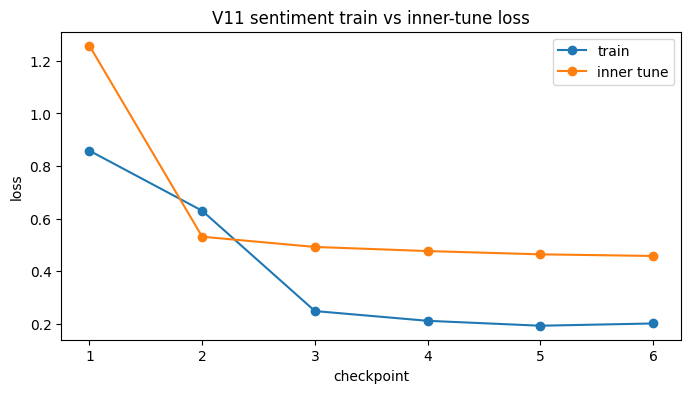

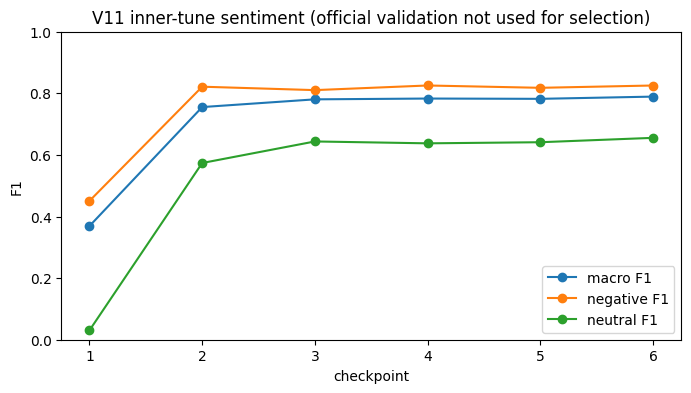

              precision    recall  f1-score   support

    positive     0.9057    0.9555    0.9299      7596
    negative     0.8195    0.8010    0.8101      2392
     neutral     0.7072    0.4742    0.5677      1105

    accuracy                         0.8742     11093
   macro avg     0.8108    0.7436    0.7693     11093
weighted avg     0.8673    0.8742    0.8680     11093



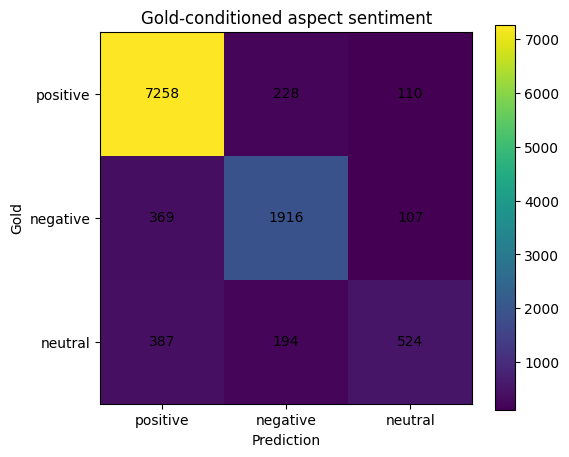

Macro F1: 0.7692595625864233 | Accuracy: 0.874245019381592 | {'positive': 0.9299167200512491, 'negative': 0.8101479915433404, 'neutral': 0.5677139761646804}


In [ ]:
if len(sentiment_history):
    x=np.arange(1,len(sentiment_history)+1)
    plt.figure(figsize=(8,4))
    plt.plot(x,sentiment_history.train_loss,marker="o",label="train")
    plt.plot(x,sentiment_history.val_loss,marker="o",label="inner tune")
    plt.xlabel("checkpoint"); plt.ylabel("loss"); plt.title("V11 sentiment train vs inner-tune loss"); plt.legend(); plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(x,sentiment_history.val_macro_f1,marker="o",label="macro F1")
    plt.plot(x,sentiment_history.val_negative_f1,marker="o",label="negative F1")
    plt.plot(x,sentiment_history.val_neutral_f1,marker="o",label="neutral F1")
    plt.ylim(0,1); plt.xlabel("checkpoint"); plt.ylabel("F1"); plt.title("V11 inner-tune sentiment (official validation not used for selection)"); plt.legend(); plt.show()

SENT_TEST=eval_sentiment(sentiment_model,test_sent) if sentiment_model is not None and test_sent else None
if SENT_TEST:
    y_true=[ID2SENT[i] for i in SENT_TEST["y_true"]]
    y_pred=[ID2SENT[i] for i in SENT_TEST["y_pred"]]
    print(classification_report(y_true,y_pred,labels=CONFIG["sentiment_labels"],digits=4,zero_division=0))

    cm=confusion_matrix(y_true,y_pred,labels=CONFIG["sentiment_labels"])
    plt.figure(figsize=(6,5)); plt.imshow(cm)
    plt.xticks(range(3),CONFIG["sentiment_labels"]); plt.yticks(range(3),CONFIG["sentiment_labels"])
    for i in range(3):
        for j in range(3):
            plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.xlabel("Prediction"); plt.ylabel("Gold"); plt.title("Gold-conditioned aspect sentiment"); plt.colorbar(); plt.show()

    print("Macro F1:",SENT_TEST["macro_f1"],"| Accuracy:",SENT_TEST["accuracy"],"|",SENT_TEST["per_class_f1"])


### 12.2 Melakukan Kalibrasi Suhu


In [ ]:
TEMPERATURE=1.0

def fit_temperature(logits_np,labels):
    if logits_np is None or len(logits_np)==0:
        return 1.0
    logits=torch.tensor(logits_np,dtype=torch.float32,device=DEVICE)
    y=torch.tensor(labels,dtype=torch.long,device=DEVICE)
    log_t=torch.zeros(1,requires_grad=True,device=DEVICE)
    opt=torch.optim.LBFGS([log_t],lr=.05,max_iter=50)
    loss_fn=nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad()
        t=torch.exp(log_t).clamp(.05,20)
        loss=loss_fn(logits/t,y)
        loss.backward()
        return loss
    opt.step(closure)
    return float(torch.exp(log_t).clamp(.05,20).detach().cpu())

if sentiment_model is not None and V14_CAL_SENT:
    v=eval_sentiment(sentiment_model,V14_CAL_SENT)
    TEMPERATURE=fit_temperature(v["logits"],v["y_true"])
print("Temperature:",TEMPERATURE)


# ============================================================
# V9 CALIBRATION / CONFIDENCE METRICS
# ============================================================
def expected_calibration_error(logits_np,labels,temperature=1.0,n_bins=None):
    n_bins=int(n_bins or CONFIG["ece_bins"])
    logits=torch.tensor(logits_np,dtype=torch.float32)
    probs=torch.softmax(logits/float(temperature),dim=-1).numpy()
    conf=probs.max(axis=1); pred=probs.argmax(axis=1)
    labels=np.asarray(labels)
    bins=np.linspace(0,1,n_bins+1)
    ece=0.0
    for lo,hi in zip(bins[:-1],bins[1:]):
        mask=(conf>lo)&(conf<=hi)
        if not mask.any(): continue
        acc=(pred[mask]==labels[mask]).mean()
        ece += mask.mean()*abs(acc-conf[mask].mean())
    return float(ece)

def multiclass_brier(logits_np,labels,temperature=1.0):
    logits=torch.tensor(logits_np,dtype=torch.float32)
    p=torch.softmax(logits/float(temperature),dim=-1).numpy()
    y=np.eye(3,dtype=np.float32)[np.asarray(labels,dtype=int)]
    return float(np.mean(np.sum((p-y)**2,axis=1)))

if SENT_TEST:
    V11_CALIBRATION={
        "ece":expected_calibration_error(SENT_TEST["logits"],SENT_TEST["y_true"],TEMPERATURE),
        "brier":multiclass_brier(SENT_TEST["logits"],SENT_TEST["y_true"],TEMPERATURE),
        "temperature":TEMPERATURE,
    }
    V10_CALIBRATION=V11_CALIBRATION
    V9_CALIBRATION=V11_CALIBRATION  # compatibility aliases
    print("V11 calibration:",V11_CALIBRATION)


# ============================================================
# V12 VALIDATION-ONLY SELECTIVE CONFIDENCE THRESHOLD
# ============================================================
V12_SENTIMENT_CONFIDENCE_THRESHOLD = 0.80
V12_CONFIDENCE_THRESHOLD_STATUS = "FALLBACK_0.80_TARGET_NOT_MET"
V12_CONFIDENCE_THRESHOLD_TABLE = pd.DataFrame()
if sentiment_model is not None and V14_CAL_SENT:
    _val_cal = eval_sentiment(sentiment_model, V14_CAL_SENT)
    _val_probs = torch.softmax(
        torch.tensor(_val_cal["logits"], dtype=torch.float32) / float(TEMPERATURE), dim=-1
    ).numpy()
    _val_conf = _val_probs.max(axis=1)
    _val_pred = _val_probs.argmax(axis=1)
    _val_true = np.asarray(_val_cal["y_true"], dtype=int)
    _threshold_rows = []
    for _threshold in np.arange(0.50, 0.991, 0.01):
        _accepted = _val_conf >= _threshold
        _coverage = float(_accepted.mean()) if len(_accepted) else 0.0
        _precision = float((_val_pred[_accepted] == _val_true[_accepted]).mean()) if _accepted.any() else np.nan
        _threshold_rows.append({
            "threshold": float(_threshold), "accepted_precision": _precision,
            "coverage": _coverage, "accepted": int(_accepted.sum()),
        })
    V12_CONFIDENCE_THRESHOLD_TABLE = pd.DataFrame(_threshold_rows)
    _eligible = V12_CONFIDENCE_THRESHOLD_TABLE[
        (V12_CONFIDENCE_THRESHOLD_TABLE["accepted_precision"] >= 0.85)
        & (V12_CONFIDENCE_THRESHOLD_TABLE["coverage"] >= CONFIG["production_min_confidence_coverage"])
    ]
    if len(_eligible):
        V12_SENTIMENT_CONFIDENCE_THRESHOLD = float(_eligible.iloc[0]["threshold"])
        V12_CONFIDENCE_THRESHOLD_STATUS = "TARGET_MET_ON_VALIDATION"
    V12_CONFIDENCE_THRESHOLD_TABLE.to_csv(
        BASE_DIR / "reports" / "confidence_threshold_validation_v12.csv", index=False
    )
print({
    "sentiment_confidence_threshold": V12_SENTIMENT_CONFIDENCE_THRESHOLD,
    "selection_status": V12_CONFIDENCE_THRESHOLD_STATUS,
    "selection_scope": "train_derived_calibration_only",
})


Temperature: 0.7612389326095581
V11 calibration: {'ece': 0.0167891942330674, 'brier': 0.1897772252559662, 'temperature': 0.7612389326095581}
{'sentiment_confidence_threshold': 0.5, 'selection_status': 'TARGET_MET_ON_VALIDATION', 'selection_scope': 'train_derived_calibration_only'}


## Fase 13 — Menyiapkan Dataset Span


In [ ]:
def v14_masked_bio(offsets,gold,r,kind):
    labels=char_to_bio(offsets,gold)
    is_v14=str(r.get('id')) in V14_RECORD_IDS
    source=str(r.get('source_dataset','')).lower()
    incomplete=(is_v14 and not r.get('annotation_complete',False)) or ('silver' in source and not r.get('annotation_complete',False))
    if incomplete:
        labels=[-100 if x==TAG2ID['O'] else x for x in labels]
    return labels

def unified_gold_spans(r,kind):
    key_s="aspect_start" if kind=="aspect" else "opinion_start"
    key_e="aspect_end" if kind=="aspect" else "opinion_end"
    return [(int(a[key_s]),int(a[key_e])) for a in r.get("annotations",[]) if a.get(key_s) is not None and a.get(key_e) is not None and a.get("supervision_eligible",True) is not False]

def terma_gold_spans(r,kind):
    target="ASP" if kind=="aspect" else "OPN"
    return [(x["start"],x["end"]) for x in r.get("spans",[]) if x["kind"]==target]

def char_to_bio(offsets,spans):
    labels=[-100]*len(offsets)
    for i,(s,e) in enumerate(offsets):
        if e>s: labels[i]=TAG2ID["O"]
    for gs,ge in spans:
        hit=[i for i,(s,e) in enumerate(offsets) if e>s and max(s,gs)<min(e,ge)]
        for j,i in enumerate(hit):
            labels[i]=TAG2ID["B" if j==0 else "I"]
    return labels

class SpanDataset(Dataset):
    def __init__(self,records,kind,source):
        self.items=[]
        for ridx,r in enumerate(records):
            text=str(r["text"])
            gold=unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind)
            if source=="unified" and r.get("rejected_annotation_count",0)>0:
                continue
            enc=tokenizer(
                text,truncation=True,max_length=CONFIG["span_max_length"],
                stride=CONFIG["span_stride"],return_overflowing_tokens=True,
                return_offsets_mapping=True,padding=False
            )
            for wi in range(len(enc["input_ids"])):
                offsets=enc["offset_mapping"][wi]
                _window_labels=v14_masked_bio(offsets,gold,r,kind)
                excluded=[]
                for _ann in r.get("annotations", []):
                    if _ann.get("supervision_eligible", True) is not False and float(_ann.get("effective_sample_weight", _ann.get("sample_weight", 1.0))) > 0:
                        continue
                    _s, _e = _ann.get(f"{kind}_start"), _ann.get(f"{kind}_end")
                    if _s is not None and _e is not None:
                        excluded.append((int(_s), int(_e)))
                for _i, (_s, _e) in enumerate(offsets):
                    if _e > _s and any(max(_s, x0) < min(_e, x1) for x0, x1 in excluded):
                        _window_labels[_i] = -100
                if not any(label!=-100 for label in _window_labels):continue
                self.items.append({
                    "input_ids":enc["input_ids"][wi],"attention_mask":enc["attention_mask"][wi],
                    "labels":_window_labels,"offset_mapping":offsets,
                    "record_index":ridx,"text":text,
                    "sample_weight":float(r.get("sample_weight",1.0)),
                    "language":r.get("language","id"),"domain":r.get("domain","unknown"),
                    "length_bucket":"long" if len(text.split())>=100 else ("medium" if len(text.split())>=30 else "short"),
                    "quality_tier":r.get("confidence_band") or r.get("annotation_status","unknown"),
                    "sentiment_bucket":"+".join(sorted({str(a.get("sentiment") or "none") for a in r.get("annotations",[])
                        if a.get("supervision_eligible",True) is not False})) or "none"
                })
    def __len__(self): return len(self.items)
    def __getitem__(self,idx): return self.items[idx]

def span_collate(batch):
    maxlen=max(len(x["input_ids"]) for x in batch)
    ids=[]; masks=[]; labels=[]
    extra={"offset_mapping":[],"record_index":[],"text":[],"sample_weights":[]}
    for x in batch:
        pad=maxlen-len(x["input_ids"])
        ids.append(x["input_ids"]+[tokenizer.pad_token_id]*pad)
        masks.append(x["attention_mask"]+[0]*pad)
        labels.append(x["labels"]+[-100]*pad)
        extra["offset_mapping"].append(x["offset_mapping"])
        extra["record_index"].append(x["record_index"])
        extra["text"].append(x["text"])
        extra["sample_weights"].append(float(x.get("sample_weight",1.0)))
    return {
        "input_ids":torch.tensor(ids),"attention_mask":torch.tensor(masks),"labels":torch.tensor(labels),
        "sample_weights":torch.tensor(extra.pop("sample_weights"),dtype=torch.float32),
        **extra
    }

train_unified=[r for r in records if r.get("split")=="train"]
val_unified=[r for r in records if r.get("split")=="validation"]
test_unified=[r for r in records if r.get("split")=="test"]
train_terma=[r for r in terma_records if r.get("split")=="train"]
val_terma=[r for r in terma_records if r.get("split")=="validation"]
test_terma=[r for r in terma_records if r.get("split")=="test"]
# ============================================================
# V7 SPAN TRAINING MIX
# ============================================================
# Core academic scientific splits remain separate.
train_unified=[r for r in records if r.get("split")=="train"]
val_unified=[r for r in records if r.get("split")=="validation"]
test_unified=[r for r in records if r.get("split")=="test"]
unseen_sight_unified=list(sight_unseen_records)

train_terma=[r for r in terma_records if r.get("split")=="train"]
val_terma=[r for r in terma_records if r.get("split")=="validation"]
test_terma=[r for r in terma_records if r.get("split")=="test"]

def terma_to_unified(r, include_aspect=True, include_opinion=True, split_override=None):
    asp = [x for x in r.get("spans",[]) if x.get("kind")=="ASP"]
    opn = [x for x in r.get("spans",[]) if x.get("kind")=="OPN"]
    anns=[]
    # TermA has no gold aspect-opinion relation. Keep each supervision type independent.
    if include_aspect:
        for x in asp:
            anns.append({
                "aspect_term":r["text"][x["start"]:x["end"]],
                "aspect_start":x["start"],"aspect_end":x["end"],
                "opinion_term":None,"opinion_start":None,"opinion_end":None,
                "sentiment":None,"aspect_category":None,
                "target_type":"explicit","relation_type":None,
            })
    if include_opinion:
        for x in opn:
            anns.append({
                "aspect_term":None,"aspect_start":None,"aspect_end":None,
                "opinion_term":r["text"][x["start"]:x["end"]],
                "opinion_start":x["start"],"opinion_end":x["end"],
                "sentiment":None,"aspect_category":None,
                "target_type":"opinion_only","relation_type":None,
            })
    return {
        "id":"terma_unified__"+r["id"],
        "text":r["text"],
        "domain":r.get("domain","hotel"),
        "source_dataset":"IndoNLU-TermA-Unified",
        "source_record_id":r.get("source_record_id",r["id"]),
        "language":"id","annotation_status":"dataset_release",
        "split":split_override or r.get("split"),
        "annotations":anns,
        "rejected_annotation_count":0,
    }

terma_aspect_train_u=[
    terma_to_unified(r,include_aspect=True,include_opinion=False,split_override="train")
    for r in train_terma if any(x.get("kind")=="ASP" for x in r.get("spans",[]))
]
terma_opinion_train_u=[
    terma_to_unified(r,include_aspect=False,include_opinion=True,split_override="train")
    for r in train_terma if any(x.get("kind")=="OPN" for x in r.get("spans",[]))
]
terma_opinion_val_u=[
    terma_to_unified(r,include_aspect=False,include_opinion=True,split_override="validation")
    for r in val_terma if any(x.get("kind")=="OPN" for x in r.get("spans",[]))
]

aspect_train_records_v7 = train_unified + (
    terma_aspect_train_u if CONFIG["use_terma_aspect_aux"] else []
) + (gmaps_train_records if CONFIG["use_gmaps_gold"] else [])

gmaps_silver_span_aux=[]
if CONFIG.get("use_gmaps_silver_aux",False):
    for _r in gmaps_silver_aux_records:
        _c=deepcopy(_r)
        _c["sample_weight"]=CONFIG["gmaps_silver_aux_loss_weight"]
        gmaps_silver_span_aux.append(_c)
aspect_train_records_v7 = aspect_train_records_v7 + gmaps_silver_span_aux

# GMaps validation may be included in checkpoint selection once available.
aspect_val_records_v7 = val_unified + (
    gmaps_val_records if CONFIG["use_gmaps_gold"] else []
)

opinion_train_records_v7 = terma_opinion_train_u + (
    gmaps_train_records if CONFIG["use_gmaps_gold"] else []
)
opinion_train_records_v7 = opinion_train_records_v7 + gmaps_silver_span_aux
opinion_val_records_v7 = terma_opinion_val_u + (
    gmaps_val_records if CONFIG["use_gmaps_gold"] else []
)

print(
    "V7 aspect records:",
    {"core_train":len(train_unified),
     "terma_aux":len(terma_aspect_train_u),
     "gmaps_gold_train":len(gmaps_train_records),
     "gmaps_silver_aux":len(gmaps_silver_span_aux),
     "train_total":len(aspect_train_records_v7),
     "val_total":len(aspect_val_records_v7)}
)
print(
    "V7 opinion records:",
    {"terma_train":len(terma_opinion_train_u),
     "gmaps_gold_train":len(gmaps_train_records),
     "gmaps_silver_aux":len(gmaps_silver_span_aux),
     "train_total":len(opinion_train_records_v7),
     "val_total":len(opinion_val_records_v7)}
)


V7 aspect records: {'core_train': 19255, 'terma_aux': 2483, 'gmaps_gold_train': 0, 'gmaps_silver_aux': 0, 'train_total': 21738, 'val_total': 4282}
V7 opinion records: {'terma_train': 2803, 'gmaps_gold_train': 0, 'gmaps_silver_aux': 0, 'train_total': 2803, 'val_total': 937}


### 13.1 Menyusun Daftar Training Aspek dan Opini


In [ ]:
# ============================================================
# V11 SPAN AUXILIARY PATCH — EXPLICIT TRAIN SPANS ONLY
# ============================================================
_v10_syn_span = [deepcopy(r) for r in v10_synthetic_train_records] if ABLATION["use_synthetic"] else []
_v11_syn_span = [
    deepcopy(r) for r in v11_synthetic_train_records
    if any(
        a.get("aspect_start") is not None or a.get("opinion_start") is not None
        for a in r.get("annotations", [])
    )
] if ABLATION["use_v11_synthetic"] else []
_v13_syn_span = [
    deepcopy(r) for r in v13_train_aux_records
    if any(a.get("aspect_start") is not None or a.get("opinion_start") is not None for a in r.get("annotations", []))
] if ABLATION.get("use_v13_synthetic", False) else []
for _record in _v13_syn_span:
    _record["sample_weight"] = float(CONFIG["v13_span_weight"])
    for _ann in _record.get("annotations", []):
        _ann["sample_weight"] = float(CONFIG["v13_span_weight"])
if _v10_syn_span or _v11_syn_span or _v13_syn_span:
    aspect_train_records_v7 = aspect_train_records_v7 + _v10_syn_span + _v11_syn_span + _v13_syn_span
    opinion_train_records_v7 = opinion_train_records_v7 + _v10_syn_span + _v11_syn_span + _v13_syn_span
assert all(r.get("split") == "train" for r in _v10_syn_span + _v11_syn_span + _v13_syn_span)
print("V11 aspect train records:", len(aspect_train_records_v7), {
    "v10_synthetic": len(_v10_syn_span),
    "v11_synthetic_templates": len(_v11_syn_span),
    "v13_synthetic_auxiliary": len(_v13_syn_span),
    "gmaps_silver": len(gmaps_silver_span_aux),
})
print("V11 opinion train records:", len(opinion_train_records_v7))


V11 aspect train records: 21738 {'v10_synthetic': 0, 'v11_synthetic_templates': 0, 'v13_synthetic_auxiliary': 0, 'gmaps_silver': 0}
V11 opinion train records: 2803


In [ ]:
_v14_span_records=[r for r in V14_AUDITED_TRAIN_POOL if V14_STAGE!='relation_repair']
# Incomplete annotation: mask unknown O tokens instead of teaching missed mentions as negatives.
_all_aspect_records=aspect_train_records_v7+[r for r in _v14_span_records if 'aspect' in r['tasks']]
_all_opinion_records=opinion_train_records_v7+[r for r in _v14_span_records if 'opinion' in r['tasks']]
_span_official_sources={r['source_dataset'] for r in records+terma_aspect_train_u+terma_opinion_train_u}
def _span_tune_ok(r):return str(r.get('id')) in V14_RECORD_IDS or r.get('source_dataset') in _span_official_sources or is_complete_human(r)
aspect_train_records_v7=[r for r in _all_aspect_records if v14_role(r)=='fit']
opinion_train_records_v7=[r for r in _all_opinion_records if v14_role(r)=='fit']
aspect_val_records_v7=[r for r in _all_aspect_records if v14_role(r)=='inner_tune' and _span_tune_ok(r)]
opinion_val_records_v7=[r for r in _all_opinion_records if v14_role(r)=='inner_tune' and _span_tune_ok(r)]
V14_ASPECT_CAL=[r for r in _all_aspect_records if v14_role(r)=='calibration' and _span_tune_ok(r)]
V14_OPINION_CAL=[r for r in _all_opinion_records if v14_role(r)=='calibration' and _span_tune_ok(r)]
print('V14 span pools:',len(aspect_train_records_v7),len(opinion_train_records_v7))


V14 span pools: 16592 1518


## Fase 14 — Melatih dan Mengevaluasi Model Span


In [ ]:
if not V14_TRAINING_AUTHORIZED:
    raise RuntimeError("Training BIO span diblokir: audit P0/start-training belum mengizinkan run.")

def decode_bio_offsets(offsets,pred_ids,entity_probs):
    out=[]; cur=None
    for i,((s,e),pid) in enumerate(zip(offsets,pred_ids)):
        if e<=s: continue
        tag=ID2TAG[int(pid)]; conf=float(entity_probs[i])
        if tag=="B":
            if cur: out.append(cur)
            cur={"start":s,"end":e,"scores":[conf]}
        elif tag=="I" and cur is not None:
            cur["end"]=e; cur["scores"].append(conf)
        else:
            if cur: out.append(cur); cur=None
    if cur: out.append(cur)
    for x in out:
        x["score"]=float(np.mean(x.pop("scores")))
    return out

def span_iou(a,b):
    inter=max(0,min(a["end"],b["end"])-max(a["start"],b["start"]))
    union=max(a["end"],b["end"])-min(a["start"],b["start"])
    return inter/union if union else 0.0

def nms_spans(spans,iou_threshold=.55):
    ordered=sorted(spans,key=lambda x:(-x.get("score",0),-(x["end"]-x["start"])))
    kept=[]
    for cand in ordered:
        overlap=False
        for k in kept:
            exact=cand["start"]==k["start"] and cand["end"]==k["end"]
            contained=(cand["start"]<=k["start"] and cand["end"]>=k["end"]) or (k["start"]<=cand["start"] and k["end"]>=cand["end"])
            if exact or contained or span_iou(cand,k)>=iou_threshold:
                overlap=True; break
        if not overlap: kept.append(cand)
    return sorted(kept,key=lambda x:(x["start"],x["end"]))

def exact_prf(golds,preds):
    tp=sum(len(g&p) for g,p in zip(golds,preds)); fp=sum(len(p-g) for g,p in zip(golds,preds)); fn=sum(len(g-p) for g,p in zip(golds,preds))
    p=tp/(tp+fp) if tp+fp else 0.; r=tp/(tp+fn) if tp+fn else 0.
    f=2*p*r/(p+r) if p+r else 0.
    return {"precision":p,"recall":r,"f1":f,"tp":tp,"fp":fp,"fn":fn}

@torch.no_grad()
def predict_span_records(model,records,kind,source):
    ds=SpanDataset(records,kind,source)
    loader=DataLoader(ds,batch_size=CONFIG["span_batch_size"],collate_fn=span_collate)
    by_record=defaultdict(list); model.eval()
    for batch in loader:
        offsets=batch.pop("offset_mapping"); ridxs=batch.pop("record_index"); batch.pop("text"); batch.pop("labels"); batch.pop("sample_weights",None)
        inp={k:v.to(DEVICE) for k,v in batch.items()}
        logits=model(**inp).logits
        soft=logits.softmax(-1); pred=soft.argmax(-1); entity=soft[:,:,1:].max(-1).values
        for bi in range(pred.size(0)):
            n=len(offsets[bi])
            spans=decode_bio_offsets(offsets[bi],pred[bi,:n].cpu().tolist(),entity[bi,:n].cpu().tolist())
            by_record[ridxs[bi]].extend(spans)
    return by_record

def eval_span(model,records,kind,source,threshold=0.):
    by=predict_span_records(model,records,kind,source)
    golds=[]; preds=[]
    for i,r in enumerate(records):
        g=set(unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind))
        p={(x["start"],x["end"]) for x in nms_spans([z for z in by.get(i,[]) if z["score"]>=threshold])}
        golds.append(g); preds.append(p)
    return exact_prf(golds,preds)

def tag_weights(ds,max_ratio=1.5,power=.15):
    c=Counter()
    for x in ds.items: c.update(v for v in x["labels"] if v!=-100)
    total=sum(c.values())
    raw=[(total/max(1,c[i]))**power for i in range(3)]
    base=raw[0]
    return torch.tensor([min(max_ratio,x/base) for x in raw],dtype=torch.float32,device=DEVICE)

def train_span(kind,train_records,val_records,source):
    ds=SpanDataset(train_records,kind,source)
    _sampling_fields=("language","sentiment_bucket","domain","length_bucket","quality_tier")
    _sampling_counts={field:Counter(str(item.get(field,"unknown")) for item in ds.items) for field in _sampling_fields}
    _temperature=float(CONFIG.get("sampling_temperature",.35));_max_ratio=float(CONFIG.get("sampling_max_ratio",5.0))
    _exponent=_temperature/len(_sampling_fields)
    _raw_weights=[]
    for _item in ds.items:
        _value=1.0
        for _field in _sampling_fields:
            _value*=(len(ds.items)/max(1,_sampling_counts[_field][str(_item.get(_field,"unknown"))]))**_exponent
        _raw_weights.append(_value)
    _floor=min(_raw_weights) if _raw_weights else 1.0
    _weights=[min(x,_floor*_max_ratio) for x in _raw_weights]
    v14_assert_checkpoint_labels(kind+"_tagger",ID2TAG)
    model=AutoModelForTokenClassification.from_pretrained(v14_task_initialization(kind+'_tagger'),num_labels=3,id2label=ID2TAG,label2id=TAG2ID)
    model.resize_token_embeddings(len(tokenizer)); model=enable_memory_safe_training(model); model.to(DEVICE)
    loss_fn=nn.CrossEntropyLoss(weight=tag_weights(ds),ignore_index=-100,reduction="none")
    opt=torch.optim.AdamW(model.parameters(),lr=CONFIG["span_lr"],weight_decay=.01)
    best_state=None; best=-1.; bad=0; hist=[]
    if V13_CHECKPOINT_ROOT and (Path(V13_CHECKPOINT_ROOT)/(kind+'_tagger')).is_dir():
        best=eval_span(model,val_records,kind,source)['f1']
        best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    for epoch in range(1,CONFIG["span_epochs"]+1):
        _generator=torch.Generator();_generator.manual_seed(int(SEED)*1000+epoch)
        _sampler=WeightedRandomSampler(_weights,num_samples=len(_weights),replacement=True,generator=_generator) if _weights else None
        _draws=list(iter(_sampler)) if _sampler is not None else list(range(len(ds)))
        loader=DataLoader(ds,batch_size=CONFIG["span_batch_size"],sampler=_draws,shuffle=False,collate_fn=span_collate)
        _sampled_exposure={field:dict(Counter(str(ds.items[i].get(field,"unknown")) for i in _draws)) for field in _sampling_fields}
        _natural_exposure={field:dict(_sampling_counts[field]) for field in _sampling_fields}
        model.train(); losses=[]
        for batch in tqdm(loader,desc=f"{kind} {epoch}/{CONFIG['span_epochs']}"):
            batch.pop("offset_mapping"); batch.pop("record_index"); batch.pop("text")
            sample_weights=batch.pop("sample_weights").to(DEVICE)
            labels=batch.pop("labels").to(DEVICE)
            inp={k:v.to(DEVICE) for k,v in batch.items()}
            opt.zero_grad(set_to_none=True)
            logits=model(**inp).logits
            tok_loss=loss_fn(logits.view(-1,3),labels.view(-1)).view(labels.shape)
            valid=(labels!=-100).float()
            seq_loss=(tok_loss*valid).sum(1)/valid.sum(1).clamp_min(1.0)
            loss=(seq_loss*sample_weights).sum()/sample_weights.sum().clamp_min(1e-8)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            losses.append(float(loss.item()))
        val=eval_span(model,val_records,kind,source)
        row={"epoch":epoch,"train_loss":np.mean(losses),"val_f1":val["f1"],"val_precision":val["precision"],"val_recall":val["recall"],
             "sampling_exposure":{"dimensions":list(_sampling_fields),"natural":_natural_exposure,"sampled":_sampled_exposure,
                                  "temperature":_temperature,"max_ratio":_max_ratio},"loss_sample_weight_independent":True}
        print(row); hist.append(row)
        if val["f1"]>best:
            best=val["f1"]; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=CONFIG["span_patience"]: break
    if best_state is not None: model.load_state_dict(best_state)
    return model,pd.DataFrame(hist)

RUN_SPAN_TRAINING=True
aspect_model=opinion_model=None
aspect_history=opinion_history=pd.DataFrame()
ASPECT_TEST_METRICS=None
OPINION_TEST_METRICS=None

if RUN_SPAN_TRAINING and train_unified and val_unified:
    aspect_model,aspect_history=train_span("aspect",aspect_train_records_v7,aspect_val_records_v7,"unified")
    aspect_model.save_pretrained(MODEL_DIR/"aspect_tagger")

if RUN_SPAN_TRAINING and opinion_train_records_v7 and opinion_val_records_v7:
    opinion_model,opinion_history=train_span("opinion",opinion_train_records_v7,opinion_val_records_v7,"unified")
    opinion_model.save_pretrained(MODEL_DIR/"opinion_tagger")# V6 explicit held-out span metrics.
if aspect_model is not None and test_unified:
    ASPECT_TEST_METRICS=eval_span(aspect_model,test_unified,"aspect","unified")
    print("Aspect held-out exact:",ASPECT_TEST_METRICS)

if opinion_model is not None and test_terma:
    OPINION_TEST_METRICS=eval_span(opinion_model,test_terma,"opinion","terma")
    print("Opinion held-out exact:",OPINION_TEST_METRICS)


Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at /content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


aspect 1/5:   0%|          | 0/4129 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': np.float64(0.21443547097295948), 'val_f1': 0.6560587515299878, 'val_precision': 0.7050570008769366, 'val_recall': 0.6134282807731435}


aspect 2/5:   0%|          | 0/4129 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': np.float64(0.15064377492702902), 'val_f1': 0.6741573033707865, 'val_precision': 0.7206946454413893, 'val_recall': 0.633265513733469}


...

{'epoch': 1, 'train_loss': np.float64(0.20269380057549202), 'val_f1': 0.5648204503956178, 'val_precision': 0.5411078717201167, 'val_recall': 0.5907065563335455}


opinion 2/5:   0%|          | 0/380 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': np.float64(0.09412752111491404), 'val_f1': 0.5850032320620557, 'val_precision': 0.5942219304005253, 'val_recall': 0.5760661998726926}


opinion 3/5:   0%|          | 0/380 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': np.float64(0.07077432090146957), 'val_f1': 0.58343949044586, 'val_precision': 0.5838113448056087, 'val_recall': 0.5830681094844048}
Aspect held-out exact: {'precision': 0.6736625983802897, 'recall': 0.7123386804969244, 'f1': 0.6924610153593622, 'tp': 5906, 'fp': 2861, 'fn': 2385}
Opinion held-out exact: {'precision': 0.891286307053942, 'recall': 0.9002514668901928, 'f1': 0.8957464553794829, 'tp': 2148, 'fp': 262, 'fn': 238}


### 14.1 Menentukan Profil Operasi


In [ ]:
def tune_threshold(model,records,kind,source,beta=1.,precision_floor=0.):
    by=predict_span_records(model,records,kind,source)
    rows=[]
    for thr in np.round(np.arange(.10,.91,.05),2):
        golds=[]; preds=[]
        for i,r in enumerate(records):
            g=set(unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind))
            p={(x["start"],x["end"]) for x in nms_spans([z for z in by.get(i,[]) if z["score"]>=thr])}
            golds.append(g); preds.append(p)
        m=exact_prf(golds,preds)
        b2=beta*beta
        fb=(1+b2)*m["precision"]*m["recall"]/(b2*m["precision"]+m["recall"]) if m["precision"]+m["recall"] else 0.
        rows.append({"threshold":thr,**m,"fbeta":fb})
    df=pd.DataFrame(rows)
    eligible=df[df.precision>=precision_floor]
    if eligible.empty: eligible=df
    best=eligible.sort_values(["fbeta","f1","precision"],ascending=False).iloc[0]
    return float(best.threshold),df

INFERENCE_PROFILES={
    "scientific_balanced":{"aspect_threshold":.5,"opinion_threshold":.5},
    "production_precision":{"aspect_threshold":.6,"opinion_threshold":.65},
    "maps_high_recall":{"aspect_threshold":.35,"opinion_threshold":.35},
}

if aspect_model is not None and V14_ASPECT_CAL:
    INFERENCE_PROFILES["scientific_balanced"]["aspect_threshold"],_=tune_threshold(aspect_model,V14_ASPECT_CAL,"aspect","unified",1.,0.)
    INFERENCE_PROFILES["production_precision"]["aspect_threshold"],_=tune_threshold(aspect_model,V14_ASPECT_CAL,"aspect","unified",.5,.70)
    _maps_aspect_val = V14_HUMAN_CAL if V14_HUMAN_CAL else V14_ASPECT_CAL
    INFERENCE_PROFILES["maps_high_recall"]["aspect_threshold"],_=tune_threshold(
        aspect_model,_maps_aspect_val,"aspect","unified",2.,.50
    )

if opinion_model is not None and V14_OPINION_CAL:
    INFERENCE_PROFILES["scientific_balanced"]["opinion_threshold"],_=tune_threshold(opinion_model,V14_OPINION_CAL,"opinion","unified",1.,0.)
    INFERENCE_PROFILES["production_precision"]["opinion_threshold"],_=tune_threshold(opinion_model,V14_OPINION_CAL,"opinion","unified",.5,.85)
    if V14_HUMAN_CAL:
        INFERENCE_PROFILES["maps_high_recall"]["opinion_threshold"],_=tune_threshold(
            opinion_model,V14_HUMAN_CAL,"opinion","unified",2.,.70
        )
    else:
        INFERENCE_PROFILES["maps_high_recall"]["opinion_threshold"],_=tune_threshold(
            opinion_model,V14_OPINION_CAL,"opinion","unified",2.,.70
        )

print(json.dumps(INFERENCE_PROFILES,indent=2))


{
  "scientific_balanced": {
    "aspect_threshold": 0.7,
    "opinion_threshold": 0.55
  },
  "production_precision": {
    "aspect_threshold": 0.9,
    "opinion_threshold": 0.9
  },
  "maps_high_recall": {
    "aspect_threshold": 0.1,
    "opinion_threshold": 0.55
  }
}


## Fase 15 — Menjalankan Inferensi Sliding-Window


In [ ]:
@torch.no_grad()
def infer_spans_single(text,model,threshold):
    if model is None: return []
    enc=tokenizer(
        str(text),truncation=True,max_length=CONFIG["span_max_length"],stride=CONFIG["span_stride"],
        return_overflowing_tokens=True,return_offsets_mapping=True,padding=False
    )
    all_spans=[]; model.eval()
    for wi in range(len(enc["input_ids"])):
        ids=torch.tensor([enc["input_ids"][wi]],device=DEVICE)
        mask=torch.tensor([enc["attention_mask"][wi]],device=DEVICE)
        offsets=enc["offset_mapping"][wi]
        logits=model(input_ids=ids,attention_mask=mask).logits[0]
        soft=logits.softmax(-1); pred=soft.argmax(-1).cpu().tolist(); entity=soft[:,1:].max(-1).values.cpu().tolist()
        all_spans.extend([x for x in decode_bio_offsets(offsets,pred[:len(offsets)],entity[:len(offsets)]) if x["score"]>=threshold])
    return nms_spans(all_spans)

def infer_spans(text,model,threshold,dual_view=False):
    raw=str(text)
    out=infer_spans_single(raw,model,threshold)
    for x in out: x["source_view"]="raw"

    if not dual_view or not CONFIG["enable_reversible_normalization"]:
        return nms_spans(out)

    al=normalize_gmaps_text_with_alignment(raw)
    norm=infer_spans_single(al["normalized_text"],model,threshold)
    mapped=[]
    for x in norm:
        p=normalized_span_to_raw(x["start"],x["end"],al)
        if p is None: continue
        mapped.append({"start":p[0],"end":p[1],"score":x["score"],"source_view":"normalized"})
    return nms_spans(out+mapped)


### 15.1 Mempelajari Relasi Aspek-Opini


In [ ]:
# Relation repair has already run before downstream sentiment/span training.
print("V14 relation status:",V14_RELATION_TRAIN_AUDIT["status"])


V14 relation status: stopped_collapsed_checkpoint


### 15.2 Mengevaluasi Model Relasi


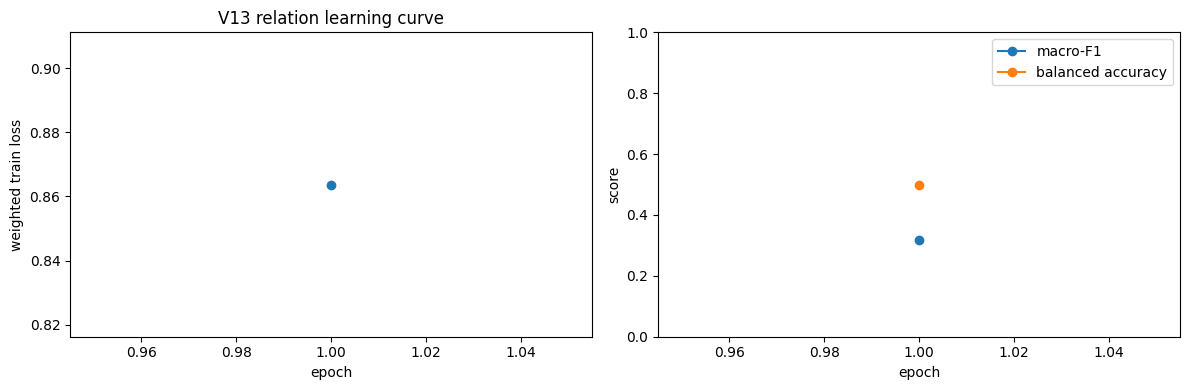

✅ V13 relation diagnostics completed


In [ ]:
relation_history=relation_history.rename(columns={"macro_f1":"relation_macro_f1","f1":"relation_f1"})
# ============================================================
# V13 RELATION DIAGNOSTICS
# Auxiliary tune only — diagnostic, not production GOLD
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Confusion matrix helper
# ------------------------------------------------------------

def _plot_confusion(
    y_true,
    y_pred,
    labels,
    title,
    save_path
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(title)

    fig.tight_layout()

    fig.savefig(
        save_path,
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)



# ------------------------------------------------------------
# Relation auxiliary tune confusion matrix
# ------------------------------------------------------------

if RELATION_AUX_TUNE_METRICS:

    _relation_labels = RELATION_AUX_TUNE_METRICS["labels"]
    _relation_predictions = RELATION_AUX_TUNE_METRICS["predictions"]


    _relation_labels_text = [
        "not_related" if x == 0 else "related"
        for x in _relation_labels
    ]


    _relation_predictions_text = [
        "not_related" if x == 0 else "related"
        for x in _relation_predictions
    ]


    _plot_confusion(
        _relation_labels_text,
        _relation_predictions_text,
        [
            "not_related",
            "related"
        ],
        "V13 Relation — auxiliary tune",
        BASE_DIR / "outputs" / "confusion_matrix_relation_v13_aux_tune.png"
    )



# ------------------------------------------------------------
# Relation learning curve
# ------------------------------------------------------------

if len(relation_history):

    _fig, _axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )


    # Loss curve
    _axes[0].plot(
        relation_history["epoch"],
        relation_history["train_loss"],
        marker="o"
    )

    _axes[0].set(
        title="V13 relation learning curve",
        xlabel="epoch",
        ylabel="weighted train loss"
    )


    # Metric curve
    _axes[1].plot(
        relation_history["epoch"],
        relation_history["relation_macro_f1"],
        marker="o",
        label="macro-F1"
    )


    _axes[1].plot(
        relation_history["epoch"],
        relation_history["balanced_accuracy"],
        marker="o",
        label="balanced accuracy"
    )


    _axes[1].set(
        xlabel="epoch",
        ylabel="score",
        ylim=(0, 1)
    )


    _axes[1].legend()


    _fig.tight_layout()


    _fig.savefig(
        BASE_DIR / "outputs" / "learning_curve_relation_v13.png",
        dpi=160,
        bbox_inches="tight"
    )


    plt.show()

    plt.close(_fig)



print("✅ V13 relation diagnostics completed")

## Fase 16 — Melatih Taksonomi Aspek


In [ ]:
# ============================================================
# V14 FIX — TAXONOMY USES SHARED SPAN-SAFE RECORDS
# ============================================================

V14_TAXONOMY_ADDITIONAL_SPAN_REPAIRS = []
V14_TAXONOMY_ADDITIONAL_QUARANTINE = []


if V14_STAGE != "relation_repair":
    # Semua record yang seharusnya digunakan taxonomy.
    _v14_taxonomy_raw_records = [
        record
        for record in V14_AUDITED_TRAIN_POOL
        if "taxonomy" in record.get("tasks", [])
    ]

    # Record yang sebelumnya sudah diperbaiki pada sentiment
    # menjadi sumber utama. Raw text tidak berubah.
    _shared_safe_records = globals().get(
        "V14_SENTIMENT_SAFE_RECORDS",
        [],
    )

    _shared_safe_by_id = {
        str(record["id"]): record
        for record in _shared_safe_records
    }

    _v14_taxonomy_safe_records = []
    _taxonomy_missing_from_shared_preflight = []

    for _record in _v14_taxonomy_raw_records:
        _record_id = str(_record.get("id", ""))

        if _record_id in _shared_safe_by_id:
            _v14_taxonomy_safe_records.append(
                deepcopy(
                    _shared_safe_by_id[_record_id]
                )
            )
        else:
            _taxonomy_missing_from_shared_preflight.append(
                _record
            )

    # Taxonomy-only records yang tidak melewati sentiment
    # preflight diproses memakai preflight yang sama.
    if _taxonomy_missing_from_shared_preflight:
        if "_sentiment_record_preflight" not in globals():
            raise RuntimeError(
                "_sentiment_record_preflight tidak tersedia. "
                "Jalankan cell sentiment span fix sebelum "
                "cell taxonomy."
            )

        (
            _taxonomy_extra_safe,
            V14_TAXONOMY_ADDITIONAL_SPAN_REPAIRS,
            V14_TAXONOMY_ADDITIONAL_QUARANTINE,
        ) = _sentiment_record_preflight(
            _taxonomy_missing_from_shared_preflight
        )

        _v14_taxonomy_safe_records.extend(
            _taxonomy_extra_safe
        )

    # Deduplicate berdasarkan canonical record ID.
    _v14_taxonomy_safe_records = list({
        str(record["id"]): record
        for record in _v14_taxonomy_safe_records
    }.values())

    # Pemeriksaan terakhir sebelum mark_pair().
    _remaining_taxonomy_overlap = []

    for _record in _v14_taxonomy_safe_records:
        _text = str(_record.get("text", ""))

        for _annotation_index, _annotation in enumerate(
            _record.get("annotations", [])
        ):
            _a_s = _annotation.get("aspect_start")
            _a_e = _annotation.get("aspect_end")
            _o_s = _annotation.get("opinion_start")
            _o_e = _annotation.get("opinion_end")

            if (
                _a_s is None
                or _a_e is None
                or _o_s is None
                or _o_e is None
            ):
                continue

            _a_s = int(_a_s)
            _a_e = int(_a_e)
            _o_s = int(_o_s)
            _o_e = int(_o_e)

            if max(_a_s, _o_s) < min(_a_e, _o_e):
                _remaining_taxonomy_overlap.append({
                    "record_id": str(
                        _record.get("id", "")
                    ),
                    "annotation_index":
                        _annotation_index,
                    "role": v14_role(_record),
                    "source_dataset":
                        _record.get("source_dataset"),
                    "spans": [
                        _a_s,
                        _a_e,
                        _o_s,
                        _o_e,
                    ],
                    "aspect_term":
                        _text[_a_s:_a_e],
                    "opinion_term":
                        _text[_o_s:_o_e],
                    "text_preview": _text[:300],
                })

    if _remaining_taxonomy_overlap:
        raise ContractError(
            "Taxonomy span preflight masih menemukan "
            "aspect/opinion overlap. Detail: "
            + json.dumps(
                _remaining_taxonomy_overlap[:20],
                ensure_ascii=False,
            )
        )

    # Seluruh record sekarang telah melewati shared preflight.
    _v14_tax = _build_tax_examples(
        _v14_taxonomy_safe_records,
        {"train"},
    )

else:
    _v14_taxonomy_raw_records = []
    _v14_taxonomy_safe_records = []
    _v14_tax = []


# ============================================================
# Gabungkan taxonomy lama + V14
# ============================================================
_all_tax = (
    list(TAX_TRAIN)
    + list(_v14_tax)
)

TAX_TRAIN = [
    example
    for example in _all_tax
    if v14_role(example) == "fit"
]

TAX_VAL = [
    example
    for example in _all_tax
    if (
        v14_role(example) == "inner_tune"
        and v14_tune_eligible(example)
    )
]


# ============================================================
# Simpan audit tambahan taxonomy
# ============================================================
_taxonomy_span_report_dir = (
    Path(BASE_DIR) / "reports"
)

_taxonomy_span_report_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for _report_name, _report_rows in (
    (
        "v14_taxonomy_additional_span_repairs",
        V14_TAXONOMY_ADDITIONAL_SPAN_REPAIRS,
    ),
    (
        "v14_taxonomy_additional_quarantine",
        V14_TAXONOMY_ADDITIONAL_QUARANTINE,
    ),
):
    (
        _taxonomy_span_report_dir
        / f"{_report_name}.json"
    ).write_text(
        json.dumps(
            _report_rows,
            ensure_ascii=False,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )

    pd.DataFrame(_report_rows).to_csv(
        _taxonomy_span_report_dir
        / f"{_report_name}.csv",
        index=False,
    )


print({
    "taxonomy raw records":
        len(_v14_taxonomy_raw_records),
    "taxonomy span-safe records":
        len(_v14_taxonomy_safe_records),
    "taxonomy examples":
        len(_v14_tax),
    "additional repairs":
        len(V14_TAXONOMY_ADDITIONAL_SPAN_REPAIRS),
    "additional quarantined":
        len(V14_TAXONOMY_ADDITIONAL_QUARANTINE),
    "final taxonomy fit":
        len(TAX_TRAIN),
    "final taxonomy inner_tune":
        len(TAX_VAL),
})

{'taxonomy raw records': 565, 'taxonomy span-safe records': 565, 'taxonomy examples': 1164, 'additional repairs': 0, 'additional quarantined': 0, 'final taxonomy fit': 11999, 'final taxonomy inner_tune': 2663}


## Fase 17 — Menyusun Pipeline ABSA


In [ ]:
@torch.no_grad()
def predict_sentiment_for_aspect(text,start,end):
    marked,target=mark_aspect(text,start,end)
    enc=tokenizer(
        marked,text_pair=target,truncation=True,max_length=CONFIG["sentiment_max_length"],return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1); pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_aspect_marked_local_context"
    }

# ============================================================
# TAXONOMY RULES V2.1 — GENERIC GOOGLE MAPS / MULTI-INDUSTRY
# ============================================================
# Format:
# taxonomy_id -> domain, label, keywords, optional sentiment cues.
#
# Tujuan:
# - mapping aspect surface -> normalized business category
# - tetap heuristic/transparan
# - tidak mengubah scientific gold labels
# - bisa dikembangkan ke classifier taxonomy terpisah nanti

TAXONOMY_RULES = {

    # ========================================================
    # 1. GENERIC EXPERIENCE
    # ========================================================
    "generic.overall_experience": {
        "domain":"generic",
        "label":"Overall Experience",
        "keywords":[
            "overall","pengalaman","experience","kesan","puas","kecewa",
            "worth","sepadan","recommended","direkomendasikan","balik lagi","datang lagi"
        ],
    },
    "generic.service_quality": {
        "domain":"generic",
        "label":"Service Quality",
        "keywords":[
            "pelayanan","layanan","service","petugas","pegawai","staf","staff",
            "helpful","ramah","jutek","responsif","tidak responsif"
        ],
    },
    "generic.service_speed": {
        "domain":"generic",
        "label":"Service Speed",
        "keywords":[
            "cepat","lambat","lama","gercep","satset","waktu layanan","service time",
            "proses cepat","proses lama"
        ],
    },
    "generic.waiting_time": {
        "domain":"generic",
        "label":"Waiting Time",
        "keywords":[
            "antre","antrean","menunggu","nunggu","queue","waiting time",
            "nomor antrean","waktu tunggu"
        ],
    },
    "generic.staff_attitude": {
        "domain":"generic",
        "label":"Staff Attitude",
        "keywords":[
            "ramah","jutek","judes","ketus","sopan","tidak sopan","cuek","membantu",
            "helpful","informatif","responsif"
        ],
    },
    "generic.cleanliness": {
        "domain":"generic",
        "label":"Cleanliness",
        "keywords":[
            "bersih","kotor","jorok","kebersihan","sampah","bau","pesing","berdebu"
        ],
    },
    "generic.comfort": {
        "domain":"generic",
        "label":"Comfort",
        "keywords":[
            "nyaman","tidak nyaman","panas","dingin","adem","sejuk","bising","berisik","tenang"
        ],
    },
    "generic.price_value": {
        "domain":"generic",
        "label":"Price & Value",
        "keywords":[
            "harga","mahal","murah","terjangkau","overpriced","sepadan","worth","value for money",
            "biaya","tarif","fee"
        ],
    },
    "generic.location_access": {
        "domain":"generic",
        "label":"Location & Access",
        "keywords":[
            "lokasi","akses","jalan","strategis","mudah dicari","susah dicari","nyasar","maps"
        ],
    },
    "generic.parking": {
        "domain":"generic",
        "label":"Parking",
        "keywords":[
            "parkir","area parkir","parking","valet","motor","mobil","slot parkir"
        ],
    },
    "generic.facilities": {
        "domain":"generic",
        "label":"Facilities",
        "keywords":[
            "fasilitas","toilet","wifi","musala","mushola","ac","lift","eskalator",
            "ruang tunggu","kursi","charging","stop kontak","cctv"
        ],
    },
    "generic.security": {
        "domain":"generic",
        "label":"Security",
        "keywords":[
            "aman","tidak aman","security","satpam","petugas keamanan","cctv","penjaga"
        ],
    },
    "generic.operating_hours": {
        "domain":"generic",
        "label":"Operating Hours",
        "keywords":[
            "jam buka","jam tutup","jam operasional","buka","tutup","24 jam","opening hours"
        ],
    },
    "generic.digital_service": {
        "domain":"generic",
        "label":"Digital Service",
        "keywords":[
            "aplikasi","website","sistem","online","login","otp","error","down","loading",
            "notifikasi","registrasi online","pendaftaran online"
        ],
    },
    "generic.communication_channel": {
        "domain":"generic",
        "label":"Communication Channel",
        "keywords":[
            "whatsapp","wa","telepon","call center","hotline","chat","email","dm",
            "dibalas","tidak dibalas"
        ],
    },

    # ========================================================
    # 2. F&B / COFFEE SHOP / RESTAURANT
    # ========================================================
    "fnb.food_quality": {
        "domain":"food_beverage",
        "label":"Food Quality",
        "keywords":[
            "makanan","menu","nasi","mie","pasta","roti","croissant","dessert","kue",
            "snack","cemilan","cassava","casava","steak","ayam","burger","pizza"
        ],
    },
    "fnb.beverage_quality": {
        "domain":"food_beverage",
        "label":"Beverage Quality",
        "keywords":[
            "minuman","kopi","americano","latte","espresso","cappuccino","matcha","teh",
            "jus","juice","milkshake","mocktail"
        ],
    },
    "fnb.taste": {
        "domain":"food_beverage",
        "label":"Taste",
        "keywords":[
            "rasa","enak","tidak enak","asin","keasinan","manis","kemanisan","pahit",
            "hambar","gurih","pedas","asam"
        ],
    },
    "fnb.portion": {
        "domain":"food_beverage",
        "label":"Portion",
        "keywords":[
            "porsi","portion","banyak","sedikit","dikit","kecil","besar"
        ],
    },
    "fnb.presentation": {
        "domain":"food_beverage",
        "label":"Food Presentation",
        "keywords":[
            "penyajian","plating","presentasi makanan","tampilan makanan"
        ],
    },
    "fnb.menu_variety": {
        "domain":"food_beverage",
        "label":"Menu Variety",
        "keywords":[
            "variasi menu","pilihan menu","menu lengkap","menu sedikit","banyak pilihan"
        ],
    },
    "fnb.order_accuracy": {
        "domain":"food_beverage",
        "label":"Order Accuracy",
        "keywords":[
            "pesanan salah","order salah","salah pesanan","pesanan sesuai","order sesuai",
            "kurang item","item kurang"
        ],
    },
    "fnb.order_speed": {
        "domain":"food_beverage",
        "label":"Order Speed",
        "keywords":[
            "pesanan lama","makanan lama","minuman lama","keluar lama","nunggu makanan",
            "nunggu minuman","service time"
        ],
    },
    "fnb.cashier": {
        "domain":"food_beverage",
        "label":"Cashier",
        "keywords":["kasir","cashier"],
    },
    "fnb.barista": {
        "domain":"food_beverage",
        "label":"Barista",
        "keywords":["barista"],
    },
    "fnb.waiter": {
        "domain":"food_beverage",
        "label":"Waiter / Server",
        "keywords":["waiter","waitress","pramusaji","pelayan"],
    },
    "fnb.ambience": {
        "domain":"food_beverage",
        "label":"Ambience",
        "keywords":[
            "suasana","ambience","vibes","cozy","nyaman","estetis","instagrammable",
            "outdoor","indoor","pohon","rindang","adem"
        ],
    },
    "fnb.wfc_support": {
        "domain":"food_beverage",
        "label":"Work From Cafe Support",
        "keywords":[
            "wfc","work from cafe","wifi","stop kontak","colokan","meja kerja","laptop"
        ],
    },

    # ========================================================
    # 3. HEALTHCARE
    # ========================================================
    "healthcare.medical_service": {
        "domain":"healthcare",
        "label":"Medical Service",
        "keywords":[
            "dokter","perawat","bidan","tenaga kesehatan","pelayanan medis","pemeriksaan",
            "diagnosis","diagnosa","tindakan"
        ],
    },
    "healthcare.doctor": {
        "domain":"healthcare",
        "label":"Doctor",
        "keywords":["dokter","dr ","dr.","drg","dokter gigi"],
    },
    "healthcare.nurse": {
        "domain":"healthcare",
        "label":"Nurse",
        "keywords":["perawat","suster","nurse"],
    },
    "healthcare.registration": {
        "domain":"healthcare",
        "label":"Registration",
        "keywords":[
            "pendaftaran","registrasi","admisi","daftar online","pendaftaran online"
        ],
    },
    "healthcare.queue": {
        "domain":"healthcare",
        "label":"Healthcare Queue",
        "keywords":[
            "antrean dokter","nomor antrean","nunggu dokter","waktu tunggu dokter"
        ],
    },
    "healthcare.pharmacy": {
        "domain":"healthcare",
        "label":"Pharmacy",
        "keywords":["farmasi","apotek","obat","resep"],
    },
    "healthcare.lab": {
        "domain":"healthcare",
        "label":"Laboratory",
        "keywords":["laboratorium","lab","cek darah","tes darah"],
    },
    "healthcare.radiology": {
        "domain":"healthcare",
        "label":"Radiology",
        "keywords":["rontgen","x-ray","xray","usg","radiologi"],
    },
    "healthcare.emergency": {
        "domain":"healthcare",
        "label":"Emergency / ER",
        "keywords":["igd","ugd","gawat darurat","emergency"],
    },
    "healthcare.bpjs": {
        "domain":"healthcare",
        "label":"BPJS / Insurance Administration",
        "keywords":["bpjs","jkn","kis","rujukan","jaminan","asuransi kesehatan"],
    },
    "healthcare.inpatient": {
        "domain":"healthcare",
        "label":"Inpatient Care",
        "keywords":["rawat inap","ranap","kamar inap"],
    },
    "healthcare.outpatient": {
        "domain":"healthcare",
        "label":"Outpatient Care",
        "keywords":["rawat jalan","rajal","kontrol","poliklinik","poli"],
    },

    # ========================================================
    # 4. GOVERNMENT / PUBLIC SERVICE
    # ========================================================
    "government.counter_service": {
        "domain":"government",
        "label":"Counter Service",
        "keywords":["loket","petugas loket","counter","pelayanan loket"],
    },
    "government.document_process": {
        "domain":"government",
        "label":"Document Processing",
        "keywords":[
            "dokumen","berkas","surat","akta","legalisasi","legalisir","fotokopi"
        ],
    },
    "government.identity_document": {
        "domain":"government",
        "label":"Population Document",
        "keywords":[
            "ktp","e-ktp","kartu tanda penduduk","kartu keluarga","kk","akta kelahiran",
            "dukcapil"
        ],
    },
    "government.licensing": {
        "domain":"government",
        "label":"Licensing",
        "keywords":["izin","perizinan","izin online","mpp","mal pelayanan publik"],
    },
    "government.immigration": {
        "domain":"government",
        "label":"Immigration",
        "keywords":["imigrasi","paspor","passport","visa"],
    },
    "government.vehicle_document": {
        "domain":"government",
        "label":"Vehicle Document Service",
        "keywords":["samsat","sim","stnk","pajak kendaraan"],
    },
    "government.bureaucracy": {
        "domain":"government",
        "label":"Bureaucracy",
        "keywords":["birokrasi","prosedur","alur proses","persyaratan","syarat"],
    },

    # ========================================================
    # 5. BANKING / FINANCIAL SERVICE
    # ========================================================
    "banking.customer_service": {
        "domain":"banking",
        "label":"Customer Service",
        "keywords":["customer service","cs bank","layanan pelanggan"],
    },
    "banking.teller": {
        "domain":"banking",
        "label":"Teller",
        "keywords":["teller"],
    },
    "banking.security": {
        "domain":"banking",
        "label":"Bank Security",
        "keywords":["satpam","security","petugas keamanan"],
    },
    "banking.account_opening": {
        "domain":"banking",
        "label":"Account Opening",
        "keywords":["buka rekening","pembukaan rekening","rekening baru"],
    },
    "banking.atm": {
        "domain":"banking",
        "label":"ATM",
        "keywords":["atm","mesin atm","tarik tunai","setor tunai","atm error","atm kosong"],
    },
    "banking.mobile_banking": {
        "domain":"banking",
        "label":"Mobile Banking",
        "keywords":[
            "mobile banking","mbanking","m-banking","livin","brimo","bca mobile","wondr"
        ],
    },
    "banking.internet_banking": {
        "domain":"banking",
        "label":"Internet Banking",
        "keywords":["internet banking","ibanking","i-banking"],
    },
    "banking.transaction": {
        "domain":"banking",
        "label":"Transaction",
        "keywords":["transfer","transaksi","saldo","pending","gagal transaksi","qris"],
    },
    "banking.credit_loan": {
        "domain":"banking",
        "label":"Credit / Loan",
        "keywords":["kredit","pinjaman","loan","kpr","kartu kredit"],
    },
    "banking.fee": {
        "domain":"banking",
        "label":"Bank Fee",
        "keywords":["biaya admin","biaya administrasi","admin fee","fee"],
    },

    # ========================================================
    # 6. SOCIAL SERVICE
    # ========================================================
    "social.benefit_service": {
        "domain":"social_service",
        "label":"Social Benefit Service",
        "keywords":[
            "bansos","bantuan sosial","blt","bpnt","pkh","sembako","penerima manfaat"
        ],
    },
    "social.data_registration": {
        "domain":"social_service",
        "label":"Social Welfare Data",
        "keywords":["dtks","data sosial","data penerima","verifikasi data"],
    },
    "social.case_worker": {
        "domain":"social_service",
        "label":"Social Worker / Companion",
        "keywords":["pendamping","pendamping sosial","petugas sosial"],
    },
    "social.disability_service": {
        "domain":"social_service",
        "label":"Disability Service",
        "keywords":["disabilitas","difabel","penyandang disabilitas"],
    },
    "social.elderly_service": {
        "domain":"social_service",
        "label":"Elderly Service",
        "keywords":["lansia","panti lansia","panti jompo"],
    },

    # ========================================================
    # 7. HOTEL / HOSPITALITY
    # ========================================================
    "hotel.room": {
        "domain":"hotel",
        "label":"Room",
        "keywords":["kamar","room","kasur","bed","handuk","linen"],
    },
    "hotel.cleanliness": {
        "domain":"hotel",
        "label":"Room Cleanliness",
        "keywords":["kamar bersih","kamar kotor","housekeeping","bau kamar"],
    },
    "hotel.reception": {
        "domain":"hotel",
        "label":"Reception",
        "keywords":["resepsionis","receptionist","reception"],
    },
    "hotel.checkin_checkout": {
        "domain":"hotel",
        "label":"Check-in / Check-out",
        "keywords":["check-in","check-out","checkin","checkout"],
    },
    "hotel.breakfast": {
        "domain":"hotel",
        "label":"Breakfast",
        "keywords":["sarapan","breakfast"],
    },
    "hotel.pool": {
        "domain":"hotel",
        "label":"Swimming Pool",
        "keywords":["kolam renang","pool","swimming pool"],
    },

    # ========================================================
    # 8. RETAIL / MALL
    # ========================================================
    "retail.product_quality": {
        "domain":"retail",
        "label":"Product Quality",
        "keywords":["produk","barang","kualitas produk","kualitas barang"],
    },
    "retail.stock": {
        "domain":"retail",
        "label":"Stock Availability",
        "keywords":["stok","stock","habis","restock","tersedia"],
    },
    "retail.cashier": {
        "domain":"retail",
        "label":"Cashier",
        "keywords":["kasir","cashier"],
    },
    "retail.promotion": {
        "domain":"retail",
        "label":"Promotion / Discount",
        "keywords":["promo","promosi","diskon","discount","voucher"],
    },
    "retail.store_layout": {
        "domain":"retail",
        "label":"Store Layout",
        "keywords":["layout toko","penataan","rak","lorong","aisle"],
    },

    # ========================================================
    # 9. EDUCATION
    # ========================================================
    "education.teacher": {
        "domain":"education",
        "label":"Teacher / Lecturer",
        "keywords":["guru","dosen","pengajar"],
    },
    "education.administration": {
        "domain":"education",
        "label":"Academic Administration",
        "keywords":["tata usaha","tu","admin kampus","administrasi akademik"],
    },
    "education.classroom": {
        "domain":"education",
        "label":"Classroom",
        "keywords":["kelas","ruang kelas","classroom"],
    },
    "education.library": {
        "domain":"education",
        "label":"Library",
        "keywords":["perpustakaan","perpus","library"],
    },
    "education.lab": {
        "domain":"education",
        "label":"Laboratory",
        "keywords":["laboratorium","lab komputer","lab"],
    },
    "education.campus_facility": {
        "domain":"education",
        "label":"Campus Facility",
        "keywords":["kantin","wifi kampus","toilet kampus","parkir kampus"],
    },

    # ========================================================
    # 10. TRANSPORTATION
    # ========================================================
    "transport.station": {
        "domain":"transportation",
        "label":"Station / Terminal",
        "keywords":["stasiun","terminal","halte","station"],
    },
    "transport.ticketing": {
        "domain":"transportation",
        "label":"Ticketing",
        "keywords":["tiket","ticket","loket tiket","mesin tiket"],
    },
    "transport.schedule": {
        "domain":"transportation",
        "label":"Schedule",
        "keywords":["jadwal","schedule","keberangkatan","kedatangan","delay","terlambat"],
    },
    "transport.cleanliness": {
        "domain":"transportation",
        "label":"Transport Cleanliness",
        "keywords":["toilet stasiun","stasiun bersih","terminal kotor"],
    },
    "transport.driver": {
        "domain":"transportation",
        "label":"Driver",
        "keywords":["driver","pengemudi","sopir","supir"],
    },

    # ========================================================
    # 11. AUTOMOTIVE / WORKSHOP
    # ========================================================
    "automotive.mechanic": {
        "domain":"automotive",
        "label":"Mechanic",
        "keywords":["mekanik","mechanic"],
    },
    "automotive.service_quality": {
        "domain":"automotive",
        "label":"Workshop Service",
        "keywords":["servis mobil","servis motor","service mobil","service motor"],
    },
    "automotive.sparepart": {
        "domain":"automotive",
        "label":"Spare Part",
        "keywords":["suku cadang","sparepart","onderdil"],
    },
    "automotive.carwash": {
        "domain":"automotive",
        "label":"Car Wash",
        "keywords":["cuci mobil","car wash","carwash"],
    },

    # ========================================================
    # 12. TOURISM / RECREATION
    # ========================================================
    "tourism.scenery": {
        "domain":"tourism",
        "label":"Scenery",
        "keywords":["pemandangan","view","scenery","sunset","gunung","danau","pantai"],
    },
    "tourism.photo_spot": {
        "domain":"tourism",
        "label":"Photo Spot",
        "keywords":["spot foto","instagrammable","foto","photo"],
    },
    "tourism.family_friendly": {
        "domain":"tourism",
        "label":"Family Friendly",
        "keywords":["ramah keluarga","family friendly","ramah anak","kids friendly"],
    },
    "tourism.ticket_price": {
        "domain":"tourism",
        "label":"Ticket Price",
        "keywords":["harga tiket","tiket masuk","HTM","biaya masuk"],
    },
}

def _taxonomy_text(aspect, context=None):
    return str(aspect or "").lower(), str(context or "").lower()

def taxonomy_mapper(aspect, context=None, domain_hint=None):
    """
    V6 ASPECT-FIRST taxonomy.

    Aspect surface is the primary evidence.
    Context is only supporting/tie-break evidence, preventing:
      parkiran -> Ambience
      harga -> Food Quality
    """
    aspect_text, context_text = _taxonomy_text(aspect,context)
    candidates=[]

    for taxonomy_id,spec in TAXONOMY_RULES.items():
        domain=spec["domain"]
        aspect_matches=[kw for kw in spec["keywords"] if kw.lower() in aspect_text]
        context_matches=[kw for kw in spec["keywords"] if kw.lower() in context_text]

        if not aspect_matches and not context_matches:
            continue

        # Strong aspect weighting. Context cannot normally override direct aspect evidence.
        aspect_score=sum(
            4.0 + min(len(kw.split()),4)*0.35
            for kw in aspect_matches
        )
        context_score=sum(
            0.35 + min(len(kw.split()),4)*0.05
            for kw in context_matches
        )
        domain_bonus=0.80 if domain_hint and domain==domain_hint else 0.0

        total=aspect_score+context_score+domain_bonus

        candidates.append({
            "taxonomy_id":taxonomy_id,
            "domain":domain,
            "label":spec["label"],
            "score":total,
            "aspect_matches":aspect_matches,
            "context_matches":context_matches,
        })

    if not candidates:
        return {
            "taxonomy_id":"generic.other",
            "normalized_category":"other",
            "taxonomy_domain":domain_hint or "generic",
            "taxonomy_confidence":0.0,
            "taxonomy_method":"heuristic_no_match_v6",
            "taxonomy_evidence":[],
        }

    candidates.sort(
        key=lambda x:(
            bool(x["aspect_matches"]),
            x["score"],
            x["domain"]!="generic",
            max([len(k) for k in x["aspect_matches"]+x["context_matches"]] or [0])
        ),
        reverse=True
    )
    best=candidates[0]

    conf=min(
        0.93,
        0.56
        + 0.10*len(best["aspect_matches"])
        + 0.03*len(best["context_matches"])
        + (0.04 if domain_hint==best["domain"] else 0.0)
    )

    evidence=(best["aspect_matches"]+best["context_matches"])[:8]
    return {
        "taxonomy_id":best["taxonomy_id"],
        "normalized_category":best["label"],
        "taxonomy_domain":best["domain"],
        "taxonomy_confidence":round(float(conf),4),
        "taxonomy_method":"heuristic_aspect_first_taxonomy_v6",
        "taxonomy_evidence":evidence,
    }

def split_coordinated_aspect(text, span, domain_hint=None):
    """
    Conservative repair for merged coordination spans.
    Split only when >=2 fragments independently receive meaningful taxonomy.
    """
    s,e=span["start"],span["end"]
    surface=str(text)[s:e]
    parts=list(re.finditer(r"\b(?:dan|sama)\b|&|,",surface,re.I))
    if not parts:
        return [span]

    boundaries=[0]
    for m in parts:
        boundaries.extend([m.start(),m.end()])
    boundaries.append(len(surface))

    fragments=[]
    cursor=0
    for m in parts:
        frag=surface[cursor:m.start()]
        fs=cursor
        cursor=m.end()
        frag_s=fs+len(frag)-len(frag.lstrip(" ,"))
        frag_e=m.start()-len(frag)+len(frag.rstrip(" ,"))
        # easier robust offset from stripped search
        stripped=frag.strip(" ,")
        if stripped:
            rel=surface.find(stripped,fs,m.start())
            fragments.append((rel,rel+len(stripped),stripped))
    tail=surface[cursor:]
    stripped=tail.strip(" ,")
    if stripped:
        rel=surface.find(stripped,cursor)
        fragments.append((rel,rel+len(stripped),stripped))

    valid=[]
    for rs,re_,frag in fragments:
        tax=taxonomy_mapper(frag,"",domain_hint=domain_hint)
        if (
            tax["taxonomy_id"]!="generic.other"
            and tax["taxonomy_confidence"]>=CONFIG["coordination_split_min_taxonomy_conf"]
        ):
            valid.append({
                **span,
                "start":s+rs,
                "end":s+re_,
                "score":float(span.get("score",0))*0.97,
                "coordination_repair":True,
            })

    return valid if len(valid)>=2 else [span]

def opinion_for_aspect(text, aspect_span, opinion_spans):
    """
    Relation remains heuristic, but V6 prevents cross-sentence contamination.
    """
    if not opinion_spans:
        return None

    s,e=aspect_span["start"],aspect_span["end"]
    sent_left,sent_right=_sentence_bounds(str(text),s,e)

    candidates=[]
    for op in opinion_spans:
        if op["start"]<sent_left or op["end"]>sent_right:
            continue
        if op["end"]<=s:
            dist=s-op["end"]
        elif op["start"]>=e:
            dist=op["start"]-e
        else:
            dist=0
        if dist<=CONFIG["opinion_max_char_distance"]:
            candidates.append((dist,-float(op.get("score",0)),op))

    if not candidates:
        return None
    candidates.sort(key=lambda x:(x[0],x[1]))
    return candidates[0][2]

@torch.no_grad()
def predict_sentiment_for_aspect(text,start,end,peer_spans=None):
    marked,target=mark_aspect(text,start,end,peer_spans=peer_spans)
    enc=tokenizer(
        marked,text_pair=target,
        truncation=True,max_length=CONFIG["sentiment_max_length"],
        return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1)
    pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_clause_aware_target_context_v6",
    }

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    cfg=INFERENCE_PROFILES[profile]
    dual=profile=="maps_high_recall" and CONFIG["dual_view_maps_inference"]
    domain_hint=resolve_review_domain(text)

    aspects=infer_spans(
        text,aspect_model,cfg["aspect_threshold"],dual_view=dual
    )

    # Repair merged coordinated aspect spans.
    repaired=[]
    for asp in aspects:
        repaired.extend(split_coordinated_aspect(text,asp,domain_hint=domain_hint))
    aspects=nms_spans(repaired)

    opinions=(
        infer_spans(text,opinion_model,cfg["opinion_threshold"],dual_view=dual)
        if opinion_model is not None else []
    )

    peer_spans=[(x["start"],x["end"]) for x in aspects]
    out=[]

    for asp in aspects:
        s,e=asp["start"],asp["end"]
        aspect_term=str(text)[s:e]

        # Taxonomy aspect-first; full context used only as weak supporting evidence.
        _,_,sent_ctx=local_context(text,s,e,peer_spans=peer_spans)
        tax=taxonomy_for_inference(text,s,e,aspect_term,sent_ctx,domain_hint=domain_hint)

        sent=predict_sentiment_for_aspect(
            text,s,e,peer_spans=peer_spans
        )
        nearest=opinion_for_aspect(text,asp,opinions)

        out.append({
            "aspect_term":aspect_term,
            "aspect_start":s,
            "aspect_end":e,
            "aspect_confidence":float(asp["score"]),
            "aspect_source_view":asp.get("source_view","raw"),
            "coordination_repair":bool(asp.get("coordination_repair",False)),

            "opinion_term":str(text)[nearest["start"]:nearest["end"]] if nearest else None,
            "opinion_start":nearest["start"] if nearest else None,
            "opinion_end":nearest["end"] if nearest else None,
            "relation_method":"heuristic_unvalidated_same_sentence_nearest_v12" if nearest else "not_available",

            **tax,
            **sent,
            "profile":profile,
        })

    return out

# V6 taxonomy sanity checks.
for probe in [
    ("parkiran","parkiran luas, banyak pohon dan outdoor adem","food_beverage"),
    ("harga","harga masih oke walaupun menu pricey","food_beverage"),
    ("kopinya","kopinya enak tapi pasta asin","food_beverage"),
    ("dokternya","dokternya ramah tapi antreannya lama","healthcare"),
]:
    print(probe,"=>",taxonomy_mapper(*probe))


('parkiran', 'parkiran luas, banyak pohon dan outdoor adem', 'food_beverage') => {'taxonomy_id': 'generic.parking', 'normalized_category': 'Parking', 'taxonomy_domain': 'generic', 'taxonomy_confidence': 0.69, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['parkir', 'parkir']}
('harga', 'harga masih oke walaupun menu pricey', 'food_beverage') => {'taxonomy_id': 'generic.price_value', 'normalized_category': 'Price & Value', 'taxonomy_domain': 'generic', 'taxonomy_confidence': 0.69, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['harga', 'harga']}
('kopinya', 'kopinya enak tapi pasta asin', 'food_beverage') => {'taxonomy_id': 'fnb.beverage_quality', 'normalized_category': 'Beverage Quality', 'taxonomy_domain': 'food_beverage', 'taxonomy_confidence': 0.73, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['kopi', 'kopi']}
('dokternya', 'dokternya ramah tapi antreannya lama', 'healthcare') => {'taxo

### 17.1 Memperkuat Inferensi Google Maps


In [ ]:

# ============================================================
# V7 OPERATIONAL GMAPS OVERRIDES
# ============================================================
taxonomy_mapper_v6 = taxonomy_mapper

# Add explicit rules missing in V6.
TAXONOMY_RULES.update({
    "generic.prayer_room":{
        "domain":"generic","label":"Prayer Room / Facilities",
        "keywords":["musholla","mushola","musala","masjid","prayer room"]
    },
    "generic.service_speed":{
        "domain":"generic","label":"Service Speed",
        "keywords":["service speed","kecepatan layanan","waktu pelayanan","pelayanan lama","servis lama"]
    },
    "generic.waiting_time":{
        "domain":"generic","label":"Waiting Time",
        "keywords":["waktu tunggu","nunggu","menunggu","antrean","antrian"]
    },
})

_PRICE_HEAD_RE=re.compile(r"^\s*(harga|biaya|tarif|price)\b",re.I)
_PRAYER_RE=re.compile(r"\b(musholla|mushola|musala|masjid|prayer\s*room)\b",re.I)
_WAIT_RE=re.compile(
    r"\b(lama+|nunggu|menunggu|terlambat|delay|hampir\s+\d+|\d+\s*(?:mnt|menit|jam))\b",
    re.I
)
_SERVICE_ASPECT_RE=re.compile(
    r"\b(service|servis|pelayanan|pesanan|order|minuman|makanan|antrean|antrian)\b",
    re.I
)

def taxonomy_mapper(aspect,context=None,domain_hint=None):
    aspect_text=str(aspect or "")
    context_text=str(context or "")
    low=aspect_text.lower()

    # Head/preference rules must beat weak context keywords.
    if _PRICE_HEAD_RE.search(low):
        return {
            "taxonomy_id":"generic.price_value",
            "normalized_category":"Price & Value",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["price_head"],
        }
    if _PRAYER_RE.search(low):
        return {
            "taxonomy_id":"generic.prayer_room",
            "normalized_category":"Prayer Room / Facilities",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["prayer_room_head"],
        }
    if re.search(r"\bservice\s*speed\b",low,re.I):
        return {
            "taxonomy_id":"generic.service_speed",
            "normalized_category":"Service Speed",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["service_speed_head"],
        }
    if _SERVICE_ASPECT_RE.search(low) and _WAIT_RE.search(context_text):
        return {
            "taxonomy_id":"generic.service_speed",
            "normalized_category":"Service Speed",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.86,
            "taxonomy_method":"heuristic_contextual_speed_v7",
            "taxonomy_evidence":["service_aspect","waiting_evidence"],
        }
    return taxonomy_mapper_v6(aspect,context,domain_hint)

def expand_to_word_boundary(text,span):
    if not CONFIG["maps_word_boundary_repair"]:
        return span
    text=str(text);s=int(span["start"]);e=int(span["end"])
    while s>0 and (text[s-1].isalnum() or text[s-1] in "_-"):
        s-=1
    while e<len(text) and (text[e].isalnum() or text[e] in "_-"):
        e+=1
    if s==span["start"] and e==span["end"]:
        return span
    return {**span,"start":s,"end":e,
            "score":float(span.get("score",0))*0.995,
            "aspect_method":"word_boundary_repair_v7"}

GMAPS_EXPLICIT_CANDIDATE_PATTERNS=[
    # Staff / roles
    r"\b(?:mba|mbak|mas|kak)\s+(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?)\b",
    r"\b(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?|farmasi(?:nya)?)\b",
    # Facilities / service
    r"\b(?:musholla(?:nya)?|mushola(?:nya)?|musala(?:nya)?|toilet(?:nya)?|parkiran(?:\s+mobil)?|ruang\s+tunggu)\b",
    r"\b(?:service\s*speed|servicenya|pelayanannya|antrean(?:nya)?|antrian(?:nya)?)\b",
    # Common F&B product heads; optional modifier captures compound product names.
    r"\b(?:iced?\s+)?americano(?:nya)?\b",
    r"\b(?:cappuccino|cappucino|latte|espresso|matcha)(?:nya)?\b",
    r"\b(?:chicken\s+)?pasta(?:nya)?\b",
]


# V9 neutral/factual heads that V8 missed.
GMAPS_EXPLICIT_CANDIDATE_PATTERNS.extend([
    r"\b(?:harga(?:nya)?|biaya(?:nya)?|tarif(?:nya)?|price)\b",
    r"\b(?:lokasi(?:nya)?|letak(?:nya)?|akses(?:nya)?)\b",
])
def gmaps_candidate_recovery(text):
    if not CONFIG["maps_lexicon_candidate_recovery"]:
        return []
    out=[]
    for pat in GMAPS_EXPLICIT_CANDIDATE_PATTERNS:
        for m in re.finditer(pat,str(text),re.I):
            out.append({
                "start":m.start(),"end":m.end(),
                "score":0.72,
                "source_view":"gmaps_lexicon",
                "aspect_method":"heuristic_candidate_recovery_v7"
            })
    return out

def merge_aspect_candidates_v7(spans):
    # Prefer longer containing spans if their confidence is not much lower.
    ordered=sorted(spans,key=lambda x:(x["start"],x["end"],-x.get("score",0)))
    final=[]
    for cand in sorted(ordered,key=lambda x:(-x.get("score",0),-(x["end"]-x["start"]))):
        replaced=False
        for i,k in enumerate(final):
            contains=(cand["start"]<=k["start"] and cand["end"]>=k["end"])
            kcontains=(k["start"]<=cand["start"] and k["end"]>=cand["end"])
            if contains or kcontains or span_iou(cand,k)>=.55:
                longer=cand if (cand["end"]-cand["start"])>(k["end"]-k["start"]) else k
                shorter=k if longer is cand else cand
                if longer.get("score",0) >= shorter.get("score",0)-.12:
                    final[i]=longer
                replaced=True
                break
        if not replaced:
            final.append(cand)
    return sorted(final,key=lambda x:(x["start"],x["end"]))

@torch.no_grad()
def _relation_probability(text,asp,op):
    if relation_model is None:
        return None
    marked=_mark_relation_pair(
        text,asp["start"],asp["end"],op["start"],op["end"]
    )
    enc=tokenizer(
        marked,truncation=True,max_length=CONFIG["sentiment_max_length"],
        return_tensors="pt"
    ).to(DEVICE)
    p=relation_model(**enc).logits[0].softmax(-1)[1]
    return float(p)

def opinions_for_aspect_v7(text,aspect_span,opinion_spans):
    if not opinion_spans:
        return []
    s,e=aspect_span["start"],aspect_span["end"]
    sl,sr=_sentence_bounds(str(text),s,e)
    candidates=[]
    for op in opinion_spans:
        if op["start"]<sl or op["end"]>sr:
            continue
        if op["end"]<=s: dist=s-op["end"]
        elif op["start"]>=e: dist=op["start"]-e
        else: dist=0
        if dist>CONFIG["opinion_max_char_distance"]:
            continue
        rp=_relation_probability(text,aspect_span,op)
        if rp is not None:
            if rp < RELATION_THRESHOLD: continue
            rank=(-rp,dist,-float(op.get("score",0)))
        else:
            rank=(dist,-float(op.get("score",0)))
        candidates.append((rank,op,rp))
    candidates.sort(key=lambda z:z[0])
    return candidates[:CONFIG["relation_max_opinions_per_aspect"]]

def apply_maps_sentiment_guardrail(text,aspect_term,context,tax,sent):
    if not CONFIG["maps_waiting_negative_guardrail"]:
        return sent
    low_ctx=str(context or "").lower()
    low_asp=str(aspect_term or "").lower()
    # High-precision operational rule: explicit long wait/duration on service/order/food/beverage.
    if _SERVICE_ASPECT_RE.search(low_asp) and _WAIT_RE.search(low_ctx):
        if re.search(r"\b(lama+|hampir\s+\d+|\d+\s*(?:mnt|menit|jam)|nunggu|menunggu)\b",low_ctx):
            if sent.get("sentiment")!="negative":
                return {
                    **sent,
                    "sentiment":"negative",
                    "sentiment_confidence":max(float(sent.get("sentiment_confidence",0)),0.78),
                    "sentiment_method":"operational_waiting_guardrail_v7",
                }
    return sent


@torch.no_grad()
def predict_sentiment_for_aspect_v9(text,start,end,peer_spans=None,opinion_span=None):
    op_s=opinion_span.get("start") if opinion_span else None
    op_e=opinion_span.get("end") if opinion_span else None
    marked,target=mark_aspect_with_optional_opinion(
        text,start,end,opinion_start=op_s,opinion_end=op_e,peer_spans=peer_spans
    )
    enc=tokenizer(
        marked,text_pair=target,truncation=True,
        max_length=CONFIG["sentiment_max_length"],return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1); pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_aspect_opinion_context_v9" if opinion_span else "learned_3class_clause_context_v9",
    }

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    cfg=INFERENCE_PROFILES[profile]
    dual=profile=="maps_high_recall" and CONFIG["dual_view_maps_inference"]
    domain_hint=resolve_review_domain(text)

    aspects=infer_spans(text,aspect_model,cfg["aspect_threshold"],dual_view=dual)
    if profile=="maps_high_recall":
        aspects=[expand_to_word_boundary(text,a) for a in aspects]
        aspects=aspects+gmaps_candidate_recovery(text)

    repaired=[]
    for asp in aspects:
        repaired.extend(split_coordinated_aspect(text,asp,domain_hint=domain_hint))
    aspects=merge_aspect_candidates_v7(repaired) if profile=="maps_high_recall" else nms_spans(repaired)

    opinions=(
        infer_spans(text,opinion_model,cfg["opinion_threshold"],dual_view=dual)
        if opinion_model is not None else []
    )

    peer_spans=[(x["start"],x["end"]) for x in aspects]
    out=[]
    for asp in aspects:
        s,e=asp["start"],asp["end"]
        aspect_term=str(text)[s:e]
        _,_,sent_ctx=local_context(text,s,e,peer_spans=peer_spans)
        tax=taxonomy_for_inference(text,s,e,aspect_term,sent_ctx,domain_hint=domain_hint)

        rels=opinions_for_aspect_v7(text,asp,opinions)
        opinion_terms=[str(text)[op["start"]:op["end"]] for _,op,_ in rels]
        relation_scores=[rp for _,_,rp in rels if rp is not None]
        first_op=rels[0][1] if rels else None

        sent=(
            predict_sentiment_for_aspect_v9(text,s,e,peer_spans=peer_spans,opinion_span=first_op)
            if profile=="maps_high_recall" and CONFIG.get("opinion_conditioned_sentiment",True)
            else predict_sentiment_for_aspect(text,s,e,peer_spans=peer_spans)
        )
        if profile=="maps_high_recall":
            sent=apply_maps_sentiment_guardrail(text,aspect_term,sent_ctx,tax,sent)

        out.append({
            "aspect_term":aspect_term,
            "aspect_start":s,"aspect_end":e,
            "aspect_confidence":float(asp.get("score",0)),
            "aspect_source_view":asp.get("source_view","raw"),
            "aspect_method":asp.get("aspect_method","learned_bio_v7"),
            "coordination_repair":bool(asp.get("coordination_repair",False)),
            "opinion_term":str(text)[first_op["start"]:first_op["end"]] if first_op else None,
            "opinion_start":first_op["start"] if first_op else None,
            "opinion_end":first_op["end"] if first_op else None,
            "opinion_terms":opinion_terms,
            "opinion_evidence":[
                {
                    "term":str(text)[op["start"]:op["end"]],
                    "start":int(op["start"]),
                    "end":int(op["end"]),
                    "confidence":float(op.get("score",0)),
                    "relation_probability":rp,
                }
                for _,op,rp in rels
            ],
            "relation_scores":relation_scores,
            "relation_method":(
                "learned_relation_v7" if relation_model is not None and rels
                else "heuristic_unvalidated_same_sentence_many_opinion_v12" if rels
                else "not_available"
            ),
            **tax,**sent,
            "profile":profile,
        })
    return out


# ============================================================
# V8 OPERATIONAL GMAPS POST-PROCESSING
# - scientific_balanced remains unchanged
# - all rules are transparent and maps_high_recall-only
# ============================================================
_gmaps_candidate_recovery_v7 = gmaps_candidate_recovery
_predict_absa_v7_operational = predict_absa

V8_EVAL_CUE_RE = re.compile(
    r"\b("
    r"enak+|bagus|baik|ramah|bersih|nyaman|adem|sejuk|luas|cepat|gercep|"
    r"membantu|helpful|responsif|respon|minta\s+maaf|bikin\s+ulang|dibuat\s+ulang|gratis|tanpa\s+charge|"
    r"lama+|lambat|kotor|mahal|pricey|sempit|kecil|susah|sulit|"
    r"beda|asin|keasinan|pahit|hambar|dikit|sedikit|kecewa|jutek|judes|"
    r"standar|biasa\s+saja|masih\s+oke|worth\s+it|harus\s+dibenerin|"
    r"\d+\s*(?:mnt|menit|jam)"
    r")\b", re.I
)

V8_STRONG_NEG_RE = re.compile(
    r"\b("
    r"susah|sulit|kotor|jutek|judes|kecewa|terlalu\s+lama|lama+|lambat|"
    r"sempit|kecil\s+banget|agak\s+kecil|rasanya\s+beda|rasa(?:nya)?\s+beda|"
    r"keasinan|tidak\s+enak|ga\s+enak|gak\s+enak|nggak\s+enak|"
    r"agak\s+dikit|terlalu\s+sedikit|harus\s+dibenerin|"
    r"hampir\s+\d+\s*(?:mnt|menit|jam)|\d+\s*(?:mnt|menit|jam)"
    r")\b", re.I
)

V8_STRONG_POS_RE = re.compile(
    r"\b("
    r"ramah|bersih|nyaman|enak+|bagus|baik|membantu|helpful|responsif|"
    r"langsung\s+respon|minta\s+maaf|bikin\s+ulang|dibuat\s+ulang|"
    r"gratis|tanpa\s+charge"
    r")\b", re.I
)

def _v8_context_window(text,s,e,chars=None):
    chars=int(chars or CONFIG.get("maps_candidate_context_chars",260))
    return str(text)[max(0,int(s)-chars):min(len(str(text)),int(e)+chars)]

def _v8_head(term):
    low=unicodedata.normalize("NFKC",str(term or "")).lower()
    low=re.sub(r"[^\w\s]"," ",low)
    low=re.sub(r"\s+"," ",low).strip()
    low=re.sub(r"^(mba|mbak|mas|kak)\s+","",low)
    if re.match(r"^(harga|biaya|tarif|price)\b",low):
        return "price::"+low
    toks=[t for t in re.findall(r"[a-z0-9]+",low) if t]
    if not toks:
        return low
    head=toks[-1]
    # Indonesian possessive suffix for explicit anaphoric mentions.
    if head.endswith("nya") and len(head)>5:
        head=head[:-3]
    # Common morphological surface variants.
    if head=="pastanya": head="pasta"
    if head=="kopinya": head="kopi"
    return head

def _v8_has_nearby_evidence(text,cand):
    s,e=int(cand["start"]),int(cand["end"])
    ctx=_v8_context_window(text,s,e)
    if V8_EVAL_CUE_RE.search(ctx):
        return True

    # A product may be introduced neutrally, then evaluated by a repeated head
    # in the next clause/sentence (e.g. iced americano ... Americano ...).
    head=_v8_head(str(text)[s:e])
    if head and len(head)>=4:
        tail=str(text)[e:min(len(str(text)),e+CONFIG.get("maps_candidate_context_chars",260))]
        if re.search(rf"\b{re.escape(head)}(?:nya)?\b",tail,re.I) and V8_EVAL_CUE_RE.search(tail):
            return True
    return False

def gmaps_candidate_recovery(text):
    cands=_gmaps_candidate_recovery_v7(text)
    if not CONFIG.get("maps_evidence_aware_candidate_recovery",True):
        return cands
    out=[]
    for c in cands:
        if _v8_has_nearby_evidence(text,c):
            out.append({**c,"aspect_method":"heuristic_evidence_aware_candidate_v8"})
    return out

def _v8_operational_sentiment(text,item):
    if not CONFIG.get("maps_semantic_guardrails",True):
        return item
    s,e=int(item["aspect_start"]),int(item["aspect_end"])
    # Sentence context first; nearby alias evidence can be used by consolidation.
    l,r=_sentence_bounds(str(text),s,e)
    ctx=str(text)[l:r]
    lowasp=str(item.get("aspect_term","")).lower()
    tax=str(item.get("taxonomy_id",""))

    override=None
    reason=None

    # High-precision negative patterns for the operational GMaps profile.
    if (
        ("parking" in tax or re.search(r"\bparkir",lowasp))
        and re.search(r"\b(susah|sulit|sempit|penuh)\b",ctx,re.I)
    ):
        override="negative"; reason="parking_difficulty"
    elif (
        ("prayer_room" in tax or re.search(r"\b(musholla|mushola|musala)",lowasp))
        and re.search(r"\b(kecil|sempit|kotor|susah)\b",ctx,re.I)
    ):
        override="negative"; reason="prayer_room_negative_cue"
    elif (
        ("beverage" in tax or re.search(r"\b(americano|kopi|latte|espresso|cappuccino|minuman)",lowasp))
        and re.search(r"\b(rasa(?:nya)?\s+beda|tidak\s+enak|ga\s+enak|gak\s+enak|kecewa)\b",ctx,re.I)
    ):
        override="negative"; reason="beverage_quality_negative_cue"
    elif (
        ("portion" in tax or re.search(r"\bporsi",lowasp))
        and re.search(r"\b(dikit|sedikit|kecil)\b",ctx,re.I)
    ):
        override="negative"; reason="portion_small"
    elif (
        re.search(r"\b(kasir|barista|dokter|perawat|bidan|staff|staf|pegawai)\b",lowasp,re.I)
        and V8_STRONG_POS_RE.search(ctx)
        and not V8_STRONG_NEG_RE.search(ctx)
    ):
        override="positive"; reason="staff_positive_action"


    # V9 high-precision facility positive cue.
    if override is None and re.search(r"\btoilet",lowasp,re.I) and re.search(r"\bbersih\b",ctx,re.I):
        override="positive"; reason="toilet_clean"

    # V9 explicit factual/neutral patterns.
    if override is None and CONFIG.get("maps_neutral_factual_recovery",True):
        if re.search(r"^\s*(harga|biaya|tarif|price)\b",lowasp,re.I):
            if re.search(r"\b(standar|standard|normal|sesuai daftar)\b",ctx,re.I) and not re.search(r"\b(mahal|murah|pricey|worth|oke|bagus|buruk)\b",ctx,re.I):
                override="neutral"; reason="price_factual_neutral"
        elif re.search(r"\b(lokasi|letak|akses)",lowasp,re.I):
            if re.search(r"\b(di|berada|lantai|jalan|gedung)\b",ctx,re.I) and not re.search(r"\b(strategis|susah|sulit|mudah|jauh|dekat|bagus|buruk)\b",ctx,re.I):
                override="neutral"; reason="location_factual_neutral"

    if override and item.get("sentiment")!=override:
        return {
            **item,
            "sentiment":override,
            "sentiment_confidence":max(float(item.get("sentiment_confidence",0)),0.80),
            "sentiment_method":"operational_semantic_guardrail_v9",
            "sentiment_guardrail_reason":reason,
        }
    return item

def _v8_alias_groups(items):
    groups=defaultdict(list)
    for x in items:
        key=_v8_head(x.get("aspect_term"))
        if key and len(key)>=3:
            groups[key].append(x)
        else:
            groups[f'__{x.get("aspect_start")}']= [x]
    return groups

def consolidate_document_aliases_v8(text,items):
    if not CONFIG.get("maps_document_alias_consolidation",True):
        return items
    out=[]
    for key,grp in _v8_alias_groups(items).items():
        if len(grp)==1:
            out.append(grp[0]); continue

        # Avoid merging unrelated generic heads across distant parts of a review.
        starts=[int(x["aspect_start"]) for x in grp]
        if max(starts)-min(starts) > 420:
            out.extend(grp); continue

        # Canonical surface = longest explicit mention; ties earliest.
        canonical=sorted(
            grp,key=lambda x:(-(int(x["aspect_end"])-int(x["aspect_start"])),int(x["aspect_start"]))
        )[0].copy()

        # Prefer non-neutral evidence over neutral when the same entity is re-mentioned.
        nonneutral=[x for x in grp if x.get("sentiment") in {"positive","negative"}]
        if nonneutral:
            best_sent=max(nonneutral,key=lambda x:float(x.get("sentiment_confidence",0)))
            canonical["sentiment"]=best_sent["sentiment"]
            canonical["sentiment_confidence"]=best_sent.get("sentiment_confidence",0)
            canonical["sentiment_method"]=best_sent.get("sentiment_method","alias_consolidation_v8")

        ev=[]
        for x in grp:
            ev.extend(x.get("opinion_evidence",[]) or [])
        seen=set(); ev2=[]
        for z in ev:
            k=(z.get("start"),z.get("end"))
            if k not in seen:
                seen.add(k); ev2.append(z)
        canonical["opinion_evidence"]=ev2
        canonical["opinion_terms"]=[z.get("term") for z in ev2 if z.get("term")]
        canonical["alias_terms"]=list(dict.fromkeys(str(x.get("aspect_term")) for x in grp))
        canonical["alias_consolidated"]=True
        canonical["aspect_confidence"]=max(float(x.get("aspect_confidence",0)) for x in grp)
        out.append(canonical)

    return sorted(out,key=lambda x:(int(x["aspect_start"]),int(x["aspect_end"])))

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    result=_predict_absa_v7_operational(text,profile)
    if profile!="maps_high_recall":
        return result
    result=[_v8_operational_sentiment(text,x) for x in result]
    return consolidate_document_aliases_v8(text,result)


### 17.2 Menjalankan Inferensi Clause-Local


In [ ]:
# ============================================================
# RECOVER / INITIALIZE TAXONOMY MODEL
# Jalankan sebelum membuat V14_COMPONENTS
# ============================================================
from pathlib import Path

taxonomy_model = globals().get("taxonomy_model")
TAXONOMY_VAL_METRICS = globals().get("TAXONOMY_VAL_METRICS")
TAXONOMY_TEST_METRICS = globals().get("TAXONOMY_TEST_METRICS")

_taxonomy_checkpoint = Path(MODEL_DIR) / "taxonomy_classifier"

if taxonomy_model is None:
    # Prioritas 1: load model yang sebelumnya sudah tersimpan.
    if _taxonomy_checkpoint.is_dir():
        print("Memuat taxonomy model dari:", _taxonomy_checkpoint)

        taxonomy_model = (
            AutoModelForSequenceClassification
            .from_pretrained(_taxonomy_checkpoint)
            .to(DEVICE)
        )
        taxonomy_model.eval()

    # Prioritas 2: train jika cell taxonomy sudah didefinisikan.
    elif (
        callable(globals().get("train_taxonomy_v10"))
        and globals().get("TAX_TRAIN")
        and globals().get("TAX_VAL")
    ):
        print("Checkpoint taxonomy tidak ditemukan; menjalankan training taxonomy...")

        (
            taxonomy_model,
            TAXONOMY_VAL_METRICS,
            TAXONOMY_TEST_METRICS,
        ) = train_taxonomy_v10()

        if taxonomy_model is not None:
            taxonomy_model.eval()

    # Fallback aman: taxonomy memakai taxonomy_mapper.
    else:
        taxonomy_model = None
        print(
            "WARNING: taxonomy classifier belum tersedia. "
            "Inference taxonomy akan memakai taxonomy_mapper."
        )

TAXONOMY_USABLE = taxonomy_model is not None

print({
    "taxonomy_usable": TAXONOMY_USABLE,
    "taxonomy_checkpoint": str(_taxonomy_checkpoint),
    "checkpoint_exists": _taxonomy_checkpoint.is_dir(),
})

{'taxonomy_usable': False, 'taxonomy_checkpoint': '/content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/taxonomy_classifier', 'checkpoint_exists': False}


In [ ]:
# ============================================================
# V13 AUTHORITATIVE INFERENCE
# ============================================================
_predict_absa_v12_legacy = predict_absa

V13_CLAUSE_CONNECTORS = {
    "id": ["melainkan", "tetapi", "namun", "walaupun", "meskipun", "sedangkan", "tapi", "padahal"],
    "en": ["however", "although", "though", "whereas", "yet", "but", "despite", "instead"],
    "ja": ["しかし", "けれど", "けど", "一方", "にもかかわらず", "ではなく", "が"],
    "ar": ["ولكن", "لكن", "بينما", "رغم", "مع أن", "بل"],
}
_v13_latin_connectors = sorted(V13_CLAUSE_CONNECTORS["id"] + V13_CLAUSE_CONNECTORS["en"], key=len, reverse=True)
_v13_script_connectors = sorted(V13_CLAUSE_CONNECTORS["ja"] + V13_CLAUSE_CONNECTORS["ar"], key=len, reverse=True)
V13_CONNECTOR_RE = re.compile(
    r"(?i)(?<!\w)(?:" + "|".join(map(re.escape, _v13_latin_connectors)) + r")(?!\w)|"
    + "|".join(map(re.escape, _v13_script_connectors))
)
V13_PUNCT_RE = re.compile(r"[,;:.!?،؛。！？]")

V13_ASPECT_PATTERNS = {
    "Waiting Time": [
        r"\b(?:waktu\s+tunggu(?:nya)?|masa\s+tunggu|antrean(?:nya)?|antrian(?:nya)?|waiting\s+time|wait(?:ing)?)\b",
        r"待ち時間|待ち|وقت\s*الانتظار|الانتظار",
    ],
    "Staff Attitude": [
        r"\b(?:barista(?:nya)?|kasir(?:nya)?|staf(?:nya)?|staff|pegawai(?:nya)?|pelayan(?:nya)?|employee|waiter|waitress|server)\b",
        r"スタッフ|店員|従業員|الموظف(?:ون|ين)?|العامل(?:ون|ين)?|النادل",
    ],
    "Price & Value": [
        r"\b(?:harga(?:nya)?|biaya(?:nya)?|tarif(?:nya)?|price|cost|charge|fee)\b",
        r"料金|価格|値段|رسوم|سعر|تكلفة",
    ],
    "Beverage Quality": [
        r"\b(?:kopi(?:nya)?|coffee|americano|latte|espresso|cappuccino|minuman(?:nya)?|drink)\b",
        r"コーヒー|飲み物|القهوة|المشروب",
    ],
    "Food Quality": [
        r"\b(?:makanan(?:nya)?|masakan(?:nya)?|food|meal|dish|menu)\b",
        r"料理|食事|الطعام|الوجبة",
    ],
    "Service Quality": [
        r"\b(?:pelayanan(?:nya)?|layanan(?:nya)?|service|pesanan(?:nya)?|order)\b",
        r"サービス|注文|الخدمة|الطلب",
    ],
}

V13_OPINION_PATTERNS = [
    ("negative_quality", r"\b(?:mengecewakan|kecewa|buruk|tidak\s+enak|gak\s+enak|bad|disappoint(?:ing|ed)?|awful|terrible)\b|悪く|残念|سيئ|مخيب"),
    ("duration", r"\b(?:hampir\s+)?(?:satu|dua|tiga|setengah|\d+)\s*(?:jam|menit|mnt)\b|\b(?:almost\s+)?(?:one|two|three|half|thirty|forty(?:-?five)?|sixty|\d+)(?:-|\s)+(?:hours?|minutes?|hour|minute)\b|\d+\s*時間|\d+\s*分|ساعة|دقيقة"),
    ("waiting", r"\b(?:lama|lambat|menunggu|nunggu|slow|late|delayed|waited)\b|遅い|待た|بطيء|انتظر"),
    ("staff_action", r"\b(?:meminta|minta)\s+maaf\b|\b(?:mengganti|menggantikan|membuat\s+ulang|bikin\s+ulang)\s+(?:pesanan|minuman|makanan)?\b|\b(?:apologi[sz]ed?|said\s+sorry|replaced?|remade|helped)\b|謝罪|作り直|交換|اعتذر|استبدل"),
    ("free", r"\b(?:tanpa\s+(?:biaya|charge)|gratis|for\s+free|free\s+of\s+charge|no\s+(?:extra\s+)?charge)\b|無料|追加料金なし|دون\s+رسوم|بدون\s+رسوم|مجانا"),
    ("positive", r"\b(?:ramah|cepat|bagus|enak|membantu|friendly|quick|good|helpful|excellent)\b|親切|良い|おいしい|سريع|ودود|جيد|لذيذ"),
    ("neutral", r"\b(?:standar|biasa\s+saja|standard|average)\b|普通|عادي"),
]
V13_NEGATION_RE = re.compile(
    r"(?i)(?<!\w)(?:bukan|tidak|tak|belum|jangan|ga|gak|nggak|not|never|no|wasn['’]t|isn['’]t)(?!\w)|"
    r"ではない|じゃない|ありません|なかった|(?<!\w)(?:ليس|لم|لا)(?!\w)"
)

def _v13_clause_segments(text):
    text = str(text)
    cut_points = {0, len(text)}
    for match in V13_PUNCT_RE.finditer(text):
        cut_points.add(match.end())
    for match in V13_CONNECTOR_RE.finditer(text):
        cut_points.add(match.start())
    points = sorted(cut_points)
    segments = []
    for left, right in zip(points, points[1:]):
        while left < right and text[left].isspace(): left += 1
        while right > left and text[right - 1].isspace(): right -= 1
        if left < right and not V13_PUNCT_RE.fullmatch(text[left:right]):
            segments.append((left, right))
    return segments or [(0, len(text))]

def _v13_clause_for_span(text, start, end):
    for left, right in _v13_clause_segments(text):
        if left <= int(start) < right or left < int(end) <= right:
            return left, right
    return _sentence_bounds(str(text), int(start), int(end))

def _v13_recover_aspects(text):
    out = []
    for taxonomy, patterns in V13_ASPECT_PATTERNS.items():
        for pattern in patterns:
            for match in re.finditer(pattern, str(text), re.I):
                out.append({
                    "start": match.start(), "end": match.end(), "score": 0.88,
                    "source_view": "v13_multilingual_lexicon",
                    "aspect_method": "v13_evidence_candidate_recovery",
                    "v13_taxonomy_hint": taxonomy,
                })
    return out

def _v13_recover_opinions(text):
    out = []
    for family, pattern in V13_OPINION_PATTERNS:
        for match in re.finditer(pattern, str(text), re.I):
            out.append({
                "start": match.start(), "end": match.end(), "score": 0.84,
                "source_view": "v13_multilingual_cue", "opinion_family": family,
            })
    return out

def _v13_merge_spans(spans):
    final = []
    for candidate in sorted(spans, key=lambda x: (-float(x.get("score", 0)), -(int(x["end"])-int(x["start"])))):
        overlap_index = next((i for i, kept in enumerate(final) if span_iou(candidate, kept) >= .50 or (candidate["start"] <= kept["start"] and candidate["end"] >= kept["end"]) or (kept["start"] <= candidate["start"] and kept["end"] >= candidate["end"])), None)
        if overlap_index is None:
            final.append(candidate)
        else:
            kept = final[overlap_index]
            cand_len = int(candidate["end"]) - int(candidate["start"])
            kept_len = int(kept["end"]) - int(kept["start"])
            if cand_len > kept_len and float(candidate.get("score", 0)) >= float(kept.get("score", 0)) - .12:
                final[overlap_index] = candidate
    return sorted(final, key=lambda x: (int(x["start"]), int(x["end"])))

def _v13_aspect_family(text, aspect):
    hint = aspect.get("v13_taxonomy_hint")
    if hint:
        return hint
    surface = str(text)[int(aspect["start"]):int(aspect["end"])]
    for taxonomy, patterns in V13_ASPECT_PATTERNS.items():
        if any(re.search(pattern, surface, re.I) for pattern in patterns):
            return taxonomy
    return "Other"

def _v13_opinion_family(text, opinion):
    if opinion.get("opinion_family"):
        return opinion["opinion_family"]
    surface = str(text)[int(opinion["start"]):int(opinion["end"])]
    for family, pattern in V13_OPINION_PATTERNS:
        if re.search(pattern, surface, re.I):
            return family
    return "learned_unknown"

def _v13_compatible(aspect_family, opinion_family):
    mapping = {
        "Waiting Time": {"duration", "waiting", "negative_quality"},
        "Staff Attitude": {"staff_action", "positive", "negative_quality"},
        "Price & Value": {"free", "positive", "negative_quality", "neutral"},
        "Beverage Quality": {"negative_quality", "positive", "neutral"},
        "Food Quality": {"negative_quality", "positive", "neutral"},
        "Service Quality": {"waiting", "staff_action", "negative_quality", "positive", "neutral"},
        "Other": {"learned_unknown", "negative_quality", "positive", "neutral"},
    }
    return opinion_family in mapping.get(aspect_family, mapping["Other"])

@torch.no_grad()
def _v13_relation_probability(text, aspect, opinion):
    if relation_model is None or not RELATION_USABLE:
        return None
    marked = _mark_relation_pair(text, aspect["start"], aspect["end"], opinion["start"], opinion["end"])
    encoded = tokenizer(marked, truncation=True, max_length=CONFIG["sentiment_max_length"], return_tensors="pt").to(DEVICE)
    return float(relation_model(**encoded).logits[0].softmax(-1)[1])

def _v13_opinions_for_aspect(text, aspect, opinions):
    clause_left, clause_right = _v13_clause_for_span(text, aspect["start"], aspect["end"])
    aspect_family = _v13_aspect_family(text, aspect)
    candidates = []
    for opinion in opinions:
        same_clause = clause_left <= int(opinion["start"]) and int(opinion["end"]) <= clause_right
        if not same_clause and not (CONFIG.get("allow_cross_clause_relation") and RELATION_USABLE):
            continue
        family = _v13_opinion_family(text, opinion)
        compatible = _v13_compatible(aspect_family, family)
        if opinion["end"] <= aspect["start"]:
            distance = aspect["start"] - opinion["end"]
        elif opinion["start"] >= aspect["end"]:
            distance = opinion["start"] - aspect["end"]
        else:
            distance = 0
        relation_probability = _v13_relation_probability(text, aspect, opinion)
        if relation_probability is not None and relation_probability < RELATION_THRESHOLD:
            continue
        if not compatible and relation_probability is None:
            continue
        rank = (
            0 if compatible else 1,
            0 if same_clause else 1,
            -(relation_probability if relation_probability is not None else 0.0),
            distance,
            -float(opinion.get("score", 0)),
        )
        candidates.append((rank, opinion, relation_probability, family, same_clause))
    candidates.sort(key=lambda row: row[0])
    return candidates[:CONFIG["relation_max_opinions_per_aspect"]]

def _v13_taxonomy(text, aspect, context, domain_hint):
    family = _v13_aspect_family(text, aspect)
    if family != "Other":
        return {
            "taxonomy_id": "v13." + re.sub(r"[^a-z0-9]+", "_", family.lower()).strip("_"),
            "normalized_category": family, "taxonomy_domain": domain_hint or "generic",
            "taxonomy_confidence": 0.90,
            "taxonomy_confidence_type": "deterministic_rule_strength_not_calibrated_probability",
            "taxonomy_method": "v13_multilingual_aspect_head_rule",
            "taxonomy_evidence": ["aspect_surface"],
        }
    return taxonomy_for_inference(text, aspect["start"], aspect["end"], str(text)[aspect["start"]:aspect["end"]], context, domain_hint=domain_hint)

def _v13_negation_metadata(text, clause_left, clause_right, opinion):
    clause = str(text)[clause_left:clause_right]
    local_end = max(0, min(len(clause), int(opinion["end"]) - clause_left + 12)) if opinion else len(clause)
    scope = clause[:local_end]
    matches = list(V13_NEGATION_RE.finditer(scope))
    return {
        "negated": bool(matches),
        "negation_terms": [match.group(0) for match in matches],
        "negation_scope": [clause_left, clause_left + local_end],
    }

def _v13_sentiment(text, aspect, relations, peer_spans):
    primary = relations[0][1] if relations else None
    learned = predict_sentiment_for_aspect_v9(
        text, aspect["start"], aspect["end"], peer_spans=peer_spans, opinion_span=primary
    )
    left, right = _v13_clause_for_span(text, aspect["start"], aspect["end"])
    clause = str(text)[left:right]
    family = _v13_aspect_family(text, aspect)
    relation_families = {row[3] for row in relations}
    negation = _v13_negation_metadata(text, left, right, primary)
    override, reason = None, None
    if negation["negated"] and ("negative_quality" in relation_families or learned["sentiment"] == "negative"):
        override, reason = "neutral", "explicit_negation_of_negative_predicate"
    elif family == "Waiting Time" and (relation_families & {"duration", "waiting"}):
        override, reason = "negative", "explicit_wait_or_duration"
    elif family == "Staff Attitude" and "staff_action" in relation_families and not re.search(r"\b(?:kasar|jutek|rude|ignored)\b|失礼|وقح", clause, re.I):
        override, reason = "positive", "remedial_staff_action"
    elif family == "Price & Value" and "free" in relation_families:
        override, reason = "positive", "no_extra_charge"
    elif "positive" in relation_families and not (relation_families & {"negative_quality", "waiting"}):
        override, reason = "positive", "explicit_positive_predicate"
    elif "negative_quality" in relation_families:
        override, reason = "negative", "explicit_negative_predicate"
    elif "neutral" in relation_families:
        override, reason = "neutral", "explicit_neutral_predicate"
    if override is None:
        return {**learned, **negation, "sentiment_rule_applied": False}
    return {
        **learned, **negation,
        "sentiment": override,
        "sentiment_confidence": min(0.85, max(0.60, float(learned.get("sentiment_confidence", 0.0)))),
        "sentiment_method": "v13_learned_plus_transparent_clause_rule",
        "sentiment_rule_applied": True,
        "sentiment_rule_reason": reason,
    }

def predict_absa(text, profile=None):
    """V13 public inference: returns every retained aspect with clause-local evidence."""
    text = str(text)
    profile = profile or CONFIG["default_profile"]
    if profile not in INFERENCE_PROFILES:
        raise ValueError(f"Unknown inference profile: {profile}")
    cfg = INFERENCE_PROFILES[profile]
    dual = profile == "maps_high_recall" and CONFIG["dual_view_maps_inference"]
    domain_hint = resolve_review_domain(text)

    learned_aspects = infer_spans(text, aspect_model, cfg["aspect_threshold"], dual_view=dual)
    aspects = _v13_merge_spans(list(learned_aspects) + _v13_recover_aspects(text))
    repaired = []
    for aspect in aspects:
        repaired.extend(split_coordinated_aspect(text, aspect, domain_hint=domain_hint))
    aspects = _v13_merge_spans(repaired)

    learned_opinions = infer_spans(text, opinion_model, cfg["opinion_threshold"], dual_view=dual) if opinion_model is not None else []
    opinions = _v13_merge_spans(list(learned_opinions) + _v13_recover_opinions(text))
    peer_spans = [(x["start"], x["end"]) for x in aspects]
    results = []
    for aspect in aspects:
        start, end = int(aspect["start"]), int(aspect["end"])
        aspect_term = text[start:end]
        # "mengganti pesanan / replaced the order" describes a staff action;
        # its object must not be promoted to a new service aspect by lexicon recovery.
        _action_prefix = text[max(0, start - 32):start]
        if re.fullmatch(r"(?i)(?:pesanan(?:nya)?|order|الطلب)", aspect_term.strip()) and re.search(
            r"(?i)(?:mengganti|menggantikan|membuat\s+ulang|bikin\s+ulang|replaced?|remade)(?:\s+(?:the|an?|itu|tersebut))?\s*$|استبدل(?:وا|ت)?\s*$",
            _action_prefix,
        ):
            continue
        clause_left, clause_right = _v13_clause_for_span(text, start, end)
        clause_context = text[clause_left:clause_right]
        taxonomy = _v13_taxonomy(text, aspect, clause_context, domain_hint)
        relations = _v13_opinions_for_aspect(text, aspect, opinions)
        sentiment = _v13_sentiment(text, aspect, relations, peer_spans)
        evidence = []
        for _, opinion, relation_probability, family, same_clause in relations:
            evidence.append({
                "term": text[opinion["start"]:opinion["end"]],
                "start": int(opinion["start"]), "end": int(opinion["end"]),
                "confidence": float(opinion.get("score", 0)),
                "relation_probability": relation_probability,
                "relation_score_type": "calibrated_model_probability" if relation_probability is not None else "not_available",
                "opinion_family": family, "same_clause": bool(same_clause),
            })
        primary = evidence[0] if evidence else None
        confidence_parts = [float(aspect.get("score", 0)), float(sentiment.get("sentiment_confidence", 0))]
        if primary:
            confidence_parts.append(float(primary.get("confidence", 0)))
            if primary.get("relation_probability") is not None:
                confidence_parts.append(float(primary["relation_probability"]))
        overall_confidence = min(confidence_parts) if confidence_parts else 0.0
        confidence_calibrated = bool(
            relations and RELATION_USABLE and not sentiment.get("sentiment_rule_applied")
            and aspect.get("source_view") != "v13_multilingual_lexicon"
        )
        results.append({
            "aspect_term": aspect_term, "aspect_start": start, "aspect_end": end,
            "aspect_confidence": float(aspect.get("score", 0)),
            "aspect_source_view": aspect.get("source_view", "raw"),
            "aspect_method": aspect.get("aspect_method", "learned_bio_v13"),
            "clause_start": clause_left, "clause_end": clause_right,
            "clause_text": clause_context,
            "opinion_term": primary["term"] if primary else None,
            "opinion_start": primary["start"] if primary else None,
            "opinion_end": primary["end"] if primary else None,
            "opinion_terms": [x["term"] for x in evidence],
            "opinion_evidence": evidence,
            "relation_scores": [x["relation_probability"] for x in evidence if x["relation_probability"] is not None],
            "relation_method": "learned_relation_v13" if RELATION_USABLE else "clause_local_semantic_v13_unvalidated",
            "relation_model_usable": bool(RELATION_USABLE),
            **taxonomy, **sentiment,
            "overall_confidence": float(overall_confidence),
            "confidence_is_calibrated": confidence_calibrated,
            "needs_human_review": bool(overall_confidence < 0.70 or not confidence_calibrated or taxonomy.get("normalized_category") == "Other"),
            "profile": profile,
        })
    return sorted(results, key=lambda row: (row["aspect_start"], row["aspect_end"]))

print("V13 authoritative predict_absa active | relation usable:", RELATION_USABLE)


predict_absa_v13_reference=predict_absa
from absa_v14.inference import Components,ABSAEngine,TupleCalibrator
from absa_v14.v15_enhancements import JOINT_LABELS
from absa_v14 import legacy_resources
from absa_v14.metrics import tuple_key,is_complete_human
V15_NATIVE_MODE=V14_MANIFEST.get('adapter')=='native_v15_1_to_v14'
V15_TAXONOMY=V14_MANIFEST.get('taxonomy',{}) if V15_NATIVE_MODE else {}
joint_relation_sentiment_model=globals().get('joint_relation_sentiment_model')
taxonomy_domain_model=globals().get('taxonomy_domain_model')
taxonomy_entity_model=globals().get('taxonomy_entity_model')
taxonomy_issue_model=globals().get('taxonomy_issue_model')
V14_RUNTIME_CONFIG={**CONFIG,'relation_usable':bool(RELATION_USABLE),'relation_human_validated':bool(RELATION_GOLD_VALIDATED),
                    'joint_relation_sentiment_usable':bool(joint_relation_sentiment_model is not None and V15_NATIVE_MODE),
                    'joint_relation_sentiment_human_validated':False,
                    'v15_joint_status':'trained' if joint_relation_sentiment_model is not None else 'implemented',
                    'v15_taxonomy_status':'trained' if taxonomy_entity_model is not None and taxonomy_issue_model is not None else 'implemented',
                    'use_v15_joint_for_output':False,'use_v15_taxonomy_for_output':False,
                    'v15_sentence_aware_candidates':bool(V15_NATIVE_MODE),'document_window_tokens':448,
                    'taxonomy_compatibility_mask':globals().get('V15_TAXONOMY_COMPATIBILITY_MASK',{}),
                    'diagnostic_only_taxonomy':globals().get('V15_DIAGNOSTIC_ONLY_TAXONOMY',[]),
                    'document_overlap_sentences':2,'candidate_budget_per_window':128,'joint_max_length':448,
                    'relation_threshold':float(RELATION_THRESHOLD),'sentiment_temperature':float(TEMPERATURE),
                    'max_input_chars':30000,'max_candidate_pairs':512,'timeout_seconds':120,
                    'max_opinions_per_aspect':8,'auto_accept_threshold':.90,'taxonomy_min_confidence':.60,
                    'dataset_fingerprint':V14_DATA_FINGERPRINT,'split_fingerprint':V14_SPLIT_FINGERPRINT,
                    'neutral_policy':V14_MANIFEST['resolved_neutral_policy']}
_v15_domain_labels=list(globals().get('V15_REQUIRED_HEADS_REPORT',{}).get('domain_labels',[]))
_v15_entity_labels=list(V15_TAXONOMY.get('all_taxonomy_entity_ids',[]))
_v15_issue_labels=list(V15_TAXONOMY.get('all_taxonomy_issue_ids',[]))
V14_COMPONENTS=Components(tokenizer,{'aspect':aspect_model,'opinion':opinion_model,'sentiment':sentiment_model,
                                    'relation':relation_model,'joint_relation_sentiment':joint_relation_sentiment_model,
                                    'taxonomy':taxonomy_model,'taxonomy_domain':taxonomy_domain_model,'taxonomy_entity':taxonomy_entity_model,'taxonomy_issue':taxonomy_issue_model},V14_RUNTIME_CONFIG,
                          {'bio':{str(k):v for k,v in ID2TAG.items()},'sentiment':{str(k):v for k,v in ID2SENT.items()},
                           'relation':{str(k):v for k,v in enumerate(['not_related','related'])},
                           'joint_relation_sentiment':{str(k):v for k,v in enumerate(JOINT_LABELS)},
                           'taxonomy':{str(k):v for k,v in ID2TAX.items()},
                           'taxonomy_domain':{str(k):v for k,v in enumerate(_v15_domain_labels)},
                           'taxonomy_entity':{str(k):v for k,v in enumerate(_v15_entity_labels)},
                           'taxonomy_issue':{str(k):v for k,v in enumerate(_v15_issue_labels)}},
                          legacy_resources.normalize_multilingual_text_with_alignment,
                          legacy_resources.recover_aspects,legacy_resources.recover_opinions)
V14_ENGINE=ABSAEngine(V14_COMPONENTS,INFERENCE_PROFILES)
# Fit complete tuple correctness on disjoint HUMAN calibration records, independently per profile.
for _profile in ['scientific_balanced','production_precision']:
    _scores=[];_correct=[]
    for _record in V14_HUMAN_CAL:
        _gold={tuple_key(a) for a in _record['annotations'] if a.get('opinion_start') is not None and a.get('sentiment') in VALID_SENTIMENTS}
        for _pred in V14_ENGINE.predict(_record['text'],_profile):
            if _pred['output_type']=='triplet':
                _scores.append(_pred['raw_tuple_score']);_correct.append(tuple_key(_pred) in _gold)
    V14_ENGINE.calibrators[_profile]=TupleCalibrator.fit(_scores,_correct,{'split':'calibration','human_complete':True,'profile':_profile,
                                                                       'dataset_fingerprint':V14_DATA_FINGERPRINT,'split_fingerprint':V14_SPLIT_FINGERPRINT})

def predict_absa(text,profile=None):
    return V14_ENGINE.predict(text,profile or CONFIG['default_profile'])

def predict_batch_v14(review_texts,profile='production_precision'):
    rows,queue=V14_ENGINE.predict_batch(review_texts,profile)
    return pd.DataFrame(rows),pd.DataFrame(queue)

print('V14 authoritative runtime active; one sentiment per exact pair; no clause-wide polarity overrides.')


V13 authoritative predict_absa active | relation usable: False
V14 authoritative runtime active; one sentiment per exact pair; no clause-wide polarity overrides.


### 17.3 Menguji Review Kontras Panjang


In [ ]:
V13_ANCHOR_REVIEW = (
    "Bukan kopinya yang mengecewakan, melainkan waktu tunggunya yang hampir satu jam, "
    "walaupun baristanya langsung meminta maaf dan mengganti pesanan tanpa biaya."
)
assert all(v7_norm_key(r["text"]) != v7_norm_key(V13_ANCHOR_REVIEW) for r in v13_train_aux_records), "Regression anchor leaked into V13 training"

V13_ANCHOR_EXPECTED = [
    {"aspect_contains": "kopi", "taxonomy": "Beverage Quality", "sentiment": "neutral", "opinion_contains": "mengecewakan"},
    {"aspect_contains": "waktu tunggu", "taxonomy": "Waiting Time", "sentiment": "negative", "opinion_contains": "satu jam"},
    {"aspect_contains": "barista", "taxonomy": "Staff Attitude", "sentiment": "positive", "opinion_contains": "maaf"},
    {"aspect_contains": "biaya", "taxonomy": "Price & Value", "sentiment": "positive", "opinion_contains": "tanpa biaya"},
]
_anchor_predictions = predict_absa(V13_ANCHOR_REVIEW, profile="production_precision")
V13_ANCHOR_ROWS = []
for expected in V13_ANCHOR_EXPECTED:
    candidates = [x for x in _anchor_predictions if expected["aspect_contains"] in str(x.get("aspect_term", "")).lower()]
    predicted = candidates[0] if candidates else {}
    opinions_joined = " | ".join(predicted.get("opinion_terms", []) or [])
    V13_ANCHOR_ROWS.append({
        **expected,
        "predicted_aspect": predicted.get("aspect_term"),
        "predicted_taxonomy": predicted.get("normalized_category"),
        "predicted_sentiment": predicted.get("sentiment"),
        "predicted_opinions": opinions_joined,
        "pass": bool(
            predicted
            and predicted.get("normalized_category") == expected["taxonomy"]
            and predicted.get("sentiment") == expected["sentiment"]
            and expected["opinion_contains"] in opinions_joined.lower()
        ),
    })
V13_ANCHOR_REGRESSION = pd.DataFrame(V13_ANCHOR_ROWS)
display(V13_ANCHOR_REGRESSION)
print("V13 anchor pass:", bool(len(V13_ANCHOR_REGRESSION) and V13_ANCHOR_REGRESSION["pass"].all()))


,aspect_contains,taxonomy,sentiment,opinion_contains,predicted_aspect,predicted_taxonomy,predicted_sentiment,predicted_opinions,pass
0,kopi,Beverage Quality,neutral,mengecewakan,None,None,None,,False
1,waktu tunggu,Waiting Time,negative,satu jam,None,None,None,,False
2,barista,Staff Attitude,positive,maaf,None,None,None,,False
3,biaya,Price & Value,positive,tanpa biaya,None,None,None,,False


V13 anchor pass: False


## Fase 18 — Mengevaluasi Model End-to-End


In [ ]:
def gold_aspects(r):
    return {(int(a["aspect_start"]),int(a["aspect_end"])) for a in r.get("annotations",[]) if a.get("aspect_start") is not None}

def gold_aspect_sentiment(r):
    return {(int(a["aspect_start"]),int(a["aspect_end"]),a["sentiment"]) for a in r.get("annotations",[]) if usable_sentiment_annotation(a)}

def evaluate_e2e(records_eval):
    ga=[]; pa=[]; gas=[]; pas=[]
    for r in tqdm(records_eval,desc="e2e"):
        p=predict_absa(r["text"],"scientific_balanced")
        ga.append(gold_aspects(r))
        pa.append({(x["aspect_start"],x["aspect_end"]) for x in p})
        gas.append(gold_aspect_sentiment(r))
        pas.append({(x["aspect_start"],x["aspect_end"],x["sentiment"]) for x in p})
    return {"aspect":exact_prf(ga,pa),"aspect_sentiment":exact_prf(gas,pas)}

E2E_TEST=evaluate_e2e(test_unified) if aspect_model is not None and sentiment_model is not None and test_unified else None
if E2E_TEST:
    print("V7 CORE IN-DOMAIN E2E")
    print(json.dumps(E2E_TEST,indent=2))

E2E_UNSEEN_SIGHT=evaluate_e2e(unseen_sight_unified) if (
    aspect_model is not None and sentiment_model is not None and unseen_sight_unified
) else None
if E2E_UNSEEN_SIGHT:
    print("V7 UNSEEN SIGHT E2E — domain never used in training")
    print(json.dumps(E2E_UNSEEN_SIGHT,indent=2))


e2e:   0%|          | 0/7010 [00:00<?, ?it/s]

V7 CORE IN-DOMAIN E2E
{
  "aspect": {
    "precision": 0.7067798695705673,
    "recall": 0.6927994210589796,
    "f1": 0.6997198197100744,
    "tp": 5744,
    "fp": 2383,
    "fn": 2547
  },
  "aspect_sentiment": {
    "precision": 0.6445182724252492,
    "recall": 0.623348803998572,
    "f1": 0.6337568058076225,
    "tp": 5238,
    "fp": 2889,
    "fn": 3165
  }
}


e2e:   0%|          | 0/1048 [00:00<?, ?it/s]

V7 UNSEEN SIGHT E2E — domain never used in training
{
  "aspect": {
    "precision": 0.6427566807313643,
    "recall": 0.3280689160086145,
    "f1": 0.43441064638783267,
    "tp": 457,
    "fp": 254,
    "fn": 936
  },
  "aspect_sentiment": {
    "precision": 0.5316455696202531,
    "recall": 0.271356783919598,
    "f1": 0.35931558935361213,
    "tp": 378,
    "fp": 333,
    "fn": 1015
  }
}


### 18.1 Menguji Robustness per Domain


In [ ]:
domain_rows=[]
if sentiment_model is not None and test_sent:
    domains=sorted(set(x["domain"] for x in test_sent))
    for domain in domains:
        subset=[x for x in test_sent if x["domain"]==domain]
        m=eval_sentiment(sentiment_model,subset)
        domain_rows.append({
            "domain":domain,"n":len(subset),"macro_f1":m["macro_f1"],
            "positive_f1":m["per_class_f1"]["positive"],
            "negative_f1":m["per_class_f1"]["negative"],
            "neutral_f1":m["per_class_f1"]["neutral"]
        })
per_domain=pd.DataFrame(domain_rows)
display(per_domain)
if len(per_domain):
    print("Macro-domain:",per_domain.macro_f1.mean(),"| Worst-domain:",per_domain.macro_f1.min())

GATES={
    "sentiment_macro_f1":CONFIG["target_metric_floor"],
    "positive_f1":CONFIG["target_metric_floor"],
    "negative_f1":CONFIG["target_metric_floor"],
    "neutral_f1":CONFIG["target_metric_floor"],
    "aspect_precision":CONFIG["target_metric_floor"],
    "aspect_recall":CONFIG["target_metric_floor"],
    "aspect_exact_f1":CONFIG["target_metric_floor"],
    "aspect_sentiment_exact_f1":CONFIG["target_metric_floor"],
}
rows=[]
if SENT_TEST:
    rows += [
        {"metric":"sentiment_macro_f1","value":SENT_TEST["macro_f1"]},
        {"metric":"positive_f1","value":SENT_TEST["per_class_f1"]["positive"]},
        {"metric":"negative_f1","value":SENT_TEST["per_class_f1"]["negative"]},
        {"metric":"neutral_f1","value":SENT_TEST["per_class_f1"]["neutral"]},
    ]
if E2E_TEST:
    rows += [
        {"metric":"aspect_precision","value":E2E_TEST["aspect"]["precision"]},
        {"metric":"aspect_recall","value":E2E_TEST["aspect"]["recall"]},
        {"metric":"aspect_exact_f1","value":E2E_TEST["aspect"]["f1"]},
        {"metric":"aspect_sentiment_exact_f1","value":E2E_TEST["aspect_sentiment"]["f1"]},
    ]
gate_df=pd.DataFrame(rows)
if len(gate_df):
    gate_df["threshold"]=gate_df.metric.map(GATES)
    gate_df["gap_to_target"]=gate_df["threshold"]-gate_df["value"]
    gate_df["pass"]=gate_df.value>=gate_df.threshold
    display(gate_df)
    leakage_ok=all(v==0 for v in remaining_overlap.values())
    unseen_clean=all(str(r.get("domain","")).lower()!=CONFIG["unseen_domain"] for r in records if r.get("split") in {"train","validation"})
    overall_pass=bool(gate_df["pass"].all()) and leakage_ok and unseen_clean
    print("V10 CORE 85% GATE:","PASS" if overall_pass else "FAIL")
    print("  normalized-text leakage clean:",leakage_ok)
    print("  sight excluded from training:",unseen_clean)

SIGHT_SENT_TEST=eval_sentiment(sentiment_model,sight_unseen_sent) if (
    sentiment_model is not None and sight_unseen_sent
) else None
if SIGHT_SENT_TEST:
    print("UNSEEN SIGHT SENTIMENT:",{
        "n":len(sight_unseen_sent),
        "macro_f1":round(SIGHT_SENT_TEST["macro_f1"],4),
        "class_f1":{k:round(v,4) for k,v in SIGHT_SENT_TEST["per_class_f1"].items()}
    })


,domain,n,macro_f1,positive_f1,negative_f1,neutral_f1
0,coursera,1427,0.634532,0.942919,0.732106,0.228571
1,food,1326,0.519322,0.874498,0.661123,0.022346
2,hotel,1770,0.594274,0.961117,0.781705,0.040000
3,laptop,1355,0.641628,0.935541,0.877193,0.112150
4,phone,2353,0.700103,0.949306,0.877712,0.273292
5,restaurant,2862,0.821470,0.900388,0.805617,0.758405


Macro-domain: 0.6518883099214131 | Worst-domain: 0.5193223406018721


,metric,value,threshold,gap_to_target,pass
0,sentiment_macro_f1,0.769260,0.85,0.080740,False
1,positive_f1,0.929917,0.85,-0.079917,True
2,negative_f1,0.810148,0.85,0.039852,False
3,neutral_f1,0.567714,0.85,0.282286,False
4,aspect_precision,0.706780,0.85,0.143220,False
5,aspect_recall,0.692799,0.85,0.157201,False
6,aspect_exact_f1,0.699720,0.85,0.150280,False
7,aspect_sentiment_exact_f1,0.633757,0.85,0.216243,False


V10 CORE 85% GATE: FAIL
  normalized-text leakage clean: True
  sight excluded from training: True
UNSEEN SIGHT SENTIMENT: {'n': 1659, 'macro_f1': 0.6485, 'class_f1': {'positive': 0.8549, 'negative': 0.5312, 'neutral': 0.5595}}


In [ ]:
# ============================================================
# V11 RUNTIME PREFLIGHT — AFTER TRAINING COMPONENT CONSTRUCTION
# ============================================================
print("V11 RUNTIME PREFLIGHT")
assert V11_DATA_AUDIT_PASS is True
assert set(SENT2ID) == {"positive", "negative", "neutral"} and "conflict" not in SENT2ID
assert RUN_MODE in V11_ABLATIONS
assert not any(
    str(r.get("domain", "")).lower() == "sight"
    for r in records if r.get("split") == "train"
)
assert all(r.get("split") == "train" for r in gmaps_silver_aux_records)
assert all(not r.get("annotation_complete", False) for r in gmaps_silver_aux_records)
assert not any(
    x["label"] == 0 and "SILVER" in x["source_dataset"]
    for x in relation_train
)
assert all(r.get("split") == "train" for r in v11_synthetic_train_records)
print({
    "run_mode": RUN_MODE, "encoder": CONFIG["encoder"],
    "dapt_used": DAPT_ACTUAL_USED,
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_train_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_template_records": len(v11_synthetic_train_records),
    "relation_supervision": RELATION_SUPERVISION,
})
print("V11 PREFLIGHT: PASS")


V11 RUNTIME PREFLIGHT
{'run_mode': 'v14_context_hardened', 'encoder': '/content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder', 'dapt_used': True, 'silver_aux_reviews': 0, 'v10_synthetic_train_reviews': 0, 'v11_synthetic_template_records': 0, 'relation_supervision': 'v13_preserved_plus_v14_audited_pairs'}
V11 PREFLIGHT: PASS


### 18.2 Menjalankan Hard-Contrast Regression


In [ ]:
HARD_CONTRAST_SUITE=[
    "Kopinya enak tapi pastanya agak keasinan.",
    "Tempatnya bagus tapi toiletnya kotor.",
    "Dokternya ramah tetapi antreannya lama.",
    "Harga standar dan lokasinya di lantai dua.",
]

if aspect_model is not None and sentiment_model is not None:
    for text in HARD_CONTRAST_SUITE:
        print("\nTEXT:",text)
        for x in predict_absa(text,"maps_high_recall"):
            print(f'  {x["aspect_term"]} -> {x["sentiment"]} | asp={x["aspect_confidence"]:.3f} | sent={x["sentiment_confidence"]:.3f}')



TEXT: Kopinya enak tapi pastanya agak keasinan.
  Kopinya -> positive | asp=0.997 | sent=0.833
  pastanya -> negative | asp=0.998 | sent=0.710

TEXT: Tempatnya bagus tapi toiletnya kotor.
  Tempatnya -> positive | asp=0.947 | sent=0.835
  toiletnya -> negative | asp=0.997 | sent=0.905

TEXT: Dokternya ramah tetapi antreannya lama.
  Dokternya -> positive | asp=0.998 | sent=0.862
  antreannya -> negative | asp=0.998 | sent=0.843

TEXT: Harga standar dan lokasinya di lantai dua.
  Harga -> positive | asp=0.600 | sent=0.750


### 18.3 Menguji Review Google Maps Kompleks


In [ ]:
REVIEW_INPUT = """Awalnya kesini krn direkomen temen, ternyata tempatnya emg nyaman bgt.
parkiran luas, banyak pohon dan area outdoor adem.
gw pesen cappucino sama pasta, kopinya enakk tp pastanya agak keasinan.

sayangnya servicenya lamaaa, minuman keluar 15mnt tapi makanan hampir 40mnt.
pdhl waktu itu ga terlalu rame.
mba kasirnya ramah dan mas baristanya juga sempet minta maaf.

toiletnya bersih cuma mushollanya agak kecil.
harga menurut gw masih oke, walaupun beberapa menu agak pricey.
overall masih worth it dan mungkin bakal balik lagi."""


def format_confidence(value):
    if value is None:
        return "N/A"

    try:
        return f"{float(value):.3f}"
    except (TypeError, ValueError):
        return "N/A"


if aspect_model is not None and sentiment_model is not None:
    result = predict_absa(
        REVIEW_INPUT,
        "maps_high_recall",
    )

    print("Jumlah output:", len(result))

    for x in result:
        output_type = x.get("output_type", "unknown")

        print(
            f'{x.get("aspect_term", "<tanpa aspek>")} '
            f'-> {x.get("sentiment", "unknown")} | '
            f'type={output_type} | '
            f'asp={format_confidence(x.get("aspect_confidence"))} | '
            f'sent={format_confidence(x.get("sentiment_confidence"))} | '
            f'cat={x.get("normalized_category", "Other")} | '
            f'review={x.get("needs_human_review", False)}'
        )

Jumlah output: 19
tempatnya -> positive | type=triplet | asp=0.979 | sent=0.911 | cat=Ambience | review=True
parkiran -> positive | type=triplet | asp=0.981 | sent=0.910 | cat=Parking | review=True
area outdoor -> positive | type=triplet | asp=0.960 | sent=0.910 | cat=Ambience | review=True
cappucino -> positive | type=aspect_only | asp=N/A | sent=0.756 | cat=None | review=True
pasta -> positive | type=aspect_only | asp=N/A | sent=0.732 | cat=None | review=True
kopinya -> positive | type=triplet | asp=0.721 | sent=0.884 | cat=Beverage Quality | review=True
pastanya -> negative | type=triplet | asp=0.674 | sent=0.560 | cat=Food Quality | review=True
servicenya -> negative | type=aspect_only | asp=N/A | sent=0.883 | cat=None | review=True
minuman -> negative | type=triplet | asp=0.600 | sent=0.773 | cat=Beverage Quality | review=True
minuman -> neutral | type=triplet | asp=0.600 | sent=0.579 | cat=Beverage Quality | review=True
makanan -> neutral | type=triplet | asp=0.600 | sent=0.505 |

### 18.4 Mengevaluasi Google Maps Held-Out


In [ ]:

# V9 taxonomy evaluation harmonization.
# This only aligns naming schemas for evaluation; it does not change predictions.
V9_TAXONOMY_ALIAS = {
    "ambience":"fnb.ambience",
    "food quality":"fnb.food_quality",
    "beverage quality":"fnb.beverage_quality",
    "taste":"fnb.taste",
    "portion":"fnb.portion",
    "menu variety":"fnb.menu_variety",
    "cashier":"fnb.cashier",
    "barista":"fnb.barista",
    "service quality":"generic.service_quality",
    "service speed":"generic.service_speed",
    "waiting time":"generic.waiting_time",
    "staff attitude":"generic.staff_attitude",
    "price & value":"generic.price_value",
    "price and value":"generic.price_value",
    "parking":"generic.parking",
    "facilities":"generic.facilities",
    "toilet":"generic.facilities",
    "prayer room":"generic.prayer_room",
    "prayer room / facilities":"generic.prayer_room",
    "overall experience":"generic.overall_experience",
    "doctor service":"healthcare.doctor",
    "doctor":"healthcare.doctor",
    "nurse service":"healthcare.nurse",
    "nurse":"healthcare.nurse",
    "registration":"healthcare.registration",
    "queue / waiting time":"healthcare.queue",
    "healthcare queue":"healthcare.queue",
    "pharmacy":"healthcare.pharmacy",
    "laboratory":"healthcare.lab",
    "radiology":"healthcare.radiology",
    "emergency service":"healthcare.emergency",
    "bpjs service":"healthcare.bpjs",
}

def _v9_tax_key(taxonomy_id=None,taxonomy_label=None):
    if taxonomy_label is not None:
        label=re.sub(r"\s+"," ",str(taxonomy_label).strip().lower())
        if label in V9_TAXONOMY_ALIAS:
            return V9_TAXONOMY_ALIAS[label]
    tid=str(taxonomy_id or "").strip().lower()
    return V9_TAXONOMY_ALIAS.get(tid,tid)


# ============================================================
# V9 GMAPS HELD-OUT EVALUATION
# ============================================================
def evaluate_gmaps_gold(records_eval):
    if not records_eval:
        return None
    aspect_g=[];aspect_p=[]
    as_g=[];as_p=[]
    neg_gold=0;neg_hit=0
    taxonomy_total=0;taxonomy_hit=0
    relation_g=[];relation_p=[]

    for r in tqdm(records_eval,desc="gmaps-gold-eval"):
        pred=predict_absa(r["text"],"maps_high_recall")
        explicit=[a for a in r.get("annotations",[]) if a.get("aspect_start") is not None]

        ga={(int(a["aspect_start"]),int(a["aspect_end"])) for a in explicit}
        pa={(int(x["aspect_start"]),int(x["aspect_end"])) for x in pred}
        aspect_g.append(ga);aspect_p.append(pa)

        gas={(int(a["aspect_start"]),int(a["aspect_end"]),canonical_sentiment_label(a.get("sentiment")))
             for a in explicit if canonical_sentiment_label(a.get("sentiment")) in SENT2ID}
        pas={(int(x["aspect_start"]),int(x["aspect_end"]),x["sentiment"]) for x in pred}
        as_g.append(gas);as_p.append(pas)

        pred_by_span={(int(x["aspect_start"]),int(x["aspect_end"])):x for x in pred}
        for a in explicit:
            span=(int(a["aspect_start"]),int(a["aspect_end"]))
            sent=canonical_sentiment_label(a.get("sentiment"))
            if sent=="negative":
                neg_gold+=1
                if (span[0],span[1],"negative") in pas:
                    neg_hit+=1
            gold_tax=_v9_tax_key(a.get("taxonomy_id"),a.get("taxonomy_label"))
            if gold_tax:
                taxonomy_total+=1
                if span in pred_by_span:
                    pred_tax=_v9_tax_key(
                        pred_by_span[span].get("taxonomy_id"),
                        pred_by_span[span].get("normalized_category"),
                    )
                    if pred_tax==gold_tax:
                        taxonomy_hit+=1

        rg=set()
        for a in explicit:
            if a.get("opinion_start") is not None and a.get("relation") is not False:
                rg.add((
                    int(a["aspect_start"]),int(a["aspect_end"]),
                    int(a["opinion_start"]),int(a["opinion_end"])
                ))
        rp=set()
        for x in pred:
            evidence=x.get("opinion_evidence",[]) or []
            if evidence:
                for ev in evidence:
                    if ev.get("start") is None or ev.get("end") is None:
                        continue
                    rp.add((
                        int(x["aspect_start"]),int(x["aspect_end"]),
                        int(ev["start"]),int(ev["end"])
                    ))
            elif x.get("opinion_start") is not None:
                rp.add((
                    int(x["aspect_start"]),int(x["aspect_end"]),
                    int(x["opinion_start"]),int(x["opinion_end"])
                ))
        relation_g.append(rg);relation_p.append(rp)

    result={
        "n_reviews":len(records_eval),
        "aspect":exact_prf(aspect_g,aspect_p),
        "aspect_sentiment":exact_prf(as_g,as_p),
        "negative_complaint_recall":neg_hit/neg_gold if neg_gold else None,
        "taxonomy_accuracy":taxonomy_hit/taxonomy_total if taxonomy_total else None,
        "relation_primary_exact":exact_prf(relation_g,relation_p),
    }
    return result

GMAPS_TEST_METRICS=evaluate_gmaps_gold(gmaps_test_records)

if GMAPS_TEST_METRICS:
    print(json.dumps(GMAPS_TEST_METRICS,indent=2))
    g=GMAPS_TEST_METRICS
    enough=len(gmaps_test_records)>=CONFIG["gmaps_min_gold_test_reviews"]
    checks={
        "test_size_enough":enough,
        "aspect_recall>=0.85":g["aspect"]["recall"]>=.85,
        "aspect_precision>=0.85":g["aspect"]["precision"]>=.85,
        "aspect_sentiment_f1>=0.85":g["aspect_sentiment"]["f1"]>=.85,
        "negative_complaint_recall>=0.85":(
            g["negative_complaint_recall"] is not None
            and g["negative_complaint_recall"]>=.85
        ),
        "taxonomy_accuracy>=0.85":(
            g["taxonomy_accuracy"] is not None
            and g["taxonomy_accuracy"]>=.85
        ),
    }
    print("GMAPS V10 85% GATE:", "PASS" if all(checks.values()) else "FAIL")
    print(checks)
else:
    print("GMAPS V10 85% GATE: NOT EVALUABLE — human-approved held-out GMaps gold belum tersedia.")


GMAPS V10 85% GATE: NOT EVALUABLE — human-approved held-out GMaps gold belum tersedia.


### 18.5 Menjalankan Diagnostik SILVER


In [ ]:

# ============================================================
# V7.1 SILVER-ONLY DIAGNOSTIC (NOT A GATE)
# ============================================================
GMAPS_SILVER_DIAGNOSTIC=None

if CONFIG.get("gmaps_run_silver_diagnostic",True):
    _silver_test=[
        r for r in gmaps_silver_all
        if r.get("split")=="test" and len(r.get("annotations",[]))>0
    ]
    if _silver_test:
        GMAPS_SILVER_DIAGNOSTIC=evaluate_gmaps_gold(_silver_test)
        print("GMAPS SILVER DIAGNOSTIC — NOT GOLD, NOT FOR TUNING")
        print(json.dumps(GMAPS_SILVER_DIAGNOSTIC,indent=2,ensure_ascii=False))
    else:
        print("GMAPS SILVER DIAGNOSTIC: no annotated SILVER test records available.")


GMAPS SILVER DIAGNOSTIC: no annotated SILVER test records available.


### 18.6 Memeriksa Status Data dan DAPT


In [ ]:

print("V11 GMAPS DATA STATUS")
print(json.dumps(GMAPS_DATA_STATUS,indent=2,ensure_ascii=False))
print("Raw GMaps text available for DAPT:",len(_raw_gmaps_for_dapt))
print("Active downstream encoder:",CONFIG["encoder"])
print("DAPT actual run this session:",DAPT_ACTUAL_RUN)
print("DAPT encoder actually used downstream:",DAPT_ACTUAL_USED)

print("V11 DATA USAGE PROOF")
print({
    "external_files": [str(x) for x in _EXTERNAL_GMAPS_FILES],
    "external_rows_read": GMAPS_DATA_STATUS.get("external_rows_read",0),
    "silver_total": len(gmaps_silver_all),
    "silver_aux_train_only": len(gmaps_silver_aux_records),
    "gold_human_approved": len(gmaps_gold_records),
    "gold_train": len(gmaps_train_records),
    "gold_validation": len(gmaps_val_records),
    "gold_test": len(gmaps_test_records),
    "dapt_texts": len(_raw_gmaps_for_dapt),
    "dapt_used": DAPT_ACTUAL_USED,
    "v11_synthetic_templates": len(v11_synthetic_train_records),
})
if len(gmaps_gold_records)==0:
    print("⚠ GMaps GOLD supervised = 0. Current LLM file remains SILVER until human_status is approved/verified.")


V11 GMAPS DATA STATUS
{
  "gold_files_rows": 0,
  "silver_files_rows": 0,
  "human_approved_records": 0,
  "pending_records_in_gold_dir": 0,
  "gold_train": 0,
  "gold_validation": 0,
  "gold_test": 0,
  "gold_offset_errors": 0,
  "silver_offset_errors": 0,
  "external_files": 0,
  "external_rows_read": 0,
  "external_duplicates_excluded": 0,
  "external_validation_errors": 0,
  "silver_records_total": 0,
  "v8_auto_text_duplicates_removed": 0,
  "silver_records_after_text_dedup": 0,
  "gold_records_after_text_dedup": 0
}
Raw GMaps text available for DAPT: 0
Active downstream encoder: /content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened/dapt_encoder
DAPT actual run this session: True
DAPT encoder actually used downstream: True
V11 DATA USAGE PROOF
{'external_files': [], 'external_rows_read': 0, 'silver_total': 0, 'silver_aux_train_only': 0, 'gold_human_approved': 0, 'gold_train': 0, 'gold_validation': 0, 'gold_test': 0, 'dapt_texts': 0, 'dapt_used': True, 'v11_sy

## Fase 19 — Menyusun Manifest dan Readiness Model


In [ ]:
# ============================================================
# V11 MODEL MANIFEST + READINESS METADATA
# ============================================================
V10_ACTUAL_BASELINE = {
    "sentiment_macro_f1": 0.65,
    "positive_f1": 0.94,
    "negative_f1": 0.80,
    "neutral_f1": 0.22,
    "aspect_f1": 0.68,
    "relation_gmaps_diagnostic_f1": 0.40,
}
MANIFEST = {
    "model_version": CONFIG["model_version"],
    "base_version": "absa_v10_stabilization_ablation",
    "run_mode": RUN_MODE, "ablation_flags": ABLATION,
    "encoder": CONFIG["encoder"],
    "sentiment_labels": CONFIG["sentiment_labels"],
    "taxonomy_version": CONFIG["taxonomy_version"],
    "v10_bundle_detected": V10_BUNDLE_AVAILABLE,
    "v11_bundle_detected": V11_BUNDLE_AVAILABLE,
    "v10_bundle_sha256_verified": V10_BUNDLE_AVAILABLE and not bool(V10_HASH_ERRORS),
    "dapt": DAPT_CORPUS_META if "DAPT_CORPUS_META" in globals() else None,
    "dapt_actual_run": DAPT_ACTUAL_RUN, "dapt_actual_used": DAPT_ACTUAL_USED,
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_train_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_raw_rows": len(V11_SYN_RAW_DF),
    "v11_synthetic_effective_templates": len(v11_synthetic_train_records),
    "v11_synthetic_audit": V11_SYNTHETIC_AUDIT,
    "neutral_curriculum": V11_NEUTRAL_CURRICULUM_REPORT,
    "actual_class_exposure": V11_EXPOSURE_LOG,
    "relation_supervision": RELATION_SUPERVISION,
    "relation_gold_validated": RELATION_GOLD_VALIDATED,
    "data_audit": V11_DATA_AUDIT,
    "v10_reported_baseline": V10_ACTUAL_BASELINE,
    "scientific_rules": [
        "three sentiment classes only",
        "test never tunes checkpoints, thresholds, or hyperparameters",
        "GMaps place-disjoint",
        "normalized duplicate overlap zero",
        "DAPT uses train-side raw text only",
        "M-ABSA sight unseen only",
        "SILVER is never GOLD",
        "missing SILVER relation pair is never negative",
        "V10/V11 synthetic are TRAIN auxiliary only",
        "V11 repeated templates are deduplicated before training",
    ],
}
manifest_path = BASE_DIR / "configs" / f"manifest_v11_{RUN_MODE}.json"
manifest_path.write_text(
    json.dumps(MANIFEST, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
print("Manifest:", manifest_path)


Manifest: /content/absa_v14_runs/context_hardened/seed_42/configs/manifest_v11_v14_context_hardened.json


## Fase 20 — Menjalankan Uji Review Manual


In [ ]:
# ============================================================
# V12 MANUAL REVIEW TEST — ASPECT, OPINION, RELATION, TAXONOMY, CONFIDENCE
# ============================================================
# Ganti hanya REVIEW_INPUT untuk mencoba review baru.
REVIEW_INPUT = """ Untuk pengambilan obat prosesny sangat buang waktu malah ga bisa ambil obat malem lagi,malah dipindah ke pagi ga bisa ambil malam lagi alasan nya tidak jelas.
Mungkin karena skrg gartis untuk ktp depok jadi pelayanan di minimalis. """.strip()

TEST_PROFILE = "maps_high_recall"  # production_precision | scientific_balanced | maps_high_recall
SENTIMENT_ID = {"positive": "positif", "negative": "negatif", "neutral": "netral"}


def manual_test_review(review_text, profile="maps_high_recall"):
    if aspect_model is None or sentiment_model is None:
        raise RuntimeError("Aspect dan sentiment model harus selesai di-train/load lebih dahulu.")
    result = predict_absa(review_text, profile=profile)
    print("=" * 100)
    print("Review:\n", review_text)
    print("=" * 100)
    if not result:
        print("Tidak ada prediksi ABSA yang valid.")
        return result

    seen = set()
    rows = []
    for item in result:
        aspect = str(item.get("aspect_term") or "").strip()
        if not aspect:
            continue
        sentiment_raw = str(item.get("sentiment") or "").lower().strip()
        sentiment = SENTIMENT_ID.get(sentiment_raw, sentiment_raw)
        taxonomy = str(
            item.get("normalized_category") or item.get("taxonomy_id") or "Unmapped"
        ).strip()
        opinions = item.get("opinion_terms") or ([item.get("opinion_term")] if item.get("opinion_term") else [])
        opinions = [str(x) for x in opinions if x]
        relation_scores = [float(x) for x in item.get("relation_scores", []) if x is not None]
        key = (aspect.lower(), tuple(x.lower() for x in opinions), sentiment.lower(), taxonomy.lower())
        if key in seen:
            continue
        seen.add(key)
        rows.append({
            "aspect": aspect,
            "opinion": "; ".join(opinions) if opinions else "—",
            "sentiment": sentiment,
            "taxonomy": taxonomy,
            "aspect_confidence": float(item.get("aspect_confidence", 0.0)),
            "sentiment_confidence": float(item.get("sentiment_confidence", 0.0)),
            "taxonomy_confidence": float(item.get("taxonomy_confidence", 0.0)),
            "relation_confidence": max(relation_scores) if relation_scores else np.nan,
            "relation_method": item.get("relation_method", "not_available"),
        })
    output = pd.DataFrame(rows)
    if len(output):
        for row in rows:
            print(f"{row['aspect']} → {row['sentiment']}")
            print(
                f"  opinion: {row['opinion']} | taxonomy: {row['taxonomy']} | "
                f"aspect_conf={row['aspect_confidence']:.3f} | "
                f"sentiment_conf={row['sentiment_confidence']:.3f} | "
                f"relation={row['relation_method']}"
            )
    else:
        print("Tidak ada prediksi ABSA yang valid setelah deduplikasi.")
    print(f"Total aspect: {len(output)} | Profile: {profile}")
    return result


MANUAL_RESULT = manual_test_review(REVIEW_INPUT, profile=TEST_PROFILE)


Review:
 Untuk pengambilan obat prosesny sangat buang waktu malah ga bisa ambil obat malem lagi,malah dipindah ke pagi ga bisa ambil malam lagi alasan nya tidak jelas.
Mungkin karena skrg gartis untuk ktp depok jadi pelayanan di minimalis.
pelayanan → negatif
  opinion: — | taxonomy: v14.other | aspect_conf=0.000 | sentiment_conf=0.754 | relation=no_valid_pair
Total aspect: 1 | Profile: maps_high_recall


### 20.1 Menjalankan Inferensi Batch


In [ ]:
# V14 batch honors authoritative tuple confidence and needs_human_review.
def predict_batch_v12(review_texts,profile='production_precision'):
    predictions_df,review_queue_df=predict_batch_v14(review_texts,profile)
    predictions_df.to_csv(BASE_DIR/'outputs'/'batch_predictions_v14.csv',index=False)
    review_queue_df.to_csv(BASE_DIR/'outputs'/'human_review_queue_v14.csv',index=False)
    return predictions_df,review_queue_df
V12_BATCH_EXAMPLES=['Kopinya enak tapi pastanya agak keasinan.','The staff were friendly but the waiting time was terrible.','Servicenya lambat 😡 tapi makanannya good banget 👍.']
V12_BATCH_PREDICTIONS,V12_HUMAN_REVIEW_QUEUE=predict_batch_v12(V12_BATCH_EXAMPLES)
display(V12_BATCH_PREDICTIONS)


,review_index,output_type,aspect_term,aspect_start,aspect_end,opinion_term,opinion_start,opinion_end,opinion_terms,opinion_evidence,...,normalized_category,taxonomy_id,taxonomy_confidence,overall_confidence,confidence_is_calibrated,relation_method,relation_model_usable,needs_human_review,review_reasons,profile
0,0,aspect_only,Kopinya,0,7,None,None,None,[],[],...,None,v14.other,0.0,0.790857,False,no_valid_pair,False,True,[no_valid_pair],production_precision
1,0,aspect_only,pastanya,18,26,None,None,None,[],[],...,None,v14.other,0.0,0.753703,False,no_valid_pair,False,True,[no_valid_pair],production_precision
2,1,aspect_only,staff,4,9,None,None,None,[],[],...,None,v14.other,0.0,0.914117,False,no_valid_pair,False,True,[no_valid_pair],production_precision
3,1,aspect_only,waiting time,32,44,None,None,None,[],[],...,None,v14.other,0.0,0.973346,False,no_valid_pair,False,True,[no_valid_pair],production_precision
4,2,aspect_only,Servicenya,0,10,None,None,None,[],[],...,None,v14.other,0.0,0.860607,False,no_valid_pair,False,True,[no_valid_pair],production_precision
5,2,aspect_only,makanannya,25,35,None,None,None,[],[],...,None,v14.other,0.0,0.954490,False,no_valid_pair,False,True,[no_valid_pair],production_precision


### 20.2 Memeriksa Cakupan Domain


In [ ]:
def public_aux_inventory(items):
    if not items:
        return pd.DataFrame()
    df=pd.DataFrame(items)
    return (
        df.groupby(["source_dataset","domain","sentiment"])
          .size().reset_index(name="n")
          .sort_values(["source_dataset","domain","sentiment"])
    )

display(public_aux_inventory(public_train_aux))

@torch.no_grad()
def eval_public_category_sentiment(model,items,name):
    if not items:
        print(name,": N/A (no examples loaded)")
        return None
    m=eval_sentiment(model,items)
    print(name,{
        "n":len(items),
        "macro_f1":round(m["macro_f1"],4),
        "class_f1":{k:round(v,4) for k,v in m["per_class_f1"].items()}
    })
    return m

PUBLIC_VAL_METRICS=eval_public_category_sentiment(
    sentiment_model,public_val_aux,"Public category validation"
) if sentiment_model is not None else None

PUBLIC_TEST_METRICS=eval_public_category_sentiment(
    sentiment_model,public_test_aux,"Public category held-out test"
) if sentiment_model is not None else None

# V7 provenance honesty: configured != actually contributing.
if public_train_aux:
    _source_counts = pd.Series([x.get("source_dataset","unknown") for x in public_train_aux]).value_counts().to_dict()
else:
    _source_counts = {}
print("Actual public TRAIN contributions:",_source_counts)

_expected_enabled = {
    "IndoNLU-CASA":CONFIG.get("use_casa_aux",False),
    "IndoNLU-HOASA":CONFIG.get("use_hoasa_aux",False),
    "Zenodo-FNB-ABSA":CONFIG.get("use_fnb_zenodo_aux",False),
    "IndoHotelABSA":CONFIG.get("use_indohotel_aux",False),
}
for _name,_enabled in _expected_enabled.items():
    if _enabled and _source_counts.get(_name,0)==0:
        print(f"WARNING: {_name} enabled in config but contributed 0 supervised train examples. Audit adapter/download before claiming it was used.")


,source_dataset,domain,sentiment,n
0,IndoNLU-CASA,automotive,negative,296
1,IndoNLU-CASA,automotive,neutral,307
2,IndoNLU-CASA,automotive,positive,779
3,IndoNLU-HOASA,hotel,negative,3481
4,IndoNLU-HOASA,hotel,neutral,604
5,IndoNLU-HOASA,hotel,positive,947


Public category validation {'n': 798, 'macro_f1': 0.715, 'class_f1': {'positive': 0.8105, 'negative': 0.8902, 'neutral': 0.4444}}
Public category held-out test {'n': 913, 'macro_f1': 0.7333, 'class_f1': {'positive': 0.8408, 'negative': 0.8833, 'neutral': 0.4757}}
Actual public TRAIN contributions: {'IndoNLU-HOASA': 5032, 'IndoNLU-CASA': 1382}


## Fase 21 — Memverifikasi Perubahan Model


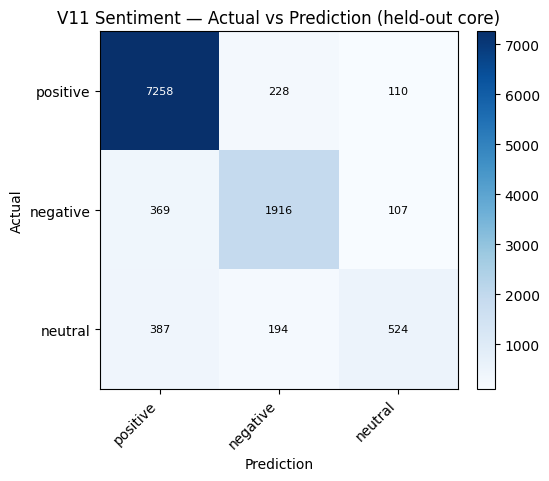

,task,stage,epoch,train_loss,validation_loss,macro_f1,positive_f1,negative_f1,neutral_f1,aspect_f1,relation_f1,opinion_f1
0,sentiment,smsa_document_warmup,1.0,0.858303,1.257774,0.369101,0.626322,0.450617,0.030364,NaN,NaN,NaN
1,sentiment,core_fit,2.0,0.629659,0.530957,0.755366,0.870817,0.821510,0.573770,NaN,NaN,NaN
2,sentiment,normal_training,3.0,0.248013,0.492011,0.780439,0.887191,0.810390,0.643738,NaN,NaN,NaN
3,sentiment,normal_training,4.0,0.210912,0.476312,0.783043,0.886076,0.825433,0.637621,NaN,NaN,NaN
4,sentiment,normal_training,5.0,0.192210,0.463876,0.782092,0.887175,0.817880,0.641221,NaN,NaN,NaN
5,sentiment,neutral_hardening,6.0,0.200769,0.457699,0.789327,0.887132,0.825397,0.655451,NaN,NaN,NaN
6,aspect,aspect_span,1.0,0.214435,NaN,NaN,NaN,NaN,NaN,0.656059,NaN,NaN
7,aspect,aspect_span,2.0,0.150644,NaN,NaN,NaN,NaN,NaN,0.674157,NaN,NaN
8,aspect,aspect_span,3.0,0.119070,NaN,NaN,NaN,NaN,NaN,0.703998,NaN,NaN
9,aspect,aspect_span,4.0,0.098662,NaN,NaN,NaN,NaN,NaN,0.699542,NaN,NaN


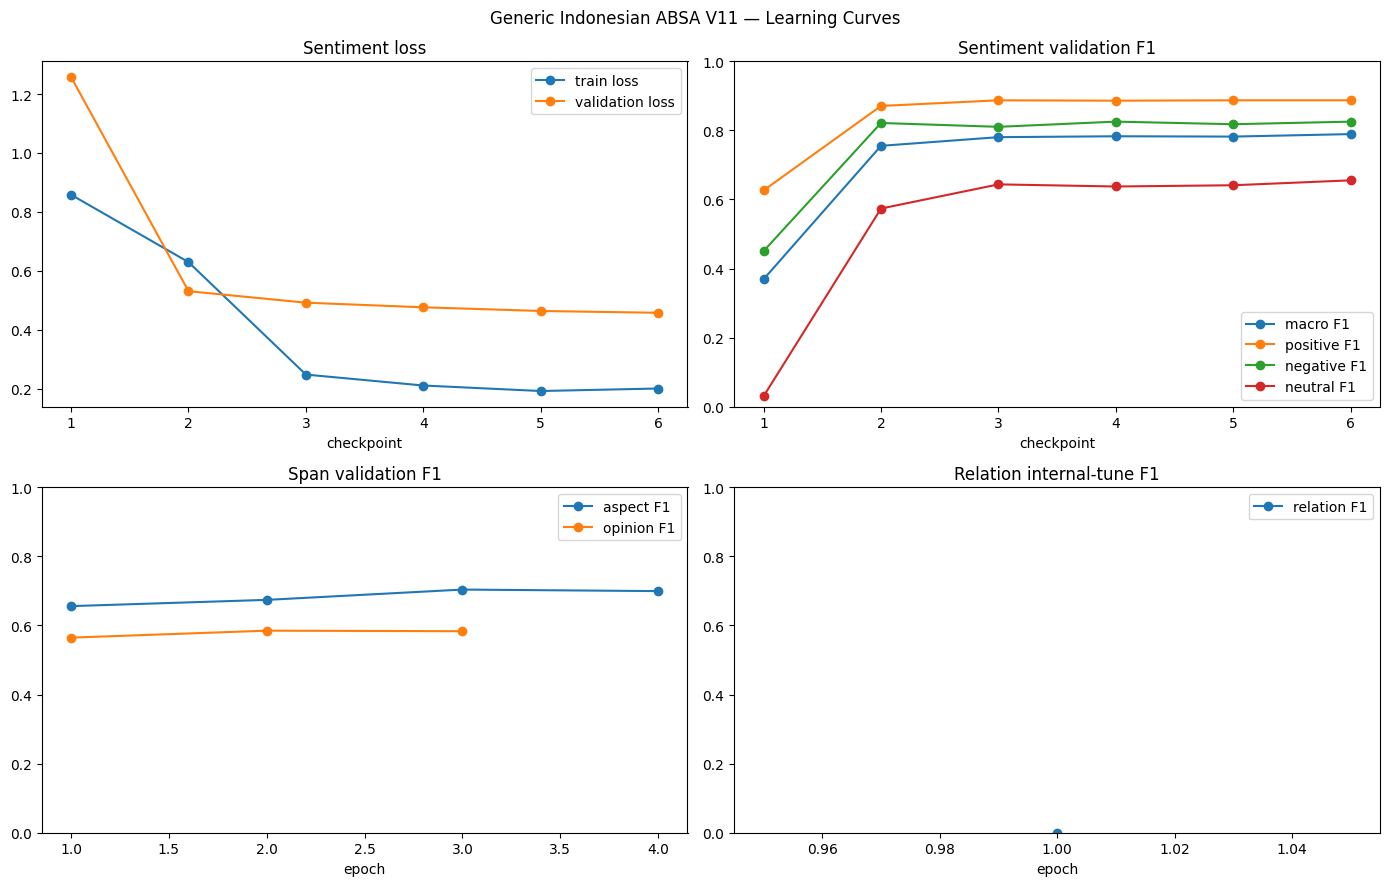

e2e:   0%|          | 0/1129 [00:00<?, ?it/s]

e2e:   0%|          | 0/1035 [00:00<?, ?it/s]

e2e:   0%|          | 0/1161 [00:00<?, ?it/s]

e2e:   0%|          | 0/1064 [00:00<?, ?it/s]

e2e:   0%|          | 0/1043 [00:00<?, ?it/s]

...

,domain,sentiment_n,review_n,sentiment_macro_f1,positive_f1,negative_f1,neutral_f1,aspect_f1,aspect_sentiment_f1,taxonomy_accuracy,taxonomy_macro_f1,relation_f1,scope
0,coursera,1427,1129,0.634532,0.942919,0.732106,0.228571,0.774314,0.717378,None,None,None,heldout_core_gold_compatible
1,food,1326,1035,0.519322,0.874498,0.661123,0.022346,0.632743,0.519149,None,None,None,heldout_core_gold_compatible
2,hotel,1770,1161,0.594274,0.961117,0.781705,0.040000,0.732673,0.694457,None,None,None,heldout_core_gold_compatible
3,laptop,1355,1064,0.641628,0.935541,0.877193,0.112150,0.780087,0.705202,None,None,None,heldout_core_gold_compatible
4,phone,2353,1043,0.700103,0.949306,0.877712,0.273292,0.578015,0.542546,None,None,None,heldout_core_gold_compatible
5,restaurant,2862,1578,0.821470,0.900388,0.805617,0.758405,0.754763,0.656976,None,None,None,heldout_core_gold_compatible


,component,metric,precision,recall,f1,accuracy,scope,is_gold_gate,value
0,sentiment,positive,0.905665,0.955503,0.929917,NaN,heldout_core,True,NaN
1,sentiment,negative,0.819504,0.801003,0.810148,NaN,heldout_core,True,NaN
2,sentiment,neutral,0.707152,0.474208,0.567714,NaN,heldout_core,True,NaN
3,sentiment,macro,0.810774,0.743571,0.769260,0.874245,heldout_core,True,NaN
4,aspect,exact_span,0.706780,0.692799,0.699720,NaN,heldout_core,True,NaN
5,aspect_sentiment,exact_match,0.644518,0.623349,0.633757,NaN,heldout_core,True,NaN
6,opinion,exact_span,0.891286,0.900251,0.895746,NaN,heldout_terma,True,NaN
7,calibration,ECE,NaN,NaN,NaN,NaN,heldout_core,True,0.016789
8,calibration,Brier Score,NaN,NaN,NaN,NaN,heldout_core,True,0.189777


,metric,value,target,evaluated,pass,scope
0,negative_f1,0.810148,0.84,True,False,heldout_gold_required
1,neutral_f1,0.567714,0.50,True,True,heldout_gold_required
2,sentiment_macro_f1,0.769260,0.75,True,True,heldout_gold_required
3,aspect_f1,0.699720,0.75,True,False,heldout_gold_required
4,aspect_sentiment_f1,0.633757,0.70,True,False,heldout_gold_required
5,relation_f1,NaN,0.55,False,False,heldout_gold_required
6,taxonomy_macro_f1,NaN,0.75,False,False,heldout_gold_required


,run_mode,status,updated_at_utc,use_dapt,use_silver,use_v10_synthetic,use_v11_synthetic,dapt_used,sentiment_macro_f1,positive_f1,...,neutral_f1,aspect_f1,aspect_sentiment_f1,opinion_f1,relation_f1_human_gold,relation_f1_aux_internal,taxonomy_accuracy,taxonomy_macro_f1,calibration_ece,calibration_brier
0,base,not_run,NaN,False,False,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dapt_only,not_run,NaN,True,False,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,silver_only,not_run,NaN,False,True,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dapt_silver,not_run,NaN,True,True,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dapt_silver_v11synthetic,not_run,NaN,True,True,True,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dapt_silver_v11synthetic_v13,not_run,NaN,True,True,True,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,v14_context_hardened,completed,2026-09-08T08:44:59.200823+00:00,True,False,False,False,True,0.76926,0.929917,...,0.567714,0.69972,0.633757,0.895746,None,None,None,None,0.016789,0.189777


V11 canonical outputs: /content/absa_v14_runs/context_hardened/seed_42/outputs


In [ ]:
# ============================================================
# V11 CANONICAL EVALUATION, CONFUSION MATRICES, LEARNING CURVES, PER-DOMAIN
# ============================================================
REPORT_DIR = BASE_DIR / "reports"
OUTPUT_DIR = BASE_DIR / "outputs"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _safe_metric(obj, *keys):
    try:
        for key in keys:
            obj = obj[key]
        return float(obj)
    except Exception:
        return None


def _plot_confusion(y_true, y_pred, labels, title, output_path):
    if y_true is None or y_pred is None or len(y_true) == 0:
        return None
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    size = max(6, min(16, 0.65 * len(labels) + 4))
    fig, ax = plt.subplots(figsize=(size, size * 0.82))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(labels)), labels=labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    if len(labels) <= 20:
        cutoff = matrix.max() * 0.55 if matrix.size else 0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(
                    j, i, int(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > cutoff else "black",
                    fontsize=8,
                )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    return matrix


# Confusion matrix: sentiment held-out core.
SENTIMENT_CM = None
if SENT_TEST:
    _sent_y_true = [ID2SENT[i] for i in SENT_TEST["y_true"]]
    _sent_y_pred = [ID2SENT[i] for i in SENT_TEST["y_pred"]]
    SENTIMENT_CM = _plot_confusion(
        _sent_y_true, _sent_y_pred, CONFIG["sentiment_labels"],
        "V11 Sentiment — Actual vs Prediction (held-out core)",
        OUTPUT_DIR / "confusion_matrix_sentiment_v11.png",
    )

# Confusion matrix: taxonomy held-out core.
TAXONOMY_CM = None
if TAXONOMY_TEST_METRICS:
    _tax_ids = sorted(set(TAXONOMY_TEST_METRICS["y_true"]) | set(TAXONOMY_TEST_METRICS["y_pred"]))
    _tax_labels = [ID2TAX[i] for i in _tax_ids]
    TAXONOMY_CM = _plot_confusion(
        [ID2TAX[i] for i in TAXONOMY_TEST_METRICS["y_true"]],
        [ID2TAX[i] for i in TAXONOMY_TEST_METRICS["y_pred"]],
        _tax_labels,
        "V11 Taxonomy — Actual vs Prediction (held-out core)",
        OUTPUT_DIR / "confusion_matrix_taxonomy_v11.png",
    )

# Confusion matrix: human GOLD test when available; otherwise clearly labelled
# train-derived AUX diagnostic. The latter never becomes the canonical relation gate.
RELATION_CM = None
RELATION_CM_SCOPE = None
_relation_cm_items = relation_test if relation_test else relation_val
if relation_model is not None and _relation_cm_items:
    RELATION_CM_SCOPE = "human_gold_test" if relation_test else "aux_internal_tune_diagnostic"
    _relation_cm_eval = eval_relation(relation_model, _relation_cm_items, RELATION_THRESHOLD)
    _rel_pred = [int(x >= RELATION_THRESHOLD) for x in _relation_cm_eval["scores"]]
    RELATION_CM = _plot_confusion(
        _relation_cm_eval["labels"], _rel_pred, [0, 1],
        f"V11 Relation — Actual vs Prediction ({RELATION_CM_SCOPE})",
        OUTPUT_DIR / "confusion_matrix_relation_v11.png",
    )


# Unified training history schema required by V11.
_history_rows = []
for _, row in sentiment_history.iterrows() if len(sentiment_history) else []:
    _history_rows.append({
        "task": "sentiment", "stage": row.get("stage"),
        "epoch": row.get("epoch"), "train_loss": row.get("train_loss"),
        "validation_loss": row.get("validation_loss", row.get("val_loss")),
        "macro_f1": row.get("macro_f1", row.get("val_macro_f1")),
        "positive_f1": row.get("positive_f1", row.get("val_positive_f1")),
        "negative_f1": row.get("negative_f1", row.get("val_negative_f1")),
        "neutral_f1": row.get("neutral_f1", row.get("val_neutral_f1")),
        "aspect_f1": np.nan, "relation_f1": np.nan,
    })
for _, row in aspect_history.iterrows() if len(aspect_history) else []:
    _history_rows.append({
        "task": "aspect", "stage": "aspect_span", "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": np.nan,
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": row.get("val_f1"),
        "relation_f1": np.nan,
    })
for _, row in opinion_history.iterrows() if len(opinion_history) else []:
    _history_rows.append({
        "task": "opinion", "stage": "opinion_span", "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": np.nan,
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": np.nan,
        "opinion_f1": row.get("val_f1"), "relation_f1": np.nan,
    })
for _, row in relation_history.iterrows() if len(relation_history) else []:
    _history_rows.append({
        "task": "relation", "stage": row.get("stage"), "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": row.get("validation_loss"),
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": np.nan,
        "relation_f1": row.get("relation_f1"),
    })
TRAINING_HISTORY_V11 = pd.DataFrame(_history_rows)
_required_history_cols = [
    "task", "stage", "epoch", "train_loss", "validation_loss", "macro_f1",
    "positive_f1", "negative_f1", "neutral_f1", "aspect_f1", "relation_f1",
]
for _column in _required_history_cols:
    if _column not in TRAINING_HISTORY_V11:
        TRAINING_HISTORY_V11[_column] = np.nan
TRAINING_HISTORY_V11 = TRAINING_HISTORY_V11[_required_history_cols + [
    c for c in TRAINING_HISTORY_V11.columns if c not in _required_history_cols
]]
TRAINING_HISTORY_V11.to_csv(OUTPUT_DIR / "training_history_v11.csv", index=False)
display(TRAINING_HISTORY_V11)


def _plot_training_history(history, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    sent = history[history["task"] == "sentiment"]
    if len(sent):
        x = np.arange(1, len(sent) + 1)
        axes[0, 0].plot(x, sent["train_loss"], marker="o", label="train loss")
        axes[0, 0].plot(x, sent["validation_loss"], marker="o", label="validation loss")
        axes[0, 0].set_title("Sentiment loss")
        axes[0, 0].set_xlabel("checkpoint")
        axes[0, 0].legend()
        for col, label in [
            ("macro_f1", "macro F1"), ("positive_f1", "positive F1"),
            ("negative_f1", "negative F1"), ("neutral_f1", "neutral F1"),
        ]:
            axes[0, 1].plot(x, sent[col], marker="o", label=label)
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].set_title("Sentiment validation F1")
        axes[0, 1].set_xlabel("checkpoint")
        axes[0, 1].legend()
    span = history[history["task"].isin(["aspect", "opinion"])]
    for task_name, group in span.groupby("task"):
        metric = "aspect_f1" if task_name == "aspect" else "opinion_f1"
        if metric in group:
            axes[1, 0].plot(group["epoch"], group[metric], marker="o", label=f"{task_name} F1")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_title("Span validation F1")
    axes[1, 0].set_xlabel("epoch")
    if len(span):
        axes[1, 0].legend()
    rel = history[history["task"] == "relation"]
    if len(rel):
        axes[1, 1].plot(rel["epoch"], rel["relation_f1"], marker="o", label="relation F1")
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, "Relation history unavailable", ha="center", va="center")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_title("Relation internal-tune F1")
    axes[1, 1].set_xlabel("epoch")
    fig.suptitle("Generic Indonesian ABSA V11 — Learning Curves")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


_plot_training_history(TRAINING_HISTORY_V11, OUTPUT_DIR / "learning_curve.png")


# Per-domain held-out metrics. Synthetic and SILVER are not evaluated here.
_domain_sent_items = list(test_sent) + list(gmaps_test_sent)
_domain_record_items = list(test_unified) + list(gmaps_test_records)
_domain_tax_items = list(_tax_core_test) + _build_tax_examples(gmaps_test_records, {"test"}, 1.0)
_domain_names = sorted(
    set(x.get("domain", "unknown") for x in _domain_sent_items)
    | set(r.get("domain", "unknown") for r in _domain_record_items)
)
_domain_rows = []
for domain_name in _domain_names:
    sent_subset = [x for x in _domain_sent_items if x.get("domain") == domain_name]
    record_subset = [r for r in _domain_record_items if r.get("domain") == domain_name]
    gmaps_record_subset = [r for r in gmaps_test_records if r.get("domain") == domain_name]
    tax_subset = [x for x in _domain_tax_items if x.get("domain") == domain_name]
    sent_metrics = eval_sentiment(sentiment_model, sent_subset) if sentiment_model is not None and sent_subset else None
    e2e_metrics = evaluate_e2e(record_subset) if aspect_model is not None and sentiment_model is not None and record_subset else None
    tax_metrics = eval_taxonomy(taxonomy_model, tax_subset) if taxonomy_model is not None and tax_subset else None
    gmaps_domain_metrics = evaluate_gmaps_gold(gmaps_record_subset) if gmaps_record_subset else None
    _domain_rows.append({
        "domain": domain_name, "sentiment_n": len(sent_subset),
        "review_n": len(record_subset),
        "sentiment_macro_f1": _safe_metric(sent_metrics, "macro_f1"),
        "positive_f1": _safe_metric(sent_metrics, "per_class_f1", "positive"),
        "negative_f1": _safe_metric(sent_metrics, "per_class_f1", "negative"),
        "neutral_f1": _safe_metric(sent_metrics, "per_class_f1", "neutral"),
        "aspect_f1": _safe_metric(e2e_metrics, "aspect", "f1"),
        "aspect_sentiment_f1": _safe_metric(e2e_metrics, "aspect_sentiment", "f1"),
        "taxonomy_accuracy": _safe_metric(tax_metrics, "accuracy"),
        "taxonomy_macro_f1": _safe_metric(tax_metrics, "macro_f1"),
        "relation_f1": _safe_metric(gmaps_domain_metrics, "relation_primary_exact", "f1"),
        "scope": "heldout_human_gmaps_gold" if gmaps_record_subset else "heldout_core_gold_compatible",
    })
PER_DOMAIN_METRICS_V11 = pd.DataFrame(_domain_rows)
PER_DOMAIN_METRICS_V11.to_csv(OUTPUT_DIR / "per_domain_metrics_v11.csv", index=False)
display(PER_DOMAIN_METRICS_V11)


# One canonical table: every metric declares its evaluation scope.
_canonical_rows = []
if SENT_TEST:
    for label in CONFIG["sentiment_labels"]:
        _canonical_rows.append({
            "component": "sentiment", "metric": label,
            "precision": SENT_TEST["per_class_precision"][label],
            "recall": SENT_TEST["per_class_recall"][label],
            "f1": SENT_TEST["per_class_f1"][label], "accuracy": np.nan,
            "scope": "heldout_core", "is_gold_gate": True,
        })
    _canonical_rows.append({
        "component": "sentiment", "metric": "macro",
        "precision": float(np.mean(list(SENT_TEST["per_class_precision"].values()))),
        "recall": float(np.mean(list(SENT_TEST["per_class_recall"].values()))),
        "f1": SENT_TEST["macro_f1"], "accuracy": SENT_TEST["accuracy"],
        "scope": "heldout_core", "is_gold_gate": True,
    })
if E2E_TEST:
    _canonical_rows.extend([
        {"component": "aspect", "metric": "exact_span", **{k: E2E_TEST["aspect"][k] for k in ["precision", "recall", "f1"]}, "accuracy": np.nan, "scope": "heldout_core", "is_gold_gate": True},
        {"component": "aspect_sentiment", "metric": "exact_match", **{k: E2E_TEST["aspect_sentiment"][k] for k in ["precision", "recall", "f1"]}, "accuracy": np.nan, "scope": "heldout_core", "is_gold_gate": True},
    ])
if OPINION_TEST_METRICS:
    _canonical_rows.append({
        "component": "opinion", "metric": "exact_span",
        **{k: OPINION_TEST_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "heldout_terma", "is_gold_gate": True,
    })
if RELATION_TEST_METRICS:
    _canonical_rows.append({
        "component": "relation", "metric": "binary_pair",
        **{k: RELATION_TEST_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "heldout_human_gmaps_gold", "is_gold_gate": True,
    })
elif RELATION_AUX_TUNE_METRICS:
    _canonical_rows.append({
        "component": "relation", "metric": "binary_pair_diagnostic",
        **{k: RELATION_AUX_TUNE_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "train_derived_aux_tune_not_gold",
        "is_gold_gate": False,
    })
if TAXONOMY_TEST_METRICS:
    _canonical_rows.append({
        "component": "taxonomy", "metric": "canonical_category",
        "precision": np.nan, "recall": np.nan,
        "f1": TAXONOMY_TEST_METRICS["macro_f1"],
        "accuracy": TAXONOMY_TEST_METRICS["accuracy"],
        "scope": "heldout_core", "is_gold_gate": True,
    })
_cal = globals().get("V11_CALIBRATION", globals().get("V10_CALIBRATION"))
if _cal:
    _canonical_rows.extend([
        {"component": "calibration", "metric": "ECE", "value": _cal["ece"], "scope": "heldout_core", "is_gold_gate": True},
        {"component": "calibration", "metric": "Brier Score", "value": _cal["brier"], "scope": "heldout_core", "is_gold_gate": True},
    ])
CANONICAL_EVALUATION_V11 = pd.DataFrame(_canonical_rows)
CANONICAL_EVALUATION_V11.to_csv(OUTPUT_DIR / "canonical_evaluation_v11.csv", index=False)
display(CANONICAL_EVALUATION_V11)

V11_RUN_METRICS = {
    "run_mode": RUN_MODE,
    "positive_precision": _safe_metric(SENT_TEST, "per_class_precision", "positive"),
    "positive_recall": _safe_metric(SENT_TEST, "per_class_recall", "positive"),
    "positive_f1": _safe_metric(SENT_TEST, "per_class_f1", "positive"),
    "negative_precision": _safe_metric(SENT_TEST, "per_class_precision", "negative"),
    "negative_recall": _safe_metric(SENT_TEST, "per_class_recall", "negative"),
    "negative_f1": _safe_metric(SENT_TEST, "per_class_f1", "negative"),
    "neutral_precision": _safe_metric(SENT_TEST, "per_class_precision", "neutral"),
    "neutral_recall": _safe_metric(SENT_TEST, "per_class_recall", "neutral"),
    "neutral_f1": _safe_metric(SENT_TEST, "per_class_f1", "neutral"),
    "sentiment_macro_f1": _safe_metric(SENT_TEST, "macro_f1"),
    "aspect_precision": _safe_metric(E2E_TEST, "aspect", "precision"),
    "aspect_recall": _safe_metric(E2E_TEST, "aspect", "recall"),
    "aspect_f1": _safe_metric(E2E_TEST, "aspect", "f1"),
    "aspect_sentiment_precision": _safe_metric(E2E_TEST, "aspect_sentiment", "precision"),
    "aspect_sentiment_recall": _safe_metric(E2E_TEST, "aspect_sentiment", "recall"),
    "aspect_sentiment_f1": _safe_metric(E2E_TEST, "aspect_sentiment", "f1"),
    "opinion_precision": _safe_metric(OPINION_TEST_METRICS, "precision"),
    "opinion_recall": _safe_metric(OPINION_TEST_METRICS, "recall"),
    "opinion_f1": _safe_metric(OPINION_TEST_METRICS, "f1"),
    "relation_precision_human_gold": _safe_metric(RELATION_TEST_METRICS, "precision"),
    "relation_recall_human_gold": _safe_metric(RELATION_TEST_METRICS, "recall"),
    "relation_f1_human_gold": _safe_metric(RELATION_TEST_METRICS, "f1"),
    "relation_f1_aux_internal": _safe_metric(RELATION_AUX_TUNE_METRICS, "f1"),
    "taxonomy_accuracy": _safe_metric(TAXONOMY_TEST_METRICS, "accuracy"),
    "taxonomy_macro_f1": _safe_metric(TAXONOMY_TEST_METRICS, "macro_f1"),
    "calibration_ece": _safe_metric(_cal, "ece"),
    "calibration_brier": _safe_metric(_cal, "brier"),
    "dapt_used": bool(DAPT_ACTUAL_USED),
    "data_audit_pass": bool(V11_DATA_AUDIT_PASS),
}

_target_key_map = {
    "negative_f1": "negative_f1",
    "neutral_f1": "neutral_f1",
    "sentiment_macro_f1": "sentiment_macro_f1",
    "aspect_f1": "aspect_f1",
    "aspect_sentiment_f1": "aspect_sentiment_f1",
    "relation_f1": "relation_f1_human_gold",
    "taxonomy_macro_f1": "taxonomy_macro_f1",
}
_gate_rows = []
for metric_name, target in CONFIG["v11_targets"].items():
    value = V11_RUN_METRICS.get(_target_key_map[metric_name])
    _gate_rows.append({
        "metric": metric_name, "value": value, "target": target,
        "evaluated": value is not None,
        "pass": bool(value >= target) if value is not None else False,
        "scope": "heldout_gold_required",
    })
V11_TARGET_GATE = pd.DataFrame(_gate_rows)
V11_TARGET_GATE.to_csv(OUTPUT_DIR / "v11_target_gate.csv", index=False)
display(V11_TARGET_GATE)

_run_json_path = REPORT_DIR / f"v11_ablation_{RUN_MODE}.json"
_run_json_path.write_text(
    json.dumps(V11_RUN_METRICS, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)

# Upsert current run while retaining explicit not-run rows for all supported modes.
_ablation_path = OUTPUT_DIR / "ablation_results_v11.csv"
_ablation_columns = [
    "run_mode", "status", "updated_at_utc", "use_dapt", "use_silver",
    "use_v10_synthetic", "use_v11_synthetic", "dapt_used",
    "sentiment_macro_f1", "positive_f1", "negative_f1", "neutral_f1",
    "aspect_f1", "aspect_sentiment_f1", "opinion_f1",
    "relation_f1_human_gold", "relation_f1_aux_internal",
    "taxonomy_accuracy", "taxonomy_macro_f1", "calibration_ece", "calibration_brier",
]
if _ablation_path.exists():
    _ablation_df = pd.read_csv(_ablation_path)
else:
    _ablation_df = pd.DataFrame([
        {
            "run_mode": mode, "status": "not_run",
            "use_dapt": flags["use_dapt"], "use_silver": flags["use_silver"],
            "use_v10_synthetic": flags["use_synthetic"],
            "use_v11_synthetic": flags["use_v11_synthetic"],
        }
        for mode, flags in V11_ABLATIONS.items()
    ])
_current_row = {
    **V11_RUN_METRICS,
    "status": "completed", "updated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "use_dapt": ABLATION["use_dapt"], "use_silver": ABLATION["use_silver"],
    "use_v10_synthetic": ABLATION["use_synthetic"],
    "use_v11_synthetic": ABLATION["use_v11_synthetic"],
}
_ablation_df = _ablation_df[_ablation_df["run_mode"] != RUN_MODE]
_ablation_df = pd.concat([_ablation_df, pd.DataFrame([_current_row])], ignore_index=True)
_mode_order = {mode: i for i, mode in enumerate(V11_ABLATIONS)}
_ablation_df["_order"] = _ablation_df["run_mode"].map(_mode_order)
_ablation_df = _ablation_df.sort_values("_order").drop(columns="_order")
for _column in _ablation_columns:
    if _column not in _ablation_df:
        _ablation_df[_column] = np.nan
ABLATION_RESULTS_V11 = _ablation_df[_ablation_columns]
ABLATION_RESULTS_V11.to_csv(_ablation_path, index=False)
display(ABLATION_RESULTS_V11)
print("V11 canonical outputs:", OUTPUT_DIR)


### 21.1 Menghitung Metrik Multibahasa dan Triplet


INFO: taxonomy training history tidak tersedia. Kurva taxonomy akan dikosongkan.
{'training_history_rows': 14, 'taxonomy_history_rows': 0, 'taxonomy_model_available': False, 'history_path': '/content/absa_v14_runs/context_hardened/seed_42/outputs/training_history_v12.csv'}


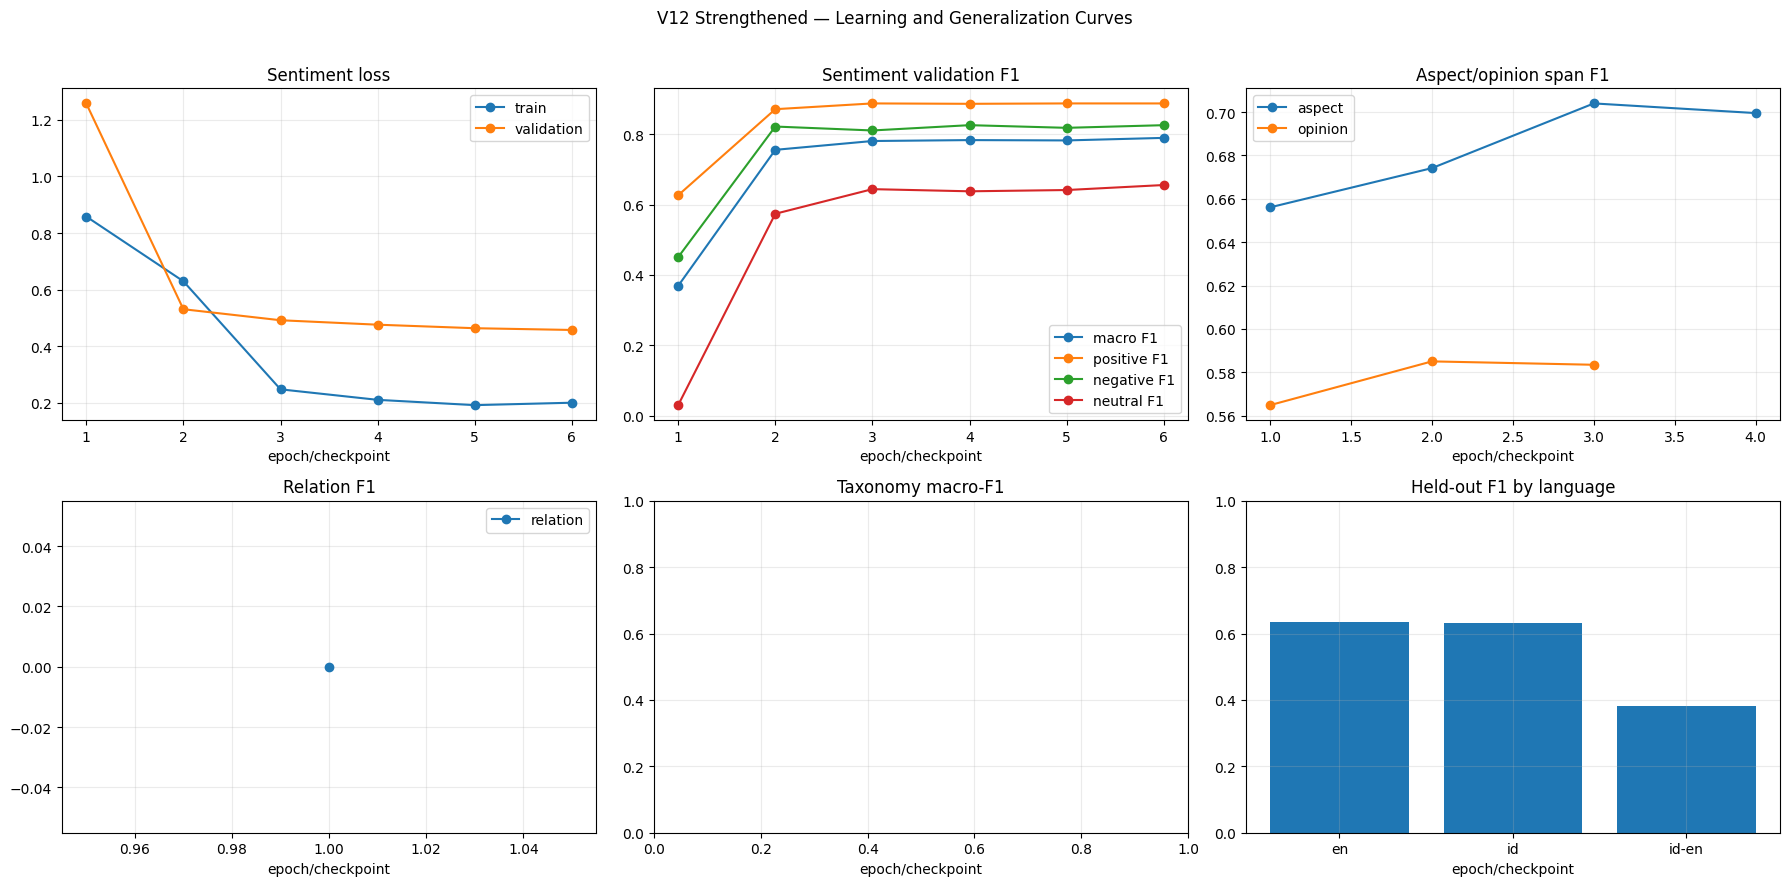

{'learning_curve_saved': '/content/absa_v14_runs/context_hardened/seed_42/outputs/learning_curves_v12.png', 'taxonomy_curve_available': False}


In [ ]:
# ============================================================
# V12 TRAINING HISTORY + LEARNING CURVES — SAFE VERSION
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 1. Ambil history V11 secara aman
# ------------------------------------------------------------
_training_history_v11 = globals().get(
    "TRAINING_HISTORY_V11",
    pd.DataFrame(),
)

if _training_history_v11 is None:
    _training_history_v11 = pd.DataFrame()
elif not isinstance(_training_history_v11, pd.DataFrame):
    _training_history_v11 = pd.DataFrame(
        _training_history_v11
    )

_history_v12 = _training_history_v11.copy()


# ------------------------------------------------------------
# 2. Ambil history taxonomy secara aman
#
# Taxonomy history boleh kosong apabila:
# - taxonomy classifier tidak dilatih,
# - taxonomy model dimuat dari checkpoint,
# - taxonomy memakai heuristic taxonomy_mapper,
# - cell taxonomy sebelumnya tidak selesai.
# ------------------------------------------------------------
_taxonomy_history_v12 = globals().get(
    "TAXONOMY_HISTORY_V12",
    [],
)

if _taxonomy_history_v12 is None:
    _taxonomy_history_v12 = []

if isinstance(_taxonomy_history_v12, pd.DataFrame):
    _taxonomy_history_v12 = (
        _taxonomy_history_v12
        .to_dict(orient="records")
    )

if not isinstance(_taxonomy_history_v12, (list, tuple)):
    print(
        "WARNING: TAXONOMY_HISTORY_V12 memiliki format "
        "yang tidak dikenal dan akan diabaikan:",
        type(_taxonomy_history_v12).__name__,
    )
    _taxonomy_history_v12 = []


# ------------------------------------------------------------
# 3. Normalisasi history taxonomy
# ------------------------------------------------------------
_tax_history_rows = []

for _index, row in enumerate(
    _taxonomy_history_v12,
    start=1,
):
    if not isinstance(row, dict):
        continue

    _epoch = row.get(
        "epoch",
        _index,
    )

    _train_loss = row.get(
        "train_loss",
        np.nan,
    )

    _validation_loss = row.get(
        "validation_loss",
        row.get(
            "val_loss",
            np.nan,
        ),
    )

    _taxonomy_f1 = row.get(
        "val_macro_f1",
        row.get(
            "taxonomy_f1",
            row.get(
                "macro_f1",
                np.nan,
            ),
        ),
    )

    _tax_history_rows.append({
        "task": "taxonomy",
        "stage": row.get(
            "stage",
            "taxonomy_classifier",
        ),
        "epoch": _epoch,
        "train_loss": _train_loss,
        "validation_loss": _validation_loss,
        "macro_f1": _taxonomy_f1,
        "positive_f1": np.nan,
        "negative_f1": np.nan,
        "neutral_f1": np.nan,
        "aspect_f1": np.nan,
        "opinion_f1": np.nan,
        "relation_f1": np.nan,
        "taxonomy_f1": _taxonomy_f1,
    })


# ------------------------------------------------------------
# 4. Gabungkan history taxonomy dengan history sebelumnya
# ------------------------------------------------------------
if _tax_history_rows:
    _tax_history = pd.DataFrame(
        _tax_history_rows
    )

    _history_v12 = pd.concat(
        [
            _history_v12,
            _tax_history,
        ],
        ignore_index=True,
        sort=False,
    )

    print(
        "Taxonomy history ditambahkan:",
        len(_tax_history),
        "baris",
    )
else:
    print(
        "INFO: taxonomy training history tidak tersedia. "
        "Kurva taxonomy akan dikosongkan."
    )


# ------------------------------------------------------------
# 5. Pastikan semua kolom plotting tersedia
# ------------------------------------------------------------
_required_history_columns = [
    "task",
    "stage",
    "epoch",
    "train_loss",
    "validation_loss",
    "macro_f1",
    "positive_f1",
    "negative_f1",
    "neutral_f1",
    "aspect_f1",
    "opinion_f1",
    "relation_f1",
    "taxonomy_f1",
]

for _column in _required_history_columns:
    if _column not in _history_v12.columns:
        if _column in {
            "task",
            "stage",
        }:
            _history_v12[_column] = None
        else:
            _history_v12[_column] = np.nan


# Kolom numerik dipaksa menjadi numeric agar matplotlib aman.
_numeric_history_columns = [
    "epoch",
    "train_loss",
    "validation_loss",
    "macro_f1",
    "positive_f1",
    "negative_f1",
    "neutral_f1",
    "aspect_f1",
    "opinion_f1",
    "relation_f1",
    "taxonomy_f1",
]

for _column in _numeric_history_columns:
    _history_v12[_column] = pd.to_numeric(
        _history_v12[_column],
        errors="coerce",
    )


# ------------------------------------------------------------
# 6. Simpan history final
# ------------------------------------------------------------
TRAINING_HISTORY_V12 = (
    _history_v12
    .reset_index(drop=True)
)

_training_history_path = (
    OUTPUT_DIR
    / "training_history_v12.csv"
)

TRAINING_HISTORY_V12.to_csv(
    _training_history_path,
    index=False,
)

print({
    "training_history_rows": len(
        TRAINING_HISTORY_V12
    ),
    "taxonomy_history_rows": len(
        _tax_history_rows
    ),
    "taxonomy_model_available": (
        globals().get("taxonomy_model")
        is not None
    ),
    "history_path": str(
        _training_history_path
    ),
})


# ------------------------------------------------------------
# 7. Helper plotting aman
# ------------------------------------------------------------
def _plot_history_column(
    axis,
    group,
    column,
    label,
    x_column="epoch",
):
    if column not in group.columns:
        return False

    _values = pd.to_numeric(
        group[column],
        errors="coerce",
    )

    _valid = _values.notna()

    if not _valid.any():
        return False

    if (
        x_column in group.columns
        and group[x_column].notna().any()
    ):
        _x_values = pd.to_numeric(
            group[x_column],
            errors="coerce",
        )

        # Gunakan nomor checkpoint jika epoch kosong.
        _fallback_x = pd.Series(
            np.arange(
                1,
                len(group) + 1,
            ),
            index=group.index,
            dtype=float,
        )

        _x_values = _x_values.fillna(
            _fallback_x
        )
    else:
        _x_values = pd.Series(
            np.arange(
                1,
                len(group) + 1,
            ),
            index=group.index,
            dtype=float,
        )

    axis.plot(
        _x_values[_valid],
        _values[_valid],
        marker="o",
        label=label,
    )

    return True


# ------------------------------------------------------------
# 8. Buat learning curves
# ------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
)

if (
    not TRAINING_HISTORY_V12.empty
    and TRAINING_HISTORY_V12["task"].notna().any()
):
    _history_groups = (
        TRAINING_HISTORY_V12
        .dropna(subset=["task"])
        .groupby(
            "task",
            dropna=False,
        )
    )
else:
    _history_groups = []

for task, group in _history_groups:
    group = (
        group
        .reset_index(drop=True)
    )

    if task == "sentiment":
        _plot_history_column(
            axes[0, 0],
            group,
            "train_loss",
            "train",
        )

        _plot_history_column(
            axes[0, 0],
            group,
            "validation_loss",
            "validation",
        )

        for _column, _label in [
            ("macro_f1", "macro F1"),
            ("positive_f1", "positive F1"),
            ("negative_f1", "negative F1"),
            ("neutral_f1", "neutral F1"),
        ]:
            _plot_history_column(
                axes[0, 1],
                group,
                _column,
                _label,
            )

    elif task == "aspect":
        _plot_history_column(
            axes[0, 2],
            group,
            "aspect_f1",
            "aspect",
        )

    elif task == "opinion":
        _plot_history_column(
            axes[0, 2],
            group,
            "opinion_f1",
            "opinion",
        )

    elif task == "relation":
        _plot_history_column(
            axes[1, 0],
            group,
            "relation_f1",
            "relation",
        )

    elif task == "taxonomy":
        _plot_history_column(
            axes[1, 1],
            group,
            "taxonomy_f1",
            "taxonomy",
        )


# ------------------------------------------------------------
# 9. Plot held-out F1 berdasarkan bahasa
# ------------------------------------------------------------
_language_metrics = globals().get(
    "V12_LANGUAGE_METRICS",
    pd.DataFrame(),
)

if _language_metrics is None:
    _language_metrics = pd.DataFrame()

if not isinstance(
    _language_metrics,
    pd.DataFrame,
):
    _language_metrics = pd.DataFrame(
        _language_metrics
    )

_required_language_columns = {
    "language",
    "aspect_sentiment_exact_f1",
}

if (
    not _language_metrics.empty
    and _required_language_columns.issubset(
        _language_metrics.columns
    )
):
    _language_names = (
        _language_metrics["language"]
        .astype(str)
    )

    _language_scores = pd.to_numeric(
        _language_metrics[
            "aspect_sentiment_exact_f1"
        ],
        errors="coerce",
    ).fillna(0.0)

    axes[1, 2].bar(
        _language_names,
        _language_scores,
    )

    axes[1, 2].set_ylim(
        0,
        1,
    )
else:
    axes[1, 2].text(
        0.5,
        0.5,
        "Language metrics unavailable",
        horizontalalignment="center",
        verticalalignment="center",
        transform=axes[1, 2].transAxes,
    )


# ------------------------------------------------------------
# 10. Format seluruh grafik
# ------------------------------------------------------------
_plot_titles = [
    "Sentiment loss",
    "Sentiment validation F1",
    "Aspect/opinion span F1",
    "Relation F1",
    "Taxonomy macro-F1",
    "Held-out F1 by language",
]

for axis, title in zip(
    axes.flat,
    _plot_titles,
):
    axis.set_title(title)
    axis.set_xlabel(
        "epoch/checkpoint"
    )
    axis.grid(
        alpha=0.25
    )

    if axis.lines:
        axis.legend()


fig.suptitle(
    "V12 Strengthened — Learning and Generalization Curves"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

_learning_curve_path = (
    OUTPUT_DIR
    / "learning_curves_v12.png"
)

fig.savefig(
    _learning_curve_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print({
    "learning_curve_saved": str(
        _learning_curve_path
    ),
    "taxonomy_curve_available": bool(
        _tax_history_rows
    ),
})

### 21.2 Menjalankan Diagnostik Sintetis


In [ ]:
# ============================================================
# V13 SYNTHETIC FROZEN DIAGNOSTIC — NEVER A PRODUCTION BENCHMARK
# ============================================================
def _v13_json_safe(value):
    if isinstance(value, np.generic): return value.item()
    if isinstance(value, Path): return str(value)
    if isinstance(value, dict): return {str(key): _v13_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)): return [_v13_json_safe(item) for item in value]
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

V13_FROZEN_SYNTHETIC_TRIPLET = evaluate_exact_triplets_v12(v13_frozen_diagnostic_records)
V13_FROZEN_SYNTHETIC_E2E = (
    evaluate_e2e(v13_frozen_diagnostic_records)
    if v13_frozen_diagnostic_records and aspect_model is not None and sentiment_model is not None else None
)
V13_FROZEN_SYNTHETIC_REPORT = {
    "status": "synthetic_diagnostic_only_not_human_gold",
    "records": len(v13_frozen_diagnostic_records),
    "triplet": V13_FROZEN_SYNTHETIC_TRIPLET,
    "e2e": V13_FROZEN_SYNTHETIC_E2E,
    "used_for_training": False,
    "used_for_threshold_tuning": False,
}
(BASE_DIR / "reports" / "v13_frozen_synthetic_diagnostic.json").write_text(
    json.dumps(_v13_json_safe(V13_FROZEN_SYNTHETIC_REPORT), ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(_v13_json_safe(V13_FROZEN_SYNTHETIC_REPORT), ensure_ascii=False, indent=2))


{
  "status": "synthetic_diagnostic_only_not_human_gold",
  "records": 0,
  "triplet": {
    "status": "not_evaluated_no_complete_gold_or_model",
    "records": 0
  },
  "e2e": null,
  "used_for_training": false,
  "used_for_threshold_tuning": false
}


### 21.3 Menganalisis Error Held-Out


In [ ]:
# ============================================================
# V11 ERROR ANALYSIS — HELD-OUT ONLY
# ============================================================
ERROR_ANALYSIS_COLUMNS = [
    "review_text", "gold_aspect", "pred_aspect", "gold_sentiment",
    "pred_sentiment", "gold_taxonomy", "pred_taxonomy", "gold_relation",
    "pred_relation", "error_type", "domain", "source_dataset",
]


def _relation_strings_from_prediction(item):
    out = []
    aspect = str(item.get("aspect_term") or "")
    for ev in item.get("opinion_evidence", []) or []:
        if ev.get("term"):
            out.append(f"{aspect}::{ev['term']}")
    if not out and item.get("opinion_term"):
        out.append(f"{aspect}::{item['opinion_term']}")
    return out


def generate_error_analysis(records_eval):
    rows = []
    if aspect_model is None or sentiment_model is None:
        return pd.DataFrame(columns=ERROR_ANALYSIS_COLUMNS)
    coref_re = re.compile(r"(?:\b(?:ini|itu|dia|mereka|beliau|tersebut)\b|\b\w+nya\b)", re.I)
    for record in tqdm(records_eval, desc="error-analysis"):
        pred = predict_absa(record["text"], "scientific_balanced")
        pred_by_span = {
            (int(x["aspect_start"]), int(x["aspect_end"])): x for x in pred
        }
        matched_pred_spans = set()
        for ann in record.get("annotations", []):
            gold_sent = canonical_sentiment_label(ann.get("sentiment"))
            if gold_sent not in VALID_SENTIMENTS:
                continue
            implicit = bool(ann.get("implicit", False) or ann.get("aspect_start") is None)
            gold_tax = canonical_taxonomy_label(
                ann.get("taxonomy_label") or ann.get("aspect_category") or ann.get("implicit_category"),
                ann.get("aspect_term") or "", record.get("domain", ""),
            )
            gold_rel = None
            if ann.get("opinion_term"):
                gold_rel = f"{ann.get('aspect_term') or '<IMPLICIT>'}::{ann.get('opinion_term')}"
            if implicit:
                base = {
                    "review_text": record["text"],
                    "gold_aspect": f"<IMPLICIT:{gold_tax}>",
                    "pred_aspect": json.dumps([x.get("aspect_term") for x in pred], ensure_ascii=False),
                    "gold_sentiment": gold_sent, "pred_sentiment": None,
                    "gold_taxonomy": gold_tax,
                    "pred_taxonomy": json.dumps([x.get("normalized_category") for x in pred], ensure_ascii=False),
                    "gold_relation": gold_rel,
                    "pred_relation": json.dumps([
                        z for x in pred for z in _relation_strings_from_prediction(x)
                    ], ensure_ascii=False),
                    "error_type": "implicit aspect failure",
                    "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                }
                rows.append(base)
                continue

            span = (int(ann["aspect_start"]), int(ann["aspect_end"]))
            item = pred_by_span.get(span)
            if item is None:
                base = {
                    "review_text": record["text"], "gold_aspect": ann.get("aspect_term"),
                    "pred_aspect": json.dumps([x.get("aspect_term") for x in pred], ensure_ascii=False),
                    "gold_sentiment": gold_sent, "pred_sentiment": None,
                    "gold_taxonomy": gold_tax, "pred_taxonomy": None,
                    "gold_relation": gold_rel, "pred_relation": None,
                    "error_type": "missed aspect", "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                }
                rows.append(base)
                if coref_re.search(str(record["text"])):
                    rows.append({**base, "error_type": "coreference failure"})
                continue

            matched_pred_spans.add(span)
            pred_sent = item.get("sentiment")
            pred_tax = canonical_taxonomy_label(
                item.get("normalized_category") or item.get("taxonomy_id"),
                item.get("aspect_term") or "", record.get("domain", ""),
            )
            pred_relations = _relation_strings_from_prediction(item)
            common = {
                "review_text": record["text"], "gold_aspect": ann.get("aspect_term"),
                "pred_aspect": item.get("aspect_term"), "gold_sentiment": gold_sent,
                "pred_sentiment": pred_sent, "gold_taxonomy": gold_tax,
                "pred_taxonomy": pred_tax, "gold_relation": gold_rel,
                "pred_relation": json.dumps(pred_relations, ensure_ascii=False),
                "domain": record.get("domain"),
                "source_dataset": record.get("source_dataset"),
            }
            if pred_sent != gold_sent:
                rows.append({**common, "error_type": "wrong sentiment"})
            if pred_tax != gold_tax:
                rows.append({**common, "error_type": "wrong taxonomy"})
            if gold_rel is not None and gold_rel not in pred_relations:
                rows.append({**common, "error_type": "relation failure"})
                if coref_re.search(str(record["text"])):
                    rows.append({**common, "error_type": "coreference failure"})

        for span, item in pred_by_span.items():
            if span not in matched_pred_spans:
                rows.append({
                    "review_text": record["text"], "gold_aspect": None,
                    "pred_aspect": item.get("aspect_term"), "gold_sentiment": None,
                    "pred_sentiment": item.get("sentiment"), "gold_taxonomy": None,
                    "pred_taxonomy": item.get("normalized_category"),
                    "gold_relation": None,
                    "pred_relation": json.dumps(_relation_strings_from_prediction(item), ensure_ascii=False),
                    "error_type": "spurious aspect", "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                })
    return pd.DataFrame(rows, columns=ERROR_ANALYSIS_COLUMNS)


_error_eval_records = list(test_unified) + list(gmaps_test_records) + list(unseen_sight_unified)
ERROR_ANALYSIS_V11 = generate_error_analysis(_error_eval_records)
ERROR_ANALYSIS_V11.to_csv(OUTPUT_DIR / "error_analysis_v11.csv", index=False)
print("V11 error counts:")
display(ERROR_ANALYSIS_V11["error_type"].value_counts().rename_axis("error_type").reset_index(name="n") if len(ERROR_ANALYSIS_V11) else ERROR_ANALYSIS_V11)
display(ERROR_ANALYSIS_V11.head(50))


error-analysis:   0%|          | 0/8058 [00:00<?, ?it/s]

V11 error counts:


,error_type,n
0,missed aspect,3607
1,wrong taxonomy,3154
2,spurious aspect,2637
3,implicit aspect failure,2630
4,coreference failure,1135
5,wrong sentiment,671


,review_text,gold_aspect,pred_aspect,gold_sentiment,pred_sentiment,gold_taxonomy,pred_taxonomy,gold_relation,pred_relation,error_type,domain,source_dataset
0,Sangat direkomendasikan.,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
1,Terima kasih banyak untuk ini kursus.,kursus,kursus,positive,positive,Overall Experience,Other,None,[],wrong taxonomy,coursera,M-ABSA
2,Saya sangat merekomendasikannya.,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
3,Terima kasih .,<IMPLICIT:Overall Experience>,[],positive,None,Overall Experience,[],None,[],implicit aspect failure,coursera,M-ABSA
4,Sangat direkomendasikan!,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
5,Saya belajar banyak.,<IMPLICIT:Overall Experience>,[],positive,None,Overall Experience,[],None,[],implicit aspect failure,coursera,M-ABSA
6,Luar biasa tentu saja!,tentu saja,tentu saja,positive,positive,Overall Experience,Other,None,[],wrong taxonomy,coursera,M-ABSA
7,Ini kursus hebat.,kursus,kursus,positive,positive,Overall Experience,Other,None,[],wrong taxonomy,coursera,M-ABSA
8,Two thumbs up !,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,restaurant,M-ABSA
9,Highly recommended !,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA


## Fase 22 — Menjalankan Final Production Gate


In [ ]:
# ============================================================
# V13 FINAL VERIFICATION / PRODUCTION GATE
# SAFE + FAIL-CLOSED VERSION
# ============================================================

from pathlib import Path
import json
import pandas as pd

print(
    "Legacy V13 gate retained for comparison; "
    "authoritative promotion gate is V14 below."
)
print("=" * 96)
print(
    "V13 FINAL VERIFICATION —",
    globals().get("RUN_MODE", "unknown_run"),
)
print("=" * 96)


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def _safe_list(name):
    value = globals().get(name, [])

    if value is None:
        return []

    if isinstance(value, list):
        return value

    if isinstance(value, tuple):
        return list(value)

    try:
        return list(value)
    except (TypeError, ValueError):
        return []


def _safe_dataframe(name):
    value = globals().get(
        name,
        pd.DataFrame(),
    )

    if value is None:
        return pd.DataFrame()

    if isinstance(value, pd.DataFrame):
        return value.copy()

    try:
        return pd.DataFrame(value)
    except Exception:
        return pd.DataFrame()


def _safe_dict(name):
    value = globals().get(name, {})

    return (
        value.copy()
        if isinstance(value, dict)
        else {}
    )


def _safe_bool(name, default=False):
    value = globals().get(
        name,
        default,
    )

    try:
        return bool(value)
    except Exception:
        return bool(default)


def _all_true_column(
    dataframe,
    column,
):
    if (
        dataframe.empty
        or column not in dataframe.columns
    ):
        return False

    values = dataframe[column]

    if values.empty:
        return False

    return bool(
        values.fillna(False)
        .astype(bool)
        .all()
    )


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

_base_dir = Path(
    globals().get(
        "BASE_DIR",
        Path.cwd(),
    )
)

_output_dir = _base_dir / "outputs"
_report_dir = _base_dir / "reports"

_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

_report_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. LOAD OPTIONAL ARTIFACTS SAFELY
# ============================================================

_v12_language_metrics = _safe_dataframe(
    "V12_LANGUAGE_METRICS"
)

_v11_target_gate = _safe_dataframe(
    "V11_TARGET_GATE"
)

_v13_anchor_regression = _safe_dataframe(
    "V13_ANCHOR_REGRESSION"
)

_v12_fit_diagnosis = _safe_dict(
    "V12_FIT_DIAGNOSIS"
)

_v12_exact_triplet_metrics = _safe_dict(
    "V12_EXACT_TRIPLET_METRICS"
)

_v13_leakage_audit = _safe_dict(
    "V13_LEAKAGE_AUDIT"
)

_config = _safe_dict(
    "CONFIG"
)

_gmaps_gold_records = _safe_list(
    "gmaps_gold_records"
)

_test_unified = _safe_list(
    "test_unified"
)

_v13_train_aux_records = _safe_list(
    "v13_train_aux_records"
)

_v13_frozen_diagnostic_records = _safe_list(
    "v13_frozen_diagnostic_records"
)

_mams_records = _safe_list(
    "mams_records"
)


# ============================================================
# 4. LANGUAGE HELD-OUT CHECK
# ============================================================

if (
    not _v12_language_metrics.empty
    and "language" in _v12_language_metrics.columns
):
    _language_eval = (
        _v12_language_metrics
        .drop_duplicates(
            subset=["language"],
            keep="last",
        )
        .set_index("language")
    )
else:
    _language_eval = pd.DataFrame()

_language_rows_available = False

if (
    not _language_eval.empty
    and "records" in _language_eval.columns
    and {"id", "en"}.issubset(
        set(_language_eval.index)
    )
):
    _id_en_records = pd.to_numeric(
        _language_eval.loc[
            ["id", "en"],
            "records",
        ],
        errors="coerce",
    )

    _language_rows_available = bool(
        _id_en_records.notna().all()
        and (_id_en_records > 0).all()
    )


# ============================================================
# 5. NATURAL CODE-SWITCH HUMAN-GOLD CHECK
# ============================================================

_is_complete_human_fn = globals().get(
    "is_complete_human"
)

_code_switch_gold_rows = 0

if callable(_is_complete_human_fn):
    for _record in (
        _gmaps_gold_records
        + _test_unified
    ):
        try:
            _eligible = (
                _is_complete_human_fn(_record)
                and bool(
                    _record.get(
                        "is_code_switched"
                    )
                )
                and _record.get("split")
                in {"validation", "test"}
            )

            if _eligible:
                _code_switch_gold_rows += 1

        except Exception:
            continue


# ============================================================
# 6. LICENSE CHECK — FAIL CLOSED
# ============================================================

_active_license_keys = [
    "M-ABSA",
    "IndoNLU",
    "MAMS",
]

_optional_bundle_available = any(
    _safe_bool(name)
    for name in [
        "V10_BUNDLE_AVAILABLE",
        "V11_BUNDLE_AVAILABLE",
        "V13_BUNDLE_AVAILABLE",
    ]
)

if _optional_bundle_available:
    _active_license_keys.append(
        "optional_user_bundles"
    )

_license_status = _config.get(
    "dataset_license_status",
    {},
)

_license_details = {}
_all_licenses_verified = True

for _license_key in _active_license_keys:
    _status = _license_status.get(
        _license_key
    )

    _status_text = str(
        _status or ""
    ).upper()

    _license_ok = bool(
        _status is not None
        and _status_text.strip()
        and "NOT_" not in _status_text
        and "VERIFY" not in _status_text
        and "UNKNOWN" not in _status_text
        and "UNVERIFIED" not in _status_text
    )

    _license_details[
        _license_key
    ] = {
        "status": _status,
        "verified": _license_ok,
    }

    if not _license_ok:
        _all_licenses_verified = False


# ============================================================
# 7. HELD-OUT TARGET GATE
# ============================================================

_heldout_target_pass = bool(
    not _v11_target_gate.empty
    and _all_true_column(
        _v11_target_gate,
        "evaluated",
    )
    and _all_true_column(
        _v11_target_gate,
        "pass",
    )
)


# ============================================================
# 8. FIT / OVERFIT DIAGNOSIS
# ============================================================

_fit_diagnosis_status = (
    _v12_fit_diagnosis.get(
        "status",
        "NOT_EVALUATED",
    )
)

_fit_clean = bool(
    _fit_diagnosis_status
    == "NO_STRONG_FIT_PATHOLOGY_DETECTED"
)


# ============================================================
# 9. BACKBONE CHECK
# ============================================================

_aspect_model = globals().get(
    "aspect_model"
)

_aspect_model_type = str(
    getattr(
        getattr(
            _aspect_model,
            "config",
            None,
        ),
        "model_type",
        "",
    )
).casefold()

_configured_encoder = " ".join([
    str(
        _config.get(
            "base_encoder",
            "",
        )
    ),
    str(
        _config.get(
            "encoder",
            "",
        )
    ),
]).casefold()

_backbone_is_xlmr = bool(
    "xlm-roberta" in _configured_encoder
    or "xlm_roberta" in _configured_encoder
    or _aspect_model_type
    in {
        "xlm-roberta",
        "xlm_roberta",
    }
)


# ============================================================
# 10. BLUEPRINT CHECKSUM CHECK
# ============================================================

_expected_blueprint_sha256 = (
    "6b3ef2eef3797b4fa4309a8a86cc0c29"
    "a9829d5e72f0be7a657e4f8f31f8ef47"
)

_blueprint_checksum_pinned = bool(
    _config.get("blueprint_sha256")
    == _expected_blueprint_sha256
)


# ============================================================
# 11. DATASET CONTRACT CHECK
# ============================================================

_v13_bundle_available = _safe_bool(
    "V13_BUNDLE_AVAILABLE"
)

_v13_dataset_hard_errors = globals().get(
    "V13_DATASET_HARD_ERRORS",
    [],
)

if _v13_dataset_hard_errors is None:
    _v13_dataset_hard_errors = []

try:
    _has_v13_hard_errors = bool(
        len(_v13_dataset_hard_errors)
    )
except TypeError:
    _has_v13_hard_errors = bool(
        _v13_dataset_hard_errors
    )

_v13_bundle_contract_pass = bool(
    _v13_bundle_available
    and not _has_v13_hard_errors
)


# ============================================================
# 12. SYNTHETIC AND FROZEN SPLIT CHECKS
# ============================================================

_v13_synthetic_never_claimed_as_gold = all(
    not bool(
        _record.get("human_gold")
    )
    for _record in (
        _v13_train_aux_records
        + _v13_frozen_diagnostic_records
    )
)

_v13_train_ids = {
    str(_record.get("id"))
    for _record in _v13_train_aux_records
    if _record.get("id") is not None
}

_v13_frozen_ids = {
    str(_record.get("id"))
    for _record
    in _v13_frozen_diagnostic_records
    if _record.get("id") is not None
}

_v13_frozen_excluded = bool(
    not (
        _v13_train_ids
        & _v13_frozen_ids
    )
)


# ============================================================
# 13. LEAKAGE CHECK — SUPPORT OLD AND NEW SCHEMAS
# ============================================================

_v11_data_audit_pass = _safe_bool(
    "V11_DATA_AUDIT_PASS"
)

_v12_leakage_audit_pass = _safe_bool(
    "V12_LEAKAGE_AUDIT_PASS"
)

_v13_leakage_explicit_pass = globals().get(
    "V13_LEAKAGE_AUDIT_PASS"
)

if _v13_leakage_explicit_pass is not None:
    _v13_leakage_pass = bool(
        _v13_leakage_explicit_pass
    )

elif (
    "remaining_exact_collisions"
    in _v13_leakage_audit
    and "remaining_near_duplicate_pairs"
    in _v13_leakage_audit
):
    _v13_leakage_pass = bool(
        int(
            _v13_leakage_audit.get(
                "remaining_exact_collisions",
                -1,
            )
        )
        == 0
        and int(
            _v13_leakage_audit.get(
                "remaining_near_duplicate_pairs",
                -1,
            )
        )
        == 0
    )

elif (
    _v13_leakage_audit.get("status")
    == "superseded_by_v14_1_p0_audit"
):
    # Gunakan hasil audit V14 authoritative.
    _v13_leakage_pass = bool(
        _safe_bool(
            "V14_P0_AUDIT_PASS"
        )
        or (
            isinstance(
                globals().get(
                    "V14_LEAKAGE_AUDIT"
                ),
                dict,
            )
            and bool(
                globals()[
                    "V14_LEAKAGE_AUDIT"
                ].get("passed", False)
            )
        )
    )

else:
    _v13_leakage_pass = False

_data_leakage_checks_pass = bool(
    _v11_data_audit_pass
    and _v12_leakage_audit_pass
    and _v13_leakage_pass
)


# ============================================================
# 14. ANCHOR REGRESSION CHECK
# ============================================================

_v13_anchor_regression_pass = bool(
    not _v13_anchor_regression.empty
    and _all_true_column(
        _v13_anchor_regression,
        "pass",
    )
)


# ============================================================
# 15. RELATION CHECKS
# ============================================================

_relation_beats_baseline = _safe_bool(
    "RELATION_BEATS_CONSTANT_BASELINE"
)

_relation_both_classes_recalled = _safe_bool(
    "RELATION_BOTH_CLASSES_RECALLED"
)

_relation_usable = _safe_bool(
    "RELATION_USABLE"
)

_relation_gold_validated = _safe_bool(
    "RELATION_GOLD_VALIDATED"
)

_exact_triplet_external_gold = bool(
    _relation_usable
    and _relation_gold_validated
    and _v12_exact_triplet_metrics.get(
        "status"
    )
    == "evaluated_learned_relation"
)


# ============================================================
# 16. MODEL CAPABILITY CHECK
# ============================================================

_required_model_variables = [
    "aspect_model",
    "opinion_model",
    "sentiment_model",
    "relation_model",
    "taxonomy_model",
]

_missing_model_variables = [
    _name
    for _name
    in _required_model_variables
    if _name not in globals()
]

_model_capabilities_present = bool(
    not _missing_model_variables
)


# ============================================================
# 17. TAXONOMY + CALIBRATION + CONFIDENCE CHECK
# ============================================================

_taxonomy_test_metrics = globals().get(
    "TAXONOMY_TEST_METRICS"
)

_taxonomy_heldout_available = bool(
    isinstance(
        _taxonomy_test_metrics,
        dict,
    )
    and len(_taxonomy_test_metrics) > 0
)

_calibration_report_available = bool(
    globals().get(
        "V11_CALIBRATION"
    )
    is not None
)

_confidence_threshold_status = str(
    globals().get(
        "V12_CONFIDENCE_THRESHOLD_STATUS",
        "NOT_EVALUATED",
    )
)

_validation_confidence_target_met = bool(
    _confidence_threshold_status
    == "TARGET_MET_ON_VALIDATION"
)


# ============================================================
# 18. BUILD FAIL-CLOSED PRODUCTION REQUIREMENTS
# ============================================================

production_requirements_v13 = {
    "v10_v11_v12_capabilities_preserved_in_code":
        _model_capabilities_present,

    "v13_bundle_contract_pass":
        _v13_bundle_contract_pass,

    "v13_synthetic_never_claimed_as_gold":
        _v13_synthetic_never_claimed_as_gold,

    "v13_frozen_diagnostic_excluded_from_training":
        _v13_frozen_excluded,

    "xlmr_multilingual_backbone":
        _backbone_is_xlmr,

    "blueprint_checksum_pinned":
        _blueprint_checksum_pinned,

    "mams_english_absa_active":
        bool(len(_mams_records)),

    "data_leakage_checks_pass":
        _data_leakage_checks_pass,

    "id_and_en_heldout_rows_available":
        _language_rows_available,

    "frozen_heldout_target_gate_pass":
        _heldout_target_pass,

    "no_strong_overfit_or_underfit_signal":
        _fit_clean,

    "v13_anchor_regression_pass":
        _v13_anchor_regression_pass,

    "relation_beats_constant_baseline":
        _relation_beats_baseline,

    "relation_recalls_both_classes":
        _relation_both_classes_recalled,

    "human_approved_gmaps_gold_available":
        bool(len(_gmaps_gold_records)),

    "natural_code_switch_gold_available":
        bool(_code_switch_gold_rows > 0),

    "exact_triplet_external_human_gold_evaluated":
        _exact_triplet_external_gold,

    "relation_human_gold_validated":
        _relation_gold_validated,

    "taxonomy_heldout_available":
        _taxonomy_heldout_available,

    "calibration_report_available":
        _calibration_report_available,

    "validation_confidence_target_met":
        _validation_confidence_target_met,

    # Belum boleh True sebelum benchmark target hardware dijalankan.
    "latency_throughput_benchmarked_on_target_hardware":
        False,

    # Belum boleh True sebelum prosedur produksi disetujui.
    "monitoring_drift_rollback_security_approved":
        False,

    "all_dataset_licenses_verified":
        _all_licenses_verified,
}


# ============================================================
# 19. DETAIL / REASON FOR EACH GATE
# ============================================================

_gate_details_v13 = {
    "v10_v11_v12_capabilities_preserved_in_code":
        (
            "all required model variables are defined"
            if _model_capabilities_present
            else "missing variables: "
            + ", ".join(_missing_model_variables)
        ),

    "v13_bundle_contract_pass":
        (
            "bundle available and no hard errors"
            if _v13_bundle_contract_pass
            else (
                f"bundle_available={_v13_bundle_available}, "
                f"hard_errors={_has_v13_hard_errors}"
            )
        ),

    "v13_synthetic_never_claimed_as_gold":
        "checked synthetic auxiliary records",

    "v13_frozen_diagnostic_excluded_from_training":
        (
            "no overlapping IDs"
            if _v13_frozen_excluded
            else "train/frozen ID overlap detected"
        ),

    "xlmr_multilingual_backbone":
        (
            f"configured_encoder={_configured_encoder}; "
            f"model_type={_aspect_model_type}"
        ),

    "blueprint_checksum_pinned":
        str(
            _config.get(
                "blueprint_sha256"
            )
        ),

    "mams_english_absa_active":
        f"records={len(_mams_records)}",

    "data_leakage_checks_pass":
        (
            f"v11={_v11_data_audit_pass}, "
            f"v12={_v12_leakage_audit_pass}, "
            f"v13_or_v14_authoritative={_v13_leakage_pass}"
        ),

    "id_and_en_heldout_rows_available":
        f"available={_language_rows_available}",

    "frozen_heldout_target_gate_pass":
        (
            f"rows={len(_v11_target_gate)}"
        ),

    "no_strong_overfit_or_underfit_signal":
        f"status={_fit_diagnosis_status}",

    "v13_anchor_regression_pass":
        (
            f"rows={len(_v13_anchor_regression)}"
        ),

    "relation_beats_constant_baseline":
        f"value={_relation_beats_baseline}",

    "relation_recalls_both_classes":
        f"value={_relation_both_classes_recalled}",

    "human_approved_gmaps_gold_available":
        f"records={len(_gmaps_gold_records)}",

    "natural_code_switch_gold_available":
        f"records={_code_switch_gold_rows}",

    "exact_triplet_external_human_gold_evaluated":
        (
            f"status="
            f"{_v12_exact_triplet_metrics.get('status')}, "
            f"relation_usable={_relation_usable}"
        ),

    "relation_human_gold_validated":
        f"value={_relation_gold_validated}",

    "taxonomy_heldout_available":
        (
            "held-out metrics available"
            if _taxonomy_heldout_available
            else "taxonomy held-out metrics unavailable"
        ),

    "calibration_report_available":
        f"value={_calibration_report_available}",

    "validation_confidence_target_met":
        f"status={_confidence_threshold_status}",

    "latency_throughput_benchmarked_on_target_hardware":
        "manual production benchmark required",

    "monitoring_drift_rollback_security_approved":
        "manual production approval required",

    "all_dataset_licenses_verified":
        json.dumps(
            _license_details,
            ensure_ascii=False,
            default=str,
        ),
}


# ============================================================
# 20. CREATE GATE DATAFRAME
# ============================================================

PRODUCTION_GATE_V13 = pd.DataFrame([
    {
        "gate": _gate_name,
        "pass": bool(_gate_pass),
        "detail": _gate_details_v13.get(
            _gate_name,
            "",
        ),
    }
    for _gate_name, _gate_pass
    in production_requirements_v13.items()
])

PRODUCTION_APPROVED_V13 = bool(
    not PRODUCTION_GATE_V13.empty
    and PRODUCTION_GATE_V13[
        "pass"
    ].all()
)

PRODUCTION_STATUS = (
    "production_ready"
    if PRODUCTION_APPROVED_V13
    else (
        "research / controlled "
        "pre-production candidate"
    )
)


# ============================================================
# 21. SAVE REPORTS
# ============================================================

_gate_csv_path = (
    _output_dir
    / "production_gates_v13.csv"
)

_requirements_json_path = (
    _report_dir
    / "production_requirements_v13.json"
)

_gate_detail_json_path = (
    _report_dir
    / "production_gate_details_v13.json"
)

PRODUCTION_GATE_V13.to_csv(
    _gate_csv_path,
    index=False,
)

_requirements_json_path.write_text(
    json.dumps(
        production_requirements_v13,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

_gate_detail_json_path.write_text(
    json.dumps(
        {
            "run_mode": globals().get(
                "RUN_MODE",
                "unknown_run",
            ),
            "production_status":
                PRODUCTION_STATUS,
            "approved":
                PRODUCTION_APPROVED_V13,
            "requirements":
                production_requirements_v13,
            "details":
                _gate_details_v13,
            "fit_diagnosis_status":
                _fit_diagnosis_status,
            "confidence_threshold_status":
                _confidence_threshold_status,
        },
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)


# ============================================================
# 22. DISPLAY FINAL RESULT
# ============================================================

display(PRODUCTION_GATE_V13)

_passed_gate_count = int(
    PRODUCTION_GATE_V13[
        "pass"
    ].sum()
)

_total_gate_count = int(
    len(PRODUCTION_GATE_V13)
)

_failed_gates = (
    PRODUCTION_GATE_V13.loc[
        ~PRODUCTION_GATE_V13["pass"],
        "gate",
    ]
    .tolist()
)

print()
print(
    "V13 GATES:",
    f"{_passed_gate_count}/{_total_gate_count} passed",
)
print(
    "V13 STATUS:",
    PRODUCTION_STATUS,
)

if _failed_gates:
    print(
        "FAIL-CLOSED: gate yang belum lolos:"
    )

    for _failed_gate in _failed_gates:
        print(
            " -",
            _failed_gate,
        )

    print(
        "Catatan: gate V13 ini hanya untuk "
        "perbandingan. Gate promosi authoritative "
        "tetap V14."
    )
else:
    print(
        "Semua legacy V13 gate berhasil."
    )

print({
    "gate_csv": str(
        _gate_csv_path
    ),
    "requirements_json": str(
        _requirements_json_path
    ),
    "details_json": str(
        _gate_detail_json_path
    ),
})


# ============================================================
# 23. FINAL SAFETY ASSERTION
# ============================================================

assert (
    PRODUCTION_STATUS
    != "production_ready"
    or all(
        production_requirements_v13.values()
    )
), (
    "Invalid production state: production_ready "
    "while one or more requirements failed."
)


# ============================================================
# 24. COMPATIBILITY ALIASES
# ============================================================

production_requirements = (
    production_requirements_v13
)

PRODUCTION_APPROVED_V12 = (
    PRODUCTION_APPROVED_V13
)

Legacy V13 gate retained for comparison; authoritative promotion gate is V14 below.
V13 FINAL VERIFICATION — v14_context_hardened


,gate,pass,detail
0,v10_v11_v12_capabilities_preserved_in_code,True,all required model variables are defined
1,v13_bundle_contract_pass,False,"bundle_available=False, hard_errors=False"
2,v13_synthetic_never_claimed_as_gold,True,checked synthetic auxiliary records
3,v13_frozen_diagnostic_excluded_from_training,True,no overlapping IDs
4,xlmr_multilingual_backbone,True,configured_encoder=xlm-roberta-base /content/a...
5,blueprint_checksum_pinned,True,6b3ef2eef3797b4fa4309a8a86cc0c29a9829d5e72f0be...
6,mams_english_absa_active,True,records=5297
7,data_leakage_checks_pass,True,"v11=True, v12=True, v13_or_v14_authoritative=True"
8,id_and_en_heldout_rows_available,True,available=True
9,frozen_heldout_target_gate_pass,False,rows=7



V13 GATES: 10/24 passed
V13 STATUS: research / controlled pre-production candidate
FAIL-CLOSED: gate yang belum lolos:
 - v13_bundle_contract_pass
 - frozen_heldout_target_gate_pass
 - no_strong_overfit_or_underfit_signal
 - v13_anchor_regression_pass
 - relation_beats_constant_baseline
 - relation_recalls_both_classes
 - human_approved_gmaps_gold_available
 - natural_code_switch_gold_available
 - exact_triplet_external_human_gold_evaluated
 - relation_human_gold_validated
 - taxonomy_heldout_available
 - latency_throughput_benchmarked_on_target_hardware
 - monitoring_drift_rollback_security_approved
 - all_dataset_licenses_verified
Catatan: gate V13 ini hanya untuk perbandingan. Gate promosi authoritative tetap V14.
{'gate_csv': '/content/absa_v14_runs/context_hardened/seed_42/outputs/production_gates_v13.csv', 'requirements_json': '/content/absa_v14_runs/context_hardened/seed_42/reports/production_requirements_v13.json', 'details_json': '/content/absa_v14_runs/context_hardened/seed_

## Fase 23 — Menjalankan Evaluasi GOLD dan Exact Regression


In [ ]:
from absa_v14.metrics import exact_evaluation,tuple_key,prf,promotion_report,PRODUCTION_TARGETS,RESEARCH_TARGETS,is_complete_human
V14_EVALUATION={}
for _profile in ['scientific_balanced','production_precision','maps_high_recall']:
    V14_EVALUATION[_profile]=exact_evaluation(V14_HUMAN_TEST,predict_absa,_profile)
# GOLD-span relation and GOLD-pair sentiment isolate error propagation from span extraction.
V14_GOLD_PAIR_SENTIMENT=[]
for _r in V14_HUMAN_TEST:
    for _a in _r['annotations']:
        if _a.get('aspect_start') is None or _a.get('opinion_start') is None or _a.get('sentiment') not in VALID_SENTIMENTS:continue
        _asp={'start':_a['aspect_start'],'end':_a['aspect_end']};_op={'start':_a['opinion_start'],'end':_a['opinion_end']}
        try:_sent,_confidence,_=V14_COMPONENTS.classify(_r['text'],_asp,_op)
        except PairTooWide:_sent='unscorable';_confidence=0.
        V14_GOLD_PAIR_SENTIMENT.append({'id':_r['id'],'gold':_a['sentiment'],'pred':_sent,'confidence':_confidence})
V14_GOLD_PAIR_SENTIMENT_REPORT=classification_report(
    [x['gold'] for x in V14_GOLD_PAIR_SENTIMENT],[x['pred'] for x in V14_GOLD_PAIR_SENTIMENT],
    labels=CONFIG['sentiment_labels'],output_dict=True,zero_division=0) if V14_GOLD_PAIR_SENTIMENT else None
# Dedicated span-only metrics use extractor candidates, not just spans surviving relation decoding.
V14_SPAN_ONLY={}
for _kind in ['aspect','opinion']:
    _gold=[];_pred=[]
    for _r in V14_HUMAN_TEST:
        _gold.append({(_a[_kind+'_start'],_a[_kind+'_end']) for _a in _r['annotations'] if _a.get(_kind+'_start') is not None})
        _pred.append({(x['start'],x['end']) for x in V14_COMPONENTS.spans(_r['text'],_kind,V14_ENGINE.profiles['production_precision'][_kind+'_threshold'])})
    V14_SPAN_ONLY[_kind]=prf(_gold,_pred) if _gold else None
# Slice metrics report support and missing slices, never pretend eight code-switch rows are human GOLD.
V14_SLICE_METRICS=[]
_slice_functions={
 'short':lambda r:len(r['text'].split())<30,'medium':lambda r:30<=len(r['text'].split())<100,
 'long':lambda r:len(r['text'].split())>=100,
 'single_aspect':lambda r:len({(a.get('aspect_start'),a.get('aspect_end')) for a in r['annotations']})==1,
 'multi_aspect':lambda r:len({(a.get('aspect_start'),a.get('aspect_end')) for a in r['annotations']})>1,
 'negation':lambda r:bool(re.search(r'\b(tidak|ga|gak|nggak|bukan|not|never)\b',r['text'],re.I)),
 'contrast':lambda r:bool(re.search(r'\b(tapi|tp|namun|but|although|padahal|pdhl)\b',r['text'],re.I)),
 'typo_slang_emoji':lambda r:bool(re.search(r'\b(gw|tp|bgt|pdhl|ga)\b|([a-z])\1\1|[\U0001F300-\U0001FAFF]',r['text'],re.I)),
 'explicit':lambda r:any(a.get('aspect_start') is not None for a in r['annotations']),
 'implicit':lambda r:any(a.get('aspect_start') is None for a in r['annotations']),
}
for _lang in ['id','en','id-en']:_slice_functions['language_'+_lang]=lambda r,l=_lang:r.get('language')==l
for _domain in sorted({r.get('domain','unknown') for r in V14_HUMAN_TEST}):_slice_functions['domain_'+_domain]=lambda r,d=_domain:r.get('domain','unknown')==d
for _label in CONFIG['sentiment_labels']:_slice_functions['sentiment_'+_label]=lambda r,l=_label:any(a.get('sentiment')==l for a in r['annotations'])
for _slice,_predicate in _slice_functions.items():
    _result=exact_evaluation([r for r in V14_HUMAN_TEST if _predicate(r)],predict_absa,'production_precision')
    V14_SLICE_METRICS.append({'slice':_slice,'n_reviews':_result['n_reviews'],'status':_result['status'],
                            'triplet_f1':_result.get('triplet',{}).get('f1'),'negative_recall':_result.get('negative_triplet',{}).get('recall')})
V14_REGRESSION=[]
for _fixture in V14_REGRESSION_FIXTURES:
    for _profile in ['scientific_balanced','production_precision']:
        _prediction=predict_absa(_fixture['text'],_profile)
        _gold={tuple_key(a) for a in _fixture['annotations']}
        _pred={tuple_key(a) for a in _prediction if a.get('output_type')=='triplet'}
        V14_REGRESSION.append({'id':_fixture['id'],'profile':_profile,'pass':_pred==_gold,
                               'missing':[list(x) for x in _gold-_pred],'extra':[list(x) for x in _pred-_gold]})
# Annotation/source/domain matrix addresses conflicting neutral philosophies without relabeling by regex.
_distribution=[]
for _r in V14_ALL_RECORDS:
    for _a in _r.get('annotations',[]):
        _distribution.append({'source':_r.get('source_dataset'),'domain':_r.get('domain','unknown'),
                              'language':_r.get('language'),'split':_r.get('split'),'sentiment':_a.get('sentiment'),
                              'neutral_policy':_r.get('neutral_policy','legacy_source_guideline')})
pd.DataFrame(_distribution).groupby(['source','domain','language','split','sentiment','neutral_policy'],dropna=False).size().rename('n').reset_index().to_csv(BASE_DIR/'reports'/'v14_source_label_audit.csv',index=False)

# V14 bundle currently exposes synthetic/frozen diagnostic records, not human GOLD.
# Run inference once per raw text, then report exact metrics by the requested axes.
V14_AUXILIARY_DIAGNOSTIC_SLICES = []
_v14_diag_prediction_cache = {}
for _record in tqdm(V14_DIAGNOSTIC_RECORDS, desc="V14 diagnostic inference", unit="review"):
    _key = raw_exact_key(_record["text"])
    if _key not in _v14_diag_prediction_cache:
        _v14_diag_prediction_cache[_key] = predict_absa(_record["text"], "production_precision")

def _v14_cached_diagnostic_predict(text, profile="production_precision"):
    return _v14_diag_prediction_cache[raw_exact_key(text)]

def _v14_length_bucket(record):
    n = len(str(record["text"]).split())
    return "short" if n < 30 else ("medium" if n < 100 else "long")

_v14_slice_axes = {
    "source": lambda r: str(r.get("source_dataset", "unknown")),
    "language": lambda r: str(r.get("language", "unknown")),
    "domain": lambda r: str(r.get("domain", "unknown")),
    "length": _v14_length_bucket,
    "annotation_type": lambda r: "implicit" if any(a.get("aspect_start") is None for a in r.get("annotations", [])) else "explicit",
}
for _axis, _key_fn in _v14_slice_axes.items():
    _groups = defaultdict(list)
    for _record in V14_DIAGNOSTIC_RECORDS:
        _groups[_key_fn(_record)].append(_record)
    for _value, _group in sorted(_groups.items()):
        _metric = exact_evaluation(_group, _v14_cached_diagnostic_predict, "production_precision", human_only=False)
        V14_AUXILIARY_DIAGNOSTIC_SLICES.append({
            "evidence_scope": "synthetic_or_frozen_diagnostic_not_production_gold",
            "axis": _axis, "value": _value, "n_reviews": _metric["n_reviews"],
            "triplet_precision": _metric.get("triplet", {}).get("precision"),
            "triplet_recall": _metric.get("triplet", {}).get("recall"),
            "triplet_f1": _metric.get("triplet", {}).get("f1"),
            "negative_recall": _metric.get("negative_triplet", {}).get("recall"),
        })
pd.DataFrame(V14_AUXILIARY_DIAGNOSTIC_SLICES).to_csv(
    BASE_DIR / "reports" / "v14_auxiliary_diagnostic_slices.csv", index=False
)
(BASE_DIR / "reports" / "v14_auxiliary_diagnostic_slices.json").write_text(
    json.dumps(V14_AUXILIARY_DIAGNOSTIC_SLICES, ensure_ascii=False, indent=2), encoding="utf-8"
)

V14_TRAINING_DATA_STATUS = (
    "trained_on_v14_auxiliary"
    if V14_TRAINING_AUTHORIZED and bool(V14_TRAIN_RECORDS)
    and all(model is not None for model in [aspect_model, opinion_model, sentiment_model])
    else "not_trained_on_v14"
)

V14_SINGLE_RUN_REPORT={'seed':SEED,'stage':V14_STAGE,'dataset_fingerprint':V14_DATA_FINGERPRINT,
 'split_fingerprint':V14_SPLIT_FINGERPRINT,'profile':'production_precision','neutral_policy':V14_MANIFEST['resolved_neutral_policy'],
 'metric_schema':'v14_exact_raw_offsets_1','human_gold_e2e':V14_EVALUATION,'gold_span_relation':RELATION_TEST_METRICS,
 'gold_pair_sentiment':V14_GOLD_PAIR_SENTIMENT_REPORT,'span_only':V14_SPAN_ONLY,'slices':V14_SLICE_METRICS,
 'regression':V14_REGRESSION,'auxiliary_diagnostic_slices':V14_AUXILIARY_DIAGNOSTIC_SLICES,
 'training_data_status':V14_TRAINING_DATA_STATUS,'production_status':'candidate_unpromoted_no_human_gold'}
(BASE_DIR/'reports'/f'v14_evaluation_seed_{SEED}.json').write_text(json.dumps(V14_SINGLE_RUN_REPORT,ensure_ascii=False,indent=2))
print('V14 human-GOLD evaluation:',{p:r['status'] for p,r in V14_EVALUATION.items()})
print('Mandatory exact regression:',sum(x['pass'] for x in V14_REGRESSION),'/',len(V14_REGRESSION))

# Scalar report consumed by the three-seed comparison; each metric has a documented fixed scope.
V14_SINGLE_RUN_REPORT['metric_schema']='core_gold_sentiment_scientific_spans_plus_target_production_triplets_v2'
_target=V14_EVALUATION['production_precision']
V14_SINGLE_RUN_REPORT['metrics']={
 'sentiment_macro_f1':(SENT_TEST or {}).get('macro_f1'),
 'positive_f1':(SENT_TEST or {}).get('per_class_f1',{}).get('positive'),
 'negative_f1':(SENT_TEST or {}).get('per_class_f1',{}).get('negative'),
 'neutral_f1':(SENT_TEST or {}).get('per_class_f1',{}).get('neutral'),
 'aspect_exact_f1':(ASPECT_TEST_METRICS or {}).get('f1'),
 'opinion_exact_f1':(OPINION_TEST_METRICS or {}).get('f1'),
 'aspect_sentiment_f1':(E2E_TEST or {}).get('aspect_sentiment',{}).get('f1'),
 'relation_macro_f1':(RELATION_TEST_METRICS or {}).get('macro_f1'),
 'relation_balanced_accuracy':(RELATION_TEST_METRICS or {}).get('balanced_accuracy'),
 'macro_domain_f1':float(per_domain['macro_f1'].mean()) if len(per_domain) else None,
 'worst_domain_f1':float(per_domain['macro_f1'].min()) if len(per_domain) else None,
 'triplet_exact_f1':_target.get('triplet',{}).get('f1'),
 'negative_triplet_recall':_target.get('negative_triplet',{}).get('recall')}
(BASE_DIR/'reports'/f'v14_evaluation_seed_{SEED}.json').write_text(json.dumps(V14_SINGLE_RUN_REPORT,ensure_ascii=False,indent=2))

def compare_v13_v14_reports(v13_files,v14_files,tolerance=0.):
    """Read three genuine reports per version. Missing or incomparable metrics cannot pass."""
    keys=['dataset_fingerprint','split_fingerprint','profile','neutral_policy','metric_schema']
    def collect(paths):
        rows=[json.loads(Path(p).read_text()) for p in paths]
        if not rows: return {'seeds':{}}
        first=rows[0];result={key:first.get(key) for key in keys};result['seeds']={}
        for row in rows:
            if any(row.get(key)!=result[key] for key in keys):raise ValueError('Inconsistent scope between runs')
            seed=str(row['seed'])
            if seed in result['seeds']:raise ValueError(f'Duplicate seed report: {seed}')
            result['seeds'][seed]=row.get('metrics',{})
        return result
    return promotion_report(collect(v14_files),collect(v13_files),tolerance=tolerance)

# Supply genuine baseline/candidate report paths after all runs, e.g.:
# comparison=compare_v13_v14_reports(v13_report_paths,v14_report_paths)
# A V13 checkpoint merely loaded under the V14 decoder is NOT an independent V13 baseline.
print('Paired V13/V14 comparison: not_run until genuine baseline reports are supplied.')


import importlib.metadata, sys
V14_EXPERIMENT_PROVENANCE = {
    "dataset_fingerprint": V14_DATA_FINGERPRINT, "split_fingerprint": V14_SPLIT_FINGERPRINT,
    "seed": SEED, "stage": V14_STAGE, "audit_mode": V14_AUDIT_MODE,
    "place_policy": V14_PLACE_POLICY, "tokenizer": V14_TOKENIZER_REPORT,
    "python": sys.version, "libraries": {}, "training_data_status": V14_TRAINING_DATA_STATUS,
}
for _package in ["torch", "transformers", "tokenizers", "numpy", "pandas", "scikit-learn"]:
    try: V14_EXPERIMENT_PROVENANCE["libraries"][_package] = importlib.metadata.version(_package)
    except importlib.metadata.PackageNotFoundError: pass
(BASE_DIR / "reports" / "v14_experiment_provenance.json").write_text(
    json.dumps(V14_EXPERIMENT_PROVENANCE, ensure_ascii=False, indent=2), encoding="utf-8"
)
V14_SINGLE_RUN_REPORT["experiment_provenance"] = V14_EXPERIMENT_PROVENANCE
(BASE_DIR / "reports" / f"v14_evaluation_seed_{SEED}.json").write_text(
    json.dumps(V14_SINGLE_RUN_REPORT, ensure_ascii=False, indent=2), encoding="utf-8"
)


V14 diagnostic inference:   0%|          | 0/558 [00:00<?, ?review/s]

V14 human-GOLD evaluation: {'scientific_balanced': 'not_available', 'production_precision': 'not_available', 'maps_high_recall': 'not_available'}
Mandatory exact regression: 20 / 224
Paired V13/V14 comparison: not_run until genuine baseline reports are supplied.


84749

In [ ]:
if EXPORT_TRAINED_MODEL:
    # Fail before creating an artifact directory if any required head or pinned
    # metadata is absent. A single legacy flat taxonomy head does not satisfy
    # the V15 entity+issue contract.
    from absa_v14.export_guard import validate_export_contract,write_artifact_manifest
    _export_thresholds={
        "relation": globals().get("RELATION_THRESHOLD"),
        "profiles": globals().get("INFERENCE_PROFILES", {}),
        "sentiment_temperature": globals().get("TEMPERATURE"),
    }
    _export_calibrators=getattr(V14_ENGINE,"calibrators",{})
    _export_labels=dict(V14_COMPONENTS.labels)
    _export_contract=validate_export_contract(
        contract_name='v15_complete' if V15_NATIVE_MODE else 'v14_legacy_complete',requested_status='candidate_unpromoted',
        models=V14_COMPONENTS.models,tokenizer=tokenizer,labels=_export_labels,
        thresholds=_export_thresholds,calibrators=_export_calibrators,
        taxonomy_version=V14_MANIFEST.get("taxonomy_version") or CONFIG.get("taxonomy_version"),
        normalization_version=getattr(legacy_resources,"NORMALIZATION_POLICY_VERSION",None),
        dataset_fingerprint=V14_RUNTIME_CONFIG.get("dataset_fingerprint"),
        split_fingerprint=V14_RUNTIME_CONFIG.get("split_fingerprint"),
    )
    # Export the exact same runtime used for evaluation; all task components and V13 resources remain present.
    import importlib.metadata,sys
    EXPORT_DIR=BASE_DIR/'artifacts'/f'absa_v14_{V14_STAGE}_seed_{SEED}'
    EXPORT_DIR.mkdir(parents=True,exist_ok=True)
    for _name,_model in V14_COMPONENTS.models.items():
        if _model is not None:_model.eval();_model.save_pretrained(EXPORT_DIR/_name,safe_serialization=True)
    tokenizer.save_pretrained(EXPORT_DIR/'tokenizer')
    V14_ENGINE.save_config(EXPORT_DIR/'inference_config.json')
    shutil.copytree(V14_RUNTIME_ROOT/'absa_v14',EXPORT_DIR/'absa_v14',dirs_exist_ok=True,ignore=shutil.ignore_patterns('__pycache__'))
    _versions=[]
    for _dist in ['torch','transformers','tokenizers','safetensors','sentencepiece','numpy','pandas','scikit-learn','langdetect','rapidfuzz']:
        try:_versions.append(_dist+'=='+importlib.metadata.version(_dist))
        except importlib.metadata.PackageNotFoundError:pass
    write_artifact_manifest(EXPORT_DIR/'artifact_manifest.json',_export_contract)
    (EXPORT_DIR/'requirements.lock.txt').write_text('\n'.join(_versions)+'\n')
    (EXPORT_DIR/'environment.json').write_text(json.dumps({'python':sys.version,'torch':torch.__version__,'cuda':torch.version.cuda,'device':str(DEVICE)},indent=2))
    (EXPORT_DIR/'inference.py').write_text('from absa_v14.inference import ABSAEngine\n\n# engine = ABSAEngine.from_pretrained("/path/to/bundle", device="cpu")\n# engine.predict("Kopinya enak tapi pastanya agak keasinan.")\n')
    # Full pipeline reload consistency across all profiles, exact tuple/status fields plus numeric tolerance.
    _PROBES=['Kopinya enak tapi pastanya agak keasinan.','Kopi dan makanannya enak.',
             'Servicenya slow banget tapi makanannya good.','Kopinya tidak enak.']
    _before={(p,t):predict_absa(t,p) for p in V14_ENGINE.profiles for t in _PROBES}
    # Reload sequentially on CPU to avoid doubling GPU memory. This also verifies device portability.
    _reloaded=ABSAEngine.from_pretrained(EXPORT_DIR,device='cpu')
    def _equal_output(a,b):
        if isinstance(a,bool) or isinstance(b,bool):return a==b
        if isinstance(a,(float,int)) and isinstance(b,(float,int)):return math.isclose(a,b,rel_tol=1e-4,abs_tol=1e-5)
        if isinstance(a,dict) and isinstance(b,dict):return a.keys()==b.keys() and all(_equal_output(a[k],b[k]) for k in a)
        if isinstance(a,list) and isinstance(b,list):return len(a)==len(b) and all(_equal_output(x,y) for x,y in zip(a,b))
        return a==b
    V14_RELOAD_RESULTS=[]
    for (_profile,_text),_expected in _before.items():
        _actual=_reloaded.predict(_text,_profile)
        V14_RELOAD_RESULTS.append({'profile':_profile,'input_sha256':hashlib.sha256(_text.encode()).hexdigest(),
                                   'pass':_equal_output(_expected,_actual),'n_outputs':len(_actual)})
    RELOAD_CONSISTENCY_PASS_V14=all(x['pass'] for x in V14_RELOAD_RESULTS)
    del _reloaded;gc.collect()
    # Benchmark is a local probe, not certification on target application hardware.
    _latencies=[]
    for _ in range(2):predict_absa(_PROBES[0],'production_precision')
    for _text in _PROBES*5:
        _t=time.perf_counter();predict_absa(_text,'production_precision');_latencies.append(time.perf_counter()-_t)
    V14_BENCHMARK={'hardware':str(DEVICE),'n':len(_latencies),'batch_size':1,
     'p50_seconds':float(np.percentile(_latencies,50)),'p95_seconds':float(np.percentile(_latencies,95)),
     'p99_seconds':float(np.percentile(_latencies,99)),'reviews_per_second':len(_latencies)/sum(_latencies),
     'cuda_peak_bytes':torch.cuda.max_memory_allocated() if torch.cuda.is_available() else None,'scope':'not_target_hardware_certification'}
    # Production gates require paired V13 evidence, human GOLD and operating-profile metrics.
    _e=V14_EVALUATION['production_precision'];_sc=V14_GOLD_PAIR_SENTIMENT_REPORT or {};_rel=RELATION_TEST_METRICS or {}
    _actual={'aspect_exact_f1':(V14_SPAN_ONLY['aspect'] or {}).get('f1'), 'opinion_exact_f1':(V14_SPAN_ONLY['opinion'] or {}).get('f1'),
     'relation_macro_f1':_rel.get('macro_f1'),'relation_negative_recall':_rel.get('negative_recall'),
     'relation_positive_recall':_rel.get('positive_recall'),'triplet_exact_f1':_e.get('triplet',{}).get('f1'),
     'negative_triplet_recall':_e.get('negative_triplet',{}).get('recall'),
     'auto_precision':_e.get('auto_accepted',{}).get('precision'),'auto_coverage':_e.get('auto_accepted',{}).get('prediction_coverage')}
    for _label in CONFIG['sentiment_labels']:_actual[_label+'_f1']=_sc.get(_label,{}).get('f1-score')
    production_requirements_v14={k:{'value':_actual.get(k),'target':v,'pass':_actual.get(k) is not None and _actual[k]>=v} for k,v in PRODUCTION_TARGETS.items()}
    _extra={
     'zero_leakage':V14_LEAKAGE_AUDIT['passed'],
     'mandatory_exact_regression':bool(V14_REGRESSION) and all(x['pass'] for x in V14_REGRESSION),
     'full_pipeline_reload':RELOAD_CONSISTENCY_PASS_V14,
     'tuple_ece':_e.get('tuple_calibration',{}).get('ece') is not None and _e['tuple_calibration']['ece']<=.05,
     'natural_code_switch_human_gold':sum(r.get('language')=='id-en' and is_complete_human(r) for r in V14_HUMAN_TEST)>=30,
     'three_seed_no_regression_vs_v13':False,
     'source_rights_verified':False,
     'target_hardware_latency_verified':False,
     'clean_full_run_reviewed':False,
    }
    for _key,_value in _extra.items():production_requirements_v14[_key]={'pass':bool(_value)}
    PRODUCTION_APPROVED_V14=all(v['pass'] for v in production_requirements_v14.values())
    PRODUCTION_STATUS='production_ready' if PRODUCTION_APPROVED_V14 else 'candidate_unpromoted'
    (EXPORT_DIR/'production_gates.json').write_text(json.dumps(production_requirements_v14,indent=2))
    (EXPORT_DIR/'reload_report.json').write_text(json.dumps(V14_RELOAD_RESULTS,indent=2))
    (EXPORT_DIR/'benchmark.json').write_text(json.dumps(V14_BENCHMARK,indent=2))
    (EXPORT_DIR/'evaluation.json').write_text(json.dumps(V14_SINGLE_RUN_REPORT,ensure_ascii=False,indent=2))
    (EXPORT_DIR/'MODEL_CARD.md').write_text('# V14 incremental candidate\n\nStatus: '+PRODUCTION_STATUS+'\n\nSeparate task encoders preserve the V13 architecture. Shared-encoder compression is deferred pending a no-regression experiment.\nNo synthetic diagnostic is human GOLD. See production_gates.json and evaluation.json.\n')
    if not RELOAD_CONSISTENCY_PASS_V14:raise RuntimeError('Full pipeline reload mismatch. Inspect reload_report.json before using the bundle.')
    # V14 notebook exports only a model folder when explicitly enabled.
    print('V14 trained model folder:',EXPORT_DIR,'| status:',PRODUCTION_STATUS)
else:
    print('Optional export/reload skipped. Trained task checkpoints are in MODEL_DIR; the user deliverable is this .ipynb.')


In [ ]:
# Optional demo: edit REVIEW_INPUT, then run this cell. No blocking input().
DEMO_REVIEW='Kopinya enak tapi pastanya agak keasinan.'
display(pd.DataFrame(predict_absa(DEMO_REVIEW,'production_precision')))


,output_type,aspect_term,aspect_start,aspect_end,opinion_term,opinion_start,opinion_end,opinion_terms,opinion_evidence,sentiment,...,normalized_category,taxonomy_id,taxonomy_confidence,overall_confidence,confidence_is_calibrated,relation_method,relation_model_usable,needs_human_review,review_reasons,profile
0,aspect_only,Kopinya,0,7,None,None,None,[],[],positive,...,None,v14.other,0.0,0.790857,False,no_valid_pair,False,True,[no_valid_pair],production_precision
1,aspect_only,pastanya,18,26,None,None,None,[],[],negative,...,None,v14.other,0.0,0.753703,False,no_valid_pair,False,True,[no_valid_pair],production_precision


In [ ]:
print("Notebook V14.1 selesai. Checkpoints:", MODEL_DIR)
print("Dataset V14 eksternal termuat:", bool(V14_RECORDS), "| record:", len(V14_RECORDS))
print("Status data training:", V14_TRAINING_DATA_STATUS)
print("Human GOLD test:", len(V14_HUMAN_TEST), "| production claim allowed:", bool(V14_MANIFEST.get("production_claim_allowed", False)))
print("Perbandingan V13 vs V14.1 tetap NOT ESTABLISHED sampai report paired dengan dataset/split/profile/seed yang sama tersedia.")


Notebook V14.1 selesai. Checkpoints: /content/absa_v14_runs/context_hardened/seed_42/models/v14_context_hardened
Dataset V14 eksternal termuat: True | record: 4650
Status data training: trained_on_v14_auxiliary
Human GOLD test: 0 | production claim allowed: False
Perbandingan V13 vs V14.1 tetap NOT ESTABLISHED sampai report paired dengan dataset/split/profile/seed yang sama tersedia.


## Fase 24 — Menjalankan Self-Test


In [ ]:
RUN_NOTEBOOK_SELF_TESTS=False
if RUN_NOTEBOOK_SELF_TESTS:
    import types,unittest
    _test_module=types.ModuleType('v14_local_selftests')
    _test_module.__file__=str(V14_RUNTIME_ROOT/'selftest.py')
    exec("import copy,hashlib,json,sys,tempfile,unittest,zipfile\nfrom pathlib import Path\nsys.path.insert(0,str(Path(__file__).resolve().parents[1]))\nfrom absa_v14.data import *\nfrom absa_v14.metrics import *\n\ndef example(rid='r1',split='train',**extra):\n    return {'id':rid,'text':'Kopi enak tapi pasta asin.','split':split,'source_dataset':'GMAPS',\n            'annotation_status':'human_gold','human_approved':True,'annotation_complete':True,\n            'annotations':[{'aspect_start':0,'aspect_end':4,'opinion_start':5,'opinion_end':9,'sentiment':'positive'},\n                           {'aspect_start':15,'aspect_end':20,'opinion_start':21,'opinion_end':25,'sentiment':'negative'}],**extra}\n\ndef canonical(**kw):return canonical_record(example(**kw),'factual_is_no_opinion')\n\nclass DataTests(unittest.TestCase):\n    def test_false_string_is_false(self):\n        self.assertFalse(strict_bool('false','field'))\n    def test_no_boolean_truthiness(self):\n        with self.assertRaises(ContractError):strict_bool('yes','field')\n    def test_exact_offsets(self):\n        r=canonical();self.assertEqual(r['annotations'][1]['opinion_term'],'asin')\n    def test_offset_mismatch_fails(self):\n        r=example();r['annotations'][0]['aspect_term']='kopi'\n        with self.assertRaises(ContractError):canonical_record(r,'factual_is_no_opinion')\n    def test_invalid_offsets(self):\n        r=example();r['annotations'][0]['aspect_end']=999\n        with self.assertRaises(ContractError):canonical_record(r,'factual_is_no_opinion')\n    def test_human_complete_closure(self):\n        pairs=safe_relation_pairs([canonical()]);self.assertEqual(Counter(p['label'] for p in pairs),{0:2,1:2})\n    def test_incomplete_never_closed(self):\n        pairs=safe_relation_pairs([canonical(annotation_complete=False)]);self.assertEqual({p['label'] for p in pairs},{1})\n    def test_silver_never_closed(self):\n        r=canonical(annotation_status='silver',human_approved=False,annotation_complete=True)\n        self.assertEqual({p['label'] for p in safe_relation_pairs([r])},{1})\n    def test_synthetic_cannot_claim_gold(self):\n        with self.assertRaises(ContractError):canonical(is_synthetic=True,family_id='f')\n    def test_factual_policy_is_explicit(self):\n        r=example();r['annotations'][0]['factual']=True;r['annotations'][0]['sentiment']='neutral'\n        a=canonical_record(r,'factual_is_no_opinion');b=canonical_record(r,'factual_is_neutral')\n        self.assertEqual(len(a['mentions']),1);self.assertEqual(len(b['annotations']),2)\n    def test_conflict_not_neutral(self):\n        r=example();r['annotations'][0]['sentiment']='conflict';a=canonical_record(r,'factual_is_no_opinion')\n        self.assertEqual(a['mentions'][0]['sentiment_original'],'conflict')\n    def test_text_leakage(self):\n        with self.assertRaises(ContractError):partitions([canonical(),canonical(rid='r2',split='test')])\n    def test_place_leakage(self):\n        a=canonical(place_id='p');b=canonical(rid='r2',split='test',text='Different text but valid same span.')\n        b['place_id']='p'\n        with self.assertRaises(ContractError):partitions([a,b])\n    def test_transitive_groups(self):\n        a=canonical(place_id='p',family_id='f1');b=canonical(rid='r2',place_id='p',family_id='f2');c=canonical(rid='r3',family_id='f2')\n        result=partitions([a,b,c]);self.assertEqual(len(set(result.values())),1)\n    def test_zip_slip(self):\n        with tempfile.TemporaryDirectory() as t:\n            z=Path(t)/'bad.zip'\n            with zipfile.ZipFile(z,'w') as f:f.writestr('../escaped','bad')\n            with self.assertRaises(ContractError):safe_extract(z,Path(t)/'out')\n    def test_bundle_checksum_and_unknown_policy(self):\n        with tempfile.TemporaryDirectory() as t:\n            p=Path(t);raw=json.dumps(example())+'\\n';(p/'records.jsonl').write_text(raw)\n            manifest={'dataset_version':'V14','neutral_policy':'factual_is_no_opinion','records_path':'records.jsonl','checksums':{'records.jsonl':sha256(p/'records.jsonl')}}\n            (p/'manifest_v14.json').write_text(json.dumps(manifest));rows,rels,meta=load_bundle(p);self.assertEqual(len(rows),1)\n            (p/'records.jsonl').write_text(raw+' ')\n            with self.assertRaises(ContractError):load_bundle(p)\n    def test_relation_table_contradiction(self):\n        r=canonical();e={'record_id':r['id'],'aspect_start':0,'aspect_end':4,'opinion_start':5,'opinion_end':9,'label':0}\n        with self.assertRaises(ContractError):safe_relation_pairs([r],[e])\n    def test_near_leakage(self):\n        a=canonical();b=canonical(rid='r2',split='test');report=leakage_report([a],[b]);self.assertFalse(report['passed'])\n\nclass V141AuditTests(unittest.TestCase):\n    def test_validation_test_overlap_is_warning(self):\n        a=canonical(split='validation');b=canonical(rid='r2',split='test')\n        audit=audit_partitions([a,b],mode='quarantine',place_policy='warn',near_threshold=None)\n        self.assertTrue(audit['evaluation_warnings']);self.assertFalse(audit['train_excluded'])\n    def test_train_copy_is_quarantined_eval_is_preserved(self):\n        train=canonical();test=canonical(rid='r2',split='test')\n        audit=audit_partitions([train,test],mode='quarantine',near_threshold=None)\n        self.assertEqual(audit['roles']['r1'],'train_excluded_leakage');self.assertEqual(audit['roles']['r2'],'test')\n    def test_raw_and_soft_keys_are_distinct(self):\n        self.assertNotEqual(raw_exact_key('Kamarnya bagus.'),raw_exact_key('kamarnya bagus'))\n        self.assertEqual(normalized_soft_key('Kamarnya  bagus.'),normalized_soft_key('kamarnya bagus'))\n    def test_place_warn_does_not_merge_different_text(self):\n        a=canonical(place_id='p');b=canonical(rid='r2',split='test',text='Different text but valid same span.',place_id='p')\n        audit=audit_partitions([a,b],mode='quarantine',place_policy='warn',near_threshold=None)\n        self.assertEqual(audit['roles']['r1'] in {'fit','inner_tune','calibration'},True)\n        self.assertTrue(any(x['kind']=='declared_place_overlap_warning' for x in audit['evaluation_warnings']))\n    def test_dedup_conflict_excludes_all_labels(self):\n        a=canonical();b=canonical(rid='r2');b['annotations'][0]['sentiment']='negative'\n        kept,aliases,conflicts=deduplicate_fit_records([a,b])\n        self.assertFalse(kept);self.assertFalse(aliases);self.assertEqual(len(conflicts),1)\n\nclass MetricTests(unittest.TestCase):\n    def test_empty_gold_reviews_count_false_positive(self):\n        r=canonical(split='test');r['annotations']=[]\n        p={'aspect_start':0,'aspect_end':4,'opinion_start':5,'opinion_end':9,'sentiment':'positive','output_type':'triplet'}\n        out=exact_evaluation([r],lambda *a,**k:[p]);self.assertEqual(out['triplet']['fp'],1)\n    def test_wrong_extra_opinion_fails(self):\n        r=canonical(split='test');pred=copy.deepcopy(r['annotations']);pred.append({**pred[0],'opinion_start':21,'opinion_end':25})\n        out=exact_evaluation([r],lambda *a,**k:pred);self.assertEqual(out['triplet']['fp'],1)\n    def test_gold_absence_not_zero_pass(self):\n        out=exact_evaluation([canonical(human_approved=False)],lambda *a,**k:[]);self.assertEqual(out['status'],'not_available')\n    def test_calibration_score_zero_is_included(self):\n        self.assertEqual(calibration_summary([0.,1.],[True,False])['ece'],1.)\n    def test_no_fake_three_seed_success(self):\n        self.assertFalse(promotion_report({}, {})['passed'])\n\nclass InferenceTests(unittest.TestCase):\n    def test_coordination_many_to_many(self):\n        from absa_v14.inference import global_decode\n        a={'start':0,'end':4};b={'start':9,'end':14};o={'start':15,'end':19}\n        out,rejected=global_decode('Kopi dan pasta enak',[{'aspect':a,'opinion':o,'score':.95},{'aspect':b,'opinion':o,'score':.8}])\n        self.assertEqual(len(out),2);self.assertFalse(any(x.get('ambiguous_binding') for x in out))\n    def test_wrong_neighbor_rejected(self):\n        from absa_v14.inference import global_decode\n        out,_=global_decode('Kopi enak pasta asin',[{'aspect':{'start':0,'end':4},'opinion':{'start':5,'end':9},'score':.95},\n                                                              {'aspect':{'start':10,'end':15},'opinion':{'start':5,'end':9},'score':.6}])\n        self.assertEqual(len(out),1)\n    def test_local_negation_no_blanket_neutral(self):\n        from absa_v14.inference import negation_scope\n        text='Kopi tidak enak, staf ramah';r=negation_scope(text,{'start':21,'end':26});self.assertFalse(r['negated'])\n        self.assertTrue(negation_scope(text,{'start':5,'end':15})['negated'])\n    def test_tuple_calibration_needs_human(self):\n        from absa_v14.inference import TupleCalibrator\n        with self.assertRaises(ValueError):TupleCalibrator.fit([.5],[True],{'split':'test','human_complete':True})\n    def test_original_normalizer_alignment(self):\n        from absa_v14.legacy_resources import normalize_multilingual_text_with_alignment,normalized_span_to_raw\n        raw='kopi enakkk tp nunggu 40mnt 😡'\n        a=normalize_multilingual_text_with_alignment(raw,language_hint='id')\n        self.assertEqual(len(a['normalized_text']),len(a['norm_to_raw']))\n        s=a['normalized_text'].find('enak');b=normalized_span_to_raw(s,s+4,a);self.assertEqual(raw[b[0]:b[1]],'enakkk')\n\nclass TinyModelTests(unittest.TestCase):\n    @classmethod\n    def setUpClass(cls):\n        import torch\n        from tokenizers import Tokenizer\n        from tokenizers.models import WordLevel\n        from tokenizers.pre_tokenizers import WhitespaceSplit\n        from tokenizers.processors import TemplateProcessing\n        from transformers import PreTrainedTokenizerFast,XLMRobertaConfig,XLMRobertaModel\n        from absa_v14.pair import SpanPairRelationModel,MARKERS\n        torch.set_num_threads(1);torch.manual_seed(42)\n        vocab={t:i for i,t in enumerate(['<unk>','<pad>','<s>','</s>']+MARKERS+['Kopi','enak','tapi','pasta','asin','.','x'])}\n        tok=Tokenizer(WordLevel(vocab,unk_token='<unk>'));tok.pre_tokenizer=WhitespaceSplit()\n        tok.post_processor=TemplateProcessing(single='<s> $A </s>',pair='<s> $A </s> </s> $B </s>',special_tokens=[('<s>',2),('</s>',3)])\n        cls.tokenizer=PreTrainedTokenizerFast(tokenizer_object=tok,unk_token='<unk>',pad_token='<pad>',bos_token='<s>',eos_token='</s>',additional_special_tokens=MARKERS)\n        cls.config=XLMRobertaConfig(vocab_size=len(vocab),hidden_size=24,num_hidden_layers=1,num_attention_heads=4,intermediate_size=32,max_position_embeddings=514,hidden_dropout_prob=0.,attention_probs_dropout_prob=0.)\n        cls.model=SpanPairRelationModel(XLMRobertaModel(cls.config),[vocab[x] for x in MARKERS],dropout=0.)\n    def test_pair_window_preserves_both_markers(self):\n        from absa_v14.pair import encode_marked\n        s='x '*300+'[ASP] Kopi [/ASP] [OPN] enak [/OPN]'+' x'*300\n        enc=encode_marked(self.tokenizer,s,32)\n        self.assertLessEqual(len(enc['input_ids']),32)\n        for mid in self.model.marker_ids:self.assertIn(mid,enc['input_ids'])\n    def test_too_wide_fails(self):\n        from absa_v14.pair import encode_marked,PairTooWide\n        with self.assertRaises(PairTooWide):encode_marked(self.tokenizer,'[ASP] Kopi [/ASP] '+'x '*100+'[OPN] enak [/OPN]',32)\n    def test_forward_gradients_and_full_relation_reload(self):\n        import torch\n        from absa_v14.pair import encode_marked,SpanPairRelationModel\n        enc=encode_marked(self.tokenizer,'[ASP] Kopi [/ASP] [OPN] enak [/OPN]',32)\n        b={k:torch.tensor([v]) for k,v in enc.items()};self.model.train();logits=self.model(**b).logits\n        self.assertEqual(tuple(logits.shape),(1,2));torch.nn.functional.cross_entropy(logits,torch.tensor([1])).backward()\n        self.assertTrue(any(p.grad is not None and float(p.grad.norm())>0 for p in self.model.classifier.parameters()))\n        self.model.eval()\n        with tempfile.TemporaryDirectory() as t:\n            self.model.save_pretrained(t);restored=SpanPairRelationModel.from_pretrained(t)\n            self.assertTrue(torch.allclose(self.model(**b).logits,restored(**b).logits,atol=1e-7))\n    def test_collapsed_model_cannot_pass(self):\n        from absa_v14.pair import relation_metrics,relation_gate\n        self.assertFalse(relation_gate(relation_metrics([0,1]*10,[.9]*20)))\n\nif __name__=='__main__':unittest.main(verbosity=2)\n\nclass StrengthenedRegressionTests(unittest.TestCase):\n    def test_missing_aux_id_preserved_with_deterministic_group(self):\n        from absa_v14.data import ensure_example_identity\n        x={'record_id':None,'marked_context':'[ASP] coffee [/ASP] [CTX] Good drinks.','target':'coffee'}\n        y={'record_id':None,'marked_context':'[ASP] service [/ASP] [CTX] Good drinks.','target':'service'}\n        self.assertEqual(ensure_example_identity(x)['record_id'],ensure_example_identity(y)['record_id'])\n    def test_unsupported_conflict_disables_closure(self):\n        r=example();r['annotations'][0]['sentiment']='conflict'\n        c=canonical_record(r,'factual_is_no_opinion');self.assertFalse(c['annotation_complete'])\n    def test_negative_silver_programmatic_rejected(self):\n        r=canonical(annotation_status='silver',human_approved=False)\n        e={'record_id':r['id'],'aspect_start':0,'aspect_end':4,'opinion_start':21,'opinion_end':25,'label':0}\n        with self.assertRaises(ContractError):safe_relation_pairs([r],[e])\n    def test_nonfinite_weights_rejected(self):\n        with self.assertRaises(ContractError):canonical(sample_weight=float('nan'))\n    def test_flat_csv_groups_triplets(self):\n        import csv\n        from absa_v14.data import read_record_table\n        r=example()\n        with tempfile.TemporaryDirectory() as t:\n            p=Path(t)/'records.csv';rows=[{**{k:v for k,v in r.items() if k!='annotations'},**a} for a in r['annotations']]\n            with p.open('w',newline='') as f:\n                w=csv.DictWriter(f,fieldnames=rows[0].keys());w.writeheader();w.writerows(rows)\n            grouped=read_record_table(p);self.assertEqual(len(grouped),1);self.assertEqual(len(grouped[0]['annotations']),2)\n            c=canonical_record(grouped[0],'factual_is_no_opinion');self.assertTrue(c['human_approved'])\n    def test_aspect_only_retained_in_span_metric(self):\n        r=canonical(split='test')\n        p=[{'output_type':'aspect_only','aspect_start':0,'aspect_end':4,'opinion_start':None,'opinion_end':None}]\n        result=exact_evaluation([r],lambda *a,**k:p)\n        self.assertEqual(result['aspect']['tp'],1);self.assertEqual(result['triplet']['tp'],0)\n    def test_one_bad_seed_cannot_be_hidden_by_mean(self):\n        meta={'dataset_fingerprint':'d','split_fingerprint':'s','profile':'p','neutral_policy':'n','metric_schema':'m'}\n        base={**meta,'seeds':{s:{'relation_macro_f1':.7} for s in ['42','52','62']}}\n        cand={**meta,'seeds':{'42':{'relation_macro_f1':.9},'52':{'relation_macro_f1':.9},'62':{'relation_macro_f1':.6}}}\n        self.assertFalse(promotion_report(cand,base,['relation_macro_f1'])['passed'])\n    def test_alias_keeps_mixed_pair_polarities(self):\n        from absa_v14.legacy_resources import add_alias_metadata\n        rows=[{'aspect_term':'kopinya','aspect_start':0,'sentiment':'positive'},\n              {'aspect_term':'kopi','aspect_start':20,'sentiment':'negative'}]\n        out=add_alias_metadata(rows)\n        self.assertEqual(len(out),2);self.assertEqual([r['sentiment'] for r in out],['positive','negative'])\n        self.assertEqual(len(out[0]['alias_terms']),2)\n\nclass StrengthenedTokenizerTests(TinyModelTests):\n    def test_smsa_warmup_without_aspect_marker(self):\n        from absa_v14.pair import encode_sentiment_example\n        ex={'marked_context':'[DOC] Kopi enak [/DOC]','target':'DOCUMENT','target_type':'document_sentiment_warmup'}\n        encoded=encode_sentiment_example(self.tokenizer,ex,32)\n        self.assertTrue(encoded['input_ids'])\n    def test_pair_sentiment_markers_survive(self):\n        from absa_v14.pair import encode_sentiment_example\n        ex={'marked_context':'x '*100+'[ASP] Kopi [/ASP] [OPN] enak [/OPN]','target':'Kopi'}\n        encoded=encode_sentiment_example(self.tokenizer,ex,32)\n        for mid in self.model.marker_ids:self.assertIn(mid,encoded['input_ids'])\n    def test_full_pipeline_export_reload_with_real_tiny_models(self):\n        import torch\n        from transformers import XLMRobertaForTokenClassification,XLMRobertaForSequenceClassification\n        from absa_v14.inference import ABSAEngine,Components\n        from absa_v14 import legacy_resources\n        torch.manual_seed(42)\n        cfg=copy.deepcopy(self.config);cfg.num_labels=3\n        models={'aspect':XLMRobertaForTokenClassification(cfg),'opinion':XLMRobertaForTokenClassification(cfg),\n                'sentiment':XLMRobertaForSequenceClassification(cfg),'taxonomy':XLMRobertaForSequenceClassification(cfg),\n                'relation':self.model}\n        # Force span candidates so the reload test cannot pass vacuously with an empty pipeline.\n        for name in ['aspect','opinion']:\n            with torch.no_grad():models[name].classifier.weight.zero_();models[name].classifier.bias.copy_(torch.tensor([0.,6.,0.]))\n        config={'span_max_length':32,'span_stride':8,'sentiment_max_length':32,'relation_max_length':32,\n                'relation_usable':True,'relation_threshold':0.,'timeout_seconds':999,'max_candidate_pairs':100}\n        labels={'bio':{'0':'O','1':'B','2':'I'},'sentiment':{'0':'positive','1':'negative','2':'neutral'},\n                'taxonomy':{'0':'Food Quality','1':'Service Quality','2':'Other'}}\n        engine=ABSAEngine(Components(self.tokenizer,models,config,labels,legacy_resources.normalize_multilingual_text_with_alignment,\n                                    legacy_resources.recover_aspects,legacy_resources.recover_opinions))\n        text='Kopi enak tapi pasta asin .'\n        before=engine.predict(text,'production_precision');self.assertTrue(before)\n        with tempfile.TemporaryDirectory() as t:\n            p=Path(t);engine.save_config(p/'inference_config.json');self.tokenizer.save_pretrained(p/'tokenizer')\n            for name,model in models.items():model.save_pretrained(p/name)\n            restored=ABSAEngine.from_pretrained(p)\n            after=restored.predict(text,'production_precision')\n        self.assertEqual([tuple_key(r) for r in before],[tuple_key(r) for r in after])\n        self.assertEqual([r['needs_human_review'] for r in before],[r['needs_human_review'] for r in after])\n        for a,b in zip(before,after):self.assertAlmostEqual(a['overall_confidence'],b['overall_confidence'],places=6)\n",_test_module.__dict__)
    _result=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromModule(_test_module))
    assert _result.wasSuccessful()


In [ ]:
# Relation trainer is installed in the embedded runtime before training.
from absa_v14.training import RELATION_TRAINER_VERSION
assert RELATION_TRAINER_VERSION == 'v15-compatible-adaptive-threshold-1.0'
print("Relation trainer execution-order check: PASS —", RELATION_TRAINER_VERSION)


In [ ]:
# Optional download of an already verified production export.
# This cell never creates a second, weaker bundle and never skips components.
DOWNLOAD_VERIFIED_PRODUCTION_EXPORT = False
if DOWNLOAD_VERIFIED_PRODUCTION_EXPORT:
    if not globals().get("EXPORT_TRAINED_MODEL", False):
        raise RuntimeError("Run the authoritative fail-closed export cell first.")
    if globals().get("PRODUCTION_STATUS") != "production_ready":
        raise RuntimeError("Download blocked: candidate has not passed all production gates.")
    if not globals().get("EXPORT_DIR") or not Path(EXPORT_DIR).is_dir():
        raise RuntimeError("Download blocked: verified export directory is unavailable.")
    _download_zip = Path(shutil.make_archive(str(Path(EXPORT_DIR)), "zip", root_dir=str(Path(EXPORT_DIR).parent), base_dir=Path(EXPORT_DIR).name))
    _download_sha256 = hashlib.sha256(_download_zip.read_bytes()).hexdigest()
    print({"verified_export": str(_download_zip), "sha256": _download_sha256})
    try:
        from google.colab import files
        files.download(str(_download_zip))
    except ImportError:
        print("Not running in Colab; ZIP remains at", _download_zip)
else:
    print("Verified production download skipped (set DOWNLOAD_VERIFIED_PRODUCTION_EXPORT=True after all gates pass).")


## Fase 25 — Meninjau Hasil Validasi Notebook
